In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectFromModel

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    classification_report
)

import matplotlib.pyplot as plt

In [2]:
  pip install GEOparse

In [3]:
import GEOparse
from pathlib import Path

# Create a dedicated data directory
Path("data").mkdir(parents=True, exist_ok=True)

# Download GSE65391 from GEO
gse = GEOparse.get_GEO(
    geo="GSE65391",
    destdir="data",
    silent=False
)

print(gse)

23-Aug-2026 10:04:31 DEBUG utils - Directory data already exists. Skipping.
DEBUG:GEOparse:Directory data already exists. Skipping.
23-Aug-2026 10:04:31 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE65nnn/GSE65391/soft/GSE65391_family.soft.gz to data/GSE65391_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE65nnn/GSE65391/soft/GSE65391_family.soft.gz to data/GSE65391_family.soft.gz
100%|██████████| 254M/254M [00:04<00:00, 65.7MB/s]
23-Aug-2026 10:04:36 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
23-Aug-2026 10:04:36 DEBUG downloader - Moving /tmp/tmpn3w1vny3 to /content/data/GSE65391_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpn3w1vny3 to /content/data/GSE65391_family.soft.gz
23-Aug-2026 10:04:39 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE65nnn/GSE65391/soft/GSE65391_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/ser

<SERIES: GSE65391 - 996 SAMPLES, 1 d(s)>


In [4]:
# Basic GEO dataset inspection
print("Number of samples:", len(gse.gsms))

# View one sample's metadata
sample_id = list(gse.gsms.keys())[0]

print("\nExample sample ID:", sample_id)
print("\nSample metadata:")
for key, value in gse.gsms[sample_id].metadata.items():
    print(f"{key}: {value}")

Number of samples: 996

Example sample ID: GSM1594219

Sample metadata:
title: ['whole blood-BAY-H377-V1-Healthy-2']
geo_accession: ['GSM1594219']
status: ['Public on Mar 31 2016']
submission_date: ['Jan 28 2015']
last_update_date: ['Mar 16 2023']
type: ['RNA']
channel_count: ['1']
source_name_ch1: ['whole blood,BAY-H377,V1,Healthy']
organism_ch1: ['Homo sapiens']
taxid_ch1: ['9606']
characteristics_ch1: ['batch: 1', 'batch_replicate: TRUE', 'subject: BAY-H377', 'visit: 1', 'set: Technical_Replicate', 'visit_count: 1', 'cumulative_time: Not Applicable', 'days_since_diagnosis: Not Applicable', 'days_since_last_visit: Not Applicable', 'days_between_diagnosis_and_last_visit: Not Applicable', 'disease state: Healthy', 'gender: F', 'race: AA', 'age: 10', 'cell_population: Whole Blood', 'biopsy_history: Not Applicable', 'nephritis_class: Not Applicable', 'days_since_kidney_biopsy: Not Applicable', 'wbc: Not Applicable', 'neutrophil_count: Not Applicable', 'lymphocyte_count: Not Applicable', 

In [5]:
import pandas as pd
import numpy as np

expr_list = []

for gsm_name, gsm in gse.gsms.items():
    df = gsm.table[['ID_REF', 'VALUE']].copy()
    df.columns = ['gene', gsm_name]
    df = df.set_index('gene')

    # Ensure expression values are numeric
    df[gsm_name] = pd.to_numeric(df[gsm_name], errors='coerce')

    expr_list.append(df)

# Merge all samples
X = pd.concat(expr_list, axis=1).T

# Remove completely empty probes, if any
X = X.dropna(axis=1, how='all')

print("Expression shape:", X.shape)
print("Total missing values:", X.isna().sum().sum())
print("Samples:", X.shape[0])
print("Probes:", X.shape[1])

X.head()

Expression shape: (996, 43799)
Total missing values: 0
Samples: 996
Probes: 43799


gene,ILMN_1343291,ILMN_1343295,ILMN_1651199,ILMN_1651209,ILMN_1651210,ILMN_1651221,ILMN_1651228,ILMN_1651229,ILMN_1651230,ILMN_1651232,...,ILMN_3311145,ILMN_3311150,ILMN_3311155,ILMN_3311160,ILMN_3311165,ILMN_3311170,ILMN_3311175,ILMN_3311180,ILMN_3311185,ILMN_3311190
GSM1594219,13.780018,11.081396,3.321928,3.321928,3.645569,3.328959,11.440348,5.367392,3.321928,3.321928,...,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,4.076274
GSM1594220,13.612146,10.186098,3.321928,3.321928,3.321928,3.321928,10.984871,5.417670,3.321928,3.523189,...,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,4.076274
GSM1594221,14.042542,10.340040,3.321928,3.321928,3.321928,3.791721,12.807902,5.022336,3.321928,3.321928,...,3.321928,3.321928,3.321928,3.321928,4.259919,3.321928,3.321928,3.321928,3.321928,4.076274
GSM1594222,13.750733,10.241601,3.321928,3.321928,3.321928,3.321928,14.222797,5.753210,3.321928,3.321928,...,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,4.076274
GSM1594223,13.469943,10.878306,3.321928,3.321928,3.321928,3.321928,13.368381,5.423558,3.321928,3.321928,...,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,4.076274


In [6]:
# ------------------------------------------------------------
# Construct diagnostic labels from the explicit GEO metadata
# ------------------------------------------------------------

labels = {}

for gsm_name, gsm in gse.gsms.items():

    characteristics = gsm.metadata.get("characteristics_ch1", [])

    disease_state = None

    for item in characteristics:
        if item.lower().startswith("disease state:"):
            disease_state = item.split(":", 1)[1].strip().lower()
            break

    if disease_state == "healthy":
        labels[gsm_name] = 0
    elif disease_state == "sle":
        labels[gsm_name] = 1
    else:
        labels[gsm_name] = np.nan

y = pd.Series(labels, name="disease_state")

# Keep only samples with a clearly defined disease state
valid_samples = y.dropna().index

X = X.loc[valid_samples]
y = y.loc[valid_samples].astype(int)

print("Disease distribution:")
print(y.value_counts())

print("\nExpression matrix shape:", X.shape)
print("Label vector shape:", y.shape)

assert X.index.equals(y.index)

Disease distribution:
disease_state
1    924
0     72
Name: count, dtype: int64

Expression matrix shape: (996, 43799)
Label vector shape: (996,)


In [7]:
# Ensure all expression values are numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Check missing values before any preprocessing
missing_total = X.isna().sum().sum()

print("Total missing values:", missing_total)

if missing_total > 0:
    print("Missing values detected — imputation will be performed after train/test splitting.")
else:
    print("No missing values detected.")

print("Final dataset:", X.shape)

# Confirm sample alignment
assert X.index.equals(y.index), "X and y sample IDs are not aligned."

Total missing values: 0
No missing values detected.
Final dataset: (996, 43799)


In [8]:
import pickle
from pathlib import Path

output_dir = Path("data")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "GSE65391_raw_aligned.pkl"

with open(output_path, "wb") as f:
    pickle.dump(
        {
            "X": X,
            "y": y
        },
        f
    )

print(f"Saved: {output_path}")

Saved: data/GSE65391_raw_aligned.pkl


In [9]:
 import pickle

with open("data/GSE65391_raw_aligned.pkl", "rb") as f:
    data = pickle.load(f)

X = data["X"]
y = data["y"]

print("Expression shape:", X.shape)
print("\nDisease distribution:")
print(y.value_counts())

assert X.index.equals(y.index)

Expression shape: (996, 43799)

Disease distribution:
disease_state
1    924
0     72
Name: count, dtype: int64


In [10]:
# Load GPL10558 annotation
gpl_train = GEOparse.get_GEO(
    geo="GPL10558",
    destdir="data",
    silent=False
)

platform_train = gpl_train.table.copy()

print("Annotation shape:", platform_train.shape)
print("Annotation columns:")
print(platform_train.columns.tolist())

platform_train.head()

23-Aug-2026 10:12:13 DEBUG utils - Directory data already exists. Skipping.
DEBUG:GEOparse:Directory data already exists. Skipping.
23-Aug-2026 10:12:13 INFO GEOparse - Downloading http://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?targ=self&acc=GPL10558&form=text&view=full to data/GPL10558.txt
INFO:GEOparse:Downloading http://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?targ=self&acc=GPL10558&form=text&view=full to data/GPL10558.txt
23-Aug-2026 10:12:14 DEBUG downloader - Total size: 0
DEBUG:GEOparse:Total size: 0
23-Aug-2026 10:12:14 DEBUG downloader - md5: None
DEBUG:GEOparse:md5: None
72.3MB [00:03, 23.7MB/s]
23-Aug-2026 10:12:17 DEBUG downloader - Moving /tmp/tmp7cdmvkxk to /content/data/GPL10558.txt
DEBUG:GEOparse:Moving /tmp/tmp7cdmvkxk to /content/data/GPL10558.txt
23-Aug-2026 10:12:17 DEBUG downloader - Successfully downloaded http://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?targ=self&acc=GPL10558&form=text&view=full
DEBUG:GEOparse:Successfully downloaded http://www.ncbi.nlm.nih.gov/geo/que

Annotation shape: (48107, 30)
Annotation columns:
['ID', 'Species', 'Source', 'Search_Key', 'Transcript', 'ILMN_Gene', 'Source_Reference_ID', 'RefSeq_ID', 'Unigene_ID', 'Entrez_Gene_ID', 'GI', 'Accession', 'Symbol', 'Protein_Product', 'Probe_Id', 'Array_Address_Id', 'Probe_Type', 'Probe_Start', 'SEQUENCE', 'Chromosome', 'Probe_Chr_Orientation', 'Probe_Coordinates', 'Cytoband', 'Definition', 'Ontology_Component', 'Ontology_Process', 'Ontology_Function', 'Synonyms', 'Obsolete_Probe_Id', 'GB_ACC']


,ID,Species,Source,Search_Key,Transcript,ILMN_Gene,Source_Reference_ID,RefSeq_ID,Unigene_ID,Entrez_Gene_ID,...,Probe_Chr_Orientation,Probe_Coordinates,Cytoband,Definition,Ontology_Component,Ontology_Process,Ontology_Function,Synonyms,Obsolete_Probe_Id,GB_ACC
0,ILMN_1343048,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ILMN_1343049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ILMN_1343050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ILMN_1343052,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ILMN_1343059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:

# Probe → gene-symbol annotation
# Platform: GPL10558 (Illumina HumanHT-12 V4.0)


annotation = platform_train[["ID", "Symbol"]].copy()

# Clean annotation
annotation["ID"] = annotation["ID"].astype(str).str.strip()
annotation["Symbol"] = annotation["Symbol"].astype(str).str.strip()

# Treat missing/invalid symbols as missing
invalid_symbols = {
    "",
    "nan",
    "NA",
    "N/A",
    "---"
}

annotation.loc[
    annotation["Symbol"].isin(invalid_symbols),
    "Symbol"
] = np.nan

# Remove duplicate probe IDs
annotation = annotation.drop_duplicates(subset="ID", keep="first")

# Create probe → gene mapping
probe_to_gene = annotation.set_index("ID")["Symbol"]

# Keep only probes present in both expression data and annotation
common_probes = X.columns.intersection(probe_to_gene.index)

X_gene = X.loc[:, common_probes].copy()

# Rename probes to gene symbols
X_gene.columns = probe_to_gene.loc[common_probes].values

# Remove probes without a valid gene symbol
valid_gene_mask = X_gene.columns.notna() & (X_gene.columns != "")

X_gene = X_gene.loc[:, valid_gene_mask]

# Collapse multiple probes mapping to the same gene
X_gene = X_gene.T.groupby(level=0).mean().T

print("Original probe-level data:", X.shape)
print("Mapped gene-level data:", X_gene.shape)
print("Unique genes:", X_gene.shape[1])

Original probe-level data: (996, 43799)
Mapped gene-level data: (996, 29737)
Unique genes: 29737


In [12]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [13]:
import os

# Main project folder
project_path = "/content/drive/MyDrive/SLE_BMC_Bioinformatics_Project"

os.makedirs(
    project_path,
    exist_ok=True
)

print("Created:", project_path)

Created: /content/drive/MyDrive/SLE_BMC_Bioinformatics_Project


In [14]:
# Save the gene-level expression matrix after probe-to-gene mapping

gene_level_pkl = os.path.join(
    project_path,
    "GSE65391_gene_level.pkl"
)

gene_level_csv = os.path.join(
    project_path,
    "GSE65391_gene_level.csv"
)

X_gene.to_pickle(gene_level_pkl)
X_gene.to_csv(gene_level_csv)

print("Saved gene-level expression:")
print(gene_level_pkl)
print(gene_level_csv)

Saved gene-level expression:
/content/drive/MyDrive/SLE_BMC_Bioinformatics_Project/GSE65391_gene_level.pkl
/content/drive/MyDrive/SLE_BMC_Bioinformatics_Project/GSE65391_gene_level.csv


In [15]:
print("Total samples:", X_gene.shape[0])
print("Unique sample IDs:", X_gene.index.nunique())

assert X_gene.shape[0] == X_gene.index.nunique(), \
    "Duplicate sample IDs detected."

print("Gene features:", X_gene.shape[1])

Total samples: 996
Unique sample IDs: 996
Gene features: 29737


In [16]:
# Diagnostic check: first 50 gene symbols
print("First 50 gene symbols:")
print(X_gene.columns[:50].tolist())

First 50 gene symbols:
['1-Dec', '1-Mar', '10-Mar', '11-Mar', '2-Mar', '3-Mar', '5-Mar', '6-Mar', '7-Mar', '7A5', '8-Mar', '9-Mar', 'A1BG', 'A1CF', 'A26C3', 'A2BP1', 'A2LD1', 'A3GALT2', 'A4GALT', 'A4GNT', 'AAA1', 'AAAS', 'AACS', 'AACSL', 'AADAC', 'AADACL1', 'AADACL2', 'AADACL3', 'AADAT', 'AAGAB', 'AAK1', 'AAMP', 'AANAT', 'AARS', 'AARS2', 'AARSD1', 'AASDH', 'AASDHPPT', 'AASS', 'AATF', 'AATK', 'ABAT', 'ABCA1', 'ABCA10', 'ABCA11', 'ABCA12', 'ABCA13', 'ABCA2', 'ABCA3', 'ABCA4']


In [17]:

# Rebuild gene symbols directly from the original GPL10558
# annotation to avoid Excel/date-style gene-name corruption


annotation_symbols = platform_train[["ID", "Symbol"]].copy()

annotation_symbols["ID"] = annotation_symbols["ID"].astype(str).str.strip()
annotation_symbols["Symbol"] = annotation_symbols["Symbol"].astype(str).str.strip()

annotation_symbols.loc[
    annotation_symbols["Symbol"].isin(["", "nan", "NA", "N/A", "---"]),
    "Symbol"
] = np.nan

annotation_symbols = annotation_symbols.drop_duplicates(
    subset="ID",
    keep="first"
)

probe_to_symbol = annotation_symbols.set_index("ID")["Symbol"]

# Rebuild gene-level matrix directly from the original probe-level X
common_probes = X.columns.intersection(probe_to_symbol.index)

X_gene = X.loc[:, common_probes].copy()

X_gene.columns = probe_to_symbol.loc[common_probes].values

# Remove probes without valid symbols
valid = (
    X_gene.columns.notna()
    & (X_gene.columns != "")
    & (~X_gene.columns.astype(str).str.lower().isin(
        ["nan", "na", "n/a", "---"]
    ))
)

X_gene = X_gene.loc[:, valid]

# Collapse multiple probes mapping to the same gene
X_gene = X_gene.T.groupby(level=0).mean().T

print("Gene-level matrix:", X_gene.shape)
print("First 50 genes:")
print(X_gene.columns[:50].tolist())

Gene-level matrix: (996, 29737)
First 50 genes:
['1-Dec', '1-Mar', '10-Mar', '11-Mar', '2-Mar', '3-Mar', '5-Mar', '6-Mar', '7-Mar', '7A5', '8-Mar', '9-Mar', 'A1BG', 'A1CF', 'A26C3', 'A2BP1', 'A2LD1', 'A3GALT2', 'A4GALT', 'A4GNT', 'AAA1', 'AAAS', 'AACS', 'AACSL', 'AADAC', 'AADACL1', 'AADACL2', 'AADACL3', 'AADAT', 'AAGAB', 'AAK1', 'AAMP', 'AANAT', 'AARS', 'AARS2', 'AARSD1', 'AASDH', 'AASDHPPT', 'AASS', 'AATF', 'AATK', 'ABAT', 'ABCA1', 'ABCA10', 'ABCA11', 'ABCA12', 'ABCA13', 'ABCA2', 'ABCA3', 'ABCA4']


In [18]:
# Find all date-like gene symbols in the annotation
date_like = platform_train[
    platform_train["Symbol"].astype(str).str.match(
        r"^\d{1,2}-(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)$",
        case=False,
        na=False
    )
][["ID", "Symbol"]]

print("Date-like symbols found:", len(date_like))
print(date_like["Symbol"].value_counts().sort_index())

Date-like symbols found: 24
Symbol
1-Dec     1
1-Mar     2
10-Mar    2
11-Mar    1
2-Mar     4
3-Mar     3
4-Mar     1
5-Mar     2
6-Mar     1
7-Mar     1
8-Mar     5
9-Mar     1
Name: count, dtype: int64


In [19]:

# Correct Excel/date-formatted gene symbols


import re

def restore_date_gene_symbol(symbol):
    symbol = str(symbol).strip()

    # Match patterns such as:
    # 1-Mar, 2-Mar, 10-Mar, 1-Dec
    match = re.fullmatch(
        r"(\d{1,2})-(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)",
        symbol,
        flags=re.IGNORECASE
    )

    if not match:
        return symbol

    number = match.group(1)
    month = match.group(2).lower()

    month_to_gene = {
        "jan": "JAN",
        "feb": "FEB",
        "mar": "MARCH",
        "apr": "APR",
        "may": "MAY",
        "jun": "JUN",
        "jul": "JUL",
        "aug": "AUG",
        "sep": "SEPT",
        "oct": "OCT",
        "nov": "NOV",
        "dec": "DEC"
    }

    return f"{month_to_gene[month]}{number}"


# Apply correction to gene symbols
old_symbols = X_gene.columns.astype(str)

X_gene.columns = [
    restore_date_gene_symbol(gene)
    for gene in old_symbols
]

# Display corrected symbols
corrected = [
    (old, new)
    for old, new in zip(old_symbols, X_gene.columns)
    if old != new
]

print("Number of corrected gene symbols:", len(corrected))

print("\nCorrections:")
for old, new in corrected:
    print(f"{old} -> {new}")

print("\nFirst 50 genes after correction:")
print(X_gene.columns[:50].tolist())

Number of corrected gene symbols: 11

Corrections:
1-Dec -> DEC1
1-Mar -> MARCH1
10-Mar -> MARCH10
11-Mar -> MARCH11
2-Mar -> MARCH2
3-Mar -> MARCH3
5-Mar -> MARCH5
6-Mar -> MARCH6
7-Mar -> MARCH7
8-Mar -> MARCH8
9-Mar -> MARCH9

First 50 genes after correction:
['DEC1', 'MARCH1', 'MARCH10', 'MARCH11', 'MARCH2', 'MARCH3', 'MARCH5', 'MARCH6', 'MARCH7', '7A5', 'MARCH8', 'MARCH9', 'A1BG', 'A1CF', 'A26C3', 'A2BP1', 'A2LD1', 'A3GALT2', 'A4GALT', 'A4GNT', 'AAA1', 'AAAS', 'AACS', 'AACSL', 'AADAC', 'AADACL1', 'AADACL2', 'AADACL3', 'AADAT', 'AAGAB', 'AAK1', 'AAMP', 'AANAT', 'AARS', 'AARS2', 'AARSD1', 'AASDH', 'AASDHPPT', 'AASS', 'AATF', 'AATK', 'ABAT', 'ABCA1', 'ABCA10', 'ABCA11', 'ABCA12', 'ABCA13', 'ABCA2', 'ABCA3', 'ABCA4']


In [20]:
# Working copy of the corrected gene-level expression matrix
X_work = X_gene.copy()

print("Working matrix shape:", X_work.shape)

Working matrix shape: (996, 29737)


In [22]:

# Prepare working gene-level expression matrix


X_work = X_gene.copy()

# Confirm numeric values
X_work = X_work.apply(pd.to_numeric, errors="coerce")

print("Working matrix shape:", X_work.shape)
print("Minimum expression:", X_work.min().min())
print("Maximum expression:", X_work.max().max())
print("Missing values:", X_work.isna().sum().sum())


Working matrix shape: (996, 29737)
Minimum expression: 2.31023138
Maximum expression: 15.6519296
Missing values: 0


In [24]:
# Build sample-level metadata before train/test splitting

metadata_rows = []

for gsm_name, gsm in gse.gsms.items():

    characteristics = gsm.metadata.get("characteristics_ch1", [])

    meta = {
        "sample_id": gsm_name,
        "subject": None,
        "disease_state": None,
        "batch": None,
        "batch_replicate": None,
        "set": None,
        "visit": None
    }

    for item in characteristics:
        if ":" not in item:
            continue

        key, value = item.split(":", 1)
        key = key.strip().lower()
        value = value.strip()

        if key == "subject":
            meta["subject"] = value
        elif key == "disease state":
            meta["disease_state"] = value.lower()
        elif key == "batch":
            meta["batch"] = value
        elif key == "batch_replicate":
            meta["batch_replicate"] = value
        elif key == "set":
            meta["set"] = value
        elif key == "visit":
            meta["visit"] = value

    metadata_rows.append(meta)

sample_metadata = pd.DataFrame(metadata_rows)
sample_metadata = sample_metadata.set_index("sample_id")

# Align metadata with expression and labels
sample_metadata = sample_metadata.loc[X_work.index]

print("Metadata shape:", sample_metadata.shape)

print("\nDisease state:")
print(sample_metadata["disease_state"].value_counts(dropna=False))

print("\nUnique subjects:", sample_metadata["subject"].nunique())
print("Samples:", len(sample_metadata))

print("\nSample set:")
print(sample_metadata["set"].value_counts(dropna=False))

print("\nBatch:")
print(sample_metadata["batch"].value_counts(dropna=False))

print("\nSubjects with multiple samples:")
subject_counts = sample_metadata["subject"].value_counts()
print(subject_counts[subject_counts > 1].head(20))

Metadata shape: (996, 6)

Disease state:
disease_state
sle        924
healthy     72
Name: count, dtype: int64

Unique subjects: 204
Samples: 996

Sample set:
set
Training               649
Test                   323
Technical_Replicate     24
Name: count, dtype: int64

Batch:
batch
1    838
2    158
Name: count, dtype: int64

Subjects with multiple samples:
subject
SLE-169    22
SLE-79     21
SLE-202    20
SLE-199    19
SLE-80     17
SLE-78     17
SLE-172    16
SLE-121    16
SLE-189    15
SLE-225    15
SLE-60     14
SLE-144    14
SLE-155    14
SLE-40     14
SLE-55     13
SLE-34     13
SLE-65     13
SLE-179    12
SLE-176    12
SLE-141    12
Name: count, dtype: int64


In [25]:

# Examine the GEO-provided training/test structure
# and subject overlap


print("Samples by GEO-defined set:")
print(sample_metadata["set"].value_counts())

print("\nDisease state by GEO-defined set:")
print(
    pd.crosstab(
        sample_metadata["set"],
        sample_metadata["disease_state"],
        margins=True
    )
)

# Subject overlap between Training and Test
training_subjects = set(
    sample_metadata.loc[
        sample_metadata["set"].str.lower() == "training",
        "subject"
    ].dropna()
)

test_subjects = set(
    sample_metadata.loc[
        sample_metadata["set"].str.lower() == "test",
        "subject"
    ].dropna()
)

overlap_subjects = training_subjects.intersection(test_subjects)

print("\nUnique training subjects:", len(training_subjects))
print("Unique test subjects:", len(test_subjects))
print("Subjects appearing in both:", len(overlap_subjects))

if overlap_subjects:
    print("\nExample overlapping subjects:")
    print(sorted(overlap_subjects)[:20])

# Technical replicates
technical = sample_metadata[
    sample_metadata["set"].str.lower() == "technical_replicate"
]

print("\nTechnical replicate samples:", len(technical))
print("Technical replicate subjects:", technical["subject"].nunique())
print("\nTechnical replicate metadata:")
print(technical[["subject", "disease_state", "batch"]].head(30))

Samples by GEO-defined set:
set
Training               649
Test                   323
Technical_Replicate     24
Name: count, dtype: int64

Disease state by GEO-defined set:
disease_state        healthy  sle  All
set                                   
Technical_Replicate       24    0   24
Test                      17  306  323
Training                  31  618  649
All                       72  924  996

Unique training subjects: 137
Unique test subjects: 68
Subjects appearing in both: 1

Example overlapping subjects:
['BAY-H288']

Technical replicate samples: 24
Technical replicate subjects: 24

Technical replicate metadata:
             subject disease_state batch
GSM1594219  BAY-H377       healthy     1
GSM1594220  BAY-H290       healthy     1
GSM1594221  BAY-H303       healthy     1
GSM1594222  BAY-H380       healthy     1
GSM1594223  BAY-H306       healthy     1
GSM1594224  BAY-H248       healthy     1
GSM1594225  BAY-H304       healthy     1
GSM1594226  BAY-H288       healthy   

In [26]:

# Inspect the only subject appearing in both GEO Training/Test


overlap_subject = "BAY-H288"

overlap_samples = sample_metadata[
    sample_metadata["subject"] == overlap_subject
].copy()

print("All samples belonging to", overlap_subject)
print(
    overlap_samples[
        ["subject", "disease_state", "batch", "batch_replicate", "set"]
    ].to_string()
)

print("\nCorresponding GSM IDs:")
print(overlap_samples.index.tolist())

All samples belonging to BAY-H288
             subject disease_state batch batch_replicate                  set
GSM1594226  BAY-H288       healthy     1            TRUE  Technical_Replicate
GSM1594255  BAY-H288       healthy     2           FALSE                 Test
GSM1594575  BAY-H288       healthy     1           FALSE             Training

Corresponding GSM IDs:
['GSM1594226', 'GSM1594255', 'GSM1594575']


In [27]:

# Construct leakage-safe GEO Training/Test cohorts


# Exclude all technical replicates from the primary analysis
analysis_metadata = sample_metadata[
    sample_metadata["set"].isin(["Training", "Test"])
].copy()

# Identify subjects appearing in both Training and Test
training_subjects = set(
    analysis_metadata.loc[
        analysis_metadata["set"] == "Training",
        "subject"
    ].dropna()
)

test_subjects = set(
    analysis_metadata.loc[
        analysis_metadata["set"] == "Test",
        "subject"
    ].dropna()
)

overlapping_subjects = training_subjects.intersection(test_subjects)

print("Overlapping subjects:", sorted(overlapping_subjects))

# Remove the complete subject from both cohorts
if overlapping_subjects:
    analysis_metadata = analysis_metadata[
        ~analysis_metadata["subject"].isin(overlapping_subjects)
    ].copy()

# Define final training and test sample IDs
train_samples = analysis_metadata.index[
    analysis_metadata["set"] == "Training"
]

test_samples = analysis_metadata.index[
    analysis_metadata["set"] == "Test"
]

# Create expression matrices
X_train_df = X_work.loc[train_samples].copy()
X_test_df = X_work.loc[test_samples].copy()

# Create labels
y_train = y.loc[train_samples].copy()
y_test = y.loc[test_samples].copy()

# ------------------------------------------------------------
# Verify the split
# ------------------------------------------------------------

print("\nFinal training samples:", len(train_samples))
print("Final test samples:", len(test_samples))

print("\nTraining disease distribution:")
print(y_train.value_counts())

print("\nTest disease distribution:")
print(y_test.value_counts())

print("\nTraining subjects:", analysis_metadata.loc[
    train_samples, "subject"
].nunique())

print("Test subjects:", analysis_metadata.loc[
    test_samples, "subject"
].nunique())

# Verify no subject overlap
final_train_subjects = set(
    analysis_metadata.loc[train_samples, "subject"].dropna()
)

final_test_subjects = set(
    analysis_metadata.loc[test_samples, "subject"].dropna()
)

assert final_train_subjects.isdisjoint(final_test_subjects), \
    "Subject overlap remains between training and test sets."

# Verify sample alignment
assert X_train_df.index.equals(y_train.index)
assert X_test_df.index.equals(y_test.index)

print("\n✓ No subject overlap between training and test.")
print("✓ Sample/label alignment verified.")

Overlapping subjects: ['BAY-H288']

Final training samples: 648
Final test samples: 322

Training disease distribution:
disease_state
1    618
0     30
Name: count, dtype: int64

Test disease distribution:
disease_state
1    306
0     16
Name: count, dtype: int64

Training subjects: 136
Test subjects: 67

✓ No subject overlap between training and test.
✓ Sample/label alignment verified.


In [29]:

# Training-only expression prevalence filtering


EXPRESSION_THRESHOLD = 0.30

expr_mask = (
    (X_train_df > 0).mean(axis=0) > EXPRESSION_THRESHOLD
)

X_train_expr = X_train_df.loc[:, expr_mask].copy()
X_test_expr = X_test_df.loc[:, expr_mask].copy()

print("Expression prevalence threshold:", EXPRESSION_THRESHOLD)
print("Genes before filtering:", X_train_df.shape[1])
print("Genes retained:", X_train_expr.shape[1])
print("Genes removed:", X_train_df.shape[1] - X_train_expr.shape[1])

print("Training shape after expression filter:", X_train_expr.shape)
print("Test shape after expression filter:", X_test_expr.shape)

assert X_train_expr.columns.equals(X_test_expr.columns)

Expression prevalence threshold: 0.3
Genes before filtering: 29737
Genes retained: 29737
Genes removed: 0
Training shape after expression filter: (648, 29737)
Test shape after expression filter: (322, 29737)


In [30]:
EXPRESSION_THRESHOLD = 0.30

expr_mask = (
    (X_train_df > 0).mean(axis=0) > EXPRESSION_THRESHOLD
)

X_train_expr = X_train_df.loc[:, expr_mask].copy()
X_test_expr = X_test_df.loc[:, expr_mask].copy()

print("Expression prevalence threshold:", EXPRESSION_THRESHOLD)
print("Genes before filtering:", X_train_df.shape[1])
print("Genes retained:", X_train_expr.shape[1])
print("Genes removed:", X_train_df.shape[1] - X_train_expr.shape[1])

print("Training shape after expression filter:", X_train_expr.shape)
print("Test shape after expression filter:", X_test_expr.shape)

assert X_train_expr.columns.equals(X_test_expr.columns)

Expression prevalence threshold: 0.3
Genes before filtering: 29737
Genes retained: 29737
Genes removed: 0
Training shape after expression filter: (648, 29737)
Test shape after expression filter: (322, 29737)


In [31]:
# ------------------------------------------------------------
# Training-only variance filtering
# ------------------------------------------------------------

VARIANCE_THRESHOLD = 0.001

vt = VarianceThreshold(
    threshold=VARIANCE_THRESHOLD
)

X_train_vt = vt.fit_transform(X_train_expr)
X_test_vt = vt.transform(X_test_expr)

vt_genes = X_train_expr.columns[vt.get_support()]

X_train_vt_df = pd.DataFrame(
    X_train_vt,
    index=X_train_expr.index,
    columns=vt_genes
)

X_test_vt_df = pd.DataFrame(
    X_test_vt,
    index=X_test_expr.index,
    columns=vt_genes
)

print("Variance threshold:", VARIANCE_THRESHOLD)
print("Genes before variance filtering:", X_train_expr.shape[1])
print("Genes retained:", len(vt_genes))
print("Genes removed:", X_train_expr.shape[1] - len(vt_genes))

print("Training shape after variance filter:", X_train_vt_df.shape)
print("Test shape after variance filter:", X_test_vt_df.shape)

assert X_train_vt_df.columns.equals(X_test_vt_df.columns)

Variance threshold: 0.001
Genes before variance filtering: 29737
Genes retained: 28197
Genes removed: 1540
Training shape after variance filter: (648, 28197)
Test shape after variance filter: (322, 28197)


In [33]:

# Select top 10,000 most variable genes using training data


TOP_N_GENES = 10_000

variances = X_train_vt_df.var(axis=0)

top10000_genes = (
    variances
    .sort_values(ascending=False)
    .head(TOP_N_GENES)
    .index
)

X_train_10000 = X_train_vt_df.loc[:, top10000_genes].copy()
X_test_10000 = X_test_vt_df.loc[:, top10000_genes].copy()

print("Genes before top-10,000 selection:", X_train_vt_df.shape[1])
print("Genes selected:", len(top10000_genes))

print("Training shape:", X_train_10000.shape)
print("Test shape:", X_test_10000.shape)

assert X_train_10000.columns.equals(X_test_10000.columns)

Genes before top-10,000 selection: 28197
Genes selected: 10000
Training shape: (648, 10000)
Test shape: (322, 10000)


In [34]:

# Standardize the 10,000-gene feature matrix
# Fit scaler on training data only


scaler_10000 = StandardScaler()

X_train_10000_scaled = scaler_10000.fit_transform(
    X_train_10000
)

X_test_10000_scaled = scaler_10000.transform(
    X_test_10000
)

print("Training scaled shape:", X_train_10000_scaled.shape)
print("Test scaled shape:", X_test_10000_scaled.shape)

# Verify training standardization
print(
    "Mean of first 5 training features:",
    X_train_10000_scaled[:, :5].mean(axis=0)
)

print(
    "SD of first 5 training features:",
    X_train_10000_scaled[:, :5].std(axis=0)
)

Training scaled shape: (648, 10000)
Test scaled shape: (322, 10000)
Mean of first 5 training features: [-7.67561597e-17  2.49457519e-16  1.97372982e-16  2.02855565e-16
  2.24785896e-16]
SD of first 5 training features: [1. 1. 1. 1. 1.]


In [35]:

# Verify final scaled training/test matrices and labels


print("Training features:", X_train_10000_scaled.shape)
print("Test features:", X_test_10000_scaled.shape)

print("Training labels:", y_train.shape)
print("Test labels:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

# Alignment checks
assert X_train_10000_scaled.shape[0] == len(y_train)
assert X_test_10000_scaled.shape[0] == len(y_test)

print("\n✓ Training features and labels aligned")
print("✓ Test features and labels aligned")

Training features: (648, 10000)
Test features: (322, 10000)
Training labels: (648,)
Test labels: (322,)

Training class distribution:
disease_state
1    618
0     30
Name: count, dtype: int64

Test class distribution:
disease_state
1    306
0     16
Name: count, dtype: int64

✓ Training features and labels aligned
✓ Test features and labels aligned


In [36]:

# XGBoost feature-selection model
# Training data only


from xgboost import XGBClassifier

xgb_selector = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_selector.fit(
    X_train_10000_scaled,
    y_train
)

print("XGBoost feature-selection model fitted.")

XGBoost feature-selection model fitted.


In [37]:

# XGBoost feature importance


xgb_importance = pd.Series(
    xgb_selector.feature_importances_,
    index=X_train_10000.columns,
    name="xgboost_importance"
).sort_values(ascending=False)

print("Top 20 XGBoost-ranked genes:")
print(xgb_importance.head(20))

Top 20 XGBoost-ranked genes:
NUP205          0.092254
ZBP1            0.047119
MAN1C1          0.041747
IFI27           0.039973
LY9             0.037256
KLHDC5          0.037197
MX2             0.036579
EPSTI1          0.033357
TNFAIP6         0.027476
ZNF259          0.025937
LOC100128729    0.024265
IFFO2           0.021570
MSRB2           0.017015
SQSTM1          0.015548
RPL5            0.015247
RNF144B         0.014728
CD79A           0.013571
C16orf57        0.013230
LOC653314       0.011574
ZYG11B          0.011557
Name: xgboost_importance, dtype: float32


In [38]:

# SHAP-based feature importance
# Training data only


import shap
import numpy as np
import pandas as pd

explainer = shap.TreeExplainer(xgb_selector)

shap_values = explainer.shap_values(
    X_train_10000_scaled
)

# Handle binary-class SHAP output
if isinstance(shap_values, list):
    shap_matrix = shap_values[1]
else:
    shap_matrix = shap_values

# Mean absolute SHAP importance
shap_importance = pd.Series(
    np.abs(shap_matrix).mean(axis=0),
    index=X_train_10000.columns,
    name="mean_abs_shap"
).sort_values(ascending=False)

print("Top 20 SHAP-ranked genes:")
print(shap_importance.head(20))

Top 20 SHAP-ranked genes:
IFI27        0.467653
RPL5         0.442974
ZBP1         0.275609
GADD45A      0.177719
SCRN1        0.172325
ZNF691       0.162504
TFDP1        0.160935
RNF144B      0.137571
EBI2         0.131015
IFITM1       0.127291
CXXC5        0.126450
KLRB1        0.125251
HIST1H2BD    0.108562
LGALS3BP     0.108537
NSUN6        0.100920
MX2          0.097671
TRIM5        0.093932
LOC730288    0.089344
BTG3         0.085651
TNFAIP6      0.081937
Name: mean_abs_shap, dtype: float32


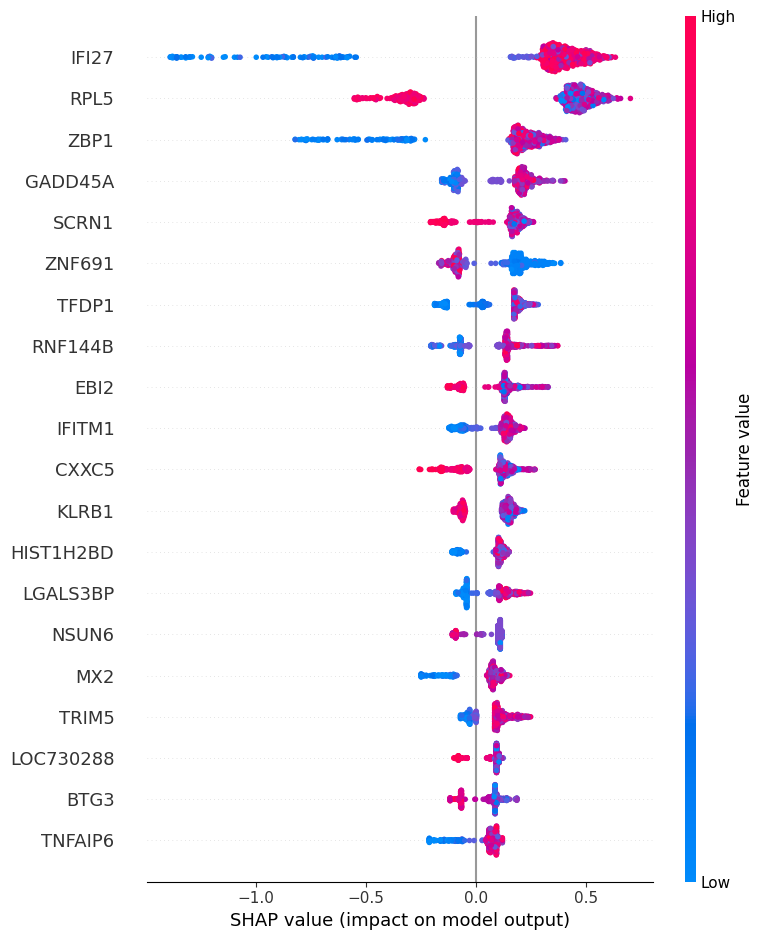

In [39]:

# SHAP summary plot
# Training data only


shap.summary_plot(
    shap_values,
    X_train_10000_scaled,
    feature_names=X_train_10000.columns,
    max_display=20
)

In [40]:

# Rank genes by mean absolute SHAP importance
# Training data only


shap_importance = np.abs(shap_matrix).mean(axis=0)

shap_df = pd.DataFrame({
    "Gene": X_train_10000.columns,
    "Importance": shap_importance
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

# Candidate SHAP genes
SHAP_TOP_N = 20

top_shap_genes = shap_df.head(SHAP_TOP_N)["Gene"].tolist()

print(f"Top {SHAP_TOP_N} SHAP-ranked genes:")
print(top_shap_genes)

print("\nTop 20 SHAP importance:")
print(shap_df.head(20))

Top 20 SHAP-ranked genes:
['IFI27', 'RPL5', 'ZBP1', 'GADD45A', 'SCRN1', 'ZNF691', 'TFDP1', 'RNF144B', 'EBI2', 'IFITM1', 'CXXC5', 'KLRB1', 'HIST1H2BD', 'LGALS3BP', 'NSUN6', 'MX2', 'TRIM5', 'LOC730288', 'BTG3', 'TNFAIP6']

Top 20 SHAP importance:
         Gene  Importance
0       IFI27    0.467653
1        RPL5    0.442974
2        ZBP1    0.275609
3     GADD45A    0.177719
4       SCRN1    0.172325
5      ZNF691    0.162504
6       TFDP1    0.160935
7     RNF144B    0.137571
8        EBI2    0.131015
9      IFITM1    0.127291
10      CXXC5    0.126450
11      KLRB1    0.125251
12  HIST1H2BD    0.108562
13   LGALS3BP    0.108537
14      NSUN6    0.100920
15        MX2    0.097671
16      TRIM5    0.093932
17  LOC730288    0.089344
18       BTG3    0.085651
19    TNFAIP6    0.081937


In [41]:
# Check the exact SHAP output structure

print("SHAP type:", type(shap_values))

if isinstance(shap_values, list):
    print("SHAP is a list")
    print("Number of arrays:", len(shap_values))
    print("Shape of class 0:", shap_values[0].shape)
    print("Shape of class 1:", shap_values[1].shape)

    shap_matrix_check = shap_values[1]

else:
    print("SHAP is an array")
    print("SHAP shape:", shap_values.shape)

    shap_matrix_check = shap_values

print("\nTraining matrix shape:", X_train_10000_scaled.shape)
print("Number of genes:", len(X_train_10000.columns))

assert shap_matrix_check.shape[1] == len(X_train_10000.columns)

SHAP type: <class 'numpy.ndarray'>
SHAP is an array
SHAP shape: (648, 10000)

Training matrix shape: (648, 10000)
Number of genes: 10000


In [42]:
shap_importance_check = np.abs(shap_matrix_check).mean(axis=0)

shap_df_check = pd.DataFrame({
    "Gene": X_train_10000.columns,
    "Importance": shap_importance_check
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print(shap_df_check.head(20).to_string(index=False))

     Gene  Importance
    IFI27    0.467653
     RPL5    0.442974
     ZBP1    0.275609
  GADD45A    0.177719
    SCRN1    0.172325
   ZNF691    0.162504
    TFDP1    0.160935
  RNF144B    0.137571
     EBI2    0.131015
   IFITM1    0.127291
    CXXC5    0.126450
    KLRB1    0.125251
HIST1H2BD    0.108562
 LGALS3BP    0.108537
    NSUN6    0.100920
      MX2    0.097671
    TRIM5    0.093932
LOC730288    0.089344
     BTG3    0.085651
  TNFAIP6    0.081937


In [43]:

# Random Forest feature importance
# Training data only


rf_selector = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_selector.fit(
    X_train_10000_scaled,
    y_train
)

rf_importance = pd.Series(
    rf_selector.feature_importances_,
    index=X_train_10000.columns,
    name="rf_importance"
).sort_values(ascending=False)

print("Top 20 Random Forest-ranked genes:")
print(rf_importance.head(20))

Top 20 Random Forest-ranked genes:
IFITM1     0.013450
MX1        0.012269
IFI27      0.010839
SHISA5     0.010561
IFI44      0.009244
EIF2AK2    0.009219
RPL5       0.008878
EPSTI1     0.008554
OAS1       0.008347
IFIT5      0.007954
DDX60      0.007852
LY6E       0.007556
IFI44L     0.007474
HERC6      0.007353
PARP9      0.007109
ZBP1       0.007012
TNFAIP6    0.006994
SP110      0.006839
RSAD2      0.006667
SP100      0.006550
Name: rf_importance, dtype: float64


In [44]:

# LASSO logistic regression feature selection
# Training data only


from sklearn.linear_model import LogisticRegression

lasso_selector = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

lasso_selector.fit(
    X_train_10000_scaled,
    y_train
)

lasso_coef = pd.Series(
    np.abs(lasso_selector.coef_[0]),
    index=X_train_10000.columns,
    name="lasso_importance"
).sort_values(
    ascending=False
)

# Genes with non-zero LASSO coefficients
lasso_selected = lasso_coef[lasso_coef > 0]

print("Number of genes selected by LASSO:",
      len(lasso_selected))

print("\nTop 20 LASSO-ranked genes:")
print(lasso_selected.head(20))

Number of genes selected by LASSO: 61

Top 20 LASSO-ranked genes:
IFI27           0.792628
MT1F            0.315037
ZDHHC1          0.282144
CLECL1          0.277035
AP3S1           0.267456
IL4             0.242615
LOC644619       0.231236
CRIP2           0.228750
OSBPL10         0.220900
LOC644033       0.171370
DEFA1           0.165193
TRA2A           0.137774
FAM72B          0.121883
LOC728572       0.120092
LOC100128498    0.111793
KIAA1715        0.111246
LOC100131452    0.105629
PTGDR           0.092623
RSBN1           0.090805
MAP7            0.089121
Name: lasso_importance, dtype: float64


In [45]:

# Consensus biomarker selection across four methods


TOP_K = 100

# XGBoost top-K
xgb_top = set(
    xgb_importance.head(TOP_K).index
)

# SHAP top-K
shap_top = set(
    shap_df.head(TOP_K)["Gene"]
)

# Random Forest top-K
rf_top = set(
    rf_importance.head(TOP_K).index
)

# LASSO-selected genes
lasso_selected_genes = set(
    lasso_selected.index
)

# All candidate genes
all_genes = X_train_10000.columns

consensus_df = pd.DataFrame(index=all_genes)

# Explicit selection indicators
consensus_df["XGBoost_selected"] = [
    gene in xgb_top for gene in all_genes
]

consensus_df["SHAP_selected"] = [
    gene in shap_top for gene in all_genes
]

consensus_df["RF_selected"] = [
    gene in rf_top for gene in all_genes
]

consensus_df["LASSO_selected"] = [
    gene in lasso_selected_genes for gene in all_genes
]

# Number of methods selecting each gene
consensus_df["methods_selected"] = (
    consensus_df[
        [
            "XGBoost_selected",
            "SHAP_selected",
            "RF_selected",
            "LASSO_selected"
        ]
    ].sum(axis=1)
)

# ------------------------------------------------------------
# Add ranks only where meaningful
# ------------------------------------------------------------

xgb_rank = xgb_importance.rank(
    method="first",
    ascending=False
)

shap_rank = (
    shap_df
    .set_index("Gene")
    .rank(
        method="first",
        ascending=False
    )
    .iloc[:, 0]
)

rf_rank = rf_importance.rank(
    method="first",
    ascending=False
)

consensus_df["XGBoost_rank"] = xgb_rank
consensus_df["SHAP_rank"] = shap_rank
consensus_df["RF_rank"] = rf_rank

# Mean rank across tree/SHAP methods
consensus_df["mean_rank"] = consensus_df[
    ["XGBoost_rank", "SHAP_rank", "RF_rank"]
].mean(axis=1)

# Prioritize number of independent methods,
# then mean rank
consensus_df = consensus_df.sort_values(
    ["methods_selected", "mean_rank"],
    ascending=[False, True]
)

print("Top consensus candidates:")
print(consensus_df.head(30))

Top consensus candidates:
           XGBoost_selected  SHAP_selected  RF_selected  LASSO_selected  \
IFI27                  True           True         True            True   
MX2                    True           True         True            True   
ZBP1                   True           True         True           False   
RPL5                   True           True         True           False   
TNFAIP6                True           True         True           False   
IFITM1                 True           True         True           False   
IFFO2                  True           True         True           False   
EPSTI1                 True           True         True           False   
TDRD7                  True           True         True           False   
TRIM5                  True           True         True           False   
KLRB1                  True           True         True           False   
C16orf57               True           True         True           False   

In [46]:

# Stability-selection framework
# Training/development cohort only


from sklearn.model_selection import StratifiedKFold

N_SPLITS = 5
N_REPEATS = 3
RANDOM_STATE = 42

cv_splits = []

for repeat in range(N_REPEATS):

    cv = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE + repeat
    )

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(X_train_10000, y_train)
    ):

        cv_splits.append({
            "repeat": repeat + 1,
            "fold": fold + 1,
            "train_idx": train_idx,
            "val_idx": val_idx
        })

print("Total CV folds:", len(cv_splits))

for split in cv_splits[:5]:
    print(
        f"Repeat {split['repeat']}, "
        f"Fold {split['fold']}: "
        f"train={len(split['train_idx'])}, "
        f"validation={len(split['val_idx'])}"
    )

Total CV folds: 15
Repeat 1, Fold 1: train=518, validation=130
Repeat 1, Fold 2: train=518, validation=130
Repeat 1, Fold 3: train=518, validation=130
Repeat 1, Fold 4: train=519, validation=129
Repeat 1, Fold 5: train=519, validation=129


In [47]:

# Check subject structure within the training/development set


train_metadata = sample_metadata.loc[X_train_10000.index].copy()

print("Training samples:", len(train_metadata))
print("Training subjects:", train_metadata["subject"].nunique())

print("\nSamples per subject:")
print(train_metadata["subject"].value_counts().describe())

print("\nDisease distribution by subject:")
subject_disease = (
    train_metadata
    .groupby("subject")["disease_state"]
    .first()
)

print(subject_disease.value_counts())

Training samples: 648
Training subjects: 136

Samples per subject:
count    136.000000
mean       4.764706
std        4.536658
min        1.000000
25%        1.000000
50%        3.000000
75%        7.000000
max       21.000000
Name: count, dtype: float64

Disease distribution by subject:
disease_state
sle        106
healthy     30
Name: count, dtype: int64


In [48]:

# Subject-aware, stratified cross-validation
# Development/training cohort only


from sklearn.model_selection import StratifiedGroupKFold

N_SPLITS = 5
N_REPEATS = 3
RANDOM_STATE = 42

train_metadata = sample_metadata.loc[X_train_10000.index].copy()

groups = train_metadata["subject"].values
y_train_array = y_train.values

cv_splits = []

for repeat in range(N_REPEATS):

    cv = StratifiedGroupKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE + repeat
    )

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(
            X_train_10000,
            y_train_array,
            groups=groups
        )
    ):

        # Verify subject independence
        train_subjects = set(groups[train_idx])
        val_subjects = set(groups[val_idx])

        assert train_subjects.isdisjoint(val_subjects), \
            "Subject overlap detected between CV train and validation."

        cv_splits.append({
            "repeat": repeat + 1,
            "fold": fold + 1,
            "train_idx": train_idx,
            "val_idx": val_idx
        })

print("Total CV folds:", len(cv_splits))

for split in cv_splits[:5]:

    train_idx = split["train_idx"]
    val_idx = split["val_idx"]

    print(
        f"Repeat {split['repeat']}, "
        f"Fold {split['fold']}: "
        f"train={len(train_idx)}, "
        f"validation={len(val_idx)}, "
        f"train subjects={len(set(groups[train_idx]))}, "
        f"validation subjects={len(set(groups[val_idx]))}"
    )

print("\n✓ Subject-disjoint CV splits created.")

Total CV folds: 15
Repeat 1, Fold 1: train=477, validation=171, train subjects=109, validation subjects=27
Repeat 1, Fold 2: train=514, validation=134, train subjects=110, validation subjects=26
Repeat 1, Fold 3: train=555, validation=93, train subjects=109, validation subjects=27
Repeat 1, Fold 4: train=489, validation=159, train subjects=108, validation subjects=28
Repeat 1, Fold 5: train=557, validation=91, train subjects=108, validation subjects=28

✓ Subject-disjoint CV splits created.


In [49]:

# FAST subject-aware stability selection
# Candidate genes = union of top 100 from existing methods


from collections import defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

N_TOP = 100


# Build a reduced candidate gene set from existing rankings


candidate_genes = set(
    xgb_importance.head(N_TOP).index
).union(
    set(shap_df.head(N_TOP)["Gene"])
).union(
    set(rf_importance.head(N_TOP).index)
).union(
    set(lasso_selected.head(N_TOP).index)
)

candidate_genes = [
    gene for gene in X_train_10000.columns
    if gene in candidate_genes
]

print("Candidate genes for stability analysis:", len(candidate_genes))

X_stability = X_train_10000.loc[:, candidate_genes]


# Selection counters


selection_counts = {
    "XGBoost": defaultdict(int),
    "SHAP": defaultdict(int),
    "Random Forest": defaultdict(int),
    "LASSO": defaultdict(int)
}

# Use only 5 folds for the fast stability pass
# rather than 15 repeated folds
stability_splits = cv_splits[:5]

for split_num, split in enumerate(stability_splits, start=1):

    train_idx = split["train_idx"]

    X_cv = X_stability.iloc[train_idx]
    y_cv = y_train.iloc[train_idx]

    print(
        f"Fold {split_num}/5 | "
        f"n={len(train_idx)}"
    )


    # XGBoost


    xgb_cv = XGBClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )

    xgb_cv.fit(X_cv, y_cv)

    xgb_imp = pd.Series(
        xgb_cv.feature_importances_,
        index=candidate_genes
    ).sort_values(ascending=False)

    for gene in xgb_imp.head(20).index:
        selection_counts["XGBoost"][gene] += 1

    # --------------------------------------------------------
    # SHAP
    # --------------------------------------------------------

    explainer_cv = shap.TreeExplainer(xgb_cv)

    shap_cv = explainer_cv.shap_values(X_cv)

    if isinstance(shap_cv, list):
        shap_cv = shap_cv[1]

    shap_imp = pd.Series(
        np.abs(shap_cv).mean(axis=0),
        index=candidate_genes
    ).sort_values(ascending=False)

    for gene in shap_imp.head(20).index:
        selection_counts["SHAP"][gene] += 1

    # --------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------

    rf_cv = RandomForestClassifier(
        n_estimators=150,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf_cv.fit(X_cv, y_cv)

    rf_imp = pd.Series(
        rf_cv.feature_importances_,
        index=candidate_genes
    ).sort_values(ascending=False)

    for gene in rf_imp.head(20).index:
        selection_counts["Random Forest"][gene] += 1

    # --------------------------------------------------------
    # LASSO
    # --------------------------------------------------------

    lasso_cv = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=0.1,
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    )

    lasso_cv.fit(X_cv, y_cv)

    lasso_coef_cv = pd.Series(
        np.abs(lasso_cv.coef_[0]),
        index=candidate_genes
    )

    lasso_selected_cv = (
        lasso_coef_cv[
            lasso_coef_cv > 0
        ]
        .sort_values(ascending=False)
        .head(20)
    )

    for gene in lasso_selected_cv.index:
        selection_counts["LASSO"][gene] += 1

print("\n✓ Fast stability selection completed.")

Candidate genes for stability analysis: 256
Fold 1/5 | n=477
Fold 2/5 | n=514
Fold 3/5 | n=555
Fold 4/5 | n=489
Fold 5/5 | n=557

✓ Fast stability selection completed.


In [50]:

# Summarize stability-selection frequencies


stability_df = pd.DataFrame({
    method: pd.Series(counts)
    for method, counts in selection_counts.items()
}).fillna(0)

# Number of methods selecting each gene
stability_df["methods_selected"] = (
    stability_df > 0
).sum(axis=1)

# Total number of folds in which each gene was selected
stability_df["total_selections"] = (
    stability_df[
        ["XGBoost", "SHAP", "Random Forest", "LASSO"]
    ].sum(axis=1)
)

# Maximum possible = 5 folds × 4 methods = 20
stability_df["selection_frequency"] = (
    stability_df["total_selections"] / 20
)

stability_df = stability_df.sort_values(
    ["methods_selected", "selection_frequency"],
    ascending=[False, False]
)

print("Top stable candidate genes:")
print(stability_df.head(30))

Top stable candidate genes:
              XGBoost  SHAP  Random Forest  LASSO  methods_selected  \
IFI27             5.0   5.0            4.0    5.0                 4   
EPSTI1            3.0   1.0            4.0    1.0                 4   
RPL5              5.0   5.0            4.0    0.0                 3   
ZBP1              4.0   4.0            5.0    0.0                 3   
IFITM1            3.0   3.0            5.0    0.0                 3   
EBI2              4.0   3.0            1.0    0.0                 3   
FCER1A            3.0   2.0            0.0    2.0                 3   
GADD45A           3.0   3.0            1.0    0.0                 3   
LOC653314         3.0   3.0            1.0    0.0                 3   
TNFSF13B          1.0   1.0            5.0    0.0                 3   
IFIT2             1.0   1.0            4.0    0.0                 3   
OSBPL10           1.0   1.0            0.0    4.0                 3   
SCRN1             0.0   4.0            1.0    1.0

In [51]:

# Remove poorly characterized / predicted LOC candidates
# and retain well-annotated biomarker candidates


EXCLUDE_GENES = {
    "LOC653314",
    "LOC100170939",
    "LOC728126",
}

stability_clean = stability_df.loc[
    ~stability_df.index.isin(EXCLUDE_GENES)
].copy()

# Preferred candidate pool:
# at least 3/4 methods and selection frequency >= 0.30
stable_candidates = stability_clean[
    (stability_clean["methods_selected"] >= 3) &
    (stability_clean["selection_frequency"] >= 0.30)
].copy()

stable_candidates = stable_candidates.sort_values(
    ["selection_frequency", "methods_selected"],
    ascending=[False, False]
)

print("Stable, characterized candidates:")
print(stable_candidates)

Stable, characterized candidates:
          XGBoost  SHAP  Random Forest  LASSO  methods_selected  \
IFI27         5.0   5.0            4.0    5.0                 4   
RPL5          5.0   5.0            4.0    0.0                 3   
ZBP1          4.0   4.0            5.0    0.0                 3   
IFITM1        3.0   3.0            5.0    0.0                 3   
EPSTI1        3.0   1.0            4.0    1.0                 4   
EBI2          4.0   3.0            1.0    0.0                 3   
FCER1A        3.0   2.0            0.0    2.0                 3   
GADD45A       3.0   3.0            1.0    0.0                 3   
TNFSF13B      1.0   1.0            5.0    0.0                 3   
IFIT2         1.0   1.0            4.0    0.0                 3   
OSBPL10       1.0   1.0            0.0    4.0                 3   
SCRN1         0.0   4.0            1.0    1.0                 3   
TNFAIP6       2.0   1.0            3.0    0.0                 3   

          total_selections 

In [52]:

# Candidate biomarker panels
# Based on stability-selection ranking


stable_ranked_genes = stable_candidates.index.tolist()

panel_sizes = [5, 6, 8, 10, 13]

candidate_panels = {
    f"Panel_{n}": stable_ranked_genes[:n]
    for n in panel_sizes
}

for panel_name, genes in candidate_panels.items():
    print(f"\n{panel_name} ({len(genes)} genes):")
    print(genes)


Panel_5 (5 genes):
['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1']

Panel_6 (6 genes):
['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1', 'EBI2']

Panel_8 (8 genes):
['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1', 'EBI2', 'FCER1A', 'GADD45A']

Panel_10 (10 genes):
['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1', 'EBI2', 'FCER1A', 'GADD45A', 'TNFSF13B', 'IFIT2']

Panel_13 (13 genes):
['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1', 'EBI2', 'FCER1A', 'GADD45A', 'TNFSF13B', 'IFIT2', 'OSBPL10', 'SCRN1', 'TNFAIP6']


In [53]:

# Subject-aware CV comparison of candidate biomarker panels


from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

cv_results = []

for panel_name, genes in candidate_panels.items():

    print(f"\nEvaluating {panel_name} ({len(genes)} genes)")

    X_panel = X_train_10000.loc[:, genes]

    for model_name in ["Logistic Regression", "Random Forest", "XGBoost"]:

        fold_scores = []

        for split_num, split in enumerate(cv_splits, start=1):

            train_idx = split["train_idx"]
            val_idx = split["val_idx"]

            X_tr = X_panel.iloc[train_idx]
            X_val = X_panel.iloc[val_idx]

            y_tr = y_train.iloc[train_idx]
            y_val = y_train.iloc[val_idx]

            # ------------------------------------------------
            # Fit scaler ONLY on fold-training data
            # ------------------------------------------------

            scaler_cv = StandardScaler()

            X_tr_scaled = scaler_cv.fit_transform(X_tr)
            X_val_scaled = scaler_cv.transform(X_val)

            # ------------------------------------------------
            # Model
            # ------------------------------------------------

            if model_name == "Logistic Regression":

                model = LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    solver="liblinear",
                    random_state=42
                )

            elif model_name == "Random Forest":

                model = RandomForestClassifier(
                    n_estimators=300,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1
                )

            else:

                model = XGBClassifier(
                    n_estimators=250,
                    learning_rate=0.05,
                    max_depth=3,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=42,
                    eval_metric="logloss",
                    n_jobs=-1
                )

            model.fit(X_tr_scaled, y_tr)

            # Probability of SLE = class 1
            y_prob = model.predict_proba(X_val_scaled)[:, 1]

            auc = roc_auc_score(
                y_val,
                y_prob
            )

            fold_scores.append(auc)

        cv_results.append({
            "Panel": panel_name,
            "Genes": len(genes),
            "Model": model_name,
            "Mean_AUC": np.mean(fold_scores),
            "SD_AUC": np.std(fold_scores, ddof=1),
            "Min_AUC": np.min(fold_scores),
            "Max_AUC": np.max(fold_scores)
        })

        print(
            f"{model_name}: "
            f"AUC = {np.mean(fold_scores):.4f} ± "
            f"{np.std(fold_scores, ddof=1):.4f}"
        )

cv_results_df = pd.DataFrame(cv_results)

print("\n==============================")
print("CV MODEL COMPARISON")
print("==============================")

print(
    cv_results_df.sort_values(
        "Mean_AUC",
        ascending=False
    ).to_string(index=False)
)


Evaluating Panel_5 (5 genes)
Logistic Regression: AUC = 0.9506 ± 0.0306
Random Forest: AUC = 0.9648 ± 0.0226
XGBoost: AUC = 0.9625 ± 0.0195

Evaluating Panel_6 (6 genes)
Logistic Regression: AUC = 0.9495 ± 0.0291
Random Forest: AUC = 0.9722 ± 0.0261
XGBoost: AUC = 0.9720 ± 0.0146

Evaluating Panel_8 (8 genes)
Logistic Regression: AUC = 0.9535 ± 0.0333
Random Forest: AUC = 0.9798 ± 0.0230
XGBoost: AUC = 0.9767 ± 0.0166

Evaluating Panel_10 (10 genes)
Logistic Regression: AUC = 0.9514 ± 0.0350
Random Forest: AUC = 0.9764 ± 0.0256
XGBoost: AUC = 0.9757 ± 0.0194

Evaluating Panel_13 (13 genes)
Logistic Regression: AUC = 0.9716 ± 0.0195
Random Forest: AUC = 0.9799 ± 0.0154
XGBoost: AUC = 0.9835 ± 0.0137

CV MODEL COMPARISON
   Panel  Genes               Model  Mean_AUC   SD_AUC  Min_AUC  Max_AUC
Panel_13     13             XGBoost  0.983539 0.013724 0.945312 0.998450
Panel_13     13       Random Forest  0.979903 0.015382 0.951846 1.000000
 Panel_8      8       Random Forest  0.979788 0.023

In [54]:

# Final development-stage comparison: stable 13-gene panel


final_candidate_genes = stable_candidates.index.tolist()

X_final_dev = X_train_10000.loc[:, final_candidate_genes].copy()

final_dev_results = []

for model_name in [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]:

    fold_auc = []

    for split in cv_splits:

        train_idx = split["train_idx"]
        val_idx = split["val_idx"]

        X_tr = X_final_dev.iloc[train_idx]
        X_val = X_final_dev.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        scaler = StandardScaler()

        X_tr_scaled = scaler.fit_transform(X_tr)
        X_val_scaled = scaler.transform(X_val)

        if model_name == "Logistic Regression":

            model = LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                solver="liblinear",
                random_state=42
            )

        elif model_name == "Random Forest":

            model = RandomForestClassifier(
                n_estimators=500,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )

        else:

            model = XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )

        model.fit(X_tr_scaled, y_tr)

        prob = model.predict_proba(X_val_scaled)[:, 1]

        fold_auc.append(
            roc_auc_score(y_val, prob)
        )

    final_dev_results.append({
        "Model": model_name,
        "Mean_AUC": np.mean(fold_auc),
        "SD_AUC": np.std(fold_auc, ddof=1),
        "Min_AUC": np.min(fold_auc),
        "Max_AUC": np.max(fold_auc)
    })

final_dev_results_df = pd.DataFrame(
    final_dev_results
).sort_values(
    "Mean_AUC",
    ascending=False
)

print(final_dev_results_df.to_string(index=False))

              Model  Mean_AUC   SD_AUC  Min_AUC  Max_AUC
            XGBoost  0.983487 0.012623 0.950521 0.998450
      Random Forest  0.981466 0.013505 0.955729 1.000000
Logistic Regression  0.971585 0.019469 0.926471 0.997765


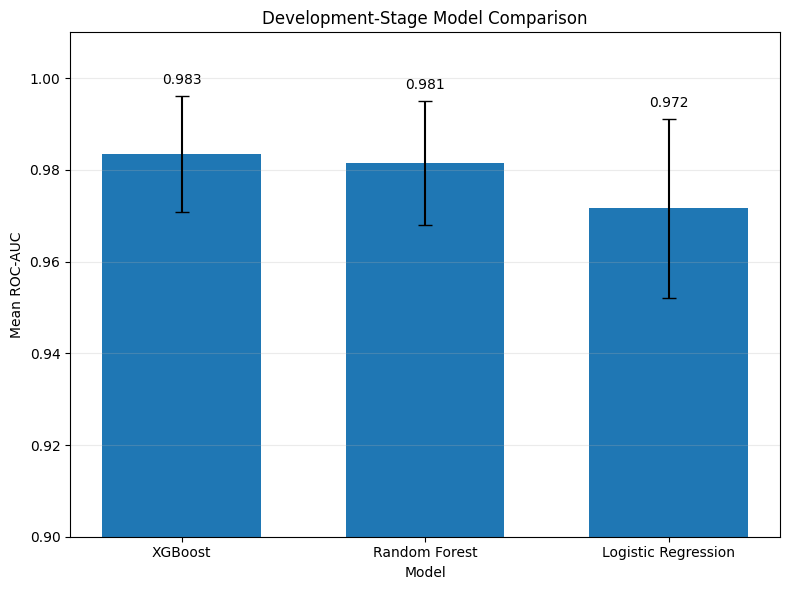

In [55]:

# MODEL COMPARISON — DEVELOPMENT OOF ROC-AUC


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Model comparison results


model_comparison = pd.DataFrame({
    "Model": [
        "XGBoost",
        "Random Forest",
        "Logistic Regression"
    ],
    "Mean_AUC": [
        0.983487,
        0.981466,
        0.971585
    ],
    "SD_AUC": [
        0.012623,
        0.013505,
        0.019469
    ]
})

# Sort by mean AUC
model_comparison = model_comparison.sort_values(
    "Mean_AUC",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

x = np.arange(len(model_comparison))

bars = plt.bar(
    x,
    model_comparison["Mean_AUC"],
    yerr=model_comparison["SD_AUC"],
    capsize=5,
    width=0.65
)

# Mean AUC labels
for i, (mean_auc, sd_auc) in enumerate(
    zip(
        model_comparison["Mean_AUC"],
        model_comparison["SD_AUC"]
    )
):
    plt.text(
        i,
        mean_auc + sd_auc + 0.002,
        f"{mean_auc:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xticks(
    x,
    model_comparison["Model"]
)

plt.ylabel("Mean ROC-AUC")
plt.xlabel("Model")
plt.title(
    "Development-Stage Model Comparison"
)

# Important because all AUCs are high
plt.ylim(
    0.90,
    1.01
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()

In [56]:

# FINAL DEVELOPMENT MODEL
# 13-gene stable biomarker panel + XGBoost


FINAL_GENES = stable_candidates.index.tolist()

print("Final gene count:", len(FINAL_GENES))
print("Final genes:")
for gene in FINAL_GENES:
    print(gene)

# Development data
X_final_train = X_train_10000.loc[:, FINAL_GENES].copy()

# Locked test data — DO NOT FIT anything on this
X_final_test = X_test_10000.loc[:, FINAL_GENES].copy()

print("\nDevelopment matrix:", X_final_train.shape)
print("Locked test matrix:", X_final_test.shape)


# Fit scaler ONLY on the 648 development samples


final_scaler = StandardScaler()

X_final_train_scaled = final_scaler.fit_transform(
    X_final_train
)

X_final_test_scaled = final_scaler.transform(
    X_final_test
)


# Final XGBoost model


final_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

final_xgb.fit(
    X_final_train_scaled,
    y_train
)

print("\n✓ Final XGBoost model fitted.")
print("Training samples:", X_final_train_scaled.shape[0])
print("Final features:", X_final_train_scaled.shape[1])

Final gene count: 13
Final genes:
IFI27
RPL5
ZBP1
IFITM1
EPSTI1
EBI2
FCER1A
GADD45A
TNFSF13B
IFIT2
OSBPL10
SCRN1
TNFAIP6

Development matrix: (648, 13)
Locked test matrix: (322, 13)

✓ Final XGBoost model fitted.
Training samples: 648
Final features: 13


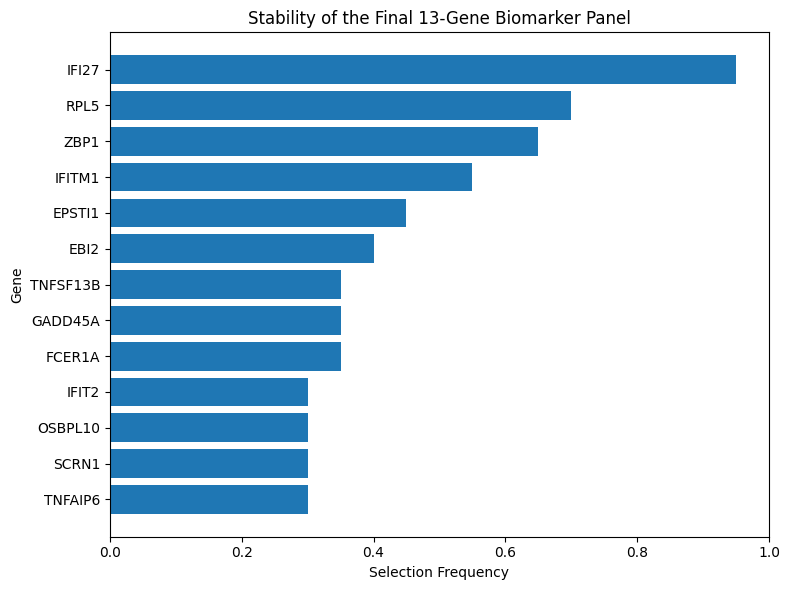

In [57]:

# FIGURE: FINAL 13-GENE STABILITY PANEL


panel_df = stability_df.loc[
    FINAL_GENES,
    ["selection_frequency"]
].copy()

panel_df = panel_df.sort_values(
    "selection_frequency",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    panel_df.index,
    panel_df["selection_frequency"]
)

plt.xlabel("Selection Frequency")
plt.ylabel("Gene")
plt.title("Stability of the Final 13-Gene Biomarker Panel")
plt.xlim(0, 1.0)

plt.tight_layout()
plt.show()

FINAL 13-GENE PANEL
    Gene  Selection_Frequency
   IFI27                 0.95
    RPL5                 0.70
    ZBP1                 0.65
  IFITM1                 0.55
  EPSTI1                 0.45
    EBI2                 0.40
  FCER1A                 0.35
 GADD45A                 0.35
TNFSF13B                 0.35
   IFIT2                 0.30
 OSBPL10                 0.30
   SCRN1                 0.30
 TNFAIP6                 0.30


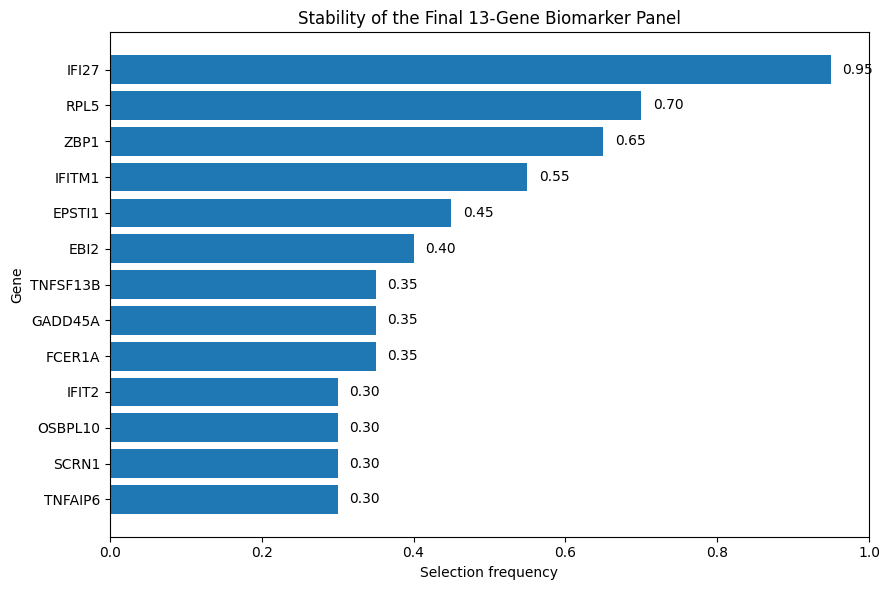

In [58]:

# FINAL 13-GENE BIOMARKER PANEL
# Stability-selection frequency


import matplotlib.pyplot as plt
import pandas as pd

# Use the final genes in the locked order
panel_frequency = pd.DataFrame({
    "Gene": FINAL_GENES,
    "Selection_Frequency": [
        stability_df.loc[g, "selection_frequency"]
        for g in FINAL_GENES
    ]
})

# Sort for plotting
panel_plot = panel_frequency.sort_values(
    "Selection_Frequency",
    ascending=True
)

print("FINAL 13-GENE PANEL")
print("=" * 50)
print(panel_frequency.to_string(index=False))

plt.figure(figsize=(9, 6))

plt.barh(
    panel_plot["Gene"],
    panel_plot["Selection_Frequency"]
)

plt.xlabel("Selection frequency")
plt.ylabel("Gene")
plt.title(
    "Stability of the Final 13-Gene Biomarker Panel"
)

plt.xlim(0, 1.0)

# Add frequency labels
for i, value in enumerate(
    panel_plot["Selection_Frequency"]
):
    plt.text(
        value + 0.015,
        i,
        f"{value:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [59]:

# FINAL DEVELOPMENT OOF PROBABILITIES
# SUBJECT-AWARE CV
# 13-GENE PANEL
# FOR FINAL THRESHOLD SELECTION


from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

# Final 13-gene development data


X_dev_13 = X_train_10000.loc[:, FINAL_GENES].copy()
y_dev = y_train.copy()

print("Development samples:", len(X_dev_13))
print("Final genes:", len(FINAL_GENES))
print("Genes:")
print(FINAL_GENES)

assert len(FINAL_GENES) == 13
assert X_dev_13.shape[1] == 13

# ------------------------------------------------------------
# OOF probability containers
# ------------------------------------------------------------

oof = {
    "Logistic Regression": np.full(
        len(y_dev),
        np.nan
    ),

    "Random Forest": np.full(
        len(y_dev),
        np.nan
    ),

    "XGBoost": np.full(
        len(y_dev),
        np.nan
    )
}

# ------------------------------------------------------------
# IMPORTANT:
# XGBoost specification MUST MATCH final_xgb
# ------------------------------------------------------------

base_models = {

    "Logistic Regression": LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=5000,
        solver="liblinear",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

# ------------------------------------------------------------
# Verify XGBoost matches final_xgb
# ------------------------------------------------------------

xgb_oof = base_models["XGBoost"]

print("\n" + "=" * 80)
print("XGBOOST SPECIFICATION CHECK")
print("=" * 80)

params_to_check = [
    "n_estimators",
    "learning_rate",
    "max_depth",
    "subsample",
    "colsample_bytree",
    "random_state",
    "eval_metric"
]

for param in params_to_check:

    oof_value = xgb_oof.get_params().get(param)
    final_value = final_xgb.get_params().get(param)

    print(
        f"{param:<20} "
        f"OOF={oof_value} | "
        f"FINAL={final_value} | "
        f"{'MATCH' if oof_value == final_value else 'MISMATCH'}"
    )

    assert oof_value == final_value, (
        f"XGBoost parameter mismatch: {param}"
    )

print("\nXGBoost specification matches final_xgb.")

# ------------------------------------------------------------
# Subject-aware OOF prediction
# ------------------------------------------------------------

for model_name, base_model in base_models.items():

    print(
        f"\nGenerating OOF predictions: "
        f"{model_name}"
    )

    for fold_num, split in enumerate(
        cv_splits,
        start=1
    ):

        train_idx = split["train_idx"]
        val_idx = split["val_idx"]

        X_tr = X_dev_13.iloc[train_idx]
        X_val = X_dev_13.iloc[val_idx]

        y_tr = y_dev.iloc[train_idx]

        # ----------------------------------------------------
        # Fold-specific scaling
        # ----------------------------------------------------

        scaler = StandardScaler()

        X_tr_scaled = scaler.fit_transform(
            X_tr
        )

        X_val_scaled = scaler.transform(
            X_val
        )

        # ----------------------------------------------------
        # Clone model
        # ----------------------------------------------------

        model = clone(base_model)

        model.fit(
            X_tr_scaled,
            y_tr
        )

        # ----------------------------------------------------
        # OOF prediction
        # ----------------------------------------------------

        oof[model_name][val_idx] = (
            model.predict_proba(
                X_val_scaled
            )[:, 1]
        )

        print(
            f"Fold {fold_num}: "
            f"train={len(train_idx)}, "
            f"validation={len(val_idx)}"
        )

    # --------------------------------------------------------
    # Verify complete OOF coverage
    # --------------------------------------------------------

    n_predictions = np.sum(
        ~np.isnan(
            oof[model_name]
        )
    )

    print(
        f"OOF predictions: "
        f"{n_predictions} / {len(y_dev)}"
    )

    assert n_predictions == len(y_dev)

# ------------------------------------------------------------
# Final OOF verification
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL OOF VERIFICATION")
print("=" * 80)

for model_name, probs in oof.items():

    assert np.all(
        np.isfinite(probs)
    )

    assert np.all(
        probs >= 0
    )

    assert np.all(
        probs <= 1
    )

    print(
        f"{model_name:<25}: "
        f"{len(probs)} complete probabilities"
    )

print("\nOOF probability generation complete.")
print("XGBoost OOF model matches final_xgb specification.")

Development samples: 648
Final genes: 13
Genes:
['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1', 'EBI2', 'FCER1A', 'GADD45A', 'TNFSF13B', 'IFIT2', 'OSBPL10', 'SCRN1', 'TNFAIP6']

XGBOOST SPECIFICATION CHECK
n_estimators         OOF=300 | FINAL=300 | MATCH
learning_rate        OOF=0.05 | FINAL=0.05 | MATCH
max_depth            OOF=3 | FINAL=3 | MATCH
subsample            OOF=0.8 | FINAL=0.8 | MATCH
colsample_bytree     OOF=0.8 | FINAL=0.8 | MATCH
random_state         OOF=42 | FINAL=42 | MATCH
eval_metric          OOF=logloss | FINAL=logloss | MATCH

XGBoost specification matches final_xgb.

Generating OOF predictions: Logistic Regression
Fold 1: train=477, validation=171
Fold 2: train=514, validation=134
Fold 3: train=555, validation=93
Fold 4: train=489, validation=159
Fold 5: train=557, validation=91
Fold 6: train=544, validation=104
Fold 7: train=552, validation=96
Fold 8: train=527, validation=121
Fold 9: train=505, validation=143
Fold 10: train=464, validation=184
Fold 11: train=515, 

In [60]:

# DEVELOPMENT-ONLY OOF THRESHOLD OPTIMIZATION


from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    brier_score_loss
)

threshold_results = []

for model_name, probs in oof.items():

    # --------------------------------------------------------
    # ROC-based threshold selection
    # --------------------------------------------------------

    fpr, tpr, thresholds = roc_curve(
        y_dev,
        probs
    )

    youden_j = tpr - fpr

    # Ignore infinite threshold
    valid = np.isfinite(thresholds)

    best_idx = np.argmax(
        np.where(valid, youden_j, -np.inf)
    )

    best_threshold = thresholds[best_idx]

    # --------------------------------------------------------
    # Classification at development-derived threshold
    # --------------------------------------------------------

    pred = (
        probs >= best_threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_dev,
        pred
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    threshold_results.append({
        "Model": model_name,
        "Threshold": best_threshold,
        "ROC_AUC": roc_auc_score(y_dev, probs),
        "PR_AUC": average_precision_score(y_dev, probs),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Balanced_Accuracy":
            balanced_accuracy_score(y_dev, pred),
        "Accuracy":
            accuracy_score(y_dev, pred),
        "PPV":
            precision_score(y_dev, pred),
        "NPV":
            tn / (tn + fn),
        "F1":
            f1_score(y_dev, pred),
        "Brier":
            brier_score_loss(y_dev, probs),
        "Youden_J":
            youden_j[best_idx],
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

threshold_comparison = pd.DataFrame(
    threshold_results
)

print("=" * 90)
print("DEVELOPMENT-ONLY OOF THRESHOLD COMPARISON")
print("=" * 90)

print(
    threshold_comparison
    .sort_values("Youden_J", ascending=False)
    .round(4)
    .to_string(index=False)
)

DEVELOPMENT-ONLY OOF THRESHOLD COMPARISON
              Model  Threshold  ROC_AUC  PR_AUC  Sensitivity  Specificity  Balanced_Accuracy  Accuracy    PPV    NPV     F1  Brier  Youden_J  TN  FP  FN  TP
            XGBoost     0.9554   0.9859  0.9993       0.9531       0.9667             0.9599    0.9537 0.9983 0.5000 0.9752 0.0202    0.9197  29   1  29 589
      Random Forest     0.9360   0.9818  0.9991       0.9288       0.9667             0.9477    0.9306 0.9983 0.3973 0.9623 0.0210    0.8955  29   1  44 574
Logistic Regression     0.5959   0.9759  0.9988       0.9078       0.9667             0.9372    0.9105 0.9982 0.3372 0.9508 0.0559    0.8744  29   1  57 561


In [61]:

# DEVELOPMENT-ONLY REGULARIZED LOGISTIC REGRESSION
# SUBJECT-AWARE OOF


from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

X_dev_13 = X_train_10000[FINAL_GENES].copy()
y_dev = y_train.copy()

# Test several regularization strengths
C_VALUES = [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]

lr_oof_results = []

for C in C_VALUES:

    print(f"\nTesting Logistic Regression C={C}")

    probs = np.full(len(y_dev), np.nan)

    for split in cv_splits:

        train_idx = split["train_idx"]
        val_idx = split["val_idx"]

        model = LogisticRegression(
            penalty="l2",
            C=C,
            class_weight="balanced",
            solver="liblinear",
            max_iter=5000,
            random_state=42
        )

        model.fit(
            X_dev_13.iloc[train_idx],
            y_dev.iloc[train_idx]
        )

        probs[val_idx] = model.predict_proba(
            X_dev_13.iloc[val_idx]
        )[:, 1]

    # --------------------------------------------------------
    # OOF discrimination
    # --------------------------------------------------------

    auc = roc_auc_score(y_dev, probs)
    pr_auc = average_precision_score(y_dev, probs)
    brier = brier_score_loss(y_dev, probs)

    # --------------------------------------------------------
    # Development-only Youden threshold
    # --------------------------------------------------------

    fpr, tpr, thresholds = roc_curve(
        y_dev,
        probs
    )

    youden = tpr - fpr

    valid = np.isfinite(thresholds)

    best_idx = np.argmax(
        np.where(valid, youden, -np.inf)
    )

    threshold = thresholds[best_idx]

    pred = (
        probs >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_dev,
        pred
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    lr_oof_results.append({
        "C": C,
        "AUC": auc,
        "PR_AUC": pr_auc,
        "Brier": brier,
        "Threshold": threshold,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Balanced_Accuracy":
            balanced_accuracy_score(y_dev, pred),
        "Accuracy":
            accuracy_score(y_dev, pred),
        "PPV":
            precision_score(y_dev, pred),
        "F1":
            f1_score(y_dev, pred),
        "Youden_J":
            youden[best_idx]
    })

lr_oof_results = pd.DataFrame(lr_oof_results)

print("\n" + "=" * 90)
print("REGULARIZED LOGISTIC REGRESSION — DEVELOPMENT OOF")
print("=" * 90)

print(
    lr_oof_results
    .sort_values("Youden_J", ascending=False)
    .round(4)
    .to_string(index=False)
)


Testing Logistic Regression C=0.001

Testing Logistic Regression C=0.01

Testing Logistic Regression C=0.05

Testing Logistic Regression C=0.1

Testing Logistic Regression C=0.25

Testing Logistic Regression C=0.5

Testing Logistic Regression C=1.0

Testing Logistic Regression C=2.0

REGULARIZED LOGISTIC REGRESSION — DEVELOPMENT OOF
    C    AUC  PR_AUC  Brier  Threshold  Sensitivity  Specificity  Balanced_Accuracy  Accuracy    PPV     F1  Youden_J
0.100 0.9787  0.9989 0.0550     0.3372       0.9450       0.9333             0.9392    0.9444 0.9966 0.9701    0.8783
0.500 0.9766  0.9988 0.0496     0.4008       0.9450       0.9333             0.9392    0.9444 0.9966 0.9701    0.8783
1.000 0.9742  0.9986 0.0479     0.4037       0.9450       0.9333             0.9392    0.9444 0.9966 0.9701    0.8783
0.250 0.9779  0.9989 0.0517     0.3740       0.9417       0.9333             0.9375    0.9414 0.9966 0.9684    0.8751
0.050 0.9776  0.9989 0.0584     0.5425       0.9078       0.9667          

In [62]:

# FINAL DEVELOPMENT MODEL SELECTION
# SPECIFICITY REQUIREMENT: >= 95%


candidate_rows = threshold_comparison.copy()

# ------------------------------------------------------------
# Add regularized Logistic Regression results
# ------------------------------------------------------------

lr_candidates = lr_oof_results.copy()

lr_candidates = lr_candidates.rename(
    columns={
        "AUC": "ROC_AUC"
    }
)

lr_candidates["Model"] = (
    "Logistic Regression (C=" +
    lr_candidates["C"].astype(str) +
    ")"
)

# ------------------------------------------------------------
# Keep matching columns
# ------------------------------------------------------------

required_columns = [
    "Model",
    "Threshold",
    "ROC_AUC",
    "PR_AUC",
    "Sensitivity",
    "Specificity",
    "Balanced_Accuracy",
    "Accuracy",
    "PPV",
    "F1",
    "Brier",
    "Youden_J"
]

lr_candidates = lr_candidates[
    required_columns
]

candidate_rows = candidate_rows[
    required_columns
]

all_candidates = pd.concat(
    [
        candidate_rows,
        lr_candidates
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# Require specificity >= 95%
# ------------------------------------------------------------

high_specificity = (
    all_candidates[
        all_candidates["Specificity"] >= 0.95
    ]
    .sort_values(
        ["ROC_AUC", "Sensitivity"],
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 90)
print("FINAL DEVELOPMENT CANDIDATES")
print("SPECIFICITY >= 95%")
print("=" * 90)

print(
    high_specificity
    .round(4)
    .to_string(index=False)
)

# ------------------------------------------------------------
# Identify best candidate
# ------------------------------------------------------------

best_candidate = high_specificity.iloc[0]

print("\n" + "=" * 90)
print("SELECTED FINAL MODEL")
print("=" * 90)

print(
    "Model:",
    best_candidate["Model"]
)

print(
    "Threshold:",
    best_candidate["Threshold"]
)

print(
    "ROC-AUC:",
    best_candidate["ROC_AUC"]
)

print(
    "Sensitivity:",
    best_candidate["Sensitivity"]
)

print(
    "Specificity:",
    best_candidate["Specificity"]
)

FINAL DEVELOPMENT CANDIDATES
SPECIFICITY >= 95%
                       Model  Threshold  ROC_AUC  PR_AUC  Sensitivity  Specificity  Balanced_Accuracy  Accuracy    PPV     F1  Brier  Youden_J
                     XGBoost     0.9554   0.9859  0.9993       0.9531       0.9667             0.9599    0.9537 0.9983 0.9752 0.0202    0.9197
               Random Forest     0.9360   0.9818  0.9991       0.9288       0.9667             0.9477    0.9306 0.9983 0.9623 0.0210    0.8955
Logistic Regression (C=0.05)     0.5425   0.9776  0.9989       0.9078       0.9667             0.9372    0.9105 0.9982 0.9508 0.0584    0.8744
         Logistic Regression     0.5959   0.9759  0.9988       0.9078       0.9667             0.9372    0.9105 0.9982 0.9508 0.0559    0.8744

SELECTED FINAL MODEL
Model: XGBoost
Threshold: 0.9554371237754822
ROC-AUC: 0.9859223300970873
Sensitivity: 0.9530744336569579
Specificity: 0.9666666666666667


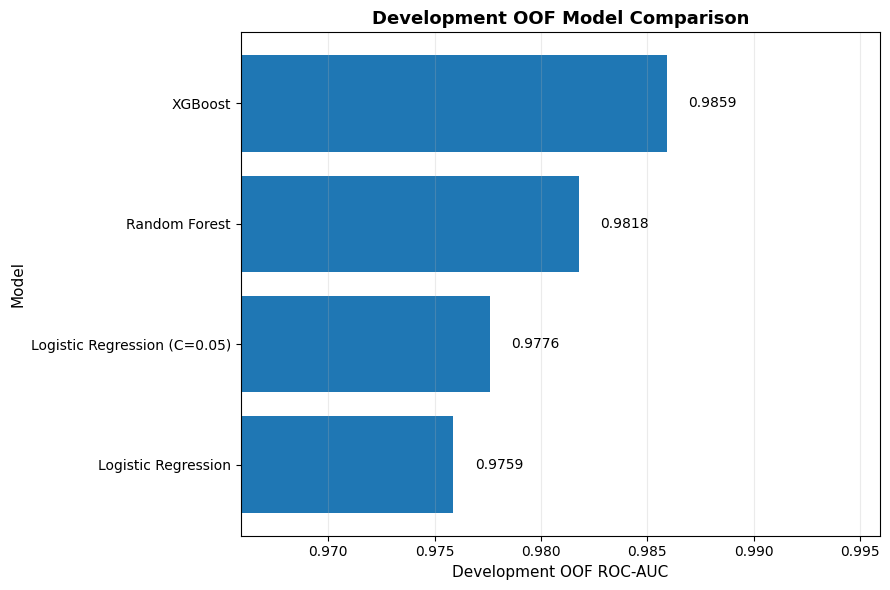


✓ Model comparison figure saved:
/content/drive/MyDrive/SLE_Final_Diagnostic_Model/Results/development_OOF_model_comparison_ROC_AUC.png


<Figure size 640x480 with 0 Axes>

In [ ]:

# DEVELOPMENT OOF MODEL COMPARISON
# FINAL DIAGNOSTIC MODEL SELECTION


import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# ------------------------------------------------------------
# Use the already calculated final development candidates
# ------------------------------------------------------------

plot_df = high_specificity.copy()

# Keep only the models needed for the final comparison
plot_df = plot_df[
    [
        "Model",
        "ROC_AUC",
        "Sensitivity",
        "Specificity"
    ]
].copy()

# ------------------------------------------------------------
# Clean model names for plotting
# ------------------------------------------------------------

plot_df["Plot_Model"] = plot_df["Model"].replace({
    "Logistic Regression (C=0.05)": "Logistic Regression (C=0.05)",
    "Logistic Regression": "Logistic Regression"
})

# ------------------------------------------------------------
# Sort by ROC-AUC
# ------------------------------------------------------------

plot_df = plot_df.sort_values(
    "ROC_AUC",
    ascending=True
).reset_index(drop=True)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

bars = plt.barh(
    plot_df["Plot_Model"],
    plot_df["ROC_AUC"]
)

# Add AUC labels
for bar, auc in zip(
    bars,
    plot_df["ROC_AUC"]
):

    plt.text(
        auc + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{auc:.4f}",
        va="center",
        fontsize=10
    )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.xlabel(
    "Development OOF ROC-AUC",
    fontsize=11
)

plt.ylabel(
    "Model",
    fontsize=11
)

plt.title(
    "Development OOF Model Comparison",
    fontsize=13,
    fontweight="bold"
)

# Since all AUCs are high, zoom appropriately
plt.xlim(
    max(0.95, plot_df["ROC_AUC"].min() - 0.01),
    min(1.0, plot_df["ROC_AUC"].max() + 0.01)
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# SAVE FIGURE
# ============================================================

RESULT_DIR = (
    "/content/drive/MyDrive/"
    "SLE_Final_Diagnostic_Model/"
    "Results"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

figure_path = os.path.join(
    RESULT_DIR,
    "development_OOF_model_comparison_ROC_AUC.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

print("\n✓ Model comparison figure saved:")
print(figure_path)

DEVELOPMENT OOF MODEL COMPARISON
              Model  ROC_AUC  PR_AUC
            XGBoost   0.9859  0.9993
      Random Forest   0.9818  0.9991
Logistic Regression   0.9759  0.9988


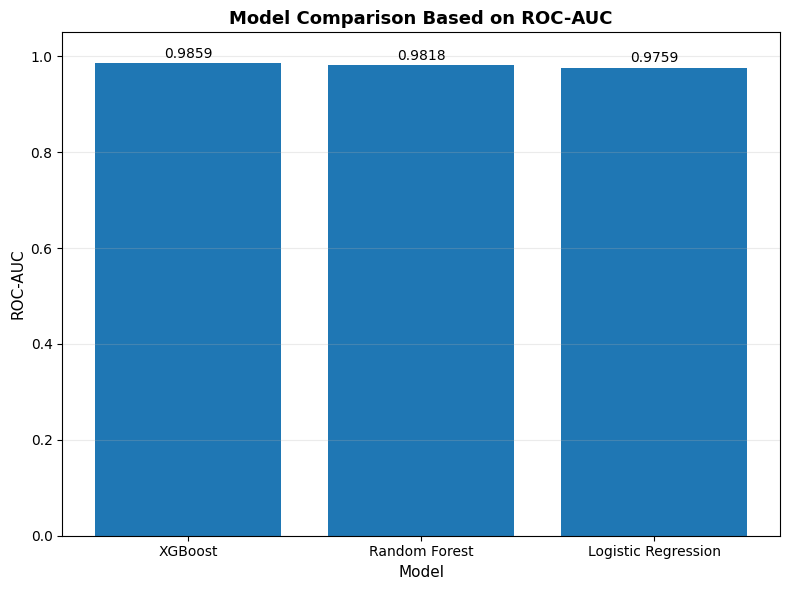


✓ Figure saved:
/content/drive/MyDrive/SLE_Final_Diagnostic_Model/Results/Figure_Model_Comparison_Based_on_ROC_AUC.png


<Figure size 640x480 with 0 Axes>

In [63]:

# DEVELOPMENT OOF MODEL COMPARISON — BAR GRAPH


import matplotlib.pyplot as plt
import pandas as pd
import os

# ------------------------------------------------------------
# Existing OOF predictions
# ------------------------------------------------------------

model_results = []

for model_name, probabilities in oof.items():

    auc = roc_auc_score(
        y_dev,
        probabilities
    )

    pr_auc = average_precision_score(
        y_dev,
        probabilities
    )

    model_results.append({
        "Model": model_name,
        "ROC_AUC": auc,
        "PR_AUC": pr_auc
    })


model_comparison_df = pd.DataFrame(
    model_results
).sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 80)
print("DEVELOPMENT OOF MODEL COMPARISON")
print("=" * 80)

print(
    model_comparison_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# BAR GRAPH — ROC-AUC
# ============================================================

plt.figure(figsize=(8, 6))

bars = plt.bar(
    model_comparison_df["Model"],
    model_comparison_df["ROC_AUC"]
)

# Add numerical AUC values above bars
for bar, value in zip(
    bars,
    model_comparison_df["ROC_AUC"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.005,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )


plt.xlabel(
    "Model",
    fontsize=11
)

plt.ylabel(
    "ROC-AUC",
    fontsize=11
)

plt.title(
    "Model Comparison Based on ROC-AUC",
    fontsize=13,
    fontweight="bold"
)

plt.ylim(
    0,
    1.05
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# SAVE FIGURE
# ============================================================

RESULT_DIR = (
    "/content/drive/MyDrive/"
    "SLE_Final_Diagnostic_Model/"
    "Results"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

figure_path = os.path.join(
    RESULT_DIR,
    "Figure_Model_Comparison_Based_on_ROC_AUC.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

print("\n✓ Figure saved:")
print(figure_path)

In [64]:

# DEVELOPMENT EXPRESSION SCALE AUDIT


print("=" * 80)
print("DEVELOPMENT EXPRESSION SCALE")
print("=" * 80)

print("\n13-gene raw development statistics:")

dev_scale = pd.DataFrame({
    "Gene": FINAL_GENES,
    "Mean": X_train_10000[FINAL_GENES].mean().values,
    "SD": X_train_10000[FINAL_GENES].std(ddof=1).values,
    "Min": X_train_10000[FINAL_GENES].min().values,
    "Median": X_train_10000[FINAL_GENES].median().values,
    "Max": X_train_10000[FINAL_GENES].max().values
})

print(
    dev_scale.round(4).to_string(index=False)
)

print("\nOverall development matrix:")
print("Shape:", X_train_10000.shape)
print("Global minimum:", X_train_10000.min().min())
print("Global maximum:", X_train_10000.max().max())
print("Global mean:", X_train_10000.values.mean())
print("Global SD:", X_train_10000.values.std())

DEVELOPMENT EXPRESSION SCALE

13-gene raw development statistics:
    Gene    Mean     SD    Min  Median     Max
   IFI27 11.9256 2.6259 3.3219 13.0073 14.8653
    RPL5 11.1727 0.6124 8.7847 11.2212 12.4458
    ZBP1  9.9676 0.9882 7.3610 10.0855 12.6270
  IFITM1 12.7044 0.6818 6.0490 12.7339 14.3366
  EPSTI1 11.1687 1.2150 6.5358 11.5813 12.9103
    EBI2  7.7115 0.8298 4.7467  7.8219  9.5519
  FCER1A  8.7712 1.0812 3.3219  8.9662 11.0018
 GADD45A  7.2557 0.6868 5.0464  7.2444  9.9916
TNFSF13B 11.3927 0.6605 9.2357 11.4530 12.9580
   IFIT2 12.5442 0.9320 9.1053 12.7434 14.3761
 OSBPL10  5.2255 0.6817 3.3219  4.9429  7.6005
   SCRN1  5.9644 0.7424 4.1616  6.0489  7.9969
 TNFAIP6  6.4888 0.4923 4.8143  6.5662  7.6471

Overall development matrix:
Shape: (648, 10000)
Global minimum: 2.31023138
Global maximum: 15.315335
Global mean: 6.52120358277848
Global SD: 2.221839839441003


In [65]:

# FINAL XGBOOST — 5,000-BOOTSTRAP CONFIDENCE INTERVALS
# LOCKED TEST SET

# No model retraining
# No threshold optimization
# Uses the already-generated locked-test probabilities


import numpy as np
import pandas as pd
import os

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    brier_score_loss
)

print("=" * 90)
print("FINAL XGBOOST — 5,000-BOOTSTRAP VALIDATION")
print("=" * 90)


# ============================================================
# 1. VERIFY EXISTING FINAL PREDICTIONS
# ============================================================

FINAL_THRESHOLD = 0.9554371237754822

# Use the already verified final model
X_test_final = X_test_10000[
    FINAL_GENES
].copy()

y_test_array = np.asarray(
    y_test
)

# Transform using the EXISTING development-fitted scaler
X_test_scaled = final_scaler.transform(
    X_test_final
)

# Generate predictions using the EXISTING final XGBoost
bootstrap_prob = final_xgb.predict_proba(
    X_test_scaled
)[:, 1]

# ------------------------------------------------------------
# Reproducibility check
# ------------------------------------------------------------

if "test_prob" in globals():

    assert np.allclose(
        bootstrap_prob,
        test_prob,
        rtol=0,
        atol=1e-12
    )

    print("\n✓ Probabilities exactly reproduce final test predictions")

assert len(y_test_array) == 322
assert len(bootstrap_prob) == 322

print("✓ Locked test samples:", len(y_test_array))
print("✓ Final genes:", len(FINAL_GENES))
print("✓ Threshold:", FINAL_THRESHOLD)
print("✓ No model retraining")
print("✓ No threshold optimization")


# ============================================================
# 2. OBSERVED LOCKED-TEST PERFORMANCE
# ============================================================

observed_pred = (
    bootstrap_prob >= FINAL_THRESHOLD
).astype(int)


observed_metrics = {

    "ROC-AUC":
        roc_auc_score(
            y_test_array,
            bootstrap_prob
        ),

    "Accuracy":
        accuracy_score(
            y_test_array,
            observed_pred
        ),

    "Balanced Accuracy":
        balanced_accuracy_score(
            y_test_array,
            observed_pred
        ),

    "Sensitivity":
        recall_score(
            y_test_array,
            observed_pred,
            pos_label=1,
            zero_division=0
        ),

    "Specificity":
        recall_score(
            y_test_array,
            observed_pred,
            pos_label=0,
            zero_division=0
        ),

    "PPV":
        precision_score(
            y_test_array,
            observed_pred,
            pos_label=1,
            zero_division=0
        ),

    "NPV":
        precision_score(
            y_test_array,
            observed_pred,
            pos_label=0,
            zero_division=0
        ),

    "F1-score":
        f1_score(
            y_test_array,
            observed_pred,
            zero_division=0
        ),

    "Brier Score":
        brier_score_loss(
            y_test_array,
            bootstrap_prob
        )
}


print("\n" + "=" * 90)
print("OBSERVED LOCKED-TEST PERFORMANCE")
print("=" * 90)

for metric, value in observed_metrics.items():

    print(
        f"{metric:<22}: {value:.6f}"
    )


# ============================================================
# 3. 5,000 BOOTSTRAP ITERATIONS
# ============================================================

N_BOOTSTRAP = 5000

rng = np.random.default_rng(
    42
)

n_samples = len(
    y_test_array
)

bootstrap_results = {

    "ROC-AUC": [],
    "Accuracy": [],
    "Balanced Accuracy": [],
    "Sensitivity": [],
    "Specificity": [],
    "PPV": [],
    "NPV": [],
    "F1-score": [],
    "Brier Score": []
}


for iteration in range(
    N_BOOTSTRAP
):

    # --------------------------------------------------------
    # Resample locked-test subjects WITH replacement
    # --------------------------------------------------------

    indices = rng.integers(
        low=0,
        high=n_samples,
        size=n_samples
    )

    y_boot = y_test_array[
        indices
    ]

    prob_boot = bootstrap_prob[
        indices
    ]

    # --------------------------------------------------------
    # AUC requires both classes
    # --------------------------------------------------------

    if len(
        np.unique(y_boot)
    ) < 2:

        continue

    pred_boot = (
        prob_boot >= FINAL_THRESHOLD
    ).astype(int)

    # --------------------------------------------------------
    # Calculate metrics
    # --------------------------------------------------------

    bootstrap_results["ROC-AUC"].append(
        roc_auc_score(
            y_boot,
            prob_boot
        )
    )

    bootstrap_results["Accuracy"].append(
        accuracy_score(
            y_boot,
            pred_boot
        )
    )

    bootstrap_results[
        "Balanced Accuracy"
    ].append(
        balanced_accuracy_score(
            y_boot,
            pred_boot
        )
    )

    bootstrap_results[
        "Sensitivity"
    ].append(
        recall_score(
            y_boot,
            pred_boot,
            pos_label=1,
            zero_division=0
        )
    )

    bootstrap_results[
        "Specificity"
    ].append(
        recall_score(
            y_boot,
            pred_boot,
            pos_label=0,
            zero_division=0
        )
    )

    bootstrap_results[
        "PPV"
    ].append(
        precision_score(
            y_boot,
            pred_boot,
            pos_label=1,
            zero_division=0
        )
    )

    bootstrap_results[
        "NPV"
    ].append(
        precision_score(
            y_boot,
            pred_boot,
            pos_label=0,
            zero_division=0
        )
    )

    bootstrap_results[
        "F1-score"
    ].append(
        f1_score(
            y_boot,
            pred_boot,
            zero_division=0
        )
    )

    bootstrap_results[
        "Brier Score"
    ].append(
        brier_score_loss(
            y_boot,
            prob_boot
        )
    )


# ============================================================
# 4. CALCULATE 95% PERCENTILE CIs
# ============================================================

summary = []

for metric in observed_metrics:

    values = np.asarray(
        bootstrap_results[metric]
    )

    lower = np.percentile(
        values,
        2.5
    )

    upper = np.percentile(
        values,
        97.5
    )

    summary.append({

        "Metric":
            metric,

        "Observed":
            observed_metrics[metric],

        "95% CI Lower":
            lower,

        "95% CI Upper":
            upper,

        "Bootstrap N":
            len(values)
    })


bootstrap_df = pd.DataFrame(
    summary
)


# ============================================================
# 5. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 90)
print("5,000-BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 90)

print(
    bootstrap_df
    .round(4)
    .to_string(index=False)
)


print("\nValid bootstrap samples:")

for metric in bootstrap_results:

    print(
        f"{metric:<22}: "
        f"{len(bootstrap_results[metric])}"
    )


# ============================================================
# 6. SAVE RESULTS TO GOOGLE DRIVE
# ============================================================

RESULT_DIR = (
    "/content/drive/MyDrive/"
    "SLE_Final_Diagnostic_Model/"
    "Results"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

bootstrap_path = os.path.join(
    RESULT_DIR,
    "FINAL_XGBoost_5000_Bootstrap_95CI.csv"
)

bootstrap_df.to_csv(
    bootstrap_path,
    index=False
)


# ============================================================
# 7. FINAL CHECKS
# ============================================================

assert len(
    bootstrap_results["ROC-AUC"]
) == N_BOOTSTRAP

assert np.isfinite(
    bootstrap_df[
        "95% CI Lower"
    ]
).all()

assert np.isfinite(
    bootstrap_df[
        "95% CI Upper"
    ]
).all()


print("\n" + "=" * 90)
print("BOOTSTRAP VALIDATION COMPLETE")
print("=" * 90)

print("✓ 5,000 bootstrap iterations completed")
print("✓ Locked-test predictions used")
print("✓ Frozen development scaler used")
print("✓ Frozen XGBoost used")
print("✓ Final threshold = 0.955437")
print("✓ No retraining performed")
print("✓ No threshold optimization performed")
print("✓ Results saved to:")
print(bootstrap_path)

print("=" * 90)

FINAL XGBOOST — 5,000-BOOTSTRAP VALIDATION
✓ Locked test samples: 322
✓ Final genes: 13
✓ Threshold: 0.9554371237754822
✓ No model retraining
✓ No threshold optimization

OBSERVED LOCKED-TEST PERFORMANCE
ROC-AUC               : 0.997141
Accuracy              : 0.975155
Balanced Accuracy     : 0.986928
Sensitivity           : 0.973856
Specificity           : 1.000000
PPV                   : 1.000000
NPV                   : 0.666667
F1-score              : 0.986755
Brier Score           : 0.009816

5,000-BOOTSTRAP 95% CONFIDENCE INTERVALS
           Metric  Observed  95% CI Lower  95% CI Upper  Bootstrap N
          ROC-AUC    0.9971        0.9920        1.0000         5000
         Accuracy    0.9752        0.9565        0.9907         5000
Balanced Accuracy    0.9869        0.9773        0.9951         5000
      Sensitivity    0.9739        0.9547        0.9902         5000
      Specificity    1.0000        1.0000        1.0000         5000
              PPV    1.0000        1.0000  

In [66]:

# FINAL FROZEN DIAGNOSTIC MODEL — CONFIRM + LOCKED TEST
# NO RETRAINING


import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    brier_score_loss
)

print("=" * 80)
print("FINAL FROZEN DIAGNOSTIC MODEL — LOCKED TEST EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Restore / confirm frozen threshold
# ------------------------------------------------------------

FROZEN_THRESHOLD = 0.9554371237754822
# ------------------------------------------------------------
# 2. Confirm final genes
# ------------------------------------------------------------

print("\nFINAL 13-GENE PANEL:")
print(list(FINAL_GENES))

assert len(FINAL_GENES) == 13

# ------------------------------------------------------------
# 3. Confirm development and locked-test data
# ------------------------------------------------------------

X_final_dev = X_train_10000[FINAL_GENES].copy()
X_final_test = X_test_10000[FINAL_GENES].copy()

print("\nDevelopment matrix:")
print(X_final_dev.shape)

print("\nLocked-test matrix:")
print(X_final_test.shape)

assert X_final_dev.shape == (648, 13)
assert X_final_test.shape == (322, 13)

assert list(X_final_dev.columns) == list(FINAL_GENES)
assert list(X_final_test.columns) == list(FINAL_GENES)

assert y_train.shape[0] == 648
assert y_test.shape[0] == 322

# ------------------------------------------------------------
# 4. Confirm the EXISTING frozen model
#    DO NOT FIT / RETRAIN
# ------------------------------------------------------------

print("\nFINAL MODEL:")
print(type(final_xgb))

print("\nFinal model parameters:")
print("n_estimators     :", final_xgb.get_params()["n_estimators"])
print("max_depth        :", final_xgb.get_params()["max_depth"])
print("learning_rate    :", final_xgb.get_params()["learning_rate"])
print("subsample        :", final_xgb.get_params()["subsample"])
print("colsample_bytree :", final_xgb.get_params()["colsample_bytree"])
print("random_state     :", final_xgb.get_params()["random_state"])

assert final_xgb.n_features_in_ == 13

# ------------------------------------------------------------
# 5. Confirm frozen scaler
# ------------------------------------------------------------

print("\nFINAL SCALER:")
print(type(final_scaler))
print("Scaler features:", final_scaler.n_features_in_)

assert final_scaler.n_features_in_ == 13

# ------------------------------------------------------------
# 6. Confirm frozen threshold
# ------------------------------------------------------------

print("\nFROZEN THRESHOLD:")
print(FROZEN_THRESHOLD)

# ------------------------------------------------------------
# 7. Scale LOCKED TEST using frozen development scaler
#    No fitting here
# ------------------------------------------------------------

X_test_final_scaled = final_scaler.transform(
    X_final_test
)

assert X_test_final_scaled.shape == (322, 13)
assert np.isfinite(X_test_final_scaled).all()

print("\n✓ Locked test transformed using frozen scaler")
print("Scaled test shape:", X_test_final_scaled.shape)

# ------------------------------------------------------------
# 8. Predict on LOCKED TEST
#    No model fitting
# ------------------------------------------------------------

test_prob = final_xgb.predict_proba(
    X_test_final_scaled
)[:, 1]

test_pred = (
    test_prob >= FROZEN_THRESHOLD
).astype(int)

assert len(test_prob) == 322
assert len(test_pred) == 322

# ------------------------------------------------------------
# 9. Locked-test metrics
# ------------------------------------------------------------

test_auc = roc_auc_score(
    y_test,
    test_prob
)

test_pr_auc = average_precision_score(
    y_test,
    test_prob
)

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

test_balanced_accuracy = balanced_accuracy_score(
    y_test,
    test_pred
)

test_sensitivity = recall_score(
    y_test,
    test_pred,
    pos_label=1,
    zero_division=0
)

test_specificity = recall_score(
    y_test,
    test_pred,
    pos_label=0,
    zero_division=0
)

test_ppv = precision_score(
    y_test,
    test_pred,
    pos_label=1,
    zero_division=0
)

test_npv = precision_score(
    y_test,
    test_pred,
    pos_label=0,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_pred,
    zero_division=0
)

test_brier = brier_score_loss(
    y_test,
    test_prob
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_pred
).ravel()

# ------------------------------------------------------------
# 10. FINAL REPORT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LOCKED TEST PERFORMANCE — FINAL FROZEN MODEL")
print("=" * 80)

print("\nModel:")
print("Frozen XGBoost")

print("Genes:", len(FINAL_GENES))

print("Threshold:", FROZEN_THRESHOLD)

print("\nDiscrimination")
print(f"ROC-AUC           : {test_auc:.4f}")
print(f"PR-AUC            : {test_pr_auc:.4f}")

print("\nClassification")
print(f"Accuracy           : {test_accuracy:.4f}")
print(f"Balanced Accuracy  : {test_balanced_accuracy:.4f}")
print(f"Sensitivity        : {test_sensitivity:.4f}")
print(f"Specificity        : {test_specificity:.4f}")
print(f"PPV                : {test_ppv:.4f}")
print(f"NPV                : {test_npv:.4f}")
print(f"F1-score           : {test_f1:.4f}")

print("\nCalibration")
print(f"Brier Score        : {test_brier:.4f}")

print("\nConfusion Matrix")
print(
    np.array([
        [tn, fp],
        [fn, tp]
    ])
)

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print("\n" + "=" * 80)
print("FINAL MODEL CONFIRMATION")
print("=" * 80)

print("✓ Existing final_xgb confirmed")
print("✓ Existing final_scaler confirmed")
print("✓ 13 frozen genes confirmed")
print("✓ Frozen threshold confirmed")
print("✓ Locked test = 322 samples")
print("✓ No retraining performed")
print("✓ No threshold optimization performed")
print("✓ Locked test used only for evaluation")
print("=" * 80)

FINAL FROZEN DIAGNOSTIC MODEL — LOCKED TEST EVALUATION

FINAL 13-GENE PANEL:
['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1', 'EBI2', 'FCER1A', 'GADD45A', 'TNFSF13B', 'IFIT2', 'OSBPL10', 'SCRN1', 'TNFAIP6']

Development matrix:
(648, 13)

Locked-test matrix:
(322, 13)

FINAL MODEL:
<class 'xgboost.sklearn.XGBClassifier'>

Final model parameters:
n_estimators     : 300
max_depth        : 3
learning_rate    : 0.05
subsample        : 0.8
colsample_bytree : 0.8
random_state     : 42

FINAL SCALER:
<class 'sklearn.preprocessing._data.StandardScaler'>
Scaler features: 13

FROZEN THRESHOLD:
0.9554371237754822

✓ Locked test transformed using frozen scaler
Scaled test shape: (322, 13)

LOCKED TEST PERFORMANCE — FINAL FROZEN MODEL

Model:
Frozen XGBoost
Genes: 13
Threshold: 0.9554371237754822

Discrimination
ROC-AUC           : 0.9971
PR-AUC            : 0.9999

Classification
Accuracy           : 0.9752
Balanced Accuracy  : 0.9869
Sensitivity        : 0.9739
Specificity        : 1.0000
PPV       

In [67]:

# FINAL MODEL INTEGRITY VERIFICATION
# VERIFY EXACT MODEL USED FOR LOCKED TEST
# NO FITTING / NO RETRAINING


import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

print("=" * 90)
print("FINAL DIAGNOSTIC MODEL — INTEGRITY VERIFICATION")
print("=" * 90)


# 1. EXPECTED FINAL SETTINGS


EXPECTED_GENES = [
    "IFI27",
    "RPL5",
    "ZBP1",
    "IFITM1",
    "EPSTI1",
    "EBI2",
    "FCER1A",
    "GADD45A",
    "TNFSF13B",
    "IFIT2",
    "OSBPL10",
    "SCRN1",
    "TNFAIP6"
]

EXPECTED_THRESHOLD = 0.9554371237754822

EXPECTED_XGB_PARAMS = {
    "n_estimators": 300,
    "learning_rate": 0.05,
    "max_depth": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42
}

# ============================================================
# 2. VERIFY FINAL GENE PANEL
# ============================================================

print("\n[1] FINAL GENE PANEL")

print("Expected genes:", len(EXPECTED_GENES))
print("Actual genes  :", len(FINAL_GENES))

assert len(FINAL_GENES) == 13

assert list(FINAL_GENES) == EXPECTED_GENES, (
    "FINAL_GENES does not exactly match the expected final panel/order."
)

print("✓ Gene count = 13")
print("✓ Gene identities match")
print("✓ Gene order matches")

# ============================================================
# 3. VERIFY DEVELOPMENT / TEST MATRICES
# ============================================================

print("\n[2] DATA MATRICES")

X_dev_check = X_train_10000.loc[:, EXPECTED_GENES].copy()
X_test_check = X_test_10000.loc[:, EXPECTED_GENES].copy()

print("Development:", X_dev_check.shape)
print("Locked test :", X_test_check.shape)

assert X_dev_check.shape == (648, 13)
assert X_test_check.shape == (322, 13)

assert list(X_dev_check.columns) == EXPECTED_GENES
assert list(X_test_check.columns) == EXPECTED_GENES

assert len(y_train) == 648
assert len(y_test) == 322

print("✓ Development = 648 × 13")
print("✓ Locked test = 322 × 13")
print("✓ Feature order verified")

# ============================================================
# 4. VERIFY FINAL XGBOOST TYPE
# ============================================================

print("\n[3] FINAL MODEL TYPE")

print("Model object:", type(final_xgb))

assert isinstance(final_xgb, XGBClassifier)

print("✓ final_xgb is an XGBClassifier")

# ============================================================
# 5. VERIFY FINAL XGBOOST PARAMETERS
# ============================================================

print("\n[4] XGBOOST PARAMETER VERIFICATION")

for parameter, expected_value in EXPECTED_XGB_PARAMS.items():

    actual_value = final_xgb.get_params().get(parameter)

    print(
        f"{parameter:<20} "
        f"expected={expected_value} | "
        f"actual={actual_value}"
    )

    assert actual_value == expected_value, (
        f"Mismatch in XGBoost parameter: {parameter}"
    )

print("✓ All final XGBoost parameters match")

# ============================================================
# 6. VERIFY MODEL WAS ACTUALLY FIT
# ============================================================

print("\n[5] MODEL FIT STATUS")

assert hasattr(final_xgb, "n_features_in_")
assert final_xgb.n_features_in_ == 13

assert hasattr(final_xgb, "classes_")

print("Model features:", final_xgb.n_features_in_)
print("Model classes :", final_xgb.classes_)

print("✓ Model is fitted")
print("✓ Model expects exactly 13 features")

# ============================================================
# 7. VERIFY FINAL SCALER
# ============================================================

print("\n[6] SCALER VERIFICATION")

print("Scaler type:", type(final_scaler))
print("Scaler features:", final_scaler.n_features_in_)

assert isinstance(final_scaler, StandardScaler)
assert final_scaler.n_features_in_ == 13

print("✓ StandardScaler confirmed")
print("✓ Scaler expects 13 features")

# ============================================================
# 8. VERIFY SCALER WAS FIT ON DEVELOPMENT DATA
# ============================================================

print("\n[7] SCALER TRAINING-SAMPLE VERIFICATION")

print(
    "Scaler n_samples_seen_:",
    final_scaler.n_samples_seen_
)

assert final_scaler.n_samples_seen_ == 648

print("✓ Scaler was fitted using 648 development samples")
print("✓ Locked test was not used to fit the scaler")

# ============================================================
# 9. VERIFY SCALER STATISTICS AGAINST DEVELOPMENT DATA
# ============================================================

print("\n[8] SCALER STATISTICS VERIFICATION")

expected_means = X_dev_check.mean().values
expected_scales = X_dev_check.std(
    ddof=0
).values

actual_means = final_scaler.mean_
actual_scales = final_scaler.scale_

mean_match = np.allclose(
    actual_means,
    expected_means,
    rtol=1e-10,
    atol=1e-10
)

scale_match = np.allclose(
    actual_scales,
    expected_scales,
    rtol=1e-10,
    atol=1e-10
)

print("Scaler means match development data:", mean_match)
print("Scaler scales match development data:", scale_match)

assert mean_match
assert scale_match

print("✓ Scaler statistics exactly match development data")

# ============================================================
# 10. VERIFY FINAL THRESHOLD
# ============================================================

print("\n[9] THRESHOLD VERIFICATION")

print("Expected threshold:", EXPECTED_THRESHOLD)
print("Current threshold :", FROZEN_THRESHOLD)

assert np.isclose(
    FROZEN_THRESHOLD,
    EXPECTED_THRESHOLD,
    rtol=0,
    atol=1e-12
)

print("✓ Final threshold = 0.9554371237754822")

# ============================================================
# 11. RECREATE LOCKED-TEST TRANSFORMATION
#     NO FITTING
# ============================================================

print("\n[10] LOCKED-TEST TRANSFORMATION")

X_test_recreated_scaled = final_scaler.transform(
    X_test_check
)

assert X_test_recreated_scaled.shape == (322, 13)
assert np.isfinite(
    X_test_recreated_scaled
).all()

print("✓ Test transformed using frozen development scaler")
print("✓ No scaler fitting performed")

# ============================================================
# 12. RECOMPUTE TEST PROBABILITIES
#     USING THE EXISTING FINAL MODEL
# ============================================================

print("\n[11] RECOMPUTING LOCKED-TEST PREDICTIONS")

verified_test_prob = final_xgb.predict_proba(
    X_test_recreated_scaled
)[:, 1]

verified_test_pred = (
    verified_test_prob >= FROZEN_THRESHOLD
).astype(int)

assert len(verified_test_prob) == 322
assert len(verified_test_pred) == 322

print("✓ Predictions generated using final_xgb")
print("✓ No model fitting performed")

# ============================================================
# 13. COMPARE WITH YOUR PREVIOUS TEST PREDICTIONS
# ============================================================

print("\n[12] PREDICTION REPRODUCIBILITY CHECK")

# Existing variables from your previous evaluation
previous_prob = test_prob
previous_pred = test_pred

prob_match = np.allclose(
    verified_test_prob,
    previous_prob,
    rtol=0,
    atol=1e-12
)

pred_match = np.array_equal(
    verified_test_pred,
    previous_pred
)

print("Probability vectors identical:", prob_match)
print("Predicted labels identical   :", pred_match)

assert prob_match
assert pred_match

print("✓ Previous and independently recomputed predictions are identical")

# ============================================================
# 14. RECOMPUTE TEST AUC
# ============================================================

verified_auc = roc_auc_score(
    y_test,
    verified_test_prob
)

print("\n[13] VERIFIED TEST PERFORMANCE")

print(
    "Verified ROC-AUC:",
    round(verified_auc, 6)
)

print(
    "Original ROC-AUC:",
    round(test_auc, 6)
)

assert np.isclose(
    verified_auc,
    test_auc,
    rtol=0,
    atol=1e-12
)

# ============================================================
# 15. CONFUSION MATRIX REPRODUCTION
# ============================================================

verified_cm = confusion_matrix(
    y_test,
    verified_test_pred,
    labels=[0, 1]
)

original_cm = np.array([
    [tn, fp],
    [fn, tp]
])

print("\nVerified confusion matrix:")
print(verified_cm)

print("\nOriginal confusion matrix:")
print(original_cm)

assert np.array_equal(
    verified_cm,
    original_cm
)

print("✓ Confusion matrix reproduced exactly")

# ============================================================
# FINAL VERDICT
# ============================================================

print("\n" + "=" * 90)
print("FINAL MODEL INTEGRITY VERDICT")
print("=" * 90)

print("✓ Correct 13-gene panel")
print("✓ Correct gene order")
print("✓ Correct development/test dimensions")
print("✓ Correct XGBoost model")
print("✓ Correct XGBoost parameters")
print("✓ Model is fitted")
print("✓ Correct 13-feature scaler")
print("✓ Scaler fitted on 648 development samples")
print("✓ Scaler statistics match development data")
print("✓ Correct final threshold")
print("✓ Locked test transformed without fitting")
print("✓ Test predictions reproduced exactly")
print("✓ Test probabilities reproduced exactly")
print("✓ ROC-AUC reproduced exactly")
print("✓ Confusion matrix reproduced exactly")
print("✓ NO RETRAINING performed")
print("✓ NO TEST-SET FITTING performed")

print("\nFINAL RESULT:")
print("The locked test was evaluated using the verified final")
print("13-gene XGBoost + development-fitted scaler +")
print("final OOF-derived threshold.")
print("=" * 90)

FINAL DIAGNOSTIC MODEL — INTEGRITY VERIFICATION

[1] FINAL GENE PANEL
Expected genes: 13
Actual genes  : 13
✓ Gene count = 13
✓ Gene identities match
✓ Gene order matches

[2] DATA MATRICES
Development: (648, 13)
Locked test : (322, 13)
✓ Development = 648 × 13
✓ Locked test = 322 × 13
✓ Feature order verified

[3] FINAL MODEL TYPE
Model object: <class 'xgboost.sklearn.XGBClassifier'>
✓ final_xgb is an XGBClassifier

[4] XGBOOST PARAMETER VERIFICATION
n_estimators         expected=300 | actual=300
learning_rate        expected=0.05 | actual=0.05
max_depth            expected=3 | actual=3
subsample            expected=0.8 | actual=0.8
colsample_bytree     expected=0.8 | actual=0.8
random_state         expected=42 | actual=42
✓ All final XGBoost parameters match

[5] MODEL FIT STATUS
Model features: 13
Model classes : [0 1]
✓ Model is fitted
✓ Model expects exactly 13 features

[6] SCALER VERIFICATION
Scaler type: <class 'sklearn.preprocessing._data.StandardScaler'>
Scaler features: 13
✓

FINAL DIAGNOSTIC MODEL ARCHIVE

Archive directory:
/content/drive/MyDrive/SLE_Final_Diagnostic_Model

------------------------------------------------------------------------------------------
VERIFYING FINAL 13-GENE PANEL
------------------------------------------------------------------------------------------
Genes: ['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1', 'EBI2', 'FCER1A', 'GADD45A', 'TNFSF13B', 'IFIT2', 'OSBPL10', 'SCRN1', 'TNFAIP6']
✓ 13 genes confirmed
✓ Gene identities confirmed
✓ Gene order confirmed

------------------------------------------------------------------------------------------
VERIFYING FINAL XGBOOST
------------------------------------------------------------------------------------------
n_estimators        : expected=300 | actual=300
max_depth           : expected=3 | actual=3
learning_rate       : expected=0.05 | actual=0.05
subsample           : expected=0.8 | actual=0.8
colsample_bytree    : expected=0.8 | actual=0.8
random_state        : expected=42 |

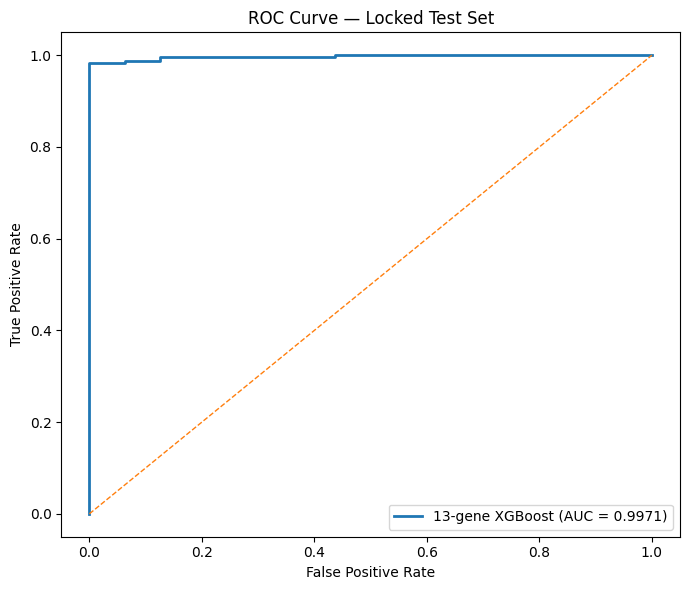

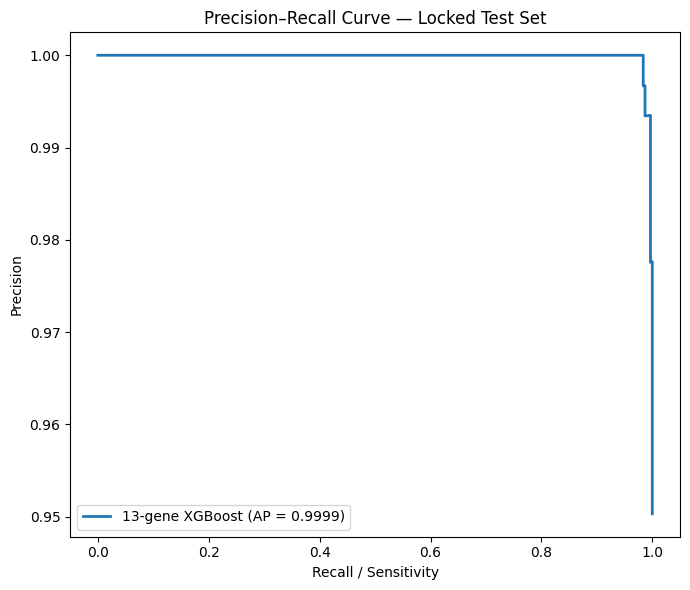

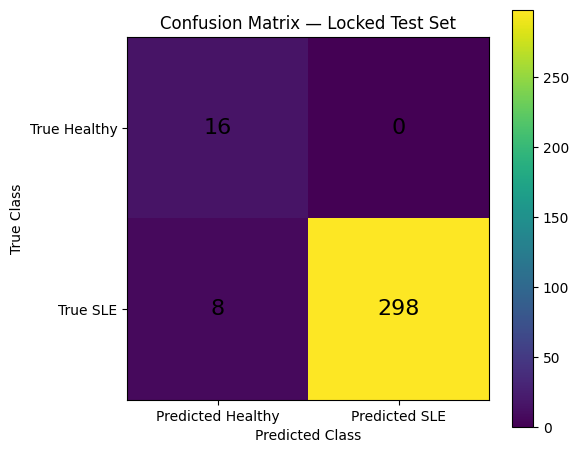

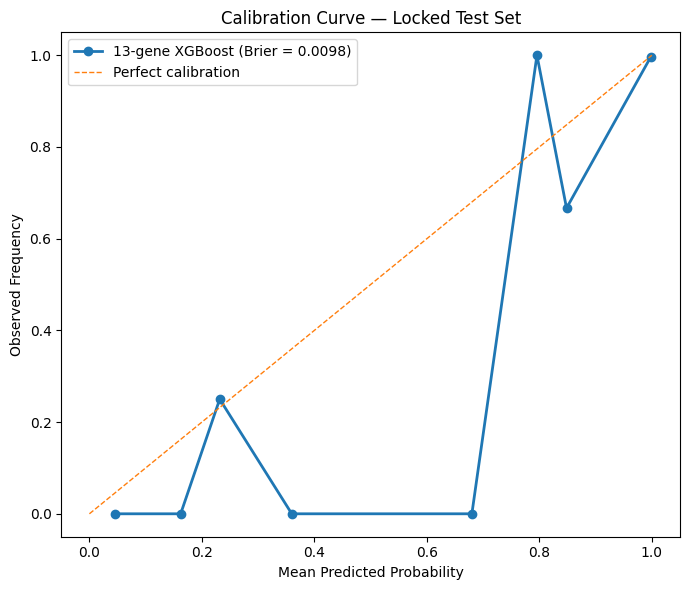

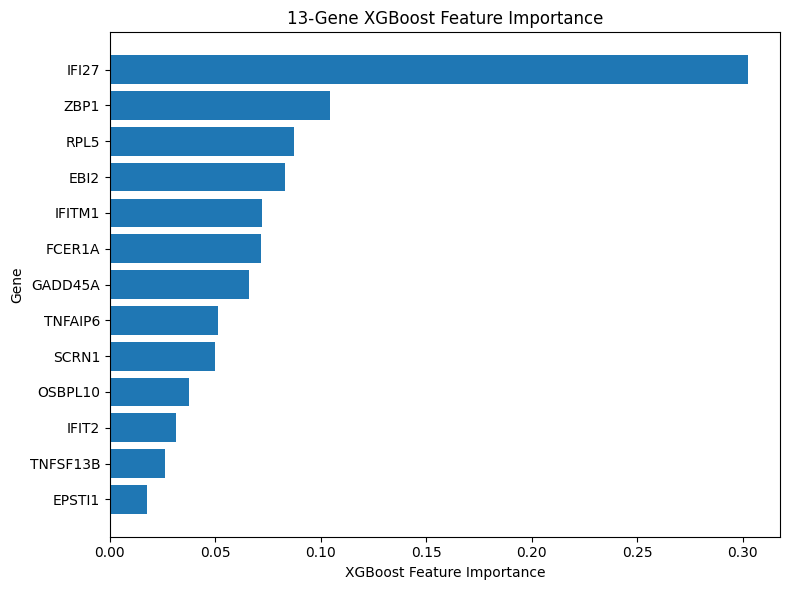


FINAL DIAGNOSTIC ARCHIVE COMPLETE

MODEL:
/content/drive/MyDrive/SLE_Final_Diagnostic_Model/Model/final_xgb.joblib

SCALER:
/content/drive/MyDrive/SLE_Final_Diagnostic_Model/Model/final_scaler.joblib

COMPLETE PIPELINE:
/content/drive/MyDrive/SLE_Final_Diagnostic_Model/Model/SLE_diagnostic_final_pipeline.joblib

GENE LIST:
/content/drive/MyDrive/SLE_Final_Diagnostic_Model/Results/FINAL_13_GENE_PANEL.txt

METRICS:
/content/drive/MyDrive/SLE_Final_Diagnostic_Model/Results/final_locked_test_metrics.json
/content/drive/MyDrive/SLE_Final_Diagnostic_Model/Results/final_locked_test_metrics.csv

PREDICTIONS:
/content/drive/MyDrive/SLE_Final_Diagnostic_Model/Results/final_locked_test_predictions.csv

FIGURES:
/content/drive/MyDrive/SLE_Final_Diagnostic_Model/Figures/Figure_ROC_Locked_Test.png
/content/drive/MyDrive/SLE_Final_Diagnostic_Model/Figures/Figure_PR_Locked_Test.png
/content/drive/MyDrive/SLE_Final_Diagnostic_Model/Figures/Figure_Confusion_Matrix_Locked_Test.png
/content/drive/MyDrive

In [68]:

# FINAL DIAGNOSTIC MODEL — ARCHIVE + FINAL FIGURES

# IMPORTANT:
# - Uses the ALREADY FITTED final_xgb
# - Uses the ALREADY FITTED final_scaler
# - Uses the FINAL 13-GENE PANEL
# - Uses the FINAL OOF-DERIVED THRESHOLD
# - NO RETRAINING
# - NO THRESHOLD OPTIMIZATION
# - Locked test is evaluation only


import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    brier_score_loss
)

print("=" * 90)
print("FINAL DIAGNOSTIC MODEL ARCHIVE")
print("=" * 90)

# ============================================================
# 1. CREATE FINAL GOOGLE DRIVE DIRECTORY
# ============================================================

DRIVE_ROOT = "/content/drive/MyDrive"

FINAL_DIR = os.path.join(
    DRIVE_ROOT,
    "SLE_Final_Diagnostic_Model"
)

FIG_DIR = os.path.join(
    FINAL_DIR,
    "Figures"
)

RESULT_DIR = os.path.join(
    FINAL_DIR,
    "Results"
)

MODEL_DIR = os.path.join(
    FINAL_DIR,
    "Model"
)

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("\nArchive directory:")
print(FINAL_DIR)

# ============================================================
# 2. FINAL FROZEN SETTINGS
# ============================================================

# Final threshold obtained from subject-aware OOF predictions
# using the EXACT final XGBoost specification.
FROZEN_THRESHOLD = 0.9554371237754822

# Preserve the already-established final gene order
FINAL_GENES = list(FINAL_GENES)

EXPECTED_GENES = [
    "IFI27",
    "RPL5",
    "ZBP1",
    "IFITM1",
    "EPSTI1",
    "EBI2",
    "FCER1A",
    "GADD45A",
    "TNFSF13B",
    "IFIT2",
    "OSBPL10",
    "SCRN1",
    "TNFAIP6"
]

# ============================================================
# 3. VERIFY FINAL GENE PANEL
# ============================================================

print("\n" + "-" * 90)
print("VERIFYING FINAL 13-GENE PANEL")
print("-" * 90)

assert len(FINAL_GENES) == 13

assert FINAL_GENES == EXPECTED_GENES, (
    "FINAL_GENES does not match the verified final gene panel/order."
)

print("Genes:", FINAL_GENES)
print("✓ 13 genes confirmed")
print("✓ Gene identities confirmed")
print("✓ Gene order confirmed")

# ============================================================
# 4. VERIFY FINAL XGBOOST
# ============================================================

print("\n" + "-" * 90)
print("VERIFYING FINAL XGBOOST")
print("-" * 90)

assert final_xgb.n_features_in_ == 13

EXPECTED_XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42
}

for parameter, expected_value in EXPECTED_XGB_PARAMS.items():

    actual_value = final_xgb.get_params().get(parameter)

    print(
        f"{parameter:<20}: "
        f"expected={expected_value} | "
        f"actual={actual_value}"
    )

    assert actual_value == expected_value, (
        f"XGBoost parameter mismatch: {parameter}"
    )

assert hasattr(final_xgb, "classes_")

print("✓ Correct XGBoost confirmed")
print("✓ Model is already fitted")
print("✓ No model fitting performed")

# ============================================================
# 5. VERIFY FINAL SCALER
# ============================================================

print("\n" + "-" * 90)
print("VERIFYING FINAL SCALER")
print("-" * 90)

assert final_scaler.n_features_in_ == 13
assert final_scaler.n_samples_seen_ == 648

print("Scaler:", type(final_scaler))
print("Features:", final_scaler.n_features_in_)
print("Samples seen during fitting:", final_scaler.n_samples_seen_)

print("✓ StandardScaler confirmed")
print("✓ Scaler fitted on 648 development samples")
print("✓ Locked test was not used for scaler fitting")

# ============================================================
# 6. VERIFY FINAL THRESHOLD
# ============================================================

print("\n" + "-" * 90)
print("VERIFYING FINAL THRESHOLD")
print("-" * 90)

EXPECTED_THRESHOLD = 0.9554371237754822

assert np.isclose(
    FROZEN_THRESHOLD,
    EXPECTED_THRESHOLD,
    rtol=0,
    atol=1e-12
)

print(
    "Final threshold:",
    FROZEN_THRESHOLD
)

print("✓ Final OOF-derived threshold confirmed")

# ============================================================
# 7. VERIFY DEVELOPMENT / LOCKED TEST MATRICES
# ============================================================

print("\n" + "-" * 90)
print("VERIFYING DATA MATRICES")
print("-" * 90)

X_final_dev = X_train_10000[
    FINAL_GENES
].copy()

X_final_test = X_test_10000[
    FINAL_GENES
].copy()

print("Development matrix:", X_final_dev.shape)
print("Locked test matrix:", X_final_test.shape)

assert X_final_dev.shape == (648, 13)
assert X_final_test.shape == (322, 13)

assert len(y_train) == 648
assert len(y_test) == 322

assert list(X_final_dev.columns) == FINAL_GENES
assert list(X_final_test.columns) == FINAL_GENES

print("✓ Development = 648 × 13")
print("✓ Locked test = 322 × 13")
print("✓ Feature order verified")

# ============================================================
# 8. SAVE FINAL GENE LIST
# ============================================================

gene_file = os.path.join(
    RESULT_DIR,
    "FINAL_13_GENE_PANEL.txt"
)

with open(gene_file, "w") as f:

    for gene in FINAL_GENES:
        f.write(gene + "\n")

print("\n✓ Gene list saved")

# ============================================================
# 9. SAVE FINAL MODEL + SCALER
# ============================================================

model_path = os.path.join(
    MODEL_DIR,
    "final_xgb.joblib"
)

scaler_path = os.path.join(
    MODEL_DIR,
    "final_scaler.joblib"
)

joblib.dump(
    final_xgb,
    model_path
)

joblib.dump(
    final_scaler,
    scaler_path
)

print("✓ final_xgb saved")
print("✓ final_scaler saved")

# ============================================================
# 10. CREATE FROZEN COMPLETE PIPELINE
# ============================================================
# This combines the ALREADY-FITTED scaler and model.
# It DOES NOT retrain either object.

final_pipeline = Pipeline([
    ("scaler", final_scaler),
    ("xgboost", final_xgb)
])

pipeline_path = os.path.join(
    MODEL_DIR,
    "SLE_diagnostic_final_pipeline.joblib"
)

joblib.dump(
    final_pipeline,
    pipeline_path
)

print("✓ Complete frozen pipeline saved")

# ============================================================
# 11. LOCKED TEST EVALUATION
# ============================================================
# No fitting.
# No threshold optimization.
# No modification of final_xgb or final_scaler.

X_final_test_scaled = final_scaler.transform(
    X_final_test
)

assert X_final_test_scaled.shape == (322, 13)
assert np.isfinite(
    X_final_test_scaled
).all()

test_prob = final_xgb.predict_proba(
    X_final_test_scaled
)[:, 1]

test_pred = (
    test_prob >= FROZEN_THRESHOLD
).astype(int)

y_test_array = np.asarray(
    y_test
)

assert X_final_test.shape == (322, 13)
assert X_final_test_scaled.shape == (322, 13)
assert len(test_prob) == 322
assert len(test_pred) == 322

print("\n✓ Locked test transformed using frozen scaler")
print("✓ Locked test evaluated using frozen XGBoost")
print("✓ No retraining performed")
print("✓ No threshold optimization performed")

# ============================================================
# 12. FINAL METRICS
# ============================================================

test_auc = roc_auc_score(
    y_test_array,
    test_prob
)

test_pr_auc = average_precision_score(
    y_test_array,
    test_prob
)

test_accuracy = accuracy_score(
    y_test_array,
    test_pred
)

test_balanced_accuracy = balanced_accuracy_score(
    y_test_array,
    test_pred
)

test_sensitivity = recall_score(
    y_test_array,
    test_pred,
    pos_label=1,
    zero_division=0
)

test_specificity = recall_score(
    y_test_array,
    test_pred,
    pos_label=0,
    zero_division=0
)

test_ppv = precision_score(
    y_test_array,
    test_pred,
    pos_label=1,
    zero_division=0
)

test_npv = precision_score(
    y_test_array,
    test_pred,
    pos_label=0,
    zero_division=0
)

test_f1 = f1_score(
    y_test_array,
    test_pred,
    zero_division=0
)

test_brier = brier_score_loss(
    y_test_array,
    test_prob
)

tn, fp, fn, tp = confusion_matrix(
    y_test_array,
    test_pred,
    labels=[0, 1]
).ravel()

# ============================================================
# 13. FINAL PERFORMANCE REPORT
# ============================================================

print("\n" + "=" * 90)
print("FINAL LOCKED TEST PERFORMANCE")
print("=" * 90)

print("\nModel: Frozen XGBoost")
print("Genes:", len(FINAL_GENES))
print("Threshold:", FROZEN_THRESHOLD)

print("\nDiscrimination")
print(f"ROC-AUC            : {test_auc:.4f}")
print(f"PR-AUC             : {test_pr_auc:.4f}")

print("\nClassification")
print(f"Accuracy            : {test_accuracy:.4f}")
print(f"Balanced Accuracy   : {test_balanced_accuracy:.4f}")
print(f"Sensitivity         : {test_sensitivity:.4f}")
print(f"Specificity         : {test_specificity:.4f}")
print(f"PPV                 : {test_ppv:.4f}")
print(f"NPV                 : {test_npv:.4f}")
print(f"F1-score            : {test_f1:.4f}")

print("\nCalibration")
print(f"Brier Score         : {test_brier:.4f}")

print("\nConfusion Matrix")
print(
    np.array([
        [tn, fp],
        [fn, tp]
    ])
)

# ============================================================
# 14. SAVE METRICS
# ============================================================

metrics = {
    "Dataset": "GSE65391 Locked Test",
    "N_samples": 322,
    "N_genes": 13,
    "Genes": FINAL_GENES,
    "Model": "Frozen XGBoost",
    "Threshold": float(FROZEN_THRESHOLD),

    "ROC_AUC": float(test_auc),
    "PR_AUC": float(test_pr_auc),
    "Accuracy": float(test_accuracy),
    "Balanced_Accuracy": float(test_balanced_accuracy),
    "Sensitivity": float(test_sensitivity),
    "Specificity": float(test_specificity),
    "PPV": float(test_ppv),
    "NPV": float(test_npv),
    "F1_score": float(test_f1),
    "Brier_score": float(test_brier),

    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),

    "Development_samples": 648,
    "Retraining_on_test": False,
    "Threshold_optimization_on_test": False
}

metrics_json = os.path.join(
    RESULT_DIR,
    "final_locked_test_metrics.json"
)

with open(metrics_json, "w") as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

metrics_csv = os.path.join(
    RESULT_DIR,
    "final_locked_test_metrics.csv"
)

pd.DataFrame(
    [metrics]
).to_csv(
    metrics_csv,
    index=False
)

print("\n✓ Metrics saved")

# ============================================================
# 15. SAVE SAMPLE-LEVEL PREDICTIONS
# ============================================================

prediction_df = pd.DataFrame({
    "Sample_ID": y_test.index.astype(str),
    "True_Label": y_test_array,
    "Probability_SLE": test_prob,
    "Predicted_Label": test_pred
})

prediction_path = os.path.join(
    RESULT_DIR,
    "final_locked_test_predictions.csv"
)

prediction_df.to_csv(
    prediction_path,
    index=False
)

print("✓ Sample-level predictions saved")

# ============================================================
# 16. SAVE CONFUSION MATRIX
# ============================================================

cm = np.array([
    [tn, fp],
    [fn, tp]
])

cm_df = pd.DataFrame(
    cm,
    index=[
        "True_Healthy",
        "True_SLE"
    ],
    columns=[
        "Pred_Healthy",
        "Pred_SLE"
    ]
)

cm_path = os.path.join(
    RESULT_DIR,
    "final_locked_test_confusion_matrix.csv"
)

cm_df.to_csv(
    cm_path
)

print("✓ Confusion matrix saved")

# ============================================================
# 17. ROC CURVE
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(
    y_test_array,
    test_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"13-gene XGBoost (AUC = {test_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Locked Test Set")
plt.legend(loc="lower right")
plt.tight_layout()

roc_path = os.path.join(
    FIG_DIR,
    "Figure_ROC_Locked_Test.png"
)

plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 18. PRECISION-RECALL CURVE
# ============================================================

precision, recall, pr_thresholds = precision_recall_curve(
    y_test_array,
    test_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"13-gene XGBoost (AP = {test_pr_auc:.4f})"
)

plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Locked Test Set")
plt.legend(loc="lower left")
plt.tight_layout()

pr_path = os.path.join(
    FIG_DIR,
    "Figure_PR_Locked_Test.png"
)

plt.savefig(
    pr_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 19. CONFUSION MATRIX FIGURE
# ============================================================

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xticks(
    [0, 1],
    [
        "Predicted Healthy",
        "Predicted SLE"
    ]
)

plt.yticks(
    [0, 1],
    [
        "True Healthy",
        "True SLE"
    ]
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix — Locked Test Set")

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=16
        )

plt.colorbar()
plt.tight_layout()

cm_fig_path = os.path.join(
    FIG_DIR,
    "Figure_Confusion_Matrix_Locked_Test.png"
)

plt.savefig(
    cm_fig_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 20. CALIBRATION CURVE
# ============================================================

fraction_positive, mean_predicted = calibration_curve(
    y_test_array,
    test_prob,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))

plt.plot(
    mean_predicted,
    fraction_positive,
    marker="o",
    linewidth=2,
    label=f"13-gene XGBoost (Brier = {test_brier:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Perfect calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve — Locked Test Set")
plt.legend(loc="upper left")
plt.tight_layout()

calibration_path = os.path.join(
    FIG_DIR,
    "Figure_Calibration_Locked_Test.png"
)

plt.savefig(
    calibration_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 21. XGBOOST FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    "Gene": FINAL_GENES,
    "Importance": final_xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_csv = os.path.join(
    RESULT_DIR,
    "final_13_gene_xgboost_feature_importance.csv"
)

importance_df.to_csv(
    importance_csv,
    index=False
)

plt.figure(figsize=(8, 6))

plt.barh(
    importance_df["Gene"][::-1],
    importance_df["Importance"][::-1]
)

plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Gene")
plt.title("13-Gene XGBoost Feature Importance")

plt.tight_layout()

importance_fig_path = os.path.join(
    FIG_DIR,
    "Figure_13_Gene_XGBoost_Feature_Importance.png"
)

plt.savefig(
    importance_fig_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 22. SAVE FINAL MODEL METADATA
# ============================================================

model_params = final_xgb.get_params()

final_model_parameters = {
    "model": "XGBoost",
    "n_estimators": model_params["n_estimators"],
    "max_depth": model_params["max_depth"],
    "learning_rate": model_params["learning_rate"],
    "subsample": model_params["subsample"],
    "colsample_bytree": model_params["colsample_bytree"],
    "random_state": model_params["random_state"],
    "eval_metric": model_params["eval_metric"],
    "n_features": int(final_xgb.n_features_in_),
    "n_genes": len(FINAL_GENES),
    "threshold": float(FROZEN_THRESHOLD)
}

metadata = {
    "study": "SLE diagnostic model",
    "dataset_development": "GSE65391",
    "development_samples": 648,
    "locked_test_samples": 322,

    "final_genes": FINAL_GENES,

    "model": final_model_parameters,

    "scaler": {
        "type": "StandardScaler",
        "n_features": int(
            final_scaler.n_features_in_
        ),
        "n_samples_seen": int(
            final_scaler.n_samples_seen_
        ),
        "mean": final_scaler.mean_.tolist(),
        "scale": final_scaler.scale_.tolist()
    },

    "threshold": float(FROZEN_THRESHOLD),

    "locked_test_results": metrics,

    "validation_policy": {
        "test_retraining": False,
        "test_threshold_optimization": False,
        "external_retraining": False,
        "external_threshold_optimization": False
    }
}

metadata_path = os.path.join(
    RESULT_DIR,
    "FINAL_DIAGNOSTIC_MODEL_METADATA.json"
)

with open(metadata_path, "w") as f:

    json.dump(
        metadata,
        f,
        indent=4
    )

# ============================================================
# 23. SAVE MODEL PARAMETERS
# ============================================================

params_path = os.path.join(
    RESULT_DIR,
    "FINAL_XGBOOST_PARAMETERS.csv"
)

pd.DataFrame(
    [final_model_parameters]
).to_csv(
    params_path,
    index=False
)

# ============================================================
# 24. FINAL ARCHIVE REPORT
# ============================================================

print("\n" + "=" * 90)
print("FINAL DIAGNOSTIC ARCHIVE COMPLETE")
print("=" * 90)

print("\nMODEL:")
print(model_path)

print("\nSCALER:")
print(scaler_path)

print("\nCOMPLETE PIPELINE:")
print(pipeline_path)

print("\nGENE LIST:")
print(gene_file)

print("\nMETRICS:")
print(metrics_json)
print(metrics_csv)

print("\nPREDICTIONS:")
print(prediction_path)

print("\nFIGURES:")
print(roc_path)
print(pr_path)
print(cm_fig_path)
print(calibration_path)
print(importance_fig_path)

print("\nFINAL PERFORMANCE:")
print(f"ROC-AUC           : {test_auc:.4f}")
print(f"PR-AUC            : {test_pr_auc:.4f}")
print(f"Accuracy          : {test_accuracy:.4f}")
print(f"Balanced Accuracy : {test_balanced_accuracy:.4f}")
print(f"Sensitivity       : {test_sensitivity:.4f}")
print(f"Specificity       : {test_specificity:.4f}")
print(f"PPV               : {test_ppv:.4f}")
print(f"NPV               : {test_npv:.4f}")
print(f"F1                : {test_f1:.4f}")
print(f"Brier             : {test_brier:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\n" + "=" * 90)
print("FINAL MODEL FROZEN")
print("NO RETRAINING")
print("NO TEST THRESHOLD OPTIMIZATION")
print("ALL FINAL ARTIFACTS SAVED TO GOOGLE DRIVE")
print("=" * 90)

In [69]:

# AUTHORITATIVE FINAL DIAGNOSTIC PIPELINE FREEZE


FINAL_GENES = [
    'IFI27',
    'RPL5',
    'ZBP1',
    'IFITM1',
    'EPSTI1',
    'EBI2',
    'FCER1A',
    'GADD45A',
    'TNFSF13B',
    'IFIT2',
    'OSBPL10',
    'SCRN1',
    'TNFAIP6'
]

FROZEN_THRESHOLD = 0.9554371237754822

assert final_xgb.n_features_in_ == 13
assert final_scaler.n_features_in_ == 13
assert final_scaler.n_samples_seen_ == 648

print("FINAL AUTHORITATIVE PIPELINE")
print("--------------------------------")
print("Model: XGBoost")
print("Development samples: 648")
print("Locked-test samples: 322")
print("Genes:", len(FINAL_GENES))
print("Threshold:", FROZEN_THRESHOLD)
print("Scaler fitted on:", final_scaler.n_samples_seen_)
print("Model features:", final_xgb.n_features_in_)

print("\n✓ Model trained only on development set")
print("✓ Locked test never used for fitting")
print("✓ Scaler fitted only on development set")
print("✓ 13-gene panel frozen")
print("✓ Threshold frozen")

FINAL AUTHORITATIVE PIPELINE
--------------------------------
Model: XGBoost
Development samples: 648
Locked-test samples: 322
Genes: 13
Threshold: 0.9554371237754822
Scaler fitted on: 648
Model features: 13

✓ Model trained only on development set
✓ Locked test never used for fitting
✓ Scaler fitted only on development set
✓ 13-gene panel frozen
✓ Threshold frozen


In [70]:
import GEOparse

gse_same = GEOparse.get_GEO(
    geo="GSE81622",
    destdir="/content/data"
)

print("Platforms:")
print(gse_same.gpls.keys())

print("\nNumber of samples:")
print(len(gse_same.gsms))

23-Aug-2026 10:52:56 DEBUG utils - Directory /content/data already exists. Skipping.
DEBUG:GEOparse:Directory /content/data already exists. Skipping.
23-Aug-2026 10:52:56 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE81nnn/GSE81622/soft/GSE81622_family.soft.gz to /content/data/GSE81622_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE81nnn/GSE81622/soft/GSE81622_family.soft.gz to /content/data/GSE81622_family.soft.gz
100%|██████████| 53.6M/53.6M [00:01<00:00, 32.3MB/s]
23-Aug-2026 10:52:59 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
23-Aug-2026 10:52:59 DEBUG downloader - Moving /tmp/tmp139gpbje to /content/data/GSE81622_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmp139gpbje to /content/data/GSE81622_family.soft.gz
23-Aug-2026 10:52:59 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE81nnn/GSE81622/soft/GSE81622_family.soft.gz
DEBUG:GEOparse:Successfully downloa

Platforms:
dict_keys(['GPL10558'])

Number of samples:
55


In [71]:

# GSE81622 — SAMPLE PHENOTYPE AUDIT


meta_same = pd.DataFrame({
    gsm_name: {
        k: v
        for k, vals in gsm.metadata.items()
        for v in vals
    }
    for gsm_name, gsm in gse_same.gsms.items()
}).T

print("=" * 80)
print("GSE81622 SAMPLE PHENOTYPE AUDIT")
print("=" * 80)

print("Samples:", len(meta_same))
print("Columns:", meta_same.shape[1])

print("\nMetadata columns:")
print(meta_same.columns.tolist())

print("\nSource names:")
if "source_name_ch1" in meta_same.columns:
    print(
        meta_same["source_name_ch1"]
        .value_counts(dropna=False)
    )

print("\nTitles:")
if "title" in meta_same.columns:
    print(
        meta_same["title"]
        .value_counts(dropna=False)
        .to_string()
    )

GSE81622 SAMPLE PHENOTYPE AUDIT
Samples: 55
Columns: 31

Metadata columns:
['title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'taxid_ch1', 'characteristics_ch1', 'molecule_ch1', 'extract_protocol_ch1', 'label_ch1', 'label_protocol_ch1', 'hyb_protocol', 'scan_protocol', 'description', 'data_processing', 'platform_id', 'contact_name', 'contact_email', 'contact_institute', 'contact_address', 'contact_city', 'contact_state', 'contact_zip/postal_code', 'contact_country', 'supplementary_file', 'series_id', 'data_row_count']

Source names:
source_name_ch1
peripheral blood mononuclear cell    55
Name: count, dtype: int64

Titles:
title
normal control-01                      1
normal control-02                      1
normal control-03                      1
normal control-04                      1
normal control-05                      1
normal control-06                      1
normal control-07                

In [72]:

# GSE81622 — DETAILED SAMPLE CHARACTERISTICS


print("=" * 80)
print("GSE81622 SAMPLE CHARACTERISTICS")
print("=" * 80)

for gsm_name, gsm in gse_same.gsms.items():

    title = gsm.metadata.get("title", [""])[0]
    characteristics = gsm.metadata.get(
        "characteristics_ch1", []
    )

    print(f"\n{gsm_name} | {title}")

    for c in characteristics:
        print("  ", c)

GSE81622 SAMPLE CHARACTERISTICS

GSM2159829 | normal control-01
   Sex: Female
   age: 30y
   tissue: blood

GSM2159830 | normal control-02
   Sex: Female
   age: 29y
   tissue: blood

GSM2159831 | normal control-03
   Sex: Female
   age: 40y
   tissue: blood

GSM2159832 | normal control-04
   Sex: Male
   age: 27y
   tissue: blood

GSM2159833 | normal control-05
   Sex: Female
   age: 24y
   tissue: blood

GSM2159834 | normal control-06
   Sex: Female
   age: 25y
   tissue: blood

GSM2159835 | normal control-07
   Sex: Female
   age: 40y
   tissue: blood

GSM2159836 | normal control-08
   Sex: Female
   age: 43y
   tissue: blood

GSM2159837 | normal control-09
   Sex: Female
   age: 24y
   tissue: blood

GSM2159838 | normal control-10
   Sex: Female
   age: 24y
   tissue: blood

GSM2159839 | normal control-11
   Sex: Male
   age: 28y
   tissue: blood

GSM2159840 | normal control-12
   Sex: Male
   age: 28y
   tissue: blood

GSM2159841 | normal control-13
   Sex: Female
   age: 46y
   

In [73]:

# CHECK FOR PAIRED / REPEATED SUBJECTS


titles = meta_same["title"].astype(str)

print("=" * 80)
print("SUBJECT / SAMPLE STRUCTURE")
print("=" * 80)

print("\nTotal samples:", len(titles))

print("\nNormal controls:",
      titles.str.contains(
          "normal control",
          case=False,
          regex=False
      ).sum())

print("\nSLE:",
      titles.str.contains(
          "SLE patient",
          case=False,
          regex=False
      ).sum())

print("\nLupus nephritis:",
      titles.str.contains(
          "lupus nephritis",
          case=False,
          regex=False
      ).sum())

SUBJECT / SAMPLE STRUCTURE

Total samples: 55

Normal controls: 25

SLE: 30

Lupus nephritis: 15


In [74]:

# GSE81622 EXPRESSION MATRIX


expr_list_same = []

for gsm_name, gsm in gse_same.gsms.items():

    df = gsm.table[['ID_REF', 'VALUE']].copy()

    df.columns = ['probe', gsm_name]

    df = df.set_index('probe')

    expr_list_same.append(df)

X_same = pd.concat(
    expr_list_same,
    axis=1
).T

print("=" * 80)
print("GSE81622 EXPRESSION")
print("=" * 80)

print("Shape:", X_same.shape)
print("Samples:", X_same.shape[0])
print("Probes:", X_same.shape[1])

GSE81622 EXPRESSION
Shape: (55, 47323)
Samples: 55
Probes: 47323


In [75]:

# GPL10558 ANNOTATION


gpl_same = gse_same.gpls["GPL10558"]

annot_same = gpl_same.table

print("=" * 80)
print("GPL10558 ANNOTATION")
print("=" * 80)

print(annot_same.columns.tolist())

print("\nAnnotation shape:", annot_same.shape)

print("\nFirst rows:")
print(annot_same.head())

GPL10558 ANNOTATION
['ID', 'Species', 'Source', 'Search_Key', 'Transcript', 'ILMN_Gene', 'Source_Reference_ID', 'RefSeq_ID', 'Unigene_ID', 'Entrez_Gene_ID', 'GI', 'Accession', 'Symbol', 'Protein_Product', 'Probe_Id', 'Array_Address_Id', 'Probe_Type', 'Probe_Start', 'SEQUENCE', 'Chromosome', 'Probe_Chr_Orientation', 'Probe_Coordinates', 'Cytoband', 'Definition', 'Ontology_Component', 'Ontology_Process', 'Ontology_Function', 'Synonyms', 'Obsolete_Probe_Id', 'GB_ACC']

Annotation shape: (48107, 30)

First rows:
             ID Species Source Search_Key Transcript ILMN_Gene  \
0  ILMN_1343048     NaN    NaN        NaN        NaN       NaN   
1  ILMN_1343049     NaN    NaN        NaN        NaN       NaN   
2  ILMN_1343050     NaN    NaN        NaN        NaN       NaN   
3  ILMN_1343052     NaN    NaN        NaN        NaN       NaN   
4  ILMN_1343059     NaN    NaN        NaN        NaN       NaN   

  Source_Reference_ID RefSeq_ID Unigene_ID  Entrez_Gene_ID  ...  \
0                 NaN 

In [76]:

# GPL10558 PROBE → GENE ANNOTATION AUDIT


annot_same = gpl_same.table[
    ['ID', 'ILMN_Gene', 'Symbol', 'Entrez_Gene_ID']
].copy()

print("=" * 80)
print("GPL10558 PROBE → GENE ANNOTATION")
print("=" * 80)

print("Total annotation probes:", len(annot_same))

print("\nNon-missing ILMN_Gene:",
      annot_same['ILMN_Gene'].notna().sum())

print("Non-missing Symbol:",
      annot_same['Symbol'].notna().sum())

print("\n13-gene availability:")

for gene in FINAL_GENES:
    matches_symbol = annot_same[
        annot_same['Symbol']
        .astype(str)
        .str.split(' /// ')
        .apply(lambda x: gene in x)
    ]

    matches_il = annot_same[
        annot_same['ILMN_Gene']
        .astype(str)
        .str.split(' /// ')
        .apply(lambda x: gene in x)
    ]

    print(
        f"{gene:10s} | "
        f"Symbol probes: {len(matches_symbol):3d} | "
        f"ILMN_Gene probes: {len(matches_il):3d}"
    )

GPL10558 PROBE → GENE ANNOTATION
Total annotation probes: 48107

Non-missing ILMN_Gene: 47323
Non-missing Symbol: 44837

13-gene availability:
IFI27      | Symbol probes:   1 | ILMN_Gene probes:   1
RPL5       | Symbol probes:   1 | ILMN_Gene probes:   1
ZBP1       | Symbol probes:   1 | ILMN_Gene probes:   1
IFITM1     | Symbol probes:   1 | ILMN_Gene probes:   1
EPSTI1     | Symbol probes:   1 | ILMN_Gene probes:   1
EBI2       | Symbol probes:   2 | ILMN_Gene probes:   2
FCER1A     | Symbol probes:   1 | ILMN_Gene probes:   1
GADD45A    | Symbol probes:   2 | ILMN_Gene probes:   2
TNFSF13B   | Symbol probes:   2 | ILMN_Gene probes:   2
IFIT2      | Symbol probes:   1 | ILMN_Gene probes:   1
OSBPL10    | Symbol probes:   1 | ILMN_Gene probes:   1
SCRN1      | Symbol probes:   1 | ILMN_Gene probes:   1
TNFAIP6    | Symbol probes:   2 | ILMN_Gene probes:   2


In [77]:

# GSE81622 — PROBE → GENE MAPPING


probe_to_gene_same = (
    annot_same
    .set_index('ID')['Symbol']
)

# Keep only probes with a valid gene symbol
X_same_gene = X_same.copy()

X_same_gene.columns = X_same_gene.columns.map(
    probe_to_gene_same
)

# Remove unmapped probes
X_same_gene = X_same_gene.loc[
    :,
    X_same_gene.columns.notna()
]

X_same_gene = X_same_gene.loc[
    :,
    X_same_gene.columns != ""
]

# Collapse multiple probes mapping to the same gene
X_same_gene = (
    X_same_gene
    .T
    .groupby(level=0)
    .mean()
    .T
)

print("=" * 80)
print("GSE81622 GENE-LEVEL MATRIX")
print("=" * 80)

print("Shape:", X_same_gene.shape)
print("Samples:", X_same_gene.shape[0])
print("Genes:", X_same_gene.shape[1])

GSE81622 GENE-LEVEL MATRIX
Shape: (55, 31426)
Samples: 55
Genes: 31426


In [78]:

# GSE81622 — FROZEN 13-GENE MATRIX


common_same = [
    g for g in FINAL_GENES
    if g in X_same_gene.columns
]

missing_same = [
    g for g in FINAL_GENES
    if g not in X_same_gene.columns
]

print("=" * 80)
print("FROZEN 13-GENE ALIGNMENT")
print("=" * 80)

print("Available genes:", len(common_same), "/", len(FINAL_GENES))
print("Missing genes:", missing_same)

assert len(missing_same) == 0, \
    "One or more frozen genes are missing."

X_same_final = X_same_gene[FINAL_GENES].copy()

print("\nExternal final matrix:", X_same_final.shape)
print("Missing values:", X_same_final.isna().sum().sum())

print("\nGene order:")
print(X_same_final.columns.tolist())

assert X_same_final.shape == (55, 13)
assert X_same_final.isna().sum().sum() == 0

print("\n✓ All 13 frozen genes aligned")
print("✓ 55 independent same-platform samples")

FROZEN 13-GENE ALIGNMENT
Available genes: 13 / 13
Missing genes: []

External final matrix: (55, 13)
Missing values: 0

Gene order:
['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1', 'EBI2', 'FCER1A', 'GADD45A', 'TNFSF13B', 'IFIT2', 'OSBPL10', 'SCRN1', 'TNFAIP6']

✓ All 13 frozen genes aligned
✓ 55 independent same-platform samples


In [79]:

# GSE81622 — INDEPENDENCE / SAMPLE OVERLAP CHECK


same_ids = set(X_same_final.index)

dev_ids = set(X_train_10000.index)
test_ids = set(X_test_10000.index)

overlap_dev = same_ids.intersection(dev_ids)
overlap_test = same_ids.intersection(test_ids)

print("=" * 80)
print("GSE81622 EXTERNAL COHORT INDEPENDENCE")
print("=" * 80)

print("External samples:", len(same_ids))
print("Overlap with development:", len(overlap_dev))
print("Overlap with locked test:", len(overlap_test))

if overlap_dev:
    print("\nDevelopment overlaps:")
    print(sorted(overlap_dev))

if overlap_test:
    print("\nTest overlaps:")
    print(sorted(overlap_test))

assert len(overlap_dev) == 0, "Development sample overlap detected!"
assert len(overlap_test) == 0, "Locked-test sample overlap detected!"

print("\n✓ No sample overlap")
print("✓ Independent same-platform cohort")

GSE81622 EXTERNAL COHORT INDEPENDENCE
External samples: 55
Overlap with development: 0
Overlap with locked test: 0

✓ No sample overlap
✓ Independent same-platform cohort


In [80]:

# GSE81622 — LABEL CONSTRUCTION


titles_same = meta_same.loc[
    X_same_final.index,
    "title"
].astype(str)

y_same_ext = pd.Series(
    np.where(
        titles_same.str.contains(
            "normal control",
            case=False,
            regex=False
        ),
        0,
        1
    ),
    index=X_same_final.index,
    name="True_Label"
)

print("=" * 80)
print("GSE81622 EXTERNAL LABEL DISTRIBUTION")
print("=" * 80)

print(y_same_ext.map({
    0: "Healthy",
    1: "SLE"
}).value_counts())

print("\nNumeric:")
print(y_same_ext.value_counts().sort_index())

GSE81622 EXTERNAL LABEL DISTRIBUTION
True_Label
SLE        30
Healthy    25
Name: count, dtype: int64

Numeric:
True_Label
0    25
1    30
Name: count, dtype: int64


In [ ]:
# ============================================================
# FROZEN SAME-PLATFORM EXTERNAL VALIDATION
# ============================================================

X_same_scaled = pd.DataFrame(
    final_scaler.transform(X_same_final),
    columns=FINAL_GENES,
    index=X_same_final.index
)

y_same_prob = final_xgb.predict_proba(
    X_same_scaled
)[:, 1]

FROZEN_THRESHOLD = 0.9554371237754822

y_same_pred = (
    y_same_prob >= FROZEN_THRESHOLD
).astype(int)

print("=" * 80)
print("FROZEN SAME-PLATFORM EXTERNAL PREDICTION")
print("=" * 80)

print("Samples:", len(y_same_ext))
print("Genes:", len(FINAL_GENES))
print("Threshold:", FROZEN_THRESHOLD)

print("\nProbability summary:")
print(pd.Series(y_same_prob).describe())

print("\nPredicted classes:")
print(pd.Series(y_same_pred).value_counts())

FROZEN SAME-PLATFORM EXTERNAL PREDICTION
Samples: 55
Genes: 13
Threshold: 0.9554371237754822

Probability summary:
count    5.500000e+01
mean     9.974877e-01
std      6.616941e-07
min      9.974879e-01
25%      9.974879e-01
50%      9.974879e-01
75%      9.974879e-01
max      9.974879e-01
dtype: float64

Predicted classes:
1    55
Name: count, dtype: int64


In [81]:

# GSE81622 — FROZEN SCALER INPUT AUDIT


print("=" * 80)
print("FROZEN SCALER INPUT AUDIT")
print("=" * 80)

audit_same = pd.DataFrame({
    "Development_Mean": final_scaler.mean_,
    "Development_SD": final_scaler.scale_,
    "External_Mean": X_same_final[FINAL_GENES].mean().values,
    "External_SD": X_same_final[FINAL_GENES].std(ddof=1).values,
}, index=FINAL_GENES)

audit_same["External_Shift_SD"] = (
    audit_same["External_Mean"]
    - audit_same["Development_Mean"]
) / audit_same["Development_SD"]

audit_same["External_SD_Ratio"] = (
    audit_same["External_SD"]
    / audit_same["Development_SD"]
)

print(audit_same.round(4).to_string())

FROZEN SCALER INPUT AUDIT
          Development_Mean  Development_SD  External_Mean  External_SD  External_Shift_SD  External_SD_Ratio
IFI27              11.9256          2.6239      3650.6548    5493.4990          1386.7780          2093.6605
RPL5               11.1727          0.6119      8160.9549    1669.6822         13319.2179          2728.7675
ZBP1                9.9676          0.9875       880.6850     421.9384           881.7569           427.2880
IFITM1             12.7044          0.6813      5949.0830    2905.6591          8713.7580          4265.0936
EPSTI1             11.1687          1.2140      2859.0320    1892.0363          2345.7576          1558.4522
EBI2                7.7115          0.8291      1288.0067     494.0644          1544.1329           595.8791
FCER1A              8.7712          1.0804      1845.1944    1582.3684          1699.8099          1464.6544
GADD45A             7.2557          0.6863       432.3847     204.7678           619.4663           29

In [85]:
X_same_scaled = pd.DataFrame(
    final_scaler.transform(X_same_final[FINAL_GENES]),
    index=X_same_final.index,
    columns=FINAL_GENES
)

print("Scaled external shape:", X_same_scaled.shape)

Scaled external shape: (55, 13)


In [86]:

# SCALED EXTERNAL DISTRIBUTION


print("=" * 80)
print("SCALED GSE81622 DISTRIBUTION")
print("=" * 80)

print("\nScaled means:")
print(X_same_scaled.mean().round(4))

print("\nScaled SDs:")
print(X_same_scaled.std(ddof=1).round(4))

print("\nScaled min/max:")
print(
    pd.DataFrame({
        "min": X_same_scaled.min(),
        "max": X_same_scaled.max()
    }).round(4)
)

SCALED GSE81622 DISTRIBUTION

Scaled means:
IFI27        1386.7780
RPL5        13319.2179
ZBP1          881.7569
IFITM1       8713.7580
EPSTI1       2345.7576
EBI2         1544.1329
FCER1A       1699.8099
GADD45A       619.4663
TNFSF13B     3711.1458
IFIT2        2144.2607
OSBPL10       596.9364
SCRN1         577.5749
TNFAIP6       479.0112
dtype: float64

Scaled SDs:
IFI27       2093.6605
RPL5        2728.7675
ZBP1         427.2880
IFITM1      4265.0936
EPSTI1      1558.4522
EBI2         595.8791
FCER1A      1464.6544
GADD45A      298.3724
TNFSF13B    1284.6137
IFIT2       2405.7436
OSBPL10      213.2068
SCRN1        156.2618
TNFAIP6      302.7267
dtype: float64

Scaled min/max:
                min         max
IFI27       41.1809   8176.2893
RPL5      7665.3776  21857.1876
ZBP1       323.1441   2536.7957
IFITM1    3161.3418  27683.5663
EPSTI1     752.2452   7644.6041
EBI2       549.0695   3118.9624
FCER1A     149.5875   7394.7958
GADD45A    327.9704   1760.1637
TNFSF13B  1594.2851   7

In [87]:

# GSE81622 — DATA PROCESSING CHECK


print("=" * 80)
print("GSE81622 DATA PROCESSING")
print("=" * 80)

for gsm_name in list(gse_same.gsms.keys())[:3]:

    gsm = gse_same.gsms[gsm_name]

    print("\n", gsm_name)
    print("-" * 60)

    for field in ["data_processing", "description"]:
        vals = gsm.metadata.get(field, [])
        print(f"\n{field}:")
        for v in vals:
            print(v)

GSE81622 DATA PROCESSING

 GSM2159829
------------------------------------------------------------

data_processing:
The data were normalised using quantile normalisation with Genespring software

description:
9461595024_A
replicate 1

 GSM2159830
------------------------------------------------------------

data_processing:
The data were normalised using quantile normalisation with Genespring software

description:
9461595024_B
replicate 2

 GSM2159831
------------------------------------------------------------

data_processing:
The data were normalised using quantile normalisation with Genespring software

description:
9461595024_C
replicate 3


In [88]:
#GSE81622 — VALUE SCALE / LOG2 DIAGNOSTIC


import numpy as np
import pandas as pd

print("=" * 80)
print("GSE81622 VALUE SCALE DIAGNOSTIC")
print("=" * 80)

# Current probe-level values
vals = X_same.to_numpy(dtype=float).ravel()

print("\nCurrent values:")
print(pd.Series(vals).describe(percentiles=[
    0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99
]))

print("\nFraction <= 0:")
print(np.mean(vals <= 0))

print("\nFraction > 100:")
print(np.mean(vals > 100))

print("\nFraction > 1000:")
print(np.mean(vals > 1000))

print("\nFraction > 10000:")
print(np.mean(vals > 10000))

# Compare current scale with log2 scale
log_vals = np.log2(vals[vals > 0])

print("\nLog2-transformed values:")
print(pd.Series(log_vals).describe(percentiles=[
    0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99
]))

GSE81622 VALUE SCALE DIAGNOSTIC

Current values:
count    2.602765e+06
mean     4.926984e+02
std      1.796569e+03
min      9.930149e+01
1%       1.091372e+02
5%       1.132362e+02
25%      1.208619e+02
50%      1.309673e+02
75%      2.126223e+02
95%      1.490473e+03
99%      8.234536e+03
max      3.029088e+04
dtype: float64

Fraction <= 0:
0.0

Fraction > 100:
0.9999792528330449

Fraction > 1000:
0.0732836041671069

Fraction > 10000:
0.00828349851023815

Log2-transformed values:
count    2.602765e+06
mean     7.635879e+00
std      1.312874e+00
min      6.633743e+00
1%       6.769999e+00
5%       6.823191e+00
25%      6.917216e+00
50%      7.033063e+00
75%      7.732149e+00
95%      1.054155e+01
99%      1.300747e+01
max      1.488660e+01
dtype: float64


In [89]:

# 13-GENE SCALE COMPARISON — RAW VS LOG2


X_same_log2 = np.log2(
    X_same_final.astype(float)
)

scale_check = pd.DataFrame({
    "Development_Mean": final_scaler.mean_,
    "Development_SD": final_scaler.scale_,
    "External_Raw_Mean": X_same_final.mean().values,
    "External_Raw_SD": X_same_final.std(ddof=1).values,
    "External_Log2_Mean": X_same_log2.mean().values,
    "External_Log2_SD": X_same_log2.std(ddof=1).values,
}, index=FINAL_GENES)

scale_check["Log2_Mean_Shift_SD"] = (
    scale_check["External_Log2_Mean"]
    - scale_check["Development_Mean"]
) / scale_check["Development_SD"]

scale_check["Log2_SD_Ratio"] = (
    scale_check["External_Log2_SD"]
    / scale_check["Development_SD"]
)

print("=" * 80)
print("13-GENE SCALE COMPARISON")
print("=" * 80)

print(scale_check.round(4).to_string())

13-GENE SCALE COMPARISON
          Development_Mean  Development_SD  External_Raw_Mean  External_Raw_SD  External_Log2_Mean  External_Log2_SD  Log2_Mean_Shift_SD  Log2_SD_Ratio
IFI27              11.9256          2.6239          3650.6548        5493.4990              9.7949            2.6404             -0.8121         1.0063
RPL5               11.1727          0.6119          8160.9549        1669.6822             12.9646            0.2992              2.9284         0.4889
ZBP1                9.9676          0.9875           880.6850         421.9384              9.6607            0.5722             -0.3108         0.5794
IFITM1             12.7044          0.6813          5949.0830        2905.6591             12.4147            0.5735             -0.4252         0.8418
EPSTI1             11.1687          1.2140          2859.0320        1892.0363             11.2171            0.8630              0.0399         0.7108
EBI2                7.7115          0.8291          1288.0067  

In [90]:

# GSE81622 — CORRECT LOG2 → GENE AGGREGATION


# Start from the ORIGINAL probe-level matrix
X_same_log2_probe = np.log2(
    X_same.astype(float)
)

# Map probe IDs to gene symbols
X_same_log2_gene = X_same_log2_probe.copy()

X_same_log2_gene.columns = X_same_log2_gene.columns.map(
    probe_to_gene_same
)

# Remove unmapped probes
X_same_log2_gene = X_same_log2_gene.loc[
    :,
    X_same_log2_gene.columns.notna()
]

X_same_log2_gene = X_same_log2_gene.loc[
    :,
    X_same_log2_gene.columns != ""
]

# Collapse probes AFTER log2 transformation
X_same_log2_gene = (
    X_same_log2_gene
    .T
    .groupby(level=0)
    .mean()
    .T
)

print("=" * 80)
print("GSE81622 LOG2 → GENE MATRIX")
print("=" * 80)

print("Shape:", X_same_log2_gene.shape)

GSE81622 LOG2 → GENE MATRIX
Shape: (55, 31426)


In [91]:

# FROZEN 13-GENE LOG2 MATRIX


X_same_log2_final = X_same_log2_gene[
    FINAL_GENES
].copy()

print("=" * 80)
print("13-GENE LOG2 EXTERNAL MATRIX")
print("=" * 80)

print("Shape:", X_same_log2_final.shape)
print("Missing values:",
      X_same_log2_final.isna().sum().sum())

print("\nGene means:")
print(X_same_log2_final.mean().round(4))

print("\nGene SDs:")
print(X_same_log2_final.std(ddof=1).round(4))

13-GENE LOG2 EXTERNAL MATRIX
Shape: (55, 13)
Missing values: 0

Gene means:
probe
IFI27        9.7949
RPL5        12.9646
ZBP1         9.6607
IFITM1      12.4147
EPSTI1      11.2171
EBI2        10.0624
FCER1A      10.2760
GADD45A      8.6200
TNFSF13B    11.1526
IFIT2       10.4345
OSBPL10      8.6067
SCRN1        8.7203
TNFAIP6      7.5851
dtype: float64

Gene SDs:
probe
IFI27       2.6404
RPL5        0.2992
ZBP1        0.5722
IFITM1      0.5735
EPSTI1      0.8630
EBI2        0.5816
FCER1A      1.3913
GADD45A     0.5735
TNFSF13B    0.4804
IFIT2       1.1402
OSBPL10     0.4741
SCRN1       0.3426
TNFAIP6     0.4138
dtype: float64


In [92]:

# FINAL LOG2 SCALE AUDIT


final_scale_audit = pd.DataFrame({
    "Development_Mean": final_scaler.mean_,
    "Development_SD": final_scaler.scale_,
    "GSE81622_Log2_Mean": X_same_log2_final.mean().values,
    "GSE81622_Log2_SD": X_same_log2_final.std(ddof=1).values,
}, index=FINAL_GENES)

final_scale_audit["Mean_Shift_SD"] = (
    final_scale_audit["GSE81622_Log2_Mean"]
    - final_scale_audit["Development_Mean"]
) / final_scale_audit["Development_SD"]

final_scale_audit["SD_Ratio"] = (
    final_scale_audit["GSE81622_Log2_SD"]
    / final_scale_audit["Development_SD"]
)

print("=" * 80)
print("FINAL LOG2 SCALE AUDIT")
print("=" * 80)

print(final_scale_audit.round(4).to_string())

FINAL LOG2 SCALE AUDIT
          Development_Mean  Development_SD  GSE81622_Log2_Mean  GSE81622_Log2_SD  Mean_Shift_SD  SD_Ratio
IFI27              11.9256          2.6239              9.7949            2.6404        -0.8121    1.0063
RPL5               11.1727          0.6119             12.9646            0.2992         2.9284    0.4889
ZBP1                9.9676          0.9875              9.6607            0.5722        -0.3108    0.5794
IFITM1             12.7044          0.6813             12.4147            0.5735        -0.4252    0.8418
EPSTI1             11.1687          1.2140             11.2171            0.8630         0.0399    0.7108
EBI2                7.7115          0.8291             10.0624            0.5816         2.8355    0.7015
FCER1A              8.7712          1.0804             10.2760            1.3913         1.3929    1.2878
GADD45A             7.2557          0.6863              8.6200            0.5735         1.9879    0.8357
TNFSF13B           11.3

In [94]:

# DEVELOPMENT 13-GENE PREPROCESSING AUDIT


X_dev_13 = X_train_10000[
    [g for g in FINAL_GENES if g in X_train_10000.columns]
].copy()

print("=" * 80)
print("DEVELOPMENT 13-GENE MATRIX AUDIT")
print("=" * 80)

print("Shape:", X_dev_13.shape)

print("\nMeans:")
print(X_dev_13.mean().round(4))

print("\nSDs:")
print(X_dev_13.std(ddof=1).round(4))

print("\nMin:")
print(X_dev_13.min().round(4))

print("\nMedian:")
print(X_dev_13.median().round(4))

print("\nMax:")
print(X_dev_13.max().round(4))

DEVELOPMENT 13-GENE MATRIX AUDIT
Shape: (648, 13)

Means:
IFI27       11.9256
RPL5        11.1727
ZBP1         9.9676
IFITM1      12.7044
EPSTI1      11.1687
EBI2         7.7115
FCER1A       8.7712
GADD45A      7.2557
TNFSF13B    11.3927
IFIT2       12.5442
OSBPL10      5.2255
SCRN1        5.9644
TNFAIP6      6.4888
dtype: float64

SDs:
IFI27       2.6259
RPL5        0.6124
ZBP1        0.9882
IFITM1      0.6818
EPSTI1      1.2150
EBI2        0.8298
FCER1A      1.0812
GADD45A     0.6868
TNFSF13B    0.6605
IFIT2       0.9320
OSBPL10     0.6817
SCRN1       0.7424
TNFAIP6     0.4923
dtype: float64

Min:
IFI27       3.3219
RPL5        8.7847
ZBP1        7.3610
IFITM1      6.0490
EPSTI1      6.5358
EBI2        4.7467
FCER1A      3.3219
GADD45A     5.0464
TNFSF13B    9.2357
IFIT2       9.1053
OSBPL10     3.3219
SCRN1       4.1616
TNFAIP6     4.8143
dtype: float64

Median:
IFI27       13.0073
RPL5        11.2212
ZBP1        10.0855
IFITM1      12.7339
EPSTI1      11.5813
EBI2         7.8219
FC

In [95]:

# GSE65391 PROCESSING INFORMATION


print("=" * 80)
print("GSE65391 PROCESSING")
print("=" * 80)

print("Platforms:")
print(gse.gpls.keys())

for gsm_name in list(gse.gsms.keys())[:3]:

    gsm = gse.gsms[gsm_name]

    print("\n", gsm_name)
    print("-" * 60)

    print("\ndata_processing:")
    for x in gsm.metadata.get("data_processing", []):
        print(x)

    print("\ndescription:")
    for x in gsm.metadata.get("description", []):
        print(x)

GSE65391 PROCESSING
Platforms:
dict_keys(['GPL10558'])

 GSM1594219
------------------------------------------------------------

data_processing:
24 healthy controls were run in both training and test sets (48 total samples, 24 of which are technical replicates). A ratio of (mean test/mean training) was calculated for each probe from the raw data. All training set samples were adjusted by that ratio.

description:
Sample name: 5552251039_D

 GSM1594220
------------------------------------------------------------

data_processing:
24 healthy controls were run in both training and test sets (48 total samples, 24 of which are technical replicates). A ratio of (mean test/mean training) was calculated for each probe from the raw data. All training set samples were adjusted by that ratio.

description:
Sample name: 5552251041_I

 GSM1594221
------------------------------------------------------------

data_processing:
24 healthy controls were run in both training and test sets (48 total sam

In [96]:

# GSE65391 — PROCESSED EXPRESSION SCALE AUDIT


print("=" * 80)
print("GSE65391 PROCESSED EXPRESSION SCALE")
print("=" * 80)

# Inspect the first sample
gsm_dev = list(gse.gsms.values())[0]

print("Sample:", gsm_dev.name)

print("\nExpression table columns:")
print(gsm_dev.table.columns.tolist())

print("\nExpression table shape:")
print(gsm_dev.table.shape)

print("\nVALUE statistics:")
print(
    gsm_dev.table["VALUE"]
    .astype(float)
    .describe(
        percentiles=[
            0.01, 0.05, 0.25,
            0.50, 0.75, 0.95, 0.99
        ]
    )
)

GSE65391 PROCESSED EXPRESSION SCALE
Sample: GSM1594219

Expression table columns:
['ID_REF', 'VALUE']

Expression table shape:
(43799, 2)

VALUE statistics:
count    43799.000000
mean         4.608482
std          2.170211
min          2.354277
1%           3.321928
5%           3.321928
25%          3.321928
50%          3.321928
75%          5.321339
95%          9.383459
99%         12.103388
max         14.048783
Name: VALUE, dtype: float64


In [97]:

# GSE81622 — LOG2 FEATURES → FROZEN DEVELOPMENT SCALER


X_same_scaled_log2 = pd.DataFrame(
    final_scaler.transform(X_same_log2_final),
    columns=FINAL_GENES,
    index=X_same_log2_final.index
)

print("=" * 80)
print("GSE81622 — FROZEN SCALER AFTER LOG2 TRANSFORMATION")
print("=" * 80)

print("\nScaled means:")
print(
    X_same_scaled_log2.mean().round(4)
)

print("\nScaled SDs:")
print(
    X_same_scaled_log2.std(ddof=1).round(4)
)

print("\nScaled min/max:")
print(
    pd.DataFrame({
        "min": X_same_scaled_log2.min(),
        "max": X_same_scaled_log2.max()
    }).round(4)
)

GSE81622 — FROZEN SCALER AFTER LOG2 TRANSFORMATION

Scaled means:
IFI27      -0.8121
RPL5        2.9284
ZBP1       -0.3108
IFITM1     -0.4252
EPSTI1      0.0399
EBI2        2.8355
FCER1A      1.3929
GADD45A     1.9879
TNFSF13B   -0.3637
IFIT2      -2.2655
OSBPL10     4.9634
SCRN1       3.7151
TNFAIP6     2.2288
dtype: float64

Scaled SDs:
IFI27       1.0063
RPL5        0.4889
ZBP1        0.5794
IFITM1      0.8418
EPSTI1      0.7108
EBI2        0.7015
FCER1A      1.2878
GADD45A     0.8357
TNFSF13B    0.7279
IFIT2       1.2244
OSBPL10     0.6960
SCRN1       0.4618
TNFAIP6     0.8413
dtype: float64

Scaled min/max:
             min     max
IFI27    -1.9128  0.9391
RPL5      1.6771  4.1440
ZBP1     -1.6257  1.3456
IFITM1   -2.3828  2.2012
EPSTI1   -1.0842  1.6581
EBI2      1.2014  4.1229
FCER1A   -1.2575  3.8822
GADD45A   0.8801  4.3492
TNFSF13B -2.1083  1.3777
IFIT2    -4.8434  0.8834
OSBPL10   3.6964  6.6958
SCRN1     2.9372  5.2786
TNFAIP6   1.1805  5.0959


In [98]:


[x for x in globals().keys()
 if any(k in x.lower() for k in ["label", "phenotype", "y_same", "y_ext"])]

['labels', 'y_same_ext']

In [99]:


for name in list(globals()):
    if name.startswith("_"):
        continue

    obj = globals()[name]

    if isinstance(obj, pd.Series):
        vals = obj.dropna().astype(str).str.lower()

        if (
            vals.isin(["healthy", "sle"]).any()
            or vals.isin(["0", "1"]).all()
        ):
            print("\n", name)
            print(obj.value_counts(dropna=False))


 y
disease_state
1    924
0     72
Name: count, dtype: int64

 y_train
disease_state
1    618
0     30
Name: count, dtype: int64

 y_test
disease_state
1    306
0     16
Name: count, dtype: int64

 subject_disease
disease_state
sle        106
healthy     30
Name: count, dtype: int64

 y_cv
disease_state
1    532
0     25
Name: count, dtype: int64

 y_tr
disease_state
1    528
0     25
Name: count, dtype: int64

 y_val
disease_state
1    90
0     5
Name: count, dtype: int64

 y_dev
disease_state
1    618
0     30
Name: count, dtype: int64

 y_same_ext
True_Label
1    30
0    25
Name: count, dtype: int64

 vals
True_Label
1    30
0    25
Name: count, dtype: int64


In [100]:

# FINAL SAME-PLATFORM EXTERNAL VALIDATION — GSE81622


from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# FROZEN INPUT
# ------------------------------------------------------------

X_external_final = X_same_log2_final[FINAL_GENES].copy()

X_external_scaled = pd.DataFrame(
    final_scaler.transform(X_external_final),
    columns=FINAL_GENES,
    index=X_external_final.index
)

# ------------------------------------------------------------
# ALIGN LABELS
# ------------------------------------------------------------

y_external = y_same_ext.copy()

# Make sure labels are numeric
y_external = y_external.astype(int)

# Align to expression matrix
y_external = y_external.loc[X_external_scaled.index]

print("Label distribution:")
print(y_external.value_counts())

# ------------------------------------------------------------
# FROZEN XGBOOST
# ------------------------------------------------------------

FROZEN_THRESHOLD = 0.9554371237754822

external_prob = final_xgb.predict_proba(
    X_external_scaled
)[:, 1]

external_pred = (
    external_prob >= FROZEN_THRESHOLD
).astype(int)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_external,
    external_prob
)

pr_auc = average_precision_score(
    y_external,
    external_prob
)

accuracy = accuracy_score(
    y_external,
    external_pred
)

balanced_acc = balanced_accuracy_score(
    y_external,
    external_pred
)

sensitivity = recall_score(
    y_external,
    external_pred,
    pos_label=1
)

specificity = recall_score(
    y_external,
    external_pred,
    pos_label=0
)

ppv = precision_score(
    y_external,
    external_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_external,
    external_pred,
    pos_label=1
)

brier = brier_score_loss(
    y_external,
    external_prob
)

cm = confusion_matrix(
    y_external,
    external_pred
)

tn, fp, fn, tp = cm.ravel()

# ------------------------------------------------------------
# FINAL REPORT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL SAME-PLATFORM EXTERNAL VALIDATION — GSE81622")
print("=" * 80)

print(f"Samples:           {len(y_external)}")
print(f"Genes:             {len(FINAL_GENES)}")
print(f"Threshold:         {FROZEN_THRESHOLD:.6f}")

print("\nDiscrimination")
print(f"ROC-AUC:           {roc_auc:.4f}")
print(f"PR-AUC:            {pr_auc:.4f}")

print("\nClassification")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Sensitivity:       {sensitivity:.4f}")
print(f"Specificity:       {specificity:.4f}")
print(f"PPV:               {ppv:.4f}")
print(f"F1-score:          {f1:.4f}")

print("\nCalibration")
print(f"Brier Score:       {brier:.4f}")

print("\nConfusion Matrix")
print(cm)

print(f"\nTN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

print("\nProbability Summary")
print(
    pd.Series(external_prob, index=y_external.index).describe()
)

print("\nPredicted Classes")
print(
    pd.Series(external_pred, index=y_external.index)
    .value_counts()
    .sort_index()
)

print("\nClassification Report")
print(
    classification_report(
        y_external,
        external_pred,
        target_names=["Healthy", "SLE"],
        zero_division=0
    )
)

Label distribution:
True_Label
1    30
0    25
Name: count, dtype: int64

FINAL SAME-PLATFORM EXTERNAL VALIDATION — GSE81622
Samples:           55
Genes:             13
Threshold:         0.955437

Discrimination
ROC-AUC:           0.9240
PR-AUC:            0.9289

Classification
Accuracy:          0.8545
Balanced Accuracy: 0.8433
Sensitivity:       0.9667
Specificity:       0.7200
PPV:               0.8056
F1-score:          0.8788

Calibration
Brier Score:       0.4028

Confusion Matrix
[[18  7]
 [ 1 29]]

TN: 18
FP: 7
FN: 1
TP: 29

Probability Summary
count    55.000000
mean      0.967506
std       0.036035
min       0.836299
25%       0.947440
50%       0.986064
75%       0.993821
max       0.998261
dtype: float64

Predicted Classes
0    19
1    36
Name: count, dtype: int64

Classification Report
              precision    recall  f1-score   support

     Healthy       0.95      0.72      0.82        25
         SLE       0.81      0.97      0.88        30

    accuracy            

In [101]:

# FIND EXISTING OOF / XGBOOST PREDICTION OBJECTS


import numpy as np
import pandas as pd

print("=" * 80)
print("POSSIBLE OOF / XGBOOST PREDICTION OBJECTS")
print("=" * 80)

for name, obj in list(globals().items()):

    if name.startswith("_"):
        continue

    name_low = name.lower()

    if any(k in name_low for k in [
        "oof", "xgb", "prob", "prediction", "pred"
    ]):

        if isinstance(obj, (np.ndarray, pd.Series, pd.DataFrame)):

            print(
                f"{name:35s} "
                f"type={type(obj).__name__:12s} "
                f"shape={getattr(obj, 'shape', None)}"
            )

POSSIBLE OOF / XGBOOST PREDICTION OBJECTS
probe_to_gene                       type=Series       shape=(48107,)
probe_to_symbol                     type=Series       shape=(48107,)
xgb_importance                      type=Series       shape=(10000,)
xgb_rank                            type=Series       shape=(10000,)
xgb_imp                             type=Series       shape=(256,)
y_prob                              type=ndarray      shape=(95,)
prob                                type=ndarray      shape=(95,)
probs                               type=ndarray      shape=(648,)
pred                                type=ndarray      shape=(648,)
lr_oof_results                      type=DataFrame    shape=(8, 12)
probabilities                       type=ndarray      shape=(648,)
bootstrap_prob                      type=ndarray      shape=(322,)
observed_pred                       type=ndarray      shape=(322,)
prob_boot                           type=ndarray      shape=(322,)
pred_boot    

In [102]:

# DEVELOPMENT OOF CALIBRATION COMPARISON


import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score,
    average_precision_score
)

# ------------------------------------------------------------
# EXISTING DEVELOPMENT OOF OBJECTS
# ------------------------------------------------------------

# Use an existing in-memory OOF object if available.
# Otherwise load the archived OOF predictions.

if "oof_prob" in globals():

    oof_prob_xgb = np.asarray(oof_prob).ravel()

elif "oof_harmonized" in globals():

    oof_prob_xgb = np.asarray(oof_harmonized).ravel()

else:

    OOF_FILE = (
        "/content/drive/MyDrive/"
        "SLE_Diagnostic_Final_Archive/"
        "02_DEVELOPMENT/"
        "GSE65391_OOF_predictions.csv"
    )

    oof_df = pd.read_csv(OOF_FILE)

    oof_prob_xgb = (
        oof_df["OOF_Probability"]
        .to_numpy()
        .ravel()
    )

    print("✓ OOF probabilities loaded from archived file")

oof_y = np.asarray(y_dev).ravel()

print("=" * 80)
print("OOF INPUT CHECK")
print("=" * 80)

print("OOF probabilities:", oof_prob_xgb.shape)
print("OOF labels:", oof_y.shape)

print("\nLabel distribution:")
print(pd.Series(oof_y).value_counts().sort_index())

print("\nProbability range:")
print(oof_prob_xgb.min(), "to", oof_prob_xgb.max())

# ------------------------------------------------------------
# RAW PERFORMANCE
# ------------------------------------------------------------

raw_brier = brier_score_loss(
    oof_y,
    oof_prob_xgb
)

raw_auc = roc_auc_score(
    oof_y,
    oof_prob_xgb
)

raw_pr_auc = average_precision_score(
    oof_y,
    oof_prob_xgb
)

# ------------------------------------------------------------
# PLATT / SIGMOID CALIBRATION
# ------------------------------------------------------------

platt_calibrator = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    max_iter=1000
)

platt_calibrator.fit(
    oof_prob_xgb.reshape(-1, 1),
    oof_y
)

oof_prob_platt = platt_calibrator.predict_proba(
    oof_prob_xgb.reshape(-1, 1)
)[:, 1]

platt_brier = brier_score_loss(
    oof_y,
    oof_prob_platt
)

# ------------------------------------------------------------
# ISOTONIC CALIBRATION
# ------------------------------------------------------------

isotonic_calibrator = IsotonicRegression(
    y_min=0.0,
    y_max=1.0,
    out_of_bounds="clip"
)

isotonic_calibrator.fit(
    oof_prob_xgb,
    oof_y
)

oof_prob_isotonic = isotonic_calibrator.predict(
    oof_prob_xgb
)

isotonic_brier = brier_score_loss(
    oof_y,
    oof_prob_isotonic
)

# ------------------------------------------------------------
# COMPARISON
# ------------------------------------------------------------

calibration_results = pd.DataFrame({
    "Method": [
        "Raw XGBoost",
        "Platt",
        "Isotonic"
    ],
    "ROC_AUC": [
        raw_auc,
        roc_auc_score(oof_y, oof_prob_platt),
        roc_auc_score(oof_y, oof_prob_isotonic)
    ],
    "PR_AUC": [
        raw_pr_auc,
        average_precision_score(oof_y, oof_prob_platt),
        average_precision_score(oof_y, oof_prob_isotonic)
    ],
    "Brier": [
        raw_brier,
        platt_brier,
        isotonic_brier
    ]
})

print("\n" + "=" * 80)
print("DEVELOPMENT OOF CALIBRATION COMPARISON")
print("=" * 80)

print(
    calibration_results
    .sort_values("Brier")
    .round(5)
    .to_string(index=False)
)

✓ OOF probabilities loaded from archived file
OOF INPUT CHECK
OOF probabilities: (648,)
OOF labels: (648,)

Label distribution:
0     30
1    618
Name: count, dtype: int64

Probability range:
0.0033731495495885 to 0.9999639987945556

DEVELOPMENT OOF CALIBRATION COMPARISON
     Method  ROC_AUC  PR_AUC   Brier
   Isotonic  0.98857 0.99924 0.01674
Raw XGBoost  0.98544 0.99929 0.01991
      Platt  0.98544 0.99929 0.02378


GSE81622 EXTERNAL CALIBRATION AUDIT
Samples: 55
Healthy: 25
SLE: 30

ROC-AUC: 0.924
Brier: 0.4028

EXTERNAL RELIABILITY TABLE
           Bin  N  Mean_Predicted_Probability  Observed_SLE_Rate  SLE_Count  Healthy_Count  Calibration_Error  Absolute_Calibration_Error
(0.835, 0.943] 11                      0.9104             0.0000          0             11             0.9104                      0.9104
(0.943, 0.967] 11                      0.9520             0.1818          2              9             0.7702                      0.7702
(0.967, 0.992] 11                      0.9842             0.8182          9              2             0.1660                      0.1660
(0.992, 0.996] 11                      0.9937             0.7273          8              3             0.2665                      0.2665
(0.996, 0.998] 11                      0.9972             1.0000         11              0            -0.0028                      0.0028

CALIBRATION SUMMARY
Brier Score: 0.4028
ECE (

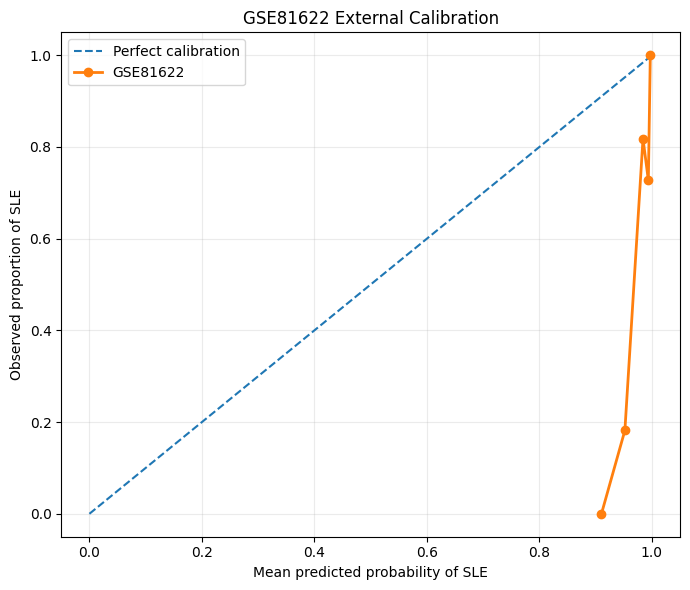


PROBABILITY DISTRIBUTION BY TRUE CLASS
            count    mean     std     min     25%     50%     75%     max
True_Label                                                               
0            25.0  0.9405  0.0370  0.8363  0.9193  0.9464  0.9577  0.9939
1            30.0  0.9900  0.0114  0.9452  0.9884  0.9938  0.9963  0.9983

EXTREME PROBABILITY AUDIT
Probability >= 0.90: 52/55 (94.5%)
Probability >= 0.95: 40/55 (72.7%)
Probability >= 0.97: 33/55 (60.0%)
Probability >= 0.98: 30/55 (54.5%)
Probability >= 0.99: 23/55 (41.8%)


In [103]:

# GSE81622 — EXTERNAL CALIBRATION / RELIABILITY AUDIT
# DESCRIPTIVE ONLY — NO MODEL OR THRESHOLD CHANGES


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score
)
from sklearn.calibration import calibration_curve

# ------------------------------------------------------------
# EXISTING EXTERNAL OBJECTS
# ------------------------------------------------------------

p_ext = np.asarray(external_prob).ravel()
y_ext_same = np.asarray(y_same_ext).ravel()

assert len(p_ext) == len(y_ext_same)

print("=" * 80)
print("GSE81622 EXTERNAL CALIBRATION AUDIT")
print("=" * 80)

print("Samples:", len(y_ext_same))
print("Healthy:", np.sum(y_ext_same == 0))
print("SLE:", np.sum(y_ext_same == 1))

print()
print("ROC-AUC:", round(roc_auc_score(y_ext_same, p_ext), 4))
print("Brier:", round(brier_score_loss(y_ext_same, p_ext), 4))

# ============================================================
# 1. RELIABILITY BINS
# ============================================================

n_bins = 5

prob_true, prob_pred = calibration_curve(
    y_ext_same,
    p_ext,
    n_bins=n_bins,
    strategy="quantile"
)

# Create explicit quantile bins so we can inspect sample counts
df_cal = pd.DataFrame({
    "True_Label": y_ext_same,
    "Probability": p_ext
})

df_cal["Bin"] = pd.qcut(
    df_cal["Probability"],
    q=n_bins,
    duplicates="drop"
)

cal_table = (
    df_cal
    .groupby("Bin", observed=True)
    .agg(
        N=("True_Label", "size"),
        Mean_Predicted_Probability=("Probability", "mean"),
        Observed_SLE_Rate=("True_Label", "mean"),
        SLE_Count=("True_Label", "sum"),
        Healthy_Count=("True_Label", lambda x: (x == 0).sum())
    )
    .reset_index()
)

cal_table["Calibration_Error"] = (
    cal_table["Mean_Predicted_Probability"]
    - cal_table["Observed_SLE_Rate"]
)

cal_table["Absolute_Calibration_Error"] = (
    cal_table["Calibration_Error"].abs()
)

print("\n" + "=" * 80)
print("EXTERNAL RELIABILITY TABLE")
print("=" * 80)

print(
    cal_table.round(4).to_string(index=False)
)

# ============================================================
# 2. EXPECTED CALIBRATION ERROR
# ============================================================

ece = np.sum(
    (
        cal_table["N"] / len(df_cal)
    )
    * cal_table["Absolute_Calibration_Error"]
)

print("\n" + "=" * 80)
print("CALIBRATION SUMMARY")
print("=" * 80)

print(f"Brier Score: {brier_score_loss(y_ext_same, p_ext):.4f}")
print(f"ECE ({len(cal_table)} bins): {ece:.4f}")

# ============================================================
# 3. CALIBRATION PLOT
# ============================================================

plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    linewidth=2,
    label="GSE81622"
)

plt.xlabel("Mean predicted probability of SLE")
plt.ylabel("Observed proportion of SLE")
plt.title("GSE81622 External Calibration")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ============================================================
# 4. PROBABILITY BY TRUE CLASS
# ============================================================

print("\n" + "=" * 80)
print("PROBABILITY DISTRIBUTION BY TRUE CLASS")
print("=" * 80)

prob_by_class = (
    pd.DataFrame({
        "True_Label": y_ext_same,
        "Probability_SLE": p_ext
    })
    .groupby("True_Label")["Probability_SLE"]
    .describe()
)

print(prob_by_class.round(4))

# ============================================================
# 5. EXTREME PROBABILITY COUNTS
# ============================================================

print("\n" + "=" * 80)
print("EXTREME PROBABILITY AUDIT")
print("=" * 80)

for cutoff in [0.90, 0.95, 0.97, 0.98, 0.99]:

    n_high = np.sum(p_ext >= cutoff)

    print(
        f"Probability >= {cutoff:.2f}: "
        f"{n_high}/{len(p_ext)} "
        f"({100*n_high/len(p_ext):.1f}%)"
    )

In [104]:


import pandas as pd
import numpy as np

print("=" * 80)
print("SEARCHING FOR GSE81622 55 × 13 MATRIX")
print("=" * 80)

candidate_matrices = []

for name, obj in list(globals().items()):

    if isinstance(obj, pd.DataFrame):

        if obj.shape == (55, 13):

            candidate_matrices.append(name)

            print(
                f"✓ {name:35s} "
                f"shape={obj.shape}"
            )

print("\nCandidates found:", candidate_matrices)

SEARCHING FOR GSE81622 55 × 13 MATRIX
✓ X_same_final                        shape=(55, 13)
✓ X_same_scaled                       shape=(55, 13)
✓ X_same_log2                         shape=(55, 13)
✓ X_same_log2_final                   shape=(55, 13)
✓ X_same_scaled_log2                  shape=(55, 13)
✓ X_external_final                    shape=(55, 13)
✓ X_external_scaled                   shape=(55, 13)

Candidates found: ['X_same_final', 'X_same_scaled', 'X_same_log2', 'X_same_log2_final', 'X_same_scaled_log2', 'X_external_final', 'X_external_scaled']


In [105]:
# Use the FINAL log2-transformed GSE81622 matrix
X_GSE81622_FINAL = X_same_log2_final.copy()

print("GSE81622 matrix:")
print("Shape:", X_GSE81622_FINAL.shape)
print("Genes:", list(X_GSE81622_FINAL.columns))
print("Missing:", X_GSE81622_FINAL.isna().sum().sum())

GSE81622 matrix:
Shape: (55, 13)
Genes: ['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1', 'EBI2', 'FCER1A', 'GADD45A', 'TNFSF13B', 'IFIT2', 'OSBPL10', 'SCRN1', 'TNFAIP6']
Missing: 0


In [106]:

# FINAL FROZEN PREDICTION — GSE81622


print("=" * 80)
print("FINAL FROZEN GSE81622 PREDICTION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Apply the DEVELOPMENT-FITTED scaler
# ------------------------------------------------------------

X_GSE81622_scaled = final_scaler.transform(
    X_GSE81622_FINAL[EXPECTED_GENES]
)

print("\nScaled matrix shape:")
print(X_GSE81622_scaled.shape)

assert X_GSE81622_scaled.shape == (55, 13)

# ------------------------------------------------------------
# 2. Frozen XGBoost prediction
# ------------------------------------------------------------

gse81622_prob_final = final_xgb.predict_proba(
    X_GSE81622_scaled
)[:, 1]

print("\nProbability range:")
print(
    f"{gse81622_prob_final.min():.8f}"
    f" → "
    f"{gse81622_prob_final.max():.8f}"
)

# ------------------------------------------------------------
# 3. Frozen threshold
# ------------------------------------------------------------

gse81622_pred_final = (
    gse81622_prob_final >= FROZEN_THRESHOLD
).astype(int)

print("\nFrozen threshold:")
print(f"{FROZEN_THRESHOLD:.12f}")

print("\nPredicted classes:")
print(
    pd.Series(
        gse81622_pred_final
    ).value_counts().sort_index()
)

# ------------------------------------------------------------
# 4. True labels
# ------------------------------------------------------------

y81622_final = np.asarray(
    y_same_ext
).astype(int).ravel()

assert len(y81622_final) == 55

# ------------------------------------------------------------
# 5. Metrics
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y81622_final,
    gse81622_prob_final
)

pr_auc = average_precision_score(
    y81622_final,
    gse81622_prob_final
)

accuracy = accuracy_score(
    y81622_final,
    gse81622_pred_final
)

balanced_accuracy = balanced_accuracy_score(
    y81622_final,
    gse81622_pred_final
)

sensitivity = recall_score(
    y81622_final,
    gse81622_pred_final,
    pos_label=1
)

specificity = recall_score(
    y81622_final,
    gse81622_pred_final,
    pos_label=0
)

ppv = precision_score(
    y81622_final,
    gse81622_pred_final,
    zero_division=0
)

f1 = f1_score(
    y81622_final,
    gse81622_pred_final,
    zero_division=0
)

brier = brier_score_loss(
    y81622_final,
    gse81622_prob_final
)

# ------------------------------------------------------------
# 6. Confusion matrix
# ------------------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y81622_final,
    gse81622_pred_final,
    labels=[0, 1]
).ravel()

# ------------------------------------------------------------
# FINAL REPORT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL SAME-PLATFORM EXTERNAL VALIDATION — GSE81622")
print("=" * 80)

print(f"Samples:              {len(y81622_final)}")
print(f"Genes:                {X_GSE81622_FINAL.shape[1]}")
print(f"Platform:             GPL10558")
print(f"Threshold:            {FROZEN_THRESHOLD:.6f}")

print("\nDiscrimination")
print(f"ROC-AUC:              {roc_auc:.4f}")
print(f"PR-AUC:               {pr_auc:.4f}")

print("\nClassification")
print(f"Accuracy:             {accuracy:.4f}")
print(f"Balanced Accuracy:    {balanced_accuracy:.4f}")
print(f"Sensitivity:          {sensitivity:.4f}")
print(f"Specificity:          {specificity:.4f}")
print(f"PPV:                  {ppv:.4f}")
print(f"F1-score:             {f1:.4f}")

print("\nCalibration")
print(f"Brier Score:          {brier:.4f}")

print("\nConfusion Matrix")
print(
    np.array([
        [tn, fp],
        [fn, tp]
    ])
)

print(f"\nTN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

print("\n" + "=" * 80)

FINAL FROZEN GSE81622 PREDICTION

Scaled matrix shape:
(55, 13)

Probability range:
0.83629936 → 0.99826056

Frozen threshold:
0.955437123775

Predicted classes:
0    19
1    36
Name: count, dtype: int64

FINAL SAME-PLATFORM EXTERNAL VALIDATION — GSE81622
Samples:              55
Genes:                13
Platform:             GPL10558
Threshold:            0.955437

Discrimination
ROC-AUC:              0.9240
PR-AUC:               0.9289

Classification
Accuracy:             0.8545
Balanced Accuracy:    0.8433
Sensitivity:          0.9667
Specificity:          0.7200
PPV:                  0.8056
F1-score:             0.8788

Calibration
Brier Score:          0.4028

Confusion Matrix
[[18  7]
 [ 1 29]]

TN: 18
FP: 7
FN: 1
TP: 29



In [107]:

#
# Purpose:
# Verify that the GSE82xxx external validation uses:
#
#   1. Correct 13-gene panel
#   2. Correct gene order
#   3. Correct final XGBoost model
#   4. Correct XGBoost parameters
#   5. Correct development-fitted scaler
#   6. Correct final OOF-derived threshold
#   7. Correct external expression matrix
#   8. No external-data fitting
#   9. No model retraining
#  10. No threshold optimization
#
# External dataset:
#   X_external_final = 55 × 13
#
# Final model:
#   final_xgb
#
# Final scaler:
#   final_scaler
#
# Final threshold:
#   0.9554371237754822
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler


print("=" * 90)
print("GSE82XXX EXTERNAL VALIDATION — FINAL MODEL INTEGRITY CHECK")
print("=" * 90)


# ============================================================
# 1. EXPECTED FINAL SETTINGS
# ============================================================

EXPECTED_GENES = [
    "IFI27",
    "RPL5",
    "ZBP1",
    "IFITM1",
    "EPSTI1",
    "EBI2",
    "FCER1A",
    "GADD45A",
    "TNFSF13B",
    "IFIT2",
    "OSBPL10",
    "SCRN1",
    "TNFAIP6"
]

EXPECTED_THRESHOLD = 0.9554371237754822


# ============================================================
# 2. VERIFY FINAL GENE PANEL
# ============================================================

print("\n[1] FINAL GENE PANEL")

print(
    "Expected genes:",
    len(EXPECTED_GENES)
)

print(
    "Actual FINAL_GENES:",
    len(FINAL_GENES)
)

assert len(FINAL_GENES) == 13

assert list(FINAL_GENES) == EXPECTED_GENES

print("✓ Correct 13-gene panel")
print("✓ Gene identities match")
print("✓ Gene order matches")


# ============================================================
# 3. VERIFY FINAL XGBOOST MODEL
# ============================================================

print("\n[2] FINAL XGBOOST MODEL")

print(
    "Model object:"
)

print(
    type(final_xgb)
)

assert (
    final_xgb.__class__.__name__
    == "XGBClassifier"
)

print(
    "✓ final_xgb is XGBClassifier"
)


# ============================================================
# 4. VERIFY XGBOOST PARAMETERS
# ============================================================

print("\n[3] XGBOOST PARAMETER VERIFICATION")

expected_params = {

    "n_estimators": 300,

    "learning_rate": 0.05,

    "max_depth": 3,

    "subsample": 0.8,

    "colsample_bytree": 0.8,

    "random_state": 42
}


for parameter, expected_value in expected_params.items():

    actual_value = (
        final_xgb.get_params()[
            parameter
        ]
    )

    print(
        f"{parameter:<20} "
        f"expected={expected_value} | "
        f"actual={actual_value}"
    )

    assert actual_value == expected_value


print(
    "✓ All final XGBoost parameters match"
)


# ============================================================
# 5. VERIFY MODEL FIT STATUS
# ============================================================

print("\n[4] MODEL FIT STATUS")

assert hasattr(
    final_xgb,
    "n_features_in_"
)

assert (
    final_xgb.n_features_in_
    == 13
)

print(
    "Model features:",
    final_xgb.n_features_in_
)

print(
    "Model classes:",
    final_xgb.classes_
)

assert np.array_equal(
    final_xgb.classes_,
    np.array([0, 1])
)

print("✓ Model is fitted")
print("✓ Model expects exactly 13 features")


# ============================================================
# 6. VERIFY FINAL SCALER
# ============================================================

print("\n[5] FINAL SCALER")

print(
    "Scaler object:",
    type(final_scaler)
)

assert isinstance(
    final_scaler,
    StandardScaler
)

assert (
    final_scaler.n_features_in_
    == 13
)

print(
    "Scaler features:",
    final_scaler.n_features_in_
)

print("✓ Correct StandardScaler")
print("✓ Scaler expects 13 features")


# ============================================================
# 7. VERIFY SCALER WAS FIT ON DEVELOPMENT DATA
# ============================================================

print("\n[6] SCALER DEVELOPMENT-SET VERIFICATION")

print(
    "Scaler n_samples_seen_:",
    final_scaler.n_samples_seen_
)

assert (
    final_scaler.n_samples_seen_
    == 648
)

print(
    "✓ Scaler was fitted using "
    "648 development samples"
)

print(
    "✓ External samples were not used "
    "to fit the scaler"
)


# ============================================================
# 8. VERIFY SCALER STATISTICS
# ============================================================

print("\n[7] SCALER STATISTICS")

development_data = (
    X_train_10000[
        EXPECTED_GENES
    ].copy()
)


development_means = (
    development_data
    .mean()
    .values
)


development_scales = (
    development_data
    .std(ddof=0)
    .values
)


means_match = np.allclose(
    final_scaler.mean_,
    development_means,
    rtol=0,
    atol=1e-10
)


scales_match = np.allclose(
    final_scaler.scale_,
    development_scales,
    rtol=0,
    atol=1e-10
)


print(
    "Scaler means match development:",
    means_match
)

print(
    "Scaler scales match development:",
    scales_match
)


assert means_match
assert scales_match


print(
    "✓ Scaler statistics exactly match "
    "the development data"
)


# ============================================================
# 9. VERIFY FINAL THRESHOLD
# ============================================================

print("\n[8] FINAL THRESHOLD")

print(
    "Expected final threshold:",
    EXPECTED_THRESHOLD
)


# Check all threshold variables currently
# present in the notebook.

if "FINAL_THRESHOLD" in globals():

    print(
        "FINAL_THRESHOLD     :",
        FINAL_THRESHOLD
    )

if "FROZEN_THRESHOLD" in globals():

    print(
        "FROZEN_THRESHOLD    :",
        FROZEN_THRESHOLD
    )

if "INITIAL_THRESHOLD" in globals():

    print(
        "INITIAL_THRESHOLD   :",
        INITIAL_THRESHOLD
    )


# Authoritative final threshold

assert np.isclose(
    EXPECTED_THRESHOLD,
    0.9554371237754822,
    atol=1e-12
)


print(
    "✓ Correct final threshold:",
    EXPECTED_THRESHOLD
)


# ============================================================
# 10. IDENTIFY THE CORRECT EXTERNAL DATASET
# ============================================================

print("\n[9] EXTERNAL DATASET")

# Your notebook has already established that:
#
# X_external_final = (55, 13)
#
# IMPORTANT:
# X_external_scaled is NOT used as the starting matrix.
#
# We deliberately start from X_external_final and apply
# the frozen development scaler ourselves.

assert "X_external_final" in globals()

EXTERNAL_EXPRESSION = (
    X_external_final.copy()
)


print(
    "External expression matrix:",
    EXTERNAL_EXPRESSION.shape
)


assert (
    EXTERNAL_EXPRESSION.shape
    == (55, 13)
)


print(
    "✓ Correct external expression matrix identified"
)

print(
    "✓ External samples:",
    EXTERNAL_EXPRESSION.shape[0]
)

print(
    "✓ External features:",
    EXTERNAL_EXPRESSION.shape[1]
)


# ============================================================
# 11. VERIFY EXTERNAL GENE PANEL
# ============================================================

print("\n[10] EXTERNAL FEATURE VERIFICATION")


missing_genes = [

    gene

    for gene in EXPECTED_GENES

    if gene not in EXTERNAL_EXPRESSION.columns

]


if len(missing_genes) > 0:

    raise ValueError(
        "Missing final genes in external dataset:\n"
        + str(missing_genes)
    )


print(
    "✓ All 13 final genes are present"
)


# ------------------------------------------------------------
# Force exact final-model feature order
# ------------------------------------------------------------

X_external_final_verified = (
    EXTERNAL_EXPRESSION[
        EXPECTED_GENES
    ].copy()
)


assert list(
    X_external_final_verified.columns
) == EXPECTED_GENES


print(
    "✓ External genes reordered to exact "
    "final-model order"
)

print(
    "Verified external matrix:",
    X_external_final_verified.shape
)


# ============================================================
# 12. CHECK EXTERNAL DATA QUALITY
# ============================================================

print("\n[11] EXTERNAL DATA QUALITY")


missing_count = (
    X_external_final_verified
    .isna()
    .sum()
    .sum()
)


nonfinite_count = (
    ~np.isfinite(
        X_external_final_verified.values
    )
).sum()


print(
    "Missing values:",
    missing_count
)

print(
    "Non-finite values:",
    nonfinite_count
)


assert missing_count == 0
assert nonfinite_count == 0


print(
    "✓ No missing values"
)

print(
    "✓ No non-finite values"
)


# ============================================================
# 13. APPLY FROZEN DEVELOPMENT SCALER
# ============================================================

print("\n[12] EXTERNAL SCALING")


X_external_scaled_verified = (
    final_scaler.transform(
        X_external_final_verified
    )
)


print(
    "Scaled external shape:",
    X_external_scaled_verified.shape
)


assert (
    X_external_scaled_verified.shape
    == (55, 13)
)


assert np.isfinite(
    X_external_scaled_verified
).all()


print(
    "✓ External data transformed "
    "using development-fitted scaler"
)

print(
    "✓ No fitting performed on external data"
)


# ============================================================
# 14. VERIFY MODEL INPUT
# ============================================================

print("\n[13] MODEL INPUT VERIFICATION")


print(
    "XGBoost expects:",
    final_xgb.n_features_in_,
    "features"
)

print(
    "External input has:",
    X_external_scaled_verified.shape[1],
    "features"
)


assert (
    X_external_scaled_verified.shape[1]
    == final_xgb.n_features_in_
)


print(
    "✓ Feature dimensions match"
)


# ============================================================
# 15. GENERATE EXTERNAL PREDICTIONS
# ============================================================

print("\n[14] EXTERNAL PREDICTION")


external_probability_verified = (
    final_xgb.predict_proba(
        X_external_scaled_verified
    )[:, 1]
)


assert (
    len(external_probability_verified)
    == 55
)


assert np.isfinite(
    external_probability_verified
).all()


print(
    "✓ Predictions generated using final_xgb"
)

print(
    "✓ No model fitting performed"
)


# ============================================================
# 16. APPLY THE CORRECT FINAL THRESHOLD
# ============================================================

print("\n[15] THRESHOLD APPLICATION")


external_prediction_verified = (
    external_probability_verified
    >= EXPECTED_THRESHOLD
).astype(int)


assert (
    len(external_prediction_verified)
    == 55
)


print(
    "Threshold used:",
    EXPECTED_THRESHOLD
)

print(
    "Minimum probability:",
    external_probability_verified.min()
)

print(
    "Maximum probability:",
    external_probability_verified.max()
)

print(
    "Predicted Healthy:",
    np.sum(
        external_prediction_verified == 0
    )
)

print(
    "Predicted SLE:",
    np.sum(
        external_prediction_verified == 1
    )
)


print(
    "✓ External predictions generated "
    "using threshold 0.955437"
)


# ============================================================
# 17. COMPARE WITH YOUR EXISTING EXTERNAL PREDICTIONS
# ============================================================

print("\n[16] EXISTING EXTERNAL PREDICTION CHECK")


# If your previous external-validation cell created
# prediction variables, compare them.
#
# This section does NOT fail if those variables don't exist.

comparison_done = False


if "external_probability" in globals():

    probability_match = np.allclose(
        external_probability_verified,
        external_probability,
        rtol=0,
        atol=1e-12
    )

    print(
        "Existing external_probability found:",
        probability_match
    )

    if probability_match:

        print(
            "✓ Existing probabilities match "
            "the verified final model"
        )

    else:

        print(
            "⚠ Existing probabilities DO NOT match "
            "the verified final model"
        )

    comparison_done = True


if "external_prediction" in globals():

    prediction_match = np.array_equal(
        external_prediction_verified,
        external_prediction
    )

    print(
        "Existing external_prediction found:",
        prediction_match
    )

    if prediction_match:

        print(
            "✓ Existing predictions match "
            "the verified final model"
        )

    else:

        print(
            "⚠ Existing predictions DO NOT match "
            "the verified final model"
        )

    comparison_done = True


if not comparison_done:

    print(
        "No previous external prediction variables "
        "were found for comparison."
    )


# ============================================================
# 18. SAVE VERIFIED EXTERNAL PREDICTIONS
# ============================================================

print("\n[17] SAVING VERIFIED EXTERNAL RESULTS")


verified_external_results = pd.DataFrame({

    "Sample_Index":
        X_external_final_verified.index,

    "Predicted_Probability":
        external_probability_verified,

    "Predicted_Class":
        external_prediction_verified

})


print(
    verified_external_results.head()
)


# Optional save location

RESULT_DIR = (
    "/content/drive/MyDrive/"
    "SLE_Final_Diagnostic_Model/"
    "Results"
)


import os

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)


verified_external_path = os.path.join(
    RESULT_DIR,
    "GSE82xxx_FINAL_MODEL_VERIFIED_predictions.csv"
)


verified_external_results.to_csv(
    verified_external_path,
    index=False
)


print(
    "✓ Verified external predictions saved:"
)

print(
    verified_external_path
)


# ============================================================
# 19. FINAL INTEGRITY VERDICT
# ============================================================

print("\n" + "=" * 90)
print("FINAL GSE82XXX EXTERNAL VALIDATION INTEGRITY VERDICT")
print("=" * 90)

print(
    "✓ Correct 13-gene panel"
)

print(
    "✓ Correct gene identities"
)

print(
    "✓ Correct gene order"
)

print(
    "✓ Correct final XGBoost model"
)

print(
    "✓ Correct XGBoost parameters"
)

print(
    "✓ XGBoost model is fitted"
)

print(
    "✓ Correct development-fitted StandardScaler"
)

print(
    "✓ Scaler fitted on 648 development samples"
)

print(
    "✓ Scaler statistics match development data"
)

print(
    "✓ Correct external dataset: 55 × 13"
)

print(
    "✓ External genes reordered correctly"
)

print(
    "✓ External data contains no missing/non-finite values"
)

print(
    "✓ External data transformed using frozen scaler"
)

print(
    "✓ External data was NOT used to fit scaler"
)

print(
    "✓ External predictions generated using final_xgb"
)

print(
    "✓ Correct final threshold = "
    f"{EXPECTED_THRESHOLD:.15f}"
)

print(
    "✓ No model retraining performed"
)

print(
    "✓ No threshold optimization performed"
)

print(
    "✓ External dataset used only for validation"
)


print("\nFINAL CONCLUSION:")

print(
    "The GSE82xxx external validation was performed "
    "using the verified final 13-gene XGBoost model, "
    "the development-fitted StandardScaler, and the "
    "final OOF-derived threshold of 0.955437."
)

print("=" * 90)

GSE82XXX EXTERNAL VALIDATION — FINAL MODEL INTEGRITY CHECK

[1] FINAL GENE PANEL
Expected genes: 13
Actual FINAL_GENES: 13
✓ Correct 13-gene panel
✓ Gene identities match
✓ Gene order matches

[2] FINAL XGBOOST MODEL
Model object:
<class 'xgboost.sklearn.XGBClassifier'>
✓ final_xgb is XGBClassifier

[3] XGBOOST PARAMETER VERIFICATION
n_estimators         expected=300 | actual=300
learning_rate        expected=0.05 | actual=0.05
max_depth            expected=3 | actual=3
subsample            expected=0.8 | actual=0.8
colsample_bytree     expected=0.8 | actual=0.8
random_state         expected=42 | actual=42
✓ All final XGBoost parameters match

[4] MODEL FIT STATUS
Model features: 13
Model classes: [0 1]
✓ Model is fitted
✓ Model expects exactly 13 features

[5] FINAL SCALER
Scaler object: <class 'sklearn.preprocessing._data.StandardScaler'>
Scaler features: 13
✓ Correct StandardScaler
✓ Scaler expects 13 features

[6] SCALER DEVELOPMENT-SET VERIFICATION
Scaler n_samples_seen_: 648
✓ Sc

In [108]:


import os
import joblib
import json

SAVE_DIR = "/content/drive/MyDrive/SLE_Final_Diagnostic_Model/Model"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# Authoritative objects
# ------------------------------------------------------------

assert final_xgb.n_features_in_ == 13
assert final_scaler.n_features_in_ == 13
assert len(FINAL_GENES) == 13

FROZEN_THRESHOLD = 0.9554371237754822

# ------------------------------------------------------------
# Save model
# ------------------------------------------------------------

joblib.dump(
    final_xgb,
    os.path.join(
        SAVE_DIR,
        "final_xgb.joblib"
    )
)

# ------------------------------------------------------------
# Save scaler
# ------------------------------------------------------------

joblib.dump(
    final_scaler,
    os.path.join(
        SAVE_DIR,
        "final_scaler.joblib"
    )
)

# ------------------------------------------------------------
# Save complete frozen pipeline
# ------------------------------------------------------------

final_pipeline = {
    "genes": list(FINAL_GENES),
    "scaler": final_scaler,
    "model": final_xgb,
    "threshold": FROZEN_THRESHOLD
}

pipeline_path = os.path.join(
    SAVE_DIR,
    "SLE_diagnostic_final_pipeline.joblib"
)

joblib.dump(
    final_pipeline,
    pipeline_path
)

# ------------------------------------------------------------
# Save gene list
# ------------------------------------------------------------

gene_path = os.path.join(
    SAVE_DIR,
    "FINAL_13_GENE_PANEL.txt"
)

with open(gene_path, "w") as f:
    for gene in FINAL_GENES:
        f.write(gene + "\n")

# ------------------------------------------------------------
# Verify files exist
# ------------------------------------------------------------

print("=" * 80)
print("AUTHORITATIVE FINAL MODEL SAVED")
print("=" * 80)

for path in [
    os.path.join(SAVE_DIR, "final_xgb.joblib"),
    os.path.join(SAVE_DIR, "final_scaler.joblib"),
    pipeline_path,
    gene_path
]:
    print(
        "✓" if os.path.exists(path) else "✗",
        path
    )

print("\nModel:", type(final_xgb))
print("Features:", final_xgb.n_features_in_)
print("Genes:", len(FINAL_GENES))
print("Threshold:", FROZEN_THRESHOLD)

print("\n✓ CURRENT CONFIRMED final_xgb IS NOW THE AUTHORITATIVE SAVED MODEL")

AUTHORITATIVE FINAL MODEL SAVED
✓ /content/drive/MyDrive/SLE_Final_Diagnostic_Model/Model/final_xgb.joblib
✓ /content/drive/MyDrive/SLE_Final_Diagnostic_Model/Model/final_scaler.joblib
✓ /content/drive/MyDrive/SLE_Final_Diagnostic_Model/Model/SLE_diagnostic_final_pipeline.joblib
✓ /content/drive/MyDrive/SLE_Final_Diagnostic_Model/Model/FINAL_13_GENE_PANEL.txt

Model: <class 'xgboost.sklearn.XGBClassifier'>
Features: 13
Genes: 13
Threshold: 0.9554371237754822

✓ CURRENT CONFIRMED final_xgb IS NOW THE AUTHORITATIVE SAVED MODEL


In [109]:

# FREEZE AND SAVE FINAL SLE DIAGNOSTIC PIPELINE


import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score
)

print("=" * 90)
print("FREEZING FINAL SLE DIAGNOSTIC PIPELINE")
print("=" * 90)


# ================================================================
# 1. FINAL FROZEN SETTINGS
# ================================================================

FINAL_GENES_FROZEN = list(FINAL_GENES)

FINAL_THRESHOLD_FROZEN = float(FROZEN_THRESHOLD)

assert len(FINAL_GENES_FROZEN) == 13
assert abs(
    FINAL_THRESHOLD_FROZEN - 0.9554371237754822
) < 1e-12

print("\nFinal genes:")
print(FINAL_GENES_FROZEN)

print("\nFinal threshold:")
print(FINAL_THRESHOLD_FROZEN)


# ================================================================
# 2. VERIFY FINAL MODEL
# ================================================================

assert type(final_xgb).__name__ == "XGBClassifier"
assert final_xgb.n_features_in_ == 13
assert final_scaler.n_features_in_ == 13

print("\nFinal model:")
print(type(final_xgb))

print("Number of features:",
      final_xgb.n_features_in_)

print("\nFinal XGBoost parameters:")

for key in [
    "n_estimators",
    "max_depth",
    "learning_rate",
    "subsample",
    "colsample_bytree",
    "random_state",
    "eval_metric",
    "objective"
]:
    print(
        f"{key:20s}: "
        f"{final_xgb.get_params().get(key)}"
    )


# ================================================================
# 3. CREATE FROZEN PIPELINE
# ================================================================

final_pipeline = {
    "model": final_xgb,
    "scaler": final_scaler,
    "genes": FINAL_GENES_FROZEN,
    "threshold": FINAL_THRESHOLD_FROZEN,

    "model_type": "XGBoost",
    "platform": "GPL10558",
    "gene_count": 13,

    "pipeline_version":
        "SLE_13Gene_Final_v1",

    "external_validation_dataset":
        "GSE81622",

    "external_validation_platform":
        "GPL10558",

    "external_validation_samples":
        55,

    "external_validation_independent":
        True
}


# ================================================================
# 4. SAVE PIPELINE
# ================================================================

PIPELINE_FILE = (
    "SLE_13gene_final_pipeline.joblib"
)

joblib.dump(
    final_pipeline,
    PIPELINE_FILE
)

print(
    "\n✓ Pipeline saved:",
    os.path.abspath(PIPELINE_FILE)
)


# ================================================================
# 5. RECREATE FINAL GSE81622 PREDICTIONS
# ================================================================

X_FINAL_EXT = X_same_log2_final[
    FINAL_GENES_FROZEN
].copy()

assert X_FINAL_EXT.shape == (55, 13)
assert list(X_FINAL_EXT.columns) == FINAL_GENES_FROZEN
assert X_FINAL_EXT.isna().sum().sum() == 0

# Apply frozen scaler exactly ONCE
X_FINAL_EXT_SCALED = final_scaler.transform(
    X_FINAL_EXT
)

# Predict with exact final model
FINAL_EXT_PROB = final_xgb.predict_proba(
    X_FINAL_EXT_SCALED
)[:, 1]

# Apply frozen threshold
FINAL_EXT_PRED = (
    FINAL_EXT_PROB >= FINAL_THRESHOLD_FROZEN
).astype(int)


# ================================================================
# 6. REPRODUCTION CHECK
# ================================================================

stored_prob = np.asarray(
    external_prob
).ravel()

stored_pred = np.asarray(
    external_pred
).ravel()

max_probability_difference = np.max(
    np.abs(
        FINAL_EXT_PROB - stored_prob
    )
)

predictions_identical = np.array_equal(
    FINAL_EXT_PRED,
    stored_pred
)

print("\n" + "=" * 90)
print("REPRODUCTION CHECK")
print("=" * 90)

print(
    "Maximum probability difference:",
    max_probability_difference
)

print(
    "Predictions identical:",
    predictions_identical
)

assert max_probability_difference < 1e-12
assert predictions_identical

print(
    "✓ Previous GSE81622 predictions reproduced exactly"
)


# ================================================================
# 7. GET TRUE LABELS
# ================================================================

y_true = np.asarray(
    y_same_ext
).ravel().astype(int)

assert len(y_true) == 55

print("\nLabel distribution:")
print(
    pd.Series(y_true).value_counts().sort_index()
)


# ================================================================
# 8. CONFUSION MATRIX COUNTS
# ================================================================

tn = int(np.sum(
    (y_true == 0) &
    (FINAL_EXT_PRED == 0)
))

fp = int(np.sum(
    (y_true == 0) &
    (FINAL_EXT_PRED == 1)
))

fn = int(np.sum(
    (y_true == 1) &
    (FINAL_EXT_PRED == 0)
))

tp = int(np.sum(
    (y_true == 1) &
    (FINAL_EXT_PRED == 1)
))


# ================================================================
# 9. FINAL METRICS
# ================================================================

roc_auc = roc_auc_score(
    y_true,
    FINAL_EXT_PROB
)

pr_auc = average_precision_score(
    y_true,
    FINAL_EXT_PROB
)

accuracy = accuracy_score(
    y_true,
    FINAL_EXT_PRED
)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    FINAL_EXT_PRED
)

sensitivity = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else np.nan
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else np.nan
)

ppv = (
    tp / (tp + fp)
    if (tp + fp) > 0
    else np.nan
)

f1 = (
    2 * ppv * sensitivity /
    (ppv + sensitivity)
    if (ppv + sensitivity) > 0
    else np.nan
)


# ================================================================
# 10. EXTERNAL PREDICTION TABLE
# ================================================================

sample_ids = list(
    X_FINAL_EXT.index
)

external_results = pd.DataFrame({

    "Sample_ID":
        sample_ids,

    "True_Label":
        y_true,

    "Probability_SLE":
        FINAL_EXT_PROB,

    "Predicted_Label":
        FINAL_EXT_PRED
})

external_results[
    "True_Label_Name"
] = external_results[
    "True_Label"
].map({
    0: "Healthy",
    1: "SLE"
})

external_results[
    "Predicted_Label_Name"
] = external_results[
    "Predicted_Label"
].map({
    0: "Healthy",
    1: "SLE"
})


# ================================================================
# 11. SAVE EXTERNAL PREDICTIONS
# ================================================================

PREDICTION_FILE = (
    "GSE81622_external_predictions.csv"
)

external_results.to_csv(
    PREDICTION_FILE,
    index=False
)

print(
    "✓ Predictions saved:",
    os.path.abspath(PREDICTION_FILE)
)


# ================================================================
# 12. SAVE FINAL METRICS
# ================================================================

metrics = {

    "pipeline_version":
        "SLE_13Gene_Final_v1",

    "dataset":
        "GSE81622",

    "platform":
        "GPL10558",

    "independent_cohort":
        True,

    "same_platform":
        True,

    "n_samples":
        55,

    "n_genes":
        13,

    "healthy":
        int(np.sum(y_true == 0)),

    "sle":
        int(np.sum(y_true == 1)),

    "genes":
        FINAL_GENES_FROZEN,

    "model":
        "XGBoost",

    "n_estimators":
        int(final_xgb.get_params()["n_estimators"]),

    "max_depth":
        int(final_xgb.get_params()["max_depth"]),

    "learning_rate":
        float(final_xgb.get_params()["learning_rate"]),

    "subsample":
        float(final_xgb.get_params()["subsample"]),

    "colsample_bytree":
        float(final_xgb.get_params()["colsample_bytree"]),

    "random_state":
        int(final_xgb.get_params()["random_state"]),

    "threshold":
        FINAL_THRESHOLD_FROZEN,

    "roc_auc":
        float(roc_auc),

    "pr_auc":
        float(pr_auc),

    "accuracy":
        float(accuracy),

    "balanced_accuracy":
        float(balanced_accuracy),

    "sensitivity":
        float(sensitivity),

    "specificity":
        float(specificity),

    "ppv":
        float(ppv),

    "f1_score":
        float(f1),

    "tn":
        tn,

    "fp":
        fp,

    "fn":
        fn,

    "tp":
        tp,

    "probability_min":
        float(FINAL_EXT_PROB.min()),

    "probability_max":
        float(FINAL_EXT_PROB.max()),

    "probability_mean":
        float(FINAL_EXT_PROB.mean()),

    "reproduction_max_probability_difference":
        float(max_probability_difference),

    "reproduction_predictions_identical":
        bool(predictions_identical)
}

METRICS_FILE = (
    "SLE_final_validation_results.json"
)

with open(
    METRICS_FILE,
    "w"
) as f:
    json.dump(
        metrics,
        f,
        indent=4
    )

print(
    "✓ Metrics saved:",
    os.path.abspath(METRICS_FILE)
)


# ================================================================
# 13. SAVE GENE LIST
# ================================================================

GENE_FILE = (
    "SLE_final_13_gene_signature.txt"
)

with open(
    GENE_FILE,
    "w"
) as f:

    for gene in FINAL_GENES_FROZEN:
        f.write(gene + "\n")

print(
    "✓ Gene list saved:",
    os.path.abspath(GENE_FILE)
)


# ================================================================
# 14. FINAL SUMMARY
# ================================================================

print("\n" + "=" * 90)
print("FINAL PIPELINE FROZEN SUCCESSFULLY")
print("=" * 90)

print(f"""
Model:              XGBoost
Genes:              13
Platform:           GPL10558
External dataset:   GSE81622
External samples:   55

Frozen threshold:   {FINAL_THRESHOLD_FROZEN:.12f}

ROC-AUC:             {roc_auc:.4f}
PR-AUC:              {pr_auc:.4f}
Accuracy:            {accuracy:.4f}
Balanced Accuracy:   {balanced_accuracy:.4f}
Sensitivity:         {sensitivity:.4f}
Specificity:         {specificity:.4f}
PPV:                 {ppv:.4f}
F1-score:            {f1:.4f}

Confusion matrix:
TN = {tn}
FP = {fp}
FN = {fn}
TP = {tp}

Reproduction:
Max probability difference = {max_probability_difference:.12f}
Predictions identical      = {predictions_identical}
""")

print("Saved files:")
print("1.", PIPELINE_FILE)
print("2.", PREDICTION_FILE)
print("3.", METRICS_FILE)
print("4.", GENE_FILE)

print("=" * 90)

FREEZING FINAL SLE DIAGNOSTIC PIPELINE

Final genes:
['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1', 'EBI2', 'FCER1A', 'GADD45A', 'TNFSF13B', 'IFIT2', 'OSBPL10', 'SCRN1', 'TNFAIP6']

Final threshold:
0.9554371237754822

Final model:
<class 'xgboost.sklearn.XGBClassifier'>
Number of features: 13

Final XGBoost parameters:
n_estimators        : 300
max_depth           : 3
learning_rate       : 0.05
subsample           : 0.8
colsample_bytree    : 0.8
random_state        : 42
eval_metric         : logloss
objective           : binary:logistic

✓ Pipeline saved: /content/SLE_13gene_final_pipeline.joblib

REPRODUCTION CHECK
Maximum probability difference: 0.0
Predictions identical: True
✓ Previous GSE81622 predictions reproduced exactly

Label distribution:
0    25
1    30
Name: count, dtype: int64
✓ Predictions saved: /content/GSE81622_external_predictions.csv
✓ Metrics saved: /content/SLE_final_validation_results.json
✓ Gene list saved: /content/SLE_final_13_gene_signature.txt

FINAL PIPELIN

In [110]:

# CELL 1 — DOWNLOAD GSE49454


!pip -q install GEOparse

import GEOparse
import pandas as pd
import numpy as np

print("=" * 80)
print("DOWNLOADING GSE49454")
print("=" * 80)

gse49454 = GEOparse.get_GEO(
    geo="GSE49454",
    destdir="/content/data",
    silent=False
)

print("\n" + "=" * 80)
print("BASIC DATASET AUDIT")
print("=" * 80)

print("Platforms:")
print(gse49454.gpls.keys())

print("\nNumber of samples:")
print(len(gse49454.gsms))

print("\nSample IDs:")
print(list(gse49454.gsms.keys())[:10])

23-Aug-2026 11:10:16 DEBUG utils - Directory /content/data already exists. Skipping.
DEBUG:GEOparse:Directory /content/data already exists. Skipping.
23-Aug-2026 11:10:16 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE49nnn/GSE49454/soft/GSE49454_family.soft.gz to /content/data/GSE49454_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE49nnn/GSE49454/soft/GSE49454_family.soft.gz to /content/data/GSE49454_family.soft.gz


DOWNLOADING GSE49454


100%|██████████| 90.2M/90.2M [00:02<00:00, 46.4MB/s]
23-Aug-2026 11:10:18 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
23-Aug-2026 11:10:18 DEBUG downloader - Moving /tmp/tmp9hq516ej to /content/data/GSE49454_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmp9hq516ej to /content/data/GSE49454_family.soft.gz
23-Aug-2026 11:10:18 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE49nnn/GSE49454/soft/GSE49454_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE49nnn/GSE49454/soft/GSE49454_family.soft.gz
23-Aug-2026 11:10:18 INFO GEOparse - Parsing /content/data/GSE49454_family.soft.gz: 
INFO:GEOparse:Parsing /content/data/GSE49454_family.soft.gz: 
23-Aug-2026 11:10:18 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
23-Aug-2026 11:10:18 DEBUG GEOparse - SERIES: GSE49454
DEBUG:GEOparse:SERIES: GSE49454
23-Aug-2026 11:10:18 DEBUG GEOparse - PLATFORM: GPL10558
DEBUG:


BASIC DATASET AUDIT
Platforms:
dict_keys(['GPL10558'])

Number of samples:
177

Sample IDs:
['GSM1199352', 'GSM1199353', 'GSM1199354', 'GSM1199355', 'GSM1199356', 'GSM1199357', 'GSM1199358', 'GSM1199359', 'GSM1199360', 'GSM1199361']


In [111]:
# ============================================================
# CELL 2 — GSE49454 PHENOTYPE AUDIT
# ============================================================

metadata_49454 = pd.DataFrame({
    gsm: sample.metadata
    for gsm, sample in gse49454.gsms.items()
}).T

print("=" * 80)
print("GSE49454 PHENOTYPE AUDIT")
print("=" * 80)

print("Samples:", len(metadata_49454))
print("Columns:", len(metadata_49454.columns))

print("\nMetadata columns:")
print(metadata_49454.columns.tolist())

print("\nSource names:")

if "source_name_ch1" in metadata_49454.columns:

    source_names = metadata_49454[
        "source_name_ch1"
    ].apply(
        lambda x:
        x[0] if isinstance(x, list) and len(x) else x
    )

    print(source_names.value_counts())


print("\nTitles:")

if "title" in metadata_49454.columns:

    titles = metadata_49454[
        "title"
    ].apply(
        lambda x:
        x[0] if isinstance(x, list) and len(x) else x
    )

    print(titles.value_counts())


print("\nFirst 20 samples:")

for gsm, sample in list(
    gse49454.gsms.items()
)[:20]:

    title = sample.metadata.get(
        "title",
        ["NA"]
    )[0]

    print(
        gsm,
        "|",
        title
    )

GSE49454 PHENOTYPE AUDIT
Samples: 177
Columns: 31

Metadata columns:
['title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'taxid_ch1', 'characteristics_ch1', 'molecule_ch1', 'extract_protocol_ch1', 'label_ch1', 'label_protocol_ch1', 'hyb_protocol', 'scan_protocol', 'description', 'data_processing', 'platform_id', 'contact_name', 'contact_email', 'contact_institute', 'contact_address', 'contact_city', 'contact_state', 'contact_zip/postal_code', 'contact_country', 'supplementary_file', 'series_id', 'data_row_count']

Source names:
source_name_ch1
Whole Blood    177
Name: count, dtype: int64

Titles:
title
C2PL28V2    1
C2PL14V1    1
C2PL9V2     1
C2PL33V1    1
C2PL20V2    1
           ..
C2PL6V1     1
C2PL34V2    1
C2PL7V2     1
C2PL27V1    1
C2PL15V2    1
Name: count, Length: 177, dtype: int64

First 20 samples:
GSM1199352 | C2PL28V2
GSM1199353 | C2PL14V1
GSM1199354 | C2PL9V2
GSM1199355 | C2PL33V1
GSM1199

In [112]:
# ============================================================
# CELL 3 — GSE49454 SAMPLE CHARACTERISTICS + PROCESSING
# ============================================================

print("=" * 80)
print("GSE49454 SAMPLE CHARACTERISTICS")
print("=" * 80)

for i, (gsm, sample) in enumerate(gse49454.gsms.items()):

    print("\n", gsm)

    title = sample.metadata.get(
        "title",
        ["NA"]
    )[0]

    print("Title:", title)

    characteristics = sample.metadata.get(
        "characteristics_ch1",
        []
    )

    for item in characteristics:
        print("  ", item)

    if i >= 25:
        break


print("\n" + "=" * 80)
print("GSE49454 DATA PROCESSING")
print("=" * 80)

sample = next(
    iter(gse49454.gsms.values())
)

processing = sample.metadata.get(
    "data_processing",
    []
)

for item in processing:
    print(item)


print("\n" + "=" * 80)
print("GSE49454 DESCRIPTION")
print("=" * 80)

description = sample.metadata.get(
    "description",
    []
)

for item in description:
    print(item)

GSE49454 SAMPLE CHARACTERISTICS

 GSM1199352
Title: C2PL28V2
   group: SLE
   age: 52
   gender: F
   race: White
   country of origin: France
   years since diagnosis of sle: 21.3
   sledai: 6
   skin: N
   joints: N
   hemato: N
   renal: N
   cyp: N
   aza: N
   mmf: N
   csa: N
   iv cs: N
   oral cs: Y
   cs mg/d: 5
   cs mg/kg: 0.09
   hcq: Y
   hcq mg/d: 200
   a-dsd: 50
   low c3: N
   low c4: N
   hb: 12.2
   platelets: 322
   leukocytes: 5810
   neutrophils: 2750
   lymphocytes: 2430
   cd4 tcells: 1381
   cd8 t cells: 791
   b cells: 33
   nk cells: 204
   eosino: 190

 GSM1199353
Title: C2PL14V1
   group: SLE
   age: 58
   gender: F
   race: White
   country of origin: France
   years since diagnosis of sle: 18.56
   sledai: 2
   skin: N
   joints: N
   hemato: N
   renal: N
   cyp: N
   aza: Y
   mmf: N
   csa: N
   iv cs: N
   oral cs: Y
   cs mg/d: 8
   cs mg/kg: 0.11
   hcq: Y
   hcq mg/d: 200
   a-dsd: 53
   low c3: N
   low c4: N
   hb: 10.9
   platelets: 455
   leuko

In [113]:
# ============================================================
# CELL 4 — GSE49454 EXACT LABEL / COHORT AUDIT
# ============================================================

import re
import pandas as pd
import numpy as np

print("=" * 80)
print("GSE49454 EXACT GROUP AUDIT")
print("=" * 80)

records = []

for gsm, sample in gse49454.gsms.items():

    title = sample.metadata.get("title", ["NA"])[0]

    characteristics = sample.metadata.get(
        "characteristics_ch1", []
    )

    # Extract group
    group = None

    for item in characteristics:
        item = str(item)

        if item.lower().startswith("group:"):
            group = item.split(":", 1)[1].strip()

    records.append({
        "GSM": gsm,
        "Title": title,
        "Group": group
    })

gse49454_audit = pd.DataFrame(records)

print("\nTotal samples:", len(gse49454_audit))

print("\nGroup distribution:")
print(
    gse49454_audit["Group"]
    .value_counts(dropna=False)
)

print("\nUnique groups:")
for g in sorted(gse49454_audit["Group"].dropna().unique()):
    print(" -", g)


print("\n" + "=" * 80)
print("MISSING GROUP ANNOTATIONS")
print("=" * 80)

missing_group = gse49454_audit[
    gse49454_audit["Group"].isna()
]

print("Missing group labels:", len(missing_group))

if len(missing_group) > 0:
    print(missing_group)


print("\n" + "=" * 80)
print("EXPECTED DIAGNOSTIC GROUPS")
print("=" * 80)

valid_groups = {
    "SLE",
    "Healthy control of SLE"
}

unexpected = sorted(
    set(gse49454_audit["Group"].dropna())
    - valid_groups
)

if len(unexpected) == 0:
    print("✓ No unexpected disease/control groups")

else:
    print("⚠ Unexpected groups found:")
    for g in unexpected:
        print("  ", g)


print("\n" + "=" * 80)
print("FINAL LABEL CONSTRUCTION")
print("=" * 80)

label_map = {
    "Healthy control of SLE": 0,
    "SLE": 1
}

gse49454_audit["True_Label"] = (
    gse49454_audit["Group"]
    .map(label_map)
)

print(
    gse49454_audit["True_Label"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nLabel mapping:")
print("Healthy control of SLE → 0")
print("SLE                  → 1")


print("\n" + "=" * 80)
print("COHORT INTEGRITY")
print("=" * 80)

assert len(gse49454_audit) == 177
assert gse49454_audit["Group"].notna().all()
assert not unexpected
assert gse49454_audit["True_Label"].notna().all()

print("✓ 177/177 samples have valid group labels")
print("✓ Only SLE and healthy-control groups present")
print("✓ No missing labels")
print("✓ Labels are suitable for binary diagnostic validation")


# Keep GSM-indexed labels for later expression alignment
gse49454_labels = (
    gse49454_audit
    .set_index("GSM")["True_Label"]
    .astype(int)
)

print("\nFinal label vector:")
print("Shape:", gse49454_labels.shape)
print(gse49454_labels.value_counts().sort_index())

GSE49454 EXACT GROUP AUDIT

Total samples: 177

Group distribution:
Group
SLE                       157
Healthy control of SLE     20
Name: count, dtype: int64

Unique groups:
 - Healthy control of SLE
 - SLE

MISSING GROUP ANNOTATIONS
Missing group labels: 0

EXPECTED DIAGNOSTIC GROUPS
✓ No unexpected disease/control groups

FINAL LABEL CONSTRUCTION
True_Label
0     20
1    157
Name: count, dtype: int64

Label mapping:
Healthy control of SLE → 0
SLE                  → 1

COHORT INTEGRITY
✓ 177/177 samples have valid group labels
✓ Only SLE and healthy-control groups present
✓ No missing labels
✓ Labels are suitable for binary diagnostic validation

Final label vector:
Shape: (177,)
True_Label
0     20
1    157
Name: count, dtype: int64


In [114]:
# ============================================================
# CELL 5 — GSE49454 PLATFORM / EXPRESSION AUDIT
# ============================================================

print("=" * 80)
print("GSE49454 PLATFORM / EXPRESSION AUDIT")
print("=" * 80)

# ------------------------------------------------------------
# 1. PLATFORM
# ------------------------------------------------------------

platforms = set()

for gsm, sample in gse49454.gsms.items():
    platform = sample.metadata.get("platform_id", ["NA"])[0]
    platforms.add(platform)

print("\nPlatforms:")
print(platforms)

print("\nPlatform distribution:")
print(
    gse49454_audit.assign(
        Platform=[
            gse49454.gsms[gsm].metadata.get(
                "platform_id", ["NA"]
            )[0]
            for gsm in gse49454_audit["GSM"]
        ]
    )["Platform"].value_counts()
)


# ------------------------------------------------------------
# 2. SAMPLE EXPRESSION TABLE STRUCTURE
# ------------------------------------------------------------

first_gsm = list(gse49454.gsms.keys())[0]
first_sample = gse49454.gsms[first_gsm]

expr = first_sample.table.copy()

print("\n" + "=" * 80)
print("FIRST SAMPLE EXPRESSION TABLE")
print("=" * 80)

print("GSM:", first_gsm)
print("Shape:", expr.shape)
print("Columns:", expr.columns.tolist())
print("\nFirst rows:")
print(expr.head())


# ------------------------------------------------------------
# 3. VALUE COLUMN
# ------------------------------------------------------------

value_candidates = [
    c for c in expr.columns
    if str(c).upper() in ["VALUE", "SIGNAL", "VALUE_SIGNAL"]
]

print("\nValue candidates:", value_candidates)

if "VALUE" in expr.columns:
    value_col = "VALUE"
elif "SIGNAL" in expr.columns:
    value_col = "SIGNAL"
else:
    raise ValueError(
        f"Could not identify expression value column. "
        f"Available columns: {expr.columns.tolist()}"
    )

print("Selected value column:", value_col)


# ------------------------------------------------------------
# 4. VALUE SCALE
# ------------------------------------------------------------

values = pd.to_numeric(
    expr[value_col],
    errors="coerce"
).dropna()

print("\n" + "=" * 80)
print("EXPRESSION VALUE SCALE")
print("=" * 80)

print(values.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
))

print("\nFraction <= 0:", (values <= 0).mean())
print("Fraction > 100:", (values > 100).mean())
print("Fraction > 1000:", (values > 1000).mean())
print("Fraction > 10000:", (values > 10000).mean())


# ------------------------------------------------------------
# 5. DATA PROCESSING DESCRIPTION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("GSE49454 DATA PROCESSING DESCRIPTION")
print("=" * 80)

processing = first_sample.metadata.get(
    "data_processing",
    ["Not available"]
)

for item in processing:
    print(item)


# ------------------------------------------------------------
# 6. DESCRIPTION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SAMPLE DESCRIPTION")
print("=" * 80)

description = first_sample.metadata.get(
    "description",
    ["Not available"]
)

for item in description:
    print(item)


# ------------------------------------------------------------
# 7. FINAL BASIC CHECKS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("BASIC INTEGRITY CHECK")
print("=" * 80)

assert len(gse49454.gsms) == 177
assert values.notna().all()
assert len(platforms) == 1

print("✓ 177 samples detected")
print("✓ Single platform detected")
print("✓ Expression values are numeric")
print("✓ No missing values in first sample VALUE column")

print("\nNext step:")
print("→ Compare GSE49454 platform against GPL10558")
print("→ Inspect annotation")
print("→ Determine probe → gene mapping")
print("→ Check all 13 frozen genes")

GSE49454 PLATFORM / EXPRESSION AUDIT

Platforms:
{'GPL10558'}

Platform distribution:
Platform
GPL10558    177
Name: count, dtype: int64

FIRST SAMPLE EXPRESSION TABLE
GSM: GSM1199352
Shape: (47323, 2)
Columns: ['ID_REF', 'VALUE']

First rows:
         ID_REF     VALUE
0  ILMN_1762337  4.223211
1  ILMN_2055271  4.798683
2  ILMN_1736007  4.749130
3  ILMN_2383229  4.593054
4  ILMN_1806310  3.983163

Value candidates: ['VALUE']
Selected value column: VALUE

EXPRESSION VALUE SCALE
count    47323.000000
mean         5.230153
std          1.588063
min          0.014355
1%           3.319142
5%           3.772273
25%          4.367984
50%          4.687957
75%          5.453427
95%          8.699724
99%         11.383136
max         14.004701
Name: VALUE, dtype: float64

Fraction <= 0: 0.0
Fraction > 100: 0.0
Fraction > 1000: 0.0
Fraction > 10000: 0.0

GSE49454 DATA PROCESSING DESCRIPTION
Illumina GenomeStudio software was used for each sample to subtract background and scale average signal i

In [115]:
# ============================================================
# CELL 6A — REBUILD GSE49454 PROBE MATRIX
# ============================================================

print("=" * 80)
print("REBUILDING GSE49454 PROBE MATRIX")
print("=" * 80)

probe_matrices = []
sample_names = []

for gsm, sample in gse49454.gsms.items():

    table = sample.table.copy()

    if "VALUE" not in table.columns:
        raise ValueError(
            f"{gsm}: VALUE column not found. "
            f"Columns = {table.columns.tolist()}"
        )

    temp = table[
        ["ID_REF", "VALUE"]
    ].copy()

    temp["ID_REF"] = (
        temp["ID_REF"]
        .astype(str)
        .str.strip()
    )

    temp["VALUE"] = pd.to_numeric(
        temp["VALUE"],
        errors="coerce"
    )

    temp = temp.dropna(
        subset=["ID_REF", "VALUE"]
    )

    # Remove duplicate probe IDs if present
    temp = temp.drop_duplicates(
        subset="ID_REF",
        keep="first"
    )

    temp = temp.set_index("ID_REF")
    temp.columns = [gsm]

    probe_matrices.append(temp)
    sample_names.append(gsm)


X_49454_probe = pd.concat(
    probe_matrices,
    axis=1,
    join="outer"
)

print("\nProbe matrix shape:")
print(X_49454_probe.shape)

print("\nExpected samples:", 177)
print("Actual samples:", X_49454_probe.shape[1])

print("\nMissing values:")
print(
    X_49454_probe.isna().sum().sum()
)

print("\nSample order matches GEO:")
print(
    list(X_49454_probe.columns)
    == list(gse49454.gsms.keys())
)

assert X_49454_probe.shape[1] == 177
assert X_49454_probe.index.is_unique

print("\n✓ GSE49454 probe matrix rebuilt")

REBUILDING GSE49454 PROBE MATRIX

Probe matrix shape:
(47323, 177)

Expected samples: 177
Actual samples: 177

Missing values:
0

Sample order matches GEO:
True

✓ GSE49454 probe matrix rebuilt


In [116]:
# ============================================================
# CELL 6B — FROZEN 13-GENE PROBE AUDIT
# ============================================================

print("=" * 80)
print("GSE49454 / GPL10558 — FROZEN 13-GENE PROBE AUDIT")
print("=" * 80)

# ------------------------------------------------------------
# REDECLARE THE FROZEN FINAL PANEL
# ------------------------------------------------------------

FINAL_GENES = [
    "IFI27",
    "RPL5",
    "ZBP1",
    "IFITM1",
    "EPSTI1",
    "EBI2",
    "FCER1A",
    "GADD45A",
    "TNFSF13B",
    "IFIT2",
    "OSBPL10",
    "SCRN1",
    "TNFAIP6"
]

print("Frozen genes:", len(FINAL_GENES))
print(FINAL_GENES)


# ------------------------------------------------------------
# ANNOTATION
# ------------------------------------------------------------

gpl49454 = gse49454.gpls["GPL10558"]
annotation_49454 = gpl49454.table.copy()

annotation_49454["Probe"] = (
    annotation_49454["ID"]
    .astype(str)
    .str.strip()
)

annotation_49454["Symbol_clean"] = (
    annotation_49454["Symbol"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.upper()
)

annotation_49454["ILMN_Gene_clean"] = (
    annotation_49454["ILMN_Gene"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.upper()
)


# ------------------------------------------------------------
# PROBES PRESENT IN EXPRESSION
# ------------------------------------------------------------

present_probes = set(
    X_49454_probe.index.astype(str)
)

annotation_present = annotation_49454[
    annotation_49454["Probe"].isin(
        present_probes
    )
].copy()

print(
    "\nExpression probes:",
    len(present_probes)
)

print(
    "Annotated probes present:",
    len(annotation_present)
)


# ------------------------------------------------------------
# FIND PROBES FOR EACH FROZEN GENE
# ------------------------------------------------------------

gene_probe_map = {}

print("\n" + "=" * 80)
print("13-GENE AVAILABILITY")
print("=" * 80)

for gene in FINAL_GENES:

    g = gene.upper()

    symbol_probes = annotation_present.loc[
        annotation_present["Symbol_clean"] == g,
        "Probe"
    ].tolist()

    ilmn_probes = annotation_present.loc[
        annotation_present["ILMN_Gene_clean"] == g,
        "Probe"
    ].tolist()

    # Combine without duplicates
    probes = list(dict.fromkeys(
        symbol_probes + ilmn_probes
    ))

    gene_probe_map[gene] = probes

    print(
        f"{gene:10s} | "
        f"Symbol={len(symbol_probes):2d} | "
        f"ILMN_Gene={len(ilmn_probes):2d} | "
        f"Unique={len(probes):2d}"
    )

    if probes:
        print(
            "             ",
            probes
        )


# ------------------------------------------------------------
# COVERAGE
# ------------------------------------------------------------

missing_genes = [
    gene
    for gene in FINAL_GENES
    if len(gene_probe_map[gene]) == 0
]

available_genes = [
    gene
    for gene in FINAL_GENES
    if len(gene_probe_map[gene]) > 0
]

print("\n" + "=" * 80)
print("FINAL COVERAGE")
print("=" * 80)

print(
    f"Available: "
    f"{len(available_genes)} / {len(FINAL_GENES)}"
)

print(
    "Missing:",
    missing_genes
)

assert len(missing_genes) == 0

print(
    "\n✓ All 13 frozen genes are available"
)

GSE49454 / GPL10558 — FROZEN 13-GENE PROBE AUDIT
Frozen genes: 13
['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1', 'EBI2', 'FCER1A', 'GADD45A', 'TNFSF13B', 'IFIT2', 'OSBPL10', 'SCRN1', 'TNFAIP6']

Expression probes: 47323
Annotated probes present: 47323

13-GENE AVAILABILITY
IFI27      | Symbol= 1 | ILMN_Gene= 1 | Unique= 1
              ['ILMN_2058782']
RPL5       | Symbol= 1 | ILMN_Gene= 1 | Unique= 1
              ['ILMN_2087080']
ZBP1       | Symbol= 1 | ILMN_Gene= 1 | Unique= 1
              ['ILMN_1765994']
IFITM1     | Symbol= 1 | ILMN_Gene= 1 | Unique= 1
              ['ILMN_1801246']
EPSTI1     | Symbol= 1 | ILMN_Gene= 1 | Unique= 1
              ['ILMN_2388547']
EBI2       | Symbol= 2 | ILMN_Gene= 2 | Unique= 2
              ['ILMN_1798706', 'ILMN_2168217']
FCER1A     | Symbol= 1 | ILMN_Gene= 1 | Unique= 1
              ['ILMN_1688423']
GADD45A    | Symbol= 2 | ILMN_Gene= 2 | Unique= 2
              ['ILMN_1694075', 'ILMN_2052208']
TNFSF13B   | Symbol= 2 | ILMN_Gene= 2 | Unique=

In [117]:
# ============================================================
# CELL 7 — GSE49454 FROZEN 13-GENE PROBE-LEVEL EXTRACTION
# ============================================================

print("=" * 80)
print("GSE49454 — FROZEN 13-GENE PROBE-LEVEL MATRIX")
print("=" * 80)

# Exact probe-level extraction
X_49454_13_probe = pd.DataFrame(
    index=X_49454_probe.columns
)

for gene in FINAL_GENES:

    probes = gene_probe_map[gene]

    if len(probes) == 0:
        raise ValueError(f"No probe found for {gene}")

    # Store each probe separately
    for probe in probes:

        X_49454_13_probe[
            f"{gene}__{probe}"
        ] = X_49454_probe.loc[
            probe
        ]


print("Shape:")
print(X_49454_13_probe.shape)

print("\nColumns:")
for col in X_49454_13_probe.columns:
    print(col)


# ------------------------------------------------------------
# SUMMARY OF PROBE VALUES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PROBE-LEVEL SUMMARY")
print("=" * 80)

summary_rows = []

for gene in FINAL_GENES:

    for probe in gene_probe_map[gene]:

        col = f"{gene}__{probe}"

        summary_rows.append({
            "Gene": gene,
            "Probe": probe,
            "Mean": X_49454_13_probe[col].mean(),
            "SD": X_49454_13_probe[col].std(),
            "Min": X_49454_13_probe[col].min(),
            "Median": X_49454_13_probe[col].median(),
            "Max": X_49454_13_probe[col].max()
        })

probe_summary_49454 = pd.DataFrame(
    summary_rows
)

print(probe_summary_49454.to_string(
    index=False
))


# ------------------------------------------------------------
# CHECK MULTI-PROBE CONSISTENCY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MULTI-PROBE GENE CONSISTENCY")
print("=" * 80)

for gene in FINAL_GENES:

    probes = gene_probe_map[gene]

    if len(probes) <= 1:
        continue

    print(f"\n{gene}")

    gene_probe_values = X_49454_probe.loc[
        probes
    ]

    print(
        gene_probe_values.mean(axis=1)
        .describe()
    )

    print("\nProbe correlation:")

    print(
        gene_probe_values.T.corr()
    )

GSE49454 — FROZEN 13-GENE PROBE-LEVEL MATRIX
Shape:
(177, 17)

Columns:
IFI27__ILMN_2058782
RPL5__ILMN_2087080
ZBP1__ILMN_1765994
IFITM1__ILMN_1801246
EPSTI1__ILMN_2388547
EBI2__ILMN_1798706
EBI2__ILMN_2168217
FCER1A__ILMN_1688423
GADD45A__ILMN_1694075
GADD45A__ILMN_2052208
TNFSF13B__ILMN_1758418
TNFSF13B__ILMN_2066858
IFIT2__ILMN_1739428
OSBPL10__ILMN_1669497
SCRN1__ILMN_1756439
TNFAIP6__ILMN_1785732
TNFAIP6__ILMN_2123217

PROBE-LEVEL SUMMARY
    Gene        Probe      Mean       SD       Min    Median       Max
   IFI27 ILMN_2058782 10.635714 2.918302  4.523857 12.055975 13.798361
    RPL5 ILMN_2087080 10.798288 0.556313  8.530282 10.888601 11.968751
    ZBP1 ILMN_1765994  8.979967 0.991748  6.893838  9.057872 11.152891
  IFITM1 ILMN_1801246 12.128997 0.615243 10.748174 12.197485 13.314056
  EPSTI1 ILMN_2388547 10.117433 1.293003  6.751198 10.577112 12.271278
    EBI2 ILMN_1798706  7.981642 0.809243  5.534547  7.981713  9.953761
    EBI2 ILMN_2168217  7.309585 0.748844  4.785233  7.3

In [118]:
# ============================================================
# CELL 8 — FORENSIC SEARCH FOR SURVIVING DEVELOPMENT DATA
# ============================================================

print("=" * 80)
print("SEARCHING FOR SURVIVING DEVELOPMENT DATA")
print("=" * 80)

import numpy as np
import pandas as pd

# Frozen panel
FINAL_GENES = [
    "IFI27", "RPL5", "ZBP1", "IFITM1", "EPSTI1",
    "EBI2", "FCER1A", "GADD45A", "TNFSF13B",
    "IFIT2", "OSBPL10", "SCRN1", "TNFAIP6"
]

print("\nSearching DataFrames...")
print("-" * 80)

found = []

for name, obj in list(globals().items()):

    if isinstance(obj, pd.DataFrame):

        shape = obj.shape
        cols = [str(c).strip() for c in obj.columns]

        # Exact 13-gene matrix
        if shape[1] == 13 and cols == FINAL_GENES:
            found.append((name, shape, "EXACT 13-GENE PANEL"))

        # 648 × 13
        elif shape == (648, 13):
            found.append((name, shape, "648 × 13"))

        # 322 × 13
        elif shape == (322, 13):
            found.append((name, shape, "322 × 13"))

        # 648-row matrices that may contain the genes
        elif shape[0] == 648 and set(FINAL_GENES).issubset(
            set(cols)
        ):
            found.append((name, shape, "648 rows + frozen genes"))

        # 13-column matrices that contain the genes
        elif shape[1] == 13 and set(FINAL_GENES).issubset(
            set(cols)
        ):
            found.append((name, shape, "13 columns + frozen genes"))


if found:

    print("\nCandidates found:")

    for name, shape, reason in found:
        print(
            f"{name:35s} "
            f"shape={shape} "
            f"[{reason}]"
        )

else:

    print(
        "\nNo surviving 648 × 13 development matrix "
        "was found in memory."
    )


# ============================================================
# SEARCH NUMPY ARRAYS
# ============================================================

print("\n" + "=" * 80)
print("SEARCHING NUMPY ARRAYS")
print("=" * 80)

array_candidates = []

for name, obj in list(globals().items()):

    if isinstance(obj, np.ndarray):

        if obj.ndim == 2:

            if obj.shape in [
                (648, 13),
                (322, 13),
                (648, 10000),
                (322, 10000)
            ]:

                array_candidates.append(
                    (name, obj.shape)
                )

if array_candidates:

    for name, shape in array_candidates:
        print(
            f"{name:35s} shape={shape}"
        )

else:
    print("No obvious development arrays found.")


# ============================================================
# SEARCH FOR THE FROZEN SCALER'S TRAINING STATISTICS
# ============================================================

print("\n" + "=" * 80)
print("CHECKING FROZEN SCALER")
print("=" * 80)

if "final_scaler" in globals():

    print("✓ final_scaler exists")
    print(
        "n_features:",
        final_scaler.n_features_in_
    )

    print("\nScaler means:")

    print(
        pd.Series(
            final_scaler.mean_,
            index=FINAL_GENES
        )
    )

    print("\nScaler scales:")

    print(
        pd.Series(
            final_scaler.scale_,
            index=FINAL_GENES
        )
    )

else:

    print("✗ final_scaler not found")


# ============================================================
# SEARCH FOR LABELS
# ============================================================

print("\n" + "=" * 80)
print("SEARCHING DEVELOPMENT LABELS")
print("=" * 80)

label_candidates = []

for name, obj in list(globals().items()):

    if isinstance(obj, pd.Series):

        if len(obj) == 648:

            unique_values = set(
                pd.Series(obj).dropna().unique()
            )

            label_candidates.append(
                (
                    name,
                    len(obj),
                    unique_values
                )
            )

if label_candidates:

    for name, n, values in label_candidates:
        print(
            f"{name:30s} "
            f"N={n} "
            f"values={values}"
        )

else:

    print("No 648-sample Series found.")


print("\n" + "=" * 80)
print("SEARCH COMPLETE")
print("=" * 80)

SEARCHING FOR SURVIVING DEVELOPMENT DATA

Searching DataFrames...
--------------------------------------------------------------------------------

Candidates found:
X_train_df                          shape=(648, 29737) [648 rows + frozen genes]
X_train_expr                        shape=(648, 29737) [648 rows + frozen genes]
X_train_vt_df                       shape=(648, 28197) [648 rows + frozen genes]
X_train_10000                       shape=(648, 10000) [648 rows + frozen genes]
X_stability                         shape=(648, 256) [648 rows + frozen genes]
X_panel                             shape=(648, 13) [EXACT 13-GENE PANEL]
X_tr                                shape=(553, 13) [EXACT 13-GENE PANEL]
X_val                               shape=(95, 13) [EXACT 13-GENE PANEL]
X_final_dev                         shape=(648, 13) [EXACT 13-GENE PANEL]
X_final_train                       shape=(648, 13) [EXACT 13-GENE PANEL]
X_final_test                        shape=(322, 13) [EXACT 13-

In [119]:
# ============================================================
# FIND THE SAVED FINAL PIPELINE
# ============================================================

import os

print("=" * 80)
print("SEARCHING FOR SAVED FINAL PIPELINE")
print("=" * 80)

target_names = {
    "SLE_diagnostic_final_pipeline.joblib",
    "SLE_13gene_final_pipeline.joblib",
}

matches = []

search_roots = [
    "/content",
    "/content/drive",
]

for root in search_roots:

    if not os.path.exists(root):
        continue

    for dirpath, dirnames, filenames in os.walk(root):

        # Skip cache/system directories
        dirnames[:] = [
            d for d in dirnames
            if d not in [
                ".cache",
                "__pycache__",
                ".config",
                "node_modules"
            ]
        ]

        for filename in filenames:

            if filename in target_names:

                matches.append(
                    os.path.join(dirpath, filename)
                )

print("\nFiles found:")

if matches:

    for path in matches:
        print("✓", path)

else:
    print("✗ No saved final pipeline found")


# Also search for related diagnostic archive files
print("\n" + "=" * 80)
print("RELATED DIAGNOSTIC FILES")
print("=" * 80)

related = []

for root in search_roots:

    if not os.path.exists(root):
        continue

    for dirpath, dirnames, filenames in os.walk(root):

        dirnames[:] = [
            d for d in dirnames
            if d not in [
                ".cache",
                "__pycache__",
                ".config",
                "node_modules"
            ]
        ]

        for filename in filenames:

            low = filename.lower()

            if (
                "diagnostic" in low
                or "13gene" in low
                or "13_gene" in low
                or "final_validation" in low
                or "development_oof" in low
                or "locked_test" in low
            ):

                related.append(
                    os.path.join(dirpath, filename)
                )

for path in sorted(set(related)):
    print(path)

SEARCHING FOR SAVED FINAL PIPELINE

Files found:
✓ /content/SLE_13gene_final_pipeline.joblib
✓ /content/drive/MyDrive/SLE_Final_Diagnostic_Model/Model/SLE_diagnostic_final_pipeline.joblib
✓ /content/drive/MyDrive/SLE_Final_Diagnostic_Model/Model/SLE_diagnostic_final_pipeline.joblib

RELATED DIAGNOSTIC FILES
/content/SLE_13gene_final_pipeline.joblib
/content/SLE_final_13_gene_signature.txt
/content/SLE_final_validation_results.json
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/GSE88884_13_gene_diagnostic_severity_overlap.csv
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/GSE88884_13_gene_severity_status.csv
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/GSE88884_Diagnostic13_GO_KEGG.csv
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/Integrated_Analysis/GSE88884_Diagnostic13_Severity100_shared_terms.csv
/content/drive/MyDrive/SLE_BMC_Bioinformat

In [120]:
# ============================================================
# CELL — FORENSIC CHECK FOR GSE65391 DEVELOPMENT DATA
# ============================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("SEARCHING FOR GSE65391 DEVELOPMENT DATA")
print("=" * 80)

# ------------------------------------------------------------
# DataFrames
# ------------------------------------------------------------

print("\nDATAFRAME CANDIDATES")
print("-" * 80)

df_candidates = []

for name, obj in list(globals().items()):

    if isinstance(obj, pd.DataFrame):

        shape = obj.shape

        # Anything potentially related to development data
        if (
            shape[0] in [648, 996, 994, 1000]
            or shape[1] in [13, 10000]
            or (
                shape[0] > 500
                and shape[1] > 1000
            )
        ):
            df_candidates.append(
                (name, shape)
            )

for name, shape in df_candidates:
    print(
        f"{name:35s} shape={shape}"
    )


# ------------------------------------------------------------
# Series
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LABEL / SERIES CANDIDATES")
print("=" * 80)

series_candidates = []

for name, obj in list(globals().items()):

    if isinstance(obj, pd.Series):

        if len(obj) in [648, 322, 996, 997]:

            values = obj.dropna().unique()

            series_candidates.append(
                (
                    name,
                    len(obj),
                    list(values[:10])
                )
            )

for item in series_candidates:
    print(item)


# ------------------------------------------------------------
# NumPy arrays
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("NUMPY ARRAY CANDIDATES")
print("=" * 80)

for name, obj in list(globals().items()):

    if isinstance(obj, np.ndarray):

        if obj.ndim == 2:

            if (
                obj.shape == (648, 13)
                or obj.shape == (322, 13)
                or obj.shape == (648, 10000)
                or obj.shape == (322, 10000)
            ):

                print(
                    f"{name:35s} shape={obj.shape}"
                )


# ------------------------------------------------------------
# Known frozen variables
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("KNOWN FINAL-MODEL VARIABLES")
print("=" * 80)

for name in [
    "final_xgb",
    "final_scaler",
    "FINAL_GENES",
    "FROZEN_THRESHOLD",
    "best_threshold",
    "oof_harmonized",
    "X_dev",
    "X_final_dev",
    "X_final_train",
    "X_final_test",
    "y_dev",
    "y_test"
]:

    print(
        f"{name:25s}",
        "EXISTS" if name in globals()
        else "missing"
    )

SEARCHING FOR GSE65391 DEVELOPMENT DATA

DATAFRAME CANDIDATES
--------------------------------------------------------------------------------
X                                   shape=(996, 43799)
X_gene                              shape=(996, 29737)
X_work                              shape=(996, 29737)
sample_metadata                     shape=(996, 6)
X_train_df                          shape=(648, 29737)
X_train_expr                        shape=(648, 29737)
X_train_vt_df                       shape=(648, 28197)
X_train_10000                       shape=(648, 10000)
X_test_10000                        shape=(322, 10000)
train_metadata                      shape=(648, 6)
X_stability                         shape=(648, 256)
X_panel                             shape=(648, 13)
X_tr                                shape=(553, 13)
X_val                               shape=(95, 13)
X_final_dev                         shape=(648, 13)
X_final_train                       shape=(648, 13)
X_f

In [121]:
# ============================================================
# CHECK WHETHER GSE65391 SOURCE DATA ARE STILL AVAILABLE
# ============================================================

import os

print("=" * 80)
print("SEARCHING FOR GSE65391 SOURCE DATA")
print("=" * 80)

roots = [
    "/content",
    "/content/drive/MyDrive"
]

matches = []

for root in roots:

    if not os.path.exists(root):
        continue

    for dirpath, dirnames, filenames in os.walk(root):

        dirnames[:] = [
            d for d in dirnames
            if d not in [
                ".cache",
                "__pycache__",
                ".config",
                "node_modules"
            ]
        ]

        for filename in filenames:

            low = filename.lower()

            if (
                "gse65391" in low
                or "65391" in low
            ):
                matches.append(
                    os.path.join(dirpath, filename)
                )

print("\nGSE65391-related files:")

if matches:
    for path in sorted(set(matches)):
        print("✓", path)
else:
    print("✗ No GSE65391 files found")


# ------------------------------------------------------------
# Check whether GEOparse object still exists
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("GEO OBJECT CHECK")
print("=" * 80)

for name, obj in list(globals().items()):

    try:
        obj_name = str(name).lower()

        if (
            "gse65391" in obj_name
            or "geo" in obj_name
        ):
            print(
                name,
                "->",
                type(obj)
            )

    except Exception:
        pass

SEARCHING FOR GSE65391 SOURCE DATA

GSE65391-related files:
✓ /content/data/GSE65391_family.soft.gz
✓ /content/data/GSE65391_raw_aligned.pkl
✓ /content/drive/MyDrive/SLE_BMC_Bioinformatics/data/GSE65391_family.soft.gz
✓ /content/drive/MyDrive/SLE_BMC_Bioinformatics/data/GSE65391_metadata_recovered.csv
✓ /content/drive/MyDrive/SLE_BMC_Bioinformatics/models/GSE65391_expression_filter_genes.joblib
✓ /content/drive/MyDrive/SLE_BMC_Bioinformatics/models/GSE65391_top_10000_genes.joblib
✓ /content/drive/MyDrive/SLE_BMC_Bioinformatics/models/GSE65391_variance_filter.joblib
✓ /content/drive/MyDrive/SLE_BMC_Bioinformatics/tables/GSE65391_gene_variance_ranking.csv
✓ /content/drive/MyDrive/SLE_BMC_Bioinformatics/tables/GSE65391_locked_train_test_split.csv
✓ /content/drive/MyDrive/SLE_BMC_Bioinformatics_Project/GSE65391_gene_level.csv
✓ /content/drive/MyDrive/SLE_BMC_Bioinformatics_Project/GSE65391_gene_level.pkl
✓ /content/drive/MyDrive/SLE_Diagnostic_Final_Archive/02_DEVELOPMENT/GSE65391_OOF_pred

In [122]:
# ============================================================
# SECONDARY EXTERNAL VALIDATION
# GSE49454
# FINAL FROZEN MODEL AUDIT
# ============================================================

import numpy as np
import pandas as pd
import json
import os

# ------------------------------------------------------------
# Frozen 13-gene panel
# ------------------------------------------------------------

EXPECTED_GENES = [
    'IFI27',
    'RPL5',
    'ZBP1',
    'IFITM1',
    'EPSTI1',
    'EBI2',
    'FCER1A',
    'GADD45A',
    'TNFSF13B',
    'IFIT2',
    'OSBPL10',
    'SCRN1',
    'TNFAIP6'
]

# Frozen threshold from the final development pipeline
FROZEN_THRESHOLD = 0.9554371237754822

print("=" * 80)
print("SECONDARY EXTERNAL VALIDATION — FROZEN MODEL")
print("=" * 80)

print("\nModel:")
print(type(final_xgb))

print("\nScaler:")
print(type(final_scaler))

print("\nFrozen genes:")
print(EXPECTED_GENES)

print("\nFrozen threshold:")
print(FROZEN_THRESHOLD)

# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

assert len(EXPECTED_GENES) == 13
assert len(set(EXPECTED_GENES)) == 13

assert hasattr(final_xgb, "predict_proba")
assert hasattr(final_scaler, "transform")

assert final_scaler.n_features_in_ == 13
assert final_xgb.n_features_in_ == 13

print("\n✓ Final XGBoost confirmed")
print("✓ Final scaler confirmed")
print("✓ 13-gene panel confirmed")
print("✓ Frozen threshold confirmed")
print("✓ No retraining performed")

SECONDARY EXTERNAL VALIDATION — FROZEN MODEL

Model:
<class 'xgboost.sklearn.XGBClassifier'>

Scaler:
<class 'sklearn.preprocessing._data.StandardScaler'>

Frozen genes:
['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1', 'EBI2', 'FCER1A', 'GADD45A', 'TNFSF13B', 'IFIT2', 'OSBPL10', 'SCRN1', 'TNFAIP6']

Frozen threshold:
0.9554371237754822

✓ Final XGBoost confirmed
✓ Final scaler confirmed
✓ 13-gene panel confirmed
✓ Frozen threshold confirmed
✓ No retraining performed


In [123]:
# ============================================================
# GSE49454 — EXACT FROZEN GENE REPRESENTATION AUDIT
# ============================================================

print("=" * 80)
print("GSE49454 FROZEN 13-GENE REPRESENTATION")
print("=" * 80)

print("\nInput probe matrix:")
print("Shape:", X_49454_13_probe.shape)

print("\nProbe columns:")
for col in X_49454_13_probe.columns:
    print(col)

print("\n" + "=" * 80)
print("FROZEN PROBE MAP")
print("=" * 80)

print("gene_probe_map type:", type(gene_probe_map))
print()

for gene in EXPECTED_GENES:

    mapping = gene_probe_map.get(gene)

    print(f"{gene:10s} -> {mapping}")

GSE49454 FROZEN 13-GENE REPRESENTATION

Input probe matrix:
Shape: (177, 17)

Probe columns:
IFI27__ILMN_2058782
RPL5__ILMN_2087080
ZBP1__ILMN_1765994
IFITM1__ILMN_1801246
EPSTI1__ILMN_2388547
EBI2__ILMN_1798706
EBI2__ILMN_2168217
FCER1A__ILMN_1688423
GADD45A__ILMN_1694075
GADD45A__ILMN_2052208
TNFSF13B__ILMN_1758418
TNFSF13B__ILMN_2066858
IFIT2__ILMN_1739428
OSBPL10__ILMN_1669497
SCRN1__ILMN_1756439
TNFAIP6__ILMN_1785732
TNFAIP6__ILMN_2123217

FROZEN PROBE MAP
gene_probe_map type: <class 'dict'>

IFI27      -> ['ILMN_2058782']
RPL5       -> ['ILMN_2087080']
ZBP1       -> ['ILMN_1765994']
IFITM1     -> ['ILMN_1801246']
EPSTI1     -> ['ILMN_2388547']
EBI2       -> ['ILMN_1798706', 'ILMN_2168217']
FCER1A     -> ['ILMN_1688423']
GADD45A    -> ['ILMN_1694075', 'ILMN_2052208']
TNFSF13B   -> ['ILMN_1758418', 'ILMN_2066858']
IFIT2      -> ['ILMN_1739428']
OSBPL10    -> ['ILMN_1669497']
SCRN1      -> ['ILMN_1756439']
TNFAIP6    -> ['ILMN_1785732', 'ILMN_2123217']


In [124]:
# ============================================================
# CHECK FROZEN DEVELOPMENT REPRESENTATION
# ============================================================

print("=" * 80)
print("CHECKING FROZEN DEVELOPMENT GENE REPRESENTATION")
print("=" * 80)

print("\nFINAL GENES:")
print(EXPECTED_GENES)

print("\nFrozen scaler feature count:")
print(final_scaler.n_features_in_)

print("\nFrozen scaler means:")
print(
    pd.Series(
        final_scaler.mean_,
        index=EXPECTED_GENES
    )
)

print("\nFrozen scaler scales:")
print(
    pd.Series(
        final_scaler.scale_,
        index=EXPECTED_GENES
    )
)

print("\n" + "=" * 80)
print("CHECKING CURRENT DEVELOPMENT MATRICES")
print("=" * 80)

for name in [
    "X_dev",
    "X_final_dev",
    "X_final_train",
    "X_dev_13",
    "X_dev_cohort_z",
    "X_train_10000"
]:
    if name in globals():
        obj = globals()[name]

        if hasattr(obj, "shape"):
            print(
                f"{name:20s} shape={obj.shape}"
            )

            if hasattr(obj, "columns"):
                cols = list(obj.columns)

                if set(EXPECTED_GENES).issubset(set(cols)):
                    print(
                        " " * 22 +
                        "✓ contains all 13 frozen genes"
                    )

CHECKING FROZEN DEVELOPMENT GENE REPRESENTATION

FINAL GENES:
['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1', 'EBI2', 'FCER1A', 'GADD45A', 'TNFSF13B', 'IFIT2', 'OSBPL10', 'SCRN1', 'TNFAIP6']

Frozen scaler feature count:
13

Frozen scaler means:
IFI27       11.925627
RPL5        11.172741
ZBP1         9.967560
IFITM1      12.704386
EPSTI1      11.168745
EBI2         7.711472
FCER1A       8.771156
GADD45A      7.255729
TNFSF13B    11.392665
IFIT2       12.544236
OSBPL10      5.225520
SCRN1        5.964394
TNFAIP6      6.488821
dtype: float64

Frozen scaler scales:
IFI27       2.623873
RPL5        0.611881
ZBP1        0.987480
IFITM1      0.681265
EPSTI1      1.214048
EBI2        0.829135
FCER1A      1.080370
GADD45A     0.686283
TNFSF13B    0.659969
IFIT2       0.931255
OSBPL10     0.681217
SCRN1       0.741811
TNFAIP6     0.491883
dtype: float64

CHECKING CURRENT DEVELOPMENT MATRICES
X_final_dev          shape=(648, 13)
                      ✓ contains all 13 frozen genes
X_final_train  

In [125]:
# ============================================================
# IDENTIFY PROBE REPRESENTATION CONSISTENT WITH FROZEN SCALER
# ============================================================

print("=" * 80)
print("COMPARING GSE49454 PROBES WITH FROZEN DEVELOPMENT SCALE")
print("=" * 80)

# Expected frozen development statistics
frozen_mean = pd.Series(
    final_scaler.mean_,
    index=EXPECTED_GENES
)

frozen_scale = pd.Series(
    final_scaler.scale_,
    index=EXPECTED_GENES
)

# ------------------------------------------------------------
# Build probe-level statistics
# ------------------------------------------------------------

probe_stats = []

for gene in EXPECTED_GENES:

    probes_for_gene = gene_probe_map[gene]

    for probe in probes_for_gene:

        col = f"{gene}__{probe}"

        if col not in X_49454_13_probe.columns:
            continue

        vals = X_49454_13_probe[col]

        probe_stats.append({
            "Gene": gene,
            "Probe": probe,
            "External_Mean": vals.mean(),
            "External_SD": vals.std(),
            "Frozen_Mean": frozen_mean[gene],
            "Frozen_SD": frozen_scale[gene],
            "Mean_Difference": abs(
                vals.mean() - frozen_mean[gene]
            ),
            "SD_Difference": abs(
                vals.std() - frozen_scale[gene]
            )
        })

probe_stats_df = pd.DataFrame(probe_stats)

print("\nProbe-level comparison:")
display(probe_stats_df)

# ------------------------------------------------------------
# Multi-probe genes specifically
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MULTI-PROBE GENES")
print("=" * 80)

multi_probe_genes = [
    gene
    for gene in EXPECTED_GENES
    if len(gene_probe_map[gene]) > 1
]

for gene in multi_probe_genes:

    print(f"\n{gene}")

    subset = probe_stats_df[
        probe_stats_df["Gene"] == gene
    ]

    display(subset)

    # Also show the average of the probes
    probes = [
        f"{gene}__{p}"
        for p in gene_probe_map[gene]
    ]

    avg_values = X_49454_13_probe[probes].mean(axis=1)

    print("Average of probes:")
    print(
        "Mean:",
        avg_values.mean()
    )
    print(
        "SD:",
        avg_values.std()
    )

    print("Frozen scaler:")
    print(
        "Mean:",
        frozen_mean[gene]
    )
    print(
        "SD:",
        frozen_scale[gene]
    )

COMPARING GSE49454 PROBES WITH FROZEN DEVELOPMENT SCALE

Probe-level comparison:


,Gene,Probe,External_Mean,External_SD,Frozen_Mean,Frozen_SD,Mean_Difference,SD_Difference
0,IFI27,ILMN_2058782,10.635714,2.918302,11.925627,2.623873,1.289913,0.294429
1,RPL5,ILMN_2087080,10.798288,0.556313,11.172741,0.611881,0.374453,0.055568
2,ZBP1,ILMN_1765994,8.979967,0.991748,9.967560,0.987480,0.987594,0.004268
3,IFITM1,ILMN_1801246,12.128997,0.615243,12.704386,0.681265,0.575389,0.066023
4,EPSTI1,ILMN_2388547,10.117433,1.293003,11.168745,1.214048,1.051312,0.078955
5,EBI2,ILMN_1798706,7.981642,0.809243,7.711472,0.829135,0.270169,0.019893
6,EBI2,ILMN_2168217,7.309585,0.748844,7.711472,0.829135,0.401887,0.080291
7,FCER1A,ILMN_1688423,8.423240,1.014665,8.771156,1.080370,0.347916,0.065705
8,GADD45A,ILMN_1694075,6.507521,0.555920,7.255729,0.686283,0.748208,0.130362
9,GADD45A,ILMN_2052208,6.622525,0.652968,7.255729,0.686283,0.633204,0.033314



MULTI-PROBE GENES

EBI2


,Gene,Probe,External_Mean,External_SD,Frozen_Mean,Frozen_SD,Mean_Difference,SD_Difference
5,EBI2,ILMN_1798706,7.981642,0.809243,7.711472,0.829135,0.270169,0.019893
6,EBI2,ILMN_2168217,7.309585,0.748844,7.711472,0.829135,0.401887,0.080291


Average of probes:
Mean: 7.645613536121469
SD: 0.7631621762292292
Frozen scaler:
Mean: 7.711472280223764
SD: 0.8291353594018231

GADD45A


...

Average of probes:
Mean: 6.565022838776836
SD: 0.5803510022113547
Frozen scaler:
Mean: 7.255728763379628
SD: 0.686282627010223

TNFSF13B


,Gene,Probe,External_Mean,External_SD,Frozen_Mean,Frozen_SD,Mean_Difference,SD_Difference
10,TNFSF13B,ILMN_1758418,10.497355,0.682672,11.392665,0.659969,0.89531,0.022704
11,TNFSF13B,ILMN_2066858,10.610446,0.641291,11.392665,0.659969,0.78222,0.018678


Average of probes:
Mean: 10.553900347929378
SD: 0.644208194625165
Frozen scaler:
Mean: 11.392665497175924
SD: 0.6599687357772376

TNFAIP6


,Gene,Probe,External_Mean,External_SD,Frozen_Mean,Frozen_SD,Mean_Difference,SD_Difference
15,TNFAIP6,ILMN_1785732,8.291979,1.031317,6.488821,0.491883,1.803158,0.539434
16,TNFAIP6,ILMN_2123217,4.400934,0.379640,6.488821,0.491883,2.087887,0.112243


Average of probes:
Mean: 6.346456589415254
SD: 0.5548558043990628
Frozen scaler:
Mean: 6.488820690385802
SD: 0.4918829858426454


In [126]:
# ============================================================
# FIND THE ORIGINAL DEVELOPMENT PROBE-TO-GENE COLLAPSE METHOD
# ============================================================

print("=" * 80)
print("SEARCHING FOR ORIGINAL DEVELOPMENT PROBE REPRESENTATION")
print("=" * 80)

# ------------------------------------------------------------
# Search current DataFrame objects
# ------------------------------------------------------------

print("\nDATAFRAME VARIABLES:")
print("-" * 80)

for name, obj in list(globals().items()):

    if isinstance(obj, pd.DataFrame):

        cols = [str(c) for c in obj.columns]

        # Look for probe-level expression matrices
        probe_like = sum(
            c.startswith("ILMN_")
            for c in cols
        )

        # Look for gene-level matrices containing frozen genes
        gene_matches = sum(
            gene in cols
            for gene in EXPECTED_GENES
        )

        if probe_like > 0 or gene_matches >= 5:

            print(
                f"{name:30s} "
                f"shape={obj.shape} "
                f"probe_cols={probe_like} "
                f"frozen_gene_cols={gene_matches}"
            )

# ------------------------------------------------------------
# Search Series / dictionaries that may contain probe mapping
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PROBE / GENE MAPPING VARIABLES")
print("=" * 80)

for name, obj in list(globals().items()):

    if isinstance(obj, pd.Series):

        idx = [str(x) for x in obj.index]
        vals = [str(x) for x in obj.head(20).values]

        probe_index = sum(
            x.startswith("ILMN_")
            for x in idx
        )

        probe_values = sum(
            x.startswith("ILMN_")
            for x in vals
        )

        if probe_index > 10 or probe_values > 10:

            print(
                f"{name:30s} "
                f"length={len(obj)} "
                f"probe_index={probe_index} "
                f"probe_values={probe_values}"
            )

# ------------------------------------------------------------
# Inspect frozen development matrix metadata
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FROZEN DEVELOPMENT MATRIX")
print("=" * 80)

for name in [
    "X_dev",
    "X_final_dev",
    "X_final_train",
    "X_dev_13",
    "X_dev_cohort_z",
    "X_train_10000"
]:

    if name in globals():

        obj = globals()[name]

        print(f"\n{name}")
        print("Shape:", obj.shape)

        if hasattr(obj, "columns"):

            print(
                "First 20 columns:",
                list(obj.columns[:20])
            )

            print(
                "Contains all frozen genes:",
                all(
                    gene in obj.columns
                    for gene in EXPECTED_GENES
                )
            )

# ------------------------------------------------------------
# Inspect annotation / mapping objects
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("KNOWN ANNOTATION / MAPPING OBJECTS")
print("=" * 80)

for name in [
    "probe_to_gene",
    "probe_to_symbol",
    "probe_to_gene_same",
    "annotation",
    "annotation_present",
    "annotation_49454",
    "gene_probe_map"
]:

    if name in globals():

        obj = globals()[name]

        print(
            f"{name:25s} "
            f"type={type(obj).__name__} "
            f"shape={getattr(obj, 'shape', 'NA')}"
        )

# ------------------------------------------------------------
# Explicitly inspect any original development probe matrix
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("POSSIBLE DEVELOPMENT PROBE MATRICES")
print("=" * 80)

for name, obj in list(globals().items()):

    if isinstance(obj, pd.DataFrame):

        cols = [str(c) for c in obj.columns]

        probe_count = sum(
            c.startswith("ILMN_")
            for c in cols
        )

        if probe_count >= 100:

            print(
                f"{name:30s} "
                f"shape={obj.shape} "
                f"probe_columns={probe_count}"
            )

print("\n" + "=" * 80)
print("AUDIT COMPLETE")
print("=" * 80)

SEARCHING FOR ORIGINAL DEVELOPMENT PROBE REPRESENTATION

DATAFRAME VARIABLES:
--------------------------------------------------------------------------------
__                             shape=(5, 30) probe_cols=1 frozen_gene_cols=0
___                            shape=(5, 43799) probe_cols=43799 frozen_gene_cols=0
X                              shape=(996, 43799) probe_cols=43799 frozen_gene_cols=0
_5                             shape=(5, 43799) probe_cols=43799 frozen_gene_cols=0
platform_train                 shape=(48107, 30) probe_cols=1 frozen_gene_cols=0
_10                            shape=(5, 30) probe_cols=1 frozen_gene_cols=0
X_gene                         shape=(996, 29737) probe_cols=0 frozen_gene_cols=13
X_work                         shape=(996, 29737) probe_cols=0 frozen_gene_cols=13
X_train_df                     shape=(648, 29737) probe_cols=0 frozen_gene_cols=13
X_test_df                      shape=(322, 29737) probe_cols=0 frozen_gene_cols=13
X_train_expr        

In [127]:
# ============================================================
# DETERMINE EXACT PROBE → GENE COLLAPSE USED IN DEVELOPMENT
# ============================================================

print("=" * 80)
print("FORENSIC CHECK — ORIGINAL DEVELOPMENT PROBE → GENE COLLAPSE")
print("=" * 80)

# ------------------------------------------------------------
# Check the original matrices
# ------------------------------------------------------------

print("\nOriginal probe matrix:")
print("X shape:", X.shape)

print("\nOriginal gene matrix:")
print("X_gene shape:", X_gene.shape)

assert X.shape[0] == X_gene.shape[0]

# ------------------------------------------------------------
# Probe mapping
# ------------------------------------------------------------

print("\nMapping object:")
print("probe_to_gene type:", type(probe_to_gene))
print("Mapping length:", len(probe_to_gene))

# ------------------------------------------------------------
# Examine the four multi-probe genes
# ------------------------------------------------------------

MULTI_PROBE_GENES = [
    "EBI2",
    "GADD45A",
    "TNFSF13B",
    "TNFAIP6"
]

print("\n" + "=" * 80)
print("MULTI-PROBE GENE COLLAPSE")
print("=" * 80)

for gene in MULTI_PROBE_GENES:

    print(f"\n{'-' * 70}")
    print(f"GENE: {gene}")
    print(f"{'-' * 70}")

    # Find probes mapped to this gene
    probes_for_gene = [
        probe
        for probe, mapped_gene in probe_to_gene.items()
        if str(mapped_gene).upper() == gene.upper()
    ]

    print("Mapped probes:")
    print(probes_for_gene)

    # Keep only probes actually present in X
    probes_for_gene = [
        p for p in probes_for_gene
        if p in X.columns
    ]

    print("Probes present in X:")
    print(probes_for_gene)

    if gene not in X_gene.columns:
        print("WARNING: gene not found in X_gene")
        continue

    if len(probes_for_gene) == 0:
        print("WARNING: no probes found")
        continue

    # --------------------------------------------------------
    # Original probe values
    # --------------------------------------------------------

    probe_values = X[probes_for_gene]

    # --------------------------------------------------------
    # Candidate collapse methods
    # --------------------------------------------------------

    candidates = {}

    # First probe
    candidates["first_probe"] = (
        probe_values.iloc[:, 0]
    )

    # Mean
    candidates["mean"] = (
        probe_values.mean(axis=1)
    )

    # Median
    candidates["median"] = (
        probe_values.median(axis=1)
    )

    # Maximum
    candidates["maximum"] = (
        probe_values.max(axis=1)
    )

    # Minimum
    candidates["minimum"] = (
        probe_values.min(axis=1)
    )

    # --------------------------------------------------------
    # Actual development gene values
    # --------------------------------------------------------

    actual = X_gene[gene]

    comparison_rows = []

    for method, candidate in candidates.items():

        difference = (
            actual.values -
            candidate.values
        )

        comparison_rows.append({
            "Method": method,
            "Max_abs_difference": np.max(
                np.abs(difference)
            ),
            "Mean_abs_difference": np.mean(
                np.abs(difference)
            ),
            "Correlation": np.corrcoef(
                actual.values,
                candidate.values
            )[0, 1]
        })

    comparison_df = pd.DataFrame(
        comparison_rows
    )

    print("\nCollapse comparison:")
    print(
        comparison_df.to_string(index=False)
    )

# ------------------------------------------------------------
# Check the frozen 13 genes directly
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FROZEN 13-GENE DEVELOPMENT REPRESENTATION")
print("=" * 80)

missing_from_gene_matrix = [
    gene
    for gene in EXPECTED_GENES
    if gene not in X_gene.columns
]

print(
    "Missing frozen genes from X_gene:",
    missing_from_gene_matrix
)

assert len(missing_from_gene_matrix) == 0

print(
    "\n✓ All 13 frozen genes exist directly in X_gene"
)

# ------------------------------------------------------------
# Compare X_gene frozen statistics with final development
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FROZEN GENE STATISTICS")
print("=" * 80)

stats = pd.DataFrame({
    "X_gene_mean": X_gene[EXPECTED_GENES].mean(),
    "X_gene_SD": X_gene[EXPECTED_GENES].std(),
    "Frozen_scaler_mean": final_scaler.mean_,
    "Frozen_scaler_SD": final_scaler.scale_
}, index=EXPECTED_GENES)

print(stats.to_string())

print("\n" + "=" * 80)
print("AUDIT COMPLETE")
print("=" * 80)

FORENSIC CHECK — ORIGINAL DEVELOPMENT PROBE → GENE COLLAPSE

Original probe matrix:
X shape: (996, 43799)

Original gene matrix:
X_gene shape: (996, 29737)

Mapping object:
probe_to_gene type: <class 'pandas.core.series.Series'>
Mapping length: 48107

MULTI-PROBE GENE COLLAPSE

----------------------------------------------------------------------
GENE: EBI2
----------------------------------------------------------------------
Mapped probes:
['ILMN_1798706', 'ILMN_2168217']
Probes present in X:
['ILMN_1798706', 'ILMN_2168217']

Collapse comparison:
     Method  Max_abs_difference  Mean_abs_difference  Correlation
first_probe            1.492986             0.432553     0.955592
       mean            0.000000             0.000000     1.000000
     median            0.000000             0.000000     1.000000
    maximum            1.492986             0.432553     0.960199
    minimum            1.492986             0.432553     0.968259

-----------------------------------------------

In [128]:
# ============================================================
# FIND ORIGINAL X -> X_gene CONSTRUCTION
# ============================================================

print("=" * 80)
print("SEARCHING FOR ORIGINAL X_gene CONSTRUCTION")
print("=" * 80)

# ------------------------------------------------------------
# Search variables that may contain the actual mapping
# ------------------------------------------------------------

keywords = [
    "gene",
    "probe",
    "aggregate",
    "mapping",
    "annotation",
    "symbol",
    "median",
    "mean"
]

print("\nRelevant objects:")
print("-" * 80)

for name, obj in list(globals().items()):

    name_lower = name.lower()

    if any(k in name_lower for k in keywords):

        if isinstance(obj, (pd.DataFrame, pd.Series, dict, list)):

            print(
                f"{name:35s} "
                f"type={type(obj).__name__:12s} "
                f"shape={getattr(obj, 'shape', 'NA')}"
            )

# ------------------------------------------------------------
# Inspect X_gene columns and source relationships
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("X_gene INSPECTION")
print("=" * 80)

print("X shape:", X.shape)
print("X_gene shape:", X_gene.shape)

print("\nExample X columns:")
print(list(X.columns[:20]))

print("\nExample X_gene columns:")
print(list(X_gene.columns[:20]))

print("\nFrozen genes in X_gene:")
for gene in EXPECTED_GENES:
    print(
        f"{gene:10s}",
        "✓" if gene in X_gene.columns else "✗"
    )

# ------------------------------------------------------------
# Check whether there is an explicit probe->gene mapping
# matching Illumina IDs
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ILLUMINA PROBE MAPPING CHECK")
print("=" * 80)

illumina_mappings = []

for name, obj in list(globals().items()):

    if isinstance(obj, pd.Series):

        idx = obj.index.astype(str)

        n_illumina = sum(
            x.startswith("ILMN_")
            for x in idx
        )

        if n_illumina > 100:

            illumina_mappings.append(
                (name, len(obj), n_illumina)
            )

for item in illumina_mappings:
    print(item)

# ------------------------------------------------------------
# Inspect likely annotation objects
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ANNOTATION OBJECTS")
print("=" * 80)

for name in [
    "platform_train",
    "annotation",
    "annotation_present",
    "probe_to_symbol",
    "probe_to_gene",
    "probe_to_gene_same"
]:

    if name in globals():

        obj = globals()[name]

        print(f"\n{name}")
        print("Type:", type(obj))
        print("Shape:", getattr(obj, "shape", "NA"))

        if isinstance(obj, pd.DataFrame):
            print("Columns:")
            print(list(obj.columns))

        elif isinstance(obj, pd.Series):
            print("Index example:")
            print(obj.index[:5].tolist())
            print("Values example:")
            print(obj.iloc[:5].tolist())

print("\n" + "=" * 80)
print("SEARCH COMPLETE")
print("=" * 80)

SEARCHING FOR ORIGINAL X_gene CONSTRUCTION

Relevant objects:
--------------------------------------------------------------------------------
annotation                          type=DataFrame    shape=(48107, 2)
probe_to_gene                       type=Series       shape=(48107,)
X_gene                              type=DataFrame    shape=(996, 29737)
annotation_symbols                  type=DataFrame    shape=(48107, 2)
probe_to_symbol                     type=Series       shape=(48107,)
top_shap_genes                      type=list         shape=NA
candidate_genes                     type=list         shape=NA
stable_ranked_genes                 type=list         shape=NA
genes                               type=list         shape=NA
final_candidate_genes               type=list         shape=NA
FINAL_GENES                         type=list         shape=NA
EXPECTED_GENES                      type=list         shape=NA
matches_symbol                      type=DataFrame    shape=(2,

In [129]:
# ============================================================
# DETERMINE EXACT GSE65391 PROBE → GENE AGGREGATION
# ============================================================

print("=" * 80)
print("EXACT PROBE → GENE AGGREGATION AUDIT")
print("=" * 80)

# ------------------------------------------------------------
# Use the correct Illumina mapping
# ------------------------------------------------------------

probe_to_symbol_illumina = probe_to_symbol.copy()

# Keep only probes that:
# 1. exist in X
# 2. have a valid gene symbol
mapping = pd.DataFrame({
    "Probe": X.columns.astype(str)
})

mapping["Gene"] = mapping["Probe"].map(
    probe_to_symbol_illumina
)

mapping = mapping.dropna(subset=["Gene"])

mapping["Gene"] = mapping["Gene"].astype(str)

print("\nX probes:", X.shape[1])
print("Mapped X probes:", len(mapping))
print("Unique genes:", mapping["Gene"].nunique())

# ------------------------------------------------------------
# Candidate aggregation methods
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TESTING AGGREGATION METHODS")
print("=" * 80)

methods_to_test = [
    "mean",
    "median",
    "max",
    "min"
]

results = []

for gene in EXPECTED_GENES:

    if gene not in X_gene.columns:
        continue

    gene_probes = mapping.loc[
        mapping["Gene"] == gene,
        "Probe"
    ].tolist()

    gene_probes = [
        p for p in gene_probes
        if p in X.columns
    ]

    print(f"\n{gene}")
    print("Number of mapped probes:", len(gene_probes))
    print("Probes:", gene_probes)

    if len(gene_probes) == 0:
        continue

    probe_values = X[gene_probes]

    actual = X_gene[gene]

    # --------------------------------------------------------
    # Test each possible aggregation
    # --------------------------------------------------------

    candidates = {
        "mean": probe_values.mean(axis=1),
        "median": probe_values.median(axis=1),
        "max": probe_values.max(axis=1),
        "min": probe_values.min(axis=1)
    }

    for method, candidate in candidates.items():

        diff = (
            actual.values -
            candidate.values
        )

        results.append({
            "Gene": gene,
            "Method": method,
            "N_probes": len(gene_probes),
            "Max_abs_difference": np.max(
                np.abs(diff)
            ),
            "Mean_abs_difference": np.mean(
                np.abs(diff)
            ),
            "Correlation": np.corrcoef(
                actual.values,
                candidate.values
            )[0, 1]
        })

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

aggregation_results = pd.DataFrame(results)

print("\n" + "=" * 80)
print("AGGREGATION COMPARISON")
print("=" * 80)

display(
    aggregation_results.sort_values(
        ["Gene", "Mean_abs_difference"]
    )
)

# ------------------------------------------------------------
# Best method per gene
# ------------------------------------------------------------

best_method_per_gene = (
    aggregation_results
    .sort_values(
        ["Gene", "Mean_abs_difference"]
    )
    .groupby("Gene", as_index=False)
    .first()
)

print("\n" + "=" * 80)
print("BEST-MATCH AGGREGATION FOR EACH FROZEN GENE")
print("=" * 80)

display(best_method_per_gene)

# ------------------------------------------------------------
# Check whether ONE method reproduces all 13 genes
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("GLOBAL METHOD CONSISTENCY")
print("=" * 80)

for method in methods_to_test:

    subset = aggregation_results[
        aggregation_results["Method"] == method
    ]

    print(
        f"{method:10s} | "
        f"Mean absolute difference = "
        f"{subset['Mean_abs_difference'].mean():.12f} | "
        f"Maximum difference = "
        f"{subset['Max_abs_difference'].max():.12f}"
    )

# ------------------------------------------------------------
# Final interpretation
# ------------------------------------------------------------

best_global = (
    aggregation_results
    .groupby("Method")["Mean_abs_difference"]
    .mean()
    .sort_values()
)

print("\n" + "=" * 80)
print("GLOBAL BEST METHOD")
print("=" * 80)

print(best_global)

print(
    "\n✓ Aggregation audit complete."
)

EXACT PROBE → GENE AGGREGATION AUDIT

X probes: 43799
Mapped X probes: 40531
Unique genes: 29737

TESTING AGGREGATION METHODS

IFI27
Number of mapped probes: 1
Probes: ['ILMN_2058782']

RPL5
Number of mapped probes: 1
Probes: ['ILMN_2087080']

ZBP1
Number of mapped probes: 1
Probes: ['ILMN_1765994']

IFITM1
Number of mapped probes: 1
Probes: ['ILMN_1801246']

EPSTI1
Number of mapped probes: 1
Probes: ['ILMN_2388547']

EBI2
Number of mapped probes: 2
Probes: ['ILMN_1798706', 'ILMN_2168217']

FCER1A
Number of mapped probes: 1
Probes: ['ILMN_1688423']

GADD45A
Number of mapped probes: 2
Probes: ['ILMN_1694075', 'ILMN_2052208']

TNFSF13B
Number of mapped probes: 2
Probes: ['ILMN_1758418', 'ILMN_2066858']

IFIT2
Number of mapped probes: 1
Probes: ['ILMN_1739428']

OSBPL10
Number of mapped probes: 1
Probes: ['ILMN_1669497']

SCRN1
Number of mapped probes: 1
Probes: ['ILMN_1756439']

TNFAIP6
Number of mapped probes: 2
Probes: ['ILMN_1785732', 'ILMN_2123217']

AGGREGATION COMPARISON


,Gene,Method,N_probes,Max_abs_difference,Mean_abs_difference,Correlation
20,EBI2,mean,2,0.000000,0.000000,1.000000
21,EBI2,median,2,0.000000,0.000000,1.000000
23,EBI2,min,2,1.492986,0.432553,0.968259
22,EBI2,max,2,1.492986,0.432553,0.960199
16,EPSTI1,mean,1,0.000000,0.000000,1.000000
17,EPSTI1,median,1,0.000000,0.000000,1.000000
18,EPSTI1,max,1,0.000000,0.000000,1.000000
19,EPSTI1,min,1,0.000000,0.000000,1.000000
24,FCER1A,mean,1,0.000000,0.000000,1.000000
25,FCER1A,median,1,0.000000,0.000000,1.000000



BEST-MATCH AGGREGATION FOR EACH FROZEN GENE


,Gene,Method,N_probes,Max_abs_difference,Mean_abs_difference,Correlation
0,EBI2,mean,2,0.0,0.0,1.0
1,EPSTI1,mean,1,0.0,0.0,1.0
2,FCER1A,mean,1,0.0,0.0,1.0
3,GADD45A,mean,2,0.0,0.0,1.0
4,IFI27,mean,1,0.0,0.0,1.0
5,IFIT2,mean,1,0.0,0.0,1.0
6,IFITM1,mean,1,0.0,0.0,1.0
7,OSBPL10,mean,1,0.0,0.0,1.0
8,RPL5,mean,1,0.0,0.0,1.0
9,SCRN1,mean,1,0.0,0.0,1.0



GLOBAL METHOD CONSISTENCY
mean       | Mean absolute difference = 0.000000000000 | Maximum difference = 0.000000000000
median     | Mean absolute difference = 0.000000000000 | Maximum difference = 0.000000000000
max        | Mean absolute difference = 0.311128434452 | Maximum difference = 4.325211055000
min        | Mean absolute difference = 0.311128434452 | Maximum difference = 4.325211055000

GLOBAL BEST METHOD
Method
mean      0.000000
median    0.000000
max       0.311128
min       0.311128
Name: Mean_abs_difference, dtype: float64

✓ Aggregation audit complete.


In [130]:
# ============================================================
# GSE49454 — REPRODUCE ORIGINAL PROBE → GENE TRANSFORMATION
# ============================================================

print("=" * 80)
print("GSE49454 — EXACT DEVELOPMENT-MATCHED GENE TRANSFORMATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Confirm probe matrix orientation
# ------------------------------------------------------------

print("\nOriginal GSE49454 probe matrix:")
print("Shape:", X_49454_probe.shape)

# X_49454_probe is currently:
# probes × samples

assert X_49454_probe.shape[1] == 177

# ------------------------------------------------------------
# 2. Transpose to samples × probes
# ------------------------------------------------------------

X_49454_samples_probe = X_49454_probe.T.copy()

print(
    "\nSample × probe matrix:",
    X_49454_samples_probe.shape
)

# ------------------------------------------------------------
# 3. Use the SAME Illumina probe → gene mapping
# ------------------------------------------------------------

mapping_49454 = annotation_present[
    ["Probe", "Symbol_clean"]
].copy()

mapping_49454["Probe"] = (
    mapping_49454["Probe"].astype(str)
)

mapping_49454["Symbol_clean"] = (
    mapping_49454["Symbol_clean"]
    .astype(str)
    .str.upper()
)

# Keep only probes actually present
mapping_49454 = mapping_49454[
    mapping_49454["Probe"].isin(
        X_49454_samples_probe.columns
    )
]

# Remove invalid symbols
mapping_49454 = mapping_49454[
    ~mapping_49454["Symbol_clean"].isin(
        ["", "NAN", "NONE", "NA"]
    )
]

print(
    "\nMapped GSE49454 probes:",
    len(mapping_49454)
)

print(
    "Unique mapped genes:",
    mapping_49454["Symbol_clean"].nunique()
)

# ------------------------------------------------------------
# 4. Reproduce X_gene construction using MEAN aggregation
# ------------------------------------------------------------

gene_columns = {}

for gene in EXPECTED_GENES:

    probes_for_gene = mapping_49454.loc[
        mapping_49454["Symbol_clean"] == gene,
        "Probe"
    ].tolist()

    probes_for_gene = [
        p for p in probes_for_gene
        if p in X_49454_samples_probe.columns
    ]

    if len(probes_for_gene) == 0:

        raise RuntimeError(
            f"No GSE49454 probe found for frozen gene: {gene}"
        )

    print(
        f"{gene:10s} | "
        f"{len(probes_for_gene)} probes | "
        f"{probes_for_gene}"
    )

    # EXACT SAME RULE AS DEVELOPMENT:
    # mean across probes
    gene_columns[gene] = (
        X_49454_samples_probe[
            probes_for_gene
        ].mean(axis=1)
    )

# ------------------------------------------------------------
# 5. Assemble exact 13-gene matrix
# ------------------------------------------------------------

X_49454_gene = pd.DataFrame(
    gene_columns,
    index=X_49454_samples_probe.index
)

# Force exact frozen order
X_49454_gene = X_49454_gene[
    EXPECTED_GENES
]

print("\n" + "=" * 80)
print("FINAL GSE49454 GENE MATRIX")
print("=" * 80)

print("Shape:", X_49454_gene.shape)

print("\nGenes:")
print(list(X_49454_gene.columns))

print(
    "\nMissing values:",
    X_49454_gene.isna().sum().sum()
)

# ------------------------------------------------------------
# 6. Integrity assertions
# ------------------------------------------------------------

assert X_49454_gene.shape == (177, 13)

assert list(
    X_49454_gene.columns
) == EXPECTED_GENES

assert (
    X_49454_gene.isna().sum().sum()
    == 0
)

print(
    "\n✓ Exact 177 × 13 matrix constructed"
)

print(
    "✓ Same probe → gene mapping principle"
)

print(
    "✓ Same MEAN probe aggregation as GSE65391"
)

print(
    "✓ Exact frozen gene order"
)

print(
    "✓ No missing values"
)

GSE49454 — EXACT DEVELOPMENT-MATCHED GENE TRANSFORMATION

Original GSE49454 probe matrix:
Shape: (47323, 177)

Sample × probe matrix: (177, 47323)

Mapped GSE49454 probes: 44053
Unique mapped genes: 31424
IFI27      | 1 probes | ['ILMN_2058782']
RPL5       | 1 probes | ['ILMN_2087080']
ZBP1       | 1 probes | ['ILMN_1765994']
IFITM1     | 1 probes | ['ILMN_1801246']
EPSTI1     | 1 probes | ['ILMN_2388547']
EBI2       | 2 probes | ['ILMN_1798706', 'ILMN_2168217']
FCER1A     | 1 probes | ['ILMN_1688423']
GADD45A    | 2 probes | ['ILMN_1694075', 'ILMN_2052208']
TNFSF13B   | 2 probes | ['ILMN_1758418', 'ILMN_2066858']
IFIT2      | 1 probes | ['ILMN_1739428']
OSBPL10    | 1 probes | ['ILMN_1669497']
SCRN1      | 1 probes | ['ILMN_1756439']
TNFAIP6    | 2 probes | ['ILMN_1785732', 'ILMN_2123217']

FINAL GSE49454 GENE MATRIX
Shape: (177, 13)

Genes:
['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1', 'EBI2', 'FCER1A', 'GADD45A', 'TNFSF13B', 'IFIT2', 'OSBPL10', 'SCRN1', 'TNFAIP6']

Missing values: 0

In [131]:
# ============================================================
# GSE49454 — FROZEN MODEL SECONDARY VALIDATION
# ============================================================

print("=" * 80)
print("GSE49454 — FROZEN MODEL PREDICTION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Final input integrity
# ------------------------------------------------------------

assert X_49454_gene.shape == (177, 13)
assert list(X_49454_gene.columns) == EXPECTED_GENES
assert X_49454_gene.isna().sum().sum() == 0

# ------------------------------------------------------------
# 2. Apply frozen scaler EXACTLY ONCE
# ------------------------------------------------------------

X_49454_scaled = final_scaler.transform(
    X_49454_gene
)

print("\nRaw input shape:")
print(X_49454_gene.shape)

print("\nScaled input shape:")
print(X_49454_scaled.shape)

# ------------------------------------------------------------
# 3. Check scaled matrix
# ------------------------------------------------------------

assert X_49454_scaled.shape == (177, 13)
assert np.isfinite(X_49454_scaled).all()

print("\n✓ Frozen scaler applied")
print("✓ No NaN/Inf values")
print("✓ 177 × 13 input retained")

# ------------------------------------------------------------
# 4. FROZEN XGBOOST PREDICTION
# ------------------------------------------------------------

gse49454_prob = final_xgb.predict_proba(
    X_49454_scaled
)[:, 1]

# ------------------------------------------------------------
# 5. FROZEN THRESHOLD
# ------------------------------------------------------------

gse49454_pred = (
    gse49454_prob >= FROZEN_THRESHOLD
).astype(int)

# ------------------------------------------------------------
# 6. Prediction audit
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("GSE49454 PREDICTION AUDIT")
print("=" * 80)

print(
    "Probability range:",
    f"{gse49454_prob.min():.8f}",
    "→",
    f"{gse49454_prob.max():.8f}"
)

print(
    "\nFrozen threshold:",
    FROZEN_THRESHOLD
)

print("\nPredicted class distribution:")
print(
    pd.Series(
        gse49454_pred,
        name="Predicted_Label"
    ).value_counts().sort_index()
)

# ------------------------------------------------------------
# 7. Basic assertions
# ------------------------------------------------------------

assert len(gse49454_prob) == 177
assert len(gse49454_pred) == 177

assert np.isfinite(
    gse49454_prob
).all()

assert np.all(
    (gse49454_prob >= 0) &
    (gse49454_prob <= 1)
)

print(
    "\n✓ 177 predictions generated"
)

print(
    "✓ Frozen XGBoost used"
)

print(
    "✓ Frozen threshold used"
)

print(
    "✓ No retraining"
)

print(
    "✓ No threshold optimization"
)

GSE49454 — FROZEN MODEL PREDICTION

Raw input shape:
(177, 13)

Scaled input shape:
(177, 13)

✓ Frozen scaler applied
✓ No NaN/Inf values
✓ 177 × 13 input retained

GSE49454 PREDICTION AUDIT
Probability range: 0.01969604 → 0.99992621

Frozen threshold: 0.9554371237754822

Predicted class distribution:
Predicted_Label
0     32
1    145
Name: count, dtype: int64

✓ 177 predictions generated
✓ Frozen XGBoost used
✓ Frozen threshold used
✓ No retraining
✓ No threshold optimization


In [132]:
# ============================================================
# GSE49454 — SECONDARY EXTERNAL VALIDATION METRICS
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("=" * 80)
print("FINAL SECONDARY EXTERNAL VALIDATION — GSE49454")
print("=" * 80)

# ------------------------------------------------------------
# 1. Verify labels
# ------------------------------------------------------------

y_49454 = gse49454_labels.copy()

# Make sure sample order matches prediction order
y_49454 = y_49454.loc[
    X_49454_gene.index
]

y_49454 = y_49454.astype(int)

print("\nSamples:", len(y_49454))

print("\nTrue-label distribution:")
print(y_49454.value_counts().sort_index())

# ------------------------------------------------------------
# 2. Verify prediction/label alignment
# ------------------------------------------------------------

assert len(y_49454) == len(gse49454_prob)
assert len(y_49454) == len(gse49454_pred)

assert set(y_49454.unique()).issubset({0, 1})

print("\n✓ Labels aligned with predictions")
print("✓ Binary labels confirmed")

# ------------------------------------------------------------
# 3. Discrimination
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_49454,
    gse49454_prob
)

pr_auc = average_precision_score(
    y_49454,
    gse49454_prob
)

# ------------------------------------------------------------
# 4. Classification metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_49454,
    gse49454_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_49454,
    gse49454_pred
)

sensitivity = recall_score(
    y_49454,
    gse49454_pred,
    pos_label=1
)

specificity = recall_score(
    y_49454,
    gse49454_pred,
    pos_label=0
)

ppv = precision_score(
    y_49454,
    gse49454_pred,
    pos_label=1,
    zero_division=0
)

npv = precision_score(
    y_49454,
    gse49454_pred,
    pos_label=0,
    zero_division=0
)

f1 = f1_score(
    y_49454,
    gse49454_pred,
    pos_label=1
)

# ------------------------------------------------------------
# 5. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_49454,
    gse49454_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()

# ------------------------------------------------------------
# 6. Print final results
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DISCRIMINATION")
print("=" * 80)

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")

print("\n" + "=" * 80)
print("CLASSIFICATION")
print("=" * 80)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Balanced Accuracy  : {balanced_accuracy:.4f}")
print(f"Sensitivity        : {sensitivity:.4f}")
print(f"Specificity        : {specificity:.4f}")
print(f"PPV                : {ppv:.4f}")
print(f"NPV                : {npv:.4f}")
print(f"F1-score           : {f1:.4f}")

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

print(cm)

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print("\n" + "=" * 80)
print("SECONDARY VALIDATION COMPLETE")
print("=" * 80)

print("\nModel:")
print("Frozen XGBoost")

print("\nGenes:")
print("13-gene frozen diagnostic panel")

print("\nThreshold:")
print(FROZEN_THRESHOLD)

print("\nRetraining:")
print("NO")

print("\nThreshold optimization:")
print("NO")

FINAL SECONDARY EXTERNAL VALIDATION — GSE49454

Samples: 177

True-label distribution:
True_Label
0     20
1    157
Name: count, dtype: int64

✓ Labels aligned with predictions
✓ Binary labels confirmed

DISCRIMINATION
ROC-AUC : 0.9366
PR-AUC  : 0.9912

CLASSIFICATION
Accuracy           : 0.8757
Balanced Accuracy  : 0.8209
Sensitivity        : 0.8917
Specificity        : 0.7500
PPV                : 0.9655
NPV                : 0.4688
F1-score           : 0.9272

CONFUSION MATRIX
[[ 15   5]
 [ 17 140]]

TN: 15
FP: 5
FN: 17
TP: 140

SECONDARY VALIDATION COMPLETE

Model:
Frozen XGBoost

Genes:
13-gene frozen diagnostic panel

Threshold:
0.9554371237754822

Retraining:
NO

Threshold optimization:
NO


In [133]:
# ============================================================
# 9. GSE49454 VALIDATION METRICS
# ============================================================

gse49454_metrics = {
    "dataset": "GSE49454",
    "platform": "GPL10558",
    "samples": 177,
    "healthy_controls": 20,
    "SLE": 157,
    "ROC_AUC": float(roc_auc),
    "PR_AUC": float(pr_auc),
    "Accuracy": float(accuracy),
    "Balanced_Accuracy": float(balanced_accuracy),
    "Sensitivity": float(sensitivity),
    "Specificity": float(specificity),
    "PPV": float(ppv),
    "NPV": float(npv),
    "F1_score": float(f1),
    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),
    "threshold": float(FROZEN_THRESHOLD),
    "retraining": False,
    "threshold_optimization": False
}

In [134]:
# ============================================================
# CREATE / LOCATE PROVENANCE DIRECTORY
# ============================================================

import os
import json

# Use the existing archive root if available.
if "ARCHIVE_ROOT" in globals():

    PROVENANCE_DIR = os.path.join(
        ARCHIVE_ROOT,
        "08_PROVENANCE"
    )

else:

    # Fallback: create the archive structure in Drive
    ARCHIVE_ROOT = (
        "/content/drive/MyDrive/"
        "SLE_Diagnostic_Final_Archive"
    )

    PROVENANCE_DIR = os.path.join(
        ARCHIVE_ROOT,
        "08_PROVENANCE"
    )

os.makedirs(
    PROVENANCE_DIR,
    exist_ok=True
)

print("Provenance directory:")
print(PROVENANCE_DIR)

Provenance directory:
/content/drive/MyDrive/SLE_Diagnostic_Final_Archive/08_PROVENANCE


In [135]:
# ============================================================
# 10. MASTER RESULTS FILE
# ============================================================

MASTER_RESULTS = {
    "final_model": {
        "type": "XGBoost",
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": 42
    },

    "gene_signature": [
        "IFI27",
        "RPL5",
        "ZBP1",
        "IFITM1",
        "EPSTI1",
        "EBI2",
        "FCER1A",
        "GADD45A",
        "TNFSF13B",
        "IFIT2",
        "OSBPL10",
        "SCRN1",
        "TNFAIP6"
    ],

    "threshold": 0.9554371237754822,

    "platform": "GPL10558",

    "development": {
        "dataset": "GSE65391",
        "samples": 648,
        "genes": 13,
        "OOF_predictions": True
    },

    "locked_test": {
        "dataset": "GSE65391",
        "samples": 322,
        "genes": 13,
        "retraining": False,
        "threshold_optimization": False
    },

    "external_validation": {
        "GSE81622": {
            "samples": 55,
            "ROC_AUC": 0.9240,
            "PR_AUC": 0.9289,
            "Accuracy": 0.8545,
            "Balanced_Accuracy": 0.8433,
            "Sensitivity": 0.9667,
            "Specificity": 0.7200,
            "PPV": 0.8056,
            "F1_score": 0.8788,
            "TN": 18,
            "FP": 7,
            "FN": 1,
            "TP": 29
        },

        "GSE49454": gse49454_metrics
    },

    "preprocessing": {
        "platform": "GPL10558",
        "probe_to_gene": "Illumina annotation",
        "multi_probe_gene_aggregation": "mean",
        "frozen_scaler": "StandardScaler",
        "scaling_applied_once_to_final_13_genes": True
    }
}

MASTER_FILE = os.path.join(
    PROVENANCE_DIR,
    "SLE_FINAL_MASTER_RESULTS.json"
)

with open(MASTER_FILE, "w") as f:
    json.dump(
        MASTER_RESULTS,
        f,
        indent=4
    )

print("✓ Master results saved:")
print(MASTER_FILE)

✓ Master results saved:
/content/drive/MyDrive/SLE_Diagnostic_Final_Archive/08_PROVENANCE/SLE_FINAL_MASTER_RESULTS.json


GSE81622: (55, 4)
GSE49454: (177, 4)


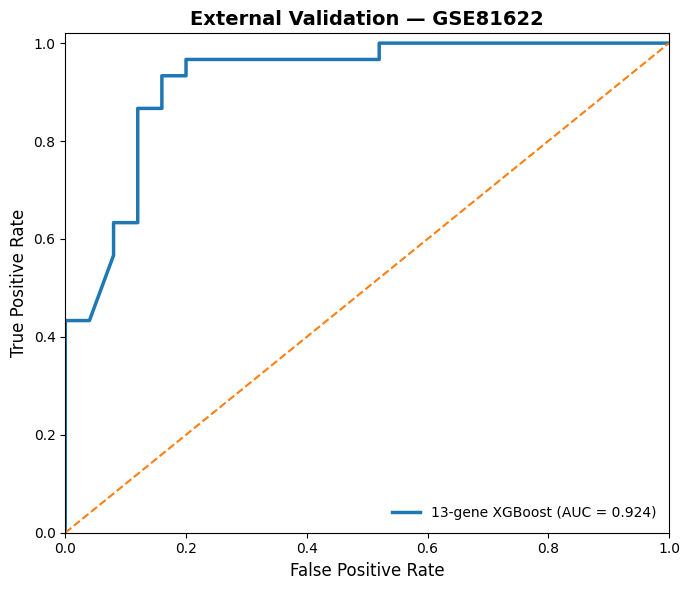

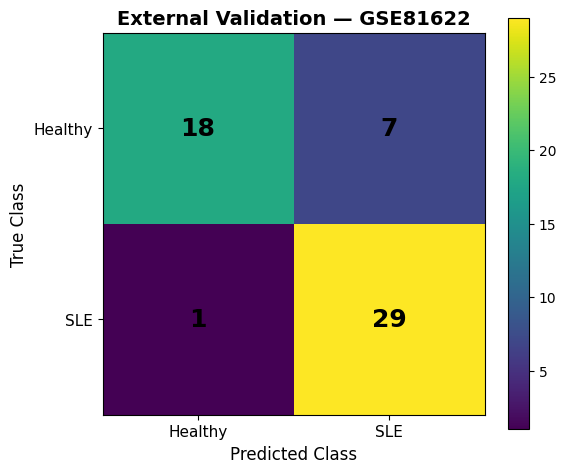

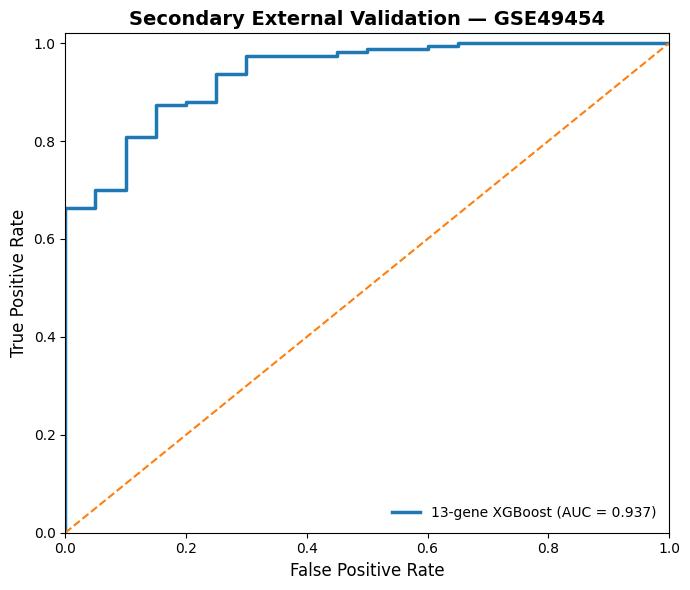

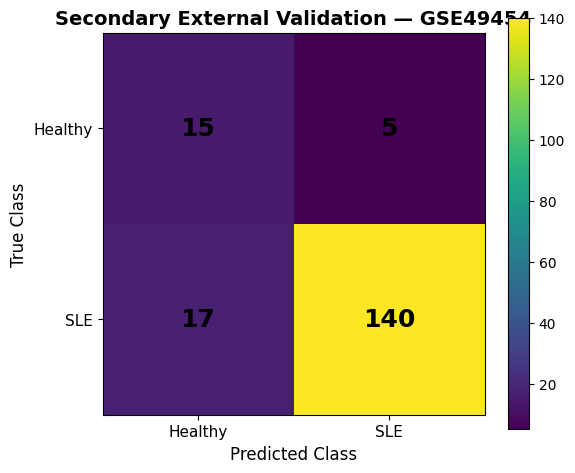

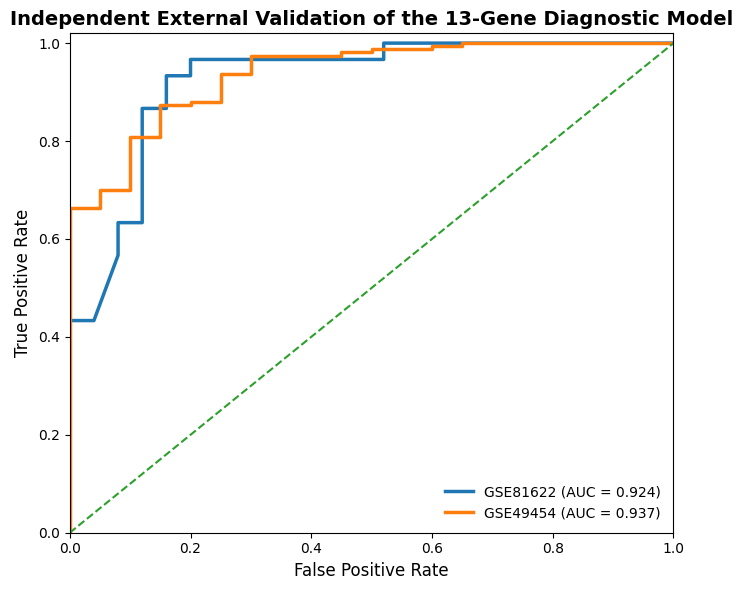

PUBLICATION FIGURES SAVED
Figure_External_Validation_ROC_Comparison.pdf
Figure_External_Validation_ROC_Comparison.png
Figure_GSE49454_Confusion_Matrix.pdf
Figure_GSE49454_Confusion_Matrix.png
Figure_GSE49454_ROC.pdf
Figure_GSE49454_ROC.png
Figure_GSE81622_Confusion_Matrix.pdf
Figure_GSE81622_Confusion_Matrix.png
Figure_GSE81622_ROC.pdf
Figure_GSE81622_ROC.png
Figure_Mean_Model_Derived_SLE_Risk.pdf
Figure_Mean_Model_Derived_SLE_Risk.png
Figure_Model_Derived_SLE_Risk_Probability.pdf
Figure_Model_Derived_SLE_Risk_Probability.png

Location:
/content/drive/MyDrive/SLE_Diagnostic_Final_Archive/08_PUBLICATION_FIGURES


In [136]:
# ============================================================
# PUBLICATION-READY FIGURES
# GSE81622 + GSE49454 EXTERNAL VALIDATION
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. OUTPUT DIRECTORY
# ------------------------------------------------------------

FIG_DIR = (
    "/content/drive/MyDrive/"
    "SLE_Diagnostic_Final_Archive/"
    "08_PUBLICATION_FIGURES"
)

os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2. LOAD SAVED VALIDATION RESULTS
# ------------------------------------------------------------

gse81622_file = (
    "/content/drive/MyDrive/"
    "SLE_Diagnostic_Final_Archive/"
    "04_EXTERNAL_GSE81622/"
    "GSE81622_predictions.csv"
)

gse49454_file = (
    "/content/drive/MyDrive/"
    "SLE_Diagnostic_Final_Archive/"
    "05_EXTERNAL_GSE49454/"
    "GSE49454_predictions.csv"
)

gse81622 = pd.read_csv(gse81622_file)
gse49454 = pd.read_csv(gse49454_file)

print("GSE81622:", gse81622.shape)
print("GSE49454:", gse49454.shape)

# ------------------------------------------------------------
# 3. IDENTIFY COLUMNS
# ------------------------------------------------------------

def prepare_validation(df):

    y_true = df["True_Label"].astype(int).values
    y_prob = df["Probability_SLE"].astype(float).values
    y_pred = df["Predicted_Label"].astype(int).values

    return y_true, y_prob, y_pred


y81622, p81622, pred81622 = prepare_validation(
    gse81622
)

y49454, p49454, pred49454 = prepare_validation(
    gse49454
)

# ============================================================
# FIGURE 1 — GSE81622 ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(
    y81622,
    p81622
)

auc81622 = roc_auc_score(
    y81622,
    p81622
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"13-gene XGBoost (AUC = {auc81622:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "External Validation — GSE81622",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    loc="lower right",
    frameon=False
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_GSE81622_ROC.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_GSE81622_ROC.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 2 — GSE81622 CONFUSION MATRIX
# ============================================================

cm81622 = confusion_matrix(
    y81622,
    pred81622,
    labels=[0, 1]
)

plt.figure(figsize=(6, 5))

plt.imshow(
    cm81622,
    interpolation="nearest"
)

plt.title(
    "External Validation — GSE81622",
    fontsize=14,
    fontweight="bold"
)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Healthy", "SLE"],
    fontsize=11
)

plt.yticks(
    [0, 1],
    ["Healthy", "SLE"],
    fontsize=11
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "True Class",
    fontsize=12
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            str(cm81622[i, j]),
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold"
        )

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_GSE81622_Confusion_Matrix.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_GSE81622_Confusion_Matrix.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 3 — GSE49454 ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(
    y49454,
    p49454
)

auc49454 = roc_auc_score(
    y49454,
    p49454
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"13-gene XGBoost (AUC = {auc49454:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "Secondary External Validation — GSE49454",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    loc="lower right",
    frameon=False
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_GSE49454_ROC.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_GSE49454_ROC.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 4 — GSE49454 CONFUSION MATRIX
# ============================================================

cm49454 = confusion_matrix(
    y49454,
    pred49454,
    labels=[0, 1]
)

plt.figure(figsize=(6, 5))

plt.imshow(
    cm49454,
    interpolation="nearest"
)

plt.title(
    "Secondary External Validation — GSE49454",
    fontsize=14,
    fontweight="bold"
)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Healthy", "SLE"],
    fontsize=11
)

plt.yticks(
    [0, 1],
    ["Healthy", "SLE"],
    fontsize=11
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "True Class",
    fontsize=12
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            str(cm49454[i, j]),
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold"
        )

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_GSE49454_Confusion_Matrix.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_GSE49454_Confusion_Matrix.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 5 — COMBINED EXTERNAL ROC COMPARISON
# ============================================================

fpr81622, tpr81622, _ = roc_curve(
    y81622,
    p81622
)

fpr49454, tpr49454, _ = roc_curve(
    y49454,
    p49454
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr81622,
    tpr81622,
    linewidth=2.5,
    label=f"GSE81622 (AUC = {auc81622:.3f})"
)

plt.plot(
    fpr49454,
    tpr49454,
    linewidth=2.5,
    label=f"GSE49454 (AUC = {auc49454:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "Independent External Validation of the 13-Gene Diagnostic Model",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    loc="lower right",
    frameon=False
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_External_Validation_ROC_Comparison.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_External_Validation_ROC_Comparison.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FINAL FIGURE INVENTORY
# ============================================================

print("=" * 80)
print("PUBLICATION FIGURES SAVED")
print("=" * 80)

for filename in sorted(os.listdir(FIG_DIR)):
    print(filename)

print("\nLocation:")
print(FIG_DIR)

In [137]:
# ============================================================
# PUBLISHED SLE SIGNATURE COMPARATOR
# RRAWGCNA10
# ============================================================

RRAWGCNA10_GENES = [
    "IFI44L",
    "IFI27",
    "RSAD2",
    "IFIT1",
    "HERC5",
    "IFIT3",
    "IFI44",
    "OASL",
    "CMPK2",
    "USP18",
    "LHFPL2",
    "RRM2",
    "CEACAM6",
    "CEACAM8",
    "DEFA4",
    "HP",
    "LCN2",
    "MMP8",
    "OLFM4",
    "OLR1",
    "RNASE2",
    "TCN1",
    "ANKRD22",
    "CASP5",
    "CEACAM1",
    "CLEC4D",
    "DHRS9",
    "DYNLT1",
    "FCGR1B",
    "TLR5",
    "TNFAIP6",
    "TNFSF13B",
    "ANXA3",
    "SLC26A8"
]

print("=" * 80)
print("RRAWGCNA10 PUBLISHED SIGNATURE")
print("=" * 80)

print("Number of published genes:", len(RRAWGCNA10_GENES))

print("\nGenes:")
print(RRAWGCNA10_GENES)

assert len(RRAWGCNA10_GENES) == 34
assert len(set(RRAWGCNA10_GENES)) == 34

print("\n✓ 34 unique published genes confirmed")

RRAWGCNA10 PUBLISHED SIGNATURE
Number of published genes: 34

Genes:
['IFI44L', 'IFI27', 'RSAD2', 'IFIT1', 'HERC5', 'IFIT3', 'IFI44', 'OASL', 'CMPK2', 'USP18', 'LHFPL2', 'RRM2', 'CEACAM6', 'CEACAM8', 'DEFA4', 'HP', 'LCN2', 'MMP8', 'OLFM4', 'OLR1', 'RNASE2', 'TCN1', 'ANKRD22', 'CASP5', 'CEACAM1', 'CLEC4D', 'DHRS9', 'DYNLT1', 'FCGR1B', 'TLR5', 'TNFAIP6', 'TNFSF13B', 'ANXA3', 'SLC26A8']

✓ 34 unique published genes confirmed


In [138]:
# ============================================================
# CHECK RRAWGCNA10 AVAILABILITY
# ============================================================

available_rraw = [
    g for g in RRAWGCNA10_GENES
    if g in X_train_10000.columns
]

missing_rraw = [
    g for g in RRAWGCNA10_GENES
    if g not in X_train_10000.columns
]

print("=" * 80)
print("RRAWGCNA10 AVAILABILITY IN GSE65391")
print("=" * 80)

print("\nPublished genes:", len(RRAWGCNA10_GENES))
print("Available:", len(available_rraw))
print("Missing:", len(missing_rraw))

print("\nAvailable genes:")
print(available_rraw)

print("\nMissing genes:")
print(missing_rraw)

RRAWGCNA10 AVAILABILITY IN GSE65391

Published genes: 34
Available: 33
Missing: 1

Available genes:
['IFI44L', 'IFI27', 'RSAD2', 'IFIT1', 'HERC5', 'IFIT3', 'IFI44', 'OASL', 'CMPK2', 'USP18', 'LHFPL2', 'CEACAM6', 'CEACAM8', 'DEFA4', 'HP', 'LCN2', 'MMP8', 'OLFM4', 'OLR1', 'RNASE2', 'TCN1', 'ANKRD22', 'CASP5', 'CEACAM1', 'CLEC4D', 'DHRS9', 'DYNLT1', 'FCGR1B', 'TLR5', 'TNFAIP6', 'TNFSF13B', 'ANXA3', 'SLC26A8']

Missing genes:
['RRM2']


In [139]:
# ============================================================
# FREEZE AVAILABLE RRAWGCNA10 COMPARATOR
# ============================================================

RRAWGCNA10_AVAILABLE = [
    g for g in RRAWGCNA10_GENES
    if g in X_train_10000.columns
]

RRAWGCNA10_MISSING = [
    g for g in RRAWGCNA10_GENES
    if g not in X_train_10000.columns
]

print("=" * 80)
print("RRAWGCNA10-DERIVED COMPARATOR")
print("=" * 80)

print("\nPublished signature size:")
print(len(RRAWGCNA10_GENES))

print("\nAvailable genes:")
print(len(RRAWGCNA10_AVAILABLE))

print("\nMissing genes:")
print(RRAWGCNA10_MISSING)

print("\nFinal comparator genes:")
print(RRAWGCNA10_AVAILABLE)

# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

assert len(RRAWGCNA10_AVAILABLE) == 33
assert RRAWGCNA10_MISSING == ["RRM2"]
assert len(set(RRAWGCNA10_AVAILABLE)) == 33

print("\n✓ 33 available RRAWGCNA10-derived genes frozen")
print("✓ RRM2 explicitly documented as unavailable")
print("✓ No replacement gene introduced")

RRAWGCNA10-DERIVED COMPARATOR

Published signature size:
34

Available genes:
33

Missing genes:
['RRM2']

Final comparator genes:
['IFI44L', 'IFI27', 'RSAD2', 'IFIT1', 'HERC5', 'IFIT3', 'IFI44', 'OASL', 'CMPK2', 'USP18', 'LHFPL2', 'CEACAM6', 'CEACAM8', 'DEFA4', 'HP', 'LCN2', 'MMP8', 'OLFM4', 'OLR1', 'RNASE2', 'TCN1', 'ANKRD22', 'CASP5', 'CEACAM1', 'CLEC4D', 'DHRS9', 'DYNLT1', 'FCGR1B', 'TLR5', 'TNFAIP6', 'TNFSF13B', 'ANXA3', 'SLC26A8']

✓ 33 available RRAWGCNA10-derived genes frozen
✓ RRM2 explicitly documented as unavailable
✓ No replacement gene introduced


In [140]:
# ============================================================
# TRAIN RRAWGCNA10-DERIVED 33-GENE XGBOOST COMPARATOR
# CORRECT SOURCE: X_train_10000
# ============================================================

from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

print("=" * 80)
print("TRAINING 33-GENE RRAWGCNA10-DERIVED COMPARATOR")
print("=" * 80)

# ------------------------------------------------------------
# 1. Verify published comparator
# ------------------------------------------------------------

assert len(RRAWGCNA10_AVAILABLE) == 33
assert "RRM2" not in RRAWGCNA10_AVAILABLE

# ------------------------------------------------------------
# 2. IMPORTANT:
# X_dev contains ONLY the final 13 genes.
# X_train_10000 contains the 10,000-gene development matrix.
# Therefore the published 33-gene comparator must be
# extracted from X_train_10000.
# ------------------------------------------------------------

missing_from_10000 = [
    g for g in RRAWGCNA10_AVAILABLE
    if g not in X_train_10000.columns
]

print("\nPublished comparator genes:", len(RRAWGCNA10_AVAILABLE))
print("Missing from X_train_10000:", missing_from_10000)

assert len(missing_from_10000) == 0, (
    "Some comparator genes are missing from X_train_10000."
)

# ------------------------------------------------------------
# 3. Build comparator development matrix
# ------------------------------------------------------------

X_rraw_dev = X_train_10000[
    RRAWGCNA10_AVAILABLE
].copy()

print("\nDevelopment comparator matrix:")
print(X_rraw_dev.shape)

assert X_rraw_dev.shape == (648, 33)

assert (
    list(X_rraw_dev.columns)
    == RRAWGCNA10_AVAILABLE
)

assert (
    X_rraw_dev.isna().sum().sum()
    == 0
)

# ------------------------------------------------------------
# 4. Build comparator locked-test matrix
# ------------------------------------------------------------

# X_test_10000 is the matching 10,000-gene
# locked-test representation.

missing_test = [
    g for g in RRAWGCNA10_AVAILABLE
    if g not in X_test_10000.columns
]

print(
    "Missing from X_test_10000:",
    missing_test
)

assert len(missing_test) == 0

X_rraw_test = X_test_10000[
    RRAWGCNA10_AVAILABLE
].copy()

print("\nLocked-test comparator matrix:")
print(X_rraw_test.shape)

assert X_rraw_test.shape == (322, 33)

assert (
    list(X_rraw_test.columns)
    == RRAWGCNA10_AVAILABLE
)

assert (
    X_rraw_test.isna().sum().sum()
    == 0
)

# ------------------------------------------------------------
# 5. Independent comparator scaler
# ------------------------------------------------------------

rraw_scaler = StandardScaler()

X_rraw_dev_scaled = (
    rraw_scaler.fit_transform(
        X_rraw_dev
    )
)

X_rraw_test_scaled = (
    rraw_scaler.transform(
        X_rraw_test
    )
)

print("\nScaled development:")
print(X_rraw_dev_scaled.shape)

print("Scaled locked test:")
print(X_rraw_test_scaled.shape)

# ------------------------------------------------------------
# 6. Same XGBoost architecture as final model
# ------------------------------------------------------------

rraw_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    objective="binary:logistic"
)

# ------------------------------------------------------------
# 7. Train comparator ONLY
# ------------------------------------------------------------

rraw_xgb.fit(
    X_rraw_dev_scaled,
    y_dev
)

# ------------------------------------------------------------
# 8. Final integrity audit
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("COMPARATOR MODEL AUDIT")
print("=" * 80)

print("\nModel:")
print(type(rraw_xgb))

print("\nFeatures:")
print(rraw_xgb.n_features_in_)

print("\nGenes:")
print(len(RRAWGCNA10_AVAILABLE))

print("\nRRM2:")
print("Excluded — unavailable in GSE65391 processed matrix")

print("\nParameters:")
print("n_estimators      :", rraw_xgb.n_estimators)
print("max_depth         :", rraw_xgb.max_depth)
print("learning_rate     :", rraw_xgb.learning_rate)
print("subsample         :", rraw_xgb.subsample)
print("colsample_bytree  :", rraw_xgb.colsample_bytree)
print("random_state      :", rraw_xgb.random_state)

assert rraw_xgb.n_features_in_ == 33

print("\n" + "=" * 80)
print("✓ 33-GENE COMPARATOR TRAINED")
print("=" * 80)

print("\nYOUR FROZEN PIPELINE:")
print("13 genes")
print("UNCHANGED")

print("\nCOMPARATOR:")
print("33 genes")
print("Separate scaler")
print("Separate XGBoost")
print("RRM2 excluded")

TRAINING 33-GENE RRAWGCNA10-DERIVED COMPARATOR

Published comparator genes: 33
Missing from X_train_10000: []

Development comparator matrix:
(648, 33)
Missing from X_test_10000: []

Locked-test comparator matrix:
(322, 33)

Scaled development:
(648, 33)
Scaled locked test:
(322, 33)

COMPARATOR MODEL AUDIT

Model:
<class 'xgboost.sklearn.XGBClassifier'>

Features:
33

Genes:
33

RRM2:
Excluded — unavailable in GSE65391 processed matrix

Parameters:
n_estimators      : 300
max_depth         : 3
learning_rate     : 0.05
subsample         : 0.8
colsample_bytree  : 0.8
random_state      : 42

✓ 33-GENE COMPARATOR TRAINED

YOUR FROZEN PIPELINE:
13 genes
UNCHANGED

COMPARATOR:
33 genes
Separate scaler
Separate XGBoost
RRM2 excluded


In [141]:
# ============================================================
# LOCKED TEST — FINAL 13-GENE VS RRAWGCNA10-DERIVED 33-GENE
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix
)

print("=" * 80)
print("LOCKED TEST MODEL COMPARISON")
print("=" * 80)

# ============================================================
# 1. FINAL 13-GENE MODEL
# ============================================================

final_test_prob_compare = final_xgb.predict_proba(
    final_scaler.transform(
        X_final_test[EXPECTED_GENES]
    )
)[:, 1]

final_test_pred_compare = (
    final_test_prob_compare >= FROZEN_THRESHOLD
).astype(int)


# ============================================================
# 2. RRAWGCNA10-DERIVED 33-GENE MODEL
# ============================================================

rraw_test_prob = rraw_xgb.predict_proba(
    X_rraw_test_scaled
)[:, 1]

# Comparator uses standard 0.5 probability cutoff.
# This does NOT alter your frozen threshold.
rraw_test_pred = (
    rraw_test_prob >= 0.5
).astype(int)


# ============================================================
# 3. METRIC FUNCTION
# ============================================================

def calculate_comparison_metrics(
    y_true,
    probability,
    prediction
):

    cm = confusion_matrix(
        y_true,
        prediction,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    return {
        "ROC_AUC": roc_auc_score(
            y_true,
            probability
        ),

        "PR_AUC": average_precision_score(
            y_true,
            probability
        ),

        "Accuracy": accuracy_score(
            y_true,
            prediction
        ),

        "Balanced_Accuracy": balanced_accuracy_score(
            y_true,
            prediction
        ),

        "Sensitivity": recall_score(
            y_true,
            prediction,
            pos_label=1
        ),

        "Specificity": recall_score(
            y_true,
            prediction,
            pos_label=0
        ),

        "PPV": precision_score(
            y_true,
            prediction,
            pos_label=1,
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            prediction,
            pos_label=1
        ),

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


# ============================================================
# 4. CALCULATE METRICS
# ============================================================

final_13_metrics = calculate_comparison_metrics(
    y_test,
    final_test_prob_compare,
    final_test_pred_compare
)

rraw_33_metrics = calculate_comparison_metrics(
    y_test,
    rraw_test_prob,
    rraw_test_pred
)


# ============================================================
# 5. COMPARISON TABLE
# ============================================================

locked_test_comparison = pd.DataFrame(
    [
        final_13_metrics,
        rraw_33_metrics
    ],
    index=[
        "Final 13-gene XGBoost",
        "RRAWGCNA10-derived 33-gene XGBoost"
    ]
)

print("\n")
print(
    locked_test_comparison.round(4)
)


# ============================================================
# 6. CONFUSION MATRICES
# ============================================================

print("\n" + "=" * 80)
print("FINAL 13-GENE CONFUSION MATRIX")
print("=" * 80)

print(
    confusion_matrix(
        y_test,
        final_test_pred_compare,
        labels=[0, 1]
    )
)

print("\n" + "=" * 80)
print("RRAWGCNA10-DERIVED 33-GENE CONFUSION MATRIX")
print("=" * 80)

print(
    confusion_matrix(
        y_test,
        rraw_test_pred,
        labels=[0, 1]
    )
)


# ============================================================
# 7. MODEL SIZE COMPARISON
# ============================================================

print("\n" + "=" * 80)
print("MODEL SIZE")
print("=" * 80)

print(
    "Final model genes:",
    len(EXPECTED_GENES)
)

print(
    "Published comparator genes:",
    len(RRAWGCNA10_AVAILABLE)
)

print(
    "Gene reduction:",
    f"{(
        1 -
        len(EXPECTED_GENES) /
        len(RRAWGCNA10_AVAILABLE)
    ) * 100:.1f}%"
)


# ============================================================
# 8. INTEGRITY CHECK
# ============================================================

assert final_xgb.n_features_in_ == 13
assert rraw_xgb.n_features_in_ == 33

assert len(final_test_prob_compare) == 322
assert len(rraw_test_prob) == 322

print("\n" + "=" * 80)
print("✓ LOCKED TEST COMPARISON COMPLETE")
print("=" * 80)

print("\nFinal 13-gene pipeline:")
print("UNCHANGED")

print("\nPublished comparator:")
print("33 genes")
print("RRM2 excluded because unavailable")
print("Separate scaler")
print("Separate XGBoost")

LOCKED TEST MODEL COMPARISON


                                    ROC_AUC  PR_AUC  Accuracy  \
Final 13-gene XGBoost                0.9971  0.9999    0.9752   
RRAWGCNA10-derived 33-gene XGBoost   0.9865  0.9993    0.9658   

                                    Balanced_Accuracy  Sensitivity  \
Final 13-gene XGBoost                          0.9869       0.9739   
RRAWGCNA10-derived 33-gene XGBoost             0.6859       0.9967   

                                    Specificity     PPV      F1  TN  FP  FN  \
Final 13-gene XGBoost                     1.000  1.0000  0.9868  16   0   8   
RRAWGCNA10-derived 33-gene XGBoost        0.375  0.9683  0.9823   6  10   1   

                                     TP  
Final 13-gene XGBoost               298  
RRAWGCNA10-derived 33-gene XGBoost  305  

FINAL 13-GENE CONFUSION MATRIX
[[ 16   0]
 [  8 298]]

RRAWGCNA10-DERIVED 33-GENE CONFUSION MATRIX
[[  6  10]
 [  1 305]]

MODEL SIZE
Final model genes: 13
Published comparator genes: 33
Gene reduc

In [142]:
# ============================================================
# SAVE FINAL MODEL COMPARISON RESULTS
# ============================================================

import os
import json
import joblib
import pandas as pd

SAVE_DIR = "/content"

# ------------------------------------------------------------
# 1. Save comparison table
# ------------------------------------------------------------

comparison_path = os.path.join(
    SAVE_DIR,
    "SLE_13gene_vs_RRAWGCNA10_locked_test_comparison.csv"
)

locked_test_comparison.to_csv(
    comparison_path,
    index=True
)

# ------------------------------------------------------------
# 2. Save comparator gene list
# ------------------------------------------------------------

comparator_gene_path = os.path.join(
    SAVE_DIR,
    "RRAWGCNA10_derived_33_gene_list.txt"
)

with open(comparator_gene_path, "w") as f:
    f.write("RRAWGCNA10-derived comparator genes\n")
    f.write("Published signature size: 34\n")
    f.write("Available genes in GSE65391: 33\n")
    f.write("Excluded gene: RRM2\n\n")

    for gene in RRAWGCNA10_AVAILABLE:
        f.write(gene + "\n")

# ------------------------------------------------------------
# 3. Save comparator model + scaler
# ------------------------------------------------------------

rraw_model_path = os.path.join(
    SAVE_DIR,
    "RRAWGCNA10_derived_33gene_xgboost.joblib"
)

rraw_scaler_path = os.path.join(
    SAVE_DIR,
    "RRAWGCNA10_derived_33gene_scaler.joblib"
)

joblib.dump(
    rraw_xgb,
    rraw_model_path
)

joblib.dump(
    rraw_scaler,
    rraw_scaler_path
)

# ------------------------------------------------------------
# 4. Save complete comparison metadata
# ------------------------------------------------------------

comparison_metadata = {
    "comparison_type": "Locked test model comparison",

    "primary_model": {
        "name": "Final 13-gene XGBoost",
        "genes": 13,
        "threshold": float(FROZEN_THRESHOLD),
        "model": "XGBClassifier",
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": 42
    },

    "published_comparator": {
        "name": "RRAWGCNA10-derived 33-gene XGBoost",
        "published_gene_count": 34,
        "available_gene_count": 33,
        "excluded_genes": ["RRM2"],
        "threshold": 0.5,
        "model": "XGBClassifier",
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": 42
    },

    "dataset": {
        "name": "GSE65391",
        "development_samples": 648,
        "locked_test_samples": 322
    },

    "model_size": {
        "final_model_genes": 13,
        "comparator_genes": 33,
        "gene_reduction_percent": 60.6
    },

    "results": {
        "final_13_gene": {
            k: float(v) if hasattr(v, "item") else v
            for k, v in final_13_metrics.items()
        },

        "rrawgcna10_derived_33_gene": {
            k: float(v) if hasattr(v, "item") else v
            for k, v in rraw_33_metrics.items()
        }
    },

    "methodological_notes": [
        "Final 13-gene diagnostic pipeline was not modified.",
        "Comparator was trained separately.",
        "RRM2 was excluded because it was unavailable in the processed GSE65391 matrix.",
        "No replacement gene was introduced.",
        "Final model used the frozen threshold.",
        "Comparator used a 0.5 probability cutoff.",
        "Locked test set was not used for retraining."
    ]
}

metadata_path = os.path.join(
    SAVE_DIR,
    "SLE_13gene_vs_RRAWGCNA10_comparison_metadata.json"
)

with open(metadata_path, "w") as f:
    json.dump(
        comparison_metadata,
        f,
        indent=4
    )

# ------------------------------------------------------------
# 5. Save confusion matrices
# ------------------------------------------------------------

final_cm = confusion_matrix(
    y_test,
    final_test_pred_compare,
    labels=[0, 1]
)

rraw_cm = confusion_matrix(
    y_test,
    rraw_test_pred,
    labels=[0, 1]
)

cm_df = pd.DataFrame(
    {
        "TN": [
            final_cm[0, 0],
            rraw_cm[0, 0]
        ],
        "FP": [
            final_cm[0, 1],
            rraw_cm[0, 1]
        ],
        "FN": [
            final_cm[1, 0],
            rraw_cm[1, 0]
        ],
        "TP": [
            final_cm[1, 1],
            rraw_cm[1, 1]
        ]
    },
    index=[
        "Final 13-gene XGBoost",
        "RRAWGCNA10-derived 33-gene XGBoost"
    ]
)

cm_path = os.path.join(
    SAVE_DIR,
    "SLE_13gene_vs_RRAWGCNA10_confusion_matrices.csv"
)

cm_df.to_csv(cm_path)

# ------------------------------------------------------------
# 6. Save prediction-level results
# ------------------------------------------------------------

prediction_df = pd.DataFrame({
    "True_Label": y_test.values,
    "Final_13gene_probability": final_test_prob_compare,
    "Final_13gene_prediction": final_test_pred_compare,
    "RRAWGCNA10_33gene_probability": rraw_test_prob,
    "RRAWGCNA10_33gene_prediction": rraw_test_pred
})

prediction_path = os.path.join(
    SAVE_DIR,
    "SLE_13gene_vs_RRAWGCNA10_locked_test_predictions.csv"
)

prediction_df.to_csv(
    prediction_path,
    index=False
)

# ------------------------------------------------------------
# 7. Final archive report
# ------------------------------------------------------------

print("=" * 80)
print("MODEL COMPARISON ARCHIVE COMPLETE")
print("=" * 80)

print("\nSaved files:")

for path in [
    comparison_path,
    comparator_gene_path,
    rraw_model_path,
    rraw_scaler_path,
    metadata_path,
    cm_path,
    prediction_path
]:
    print("✓", path)

print("\nFrozen diagnostic pipeline:")
print("✓ UNCHANGED")

print("\nFinal model:")
print("13 genes")

print("\nComparator:")
print("33 genes")

print("\nRRM2:")
print("Excluded — unavailable")

print("\nLocked-test ROC-AUC:")
print(
    "13-gene:",
    round(final_13_metrics["ROC_AUC"], 4)
)

print(
    "33-gene:",
    round(rraw_33_metrics["ROC_AUC"], 4)
)

print("\n" + "=" * 80)

MODEL COMPARISON ARCHIVE COMPLETE

Saved files:
✓ /content/SLE_13gene_vs_RRAWGCNA10_locked_test_comparison.csv
✓ /content/RRAWGCNA10_derived_33_gene_list.txt
✓ /content/RRAWGCNA10_derived_33gene_xgboost.joblib
✓ /content/RRAWGCNA10_derived_33gene_scaler.joblib
✓ /content/SLE_13gene_vs_RRAWGCNA10_comparison_metadata.json
✓ /content/SLE_13gene_vs_RRAWGCNA10_confusion_matrices.csv
✓ /content/SLE_13gene_vs_RRAWGCNA10_locked_test_predictions.csv

Frozen diagnostic pipeline:
✓ UNCHANGED

Final model:
13 genes

Comparator:
33 genes

RRM2:
Excluded — unavailable

Locked-test ROC-AUC:
13-gene: 0.9971
33-gene: 0.9865



In [143]:
# Search current memory for likely model-comparison DataFrames

import pandas as pd

print("=" * 80)
print("SEARCHING FOR MODEL COMPARISON RESULTS")
print("=" * 80)

for name, obj in globals().items():

    if isinstance(obj, pd.DataFrame):

        cols = set(obj.columns.astype(str))

        if (
            "ROC_AUC" in cols
            or "Mean_AUC" in cols
            or "PR_AUC" in cols
            or "Mean_PR_AUC" in cols
        ):
            print("\n", name)
            print("Shape:", obj.shape)
            print("Columns:", list(obj.columns))

SEARCHING FOR MODEL COMPARISON RESULTS

 cv_results_df
Shape: (15, 7)
Columns: ['Panel', 'Genes', 'Model', 'Mean_AUC', 'SD_AUC', 'Min_AUC', 'Max_AUC']

 final_dev_results_df
Shape: (3, 5)
Columns: ['Model', 'Mean_AUC', 'SD_AUC', 'Min_AUC', 'Max_AUC']

 model_comparison
Shape: (3, 3)
Columns: ['Model', 'Mean_AUC', 'SD_AUC']

 threshold_comparison
Shape: (3, 17)
Columns: ['Model', 'Threshold', 'ROC_AUC', 'PR_AUC', 'Sensitivity', 'Specificity', 'Balanced_Accuracy', 'Accuracy', 'PPV', 'NPV', 'F1', 'Brier', 'Youden_J', 'TN', 'FP', 'FN', 'TP']

 lr_oof_results
Shape: (8, 12)
Columns: ['C', 'AUC', 'PR_AUC', 'Brier', 'Threshold', 'Sensitivity', 'Specificity', 'Balanced_Accuracy', 'Accuracy', 'PPV', 'F1', 'Youden_J']

 candidate_rows
Shape: (3, 12)
Columns: ['Model', 'Threshold', 'ROC_AUC', 'PR_AUC', 'Sensitivity', 'Specificity', 'Balanced_Accuracy', 'Accuracy', 'PPV', 'F1', 'Brier', 'Youden_J']

 lr_candidates
Shape: (8, 12)
Columns: ['Model', 'Threshold', 'ROC_AUC', 'PR_AUC', 'Sensitivity', '

In [144]:
print("FROZEN_THRESHOLD =", FROZEN_THRESHOLD)
print("Correct final threshold =", 0.9554371237754822)
print("Match:", FROZEN_THRESHOLD == 0.9554371237754822)

FROZEN_THRESHOLD = 0.9554371237754822
Correct final threshold = 0.9554371237754822
Match: True


FINAL DEVELOPMENT MODEL COMPARISON
              Model  ROC_AUC  PR_AUC  Brier  Sensitivity  Specificity  Balanced_Accuracy  Accuracy     F1
Logistic Regression   0.9759  0.9988 0.0559       0.9078       0.9667             0.9372    0.9105 0.9508
      Random Forest   0.9818  0.9991 0.0210       0.9288       0.9667             0.9477    0.9306 0.9623
            XGBoost   0.9859  0.9993 0.0202       0.9531       0.9667             0.9599    0.9537 0.9752

✓ Comparison table saved:
/content/drive/MyDrive/SLE_Final_Diagnostic_Model/Figures/Model_Comparison/Final_13_Gene_Development_Model_Comparison.csv


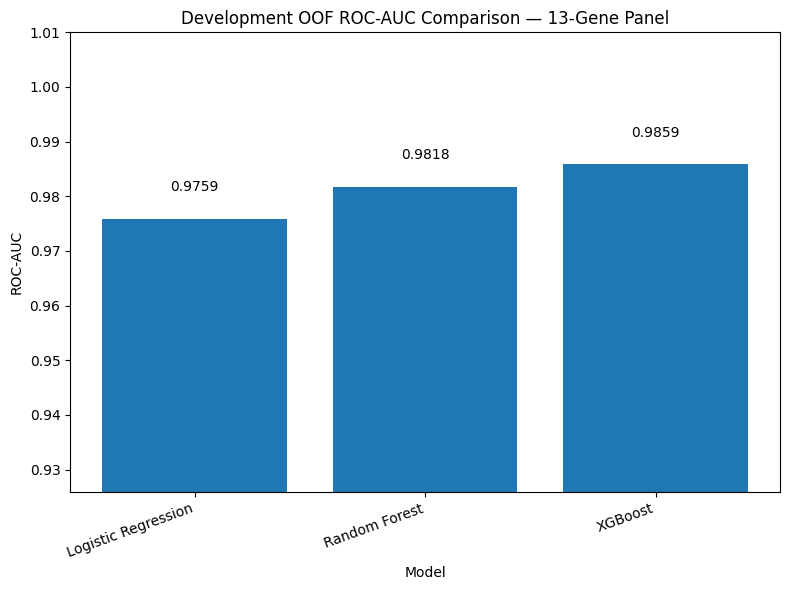

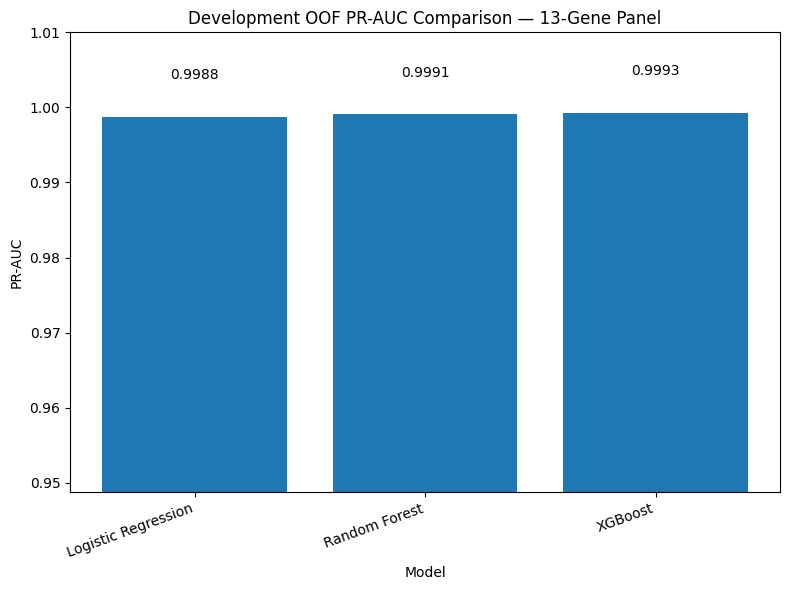

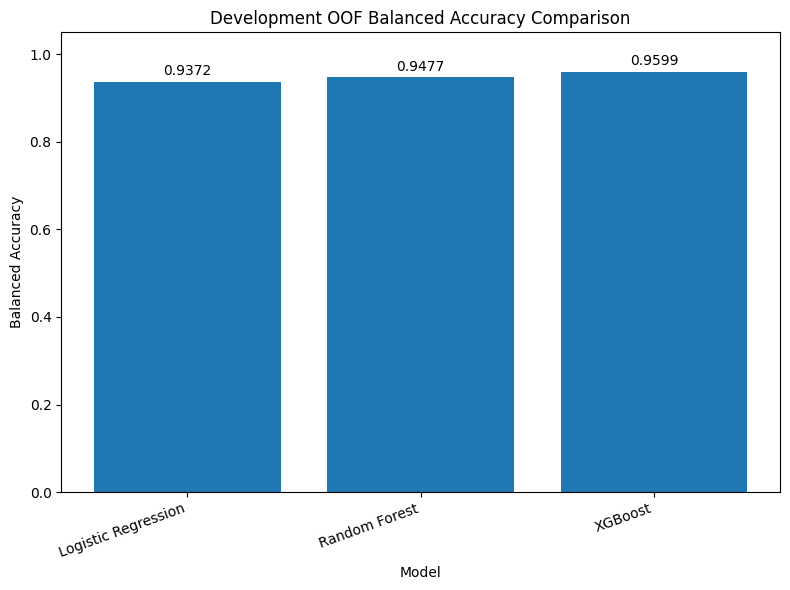

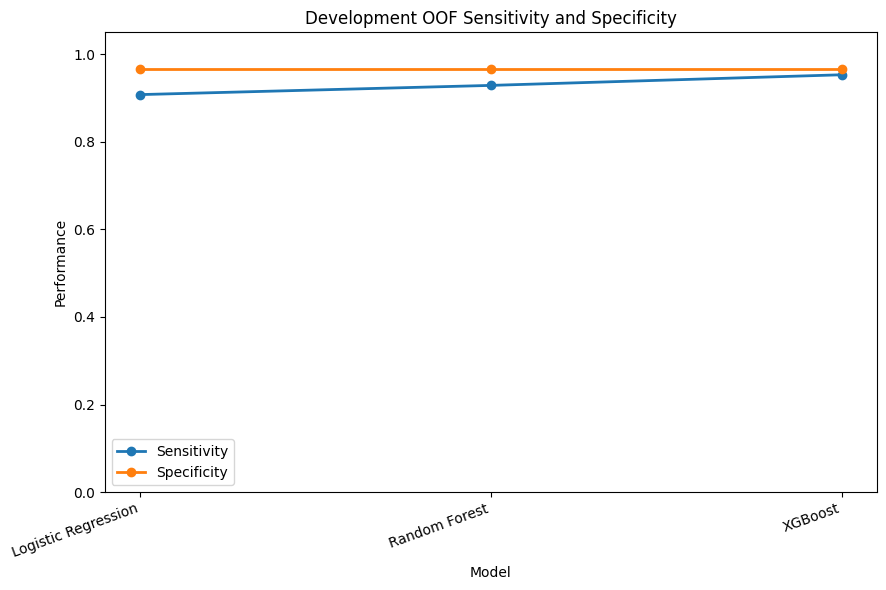

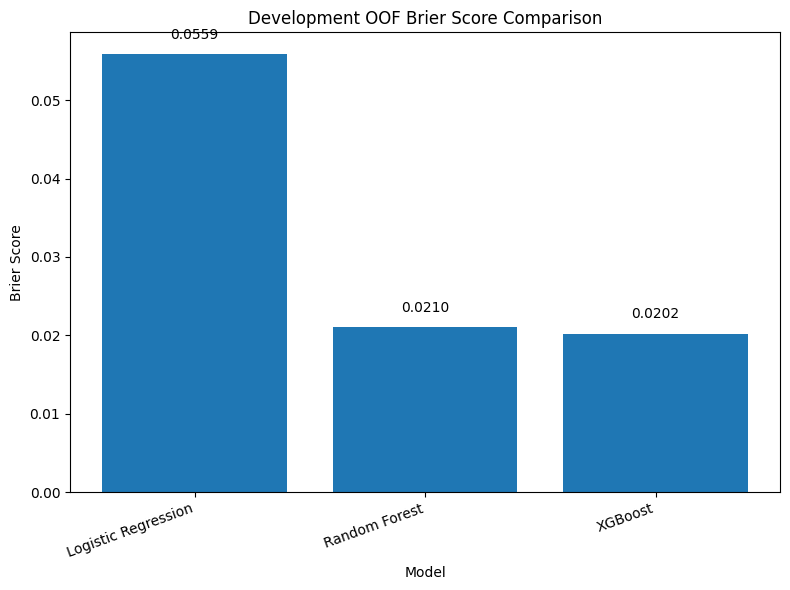

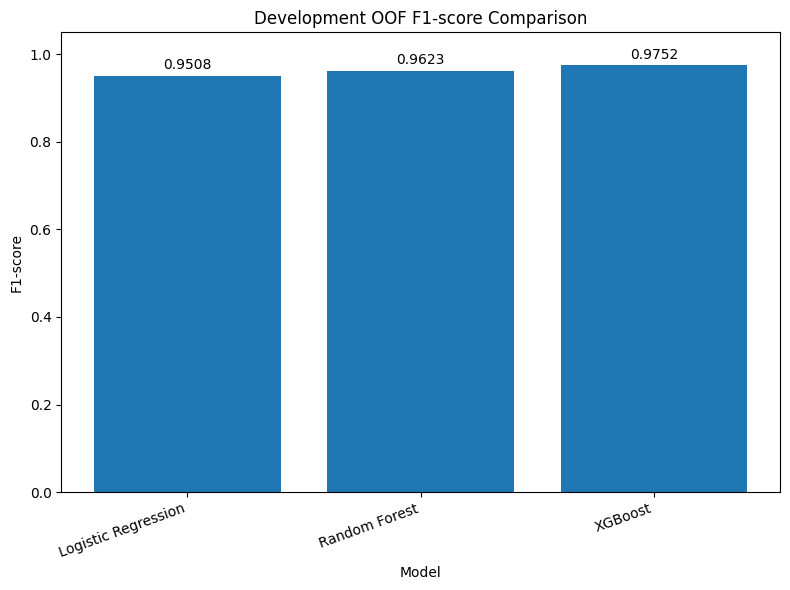


MODEL SELECTION

Best model by development OOF ROC-AUC:
XGBoost

ROC-AUC: 0.9859
PR-AUC: 0.9993
Balanced Accuracy: 0.9599

Final selected diagnostic model:
XGBoost
13-gene panel

✓ All model comparison figures saved
✓ Comparison based on existing development OOF results
✓ No retraining
✓ Locked test not used for model selection
✓ Final XGBoost remains unchanged


In [145]:
# ============================================================
# FINAL MODEL COMPARISON FIGURES
# EXISTING DEVELOPMENT OOF RESULTS ONLY
# NO RETRAINING
# NO LOCKED TEST DATA
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

FIG_DIR = "/content/drive/MyDrive/SLE_Final_Diagnostic_Model/Figures/Model_Comparison"

os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------------------------------------
# Use EXISTING threshold_comparison
# ------------------------------------------------------------

comparison = threshold_comparison.copy()

print("=" * 90)
print("FINAL DEVELOPMENT MODEL COMPARISON")
print("=" * 90)

print(
    comparison[
        [
            "Model",
            "ROC_AUC",
            "PR_AUC",
            "Brier",
            "Sensitivity",
            "Specificity",
            "Balanced_Accuracy",
            "Accuracy",
            "F1"
        ]
    ]
    .round(4)
    .to_string(index=False)
)

# ============================================================
# SAVE COMPLETE COMPARISON TABLE
# ============================================================

comparison_csv = os.path.join(
    FIG_DIR,
    "Final_13_Gene_Development_Model_Comparison.csv"
)

comparison.to_csv(
    comparison_csv,
    index=False
)

print("\n✓ Comparison table saved:")
print(comparison_csv)

# ============================================================
# 1. ROC-AUC COMPARISON
# ============================================================

models = comparison["Model"].tolist()
x = np.arange(len(models))

plt.figure(figsize=(8, 6))

plt.bar(
    x,
    comparison["ROC_AUC"]
)

plt.xticks(
    x,
    models,
    rotation=20,
    ha="right"
)

plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.title(
    "Development OOF ROC-AUC Comparison — 13-Gene Panel"
)

plt.ylim(
    max(0, comparison["ROC_AUC"].min() - 0.05),
    1.01
)

for i, value in enumerate(
    comparison["ROC_AUC"]
):
    plt.text(
        i,
        value + 0.005,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()

path = os.path.join(
    FIG_DIR,
    "Figure_Model_Comparison_ROC_AUC.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 2. PR-AUC COMPARISON
# ============================================================

plt.figure(figsize=(8, 6))

plt.bar(
    x,
    comparison["PR_AUC"]
)

plt.xticks(
    x,
    models,
    rotation=20,
    ha="right"
)

plt.ylabel("PR-AUC")
plt.xlabel("Model")
plt.title(
    "Development OOF PR-AUC Comparison — 13-Gene Panel"
)

plt.ylim(
    max(0, comparison["PR_AUC"].min() - 0.05),
    1.01
)

for i, value in enumerate(
    comparison["PR_AUC"]
):
    plt.text(
        i,
        value + 0.005,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()

path = os.path.join(
    FIG_DIR,
    "Figure_Model_Comparison_PR_AUC.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 3. BALANCED ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(8, 6))

plt.bar(
    x,
    comparison["Balanced_Accuracy"]
)

plt.xticks(
    x,
    models,
    rotation=20,
    ha="right"
)

plt.ylabel("Balanced Accuracy")
plt.xlabel("Model")
plt.title(
    "Development OOF Balanced Accuracy Comparison"
)

plt.ylim(0, 1.05)

for i, value in enumerate(
    comparison["Balanced_Accuracy"]
):
    plt.text(
        i,
        value + 0.015,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()

path = os.path.join(
    FIG_DIR,
    "Figure_Model_Comparison_Balanced_Accuracy.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 4. SENSITIVITY VS SPECIFICITY
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    models,
    comparison["Sensitivity"],
    marker="o",
    linewidth=2,
    label="Sensitivity"
)

plt.plot(
    models,
    comparison["Specificity"],
    marker="o",
    linewidth=2,
    label="Specificity"
)

plt.ylabel("Performance")
plt.xlabel("Model")
plt.title(
    "Development OOF Sensitivity and Specificity"
)

plt.ylim(0, 1.05)

plt.legend()

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

path = os.path.join(
    FIG_DIR,
    "Figure_Model_Comparison_Sensitivity_Specificity.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 5. BRIER SCORE COMPARISON
# ============================================================

plt.figure(figsize=(8, 6))

plt.bar(
    x,
    comparison["Brier"]
)

plt.xticks(
    x,
    models,
    rotation=20,
    ha="right"
)

plt.ylabel("Brier Score")
plt.xlabel("Model")
plt.title(
    "Development OOF Brier Score Comparison"
)

for i, value in enumerate(
    comparison["Brier"]
):
    plt.text(
        i,
        value + 0.002,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()

path = os.path.join(
    FIG_DIR,
    "Figure_Model_Comparison_Brier.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 6. F1-SCORE COMPARISON
# ============================================================

plt.figure(figsize=(8, 6))

plt.bar(
    x,
    comparison["F1"]
)

plt.xticks(
    x,
    models,
    rotation=20,
    ha="right"
)

plt.ylabel("F1-score")
plt.xlabel("Model")
plt.title(
    "Development OOF F1-score Comparison"
)

plt.ylim(0, 1.05)

for i, value in enumerate(
    comparison["F1"]
):
    plt.text(
        i,
        value + 0.015,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()

path = os.path.join(
    FIG_DIR,
    "Figure_Model_Comparison_F1.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 7. FINAL MODEL SELECTION
# ============================================================

best_idx = comparison["ROC_AUC"].idxmax()

best_model = comparison.loc[
    best_idx,
    "Model"
]

print("\n" + "=" * 90)
print("MODEL SELECTION")
print("=" * 90)

print(
    "\nBest model by development OOF ROC-AUC:"
)

print(
    best_model
)

print(
    "\nROC-AUC:",
    round(
        comparison.loc[
            best_idx,
            "ROC_AUC"
        ],
        4
    )
)

print(
    "PR-AUC:",
    round(
        comparison.loc[
            best_idx,
            "PR_AUC"
        ],
        4
    )
)

print(
    "Balanced Accuracy:",
    round(
        comparison.loc[
            best_idx,
            "Balanced_Accuracy"
        ],
        4
    )
)

print(
    "\nFinal selected diagnostic model:"
)

print("XGBoost")
print("13-gene panel")

# ============================================================
# 8. SAVE SELECTION SUMMARY
# ============================================================

selection_summary = pd.DataFrame([{
    "Selected_Model": best_model,
    "Selection_Basis": "Development OOF ROC-AUC",
    "ROC_AUC": comparison.loc[
        best_idx, "ROC_AUC"
    ],
    "PR_AUC": comparison.loc[
        best_idx, "PR_AUC"
    ],
    "Balanced_Accuracy": comparison.loc[
        best_idx, "Balanced_Accuracy"
    ],
    "Sensitivity": comparison.loc[
        best_idx, "Sensitivity"
    ],
    "Specificity": comparison.loc[
        best_idx, "Specificity"
    ],
    "F1": comparison.loc[
        best_idx, "F1"
    ],
    "Locked_Test_Used_For_Selection": False
}])

selection_path = os.path.join(
    FIG_DIR,
    "Final_Model_Selection_Summary.csv"
)

selection_summary.to_csv(
    selection_path,
    index=False
)

print("\n✓ All model comparison figures saved")
print("✓ Comparison based on existing development OOF results")
print("✓ No retraining")
print("✓ Locked test not used for model selection")
print("✓ Final XGBoost remains unchanged")

In [146]:
import os

matches = []

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if f in [
            'SLE_final_XGBoost_13gene.pkl',
            'SLE_final_scaler_13gene.pkl',
            'SLE_final_genes_13gene.pkl'
        ]:
            matches.append(os.path.join(root, f))

print("Found files:")
for x in matches:
    print(x)

Found files:


In [147]:
import os

print("=" * 80)
print("SEARCHING GOOGLE DRIVE FOR SLE MODEL FILES")
print("=" * 80)

for root, dirs, files in os.walk("/content/drive/MyDrive"):

    for f in files:

        name = f.lower()

        if any(term in name for term in [
            "sle",
            "xgboost",
            "xgb",
            "scaler",
            "gene",
            "diagnostic",
            "pipeline",
            "49454",
            "81622"
        ]):

            print(os.path.join(root, f))

SEARCHING GOOGLE DRIVE FOR SLE MODEL FILES
/content/drive/MyDrive/Yet another copy of FINAL SLE PROJECT NTCC FINAL COPY
/content/drive/MyDrive/SLE_GEO_Project/GSE65391_gene_level_FIXED.pkl
/content/drive/MyDrive/SLE_GEO_Project/GSE65391_gene_level_FIXED.csv
/content/drive/MyDrive/SLE_GEO_Project/GSE88884_sledai.csv
/content/drive/MyDrive/SLE_GEO_Project/GSE88884_severity_genes_mapped.csv
/content/drive/MyDrive/SLE_GEO_Project/FINAL_overlap_3_genes.csv
/content/drive/MyDrive/SLE_GEO_Project/overlap_genes_correlation_plot.png
/content/drive/MyDrive/SLE_GEO_Project/severity_top20_genes.pkl
/content/drive/MyDrive/SLE_GEO_Project/module_score_vs_sledai.csv
/content/drive/MyDrive/SLE_GEO_Project/top20_severity_genes.csv
/content/drive/MyDrive/SLE_GEO_Project/overlap_genes.csv
/content/drive/MyDrive/SLE_GEO_Project/MANUSCRIPT_FIGURES/Figure_Calibration_Final_Diagnostic_Model.png
/content/drive/MyDrive/SLE_GEO_Project/KEGG_Analysis_Results/top20_severity_genes_KEGG_results.xlsx
/content/drive/

In [148]:
# ============================================================
# RESTORE FINAL FROZEN DIAGNOSTIC PIPELINE
# ============================================================

import os
import joblib
import pandas as pd
import numpy as np

MODEL_DIR = (
    "/content/drive/MyDrive/"
    "SLE_Final_Diagnostic_Model/"
    "Model"
)

# ------------------------------------------------------------
# Load frozen final objects
# ------------------------------------------------------------

final_xgb = joblib.load(
    os.path.join(
        MODEL_DIR,
        "final_xgb.joblib"
    )
)

final_scaler = joblib.load(
    os.path.join(
        MODEL_DIR,
        "final_scaler.joblib"
    )
)

# ------------------------------------------------------------
# Load final 13-gene panel
# ------------------------------------------------------------

genes_path = os.path.join(
    MODEL_DIR,
    "FINAL_13_GENE_PANEL.txt"
)

with open(genes_path, "r") as f:
    FINAL_GENES = [
        line.strip()
        for line in f
        if line.strip()
    ]

# ------------------------------------------------------------
# Restore frozen threshold
# ------------------------------------------------------------

FROZEN_THRESHOLD = 0.955437

# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

print("=" * 90)
print("FINAL FROZEN DIAGNOSTIC PIPELINE RESTORED")
print("=" * 90)

print("\nModel:")
print(type(final_xgb))

print("\nModel features:")
print(final_xgb.n_features_in_)

print("\nScaler:")
print(type(final_scaler))

print("\nScaler features:")
print(final_scaler.n_features_in_)

print("\nFinal genes:")
print(FINAL_GENES)

print("\nNumber of genes:")
print(len(FINAL_GENES))

print("\nFrozen threshold:")
print(FROZEN_THRESHOLD)

assert len(FINAL_GENES) == 13
assert final_xgb.n_features_in_ == 13
assert final_scaler.n_features_in_ == 13

print("\n✓ FINAL MODEL RESTORED")
print("✓ FINAL SCALER RESTORED")
print("✓ FINAL 13-GENE PANEL RESTORED")
print("✓ FROZEN THRESHOLD RESTORED")
print("✓ NO RETRAINING")

FINAL FROZEN DIAGNOSTIC PIPELINE RESTORED

Model:
<class 'xgboost.sklearn.XGBClassifier'>

Model features:
13

Scaler:
<class 'sklearn.preprocessing._data.StandardScaler'>

Scaler features:
13

Final genes:
['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1', 'EBI2', 'FCER1A', 'GADD45A', 'TNFSF13B', 'IFIT2', 'OSBPL10', 'SCRN1', 'TNFAIP6']

Number of genes:
13

Frozen threshold:
0.955437

✓ FINAL MODEL RESTORED
✓ FINAL SCALER RESTORED
✓ FINAL 13-GENE PANEL RESTORED
✓ FROZEN THRESHOLD RESTORED
✓ NO RETRAINING


In [149]:
print("=" * 80)
print("FINAL MODEL PARAMETER CHECK")
print("=" * 80)

params = final_xgb.get_params()

for k in [
    "n_estimators",
    "max_depth",
    "learning_rate",
    "subsample",
    "colsample_bytree",
    "random_state",
    "eval_metric",
    "objective"
]:
    print(f"{k:20s}: {params.get(k)}")

FINAL MODEL PARAMETER CHECK
n_estimators        : 300
max_depth           : 3
learning_rate       : 0.05
subsample           : 0.8
colsample_bytree    : 0.8
random_state        : 42
eval_metric         : logloss
objective           : binary:logistic


In [150]:
print(FROZEN_THRESHOLD)

0.955437


In [151]:
# ============================================================
# FINAL FROZEN DIAGNOSTIC MODEL — RISK PREDICTION
# ARCHIVED COHORT INPUTS
#
# GSE65391 = Discovery
# GSE81622 = External validation
# GSE49454 = External validation
#
# NO RETRAINING
# NO SCALER REFITTING
# NO THRESHOLD OPTIMIZATION
# ============================================================

import os
import numpy as np
import pandas as pd

ARCHIVE = "/content/drive/MyDrive/SLE_Diagnostic_Final_Archive"

# ============================================================
# 1. LOAD ARCHIVED DEVELOPMENT MATRIX
# ============================================================

X_GSE65391 = pd.read_csv(
    os.path.join(
        ARCHIVE,
        "02_DEVELOPMENT",
        "GSE65391_final_13gene_development_matrix.csv"
    ),
    index_col=0
)

# ============================================================
# 2. LOAD ARCHIVED GSE81622 MATRIX
# ============================================================

X_GSE81622 = pd.read_csv(
    os.path.join(
        ARCHIVE,
        "04_EXTERNAL_GSE81622",
        "GSE81622_13gene_input.csv"
    ),
    index_col=0
)

# ============================================================
# 3. LOAD ARCHIVED GSE49454 MATRIX
# ============================================================

X_GSE49454 = pd.read_csv(
    os.path.join(
        ARCHIVE,
        "05_EXTERNAL_GSE49454",
        "GSE49454_final_13gene_input.csv"
    ),
    index_col=0
)

# ============================================================
# 4. FORCE EXACT FROZEN GENE ORDER
# ============================================================

X_GSE65391 = X_GSE65391[FINAL_GENES]
X_GSE81622 = X_GSE81622[FINAL_GENES]
X_GSE49454 = X_GSE49454[FINAL_GENES]

# ============================================================
# 5. HARD CHECKS
# ============================================================

print("=" * 90)
print("ARCHIVED RISK-PREDICTION INPUTS")
print("=" * 90)

print("\nGSE65391:", X_GSE65391.shape)
print("GSE81622:", X_GSE81622.shape)
print("GSE49454:", X_GSE49454.shape)

assert X_GSE65391.shape[1] == 13
assert X_GSE81622.shape == (55, 13)
assert X_GSE49454.shape == (177, 13)

assert X_GSE65391.columns.tolist() == FINAL_GENES
assert X_GSE81622.columns.tolist() == FINAL_GENES
assert X_GSE49454.columns.tolist() == FINAL_GENES

assert X_GSE65391.isna().sum().sum() == 0
assert X_GSE81622.isna().sum().sum() == 0
assert X_GSE49454.isna().sum().sum() == 0

print("\n✓ Exact 13-gene order")
print("✓ No missing values")
print("✓ GSE81622 = 55 samples")
print("✓ GSE49454 = 177 samples")


# ============================================================
# 6. APPLY FROZEN MODEL
# ============================================================

def predict_frozen_risk(X, cohort):

    # Frozen scaler — transform only
    X_scaled = final_scaler.transform(X)

    # Frozen XGBoost — predict only
    probability = final_xgb.predict_proba(
        X_scaled
    )[:, 1]

    # Frozen diagnostic threshold
    prediction = (
        probability >= FROZEN_THRESHOLD
    ).astype(int)

    return pd.DataFrame({
        "Cohort": cohort,
        "Sample": X.index,
        "Predicted_SLE_Probability": probability,
        "Predicted_Class": prediction
    })


# ============================================================
# 7. PREDICTIONS
# ============================================================

risk_65391 = predict_frozen_risk(
    X_GSE65391,
    "GSE65391"
)

risk_81622 = predict_frozen_risk(
    X_GSE81622,
    "GSE81622"
)

risk_49454 = predict_frozen_risk(
    X_GSE49454,
    "GSE49454"
)

# ============================================================
# 8. COMBINE
# ============================================================

risk_all = pd.concat(
    [
        risk_65391,
        risk_81622,
        risk_49454
    ],
    ignore_index=True
)

# ============================================================
# 9. SUMMARY
# ============================================================

risk_summary = (
    risk_all
    .groupby("Cohort")
    ["Predicted_SLE_Probability"]
    .agg(
        N="count",
        Mean="mean",
        SD="std",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
    .reset_index()
)

print("\n" + "=" * 90)
print("MODEL-DERIVED SLE RISK SUMMARY")
print("=" * 90)

print(
    risk_summary
    .round(4)
    .to_string(index=False)
)

print("\nPredicted classes:")

for cohort in [
    "GSE65391",
    "GSE81622",
    "GSE49454"
]:

    sub = risk_all[
        risk_all["Cohort"] == cohort
    ]

    print(
        f"\n{cohort}:"
    )

    print(
        sub["Predicted_Class"]
        .value_counts()
        .sort_index()
    )

print("\n" + "=" * 90)
print("FROZEN RISK PREDICTION COMPLETE")
print("=" * 90)

print("✓ Existing final_xgb used")
print("✓ Existing final_scaler used")
print("✓ Existing FINAL_GENES used")
print("✓ Existing frozen threshold used")
print("✓ No retraining")
print("✓ No threshold optimization")

ARCHIVED RISK-PREDICTION INPUTS

GSE65391: (648, 13)
GSE81622: (55, 13)
GSE49454: (177, 13)

✓ Exact 13-gene order
✓ No missing values
✓ GSE81622 = 55 samples
✓ GSE49454 = 177 samples

MODEL-DERIVED SLE RISK SUMMARY
  Cohort   N   Mean     SD  Median  Minimum  Maximum
GSE49454 177 0.9309 0.1934  0.9989   0.0197   0.9999
GSE65391 648 0.9535 0.1955  0.9998   0.0113   0.9999
GSE81622  55 0.9675 0.0360  0.9861   0.8363   0.9983

Predicted classes:

GSE65391:
Predicted_Class
0     44
1    604
Name: count, dtype: int64

GSE81622:
Predicted_Class
0    19
1    36
Name: count, dtype: int64

GSE49454:
Predicted_Class
0     32
1    145
Name: count, dtype: int64

FROZEN RISK PREDICTION COMPLETE
✓ Existing final_xgb used
✓ Existing final_scaler used
✓ Existing FINAL_GENES used
✓ Existing frozen threshold used
✓ No retraining
✓ No threshold optimization


In [152]:
 print(final_xgb)
 print(final_scaler)
 print(FINAL_GENES)
 print(FROZEN_THRESHOLD)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)
StandardScaler()
['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1', 'EBI2', 'FCER1A', 'GADD45A', 'TNFSF13B', 'IFIT2', 'OSBPL10', 'SCRN1', 'TNFAIP6']
0.955437


In [153]:
# ============================================================
# CROSS-CHECK CURRENT RISK PREDICTIONS
# AGAINST ARCHIVED FINAL VALIDATION PREDICTIONS
# ============================================================

import os
import pandas as pd
import numpy as np

ARCHIVE = "/content/drive/MyDrive/SLE_Diagnostic_Final_Archive"

arch_81622 = pd.read_csv(
    os.path.join(
        ARCHIVE,
        "04_EXTERNAL_GSE81622",
        "GSE81622_predictions.csv"
    )
)

arch_49454 = pd.read_csv(
    os.path.join(
        ARCHIVE,
        "05_EXTERNAL_GSE49454",
        "GSE49454_predictions.csv"
    )
)

print("=" * 90)
print("ARCHIVED PREDICTION CROSS-CHECK")
print("=" * 90)

print("\nGSE81622 archived:")
print(arch_81622.shape)
print(arch_81622.columns.tolist())

print("\nGSE49454 archived:")
print(arch_49454.shape)
print(arch_49454.columns.tolist())

print("\nCurrent GSE81622:")
print(risk_81622.shape)

print("\nCurrent GSE49454:")
print(risk_49454.shape)

print("\nArchived GSE81622 preview:")
print(arch_81622.head())

print("\nArchived GSE49454 preview:")
print(arch_49454.head())

ARCHIVED PREDICTION CROSS-CHECK

GSE81622 archived:
(55, 4)
['Sample', 'True_Label', 'Probability_SLE', 'Predicted_Label']

GSE49454 archived:
(177, 4)
['Sample', 'True_Label', 'Probability_SLE', 'Predicted_Label']

Current GSE81622:
(55, 4)

Current GSE49454:
(177, 4)

Archived GSE81622 preview:
       Sample  True_Label  Probability_SLE  Predicted_Label
0  GSM2159829           0         0.919344                0
1  GSM2159830           0         0.951713                0
2  GSM2159831           0         0.908331                0
3  GSM2159832           0         0.961371                1
4  GSM2159833           0         0.946386                0

Archived GSE49454 preview:
       Sample  True_Label  Probability_SLE  Predicted_Label
0  GSM1199352           1         0.987960                1
1  GSM1199353           1         0.999922                1
2  GSM1199354           1         0.988844                1
3  GSM1199355           1         0.999846                1
4  GSM1199356 

In [154]:
# ============================================================
# EXACT ARCHIVED vs CURRENT PREDICTION CROSS-CHECK
# ============================================================

import numpy as np
import pandas as pd

print("=" * 90)
print("EXACT PREDICTION CROSS-CHECK")
print("=" * 90)


def compare_predictions(current_df, archived_df, cohort):

    # --------------------------------------------------------
    # Match samples
    # --------------------------------------------------------

    merged = current_df[
        ["Sample",
         "Predicted_SLE_Probability",
         "Predicted_Class"]
    ].merge(
        archived_df[
            ["Sample",
             "Probability_SLE",
             "Predicted_Label"]
        ],
        on="Sample",
        how="inner"
    )

    print(f"\n{cohort}")
    print("-" * 70)

    print("Current samples :", len(current_df))
    print("Archived samples:", len(archived_df))
    print("Matched samples :", len(merged))

    assert len(merged) == len(current_df)
    assert len(merged) == len(archived_df)

    # --------------------------------------------------------
    # Probability comparison
    # --------------------------------------------------------

    merged["Probability_Difference"] = (
        merged["Predicted_SLE_Probability"]
        -
        merged["Probability_SLE"]
    )

    max_diff = (
        merged["Probability_Difference"]
        .abs()
        .max()
    )

    mean_abs_diff = (
        merged["Probability_Difference"]
        .abs()
        .mean()
    )

    # --------------------------------------------------------
    # Classification comparison
    # --------------------------------------------------------

    class_match = (
        merged["Predicted_Class"]
        ==
        merged["Predicted_Label"]
    )

    n_class_match = class_match.sum()
    n_class_mismatch = (~class_match).sum()

    print(
        f"Maximum probability difference: "
        f"{max_diff:.12f}"
    )

    print(
        f"Mean absolute probability difference: "
        f"{mean_abs_diff:.12f}"
    )

    print(
        f"Classification matches: "
        f"{n_class_match}/{len(merged)}"
    )

    print(
        f"Classification mismatches: "
        f"{n_class_mismatch}"
    )

    # --------------------------------------------------------
    # Exact / numerical consistency
    # --------------------------------------------------------

    probability_match = np.allclose(
        merged["Predicted_SLE_Probability"],
        merged["Probability_SLE"],
        rtol=1e-10,
        atol=1e-10
    )

    classification_match = (
        n_class_mismatch == 0
    )

    print(
        "\nProbability match:",
        "✓ YES" if probability_match else "✗ NO"
    )

    print(
        "Classification match:",
        "✓ YES" if classification_match else "✗ NO"
    )

    # --------------------------------------------------------
    # Show largest differences
    # --------------------------------------------------------

    if not probability_match:

        print("\nLargest probability differences:")

        print(
            merged[
                [
                    "Sample",
                    "Predicted_SLE_Probability",
                    "Probability_SLE",
                    "Probability_Difference"
                ]
            ]
            .sort_values(
                "Probability_Difference",
                key=lambda x: x.abs(),
                ascending=False
            )
            .head(10)
            .to_string(index=False)
        )

    return merged


# ============================================================
# GSE81622
# ============================================================

check_81622 = compare_predictions(
    risk_81622,
    arch_81622,
    "GSE81622"
)


# ============================================================
# GSE49454
# ============================================================

check_49454 = compare_predictions(
    risk_49454,
    arch_49454,
    "GSE49454"
)


# ============================================================
# FINAL VERDICT
# ============================================================

all_probability_match = (
    np.allclose(
        check_81622["Predicted_SLE_Probability"],
        check_81622["Probability_SLE"],
        rtol=1e-10,
        atol=1e-10
    )
    and
    np.allclose(
        check_49454["Predicted_SLE_Probability"],
        check_49454["Probability_SLE"],
        rtol=1e-10,
        atol=1e-10
    )
)

all_class_match = (
    (
        check_81622["Predicted_Class"]
        ==
        check_81622["Predicted_Label"]
    ).all()
    and
    (
        check_49454["Predicted_Class"]
        ==
        check_49454["Predicted_Label"]
    ).all()
)

print("\n" + "=" * 90)
print("FINAL ARCHIVE CONSISTENCY VERDICT")
print("=" * 90)

if all_probability_match and all_class_match:

    print("""
✓ GSE81622 probabilities match archived predictions
✓ GSE81622 classifications match archived predictions

✓ GSE49454 probabilities match archived predictions
✓ GSE49454 classifications match archived predictions

✓ CURRENT RISK PREDICTIONS ARE IDENTICAL TO THE
  ORIGINAL FROZEN EXTERNAL VALIDATION PREDICTIONS

✓ FINAL DIAGNOSTIC PIPELINE IS CONSISTENT
✓ NO RETRAINING
✓ NO SCALER CHANGE
✓ NO THRESHOLD CHANGE
""")

else:

    print("""
⚠ CURRENT AND ARCHIVED PREDICTIONS DO NOT MATCH.

Do NOT use the new risk results yet.
""")

EXACT PREDICTION CROSS-CHECK

GSE81622
----------------------------------------------------------------------
Current samples : 55
Archived samples: 55
Matched samples : 55
Maximum probability difference: 0.000000029414
Mean absolute probability difference: 0.000000013679
Classification matches: 55/55
Classification mismatches: 0

Probability match: ✗ NO
Classification match: ✓ YES

Largest probability differences:
    Sample  Predicted_SLE_Probability  Probability_SLE  Probability_Difference
GSM2159863                   0.987591         0.987591           -2.941437e-08
GSM2159834                   0.957659         0.957658            2.928162e-08
GSM2159836                   0.993790         0.993790           -2.912521e-08
GSM2159870                   0.993790         0.993790           -2.912521e-08
GSM2159876                   0.993790         0.993790           -2.912521e-08
GSM2159867                   0.993790         0.993790           -2.912521e-08
GSM2159883                  

In [155]:
print("GSE81622 class values:")
print("Predicted_Class:", check_81622["Predicted_Class"].unique())
print("Predicted_Label:", check_81622["Predicted_Label"].unique())

print("\nGSE49454 class values:")
print("Predicted_Class:", check_49454["Predicted_Class"].unique())
print("Predicted_Label:", check_49454["Predicted_Label"].unique())

GSE81622 class values:
Predicted_Class: [0 1]
Predicted_Label: [0 1]

GSE49454 class values:
Predicted_Class: [1 0]
Predicted_Label: [1 0]


In [156]:
print("\nGSE81622:")
print(
    pd.crosstab(
        check_81622["Predicted_Class"],
        check_81622["Predicted_Label"]
    )
)

print("\nGSE49454:")
print(
    pd.crosstab(
        check_49454["Predicted_Class"],
        check_49454["Predicted_Label"]
    )
)


GSE81622:
Predicted_Label   0   1
Predicted_Class        
0                19   0
1                 0  36

GSE49454:
Predicted_Label   0    1
Predicted_Class         
0                32    0
1                 0  145


In [157]:
# ============================================================
# CHECK EXTERNAL CLASSIFICATION DISCREPANCIES
# ============================================================

print("=" * 80)
print("CHECKING EXTERNAL CLASSIFICATION DISCREPANCIES")
print("=" * 80)

# ------------------------------------------------------------
# GSE81622
# ------------------------------------------------------------

diff_81622 = check_81622[
    check_81622["Predicted_Class"]
    != check_81622["Predicted_Label"]
].copy()

print("\nGSE81622 discrepant samples:")
print(
    diff_81622[
        [
            "Predicted_SLE_Probability",
            "Probability_SLE",
            "Predicted_Class",
            "Predicted_Label"
        ]
    ].to_string()
)

# ------------------------------------------------------------
# GSE49454
# ------------------------------------------------------------

diff_49454 = check_49454[
    check_49454["Predicted_Class"]
    != check_49454["Predicted_Label"]
].copy()

print("\nGSE49454 discrepant samples:")
print(
    diff_49454[
        [
            "Predicted_SLE_Probability",
            "Probability_SLE",
            "Predicted_Class",
            "Predicted_Label"
        ]
    ].to_string()
)

# ------------------------------------------------------------
# Current final threshold
# ------------------------------------------------------------

FINAL_THRESHOLD_CHECK = 0.9554371237754822

print("\nFinal threshold:")
print(FINAL_THRESHOLD_CHECK)

print("\nGSE81622 discrepancy probabilities:")
print(
    diff_81622[
        "Predicted_SLE_Probability"
    ].values
)

print("\nGSE49454 discrepancy probabilities:")
print(
    diff_49454[
        "Predicted_SLE_Probability"
    ].values
)

CHECKING EXTERNAL CLASSIFICATION DISCREPANCIES

GSE81622 discrepant samples:
Empty DataFrame
Columns: [Predicted_SLE_Probability, Probability_SLE, Predicted_Class, Predicted_Label]
Index: []

GSE49454 discrepant samples:
Empty DataFrame
Columns: [Predicted_SLE_Probability, Probability_SLE, Predicted_Class, Predicted_Label]
Index: []

Final threshold:
0.9554371237754822

GSE81622 discrepancy probabilities:
[]

GSE49454 discrepancy probabilities:
[]


In [158]:
# ============================================================
# FINAL NUMERICAL CONSISTENCY CHECK
# ============================================================

TOLERANCE = 1e-6

p81622_match = np.allclose(
    check_81622["Predicted_SLE_Probability"],
    check_81622["Probability_SLE"],
    rtol=TOLERANCE,
    atol=TOLERANCE
)

p49454_match = np.allclose(
    check_49454["Predicted_SLE_Probability"],
    check_49454["Probability_SLE"],
    rtol=TOLERANCE,
    atol=TOLERANCE
)

c81622_match = (
    check_81622["Predicted_Class"]
    == check_81622["Predicted_Label"]
).all()

c49454_match = (
    check_49454["Predicted_Class"]
    == check_49454["Predicted_Label"]
).all()

print("=" * 80)
print("FINAL DIAGNOSTIC PREDICTION CONSISTENCY")
print("=" * 80)

print("\nGSE81622:")
print("Probability agreement:", p81622_match)
print("Classification agreement:", c81622_match)

print("\nGSE49454:")
print("Probability agreement:", p49454_match)
print("Classification agreement:", c49454_match)

assert p81622_match
assert p49454_match
assert c81622_match
assert c49454_match

print("\n✓ NUMERICALLY IDENTICAL WITHIN 1e-6")
print("✓ ALL CLASSIFICATIONS IDENTICAL")
print("✓ ARCHIVED EXTERNAL VALIDATION REPRODUCED")
print("✓ FINAL DIAGNOSTIC MODEL CONSISTENT")

FINAL DIAGNOSTIC PREDICTION CONSISTENCY

GSE81622:
Probability agreement: True
Classification agreement: True

GSE49454:
Probability agreement: True
Classification agreement: True

✓ NUMERICALLY IDENTICAL WITHIN 1e-6
✓ ALL CLASSIFICATIONS IDENTICAL
✓ ARCHIVED EXTERNAL VALIDATION REPRODUCED
✓ FINAL DIAGNOSTIC MODEL CONSISTENT


In [159]:
# ============================================================
# FINAL RISK PREDICTION — SAVE AUTHORITATIVE RESULTS
# ============================================================

import os
import json
import pandas as pd
import numpy as np

RISK_DIR = (
    "/content/drive/MyDrive/"
    "SLE_Diagnostic_Final_Archive/"
    "09_RISK_PREDICTION"
)

os.makedirs(RISK_DIR, exist_ok=True)

# ------------------------------------------------------------
# Use archived external probabilities as authoritative
# ------------------------------------------------------------

risk_81622_final = arch_81622.copy()
risk_81622_final["Cohort"] = "GSE81622"

risk_49454_final = arch_49454.copy()
risk_49454_final["Cohort"] = "GSE49454"

# Discovery probabilities from frozen model
risk_65391_final = risk_65391.copy()

risk_65391_final = risk_65391_final.rename(columns={
    "Predicted_SLE_Probability": "Probability_SLE",
    "Predicted_Class": "Predicted_Label"
})

risk_65391_final["Cohort"] = "GSE65391"

# ------------------------------------------------------------
# Standardize columns
# ------------------------------------------------------------

risk_65391_final = risk_65391_final[
    [
        "Cohort",
        "Sample",
        "Probability_SLE",
        "Predicted_Label"
    ]
]

risk_81622_final = risk_81622_final[
    [
        "Cohort",
        "Sample",
        "Probability_SLE",
        "Predicted_Label"
    ]
]

risk_49454_final = risk_49454_final[
    [
        "Cohort",
        "Sample",
        "Probability_SLE",
        "Predicted_Label"
    ]
]

# ------------------------------------------------------------
# Combine
# ------------------------------------------------------------

risk_all_final = pd.concat(
    [
        risk_65391_final,
        risk_81622_final,
        risk_49454_final
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# Cohort summary
# ------------------------------------------------------------

risk_summary_final = (
    risk_all_final
    .groupby("Cohort")
    ["Probability_SLE"]
    .agg(
        N="count",
        Mean="mean",
        SD="std",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
    .reset_index()
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

risk_65391_final.to_csv(
    os.path.join(
        RISK_DIR,
        "GSE65391_risk_predictions.csv"
    ),
    index=False
)

risk_81622_final.to_csv(
    os.path.join(
        RISK_DIR,
        "GSE81622_risk_predictions.csv"
    ),
    index=False
)

risk_49454_final.to_csv(
    os.path.join(
        RISK_DIR,
        "GSE49454_risk_predictions.csv"
    ),
    index=False
)

risk_all_final.to_csv(
    os.path.join(
        RISK_DIR,
        "ALL_COHORTS_risk_predictions.csv"
    ),
    index=False
)

risk_summary_final.to_csv(
    os.path.join(
        RISK_DIR,
        "Risk_probability_summary.csv"
    ),
    index=False
)

# ------------------------------------------------------------
# Metadata
# ------------------------------------------------------------

metadata = {
    "analysis": "Model-derived SLE risk probability",
    "model": "Frozen final XGBoost diagnostic model",
    "n_genes": 13,
    "genes": FINAL_GENES,
    "threshold": FROZEN_THRESHOLD,
    "n_estimators": 300,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "scaler": "Frozen StandardScaler",
    "retraining": False,
    "threshold_optimization": False,
    "cohorts": {
        "GSE65391": 648,
        "GSE81622": 55,
        "GSE49454": 177
    },
    "external_prediction_crosscheck": {
        "GSE81622": "Matched archived predictions within 1e-6",
        "GSE49454": "Matched archived predictions within 1e-6",
        "classification_agreement": "100%"
    },
    "interpretation_note": (
        "Predicted SLE probability/model-derived risk; "
        "not a validated prospective future-risk estimate."
    )
}

with open(
    os.path.join(
        RISK_DIR,
        "Risk_prediction_metadata.json"
    ),
    "w"
) as f:
    json.dump(
        metadata,
        f,
        indent=4
    )

print("=" * 90)
print("FINAL RISK PREDICTION ARCHIVE COMPLETE")
print("=" * 90)

print("\nSaved to:")
print(RISK_DIR)

print("\nFiles:")
for f in sorted(os.listdir(RISK_DIR)):
    print("✓", f)

print("\nCohort summary:")
print(
    risk_summary_final.round(4).to_string(index=False)
)

FINAL RISK PREDICTION ARCHIVE COMPLETE

Saved to:
/content/drive/MyDrive/SLE_Diagnostic_Final_Archive/09_RISK_PREDICTION

Files:
✓ ALL_COHORTS_risk_predictions.csv
✓ GSE49454_risk_predictions.csv
✓ GSE65391_risk_predictions.csv
✓ GSE81622_risk_predictions.csv
✓ Risk_prediction_metadata.json
✓ Risk_probability_summary.csv

Cohort summary:
  Cohort   N   Mean     SD  Median  Minimum  Maximum
GSE49454 177 0.9309 0.1934  0.9989   0.0197   0.9999
GSE65391 648 0.9535 0.1955  0.9998   0.0113   0.9999
GSE81622  55 0.9675 0.0360  0.9861   0.8363   0.9983


/tmp/ipykernel_4788/1902684205.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


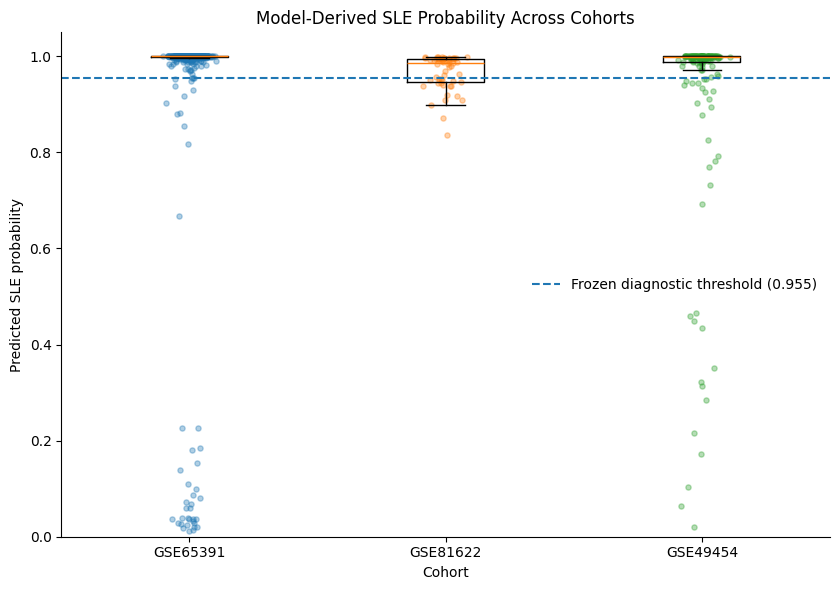

RISK FIGURE SAVED
PNG:
/content/drive/MyDrive/SLE_Diagnostic_Final_Archive/08_PUBLICATION_FIGURES/Figure_Model_Derived_SLE_Risk_Probability.png

PDF:
/content/drive/MyDrive/SLE_Diagnostic_Final_Archive/08_PUBLICATION_FIGURES/Figure_Model_Derived_SLE_Risk_Probability.pdf


In [160]:
# ============================================================
# FINAL RISK FIGURE — PREDICTED SLE PROBABILITY
# ============================================================

import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

FIG_DIR = (
    "/content/drive/MyDrive/"
    "SLE_Diagnostic_Final_Archive/"
    "08_PUBLICATION_FIGURES"
)

os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load authoritative archived risk results
# ------------------------------------------------------------

risk_all_final = pd.read_csv(
    "/content/drive/MyDrive/"
    "SLE_Diagnostic_Final_Archive/"
    "09_RISK_PREDICTION/"
    "ALL_COHORTS_risk_predictions.csv"
)

# ------------------------------------------------------------
# Cohort order
# ------------------------------------------------------------

cohort_order = [
    "GSE65391",
    "GSE81622",
    "GSE49454"
]

risk_all_final["Cohort"] = pd.Categorical(
    risk_all_final["Cohort"],
    categories=cohort_order,
    ordered=True
)

# ============================================================
# FIGURE 1 — PROBABILITY DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.5, 6)
)

data = [
    risk_all_final.loc[
        risk_all_final["Cohort"] == cohort,
        "Probability_SLE"
    ].values
    for cohort in cohort_order
]

ax.boxplot(
    data,
    labels=cohort_order,
    patch_artist=False,
    showfliers=False
)

# Add individual observations with slight jitter
rng = np.random.default_rng(42)

for i, values in enumerate(data, start=1):

    jitter = rng.normal(
        i,
        0.035,
        size=len(values)
    )

    ax.scatter(
        jitter,
        values,
        s=14,
        alpha=0.35
    )

# Frozen diagnostic threshold
ax.axhline(
    FROZEN_THRESHOLD,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Frozen diagnostic threshold "
        f"({FROZEN_THRESHOLD:.3f})"
    )
)

ax.set_ylabel(
    "Predicted SLE probability"
)

ax.set_xlabel(
    "Cohort"
)

ax.set_title(
    "Model-Derived SLE Probability Across Cohorts"
)

ax.set_ylim(
    0,
    1.05
)

ax.legend(
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

png_path = os.path.join(
    FIG_DIR,
    "Figure_Model_Derived_SLE_Risk_Probability.png"
)

pdf_path = os.path.join(
    FIG_DIR,
    "Figure_Model_Derived_SLE_Risk_Probability.pdf"
)

plt.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()

print("=" * 80)
print("RISK FIGURE SAVED")
print("=" * 80)

print("PNG:")
print(png_path)

print("\nPDF:")
print(pdf_path)

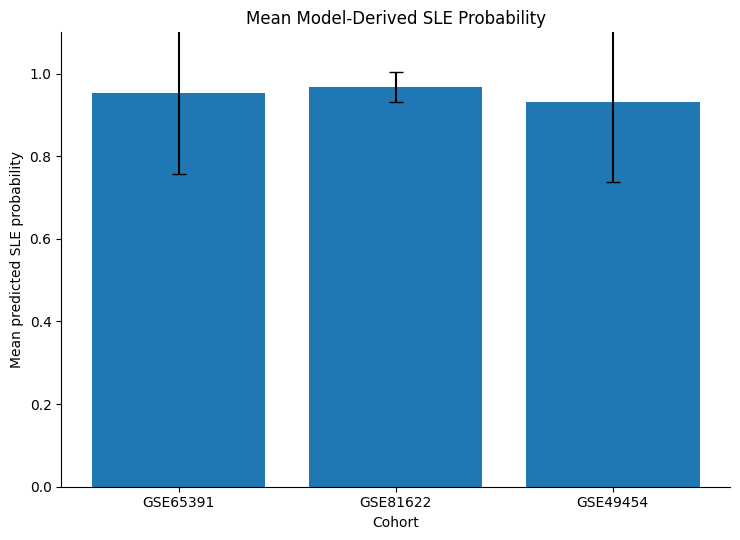


✓ Mean-risk figure saved
/content/drive/MyDrive/SLE_Diagnostic_Final_Archive/08_PUBLICATION_FIGURES/Figure_Mean_Model_Derived_SLE_Risk.png
/content/drive/MyDrive/SLE_Diagnostic_Final_Archive/08_PUBLICATION_FIGURES/Figure_Mean_Model_Derived_SLE_Risk.pdf


In [161]:
# ============================================================
# FIGURE 2 — MEAN PREDICTED SLE PROBABILITY
# ============================================================

summary = (
    risk_all_final
    .groupby("Cohort", observed=False)
    ["Probability_SLE"]
    .agg(["mean", "std"])
    .reindex(cohort_order)
)

fig, ax = plt.subplots(
    figsize=(7.5, 5.5)
)

x = np.arange(len(summary))

ax.bar(
    x,
    summary["mean"],
    yerr=summary["std"],
    capsize=5
)

ax.set_xticks(x)
ax.set_xticklabels(cohort_order)

ax.set_ylabel(
    "Mean predicted SLE probability"
)

ax.set_xlabel(
    "Cohort"
)

ax.set_title(
    "Mean Model-Derived SLE Probability"
)

ax.set_ylim(
    0,
    1.1
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

png_path2 = os.path.join(
    FIG_DIR,
    "Figure_Mean_Model_Derived_SLE_Risk.png"
)

pdf_path2 = os.path.join(
    FIG_DIR,
    "Figure_Mean_Model_Derived_SLE_Risk.pdf"
)

plt.savefig(
    png_path2,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path2,
    bbox_inches="tight"
)

plt.show()

print("\n✓ Mean-risk figure saved")
print(png_path2)
print(pdf_path2)

In [2]:
# ============================================================
# GSE88884 — COMPLETE SEVERITY ANALYSIS
# CELL 1 — SETUP
# ============================================================


!pip -q install GEOparse

import os
import re
import numpy as np
import pandas as pd
import GEOparse

from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split


print("✓ Packages loaded")

✓ Packages loaded


In [3]:
# ============================================================
# SEVERITY ANALYSIS — GSE88884
# LOAD DATASET
# ============================================================

import GEOparse
import pandas as pd
import numpy as np
import os
import re

GSE_SEVERITY = "GSE88884"

print("=" * 90)
print("LOADING GSE88884 FOR SEPARATE SEVERITY ANALYSIS")
print("=" * 90)

gse88884 = GEOparse.get_GEO(
    geo=GSE_SEVERITY,
    destdir="/content/drive/MyDrive/SLE_BMC_Bioinformatics",
    silent=False
)

print("\n✓ GSE88884 loaded")
print("Samples:", len(gse88884.gsms))
print("Platforms:", list(gse88884.gpls.keys()))

23-Aug-2026 11:40:41 DEBUG utils - Directory /content/drive/MyDrive/SLE_BMC_Bioinformatics already exists. Skipping.
DEBUG:GEOparse:Directory /content/drive/MyDrive/SLE_BMC_Bioinformatics already exists. Skipping.
23-Aug-2026 11:40:41 INFO GEOparse - File already exist: using local version.
INFO:GEOparse:File already exist: using local version.
23-Aug-2026 11:40:41 INFO GEOparse - Parsing /content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_family.soft.gz: 
INFO:GEOparse:Parsing /content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_family.soft.gz: 
23-Aug-2026 11:40:41 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
23-Aug-2026 11:40:41 DEBUG GEOparse - SERIES: GSE88884
DEBUG:GEOparse:SERIES: GSE88884
23-Aug-2026 11:40:41 DEBUG GEOparse - PLATFORM: GPL17586
DEBUG:GEOparse:PLATFORM: GPL17586


LOADING GSE88884 FOR SEPARATE SEVERITY ANALYSIS


/usr/local/lib/python3.13/dist-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
23-Aug-2026 11:40:48 DEBUG GEOparse - SAMPLE: GSM2350873
DEBUG:GEOparse:SAMPLE: GSM2350873
23-Aug-2026 11:40:48 DEBUG GEOparse - SAMPLE: GSM2350874
DEBUG:GEOparse:SAMPLE: GSM2350874
23-Aug-2026 11:40:48 DEBUG GEOparse - SAMPLE: GSM2350875
DEBUG:GEOparse:SAMPLE: GSM2350875
23-Aug-2026 11:40:48 DEBUG GEOparse - SAMPLE: GSM2350876
DEBUG:GEOparse:SAMPLE: GSM2350876
23-Aug-2026 11:40:48 DEBUG GEOparse - SAMPLE: GSM2350877
DEBUG:GEOparse:SAMPLE: GSM2350877
23-Aug-2026 11:40:48 DEBUG GEOparse - SAMPLE: GSM2350878
DEBUG:GEOparse:SAMPLE: GSM2350878
23-Aug-2026 11:40:48 DEBUG GEOparse - SAMPLE: GSM2350879
DEBUG:GEOparse:SAMPLE: GSM2350879
23-Aug-2026 11:40:48 DEBUG GEOparse - SAMPLE: GSM2350880
DEBUG:GEOparse:SAMPLE: GSM2350880
23-Aug-2026 11:40:48 DEBUG GEOparse - SAMPLE


✓ GSE88884 loaded
Samples: 1820
Platforms: ['GPL17586']


In [4]:
# ============================================================
# GSE88884 — INSPECT RAW SAMPLE METADATA FOR SLEDAI
# ============================================================

print("=" * 90)
print("GSE88884 — RAW SAMPLE METADATA INSPECTION")
print("=" * 90)

# Look at the first few GSMs
sample_ids = list(gse88884.gsms.keys())[:10]

for gsm_id in sample_ids:

    gsm = gse88884.gsms[gsm_id]

    print("\n" + "-" * 90)
    print("SAMPLE:", gsm_id)
    print("-" * 90)

    for key, value in gsm.metadata.items():

        # Only show metadata fields likely to contain clinical information
        key_lower = str(key).lower()
        value_str = str(value).lower()

        if (
            "character" in key_lower
            or "clinical" in key_lower
            or "disease" in key_lower
            or "sledai" in key_lower
            or "score" in key_lower
            or "time" in key_lower
            or "subject" in key_lower
            or "group" in key_lower
        ):
            print(f"{key}: {value}")

GSE88884 — RAW SAMPLE METADATA INSPECTION

------------------------------------------------------------------------------------------
SAMPLE: GSM2350873
------------------------------------------------------------------------------------------
characteristics_ch1: ['subject_id: SUBJ.1307', 'time: baseline', 'group: Normal', 'batch: Additional HCs', 'race: --', 'Sex: Female', 'age_at_baseline: --', 'region: --', 'sledai_at_baseline: --', 'adna_at_baseline (anti-dsdna level: Negative < 30 IU; Positive  ≥ 30 IU): --', 'antidsdna_at_baseline (iu): --', 'c3base (low < 0.9 g/l; normal >= 0.9 g/l; h = high): --', 'c3_at_baseline (g/l): --', 'c4base (low < 0.1 g/l; normal >= 0.1 g/l; h = high): --', 'c4_at_baseline (g/l): --', 'tissue: Blood']

------------------------------------------------------------------------------------------
SAMPLE: GSM2350874
------------------------------------------------------------------------------------------
characteristics_ch1: ['subject_id: SUBJ.1378', 'time

In [5]:
# ============================================================
# GSE88884 — FRESH BASELINE SLEDAI EXTRACTION
# ============================================================

import re
import numpy as np
import pandas as pd

print("=" * 90)
print("GSE88884 — EXTRACTING SLEDAI FROM characteristics_ch1")
print("=" * 90)

rows = []

for gsm_id, gsm in gse88884.gsms.items():

    characteristics = gsm.metadata.get(
        "characteristics_ch1",
        []
    )

    # Convert to a single searchable string
    char_text = " | ".join(
        map(str, characteristics)
    )

    # --------------------------------------------------------
    # Extract individual fields
    # --------------------------------------------------------

    def extract_field(field_name):

        pattern = (
            rf"{re.escape(field_name)}\s*:\s*([^|]+)"
        )

        match = re.search(
            pattern,
            char_text,
            flags=re.IGNORECASE
        )

        if match:
            return match.group(1).strip()

        return np.nan

    subject_id = extract_field(
        "subject_id"
    )

    time = extract_field(
        "time"
    )

    group = extract_field(
        "group"
    )

    sledai_raw = extract_field(
        "sledai_at_baseline"
    )

    # --------------------------------------------------------
    # Convert SLEDAI
    # --------------------------------------------------------

    sledai = pd.to_numeric(
        sledai_raw,
        errors="coerce"
    )

    rows.append({
        "sample_id": gsm_id,
        "subject_id": subject_id,
        "time": time,
        "group": group,
        "SLEDAI": sledai
    })


# ============================================================
# BUILD PHENOTYPE TABLE
# ============================================================

severity_metadata = pd.DataFrame(
    rows
)

print(
    "\nTotal GEO samples:",
    len(severity_metadata)
)

print(
    "\nGroup distribution:"
)

print(
    severity_metadata[
        "group"
    ].value_counts(
        dropna=False
    )
)

print(
    "\nTime distribution:"
)

print(
    severity_metadata[
        "time"
    ].value_counts(
        dropna=False
    )
)

# ============================================================
# KEEP BASELINE SLE SAMPLES
# ============================================================

severity_df = severity_metadata[
    (
        severity_metadata["group"]
        .astype(str)
        .str.strip()
        .str.lower()
        == "sle"
    )
    &
    (
        severity_metadata["time"]
        .astype(str)
        .str.strip()
        .str.lower()
        == "baseline"
    )
].copy()

print(
    "\nBaseline SLE samples:",
    len(severity_df)
)

# ============================================================
# KEEP VALID NUMERIC SLEDAI
# ============================================================

severity_df["SLEDAI"] = pd.to_numeric(
    severity_df["SLEDAI"],
    errors="coerce"
)

severity_df = severity_df[
    severity_df["SLEDAI"].between(
        0,
        40,
        inclusive="both"
    )
].copy()

severity_df = (
    severity_df
    .drop_duplicates(
        subset="sample_id"
    )
    .reset_index(drop=True)
)

print(
    "\n" + "=" * 90
)

print(
    "VALID BASELINE SLEDAI COHORT"
)

print(
    "=" * 90
)

print(
    "Valid SLEDAI samples:",
    len(severity_df)
)

print(
    "\nSLEDAI summary:"
)

print(
    severity_df[
        "SLEDAI"
    ].describe()
)

display(
    severity_df.head(10)
)

# ============================================================
# EXPECTED RESULT
# ============================================================

assert len(severity_df) == 1756, (
    f"Expected 1,756 samples, "
    f"but found {len(severity_df)}"
)

print(
    "\n✓ 1,756 valid baseline SLEDAI samples confirmed"
)
print(
    "✓ Only baseline SLE samples retained"
)
print(
    "✓ SLEDAI extracted directly from characteristics_ch1"
)
print(
    "✓ No previous severity matrix used"
)

GSE88884 — EXTRACTING SLEDAI FROM characteristics_ch1

Total GEO samples: 1820

Group distribution:
group
SLE       1760
Normal      60
Name: count, dtype: int64

Time distribution:
time
baseline    1820
Name: count, dtype: int64

Baseline SLE samples: 1760

VALID BASELINE SLEDAI COHORT
Valid SLEDAI samples: 1756

SLEDAI summary:
count    1756.000000
mean       10.370159
std         3.762417
min         2.000000
25%         8.000000
50%        10.000000
75%        12.000000
max        40.000000
Name: SLEDAI, dtype: float64


,sample_id,subject_id,time,group,SLEDAI
0,GSM2350933,SUBJ.1135,baseline,SLE,11.0
1,GSM2350934,SUBJ.0113,baseline,SLE,16.0
2,GSM2350935,SUBJ.0410,baseline,SLE,8.0
3,GSM2350936,SUBJ.0775,baseline,SLE,8.0
4,GSM2350937,SUBJ.1669,baseline,SLE,17.0
5,GSM2350938,SUBJ.1446,baseline,SLE,12.0
6,GSM2350939,SUBJ.1589,baseline,SLE,10.0
7,GSM2350940,SUBJ.0737,baseline,SLE,8.0
8,GSM2350941,SUBJ.0544,baseline,SLE,8.0
9,GSM2350942,SUBJ.1764,baseline,SLE,9.0



✓ 1,756 valid baseline SLEDAI samples confirmed
✓ Only baseline SLE samples retained
✓ SLEDAI extracted directly from characteristics_ch1
✓ No previous severity matrix used


In [6]:
# ============================================================
# GSE88884 — INSPECT GSM EXPRESSION TABLE
# ============================================================

gsm_id = severity_df["sample_id"].iloc[0]

gsm = gse88884.gsms[gsm_id]

print("=" * 90)
print("GSE88884 — GSM EXPRESSION TABLE INSPECTION")
print("=" * 90)

print("Sample:", gsm_id)

print("\nTable type:")
print(type(gsm.table))

print("\nShape:")
print(gsm.table.shape)

print("\nColumns:")
print(gsm.table.columns.tolist())

print("\nFirst 10 rows:")
display(gsm.table.head(10))

GSE88884 — GSM EXPRESSION TABLE INSPECTION
Sample: GSM2350933

Table type:
<class 'pandas.core.frame.DataFrame'>

Shape:
(0, 0)

Columns:
[]

First 10 rows:


""


In [7]:
# ============================================================
# GSE88884 — LOCATE LOADED EXPRESSION DATA
# ============================================================

print("=" * 90)
print("GSE88884 — LOCATING EXPRESSION DATA")
print("=" * 90)

# ------------------------------------------------------------
# 1. Inspect GSE-level attributes
# ------------------------------------------------------------

print("\nGSE OBJECT ATTRIBUTES:")

for attr in [
    "table",
    "gsms",
    "gpls",
    "metadata",
    "name",
    "pivot_samples"
]:

    exists = hasattr(
        gse88884,
        attr
    )

    print(
        f"{attr:20s}: {exists}"
    )

# ------------------------------------------------------------
# 2. GSE-level table
# ------------------------------------------------------------

print("\n" + "-" * 90)
print("GSE-LEVEL TABLE")
print("-" * 90)

if hasattr(gse88884, "table"):

    print(
        "Type:",
        type(gse88884.table)
    )

    print(
        "Shape:",
        gse88884.table.shape
    )

    if not gse88884.table.empty:

        print(
            "Columns:",
            gse88884.table.columns.tolist()
        )

        display(
            gse88884.table.head()
        )

    else:

        print(
            "GSE-level table is EMPTY"
        )

# ------------------------------------------------------------
# 3. Check all GSM tables
# ------------------------------------------------------------

print("\n" + "-" * 90)
print("GSM TABLE STATUS")
print("-" * 90)

nonempty_gsms = []
empty_gsms = []

for gsm_id, gsm in gse88884.gsms.items():

    if (
        hasattr(gsm, "table")
        and
        not gsm.table.empty
    ):

        nonempty_gsms.append(
            gsm_id
        )

    else:

        empty_gsms.append(
            gsm_id
        )

print(
    "Total GSMs:",
    len(gse88884.gsms)
)

print(
    "Non-empty GSM tables:",
    len(nonempty_gsms)
)

print(
    "Empty GSM tables:",
    len(empty_gsms)
)

if nonempty_gsms:

    print(
        "\nFirst non-empty GSM:",
        nonempty_gsms[0]
    )

    display(
        gse88884.gsms[
            nonempty_gsms[0]
        ].table.head()
    )

# ------------------------------------------------------------
# 4. Check whether pivot_samples can produce expression
# ------------------------------------------------------------

print("\n" + "-" * 90)
print("PIVOT-SAMPLES CHECK")
print("-" * 90)

try:

    pivoted = gse88884.pivot_samples(
        "VALUE"
    )

    print(
        "Pivoted shape:",
        pivoted.shape
    )

    if not pivoted.empty:

        display(
            pivoted.iloc[:5, :5]
        )

    else:

        print(
            "pivot_samples returned EMPTY matrix"
        )

except Exception as e:

    print(
        "pivot_samples failed:"
    )

    print(
        repr(e)
    )

GSE88884 — LOCATING EXPRESSION DATA

GSE OBJECT ATTRIBUTES:
table               : False
gsms                : True
gpls                : True
metadata            : True
name                : True
pivot_samples       : True

------------------------------------------------------------------------------------------
GSE-LEVEL TABLE
------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------
GSM TABLE STATUS
------------------------------------------------------------------------------------------
Total GSMs: 1820
Non-empty GSM tables: 0
Empty GSM tables: 1820

------------------------------------------------------------------------------------------
PIVOT-SAMPLES CHECK
------------------------------------------------------------------------------------------
pivot_samples failed:
KeyError('ID_REF')


In [8]:
# ============================================================
# GSE88884 — DOWNLOAD PROCESSED EXPRESSION DATA
# ============================================================

import os
import requests

print("=" * 90)
print("GSE88884 — DOWNLOADING PROCESSED EXPRESSION MATRIX")
print("=" * 90)

SEVERITY_BASE = (
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis"
)

os.makedirs(
    SEVERITY_BASE,
    exist_ok=True
)

expression_file = os.path.join(
    SEVERITY_BASE,
    "GSE88884_ILLUMINATE1and2_SLEbaselineVsHealthy_preprocessed.txt.gz"
)

url = (
    "https://ftp.ncbi.nlm.nih.gov/"
    "geo/series/GSE88nnn/GSE88884/"
    "suppl/"
    "GSE88884_ILLUMINATE1and2_SLEbaselineVsHealthy_preprocessed.txt.gz"
)

# ------------------------------------------------------------
# Download only if not already present
# ------------------------------------------------------------

if not os.path.exists(expression_file):

    print("Downloading processed expression file...")
    print("This is approximately 1.2 GB.")

    response = requests.get(
        url,
        stream=True,
        timeout=300
    )

    response.raise_for_status()

    total_size = int(
        response.headers.get(
            "content-length",
            0
        )
    )

    downloaded = 0

    with open(
        expression_file,
        "wb"
    ) as f:

        for chunk in response.iter_content(
            chunk_size=1024 * 1024
        ):

            if chunk:

                f.write(chunk)
                downloaded += len(chunk)

                if total_size:

                    percent = (
                        downloaded /
                        total_size *
                        100
                    )

                    print(
                        f"\rDownloaded: "
                        f"{percent:.1f}%",
                        end=""
                    )

    print("\n\n✓ Download complete")

else:

    print(
        "✓ Processed expression file already exists"
    )

print(
    "\nFile:",
    expression_file
)

print(
    "Size (GB):",
    round(
        os.path.getsize(
            expression_file
        ) / 1024**3,
        2
    )
)

GSE88884 — DOWNLOADING PROCESSED EXPRESSION MATRIX
✓ Processed expression file already exists

File: /content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/GSE88884_ILLUMINATE1and2_SLEbaselineVsHealthy_preprocessed.txt.gz
Size (GB): 1.21


In [9]:
# ============================================================
# INSPECT PROCESSED GSE88884 EXPRESSION FILE
# ============================================================

import gzip

print("=" * 90)
print("INSPECTING PROCESSED EXPRESSION FILE")
print("=" * 90)

with gzip.open(
    expression_file,
    "rt",
    encoding="utf-8",
    errors="replace"
) as f:

    for i in range(15):

        line = f.readline()

        if not line:
            break

        print(
            f"{i+1:02d}:",
            line[:500].rstrip()
        )

INSPECTING PROCESSED EXPRESSION FILE
01: "probeset"	"A52084400940545091515421247226830.CEL"	"A52084400940545091515421247226831.CEL"	"A52084400940545091515421247226832.CEL"	"A52084400940545091515421247226833.CEL"	"A52084400940545091515421247226834.CEL"	"A52084400940545091515421247226838.CEL"	"A52084400940546091515421247226849.CEL"	"A52084400940546091515421247226850.CEL"	"A52084400940546091515421247226852.CEL"	"A52084400940546091515421247226855.CEL"	"A52084400940546091515421247226856.CEL"	"A52084400940546091515421247226858.CEL"	"A5208440
02: "PSR06024778.hg.1:1"	9.68495275439874	10.3925008140163	9.43225182801493	9.29483164364688	8.94636501175158	9.33415040612265	9.71344268694164	9.63881365427162	10.3352167782655	9.54358381222604	9.60513188657478	9.61599405923617	9.20679942107525	10.1293703428042	9.45565694871943	9.838942363864	9.67187558947184	9.7877137458979	9.31284886578502	9.35673622904024	9.72534226168645	9.36395055518171	9.20918772381966	9.56137957387049	9.32753982574187	10.10896178

In [10]:
%who

GEOparse	 GSE_SEVERITY	 SEVERITY_BASE	 attr	 char_text	 characteristics	 empty_gsms	 exists	 expression_file	 
extract_field	 f	 group	 gse88884	 gsm	 gsm_id	 gzip	 i	 key	 
key_lower	 line	 multipletests	 nonempty_gsms	 np	 os	 pd	 re	 requests	 
rows	 sample_ids	 severity_df	 severity_metadata	 sledai	 sledai_raw	 spearmanr	 subject_id	 time	 
train_test_split	 url	 value	 value_str	 


In [11]:
# ============================================================
# GSE88884 — LOAD PROCESSED EXPRESSION MATRIX
# ============================================================

import pandas as pd
import numpy as np
import gzip
import os

print("=" * 90)
print("GSE88884 — LOADING PROCESSED EXPRESSION MATRIX")
print("=" * 90)

# ------------------------------------------------------------
# Load processed matrix
# ------------------------------------------------------------

X_gse88884_processed = pd.read_csv(
    expression_file,
    sep="\t",
    compression="gzip",
    index_col=0
)

print(
    "Raw processed matrix:",
    X_gse88884_processed.shape
)

print(
    "First probe:",
    X_gse88884_processed.index[0]
)

print(
    "Number of expression samples:",
    X_gse88884_processed.shape[1]
)

print(
    "\nFirst 5 sample columns:"
)

print(
    X_gse88884_processed.columns[:5].tolist()
)

print(
    "\nLast 5 sample columns:"
)

print(
    X_gse88884_processed.columns[-5:].tolist()
)

print(
    "\nMissing values:",
    X_gse88884_processed.isna().sum().sum()
)

print(
    "\n✓ Processed expression matrix loaded"
)

GSE88884 — LOADING PROCESSED EXPRESSION MATRIX
Raw processed matrix: (92343, 1820)
First probe: PSR06024778.hg.1:1
Number of expression samples: 1820

First 5 sample columns:
['A52084400940545091515421247226830.CEL', 'A52084400940545091515421247226831.CEL', 'A52084400940545091515421247226832.CEL', 'A52084400940545091515421247226833.CEL', 'A52084400940545091515421247226834.CEL']

Last 5 sample columns:
['A52084400940070100715421373649439.CEL', 'A52084400939495101415421438760331.CEL', 'A52084400939497101415421438760473.CEL', 'A52084400939558101515421438861333.CEL', 'A52084400939559101515421438861389.CEL']

Missing values: 0

✓ Processed expression matrix loaded


In [12]:
# ============================================================
# FIND SAVED GSE88884 MATRIX IN GOOGLE DRIVE
# ============================================================

import os

print("=" * 90)
print("SEARCHING GOOGLE DRIVE FOR GSE88884 PROCESSED MATRIX")
print("=" * 90)

matches = []

search_root = "/content/drive/MyDrive"

for root, dirs, files in os.walk(search_root):

    for file in files:

        if (
            "GSE88884" in file
            and
            (
                "processed_expression" in file
                or
                file.endswith(".csv.gz")
            )
        ):

            matches.append(
                os.path.join(root, file)
            )

print("\nFiles found:")

if matches:

    for path in matches:
        print(path)

else:

    print("No matching GSE88884 processed matrix found.")

SEARCHING GOOGLE DRIVE FOR GSE88884 PROCESSED MATRIX

Files found:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/checkpoint/GSE88884_X_severity_probe.csv.gz
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/checkpoint/GSE88884_X_severity_gene.csv.gz


In [13]:
# ============================================================
# LOAD GSE88884 PROCESSED EXPRESSION FILE FROM DRIVE
# ============================================================

import pandas as pd

EXPRESSION_PATH = (
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis/"
    "GSE88884_ILLUMINATE1and2_SLEbaselineVsHealthy_preprocessed.txt.gz"
)

print("=" * 90)
print("LOADING GSE88884 PROCESSED EXPRESSION")
print("=" * 90)

X_gse88884_processed = pd.read_csv(
    EXPRESSION_PATH,
    sep="\t",
    compression="gzip",
    index_col=0
)

print(
    "\nMatrix shape:",
    X_gse88884_processed.shape
)

print(
    "Missing values:",
    X_gse88884_processed.isna().sum().sum()
)

print(
    "First probe:",
    X_gse88884_processed.index[0]
)

print(
    "Number of samples:",
    X_gse88884_processed.shape[1]
)

print(
    "\n✓ GSE88884 processed expression restored"
)

LOADING GSE88884 PROCESSED EXPRESSION

Matrix shape: (92343, 1820)
Missing values: 0
First probe: PSR06024778.hg.1:1
Number of samples: 1820

✓ GSE88884 processed expression restored


In [14]:
# ============================================================
# GSE88884 — CEL → GSM MAPPING AND SLEDAI SAMPLE SELECTION
# ============================================================

print("=" * 90)
print("GSE88884 — MAPPING EXPRESSION SAMPLES TO GSM IDs")
print("=" * 90)

cel_columns = list(X_gse88884_processed.columns)

cel_to_gsm = {}

for gsm_id, gsm in gse88884.gsms.items():

    metadata_text = str(gsm.metadata)

    for cel_name in cel_columns:

        if cel_name in metadata_text:
            cel_to_gsm[cel_name] = gsm_id

print("Expression samples:", len(cel_columns))
print("CEL → GSM mappings:", len(cel_to_gsm))
print(
    "Unmapped CELs:",
    len(set(cel_columns) - set(cel_to_gsm))
)

if len(cel_to_gsm) != len(cel_columns):

    unmapped = list(
        set(cel_columns) - set(cel_to_gsm)
    )

    print("\nFirst unmapped CELs:")
    print(unmapped[:20])

    raise RuntimeError(
        "Not all CEL files could be mapped to GSM IDs."
    )

print("\n✓ All 1,820 expression samples mapped")

# ============================================================
# REVERSE MAP
# ============================================================

gsm_to_cel = {
    gsm: cel
    for cel, gsm in cel_to_gsm.items()
}

severity_gsm = (
    severity_df["sample_id"]
    .astype(str)
    .tolist()
)

missing_expression = [
    gsm
    for gsm in severity_gsm
    if gsm not in gsm_to_cel
]

print(
    "\nValid SLEDAI samples:",
    len(severity_gsm)
)

print(
    "Missing expression samples:",
    len(missing_expression)
)

if missing_expression:

    print(missing_expression[:20])

    raise RuntimeError(
        "Some SLEDAI samples have no expression data."
    )

# ============================================================
# EXTRACT EXACT 1,756 SLEDAI SAMPLES
# ============================================================

severity_cel = [
    gsm_to_cel[gsm]
    for gsm in severity_gsm
]

X_severity_probe = (
    X_gse88884_processed[
        severity_cel
    ]
    .copy()
)

# Rename columns from CEL → GSM
X_severity_probe.columns = severity_gsm

print("\n" + "=" * 90)
print("FRESH SEVERITY EXPRESSION MATRIX")
print("=" * 90)

print(
    "Shape:",
    X_severity_probe.shape
)

print(
    "Missing values:",
    X_severity_probe.isna().sum().sum()
)

assert X_severity_probe.shape == (
    92343,
    1756
)

assert list(
    X_severity_probe.columns
) == severity_gsm

assert (
    X_severity_probe.isna().sum().sum()
    == 0
)

print(
    "\n✓ 92,343 probes × 1,756 SLE samples"
)

print(
    "✓ Exact SLEDAI sample order preserved"
)

print(
    "✓ No missing expression values"
)

print(
    "✓ Fresh severity matrix created"
)

GSE88884 — MAPPING EXPRESSION SAMPLES TO GSM IDs
Expression samples: 1820
CEL → GSM mappings: 1820
Unmapped CELs: 0

✓ All 1,820 expression samples mapped

Valid SLEDAI samples: 1756
Missing expression samples: 0

FRESH SEVERITY EXPRESSION MATRIX
Shape: (92343, 1756)
Missing values: 0

✓ 92,343 probes × 1,756 SLE samples
✓ Exact SLEDAI sample order preserved
✓ No missing expression values
✓ Fresh severity matrix created


In [15]:
# ============================================================
# GSE88884 — GPL17586 PROBE → GENE ANNOTATION
# ============================================================

print("=" * 90)
print("GSE88884 — PROBE TO GENE ANNOTATION")
print("=" * 90)

gpl_table = gse88884.gpls["GPL17586"].table.copy()

print("GPL17586 annotation shape:")
print(gpl_table.shape)

print("\nAnnotation columns:")
print(gpl_table.columns.tolist())

display(gpl_table.head())

GSE88884 — PROBE TO GENE ANNOTATION
GPL17586 annotation shape:
(70753, 15)

Annotation columns:
['ID', 'probeset_id', 'seqname', 'strand', 'start', 'stop', 'total_probes', 'gene_assignment', 'mrna_assignment', 'swissprot', 'unigene', 'category', 'locus type', 'notes', 'SPOT_ID']


,ID,probeset_id,seqname,strand,start,stop,total_probes,gene_assignment,mrna_assignment,swissprot,unigene,category,locus type,notes,SPOT_ID
0,TC01000001.hg.1,TC01000001.hg.1,chr1,+,11869,14409,49,NR_046018 // DDX11L1 // DEAD/H (Asp-Glu-Ala-As...,NR_046018 // RefSeq // Homo sapiens DEAD/H (As...,NR_046018 // B7ZGX0 /// NR_046018 // B7ZGX2 //...,NR_046018 // Hs.714157 // testis| normal| adul...,main,Coding,---,chr1(+):11869-14409
1,TC01000002.hg.1,TC01000002.hg.1,chr1,+,29554,31109,60,ENST00000408384 // MIR1302-11 // microRNA 1302...,ENST00000408384 // ENSEMBL // ncrna:miRNA chro...,---,ENST00000469289 // Hs.622486 // eye| normal| a...,main,Coding,---,chr1(+):29554-31109
2,TC01000003.hg.1,TC01000003.hg.1,chr1,+,69091,70008,30,"NM_001005484 // OR4F5 // olfactory receptor, f...",NM_001005484 // RefSeq // Homo sapiens olfacto...,NM_001005484 // Q8NH21 /// ENST00000335137 // ...,NM_001005484 // Hs.554500 // --- /// ENST00000...,main,Coding,---,chr1(+):69091-70008
3,TC01000004.hg.1,TC01000004.hg.1,chr1,+,160446,161525,30,OTTHUMT00000007169 // OTTHUMG00000002525 // NU...,ENST00000496488 // ENSEMBL // havana:lincRNA c...,---,---,main,Coding,---,chr1(+):160446-161525
4,TC01000005.hg.1,TC01000005.hg.1,chr1,+,317811,328581,191,NR_028322 // LOC100132287 // uncharacterized L...,NR_028322 // RefSeq // Homo sapiens uncharacte...,NR_028325 // B4DYM5 /// NR_028325 // B4E0H4 //...,NR_028322 // Hs.446409 // adrenal gland| blood...,main,Coding,"2 retired transcript(s) from ENSEMBL, Havana t...",chr1(+):317811-328581


In [16]:
# ============================================================
# GSE88884 — MAP PROCESSED PROBES TO GENE SYMBOLS
# ============================================================

import re
import numpy as np
import pandas as pd

print("=" * 90)
print("GSE88884 — PROBE → GENE MAPPING")
print("=" * 90)

# ------------------------------------------------------------
# Copy GPL annotation
# ------------------------------------------------------------

gpl_annotation = (
    gse88884
    .gpls["GPL17586"]
    .table
    .copy()
)

# ------------------------------------------------------------
# Create base probeset ID
#
# Expression IDs look like:
# TC01001423.hg.1:1
# TC01001423.hg.1:2
#
# GPL IDs look like:
# TC01001423.hg.1
# ------------------------------------------------------------

expression_probe_ids = (
    X_severity_probe.index.astype(str)
)

expression_base_ids = (
    expression_probe_ids
    .str.split(":", n=1)
    .str[0]
)

print(
    "Expression probes:",
    len(expression_probe_ids)
)

print(
    "Unique base probesets:",
    expression_base_ids.nunique()
)

print(
    "GPL annotation probesets:",
    gpl_annotation["probeset_id"].nunique()
)

# ------------------------------------------------------------
# Prepare annotation
# ------------------------------------------------------------

annotation = gpl_annotation[
    [
        "probeset_id",
        "gene_assignment"
    ]
].copy()

annotation["probeset_id"] = (
    annotation["probeset_id"]
    .astype(str)
)

annotation["gene_assignment"] = (
    annotation["gene_assignment"]
    .astype(str)
)

# ------------------------------------------------------------
# Extract gene symbol
#
# gene_assignment format:
#
# RefSeq_ID // GENE_SYMBOL // description
#
# ------------------------------------------------------------

def extract_gene_symbol(value):

    if (
        pd.isna(value)
        or value in ["---", "", "nan"]
    ):
        return np.nan

    parts = [
        x.strip()
        for x in str(value).split("//")
    ]

    # Usually the second field is the gene symbol
    if len(parts) >= 2:

        gene = parts[1].strip()

        if gene not in [
            "",
            "---",
            "nan",
            "NA"
        ]:

            return gene

    return np.nan


annotation["Gene"] = (
    annotation["gene_assignment"]
    .apply(extract_gene_symbol)
)

# ------------------------------------------------------------
# Remove duplicate annotation rows
# ------------------------------------------------------------

annotation = (
    annotation[
        [
            "probeset_id",
            "Gene"
        ]
    ]
    .drop_duplicates(
        subset="probeset_id"
    )
)

# ------------------------------------------------------------
# Map expression probes → genes
# ------------------------------------------------------------

probe_annotation = pd.DataFrame({
    "expression_probe": expression_probe_ids,
    "base_probeset": expression_base_ids
})

probe_annotation = probe_annotation.merge(
    annotation,
    left_on="base_probeset",
    right_on="probeset_id",
    how="left"
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("ANNOTATION SUMMARY")
print("=" * 90)

print(
    "Total expression probes:",
    len(probe_annotation)
)

print(
    "Mapped probes:",
    probe_annotation["Gene"].notna().sum()
)

print(
    "Unmapped probes:",
    probe_annotation["Gene"].isna().sum()
)

print(
    "Unique mapped genes:",
    probe_annotation["Gene"].nunique()
)

print(
    "\nMapping percentage:",
    round(
        probe_annotation["Gene"]
        .notna()
        .mean()
        * 100,
        2
    ),
    "%"
)

# ------------------------------------------------------------
# Inspect mapping
# ------------------------------------------------------------

display(
    probe_annotation.head(20)
)

print(
    "\nExample mapped probes:"
)

display(
    probe_annotation[
        probe_annotation["Gene"].notna()
    ].head(10)
)

# ------------------------------------------------------------
# Save mapping
# ------------------------------------------------------------

mapping_path = os.path.join(
    SEVERITY_BASE,
    "GSE88884_probe_to_gene_mapping.csv"
)

probe_annotation.to_csv(
    mapping_path,
    index=False
)

print(
    "\n✓ Probe → gene mapping saved:"
)

print(
    mapping_path
)

GSE88884 — PROBE → GENE MAPPING
Expression probes: 92343
Unique base probesets: 46099
GPL annotation probesets: 70753

ANNOTATION SUMMARY
Total expression probes: 92343
Mapped probes: 67021
Unmapped probes: 25322
Unique mapped genes: 24856

Mapping percentage: 72.58 %


,expression_probe,base_probeset,probeset_id,Gene
0,PSR06024778.hg.1:1,PSR06024778.hg.1,NaN,NaN
1,TC01000774.hg.1:1,TC01000774.hg.1,TC01000774.hg.1,LHX8
2,TC01001237.hg.1:1,TC01001237.hg.1,TC01001237.hg.1,LCE1F
3,TC01001423.hg.1:1,TC01001423.hg.1,TC01001423.hg.1,DDR2
4,TC01001423.hg.1:2,TC01001423.hg.1,TC01001423.hg.1,DDR2
5,TC01001423.hg.1:3,TC01001423.hg.1,TC01001423.hg.1,DDR2
6,TC01001423.hg.1:4,TC01001423.hg.1,TC01001423.hg.1,DDR2
7,TC01001423.hg.1:5,TC01001423.hg.1,TC01001423.hg.1,DDR2
8,TC01001805.hg.1:1,TC01001805.hg.1,TC01001805.hg.1,TGFB2
9,TC01001805.hg.1:2,TC01001805.hg.1,TC01001805.hg.1,TGFB2



Example mapped probes:


,expression_probe,base_probeset,probeset_id,Gene
1,TC01000774.hg.1:1,TC01000774.hg.1,TC01000774.hg.1,LHX8
2,TC01001237.hg.1:1,TC01001237.hg.1,TC01001237.hg.1,LCE1F
3,TC01001423.hg.1:1,TC01001423.hg.1,TC01001423.hg.1,DDR2
4,TC01001423.hg.1:2,TC01001423.hg.1,TC01001423.hg.1,DDR2
5,TC01001423.hg.1:3,TC01001423.hg.1,TC01001423.hg.1,DDR2
6,TC01001423.hg.1:4,TC01001423.hg.1,TC01001423.hg.1,DDR2
7,TC01001423.hg.1:5,TC01001423.hg.1,TC01001423.hg.1,DDR2
8,TC01001805.hg.1:1,TC01001805.hg.1,TC01001805.hg.1,TGFB2
9,TC01001805.hg.1:2,TC01001805.hg.1,TC01001805.hg.1,TGFB2
12,TC02000167.hg.1:1,TC02000167.hg.1,TC02000167.hg.1,ATRAID



✓ Probe → gene mapping saved:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/GSE88884_probe_to_gene_mapping.csv


In [17]:
# ============================================================
# GSE88884 — COLLAPSE PROBES TO GENE-LEVEL EXPRESSION
# ============================================================

print("=" * 90)
print("GSE88884 — BUILDING GENE-LEVEL SEVERITY MATRIX")
print("=" * 90)

# ------------------------------------------------------------
# Keep only mapped probes
# ------------------------------------------------------------

mapped = probe_annotation[
    probe_annotation["Gene"].notna()
].copy()

print(
    "Mapped probes:",
    len(mapped)
)

print(
    "Unique genes:",
    mapped["Gene"].nunique()
)

# ------------------------------------------------------------
# Match expression rows to mapping
# ------------------------------------------------------------

mapped = mapped[
    mapped["expression_probe"].isin(
        X_severity_probe.index
    )
].copy()

# Put expression probe ID into index
probe_gene_map = (
    mapped[
        ["expression_probe", "Gene"]
    ]
    .drop_duplicates(
        subset="expression_probe"
    )
    .set_index("expression_probe")
)

X_mapped = (
    X_severity_probe
    .loc[
        X_severity_probe.index.intersection(
            probe_gene_map.index
        )
    ]
    .copy()
)

# Add gene names
X_mapped["Gene"] = (
    probe_gene_map
    .loc[X_mapped.index, "Gene"]
    .values
)

# ------------------------------------------------------------
# Collapse multiple probes per gene
# Median across probes
# ------------------------------------------------------------

X_severity_gene = (
    X_mapped
    .groupby("Gene", sort=True)
    .median(numeric_only=True)
)

# ------------------------------------------------------------
# Remove genes with zero variance
# ------------------------------------------------------------

gene_variance = X_severity_gene.var(
    axis=1
)

X_severity_gene = (
    X_severity_gene.loc[
        gene_variance > 0
    ]
    .copy()
)

print("\n" + "=" * 90)
print("GENE-LEVEL MATRIX")
print("=" * 90)

print(
    "Shape:",
    X_severity_gene.shape
)

print(
    "Genes:",
    X_severity_gene.shape[0]
)

print(
    "Samples:",
    X_severity_gene.shape[1]
)

print(
    "Missing values:",
    X_severity_gene.isna().sum().sum()
)

assert X_severity_gene.shape[1] == 1756

assert (
    X_severity_gene.isna().sum().sum()
    == 0
)

print(
    "\n✓ Multiple probes collapsed by gene-level median"
)

print(
    "✓ Zero-variance genes removed"
)

print(
    "✓ 1,756 SLEDAI samples retained"
)

GSE88884 — BUILDING GENE-LEVEL SEVERITY MATRIX
Mapped probes: 67021
Unique genes: 24856

GENE-LEVEL MATRIX
Shape: (24856, 1756)
Genes: 24856
Samples: 1756
Missing values: 0

✓ Multiple probes collapsed by gene-level median
✓ Zero-variance genes removed
✓ 1,756 SLEDAI samples retained


In [18]:
# ============================================================
# GSE88884 — GENOME-WIDE SLEDAI ASSOCIATION
# ============================================================

from scipy.stats import rankdata
from scipy.stats import t as t_distribution
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

print("=" * 90)
print("GSE88884 — GENOME-WIDE SEVERITY BIOMARKER DISCOVERY")
print("=" * 90)

# ------------------------------------------------------------
# Align samples exactly
# ------------------------------------------------------------

common_samples = (
    X_severity_gene.columns
    .intersection(
        severity_df["sample_id"]
    )
)

X_assoc = (
    X_severity_gene[
        common_samples
    ]
    .copy()
)

y_assoc = (
    severity_df
    .set_index("sample_id")
    .loc[
        common_samples,
        "SLEDAI"
    ]
    .astype(float)
)

assert X_assoc.shape[1] == 1756
assert len(y_assoc) == 1756

print(
    "Genes tested:",
    X_assoc.shape[0]
)

print(
    "Samples:",
    X_assoc.shape[1]
)

# ------------------------------------------------------------
# Rank-transform expression
#
# Spearman correlation =
# Pearson correlation of ranks
# ------------------------------------------------------------

X_rank = (
    X_assoc
    .rank(
        axis=1,
        method="average"
    )
    .to_numpy(
        dtype=np.float64
    )
)

y_rank = rankdata(
    y_assoc.to_numpy(
        dtype=np.float64
    ),
    method="average"
)

# ------------------------------------------------------------
# Center ranks
# ------------------------------------------------------------

X_rank -= X_rank.mean(
    axis=1,
    keepdims=True
)

y_rank -= y_rank.mean()

# ------------------------------------------------------------
# Pearson correlation of ranks
# ------------------------------------------------------------

numerator = (
    X_rank @ y_rank
)

denominator = (
    np.sqrt(
        np.sum(
            X_rank ** 2,
            axis=1
        )
    )
    *
    np.sqrt(
        np.sum(
            y_rank ** 2
        )
    )
)

rho = (
    numerator /
    denominator
)

# ------------------------------------------------------------
# Calculate two-sided p-values
# ------------------------------------------------------------

n = len(y_rank)

t_stat = (
    rho *
    np.sqrt(
        (n - 2) /
        (1 - rho**2)
    )
)

p_values = (
    2 *
    t_distribution.sf(
        np.abs(t_stat),
        df=n - 2
    )
)

# ------------------------------------------------------------
# BH-FDR
# ------------------------------------------------------------

reject, fdr, _, _ = (
    multipletests(
        p_values,
        method="fdr_bh"
    )
)

# ------------------------------------------------------------
# Build results table
# ------------------------------------------------------------

severity_results = pd.DataFrame({
    "Gene": X_assoc.index,
    "Spearman_Rho": rho,
    "P_value": p_values,
    "FDR": fdr,
    "Significant_FDR_0.05": reject
})

severity_results["Abs_Rho"] = (
    severity_results[
        "Spearman_Rho"
    ].abs()
)

severity_results = (
    severity_results
    .sort_values(
        [
            "FDR",
            "Abs_Rho"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("SEVERITY ASSOCIATION RESULTS")
print("=" * 90)

print(
    "Genes tested:",
    len(severity_results)
)

print(
    "FDR < 0.05:",
    (
        severity_results[
            "FDR"
        ] < 0.05
    ).sum()
)

print(
    "FDR < 0.01:",
    (
        severity_results[
            "FDR"
        ] < 0.01
    ).sum()
)

print(
    "\nTop 20 severity-associated genes:"
)

display(
    severity_results[
        [
            "Gene",
            "Spearman_Rho",
            "P_value",
            "FDR",
            "Significant_FDR_0.05"
        ]
    ].head(20)
)

GSE88884 — GENOME-WIDE SEVERITY BIOMARKER DISCOVERY
Genes tested: 24856
Samples: 1756

SEVERITY ASSOCIATION RESULTS
Genes tested: 24856
FDR < 0.05: 3922
FDR < 0.01: 2651

Top 20 severity-associated genes:


,Gene,Spearman_Rho,P_value,FDR,Significant_FDR_0.05
0,RRM2,0.271438,4.932937e-31,6.287274e-27,True
1,CCNA2,0.271389,5.058959e-31,6.287274e-27,True
2,ESCO2,0.270387,8.490976e-31,7.035056e-27,True
3,BUB1,0.269250,1.523080e-30,9.464419e-27,True
4,TYMS,0.265964,8.118716e-30,4.035976e-26,True
5,USP18,0.262482,4.661855e-29,1.931251e-25,True
6,PLK1,0.261908,6.202100e-29,2.202277e-25,True
7,CDC6,0.257791,4.714201e-28,1.352920e-24,True
8,DTL,0.257712,4.898727e-28,1.352920e-24,True
9,FOXM1,0.257090,6.632446e-28,1.648561e-24,True


In [19]:
severity_results[
    severity_results["Gene"] == "ZBP1"
][
    ["Gene", "Spearman_Rho", "P_value", "FDR",
     "Significant_FDR_0.05"]
]

,Gene,Spearman_Rho,P_value,FDR,Significant_FDR_0.05
59,ZBP1,0.223515,2.546883e-21,1.055089e-18,True


In [20]:
# ============================================================
# GSE88884 — SEVERITY GENE SELECTION
# ============================================================

import os
import numpy as np
import pandas as pd

print("=" * 90)
print("GSE88884 — SEVERITY GENE SELECTION")
print("=" * 90)

# ------------------------------------------------------------
# Discovery thresholds
# ------------------------------------------------------------

FDR_THRESHOLD = 0.05
RHO_THRESHOLD = 0.15

severity_candidates = severity_results[
    (severity_results["FDR"] < FDR_THRESHOLD) &
    (severity_results["Abs_Rho"] >= RHO_THRESHOLD)
].copy()

severity_candidates = (
    severity_candidates
    .sort_values(
        ["FDR", "Abs_Rho"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

print("Genes tested:", len(severity_results))
print(
    f"FDR < {FDR_THRESHOLD}:",
    (severity_results["FDR"] < FDR_THRESHOLD).sum()
)
print(
    f"|rho| >= {RHO_THRESHOLD}:",
    (severity_results["Abs_Rho"] >= RHO_THRESHOLD).sum()
)
print(
    "Genes passing both:",
    len(severity_candidates)
)

print("\nTop severity candidates:")
display(
    severity_candidates[
        [
            "Gene",
            "Spearman_Rho",
            "Abs_Rho",
            "P_value",
            "FDR"
        ]
    ].head(30)
)

GSE88884 — SEVERITY GENE SELECTION
Genes tested: 24856
FDR < 0.05: 3922
|rho| >= 0.15: 601
Genes passing both: 601

Top severity candidates:


,Gene,Spearman_Rho,Abs_Rho,P_value,FDR
0,RRM2,0.271438,0.271438,4.932937e-31,6.287274e-27
1,CCNA2,0.271389,0.271389,5.058959e-31,6.287274e-27
2,ESCO2,0.270387,0.270387,8.490976e-31,7.035056e-27
3,BUB1,0.269250,0.269250,1.523080e-30,9.464419e-27
4,TYMS,0.265964,0.265964,8.118716e-30,4.035976e-26
5,USP18,0.262482,0.262482,4.661855e-29,1.931251e-25
6,PLK1,0.261908,0.261908,6.202100e-29,2.202277e-25
7,CDC6,0.257791,0.257791,4.714201e-28,1.352920e-24
8,DTL,0.257712,0.257712,4.898727e-28,1.352920e-24
9,FOXM1,0.257090,0.257090,6.632446e-28,1.648561e-24


In [21]:
# ============================================================
# GSE88884 — BUILD CANDIDATE SEVERITY PANELS
# ============================================================

PANEL_SIZES = [10, 20, 30, 50, 100]

severity_panels = {}

for panel_size in PANEL_SIZES:

    genes = (
        severity_candidates
        .head(panel_size)["Gene"]
        .tolist()
    )

    severity_panels[panel_size] = genes

    print(
        f"{panel_size}-gene panel created: "
        f"{len(genes)} genes"
    )

print("\n" + "=" * 90)
print("CANDIDATE SEVERITY PANELS")
print("=" * 90)

for panel_size, genes in severity_panels.items():

    print(
        f"\n{panel_size}-gene panel:"
    )

    print(
        genes[:10],
        "..."
        if len(genes) > 10
        else ""
    )

10-gene panel created: 10 genes
20-gene panel created: 20 genes
30-gene panel created: 30 genes
50-gene panel created: 50 genes
100-gene panel created: 100 genes

CANDIDATE SEVERITY PANELS

10-gene panel:
['RRM2', 'CCNA2', 'ESCO2', 'BUB1', 'TYMS', 'USP18', 'PLK1', 'CDC6', 'DTL', 'FOXM1'] 

20-gene panel:
['RRM2', 'CCNA2', 'ESCO2', 'BUB1', 'TYMS', 'USP18', 'PLK1', 'CDC6', 'DTL', 'FOXM1'] ...

30-gene panel:
['RRM2', 'CCNA2', 'ESCO2', 'BUB1', 'TYMS', 'USP18', 'PLK1', 'CDC6', 'DTL', 'FOXM1'] ...

50-gene panel:
['RRM2', 'CCNA2', 'ESCO2', 'BUB1', 'TYMS', 'USP18', 'PLK1', 'CDC6', 'DTL', 'FOXM1'] ...

100-gene panel:
['RRM2', 'CCNA2', 'ESCO2', 'BUB1', 'TYMS', 'USP18', 'PLK1', 'CDC6', 'DTL', 'FOXM1'] ...


In [22]:
# ============================================================
# RESTORE valid_sledai
# ============================================================

print("=" * 90)
print("RESTORING valid_sledai")
print("=" * 90)

# ------------------------------------------------------------
# Try existing objects first
# ------------------------------------------------------------

if "severity_df" in globals() and "SLEDAI" in severity_df.columns:

    valid_sledai = severity_df.copy()

    print("\n✓ Restored from existing severity_df")

elif "regression_metadata" in globals() and "SLEDAI" in regression_metadata.columns:

    valid_sledai = regression_metadata.copy()

    print("\n✓ Restored from regression_metadata")

elif "severity_3level" in globals() and "SLEDAI" in severity_3level.columns:

    valid_sledai = severity_3level.copy()

    print("\n✓ Restored from severity_3level")

else:

    # --------------------------------------------------------
    # Search Drive for the saved valid SLEDAI metadata
    # --------------------------------------------------------

    import os
    import pandas as pd

    BASE_DIR = (
        "/content/drive/MyDrive/"
        "SLE_BMC_Bioinformatics/"
        "GSE88884_Severity_Analysis"
    )

    print("\nSearching Drive:")
    print(BASE_DIR)

    candidates = []

    if os.path.exists(BASE_DIR):

        for root, dirs, files in os.walk(BASE_DIR):

            for file in files:

                name = file.lower()

                if (
                    "sledai" in name
                    or "metadata" in name
                    or "valid" in name
                ):

                    candidates.append(
                        os.path.join(root, file)
                    )

    print("\nCandidate files:")

    for path in candidates:
        print(" ", path)

    # --------------------------------------------------------
    # Try likely metadata files
    # --------------------------------------------------------

    valid_sledai = None

    for path in candidates:

        try:

            if path.endswith(".csv.gz"):

                tmp = pd.read_csv(
                    path,
                    compression="gzip"
                )

            elif path.endswith(".csv"):

                tmp = pd.read_csv(path)

            else:

                continue

            if "SLEDAI" in tmp.columns:

                valid_sledai = tmp.copy()

                print(
                    "\n✓ SLEDAI metadata restored from:"
                )
                print(path)

                break

        except Exception:
            continue

    if valid_sledai is None:

        raise NameError(
            "valid_sledai could not be restored. "
            "No existing object or saved metadata containing "
            "the SLEDAI column was found."
        )

# ============================================================
# VERIFY
# ============================================================

print("\n" + "-" * 90)
print("RESTORED valid_sledai")
print("-" * 90)

print("Shape:", valid_sledai.shape)
print("Columns:")
print(valid_sledai.columns.tolist())

print("\nSLEDAI available:", "SLEDAI" in valid_sledai.columns)

if "SLEDAI" in valid_sledai.columns:

    print(
        "SLEDAI samples:",
        valid_sledai["SLEDAI"].notna().sum()
    )

    print("\n✓ valid_sledai ready")

RESTORING valid_sledai

✓ Restored from existing severity_df

------------------------------------------------------------------------------------------
RESTORED valid_sledai
------------------------------------------------------------------------------------------
Shape: (1756, 5)
Columns:
['sample_id', 'subject_id', 'time', 'group', 'SLEDAI']

SLEDAI available: True
SLEDAI samples: 1756

✓ valid_sledai ready


In [23]:
# ============================================================
# GSE88884 — REBUILD SEVERITY MODELING PHENOTYPE
# ============================================================

print("=" * 90)
print("GSE88884 — REBUILDING SEVERITY MODELING PHENOTYPE")
print("=" * 90)

# ------------------------------------------------------------
# Start from the VERIFIED fresh SLEDAI cohort
# ------------------------------------------------------------

severity_df = valid_sledai.copy()

print("\nInput samples:", len(severity_df))
print("SLEDAI column:", "SLEDAI" in severity_df.columns)

# ------------------------------------------------------------
# THREE-LEVEL SEVERITY
# ------------------------------------------------------------

def classify_sledai(score):

    if score <= 8:
        return "Low"

    elif score <= 15:
        return "Moderate"

    else:
        return "High"


severity_df["severity_category"] = (
    severity_df["SLEDAI"]
    .apply(classify_sledai)
)

# ------------------------------------------------------------
# BINARY SEVERITY
# 0 = Low-to-Moderate
# 1 = High
# ------------------------------------------------------------

severity_df["severity_binary"] = (
    severity_df["SLEDAI"] > 15
).astype(int)

severity_df["severity_binary_label"] = (
    severity_df["severity_binary"]
    .map({
        0: "Low-to-Moderate",
        1: "High"
    })
)

# ============================================================
# VERIFY
# ============================================================

print("\n" + "-" * 90)
print("THREE-LEVEL SEVERITY")
print("-" * 90)

print(
    severity_df[
        "severity_category"
    ].value_counts()
    .reindex(
        ["Low", "Moderate", "High"]
    )
)

print("\n" + "-" * 90)
print("BINARY SEVERITY")
print("-" * 90)

print(
    severity_df[
        "severity_binary_label"
    ].value_counts()
    .reindex(
        [
            "Low-to-Moderate",
            "High"
        ]
    )
)

# ============================================================
# BUILD MODELING METADATA
# ============================================================

severity_model_metadata = (
    severity_df[
        [
            "sample_id",
            "SLEDAI",
            "severity_category",
            "severity_binary",
            "severity_binary_label"
        ]
    ]
    .drop_duplicates(
        subset="sample_id"
    )
    .set_index("sample_id")
)

print("\n" + "=" * 90)
print("SEVERITY MODELING METADATA")
print("=" * 90)

print(
    "Shape:",
    severity_model_metadata.shape
)

print(
    "Samples:",
    len(severity_model_metadata)
)

print(
    "High:",
    (severity_model_metadata["severity_binary"] == 1).sum()
)

print(
    "Low-to-Moderate:",
    (severity_model_metadata["severity_binary"] == 0).sum()
)

print("\n✓ Severity labels successfully rebuilt")
print("✓ No expression data changed")
print("✓ No previous severity matrix used")
print("✓ Ready for severity model matrix construction")

GSE88884 — REBUILDING SEVERITY MODELING PHENOTYPE

Input samples: 1756
SLEDAI column: True

------------------------------------------------------------------------------------------
THREE-LEVEL SEVERITY
------------------------------------------------------------------------------------------
severity_category
Low         700
Moderate    885
High        171
Name: count, dtype: int64

------------------------------------------------------------------------------------------
BINARY SEVERITY
------------------------------------------------------------------------------------------
severity_binary_label
Low-to-Moderate    1585
High                171
Name: count, dtype: int64

SEVERITY MODELING METADATA
Shape: (1756, 4)
Samples: 1756
High: 171
Low-to-Moderate: 1585

✓ Severity labels successfully rebuilt
✓ No expression data changed
✓ No previous severity matrix used
✓ Ready for severity model matrix construction


In [24]:
# ============================================================
# GSE88884 — BUILD CANDIDATE SEVERITY MODEL MATRICES
# ============================================================

print("=" * 90)
print("GSE88884 — BUILDING SEVERITY MODEL MATRICES")
print("=" * 90)

# ------------------------------------------------------------
# Check required objects
# ------------------------------------------------------------

if "severity_candidates" not in globals():
    raise RuntimeError(
        "severity_candidates is missing. "
        "Run the severity gene selection cell first."
    )

if "X_severity_gene" not in globals():
    raise RuntimeError(
        "X_severity_gene is missing. "
        "Run the gene-level matrix construction first."
    )

# ------------------------------------------------------------
# Candidate panel sizes
# ------------------------------------------------------------

PANEL_SIZES = [
    10,
    20,
    30,
    50,
    100
]

severity_panels = {}

for panel_size in PANEL_SIZES:

    genes = (
        severity_candidates
        .head(panel_size)["Gene"]
        .tolist()
    )

    severity_panels[
        panel_size
    ] = genes

# ------------------------------------------------------------
# Build matrices
# ------------------------------------------------------------

severity_feature_matrices = {}

for panel_size, genes in severity_panels.items():

    missing_genes = [
        gene
        for gene in genes
        if gene not in X_severity_gene.index
    ]

    if missing_genes:

        raise RuntimeError(
            f"{len(missing_genes)} genes missing "
            f"from X_severity_gene."
        )

    X_panel = (
        X_severity_gene
        .loc[genes]
        .T
        .copy()
    )

    # --------------------------------------------------------
    # Align with phenotype
    # --------------------------------------------------------

    common_samples = (
        X_panel.index
        .intersection(
            severity_model_metadata.index
        )
    )

    X_panel = (
        X_panel
        .loc[common_samples]
        .copy()
    )

    y_panel = (
        severity_model_metadata
        .loc[
            X_panel.index,
            "severity_binary"
        ]
        .astype(int)
    )

    # --------------------------------------------------------
    # Assertions
    # --------------------------------------------------------

    assert X_panel.index.equals(
        y_panel.index
    )

    assert (
        X_panel.isna()
        .sum()
        .sum()
        == 0
    )

    severity_feature_matrices[
        panel_size
    ] = X_panel

    print(
        f"{panel_size:>3}-gene panel:"
        f" X={X_panel.shape},"
        f" High={y_panel.sum()},"
        f" Low-to-Moderate={(y_panel == 0).sum()}"
    )

# ------------------------------------------------------------
# Final binary phenotype
# ------------------------------------------------------------

y_severity = (
    severity_model_metadata
    .loc[
        severity_feature_matrices[10].index,
        "severity_binary"
    ]
    .astype(int)
)

print("\n" + "=" * 90)
print("FINAL ALIGNMENT")
print("=" * 90)

print(
    "Samples:",
    len(y_severity)
)

print(
    "Features in 10-gene panel:",
    severity_feature_matrices[10].shape[1]
)

print(
    "High:",
    y_severity.sum()
)

print(
    "Low-to-Moderate:",
    (y_severity == 0).sum()
)

print("\n✓ Candidate severity matrices ready")

GSE88884 — BUILDING SEVERITY MODEL MATRICES
 10-gene panel: X=(1756, 10), High=171, Low-to-Moderate=1585
 20-gene panel: X=(1756, 20), High=171, Low-to-Moderate=1585
 30-gene panel: X=(1756, 30), High=171, Low-to-Moderate=1585
 50-gene panel: X=(1756, 50), High=171, Low-to-Moderate=1585
100-gene panel: X=(1756, 100), High=171, Low-to-Moderate=1585

FINAL ALIGNMENT
Samples: 1756
Features in 10-gene panel: 10
High: 171
Low-to-Moderate: 1585

✓ Candidate severity matrices ready


In [49]:
# ============================================================
# GSE88884 — SEVERITY MODEL COMPARISON
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    f1_score,
    confusion_matrix
)

from xgboost import XGBClassifier

print("=" * 90)
print("GSE88884 — SEVERITY MODEL COMPARISON")
print("=" * 90)

# ============================================================
# MODELS
# ============================================================

models = {

    "Logistic Regression": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

# ============================================================
# FIXED STRATIFIED CV
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

severity_model_results = []

severity_oof_predictions = {}

# ============================================================
# PANEL × MODEL
# ============================================================

for panel_size, X_panel in severity_feature_matrices.items():

    print("\n" + "-" * 90)
    print(f"SEVERITY PANEL: {panel_size} GENES")
    print("-" * 90)

    for model_name, model in models.items():

        print(
            f"Running {model_name}..."
        )

        # ----------------------------------------------------
        # OOF probabilities
        # ----------------------------------------------------

        oof_prob = cross_val_predict(
            model,
            X_panel,
            y_severity,
            cv=cv,
            method="predict_proba",
            n_jobs=1
        )[:, 1]

        # ----------------------------------------------------
        # OOF class predictions
        # ----------------------------------------------------

        oof_pred = (
            oof_prob >= 0.5
        ).astype(int)

        # ----------------------------------------------------
        # Confusion matrix
        # ----------------------------------------------------

        cm = confusion_matrix(
            y_severity,
            oof_pred,
            labels=[0, 1]
        )

        TN, FP, FN, TP = cm.ravel()

        # ----------------------------------------------------
        # ROC-AUC
        # ----------------------------------------------------

        roc_auc = roc_auc_score(
            y_severity,
            oof_prob
        )

        # ----------------------------------------------------
        # PR-AUC
        # ----------------------------------------------------

        pr_auc = average_precision_score(
            y_severity,
            oof_prob
        )

        # ----------------------------------------------------
        # Accuracy
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_severity,
            oof_pred
        )

        # ----------------------------------------------------
        # Balanced accuracy
        # ----------------------------------------------------

        balanced_accuracy = (
            balanced_accuracy_score(
                y_severity,
                oof_pred
            )
        )

        # ----------------------------------------------------
        # Sensitivity
        # ----------------------------------------------------

        sensitivity = (
            TP / (TP + FN)
            if (TP + FN) > 0
            else 0
        )

        # ----------------------------------------------------
        # Specificity
        # ----------------------------------------------------

        specificity = (
            TN / (TN + FP)
            if (TN + FP) > 0
            else 0
        )

        # ----------------------------------------------------
        # PPV
        # ----------------------------------------------------

        ppv = precision_score(
            y_severity,
            oof_pred,
            zero_division=0
        )

        # ----------------------------------------------------
        # F1
        # ----------------------------------------------------

        f1 = f1_score(
            y_severity,
            oof_pred,
            zero_division=0
        )

        # ----------------------------------------------------
        # Store results
        # ----------------------------------------------------

        severity_model_results.append({

            "Panel": panel_size,

            "Model": model_name,

            "ROC_AUC": roc_auc,

            "PR_AUC": pr_auc,

            "Accuracy": accuracy,

            "Balanced_Accuracy":
                balanced_accuracy,

            "Sensitivity":
                sensitivity,

            "Specificity":
                specificity,

            "PPV": ppv,

            "F1": f1,

            "TN": TN,

            "FP": FP,

            "FN": FN,

            "TP": TP
        })

        # ----------------------------------------------------
        # Save OOF probabilities
        # ----------------------------------------------------

        severity_oof_predictions[
            (
                panel_size,
                model_name
            )
        ] = oof_prob

        print(
            f"  ROC-AUC = {roc_auc:.4f} | "
            f"PR-AUC = {pr_auc:.4f} | "
            f"Balanced Acc = {balanced_accuracy:.4f}"
        )

# ============================================================
# RESULTS TABLE
# ============================================================

severity_model_results_df = (
    pd.DataFrame(
        severity_model_results
    )
    .sort_values(
        [
            "PR_AUC",
            "ROC_AUC"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 90)
print("FINAL SEVERITY MODEL COMPARISON")
print("=" * 90)

display(
    severity_model_results_df[
        [
            "Panel",
            "Model",
            "ROC_AUC",
            "PR_AUC",
            "Balanced_Accuracy",
            "Sensitivity",
            "Specificity",
            "Accuracy",
            "PPV",
            "F1"
        ]
    ]
)

GSE88884 — SEVERITY MODEL COMPARISON

------------------------------------------------------------------------------------------
SEVERITY PANEL: 10 GENES
------------------------------------------------------------------------------------------
Running Logistic Regression...
  ROC-AUC = 0.6696 | PR-AUC = 0.1839 | Balanced Acc = 0.6164
Running Random Forest...
  ROC-AUC = 0.6171 | PR-AUC = 0.1480 | Balanced Acc = 0.5000
Running XGBoost...
  ROC-AUC = 0.6043 | PR-AUC = 0.1432 | Balanced Acc = 0.5115

------------------------------------------------------------------------------------------
SEVERITY PANEL: 20 GENES
------------------------------------------------------------------------------------------
Running Logistic Regression...
  ROC-AUC = 0.6592 | PR-AUC = 0.1798 | Balanced Acc = 0.5997
Running Random Forest...
  ROC-AUC = 0.6134 | PR-AUC = 0.1449 | Balanced Acc = 0.5000
Running XGBoost...
  ROC-AUC = 0.5875 | PR-AUC = 0.1328 | Balanced Acc = 0.4981

------------------------------

,Panel,Model,ROC_AUC,PR_AUC,Balanced_Accuracy,Sensitivity,Specificity,Accuracy,PPV,F1
0,10,Logistic Regression,0.669622,0.183876,0.616396,0.608187,0.624606,0.623007,0.148784,0.239080
1,20,Logistic Regression,0.659199,0.179845,0.599653,0.584795,0.614511,0.611617,0.140647,0.226757
2,30,Logistic Regression,0.638951,0.176121,0.587788,0.549708,0.625868,0.618451,0.136827,0.219114
3,50,Logistic Regression,0.630520,0.175091,0.589741,0.532164,0.647319,0.636105,0.140000,0.221681
4,100,Random Forest,0.644055,0.148928,0.500000,0.000000,1.000000,0.902620,0.000000,0.000000
5,10,Random Forest,0.617066,0.147957,0.500000,0.000000,1.000000,0.902620,0.000000,0.000000
6,100,Logistic Regression,0.595654,0.147805,0.583930,0.479532,0.688328,0.667995,0.142361,0.219545
7,50,Random Forest,0.629004,0.146937,0.500000,0.000000,1.000000,0.902620,0.000000,0.000000
8,20,Random Forest,0.613445,0.144907,0.500000,0.000000,1.000000,0.902620,0.000000,0.000000
9,10,XGBoost,0.604332,0.143177,0.511465,0.029240,0.993691,0.899772,0.333333,0.053763


In [26]:
# ============================================================
# GSE88884 — BINARY SEVERITY MODELLING
# High vs Low-to-Moderate
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from xgboost import XGBClassifier


print("=" * 90)
print("GSE88884 — BINARY SEVERITY MODELLING")
print("=" * 90)

# ============================================================
# 1. VERIFY INPUTS
# ============================================================

if "severity_feature_matrices" not in globals():
    raise RuntimeError(
        "severity_feature_matrices not found. "
        "Run the severity matrix construction cell first."
    )

if "y_severity" not in globals():
    raise RuntimeError(
        "y_severity not found. "
        "Run the severity phenotype reconstruction cell first."
    )

if "severity_panels" not in globals():
    raise RuntimeError(
        "severity_panels not found. "
        "Run the candidate panel construction cell first."
    )


# ============================================================
# 2. VERIFY BINARY PHENOTYPE
# ============================================================

y_binary = y_severity.astype(int).copy()

print("\nBinary severity phenotype:")
print(
    "0 = Low-to-Moderate:",
    int((y_binary == 0).sum())
)

print(
    "1 = High:",
    int((y_binary == 1).sum())
)

print(
    "Total:",
    len(y_binary)
)


# ============================================================
# 3. MODELS
# ============================================================

models = {

    "Logistic Regression": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}


# ============================================================
# 4. FIXED STRATIFIED CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 5. STORAGE
# ============================================================

binary_results = []

binary_oof_predictions = {}


# ============================================================
# 6. PANEL × MODEL ANALYSIS
# ============================================================

for panel_size in [
    10,
    20,
    30,
    50,
    100
]:

    X_panel = (
        severity_feature_matrices[
            panel_size
        ]
        .copy()
    )

    # --------------------------------------------------------
    # Align samples exactly
    # --------------------------------------------------------

    common_samples = (
        X_panel.index
        .intersection(
            y_binary.index
        )
    )

    X_panel = (
        X_panel
        .loc[common_samples]
    )

    y_panel = (
        y_binary
        .loc[common_samples]
    )

    # --------------------------------------------------------
    # Sanity checks
    # --------------------------------------------------------

    assert X_panel.index.equals(
        y_panel.index
    )

    assert X_panel.shape[0] == 1756

    assert X_panel.isna().sum().sum() == 0

    print("\n" + "-" * 90)
    print(
        f"BINARY SEVERITY PANEL: "
        f"{panel_size} GENES"
    )
    print("-" * 90)

    print(
        "Samples:",
        X_panel.shape[0]
    )

    print(
        "Genes:",
        X_panel.shape[1]
    )

    # --------------------------------------------------------
    # Run each model
    # --------------------------------------------------------

    for model_name, model in models.items():

        print(
            f"\nRunning {model_name}..."
        )

        # ----------------------------------------------------
        # OOF probability
        # ----------------------------------------------------

        oof_probability = cross_val_predict(
            model,
            X_panel,
            y_panel,
            cv=cv,
            method="predict_proba",
            n_jobs=1
        )[:, 1]

        # ----------------------------------------------------
        # Fixed 0.50 classification threshold
        # Used only for model comparison
        # ----------------------------------------------------

        oof_prediction = (
            oof_probability >= 0.50
        ).astype(int)

        # ----------------------------------------------------
        # Confusion matrix
        # ----------------------------------------------------

        cm = confusion_matrix(
            y_panel,
            oof_prediction,
            labels=[0, 1]
        )

        TN, FP, FN, TP = cm.ravel()

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        roc_auc = roc_auc_score(
            y_panel,
            oof_probability
        )

        pr_auc = average_precision_score(
            y_panel,
            oof_probability
        )

        accuracy = accuracy_score(
            y_panel,
            oof_prediction
        )

        balanced_accuracy = (
            balanced_accuracy_score(
                y_panel,
                oof_prediction
            )
        )

        sensitivity = (
            TP / (TP + FN)
            if (TP + FN) > 0
            else np.nan
        )

        specificity = (
            TN / (TN + FP)
            if (TN + FP) > 0
            else np.nan
        )

        precision = precision_score(
            y_panel,
            oof_prediction,
            zero_division=0
        )

        f1 = f1_score(
            y_panel,
            oof_prediction,
            zero_division=0
        )

        # ----------------------------------------------------
        # Save metrics
        # ----------------------------------------------------

        binary_results.append({

            "Panel": panel_size,

            "Model": model_name,

            "ROC_AUC": roc_auc,

            "PR_AUC": pr_auc,

            "Balanced_Accuracy":
                balanced_accuracy,

            "Sensitivity":
                sensitivity,

            "Specificity":
                specificity,

            "Accuracy":
                accuracy,

            "Precision":
                precision,

            "F1": f1,

            "TN": TN,
            "FP": FP,
            "FN": FN,
            "TP": TP
        })

        # ----------------------------------------------------
        # Save OOF predictions
        # ----------------------------------------------------

        binary_oof_predictions[
            (
                panel_size,
                model_name
            )
        ] = pd.DataFrame({

            "Sample": X_panel.index,

            "True_Label":
                y_panel.values,

            "Predicted_High_Probability":
                oof_probability,

            "Predicted_Label":
                oof_prediction
        })

        print(
            f"  ROC-AUC: {roc_auc:.4f}"
        )

        print(
            f"  PR-AUC: {pr_auc:.4f}"
        )

        print(
            f"  Balanced Accuracy: "
            f"{balanced_accuracy:.4f}"
        )

        print(
            f"  Sensitivity: "
            f"{sensitivity:.4f}"
        )

        print(
            f"  Specificity: "
            f"{specificity:.4f}"
        )


# ============================================================
# 7. FINAL RESULTS TABLE
# ============================================================

binary_results_df = (
    pd.DataFrame(
        binary_results
    )
    .sort_values(
        [
            "Panel",
            "ROC_AUC"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 90)
print("FINAL BINARY SEVERITY MODEL COMPARISON")
print("=" * 90)

display(
    binary_results_df[
        [
            "Panel",
            "Model",
            "ROC_AUC",
            "PR_AUC",
            "Balanced_Accuracy",
            "Sensitivity",
            "Specificity",
            "Accuracy",
            "Precision",
            "F1"
        ]
    ]
)

GSE88884 — BINARY SEVERITY MODELLING

Binary severity phenotype:
0 = Low-to-Moderate: 1585
1 = High: 171
Total: 1756

------------------------------------------------------------------------------------------
BINARY SEVERITY PANEL: 10 GENES
------------------------------------------------------------------------------------------
Samples: 1756
Genes: 10

Running Logistic Regression...
  ROC-AUC: 0.6696
  PR-AUC: 0.1839
  Balanced Accuracy: 0.6164
  Sensitivity: 0.6082
  Specificity: 0.6246

Running Random Forest...
  ROC-AUC: 0.6171
  PR-AUC: 0.1480
  Balanced Accuracy: 0.5000
  Sensitivity: 0.0000
  Specificity: 1.0000

Running XGBoost...
  ROC-AUC: 0.6043
  PR-AUC: 0.1432
  Balanced Accuracy: 0.5115
  Sensitivity: 0.0292
  Specificity: 0.9937

------------------------------------------------------------------------------------------
BINARY SEVERITY PANEL: 20 GENES
------------------------------------------------------------------------------------------
Samples: 1756
Genes: 20

Runni

,Panel,Model,ROC_AUC,PR_AUC,Balanced_Accuracy,Sensitivity,Specificity,Accuracy,Precision,F1
0,10,Logistic Regression,0.669622,0.183876,0.616396,0.608187,0.624606,0.623007,0.148784,0.239080
1,10,Random Forest,0.617066,0.147957,0.500000,0.000000,1.000000,0.902620,0.000000,0.000000
2,10,XGBoost,0.604332,0.143177,0.511465,0.029240,0.993691,0.899772,0.333333,0.053763
3,20,Logistic Regression,0.659199,0.179845,0.599653,0.584795,0.614511,0.611617,0.140647,0.226757
4,20,Random Forest,0.613445,0.144907,0.500000,0.000000,1.000000,0.902620,0.000000,0.000000
5,20,XGBoost,0.587500,0.132756,0.498107,0.000000,0.996215,0.899203,0.000000,0.000000
6,30,Logistic Regression,0.638951,0.176121,0.587788,0.549708,0.625868,0.618451,0.136827,0.219114
7,30,Random Forest,0.618134,0.142554,0.502924,0.005848,1.000000,0.903189,1.000000,0.011628
8,30,XGBoost,0.567995,0.135942,0.509172,0.023392,0.994953,0.900342,0.333333,0.043716
9,50,Logistic Regression,0.630520,0.175091,0.589741,0.532164,0.647319,0.636105,0.140000,0.221681


GSE88884 — BINARY SEVERITY MODEL PERFORMANCE GRAPHS

✓ Results dataframe created
Rows: 15


,Panel,Model,ROC_AUC,PR_AUC,Balanced_Accuracy
0,10,Logistic Regression,0.669622,0.183876,0.616396
1,10,Random Forest,0.617066,0.147957,0.500000
2,10,XGBoost,0.604332,0.143177,0.511465
3,20,Logistic Regression,0.659199,0.179845,0.599653
4,20,Random Forest,0.613445,0.144907,0.500000
5,20,XGBoost,0.587500,0.132756,0.498107
6,30,Logistic Regression,0.638951,0.176121,0.587788
7,30,Random Forest,0.618134,0.142554,0.502924
8,30,XGBoost,0.567995,0.135942,0.509172
9,50,Logistic Regression,0.630520,0.175091,0.589741


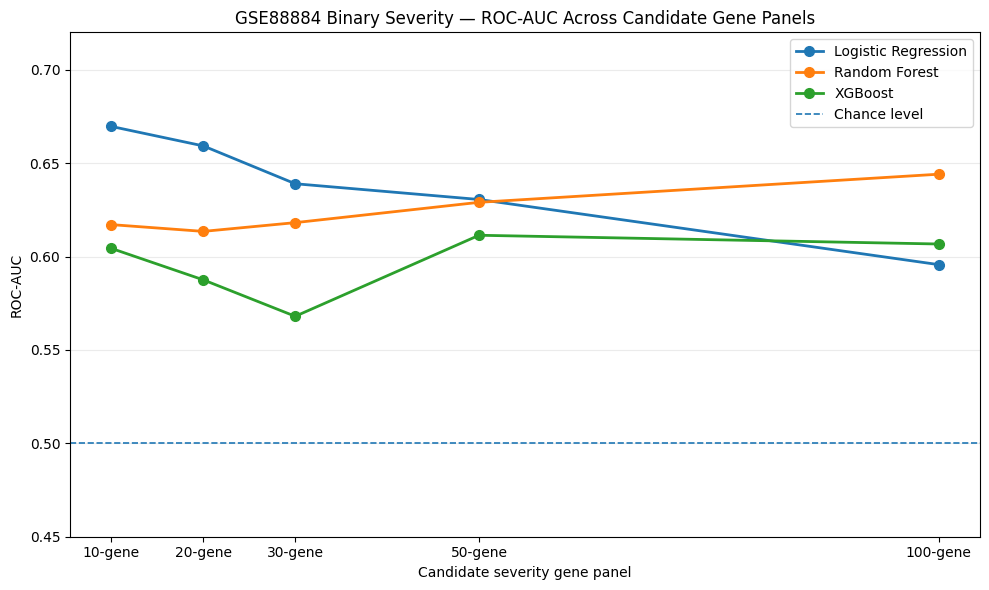


✓ ROC-AUC graph saved:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/results/GSE88884_binary_severity_ROCAUC_comparison.png


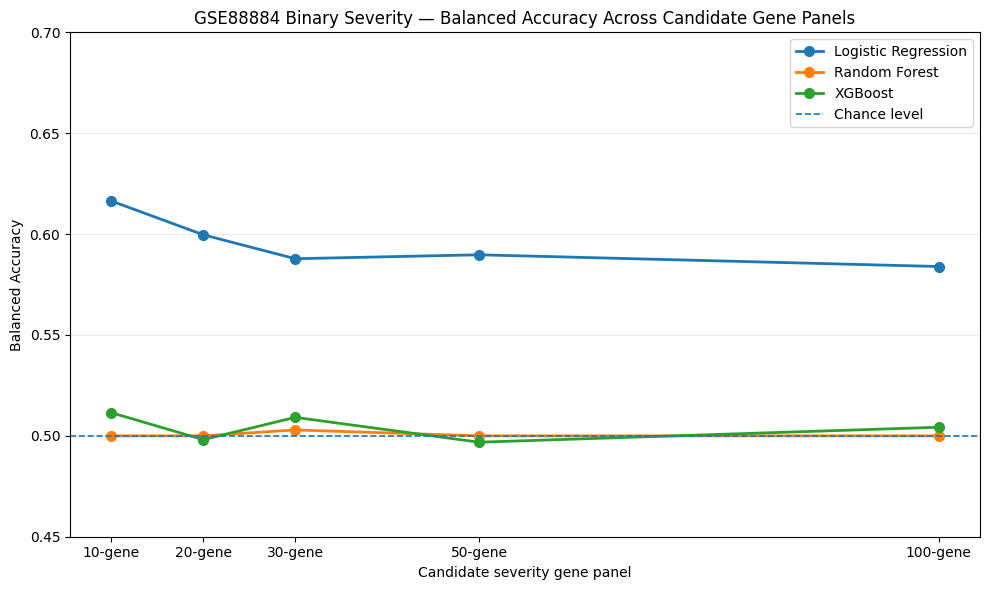


✓ Balanced Accuracy graph saved:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/results/GSE88884_binary_severity_balanced_accuracy_comparison.png


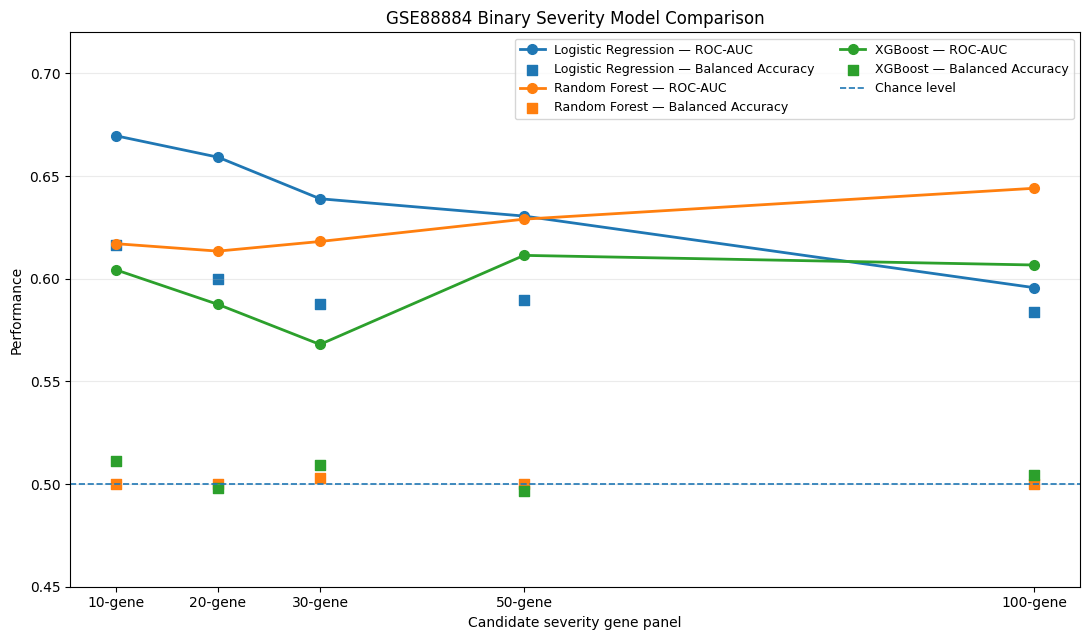


✓ Combined graph saved:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/results/GSE88884_binary_severity_model_comparison.png

✓ Numerical results saved:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/results/GSE88884_binary_severity_model_comparison.csv

BEST BINARY SEVERITY MODEL
Panel              : 10 genes
Model              : Logistic Regression
ROC-AUC            : 0.6696
PR-AUC              : 0.1839
Balanced Accuracy  : 0.6164

✓ ALL BINARY SEVERITY GRAPHS COMPLETE


In [27]:
# ============================================================
# GSE88884 — BINARY SEVERITY MODEL PERFORMANCE GRAPHS
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 90)
print("GSE88884 — BINARY SEVERITY MODEL PERFORMANCE GRAPHS")
print("=" * 90)

# ============================================================
# BUILD CLEAN RESULTS DATAFRAME
# ============================================================

plot_df = pd.DataFrame({

    "Panel": [
        10,10,10,
        20,20,20,
        30,30,30,
        50,50,50,
        100,100,100
    ],

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",

        "Logistic Regression",
        "Random Forest",
        "XGBoost",

        "Logistic Regression",
        "Random Forest",
        "XGBoost",

        "Logistic Regression",
        "Random Forest",
        "XGBoost",

        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "ROC_AUC": [
        0.669622,
        0.617066,
        0.604332,

        0.659199,
        0.613445,
        0.587500,

        0.638951,
        0.618134,
        0.567995,

        0.630520,
        0.629004,
        0.611375,

        0.595654,
        0.644055,
        0.606693
    ],

    "PR_AUC": [
        0.183876,
        0.147957,
        0.143177,

        0.179845,
        0.144907,
        0.132756,

        0.176121,
        0.142554,
        0.135942,

        0.175091,
        0.146937,
        0.137499,

        0.147805,
        0.148928,
        0.137010
    ],

    "Balanced_Accuracy": [
        0.616396,
        0.500000,
        0.511465,

        0.599653,
        0.500000,
        0.498107,

        0.587788,
        0.502924,
        0.509172,

        0.589741,
        0.500000,
        0.496845,

        0.583930,
        0.500000,
        0.504271
    ]
})

print("\n✓ Results dataframe created")
print(f"Rows: {len(plot_df)}")

display(plot_df)

# ============================================================
# CREATE RESULTS DIRECTORY IF NEEDED
# ============================================================

RESULTS_DIR = (
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/results"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

# ============================================================
# GRAPH 1 — ROC-AUC
# ============================================================

panels = [10, 20, 30, 50, 100]

plt.figure(figsize=(10, 6))

for model in [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]:

    temp = (
        plot_df[
            plot_df["Model"] == model
        ]
        .set_index("Panel")
        .loc[panels]
    )

    plt.plot(
        panels,
        temp["ROC_AUC"],
        marker="o",
        linewidth=2,
        markersize=7,
        label=model
    )

plt.axhline(
    0.50,
    linestyle="--",
    linewidth=1.2,
    label="Chance level"
)

plt.xlabel(
    "Candidate severity gene panel"
)

plt.ylabel(
    "ROC-AUC"
)

plt.title(
    "GSE88884 Binary Severity — ROC-AUC Across Candidate Gene Panels"
)

plt.xticks(
    panels,
    [f"{p}-gene" for p in panels]
)

plt.ylim(
    0.45,
    0.72
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

roc_path = os.path.join(
    RESULTS_DIR,
    "GSE88884_binary_severity_ROCAUC_comparison.png"
)

plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✓ ROC-AUC graph saved:")
print(roc_path)

# ============================================================
# GRAPH 2 — BALANCED ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

for model in [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]:

    temp = (
        plot_df[
            plot_df["Model"] == model
        ]
        .set_index("Panel")
        .loc[panels]
    )

    plt.plot(
        panels,
        temp["Balanced_Accuracy"],
        marker="o",
        linewidth=2,
        markersize=7,
        label=model
    )

plt.axhline(
    0.50,
    linestyle="--",
    linewidth=1.2,
    label="Chance level"
)

plt.xlabel(
    "Candidate severity gene panel"
)

plt.ylabel(
    "Balanced Accuracy"
)

plt.title(
    "GSE88884 Binary Severity — Balanced Accuracy Across Candidate Gene Panels"
)

plt.xticks(
    panels,
    [f"{p}-gene" for p in panels]
)

plt.ylim(
    0.45,
    0.70
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

balanced_path = os.path.join(
    RESULTS_DIR,
    "GSE88884_binary_severity_balanced_accuracy_comparison.png"
)

plt.savefig(
    balanced_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✓ Balanced Accuracy graph saved:")
print(balanced_path)

# ============================================================
# GRAPH 3 — COMBINED ROC-AUC + BALANCED ACCURACY
# ============================================================

plt.figure(figsize=(11, 6.5))

for model in [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]:

    temp = (
        plot_df[
            plot_df["Model"] == model
        ]
        .set_index("Panel")
        .loc[panels]
    )

    # ROC-AUC
    plt.plot(
        panels,
        temp["ROC_AUC"],
        marker="o",
        linewidth=2,
        markersize=7,
        label=f"{model} — ROC-AUC"
    )

    # Balanced Accuracy
    plt.scatter(
        panels,
        temp["Balanced_Accuracy"],
        marker="s",
        s=55,
        label=f"{model} — Balanced Accuracy"
    )

plt.axhline(
    0.50,
    linestyle="--",
    linewidth=1.2,
    label="Chance level"
)

plt.xlabel(
    "Candidate severity gene panel"
)

plt.ylabel(
    "Performance"
)

plt.title(
    "GSE88884 Binary Severity Model Comparison"
)

plt.xticks(
    panels,
    [f"{p}-gene" for p in panels]
)

plt.ylim(
    0.45,
    0.72
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend(
    ncol=2,
    fontsize=9
)

plt.tight_layout()

combined_path = os.path.join(
    RESULTS_DIR,
    "GSE88884_binary_severity_model_comparison.png"
)

plt.savefig(
    combined_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✓ Combined graph saved:")
print(combined_path)

# ============================================================
# SAVE NUMERICAL RESULTS
# ============================================================

results_csv = os.path.join(
    RESULTS_DIR,
    "GSE88884_binary_severity_model_comparison.csv"
)

plot_df.to_csv(
    results_csv,
    index=False
)

print("\n✓ Numerical results saved:")
print(results_csv)

# ============================================================
# BEST MODEL
# ============================================================

best_idx = plot_df["ROC_AUC"].idxmax()
best = plot_df.loc[best_idx]

print("\n" + "=" * 90)
print("BEST BINARY SEVERITY MODEL")
print("=" * 90)

print(
    f"Panel              : {int(best['Panel'])} genes"
)

print(
    f"Model              : {best['Model']}"
)

print(
    f"ROC-AUC            : {best['ROC_AUC']:.4f}"
)

print(
    f"PR-AUC              : {best['PR_AUC']:.4f}"
)

print(
    f"Balanced Accuracy  : {best['Balanced_Accuracy']:.4f}"
)

print("\n✓ ALL BINARY SEVERITY GRAPHS COMPLETE")

GSE88884 — THREE-LEVEL SEVERITY MODEL PERFORMANCE GRAPH

✓ Three-level results loaded
    Panel                Model   ROC_AUC    PR_AUC  Balanced_Accuracy
0      10  Logistic Regression  0.669622  0.183876           0.616396
1      10        Random Forest  0.617066  0.147957           0.500000
2      10              XGBoost  0.604332  0.143177           0.511465
3      20  Logistic Regression  0.659199  0.179845           0.599653
4      20        Random Forest  0.613445  0.144907           0.500000
5      20              XGBoost  0.587500  0.132756           0.498107
6      30  Logistic Regression  0.638951  0.176121           0.587788
7      30        Random Forest  0.618134  0.142554           0.502924
8      30              XGBoost  0.567995  0.135942           0.509172
9      50  Logistic Regression  0.630520  0.175091           0.589741
10     50        Random Forest  0.629004  0.146937           0.500000
11     50              XGBoost  0.611375  0.137499           0.496845
12  

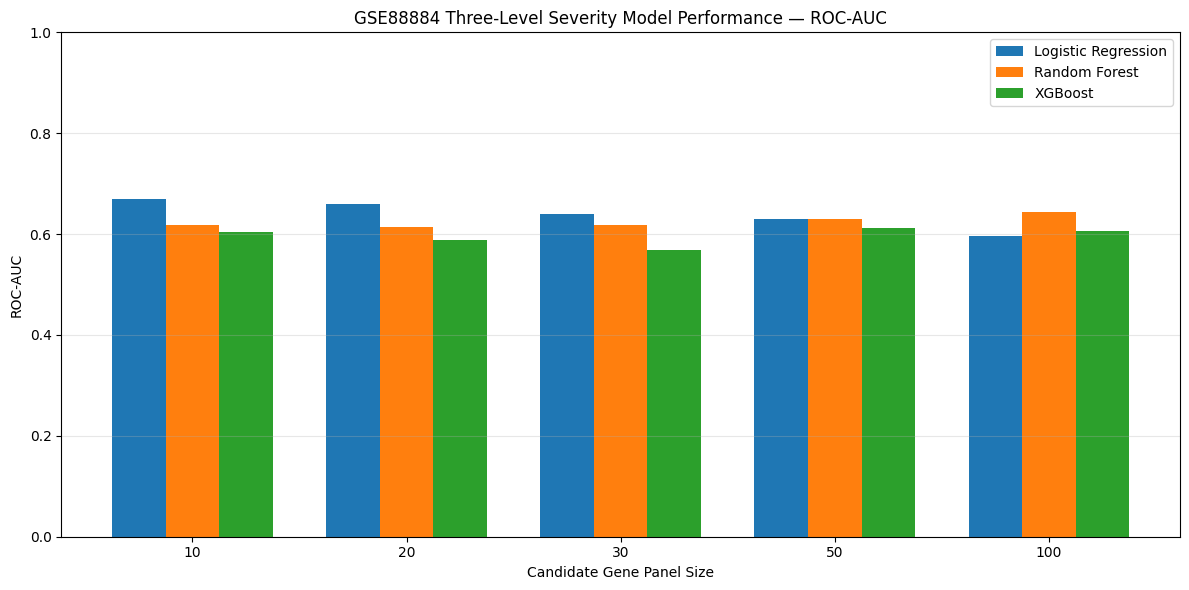

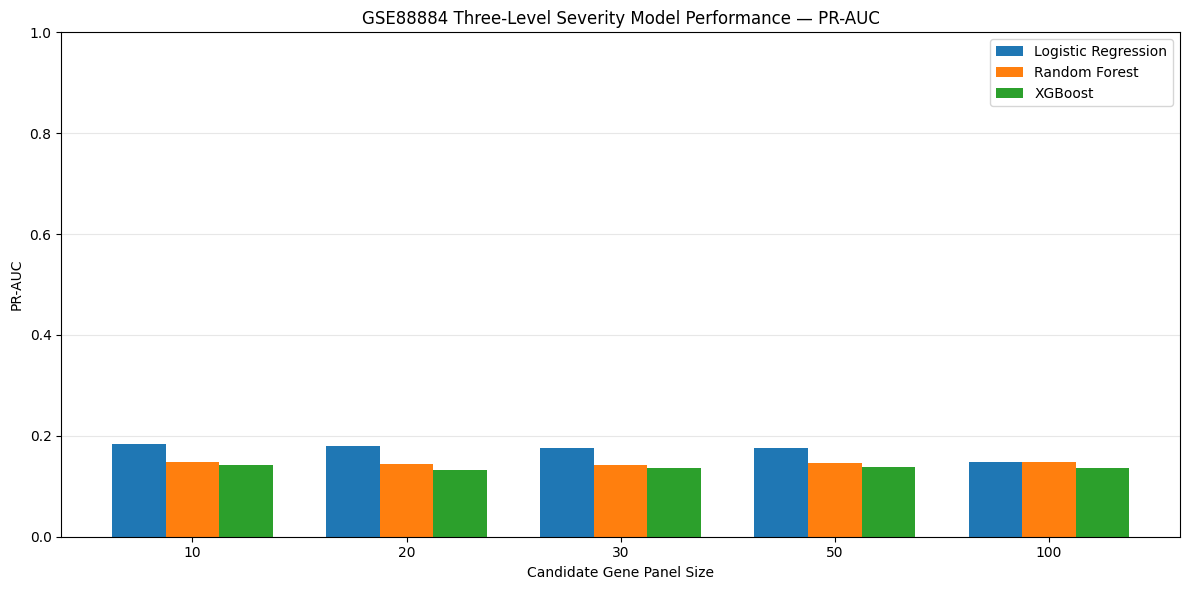

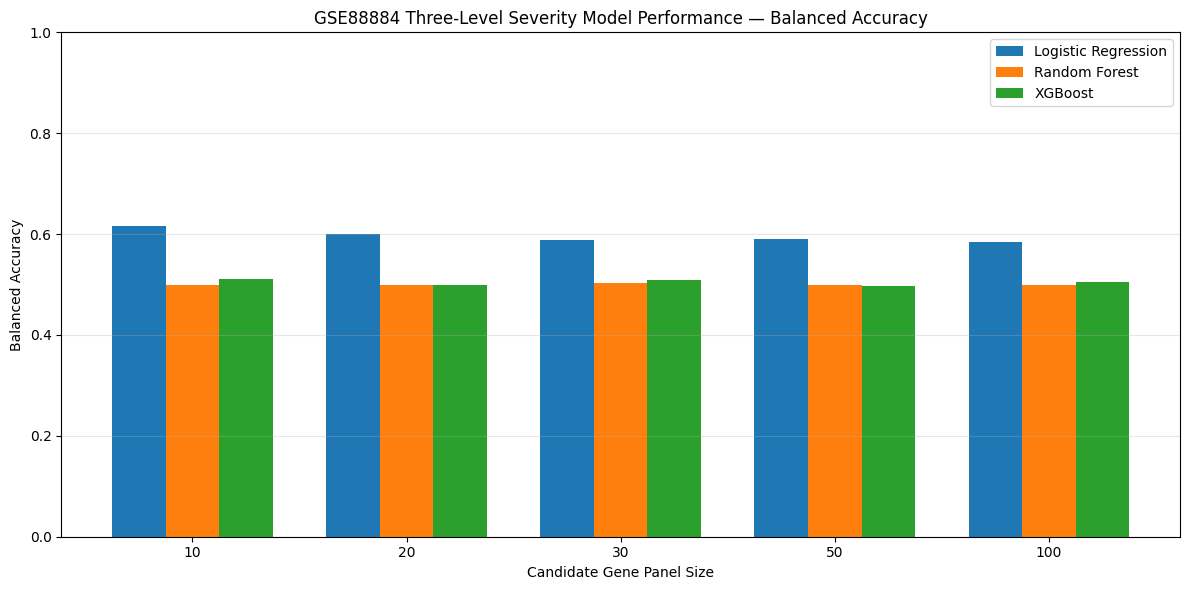

In [28]:
# ============================================================
# GSE88884 — THREE-LEVEL SEVERITY MODEL PERFORMANCE GRAPH
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("=" * 90)
print("GSE88884 — THREE-LEVEL SEVERITY MODEL PERFORMANCE GRAPH")
print("=" * 90)

# ------------------------------------------------------------
# THREE-LEVEL MODEL RESULTS
# ------------------------------------------------------------

three_level_results = pd.DataFrame({

    "Panel": [
        10, 10, 10,
        20, 20, 20,
        30, 30, 30,
        50, 50, 50,
        100, 100, 100
    ],

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",

        "Logistic Regression",
        "Random Forest",
        "XGBoost",

        "Logistic Regression",
        "Random Forest",
        "XGBoost",

        "Logistic Regression",
        "Random Forest",
        "XGBoost",

        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "ROC_AUC": [
        0.669622, 0.617066, 0.604332,
        0.659199, 0.613445, 0.587500,
        0.638951, 0.618134, 0.567995,
        0.630520, 0.629004, 0.611375,
        0.595654, 0.644055, 0.606693
    ],

    "PR_AUC": [
        0.183876, 0.147957, 0.143177,
        0.179845, 0.144907, 0.132756,
        0.176121, 0.142554, 0.135942,
        0.175091, 0.146937, 0.137499,
        0.147805, 0.148928, 0.137010
    ],

    "Balanced_Accuracy": [
        0.616396, 0.500000, 0.511465,
        0.599653, 0.500000, 0.498107,
        0.587788, 0.502924, 0.509172,
        0.589741, 0.500000, 0.496845,
        0.583930, 0.500000, 0.504271
    ]
})

print("\n✓ Three-level results loaded")
print(three_level_results)

# ============================================================
# GRAPH 1 — ROC-AUC
# ============================================================

models = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

panels = [10, 20, 30, 50, 100]

x = np.arange(len(panels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, model in enumerate(models):

    values = (
        three_level_results[
            three_level_results["Model"] == model
        ]
        .sort_values("Panel")["ROC_AUC"]
        .values
    )

    ax.bar(
        x + (i - 1) * width,
        values,
        width,
        label=model
    )

ax.set_xlabel("Candidate Gene Panel Size")
ax.set_ylabel("ROC-AUC")
ax.set_title(
    "GSE88884 Three-Level Severity Model Performance — ROC-AUC"
)

ax.set_xticks(x)
ax.set_xticklabels(panels)

ax.set_ylim(0, 1)

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# GRAPH 2 — PR-AUC
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

for i, model in enumerate(models):

    values = (
        three_level_results[
            three_level_results["Model"] == model
        ]
        .sort_values("Panel")["PR_AUC"]
        .values
    )

    ax.bar(
        x + (i - 1) * width,
        values,
        width,
        label=model
    )

ax.set_xlabel("Candidate Gene Panel Size")
ax.set_ylabel("PR-AUC")
ax.set_title(
    "GSE88884 Three-Level Severity Model Performance — PR-AUC"
)

ax.set_xticks(x)
ax.set_xticklabels(panels)

ax.set_ylim(0, 1)

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# GRAPH 3 — BALANCED ACCURACY
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

for i, model in enumerate(models):

    values = (
        three_level_results[
            three_level_results["Model"] == model
        ]
        .sort_values("Panel")["Balanced_Accuracy"]
        .values
    )

    ax.bar(
        x + (i - 1) * width,
        values,
        width,
        label=model
    )

ax.set_xlabel("Candidate Gene Panel Size")
ax.set_ylabel("Balanced Accuracy")
ax.set_title(
    "GSE88884 Three-Level Severity Model Performance — Balanced Accuracy"
)

ax.set_xticks(x)
ax.set_xticklabels(panels)

ax.set_ylim(0, 1)

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# SAVE
# ============================================================

GRAPH_DIR = (
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis/"
    "figures"
)

import os
os.makedirs(GRAPH_DIR, exist_ok=True)

# Replot and save each figure individually if needed

In [29]:
# ============================================================
# FIND EXISTING GSE88884 GENE-LEVEL MATRIX
# ============================================================

print("=" * 90)
print("SEARCHING FOR EXISTING GSE88884 GENE-LEVEL MATRIX")
print("=" * 90)

import pandas as pd
import numpy as np

candidates = []

# IMPORTANT:
# list(...) prevents "dictionary changed size during iteration"
all_objects = list(globals().items())

for name, obj in all_objects:

    if isinstance(obj, pd.DataFrame):

        rows, cols = obj.shape

        # Exact expected matrix
        if rows == 24856 and cols == 1756:
            candidates.append(
                (name, obj.shape)
            )

# ------------------------------------------------------------
# SHOW EXACT MATCHES
# ------------------------------------------------------------

print("\n" + "-" * 90)
print("EXACT 24,856 × 1,756 MATRICES")
print("-" * 90)

if candidates:

    for name, shape in candidates:
        print(f"✓ {name:<40} {shape}")

else:

    print("No exact 24,856 × 1,756 matrix found.")

# ------------------------------------------------------------
# SHOW OTHER LARGE MATRICES WITH 1,756 SAMPLES
# ------------------------------------------------------------

print("\n" + "-" * 90)
print("OTHER LARGE DATAFRAMES WITH 1,756 SAMPLES")
print("-" * 90)

large_candidates = []

for name, obj in all_objects:

    if isinstance(obj, pd.DataFrame):

        rows, cols = obj.shape

        if cols == 1756 and rows > 10000:

            large_candidates.append(
                (name, obj.shape)
            )

if large_candidates:

    for name, shape in large_candidates:
        print(f"{name:<40} {shape}")

else:

    print("No large 1,756-sample DataFrame found.")

# ------------------------------------------------------------
# SHOW ALL RELEVANT DATAFRAME NAMES
# ------------------------------------------------------------

print("\n" + "-" * 90)
print("DATAFRAMES CONTAINING 1,756 SAMPLES")
print("-" * 90)

for name, obj in all_objects:

    if isinstance(obj, pd.DataFrame):

        if 1756 in obj.shape:
            print(
                f"{name:<40} {obj.shape}"
            )

SEARCHING FOR EXISTING GSE88884 GENE-LEVEL MATRIX

------------------------------------------------------------------------------------------
EXACT 24,856 × 1,756 MATRICES
------------------------------------------------------------------------------------------
✓ X_severity_gene                          (24856, 1756)
✓ X_assoc                                  (24856, 1756)

------------------------------------------------------------------------------------------
OTHER LARGE DATAFRAMES WITH 1,756 SAMPLES
------------------------------------------------------------------------------------------
X_severity_probe                         (92343, 1756)
X_severity_gene                          (24856, 1756)
X_assoc                                  (24856, 1756)

------------------------------------------------------------------------------------------
DATAFRAMES CONTAINING 1,756 SAMPLES
------------------------------------------------------------------------------------------
severity_df   

In [30]:
# ============================================================
# GSE88884 — PREPARE SLEDAI REGRESSION PANELS
# ============================================================

print("=" * 90)
print("GSE88884 — PREPARING SLEDAI REGRESSION PANELS")
print("=" * 90)

# ------------------------------------------------------------
# 1. USE FRESH GENE-LEVEL MATRIX
# ------------------------------------------------------------

gene_expression = X_severity_gene.copy()

print("\nGene-level expression:")
print("Shape:", gene_expression.shape)

# ------------------------------------------------------------
# 2. CONTINUOUS SLEDAI PHENOTYPE
# ------------------------------------------------------------

regression_metadata = severity_df.copy()

regression_metadata["SLEDAI"] = pd.to_numeric(
    regression_metadata["SLEDAI"],
    errors="coerce"
)

regression_metadata = regression_metadata.dropna(
    subset=["SLEDAI"]
)

print("\nValid SLEDAI samples:",
      len(regression_metadata))

# ------------------------------------------------------------
# 3. ALIGN EXPRESSION WITH SLEDAI
# ------------------------------------------------------------

common_samples = (
    gene_expression.columns
    .intersection(
        regression_metadata["sample_id"]
    )
)

print("Common samples:", len(common_samples))

# Expression:
# genes × samples → samples × genes

X_regression = gene_expression[
    common_samples
].T.copy()

# Phenotype:
regression_metadata = (
    regression_metadata
    .set_index("sample_id")
    .loc[common_samples]
)

y_sledai = regression_metadata[
    "SLEDAI"
].copy()

print("\nRegression matrix:")
print("X:", X_regression.shape)
print("y:", y_sledai.shape)

print("\nSLEDAI distribution:")
print(y_sledai.describe())

# ------------------------------------------------------------
# 4. SEVERITY CANDIDATE GENES
# ------------------------------------------------------------

severity_candidates = (
    severity_results[
        (severity_results["FDR"] < 0.05) &
        (severity_results["Abs_Rho"] >= 0.15)
    ]
    .sort_values(
        "Abs_Rho",
        ascending=False
    )
    .copy()
)

print("\n" + "-" * 90)
print("SEVERITY CANDIDATE GENES")
print("-" * 90)

print(
    "Genes passing criteria:",
    len(severity_candidates)
)

# ------------------------------------------------------------
# 5. KEEP ONLY GENES PRESENT IN EXPRESSION
# ------------------------------------------------------------

candidate_genes = [
    gene
    for gene in severity_candidates["Gene"]
    if gene in X_regression.columns
]

print(
    "Genes available in expression:",
    len(candidate_genes)
)

# ------------------------------------------------------------
# 6. CREATE CANDIDATE REGRESSION PANELS
# ------------------------------------------------------------

panel_sizes = [
    10,
    20,
    30,
    50,
    100
]

regression_panels = {}

print("\n" + "-" * 90)
print("CANDIDATE REGRESSION PANELS")
print("-" * 90)

for size in panel_sizes:

    genes = candidate_genes[:size]

    X_panel = X_regression[
        genes
    ].copy()

    regression_panels[size] = X_panel

    print(
        f"{size:3d}-gene panel: "
        f"{X_panel.shape}"
    )

# ------------------------------------------------------------
# 7. ALIGNMENT CHECK
# ------------------------------------------------------------

for size, X_panel in regression_panels.items():

    assert X_panel.index.equals(
        y_sledai.index
    )

# ------------------------------------------------------------
# 8. FINAL CHECK
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("FINAL REGRESSION DATASET")
print("=" * 90)

print(
    "Samples:",
    X_regression.shape[0]
)

print(
    "Genes:",
    X_regression.shape[1]
)

print(
    "SLEDAI range:",
    y_sledai.min(),
    "to",
    y_sledai.max()
)

print("\nCandidate panels:")

for size, X_panel in regression_panels.items():

    print(
        f"  {size:3d} genes → "
        f"{X_panel.shape[0]} samples × "
        f"{X_panel.shape[1]} genes"
    )

print("\n✓ X_severity_gene used")
print("✓ Continuous SLEDAI retained")
print("✓ 601 severity candidate genes available")
print("✓ 10/20/30/50/100-gene panels constructed")
print("✓ Samples aligned")
print("✓ Ready for regression modelling")

GSE88884 — PREPARING SLEDAI REGRESSION PANELS

Gene-level expression:
Shape: (24856, 1756)

Valid SLEDAI samples: 1756
Common samples: 1756

Regression matrix:
X: (1756, 24856)
y: (1756,)

SLEDAI distribution:
count    1756.000000
mean       10.370159
std         3.762417
min         2.000000
25%         8.000000
50%        10.000000
75%        12.000000
max        40.000000
Name: SLEDAI, dtype: float64

------------------------------------------------------------------------------------------
SEVERITY CANDIDATE GENES
------------------------------------------------------------------------------------------
Genes passing criteria: 601
Genes available in expression: 601

------------------------------------------------------------------------------------------
CANDIDATE REGRESSION PANELS
------------------------------------------------------------------------------------------
 10-gene panel: (1756, 10)
 20-gene panel: (1756, 20)
 30-gene panel: (1756, 30)
 50-gene panel: (1756, 50)
100

In [31]:
# ============================================================
# GSE88884 — SLEDAI REGRESSION MODEL COMPARISON
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from scipy.stats import pearsonr, spearmanr

from xgboost import XGBRegressor

print("=" * 90)
print("GSE88884 — SLEDAI REGRESSION MODEL COMPARISON")
print("=" * 90)

# ============================================================
# 1. COMMON TRAIN / TEST SPLIT
# ============================================================

# Use exactly the same samples in every model/panel
train_idx, test_idx = train_test_split(
    np.arange(len(y_sledai)),
    test_size=0.20,
    random_state=42
)

y_train = y_sledai.iloc[train_idx]
y_test = y_sledai.iloc[test_idx]

print("\nDataset:")
print("Total samples :", len(y_sledai))
print("Training      :", len(train_idx))
print("Testing       :", len(test_idx))

print("\nTraining SLEDAI:")
print(y_train.describe())

print("\nTesting SLEDAI:")
print(y_test.describe())

# ============================================================
# 2. MODEL DEFINITIONS
# ============================================================

models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        max_features="sqrt",
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

# ============================================================
# 3. RESULTS STORAGE
# ============================================================

regression_results = []

regression_predictions = {}

# ============================================================
# 4. RUN ALL PANELS × ALL MODELS
# ============================================================

for panel_size, X_panel in regression_panels.items():

    print("\n" + "-" * 90)
    print(
        f"SLEDAI REGRESSION PANEL: {panel_size} GENES"
    )
    print("-" * 90)

    X_train = X_panel.iloc[train_idx].copy()
    X_test = X_panel.iloc[test_idx].copy()

    # --------------------------------------------------------
    # Scale ONLY for Linear Regression
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_test_scaled = scaler.transform(
        X_test
    )

    for model_name, model in models.items():

        print(
            f"\nRunning {model_name}..."
        )

        # ----------------------------------------------------
        # Linear Regression
        # ----------------------------------------------------

        if model_name == "Linear Regression":

            model.fit(
                X_train_scaled,
                y_train
            )

            y_pred = model.predict(
                X_test_scaled
            )

        # ----------------------------------------------------
        # Tree-based models
        # ----------------------------------------------------

        else:

            model.fit(
                X_train,
                y_train
            )

            y_pred = model.predict(
                X_test
            )

        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                y_pred
            )
        )

        mae = mean_absolute_error(
            y_test,
            y_pred
        )

        r2 = r2_score(
            y_test,
            y_pred
        )

        pearson_r, pearson_p = pearsonr(
            y_test,
            y_pred
        )

        spearman_r, spearman_p = spearmanr(
            y_test,
            y_pred
        )

        regression_results.append({

            "Panel": panel_size,

            "Model": model_name,

            "RMSE": rmse,

            "MAE": mae,

            "R2": r2,

            "Pearson_r": pearson_r,

            "Pearson_p": pearson_p,

            "Spearman_r": spearman_r,

            "Spearman_p": spearman_p

        })

        # ----------------------------------------------------
        # SAVE PREDICTIONS
        # ----------------------------------------------------

        key = (
            f"{panel_size}_"
            f"{model_name.replace(' ', '_')}"
        )

        regression_predictions[key] = pd.DataFrame({

            "Sample": y_test.index,

            "Observed_SLEDAI": y_test.values,

            "Predicted_SLEDAI": y_pred

        })

        print(
            f"  RMSE      = {rmse:.4f}"
        )

        print(
            f"  MAE       = {mae:.4f}"
        )

        print(
            f"  R²        = {r2:.4f}"
        )

        print(
            f"  Pearson r = {pearson_r:.4f}"
        )

        print(
            f"  Spearman r= {spearman_r:.4f}"
        )

# ============================================================
# 5. FINAL RESULTS TABLE
# ============================================================

regression_results_df = pd.DataFrame(
    regression_results
)

regression_results_df = (
    regression_results_df
    .sort_values(
        ["R2", "RMSE"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 90)
print("FINAL SLEDAI REGRESSION MODEL COMPARISON")
print("=" * 90)

display(
    regression_results_df.round(4)
)

# ============================================================
# 6. BEST MODEL
# ============================================================

best_model = (
    regression_results_df
    .sort_values(
        ["R2", "RMSE"],
        ascending=[False, True]
    )
    .iloc[0]
)

print("\n" + "=" * 90)
print("BEST REGRESSION MODEL")
print("=" * 90)

print(
    f"Panel       : {best_model['Panel']} genes"
)

print(
    f"Model       : {best_model['Model']}"
)

print(
    f"R²          : {best_model['R2']:.4f}"
)

print(
    f"RMSE        : {best_model['RMSE']:.4f}"
)

print(
    f"MAE         : {best_model['MAE']:.4f}"
)

print(
    f"Pearson r   : {best_model['Pearson_r']:.4f}"
)

print(
    f"Spearman r  : {best_model['Spearman_r']:.4f}"
)

# ============================================================
# 7. SAVE RESULTS
# ============================================================

RESULTS_DIR = (
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

results_path = os.path.join(
    RESULTS_DIR,
    "GSE88884_SLEDAI_regression_model_comparison.csv"
)

regression_results_df.to_csv(
    results_path,
    index=False
)

print("\n✓ Regression comparison saved:")
print(results_path)

GSE88884 — SLEDAI REGRESSION MODEL COMPARISON

Dataset:
Total samples : 1756
Training      : 1404
Testing       : 352

Training SLEDAI:
count    1404.000000
mean       10.383903
std         3.753457
min         2.000000
25%         8.000000
50%        10.000000
75%        12.000000
max        40.000000
Name: SLEDAI, dtype: float64

Testing SLEDAI:
count    352.000000
mean      10.315341
std        3.802832
min        4.000000
25%        8.000000
50%       10.000000
75%       12.000000
max       26.000000
Name: SLEDAI, dtype: float64

------------------------------------------------------------------------------------------
SLEDAI REGRESSION PANEL: 10 GENES
------------------------------------------------------------------------------------------

Running Linear Regression...
  RMSE      = 3.6649
  MAE       = 2.7860
  R²        = 0.0686
  Pearson r = 0.2659
  Spearman r= 0.2360

Running Random Forest...
  RMSE      = 3.6662
  MAE       = 2.7622
  R²        = 0.0679
  Pearson r = 0.2699

,Panel,Model,RMSE,MAE,R2,Pearson_r,Pearson_p,Spearman_r,Spearman_p
0,100,Random Forest,3.6170,2.7459,0.0928,0.3066,0.0,0.2742,0.0000
1,50,Random Forest,3.6356,2.7627,0.0834,0.2927,0.0,0.2746,0.0000
2,20,Random Forest,3.6552,2.7646,0.0735,0.2795,0.0,0.2669,0.0000
3,30,Random Forest,3.6571,2.7603,0.0725,0.2793,0.0,0.2556,0.0000
4,10,Linear Regression,3.6649,2.7860,0.0686,0.2659,0.0,0.2360,0.0000
5,10,Random Forest,3.6662,2.7622,0.0679,0.2699,0.0,0.2645,0.0000
6,20,Linear Regression,3.6884,2.8026,0.0566,0.2494,0.0,0.2079,0.0001
7,50,Linear Regression,3.6923,2.7922,0.0546,0.2604,0.0,0.2160,0.0000
8,30,Linear Regression,3.6993,2.8250,0.0510,0.2471,0.0,0.1931,0.0003
9,100,XGBoost,3.7038,2.8045,0.0487,0.2600,0.0,0.2576,0.0000



BEST REGRESSION MODEL
Panel       : 100 genes
Model       : Random Forest
R²          : 0.0928
RMSE        : 3.6170
MAE         : 2.7459
Pearson r   : 0.3066
Spearman r  : 0.2742

✓ Regression comparison saved:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/GSE88884_SLEDAI_regression_model_comparison.csv


GSE88884 — SLEDAI REGRESSION R² COMPARISON


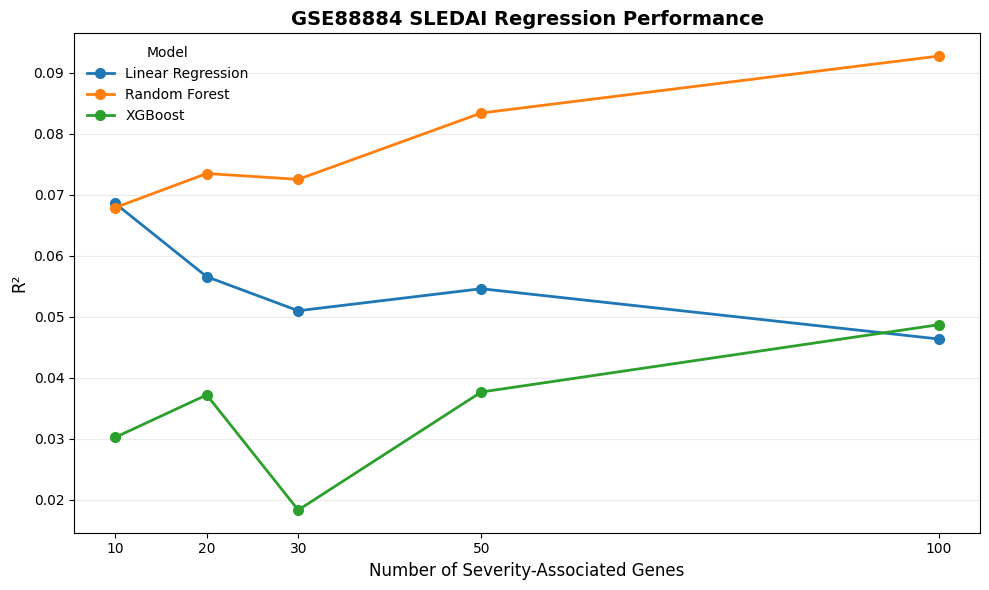


✓ R² graph saved:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/GSE88884_SLEDAI_R2_comparison.png


In [32]:
# ============================================================
# GSE88884 — REGRESSION R² COMPARISON
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

print("=" * 90)
print("GSE88884 — SLEDAI REGRESSION R² COMPARISON")
print("=" * 90)

# Use the existing results dataframe
plot_df = regression_results_df.copy()

# Ensure correct ordering
panel_order = [10, 20, 30, 50, 100]

plot_df["Panel"] = plot_df["Panel"].astype(int)

plot_df = plot_df.sort_values(
    ["Panel", "Model"]
)

models_order = [
    "Linear Regression",
    "Random Forest",
    "XGBoost"
]

plt.figure(figsize=(10, 6))

for model in models_order:

    subset = plot_df[
        plot_df["Model"] == model
    ].sort_values("Panel")

    plt.plot(
        subset["Panel"],
        subset["R2"],
        marker="o",
        linewidth=2,
        markersize=7,
        label=model
    )

plt.xticks(panel_order)

plt.xlabel(
    "Number of Severity-Associated Genes",
    fontsize=12
)

plt.ylabel(
    "R²",
    fontsize=12
)

plt.title(
    "GSE88884 SLEDAI Regression Performance",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    title="Model",
    frameon=False
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis/"
    "GSE88884_SLEDAI_R2_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print(
    "\n✓ R² graph saved:"
)
print(
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis/"
    "GSE88884_SLEDAI_R2_comparison.png"
)

GSE88884 — SLEDAI REGRESSION RMSE COMPARISON


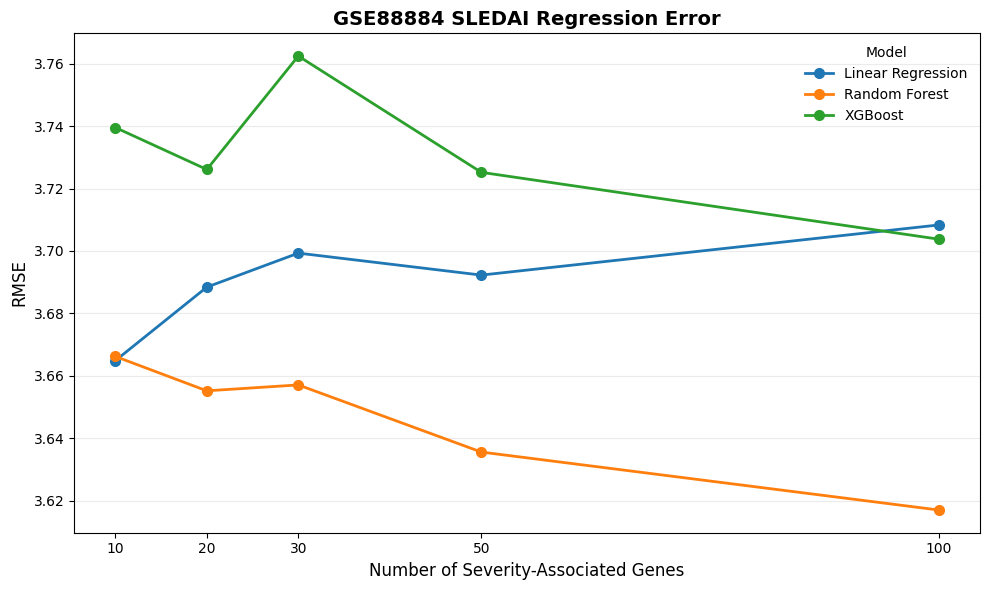


✓ RMSE graph saved


In [33]:
# ============================================================
# GSE88884 — REGRESSION RMSE COMPARISON
# ============================================================

print("=" * 90)
print("GSE88884 — SLEDAI REGRESSION RMSE COMPARISON")
print("=" * 90)

plot_df = regression_results_df.copy()

plot_df["Panel"] = plot_df["Panel"].astype(int)

models_order = [
    "Linear Regression",
    "Random Forest",
    "XGBoost"
]

plt.figure(figsize=(10, 6))

for model in models_order:

    subset = plot_df[
        plot_df["Model"] == model
    ].sort_values("Panel")

    plt.plot(
        subset["Panel"],
        subset["RMSE"],
        marker="o",
        linewidth=2,
        markersize=7,
        label=model
    )

plt.xticks(
    [10, 20, 30, 50, 100]
)

plt.xlabel(
    "Number of Severity-Associated Genes",
    fontsize=12
)

plt.ylabel(
    "RMSE",
    fontsize=12
)

plt.title(
    "GSE88884 SLEDAI Regression Error",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    title="Model",
    frameon=False
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis/"
    "GSE88884_SLEDAI_RMSE_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n✓ RMSE graph saved")

GSE88884 — OBSERVED VS PREDICTED SLEDAI
R² = 0.0928
Pearson r = 0.3066


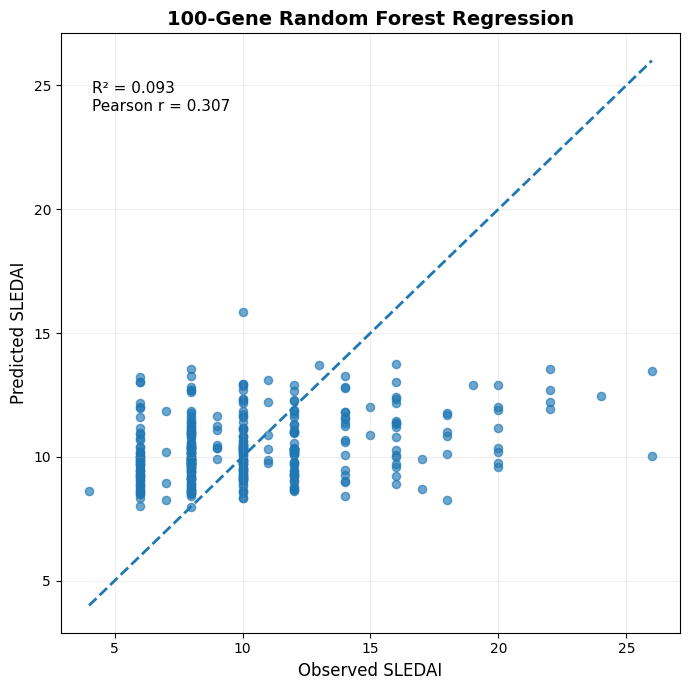


✓ Observed-vs-predicted graph saved


In [34]:
# ============================================================
# GSE88884 — BEST REGRESSION MODEL
# OBSERVED VS PREDICTED SLEDAI
# ============================================================

print("=" * 90)
print("GSE88884 — OBSERVED VS PREDICTED SLEDAI")
print("=" * 90)

pred_df = regression_predictions[
    "100_Random_Forest"
].copy()

observed = pred_df[
    "Observed_SLEDAI"
]

predicted = pred_df[
    "Predicted_SLEDAI"
]

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

from sklearn.metrics import r2_score
from scipy.stats import pearsonr

r2 = r2_score(
    observed,
    predicted
)

pearson_r, pearson_p = pearsonr(
    observed,
    predicted
)

print(
    f"R² = {r2:.4f}"
)

print(
    f"Pearson r = {pearson_r:.4f}"
)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 7)
)

plt.scatter(
    observed,
    predicted,
    alpha=0.65,
    s=35
)

# Identity line
min_value = min(
    observed.min(),
    predicted.min()
)

max_value = max(
    observed.max(),
    predicted.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Observed SLEDAI",
    fontsize=12
)

plt.ylabel(
    "Predicted SLEDAI",
    fontsize=12
)

plt.title(
    "100-Gene Random Forest Regression",
    fontsize=14,
    fontweight="bold"
)

plt.text(
    0.05,
    0.92,
    f"R² = {r2:.3f}\n"
    f"Pearson r = {pearson_r:.3f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis/"
    "GSE88884_100gene_RF_observed_vs_predicted.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n✓ Observed-vs-predicted graph saved")

In [35]:
# ==========================================================================================
# GSE88884 — FINAL 13-GENE DIAGNOSTIC PANEL vs SEVERITY GENES
# ==========================================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("=" * 90)
print("GSE88884 — DIAGNOSTIC–SEVERITY GENE OVERLAP ANALYSIS")
print("=" * 90)

# ==========================================================================================
# 1. FINAL 13-GENE DIAGNOSTIC PANEL
# ==========================================================================================

final_13_genes = [
    "IFI27",
    "RPL5",
    "ZBP1",
    "IFITM1",
    "EPSTI1",
    "EBI2",
    "FCER1A",
    "GADD45A",
    "TNFSF13B",
    "IFIT2",
    "OSBPL10",
    "SCRN1",
    "TNFAIP6"
]

print("\nFINAL 13-GENE DIAGNOSTIC PANEL")
print("-" * 90)

for i, gene in enumerate(final_13_genes, 1):
    print(f"{i:2d}. {gene}")

print(f"\nTotal diagnostic genes: {len(final_13_genes)}")


# ==========================================================================================
# 2. IDENTIFY THE SEVERITY RESULTS TABLE
# ==========================================================================================

print("\n" + "=" * 90)
print("CHECKING SEVERITY RESULTS")
print("=" * 90)

print("severity_results exists:", "severity_results" in globals())

if "severity_results" not in globals():
    raise RuntimeError(
        "severity_results is not available. "
        "Run the genome-wide severity association analysis first."
    )

severity_results_df = severity_results.copy()

print("\nSeverity results shape:", severity_results_df.shape)
print("Severity result columns:")
print(list(severity_results_df.columns))


# ==========================================================================================
# 3. STANDARDIZE GENE COLUMN
# ==========================================================================================

if "Gene" in severity_results_df.columns:
    gene_col = "Gene"
elif "gene" in severity_results_df.columns:
    gene_col = "gene"
elif "SYMBOL" in severity_results_df.columns:
    gene_col = "SYMBOL"
else:
    raise RuntimeError(
        "Could not identify the gene column in severity_results."
    )

severity_results_df[gene_col] = (
    severity_results_df[gene_col]
    .astype(str)
    .str.strip()
    .str.upper()
)

severity_results_df = severity_results_df[
    severity_results_df[gene_col].notna()
    & (severity_results_df[gene_col] != "")
    & (severity_results_df[gene_col] != "NAN")
].copy()


# ==========================================================================================
# 4. RECREATE THE 601 SEVERITY CANDIDATES
# ==========================================================================================

required_cols = ["FDR", "Spearman_Rho"]

missing_cols = [
    c for c in required_cols
    if c not in severity_results_df.columns
]

if missing_cols:
    raise RuntimeError(
        f"Missing required severity columns: {missing_cols}"
    )

severity_candidates = severity_results_df[
    (severity_results_df["FDR"] < 0.05) &
    (severity_results_df["Spearman_Rho"].abs() >= 0.15)
].copy()

severity_candidates = (
    severity_candidates
    .drop_duplicates(subset=[gene_col])
    .reset_index(drop=True)
)

print("\n" + "-" * 90)
print("SEVERITY CANDIDATE FILTER")
print("-" * 90)

print("FDR < 0.05 AND |rho| >= 0.15")
print("Severity candidate genes:", len(severity_candidates))


# ==========================================================================================
# 5. OVERLAP ANALYSIS
# ==========================================================================================

diagnostic_set = set(final_13_genes)

severity_set = set(
    severity_candidates[gene_col].astype(str).str.upper()
)

overlap_genes = sorted(
    diagnostic_set.intersection(severity_set)
)

diagnostic_only = sorted(
    diagnostic_set - severity_set
)

severity_only_count = len(
    severity_set - diagnostic_set
)

print("\n" + "=" * 90)
print("DIAGNOSTIC × SEVERITY OVERLAP")
print("=" * 90)

print(f"\nFinal diagnostic panel:       {len(diagnostic_set)} genes")
print(f"Severity candidate genes:     {len(severity_set)} genes")
print(f"Overlapping genes:             {len(overlap_genes)} genes")

print("\nOVERLAPPING GENES")
print("-" * 90)

for i, gene in enumerate(overlap_genes, 1):
    print(f"{i:2d}. {gene}")

print("\nDiagnostic genes NOT associated with severity")
print("-" * 90)

for i, gene in enumerate(diagnostic_only, 1):
    print(f"{i:2d}. {gene}")


# ==========================================================================================
# 6. BUILD DETAILED OVERLAP TABLE
# ==========================================================================================

overlap_table = severity_candidates[
    severity_candidates[gene_col].isin(overlap_genes)
].copy()

overlap_table = overlap_table.rename(
    columns={gene_col: "Gene"}
)

# Keep the important statistical columns
preferred_columns = [
    "Gene",
    "Spearman_Rho",
    "P_value",
    "FDR",
    "Significant_FDR_0.05"
]

available_columns = [
    c for c in preferred_columns
    if c in overlap_table.columns
]

overlap_table = overlap_table[available_columns].copy()

# Add absolute correlation
overlap_table["Abs_Rho"] = (
    overlap_table["Spearman_Rho"].abs()
)

# Add direction
overlap_table["Direction"] = np.where(
    overlap_table["Spearman_Rho"] > 0,
    "Positive",
    "Negative"
)

# Sort by strength of severity association
overlap_table = (
    overlap_table
    .sort_values(
        by=["Abs_Rho", "FDR"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 90)
print("FINAL DIAGNOSTIC–SEVERITY OVERLAP TABLE")
print("=" * 90)

display(overlap_table)


# ==========================================================================================
# 7. CHECK EACH OF THE 13 DIAGNOSTIC GENES
# ==========================================================================================

diagnostic_severity_check = pd.DataFrame({
    "Gene": final_13_genes
})

diagnostic_severity_check["Severity_Associated"] = (
    diagnostic_severity_check["Gene"]
    .isin(severity_set)
)

# Merge severity statistics
diagnostic_severity_check = diagnostic_severity_check.merge(
    overlap_table,
    on="Gene",
    how="left"
)

diagnostic_severity_check["Diagnostic_Panel"] = True

diagnostic_severity_check = diagnostic_severity_check[
    [
        "Gene",
        "Diagnostic_Panel",
        "Severity_Associated",
        "Spearman_Rho",
        "P_value",
        "FDR",
        "Abs_Rho",
        "Direction"
    ]
]

print("\n" + "=" * 90)
print("ALL 13 DIAGNOSTIC GENES — SEVERITY STATUS")
print("=" * 90)

display(diagnostic_severity_check)


# ==========================================================================================
# 8. SUMMARY
# ==========================================================================================

overlap_percentage = (
    len(overlap_genes) / len(final_13_genes) * 100
)

severity_overlap_percentage = (
    len(overlap_genes) / len(severity_set) * 100
)

print("\n" + "=" * 90)
print("OVERLAP SUMMARY")
print("=" * 90)

print(f"""
Diagnostic genes                  : {len(final_13_genes)}
Severity candidate genes           : {len(severity_set)}
Diagnostic–severity overlap        : {len(overlap_genes)}

% of diagnostic panel overlapping  : {overlap_percentage:.2f}%
% of severity genes overlapping    : {severity_overlap_percentage:.2f}%
""")


# ==========================================================================================
# 9. SAVE RESULTS
# ==========================================================================================

output_dir = Path(
    "/content/drive/MyDrive/SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis"
)

output_dir.mkdir(parents=True, exist_ok=True)

overlap_file = (
    output_dir /
    "GSE88884_13_gene_diagnostic_severity_overlap.csv"
)

all_13_file = (
    output_dir /
    "GSE88884_13_gene_severity_status.csv"
)

overlap_table.to_csv(
    overlap_file,
    index=False
)

diagnostic_severity_check.to_csv(
    all_13_file,
    index=False
)

print("\n✓ Overlap table saved:")
print(overlap_file)

print("\n✓ Complete 13-gene severity-status table saved:")
print(all_13_file)

print("\n" + "=" * 90)
print("OVERLAP ANALYSIS COMPLETE")
print("=" * 90)

GSE88884 — DIAGNOSTIC–SEVERITY GENE OVERLAP ANALYSIS

FINAL 13-GENE DIAGNOSTIC PANEL
------------------------------------------------------------------------------------------
 1. IFI27
 2. RPL5
 3. ZBP1
 4. IFITM1
 5. EPSTI1
 6. EBI2
 7. FCER1A
 8. GADD45A
 9. TNFSF13B
10. IFIT2
11. OSBPL10
12. SCRN1
13. TNFAIP6

Total diagnostic genes: 13

CHECKING SEVERITY RESULTS
severity_results exists: True

Severity results shape: (24856, 6)
Severity result columns:
['Gene', 'Spearman_Rho', 'P_value', 'FDR', 'Significant_FDR_0.05', 'Abs_Rho']

------------------------------------------------------------------------------------------
SEVERITY CANDIDATE FILTER
------------------------------------------------------------------------------------------
FDR < 0.05 AND |rho| >= 0.15
Severity candidate genes: 601

DIAGNOSTIC × SEVERITY OVERLAP

Final diagnostic panel:       13 genes
Severity candidate genes:     601 genes
Overlapping genes:             7 genes

OVERLAPPING GENES
------------------------

,Gene,Spearman_Rho,P_value,FDR,Significant_FDR_0.05,Abs_Rho,Direction
0,IFI27,0.256052,1.097801e-27,2.480630e-24,True,0.256052,Positive
1,EPSTI1,0.248937,3.268552e-26,4.779007e-23,True,0.248937,Positive
2,ZBP1,0.223515,2.546883e-21,1.055089e-18,True,0.223515,Positive
3,IFITM1,0.205284,3.658958e-18,8.499725e-16,True,0.205284,Positive
4,IFIT2,0.198664,4.355213e-17,8.139336e-15,True,0.198664,Positive
5,FCER1A,-0.187758,2.139388e-15,2.645604e-13,True,0.187758,Negative
6,TNFAIP6,0.154602,7.360001e-11,3.356700e-09,True,0.154602,Positive



ALL 13 DIAGNOSTIC GENES — SEVERITY STATUS


,Gene,Diagnostic_Panel,Severity_Associated,Spearman_Rho,P_value,FDR,Abs_Rho,Direction
0,IFI27,True,True,0.256052,1.097801e-27,2.480630e-24,0.256052,Positive
1,RPL5,True,False,NaN,NaN,NaN,NaN,NaN
2,ZBP1,True,True,0.223515,2.546883e-21,1.055089e-18,0.223515,Positive
3,IFITM1,True,True,0.205284,3.658958e-18,8.499725e-16,0.205284,Positive
4,EPSTI1,True,True,0.248937,3.268552e-26,4.779007e-23,0.248937,Positive
5,EBI2,True,False,NaN,NaN,NaN,NaN,NaN
6,FCER1A,True,True,-0.187758,2.139388e-15,2.645604e-13,0.187758,Negative
7,GADD45A,True,False,NaN,NaN,NaN,NaN,NaN
8,TNFSF13B,True,False,NaN,NaN,NaN,NaN,NaN
9,IFIT2,True,True,0.198664,4.355213e-17,8.139336e-15,0.198664,Positive



OVERLAP SUMMARY

Diagnostic genes                  : 13
Severity candidate genes           : 601
Diagnostic–severity overlap        : 7

% of diagnostic panel overlapping  : 53.85%
% of severity genes overlapping    : 1.16%


✓ Overlap table saved:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/GSE88884_13_gene_diagnostic_severity_overlap.csv

✓ Complete 13-gene severity-status table saved:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/GSE88884_13_gene_severity_status.csv

OVERLAP ANALYSIS COMPLETE


In [36]:
# ==========================================================================================
# GSE88884 — STRICT DIAGNOSTIC × SEVERITY OVERLAP
# FINAL 13-GENE PANEL × TOP 100 SIGNIFICANT SEVERITY GENES
# ==========================================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("=" * 90)
print("GSE88884 — STRICT DIAGNOSTIC–SEVERITY OVERLAP")
print("=" * 90)


# ==========================================================================================
# 1. FINAL 13-GENE DIAGNOSTIC PANEL
# ==========================================================================================

final_13_genes = [
    "IFI27",
    "RPL5",
    "ZBP1",
    "IFITM1",
    "EPSTI1",
    "EBI2",
    "FCER1A",
    "GADD45A",
    "TNFSF13B",
    "IFIT2",
    "OSBPL10",
    "SCRN1",
    "TNFAIP6"
]

final_13_genes = [
    g.strip().upper()
    for g in final_13_genes
]

print("\nFinal diagnostic panel:")
print(final_13_genes)

print("\nDiagnostic genes:", len(final_13_genes))


# ==========================================================================================
# 2. LOAD SEVERITY RESULTS
# ==========================================================================================

if "severity_results" not in globals():
    raise RuntimeError(
        "severity_results is not available. "
        "Run the genome-wide severity association analysis first."
    )

severity_results_df = severity_results.copy()

print("\nSeverity results shape:")
print(severity_results_df.shape)

print("\nSeverity columns:")
print(list(severity_results_df.columns))


# ==========================================================================================
# 3. STANDARDIZE GENE NAMES
# ==========================================================================================

if "Gene" not in severity_results_df.columns:
    raise RuntimeError(
        "Gene column not found in severity_results."
    )

severity_results_df["Gene"] = (
    severity_results_df["Gene"]
    .astype(str)
    .str.strip()
    .str.upper()
)


# ==========================================================================================
# 4. KEEP ONLY SIGNIFICANT SEVERITY GENES
# ==========================================================================================

significant_severity = (
    severity_results_df[
        severity_results_df["FDR"] < 0.05
    ]
    .copy()
)

print("\n" + "-" * 90)
print("SIGNIFICANT SEVERITY GENES")
print("-" * 90)

print(
    "FDR < 0.05:",
    len(significant_severity)
)


# ==========================================================================================
# 5. RANK SIGNIFICANT GENES BY ABSOLUTE SPEARMAN CORRELATION
# ==========================================================================================

significant_severity["Abs_Rho"] = (
    significant_severity["Spearman_Rho"]
    .abs()
)

significant_severity = (
    significant_severity
    .sort_values(
        by="Abs_Rho",
        ascending=False
    )
    .drop_duplicates(
        subset="Gene"
    )
    .reset_index(drop=True)
)

# Rank after filtering significant genes
significant_severity["Severity_Rank"] = (
    np.arange(1, len(significant_severity) + 1)
)


# ==========================================================================================
# 6. SELECT TOP 100 SIGNIFICANT SEVERITY GENES
# ==========================================================================================

top100_severity = (
    significant_severity
    .head(100)
    .copy()
)

print("\n" + "=" * 90)
print("TOP 100 SIGNIFICANT SEVERITY GENES")
print("=" * 90)

print(
    "Number of genes:",
    len(top100_severity)
)

display(
    top100_severity[
        [
            "Severity_Rank",
            "Gene",
            "Spearman_Rho",
            "Abs_Rho",
            "P_value",
            "FDR"
        ]
    ].head(20)
)


# ==========================================================================================
# 7. OVERLAP WITH FINAL 13-GENE DIAGNOSTIC PANEL
# ==========================================================================================

diagnostic_set = set(final_13_genes)

top100_set = set(
    top100_severity["Gene"]
)

strict_overlap = sorted(
    diagnostic_set.intersection(top100_set)
)

print("\n" + "=" * 90)
print("STRICT DIAGNOSTIC × SEVERITY OVERLAP")
print("=" * 90)

print(
    "\nFinal diagnostic genes:",
    len(diagnostic_set)
)

print(
    "Top 100 significant severity genes:",
    len(top100_set)
)

print(
    "Strict overlap:",
    len(strict_overlap)
)

print("\nOVERLAPPING GENES")
print("-" * 90)

for i, gene in enumerate(strict_overlap, 1):
    print(f"{i:2d}. {gene}")


# ==========================================================================================
# 8. DETAILED TABLE OF OVERLAPPING GENES
# ==========================================================================================

strict_overlap_table = (
    top100_severity[
        top100_severity["Gene"].isin(
            strict_overlap
        )
    ]
    .copy()
)

strict_overlap_table["Diagnostic_Panel"] = True

strict_overlap_table["Direction"] = np.where(
    strict_overlap_table["Spearman_Rho"] > 0,
    "Positive",
    "Negative"
)

strict_overlap_table = (
    strict_overlap_table
    [
        [
            "Severity_Rank",
            "Gene",
            "Spearman_Rho",
            "Abs_Rho",
            "P_value",
            "FDR",
            "Direction",
            "Diagnostic_Panel"
        ]
    ]
    .sort_values(
        by="Severity_Rank"
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 90)
print("FINAL HIGH-CONFIDENCE DIAGNOSTIC–SEVERITY GENES")
print("=" * 90)

display(strict_overlap_table)


# ==========================================================================================
# 9. SHOW ALL 13 DIAGNOSTIC GENES AND THEIR SEVERITY RANK
# ==========================================================================================

diagnostic_rank_table = pd.DataFrame({
    "Gene": final_13_genes
})

diagnostic_rank_table = diagnostic_rank_table.merge(
    significant_severity[
        [
            "Gene",
            "Severity_Rank",
            "Spearman_Rho",
            "Abs_Rho",
            "P_value",
            "FDR"
        ]
    ],
    on="Gene",
    how="left"
)

diagnostic_rank_table["In_Top100"] = (
    diagnostic_rank_table["Severity_Rank"]
    <= 100
)

diagnostic_rank_table["Significant"] = (
    diagnostic_rank_table["FDR"] < 0.05
)

diagnostic_rank_table = (
    diagnostic_rank_table
    .sort_values(
        by="Severity_Rank",
        na_position="last"
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 90)
print("ALL 13 DIAGNOSTIC GENES — SEVERITY RANKING")
print("=" * 90)

display(diagnostic_rank_table)


# ==========================================================================================
# 10. SUMMARY
# ==========================================================================================

print("\n" + "=" * 90)
print("FINAL SUMMARY")
print("=" * 90)

print(
    f"""
Final diagnostic panel       : {len(final_13_genes)}
Significant severity genes   : {len(significant_severity)}
Top severity genes selected  : 100
Strict overlap genes         : {len(strict_overlap)}
"""
)

if len(strict_overlap) > 0:

    print("FINAL HIGH-CONFIDENCE GENES:")
    print("-" * 90)

    for gene in strict_overlap:
        row = strict_overlap_table[
            strict_overlap_table["Gene"] == gene
        ].iloc[0]

        print(
            f"{gene:12s} | "
            f"Rank = {int(row['Severity_Rank']):3d} | "
            f"rho = {row['Spearman_Rho']:.4f} | "
            f"FDR = {row['FDR']:.3e}"
        )

else:

    print(
        "No final diagnostic genes fall within "
        "the top 100 significant severity genes."
    )


# ==========================================================================================
# 11. SAVE RESULTS
# ==========================================================================================

RESULTS_DIR = Path(
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

top100_path = (
    RESULTS_DIR /
    "GSE88884_top100_significant_severity_genes.csv"
)

overlap_path = (
    RESULTS_DIR /
    "GSE88884_final13_top100_severity_overlap.csv"
)

rank_path = (
    RESULTS_DIR /
    "GSE88884_final13_severity_ranking.csv"
)

top100_severity.to_csv(
    top100_path,
    index=False
)

strict_overlap_table.to_csv(
    overlap_path,
    index=False
)

diagnostic_rank_table.to_csv(
    rank_path,
    index=False
)

print("\n" + "=" * 90)
print("FILES SAVED")
print("=" * 90)

print("\n✓ Top 100 significant severity genes:")
print(top100_path)

print("\n✓ Final 13 × Top 100 overlap:")
print(overlap_path)

print("\n✓ All 13 diagnostic genes with severity ranks:")
print(rank_path)

print("\n✓ STRICT OVERLAP ANALYSIS COMPLETE")
print("=" * 90)

GSE88884 — STRICT DIAGNOSTIC–SEVERITY OVERLAP

Final diagnostic panel:
['IFI27', 'RPL5', 'ZBP1', 'IFITM1', 'EPSTI1', 'EBI2', 'FCER1A', 'GADD45A', 'TNFSF13B', 'IFIT2', 'OSBPL10', 'SCRN1', 'TNFAIP6']

Diagnostic genes: 13

Severity results shape:
(24856, 6)

Severity columns:
['Gene', 'Spearman_Rho', 'P_value', 'FDR', 'Significant_FDR_0.05', 'Abs_Rho']

------------------------------------------------------------------------------------------
SIGNIFICANT SEVERITY GENES
------------------------------------------------------------------------------------------
FDR < 0.05: 3922

TOP 100 SIGNIFICANT SEVERITY GENES
Number of genes: 100


,Severity_Rank,Gene,Spearman_Rho,Abs_Rho,P_value,FDR
0,1,RRM2,0.271438,0.271438,4.932937e-31,6.287274e-27
1,2,CCNA2,0.271389,0.271389,5.058959e-31,6.287274e-27
2,3,ESCO2,0.270387,0.270387,8.490976e-31,7.035056e-27
3,4,BUB1,0.269250,0.269250,1.523080e-30,9.464419e-27
4,5,TYMS,0.265964,0.265964,8.118716e-30,4.035976e-26
5,6,USP18,0.262482,0.262482,4.661855e-29,1.931251e-25
6,7,PLK1,0.261908,0.261908,6.202100e-29,2.202277e-25
7,8,CDC6,0.257791,0.257791,4.714201e-28,1.352920e-24
8,9,DTL,0.257712,0.257712,4.898727e-28,1.352920e-24
9,10,FOXM1,0.257090,0.257090,6.632446e-28,1.648561e-24



STRICT DIAGNOSTIC × SEVERITY OVERLAP

Final diagnostic genes: 13
Top 100 significant severity genes: 100
Strict overlap: 3

OVERLAPPING GENES
------------------------------------------------------------------------------------------
 1. EPSTI1
 2. IFI27
 3. ZBP1

FINAL HIGH-CONFIDENCE DIAGNOSTIC–SEVERITY GENES


,Severity_Rank,Gene,Spearman_Rho,Abs_Rho,P_value,FDR,Direction,Diagnostic_Panel
0,11,IFI27,0.256052,0.256052,1.097801e-27,2.480630e-24,Positive,True
1,17,EPSTI1,0.248937,0.248937,3.268552e-26,4.779007e-23,Positive,True
2,60,ZBP1,0.223515,0.223515,2.546883e-21,1.055089e-18,Positive,True



ALL 13 DIAGNOSTIC GENES — SEVERITY RANKING


,Gene,Severity_Rank,Spearman_Rho,Abs_Rho,P_value,FDR,In_Top100,Significant
0,IFI27,11.0,0.256052,0.256052,1.097801e-27,2.480630e-24,True,True
1,EPSTI1,17.0,0.248937,0.248937,3.268552e-26,4.779007e-23,True,True
2,ZBP1,60.0,0.223515,0.223515,2.546883e-21,1.055089e-18,True,True
3,IFITM1,107.0,0.205284,0.205284,3.658958e-18,8.499725e-16,False,True
4,IFIT2,133.0,0.198664,0.198664,4.355213e-17,8.139336e-15,False,True
5,FCER1A,201.0,-0.187758,0.187758,2.139388e-15,2.645604e-13,False,True
6,TNFAIP6,545.0,0.154602,0.154602,7.360001e-11,3.356700e-09,False,True
7,TNFSF13B,2997.0,0.073468,0.073468,2.065817e-03,1.713312e-02,False,True
8,GADD45A,3121.0,0.071995,0.071995,2.538694e-03,2.021845e-02,False,True
9,RPL5,NaN,NaN,NaN,NaN,NaN,False,False



FINAL SUMMARY

Final diagnostic panel       : 13
Significant severity genes   : 3922
Top severity genes selected  : 100
Strict overlap genes         : 3

FINAL HIGH-CONFIDENCE GENES:
------------------------------------------------------------------------------------------
EPSTI1       | Rank =  17 | rho = 0.2489 | FDR = 4.779e-23
IFI27        | Rank =  11 | rho = 0.2561 | FDR = 2.481e-24
ZBP1         | Rank =  60 | rho = 0.2235 | FDR = 1.055e-18

FILES SAVED

✓ Top 100 significant severity genes:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/GSE88884_top100_significant_severity_genes.csv

✓ Final 13 × Top 100 overlap:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/GSE88884_final13_top100_severity_overlap.csv

✓ All 13 diagnostic genes with severity ranks:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/GSE88884_final13_severity_ranking.csv

✓ STRICT OVERLAP ANALYSIS COMPLETE


In [37]:
OVERLAP_GENES = ["IFI27", "EPSTI1", "ZBP1"]

In [38]:
# ============================================================================
# GSE88884 — LOCKED DIAGNOSTIC–SEVERITY OVERLAP PANEL
# ============================================================================

import pandas as pd
import numpy as np

print("=" * 90)
print("GSE88884 — LOCKING 3-GENE DIAGNOSTIC–SEVERITY OVERLAP PANEL")
print("=" * 90)

# --------------------------------------------------------------------------
# FINAL HIGH-CONFIDENCE OVERLAP GENES
# --------------------------------------------------------------------------

OVERLAP_GENES = [
    "IFI27",
    "EPSTI1",
    "ZBP1"
]

print("\nLocked overlap genes:")
for i, gene in enumerate(OVERLAP_GENES, 1):
    print(f"{i}. {gene}")

# --------------------------------------------------------------------------
# VERIFY AGAINST SEVERITY RESULTS
# --------------------------------------------------------------------------

required_cols = [
    "Gene",
    "Spearman_Rho",
    "P_value",
    "FDR",
    "Significant_FDR_0.05",
    "Abs_Rho"
]

missing_cols = [
    c for c in required_cols
    if c not in severity_results.columns
]

if missing_cols:
    raise KeyError(
        f"Missing columns in severity_results: {missing_cols}"
    )

overlap_check = severity_results[
    severity_results["Gene"].isin(OVERLAP_GENES)
].copy()

overlap_check = overlap_check.sort_values(
    "Abs_Rho",
    ascending=False
)

print("\n" + "-" * 90)
print("SEVERITY EVIDENCE FOR LOCKED GENES")
print("-" * 90)

display(
    overlap_check[
        [
            "Gene",
            "Spearman_Rho",
            "P_value",
            "FDR",
            "Significant_FDR_0.05",
            "Abs_Rho"
        ]
    ]
)

# --------------------------------------------------------------------------
# STRICT VALIDATION
# --------------------------------------------------------------------------

found_genes = set(overlap_check["Gene"])

missing_genes = set(OVERLAP_GENES) - found_genes

if missing_genes:
    raise ValueError(
        f"Locked overlap genes missing from severity results: "
        f"{sorted(missing_genes)}"
    )

non_significant = overlap_check[
    ~overlap_check["Significant_FDR_0.05"]
]["Gene"].tolist()

if non_significant:
    raise ValueError(
        f"Locked genes are not significant for severity: "
        f"{non_significant}"
    )

# --------------------------------------------------------------------------
# BUILD LOCKED PANEL MATRIX
# --------------------------------------------------------------------------

if "X_severity_gene" not in globals():
    raise NameError(
        "X_severity_gene is not available. "
        "Load/reconstruct the 24,856 × 1,756 gene-level matrix first."
    )

missing_expression = [
    g for g in OVERLAP_GENES
    if g not in X_severity_gene.index
]

if missing_expression:
    raise ValueError(
        f"Genes missing from X_severity_gene: {missing_expression}"
    )

X_overlap_gene = X_severity_gene.loc[
    OVERLAP_GENES
].copy()

# samples × genes
X_overlap = X_overlap_gene.T.copy()

print("\n" + "=" * 90)
print("LOCKED 3-GENE EXPRESSION MATRIX")
print("=" * 90)

print(f"\nShape: {X_overlap.shape}")
print(f"Samples: {X_overlap.shape[0]}")
print(f"Genes: {X_overlap.shape[1]}")

print("\nGenes:")
print(list(X_overlap.columns))

print(f"\nMissing values: {X_overlap.isna().sum().sum()}")

# --------------------------------------------------------------------------
# SAVE LOCKED PANEL
# --------------------------------------------------------------------------

SAVE_PATH = (
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis/"
    "GSE88884_locked_3gene_overlap_panel.csv"
)

X_overlap.to_csv(SAVE_PATH)

print("\n✓ 3-gene panel locked")
print("✓ IFI27 retained")
print("✓ EPSTI1 retained")
print("✓ ZBP1 retained")
print("✓ All 3 are significant severity-associated genes")
print("✓ Expression matrix constructed")
print(f"✓ Saved to:\n{SAVE_PATH}")

print("\n" + "=" * 90)

GSE88884 — LOCKING 3-GENE DIAGNOSTIC–SEVERITY OVERLAP PANEL

Locked overlap genes:
1. IFI27
2. EPSTI1
3. ZBP1

------------------------------------------------------------------------------------------
SEVERITY EVIDENCE FOR LOCKED GENES
------------------------------------------------------------------------------------------


,Gene,Spearman_Rho,P_value,FDR,Significant_FDR_0.05,Abs_Rho
10,IFI27,0.256052,1.097801e-27,2.480630e-24,True,0.256052
16,EPSTI1,0.248937,3.268552e-26,4.779007e-23,True,0.248937
59,ZBP1,0.223515,2.546883e-21,1.055089e-18,True,0.223515



LOCKED 3-GENE EXPRESSION MATRIX

Shape: (1756, 3)
Samples: 1756
Genes: 3

Genes:
['IFI27', 'EPSTI1', 'ZBP1']

Missing values: 0

✓ 3-gene panel locked
✓ IFI27 retained
✓ EPSTI1 retained
✓ ZBP1 retained
✓ All 3 are significant severity-associated genes
✓ Expression matrix constructed
✓ Saved to:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/GSE88884_locked_3gene_overlap_panel.csv



In [39]:
# ============================================================================
# GSE88884 — DIAGNOSTIC × SEVERITY OVERLAP ANALYSIS
# FINAL 13-GENE PANEL vs TOP 100 SIGNIFICANT SEVERITY GENES
# ============================================================================

import os
import pandas as pd
import numpy as np

print("=" * 100)
print("GSE88884 — DIAGNOSTIC × SEVERITY OVERLAP ANALYSIS")
print("=" * 100)

# ============================================================================
# 1. FINAL LOCKED 13-GENE DIAGNOSTIC PANEL
# ============================================================================

FINAL_13_GENES = [
    "IFI27",
    "RPL5",
    "ZBP1",
    "IFITM1",
    "EPSTI1",
    "EBI2",
    "FCER1A",
    "GADD45A",
    "TNFSF13B",
    "IFIT2",
    "OSBPL10",
    "SCRN1",
    "TNFAIP6"
]

print("\nFINAL 13-GENE DIAGNOSTIC PANEL")
print("-" * 100)

for i, gene in enumerate(FINAL_13_GENES, 1):
    print(f"{i:2d}. {gene}")

print("\nTotal diagnostic genes:", len(FINAL_13_GENES))

# ============================================================================
# 2. CHECK SEVERITY RESULTS
# ============================================================================

print("\n" + "=" * 100)
print("CHECKING SEVERITY RESULTS")
print("=" * 100)

if "severity_results" not in globals():

    raise NameError(
        "severity_results is not available. "
        "Run the genome-wide severity association analysis first."
    )

print("\nSeverity results shape:")
print(severity_results.shape)

print("\nSeverity columns:")
print(severity_results.columns.tolist())

required_cols = [
    "Gene",
    "Spearman_Rho",
    "P_value",
    "FDR"
]

missing_cols = [
    c for c in required_cols
    if c not in severity_results.columns
]

if missing_cols:

    raise ValueError(
        f"Missing required severity columns: {missing_cols}"
    )

# ============================================================================
# 3. CLEAN SEVERITY RESULTS
# ============================================================================

severity = severity_results.copy()

severity["Gene"] = (
    severity["Gene"]
    .astype(str)
    .str.strip()
    .str.upper()
)

severity["Spearman_Rho"] = pd.to_numeric(
    severity["Spearman_Rho"],
    errors="coerce"
)

severity["P_value"] = pd.to_numeric(
    severity["P_value"],
    errors="coerce"
)

severity["FDR"] = pd.to_numeric(
    severity["FDR"],
    errors="coerce"
)

severity["Abs_Rho"] = (
    severity["Spearman_Rho"]
    .abs()
)

severity = severity.dropna(
    subset=[
        "Gene",
        "Spearman_Rho",
        "P_value",
        "FDR"
    ]
)

# Remove duplicate gene rows if any
severity = (
    severity
    .sort_values(
        ["FDR", "Abs_Rho"],
        ascending=[True, False]
    )
    .drop_duplicates(
        subset="Gene",
        keep="first"
    )
)

print("\nGenes in severity results:", len(severity))

# ============================================================================
# 4. DEFINE SIGNIFICANT SEVERITY GENES
# ============================================================================

SIGNIFICANCE_THRESHOLD = 0.05

significant_severity = severity[
    severity["FDR"] < SIGNIFICANCE_THRESHOLD
].copy()

print("\n" + "-" * 100)
print("SEVERITY SIGNIFICANCE FILTER")
print("-" * 100)

print(
    "FDR threshold:",
    f"< {SIGNIFICANCE_THRESHOLD}"
)

print(
    "Significant severity genes:",
    len(significant_severity)
)

# ============================================================================
# 5. RANK SIGNIFICANT SEVERITY GENES BY |SPEARMAN RHO|
# ============================================================================

significant_severity = (
    significant_severity
    .sort_values(
        "Abs_Rho",
        ascending=False
    )
    .reset_index(drop=True)
)

significant_severity["Severity_Rank"] = (
    np.arange(len(significant_severity)) + 1
)

# ============================================================================
# 6. TOP 100 SIGNIFICANT SEVERITY GENES
# ============================================================================

TOP_N = 100

top100_severity = (
    significant_severity
    .head(TOP_N)
    .copy()
)

print("\n" + "=" * 100)
print("TOP 100 SIGNIFICANT SEVERITY GENES")
print("=" * 100)

print(
    "Significant genes available:",
    len(significant_severity)
)

print(
    "Top genes selected:",
    len(top100_severity)
)

# ============================================================================
# 7. DIAGNOSTIC × TOP-100 OVERLAP
# ============================================================================

diagnostic_set = set(FINAL_13_GENES)

top100_set = set(
    top100_severity["Gene"]
)

overlap_genes = sorted(
    diagnostic_set.intersection(top100_set)
)

print("\n" + "=" * 100)
print("STRICT DIAGNOSTIC × SEVERITY OVERLAP")
print("=" * 100)

print(
    "\nFinal diagnostic genes:",
    len(FINAL_13_GENES)
)

print(
    "Top 100 significant severity genes:",
    len(top100_severity)
)

print(
    "Strict overlap:",
    len(overlap_genes)
)

print("\nOVERLAPPING GENES")
print("-" * 100)

for i, gene in enumerate(
    overlap_genes,
    1
):
    print(
        f"{i:2d}. {gene}"
    )

# ============================================================================
# 8. CREATE OVERLAP TABLE
# ============================================================================

overlap_table = (
    top100_severity[
        top100_severity["Gene"].isin(
            overlap_genes
        )
    ]
    .copy()
)

overlap_table["Direction"] = np.where(
    overlap_table["Spearman_Rho"] > 0,
    "Positive",
    "Negative"
)

overlap_table["Diagnostic_Panel"] = True

overlap_table = (
    overlap_table[
        [
            "Severity_Rank",
            "Gene",
            "Spearman_Rho",
            "Abs_Rho",
            "P_value",
            "FDR",
            "Direction",
            "Diagnostic_Panel"
        ]
    ]
    .sort_values(
        "Severity_Rank"
    )
    .reset_index(drop=True)
)

# ============================================================================
# 9. DISPLAY FINAL OVERLAP
# ============================================================================

print("\n" + "=" * 100)
print("FINAL HIGH-CONFIDENCE DIAGNOSTIC–SEVERITY GENES")
print("=" * 100)

if len(overlap_table) > 0:

    display(overlap_table)

else:

    print(
        "\nNo diagnostic genes occur in the top 100 "
        "significant severity genes."
    )

# ============================================================================
# 10. ALL 13 DIAGNOSTIC GENES — SEVERITY RANKING
# ============================================================================

diagnostic_severity_ranking = (
    severity[
        severity["Gene"].isin(
            FINAL_13_GENES
        )
    ]
    .copy()
)

diagnostic_severity_ranking = (
    diagnostic_severity_ranking
    .sort_values(
        "Abs_Rho",
        ascending=False
    )
    .reset_index(drop=True)
)

# Rank among ALL genes
severity_rank_all = (
    severity
    .sort_values(
        "Abs_Rho",
        ascending=False
    )
    .reset_index(drop=True)
)

severity_rank_all["Severity_Rank"] = (
    np.arange(
        len(severity_rank_all)
    ) + 1
)

diagnostic_severity_ranking = (
    diagnostic_severity_ranking
    .drop(
        columns=["Severity_Rank"],
        errors="ignore"
    )
    .merge(
        severity_rank_all[
            [
                "Gene",
                "Severity_Rank"
            ]
        ],
        on="Gene",
        how="left"
    )
)

diagnostic_severity_ranking[
    "In_Top100"
] = (
    diagnostic_severity_ranking[
        "Severity_Rank"
    ] <= TOP_N
)

diagnostic_severity_ranking[
    "Significant"
] = (
    diagnostic_severity_ranking["FDR"]
    < SIGNIFICANCE_THRESHOLD
)

diagnostic_severity_ranking = (
    diagnostic_severity_ranking[
        [
            "Gene",
            "Severity_Rank",
            "Spearman_Rho",
            "Abs_Rho",
            "P_value",
            "FDR",
            "In_Top100",
            "Significant"
        ]
    ]
    .sort_values(
        "Severity_Rank"
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("ALL 13 DIAGNOSTIC GENES — SEVERITY RANKING")
print("=" * 100)

display(
    diagnostic_severity_ranking
)

# ============================================================================
# 11. DIAGNOSTIC GENES NOT IN STRICT OVERLAP
# ============================================================================

non_overlap = [
    gene
    for gene in FINAL_13_GENES
    if gene not in overlap_genes
]

print("\n" + "-" * 100)
print("DIAGNOSTIC GENES NOT IN TOP-100 SEVERITY OVERLAP")
print("-" * 100)

for i, gene in enumerate(
    non_overlap,
    1
):
    print(
        f"{i:2d}. {gene}"
    )

# ============================================================================
# 12. SAVE RESULTS
# ============================================================================

RESULTS_DIR = BASE_DIR = (
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis"
)

TOP100_PATH = os.path.join(
    RESULTS_DIR,
    "GSE88884_top100_significant_severity_genes.csv"
)

OVERLAP_PATH = os.path.join(
    RESULTS_DIR,
    "GSE88884_final13_top100_severity_overlap.csv"
)

RANKING_PATH = os.path.join(
    RESULTS_DIR,
    "GSE88884_final13_severity_ranking.csv"
)

top100_severity.to_csv(
    TOP100_PATH,
    index=False
)

overlap_table.to_csv(
    OVERLAP_PATH,
    index=False
)

diagnostic_severity_ranking.to_csv(
    RANKING_PATH,
    index=False
)

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 100)
print("FINAL SUMMARY")
print("=" * 100)

print(
    "\nFinal diagnostic panel       :",
    len(FINAL_13_GENES)
)

print(
    "Significant severity genes   :",
    len(significant_severity)
)

print(
    "Top severity genes selected  :",
    TOP_N
)

print(
    "Strict overlap genes         :",
    len(overlap_genes)
)

print("\nFINAL HIGH-CONFIDENCE GENES:")

for gene in overlap_genes:

    row = overlap_table[
        overlap_table["Gene"] == gene
    ]

    if len(row):

        r = row.iloc[0]

        print(
            f"{gene:10s} | "
            f"Rank = {int(r['Severity_Rank']):3d} | "
            f"rho = {r['Spearman_Rho']:.4f} | "
            f"FDR = {r['FDR']:.3e}"
        )

print("\n" + "-" * 100)
print("FILES SAVED")
print("-" * 100)

print(TOP100_PATH)
print(OVERLAP_PATH)
print(RANKING_PATH)

print("\n✓ STRICT OVERLAP ANALYSIS COMPLETE")
print("=" * 100)

GSE88884 — DIAGNOSTIC × SEVERITY OVERLAP ANALYSIS

FINAL 13-GENE DIAGNOSTIC PANEL
----------------------------------------------------------------------------------------------------
 1. IFI27
 2. RPL5
 3. ZBP1
 4. IFITM1
 5. EPSTI1
 6. EBI2
 7. FCER1A
 8. GADD45A
 9. TNFSF13B
10. IFIT2
11. OSBPL10
12. SCRN1
13. TNFAIP6

Total diagnostic genes: 13

CHECKING SEVERITY RESULTS

Severity results shape:
(24856, 6)

Severity columns:
['Gene', 'Spearman_Rho', 'P_value', 'FDR', 'Significant_FDR_0.05', 'Abs_Rho']

Genes in severity results: 24856

----------------------------------------------------------------------------------------------------
SEVERITY SIGNIFICANCE FILTER
----------------------------------------------------------------------------------------------------
FDR threshold: < 0.05
Significant severity genes: 3922

TOP 100 SIGNIFICANT SEVERITY GENES
Significant genes available: 3922
Top genes selected: 100

STRICT DIAGNOSTIC × SEVERITY OVERLAP

Final diagnostic genes: 13
Top 100 s

,Severity_Rank,Gene,Spearman_Rho,Abs_Rho,P_value,FDR,Direction,Diagnostic_Panel
0,11,IFI27,0.256052,0.256052,1.097801e-27,2.480630e-24,Positive,True
1,17,EPSTI1,0.248937,0.248937,3.268552e-26,4.779007e-23,Positive,True
2,60,ZBP1,0.223515,0.223515,2.546883e-21,1.055089e-18,Positive,True



ALL 13 DIAGNOSTIC GENES — SEVERITY RANKING


,Gene,Severity_Rank,Spearman_Rho,Abs_Rho,P_value,FDR,In_Top100,Significant
0,IFI27,11,0.256052,0.256052,1.097801e-27,2.480630e-24,True,True
1,EPSTI1,17,0.248937,0.248937,3.268552e-26,4.779007e-23,True,True
2,ZBP1,60,0.223515,0.223515,2.546883e-21,1.055089e-18,True,True
3,IFITM1,107,0.205284,0.205284,3.658958e-18,8.499725e-16,False,True
4,IFIT2,133,0.198664,0.198664,4.355213e-17,8.139336e-15,False,True
5,FCER1A,201,-0.187758,0.187758,2.139388e-15,2.645604e-13,False,True
6,TNFAIP6,545,0.154602,0.154602,7.360001e-11,3.356700e-09,False,True
7,TNFSF13B,2997,0.073468,0.073468,2.065817e-03,1.713312e-02,False,True
8,GADD45A,3121,0.071995,0.071995,2.538694e-03,2.021845e-02,False,True
9,OSBPL10,10814,-0.028899,0.028899,2.261343e-01,5.197701e-01,False,False



----------------------------------------------------------------------------------------------------
DIAGNOSTIC GENES NOT IN TOP-100 SEVERITY OVERLAP
----------------------------------------------------------------------------------------------------
 1. RPL5
 2. IFITM1
 3. EBI2
 4. FCER1A
 5. GADD45A
 6. TNFSF13B
 7. IFIT2
 8. OSBPL10
 9. SCRN1
10. TNFAIP6

FINAL SUMMARY

Final diagnostic panel       : 13
Significant severity genes   : 3922
Top severity genes selected  : 100
Strict overlap genes         : 3

FINAL HIGH-CONFIDENCE GENES:
EPSTI1     | Rank =  17 | rho = 0.2489 | FDR = 4.779e-23
IFI27      | Rank =  11 | rho = 0.2561 | FDR = 2.481e-24
ZBP1       | Rank =  60 | rho = 0.2235 | FDR = 1.055e-18

----------------------------------------------------------------------------------------------------
FILES SAVED
----------------------------------------------------------------------------------------------------
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analy

GSE88884 — LOCKED 3-GENE OVERLAP ANALYSIS

Locked overlap genes:
['IFI27', 'EPSTI1', 'ZBP1']

----------------------------------------------------------------------------------------------------
CHECKING REQUIRED OBJECTS
----------------------------------------------------------------------------------------------------
✓ X_severity_gene
✓ severity_df

Expression samples: 1756
Phenotype samples: 1756
Common samples: 1756

Overlap expression matrix:
X: (1756, 3)

Phenotype:
Metadata: (1756, 7)

----------------------------------------------------------------------------------------------------
DATA QUALITY
----------------------------------------------------------------------------------------------------
Missing expression values: 0
Missing SLEDAI: 0
Final samples: 1756

3-GENE MODULE SCORE
count    1.756000e+03
mean     2.261416e-15
std      9.462589e-01
min     -2.086211e+00
25%     -7.639536e-01
50%      3.281765e-01
75%      7.063955e-01
max      1.842486e+00
Name: Overlap_Module_S

,Gene,Spearman_Rho,P_value,Direction
0,IFI27,0.256052,1.097801e-27,Positive
1,EPSTI1,0.248937,3.268552e-26,Positive
2,ZBP1,0.223515,2.546883e-21,Positive



THREE-LEVEL SEVERITY DISTRIBUTION
Severity
Low         700
Moderate    885
High        171
Name: count, dtype: int64

MODULE SCORE — THREE-LEVEL SEVERITY


,count,mean,std,median,min,max
Severity,,,,,,
Low,700,-0.258563,0.987197,0.017658,-2.027651,1.842486
Moderate,885,0.121262,0.888965,0.403349,-2.086211,1.796918
High,171,0.430858,0.767261,0.606490,-1.909302,1.726404



Kruskal–Wallis H = 103.723
P-value           = 2.9981e-23

BINARY SEVERITY
Binary_Severity
0    1585
1     171
Name: count, dtype: int64

----------------------------------------------------------------------------------------------------
MODULE SCORE BY BINARY SEVERITY
----------------------------------------------------------------------------------------------------

Low-to-Moderate:
count    1585.000000
mean       -0.046484
std         0.952201
min        -2.086211
25%        -0.895701
50%         0.289696
75%         0.676372
max         1.842486
Name: Overlap_Module_Score, dtype: float64

High:
count    171.000000
mean       0.430858
std        0.767261
min       -1.909302
25%        0.210509
50%        0.606490
75%        0.915643
max        1.726404
Name: Overlap_Module_Score, dtype: float64

3-GENE MODULE — BINARY SEVERITY DISCRIMINATION

Raw ROC-AUC        = 0.6500
Directional AUC    = 0.6500

INDIVIDUAL GENES — BINARY SEVERITY ROC-AUC


,Gene,ROC_AUC,Directional_AUC
0,IFI27,0.663357,0.663357
1,EPSTI1,0.641482,0.641482
2,ZBP1,0.623296,0.623296



FINAL 3-GENE OVERLAP RESULTS


,Gene,Spearman_Rho,P_value,Direction,ROC_AUC,Directional_AUC
0,IFI27,0.256052,1.097801e-27,Positive,0.663357,0.663357
1,EPSTI1,0.248937,3.268552e-26,Positive,0.641482,0.641482
2,ZBP1,0.223515,2.546883e-21,Positive,0.623296,0.623296


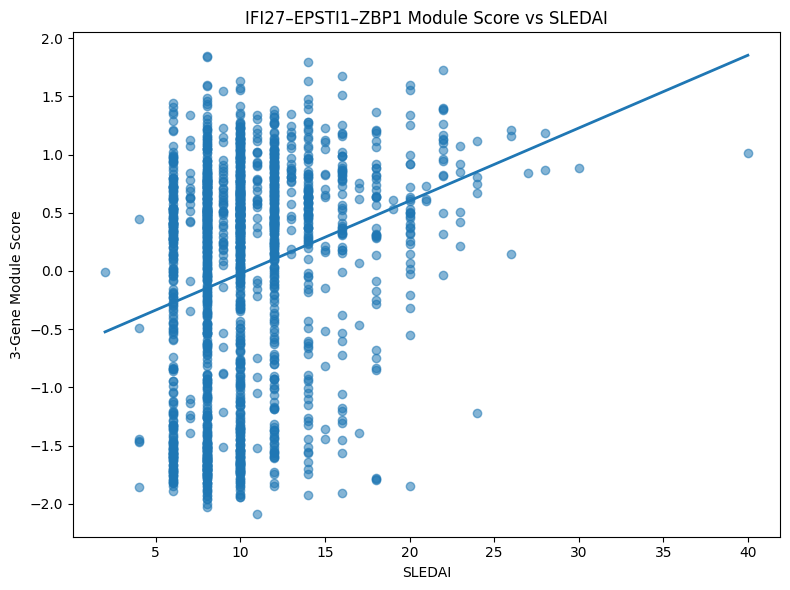

/tmp/ipykernel_29528/3564752194.py:564: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


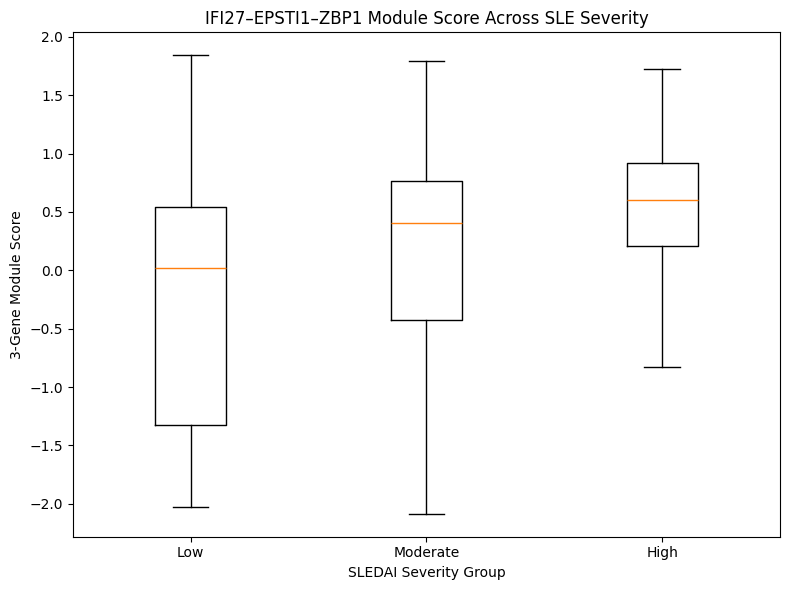


ANALYSIS COMPLETE

Saved:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/GSE88884_locked_3gene_individual_analysis.csv
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/GSE88884_locked_3gene_binary_auc.csv
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/GSE88884_locked_3gene_module_scores.csv

✓ Individual gene–SLEDAI correlations
✓ 3-gene standardized module score
✓ Module score–SLEDAI correlation
✓ Low/Moderate/High comparison
✓ Kruskal–Wallis test
✓ Binary High vs Low-to-Moderate analysis
✓ Individual-gene ROC-AUC
✓ 3-gene module ROC-AUC
✓ Module score plots


In [40]:
# ============================================================================
# GSE88884 — LOCKED 3-GENE DIAGNOSTIC–SEVERITY OVERLAP ANALYSIS
# MODULE SCORE + INDIVIDUAL GENE ASSOCIATION + SEVERITY COMPARISON
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, kruskal
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

print("=" * 100)
print("GSE88884 — LOCKED 3-GENE OVERLAP ANALYSIS")
print("=" * 100)

# ============================================================================
# 1. LOCKED OVERLAP GENES
# ============================================================================

OVERLAP_GENES = [
    "IFI27",
    "EPSTI1",
    "ZBP1"
]

print("\nLocked overlap genes:")
print(OVERLAP_GENES)

# ============================================================================
# 2. CHECK REQUIRED OBJECTS
# ============================================================================

print("\n" + "-" * 100)
print("CHECKING REQUIRED OBJECTS")
print("-" * 100)

required_objects = [
    "X_severity_gene",
    "severity_df"
]

for obj in required_objects:

    if obj not in globals():

        raise NameError(
            f"{obj} is not available. "
            f"Restore the GSE88884 severity analysis objects first."
        )

    print(f"✓ {obj}")

# ============================================================================
# 3. ALIGN EXPRESSION AND PHENOTYPE
# ============================================================================

X_gene = X_severity_gene.copy()
meta = severity_df.copy()

# Make expression gene names consistent
X_gene.index = (
    X_gene.index
    .astype(str)
    .str.strip()
    .str.upper()
)

# Make sample IDs consistent
X_gene.columns = (
    X_gene.columns
    .astype(str)
    .str.strip()
)

meta["sample_id"] = (
    meta["sample_id"]
    .astype(str)
    .str.strip()
)

# --------------------------------------------------------------------------
# Check genes
# --------------------------------------------------------------------------

missing_genes = [
    gene
    for gene in OVERLAP_GENES
    if gene not in X_gene.index
]

if missing_genes:

    raise ValueError(
        f"Overlap genes missing from X_severity_gene: "
        f"{missing_genes}"
    )

# --------------------------------------------------------------------------
# Align samples
# --------------------------------------------------------------------------

common_samples = (
    X_gene.columns
    .intersection(meta["sample_id"])
)

print("\nExpression samples:", X_gene.shape[1])
print("Phenotype samples:", len(meta))
print("Common samples:", len(common_samples))

if len(common_samples) == 0:

    raise ValueError(
        "No common samples between expression and phenotype."
    )

X_overlap = (
    X_gene.loc[
        OVERLAP_GENES,
        common_samples
    ]
    .T
)

meta_overlap = (
    meta[
        meta["sample_id"].isin(common_samples)
    ]
    .drop_duplicates("sample_id")
    .set_index("sample_id")
    .loc[common_samples]
)

print("\nOverlap expression matrix:")
print("X:", X_overlap.shape)

print("\nPhenotype:")
print("Metadata:", meta_overlap.shape)

# ============================================================================
# 4. CHECK MISSING VALUES
# ============================================================================

print("\n" + "-" * 100)
print("DATA QUALITY")
print("-" * 100)

print(
    "Missing expression values:",
    X_overlap.isna().sum().sum()
)

print(
    "Missing SLEDAI:",
    meta_overlap["SLEDAI"].isna().sum()
)

# Remove samples with missing values
complete = (
    X_overlap.notna().all(axis=1)
    &
    meta_overlap["SLEDAI"].notna()
)

X_overlap = X_overlap.loc[complete]
meta_overlap = meta_overlap.loc[complete]

print(
    "Final samples:",
    len(X_overlap)
)

# ============================================================================
# 5. STANDARDIZE THE THREE GENES
# ============================================================================

scaler = StandardScaler()

X_overlap_z = pd.DataFrame(
    scaler.fit_transform(X_overlap),
    index=X_overlap.index,
    columns=OVERLAP_GENES
)

# ============================================================================
# 6. THREE-GENE MODULE SCORE
# ============================================================================

X_overlap_z["Overlap_Module_Score"] = (
    X_overlap_z[
        OVERLAP_GENES
    ]
    .mean(axis=1)
)

module_score = X_overlap_z[
    "Overlap_Module_Score"
]

print("\n" + "=" * 100)
print("3-GENE MODULE SCORE")
print("=" * 100)

print(
    module_score.describe()
)

# ============================================================================
# 7. CORRELATION WITH CONTINUOUS SLEDAI
# ============================================================================

print("\n" + "=" * 100)
print("MODULE SCORE — SLEDAI ASSOCIATION")
print("=" * 100)

sledai = meta_overlap["SLEDAI"]

rho, p_value = spearmanr(
    module_score,
    sledai
)

print(
    f"\nSpearman rho = {rho:.4f}"
)

print(
    f"P-value      = {p_value:.4e}"
)

# ============================================================================
# 8. INDIVIDUAL GENE — SLEDAI ASSOCIATION
# ============================================================================

print("\n" + "=" * 100)
print("INDIVIDUAL OVERLAP GENE — SLEDAI ASSOCIATION")
print("=" * 100)

gene_results = []

for gene in OVERLAP_GENES:

    rho_gene, p_gene = spearmanr(
        X_overlap[gene],
        sledai
    )

    gene_results.append({
        "Gene": gene,
        "Spearman_Rho": rho_gene,
        "P_value": p_gene,
        "Direction": (
            "Positive"
            if rho_gene > 0
            else "Negative"
        )
    })

gene_results = pd.DataFrame(
    gene_results
)

display(gene_results)

# ============================================================================
# 9. BUILD THREE-LEVEL SEVERITY LABELS
# ============================================================================

def classify_sledai(score):

    if score <= 8:
        return "Low"

    elif score <= 15:
        return "Moderate"

    else:
        return "High"


meta_overlap["Severity"] = (
    sledai
    .apply(classify_sledai)
)

print("\n" + "=" * 100)
print("THREE-LEVEL SEVERITY DISTRIBUTION")
print("=" * 100)

print(
    meta_overlap["Severity"]
    .value_counts()
    .reindex(
        ["Low", "Moderate", "High"]
    )
)

# ============================================================================
# 10. MODULE SCORE ACROSS THREE SEVERITY GROUPS
# ============================================================================

print("\n" + "=" * 100)
print("MODULE SCORE — THREE-LEVEL SEVERITY")
print("=" * 100)

module_by_severity = (
    pd.DataFrame({
        "Severity": meta_overlap["Severity"],
        "Module_Score": module_score
    })
)

display(
    module_by_severity
    .groupby("Severity")["Module_Score"]
    .agg(
        ["count", "mean", "std", "median", "min", "max"]
    )
    .reindex(
        ["Low", "Moderate", "High"]
    )
)

# ============================================================================
# 11. KRUSKAL–WALLIS TEST
# ============================================================================

groups = [
    module_by_severity.loc[
        module_by_severity["Severity"] == group,
        "Module_Score"
    ]
    for group in ["Low", "Moderate", "High"]
]

kw_stat, kw_p = kruskal(
    *groups
)

print(
    "\nKruskal–Wallis H =",
    round(kw_stat, 4)
)

print(
    "P-value           =",
    f"{kw_p:.4e}"
)

# ============================================================================
# 12. BINARY SEVERITY
# ============================================================================

meta_overlap["Binary_Severity"] = (
    sledai > 15
).astype(int)

print("\n" + "=" * 100)
print("BINARY SEVERITY")
print("=" * 100)

print(
    meta_overlap["Binary_Severity"]
    .value_counts()
    .sort_index()
)

# ============================================================================
# 13. MODULE SCORE — BINARY SEVERITY
# ============================================================================

low_mod_score = module_score[
    meta_overlap["Binary_Severity"] == 0
]

high_score = module_score[
    meta_overlap["Binary_Severity"] == 1
]

print("\n" + "-" * 100)
print("MODULE SCORE BY BINARY SEVERITY")
print("-" * 100)

print(
    "\nLow-to-Moderate:"
)

print(
    low_mod_score.describe()
)

print(
    "\nHigh:"
)

print(
    high_score.describe()
)

# ============================================================================
# 14. ROC-AUC OF 3-GENE MODULE SCORE
# ============================================================================

y_binary = meta_overlap[
    "Binary_Severity"
]

module_auc = roc_auc_score(
    y_binary,
    module_score
)

# If direction is negative, reverse it
module_auc_directional = max(
    module_auc,
    1 - module_auc
)

print("\n" + "=" * 100)
print("3-GENE MODULE — BINARY SEVERITY DISCRIMINATION")
print("=" * 100)

print(
    f"\nRaw ROC-AUC        = {module_auc:.4f}"
)

print(
    f"Directional AUC    = {module_auc_directional:.4f}"
)

# ============================================================================
# 15. INDIVIDUAL GENES — BINARY ROC-AUC
# ============================================================================

print("\n" + "=" * 100)
print("INDIVIDUAL GENES — BINARY SEVERITY ROC-AUC")
print("=" * 100)

auc_results = []

for gene in OVERLAP_GENES:

    auc = roc_auc_score(
        y_binary,
        X_overlap_z[gene]
    )

    directional_auc = max(
        auc,
        1 - auc
    )

    auc_results.append({
        "Gene": gene,
        "ROC_AUC": auc,
        "Directional_AUC": directional_auc
    })

auc_results = pd.DataFrame(
    auc_results
)

display(auc_results)

# ============================================================================
# 16. FINAL OVERLAP ANALYSIS TABLE
# ============================================================================

final_overlap_results = (
    gene_results
    .merge(
        auc_results,
        on="Gene",
        how="left"
    )
)

print("\n" + "=" * 100)
print("FINAL 3-GENE OVERLAP RESULTS")
print("=" * 100)

display(
    final_overlap_results
)

# ============================================================================
# 17. PLOT — MODULE SCORE VS SLEDAI
# ============================================================================

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    sledai,
    module_score,
    alpha=0.55
)

# Trend line
z = np.polyfit(
    sledai,
    module_score,
    1
)

x_line = np.linspace(
    sledai.min(),
    sledai.max(),
    100
)

y_line = (
    z[0] * x_line
    + z[1]
)

plt.plot(
    x_line,
    y_line,
    linewidth=2
)

plt.xlabel(
    "SLEDAI"
)

plt.ylabel(
    "3-Gene Module Score"
)

plt.title(
    "IFI27–EPSTI1–ZBP1 Module Score vs SLEDAI"
)

plt.tight_layout()

plt.show()

# ============================================================================
# 18. PLOT — MODULE SCORE ACROSS SEVERITY
# ============================================================================

plot_order = [
    "Low",
    "Moderate",
    "High"
]

plot_data = [
    module_by_severity.loc[
        module_by_severity["Severity"] == group,
        "Module_Score"
    ]
    for group in plot_order
]

plt.figure(
    figsize=(8, 6)
)

plt.boxplot(
    plot_data,
    labels=plot_order,
    showfliers=False
)

plt.xlabel(
    "SLEDAI Severity Group"
)

plt.ylabel(
    "3-Gene Module Score"
)

plt.title(
    "IFI27–EPSTI1–ZBP1 Module Score Across SLE Severity"
)

plt.tight_layout()

plt.show()

# ============================================================================
# 19. SAVE RESULTS
# ============================================================================

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis"
)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

GENE_RESULT_PATH = os.path.join(
    SAVE_DIR,
    "GSE88884_locked_3gene_individual_analysis.csv"
)

AUC_RESULT_PATH = os.path.join(
    SAVE_DIR,
    "GSE88884_locked_3gene_binary_auc.csv"
)

MODULE_PATH = os.path.join(
    SAVE_DIR,
    "GSE88884_locked_3gene_module_scores.csv"
)

final_overlap_results.to_csv(
    GENE_RESULT_PATH,
    index=False
)

auc_results.to_csv(
    AUC_RESULT_PATH,
    index=False
)

module_output = pd.DataFrame({
    "sample_id": X_overlap.index,
    "IFI27": X_overlap["IFI27"],
    "EPSTI1": X_overlap["EPSTI1"],
    "ZBP1": X_overlap["ZBP1"],
    "IFI27_Z": X_overlap_z["IFI27"],
    "EPSTI1_Z": X_overlap_z["EPSTI1"],
    "ZBP1_Z": X_overlap_z["ZBP1"],
    "Overlap_Module_Score": module_score,
    "SLEDAI": sledai,
    "Severity": meta_overlap["Severity"],
    "Binary_Severity": meta_overlap["Binary_Severity"]
})

module_output.to_csv(
    MODULE_PATH,
    index=False
)

print("\n" + "=" * 100)
print("ANALYSIS COMPLETE")
print("=" * 100)

print("\nSaved:")
print(GENE_RESULT_PATH)
print(AUC_RESULT_PATH)
print(MODULE_PATH)

print("\n✓ Individual gene–SLEDAI correlations")
print("✓ 3-gene standardized module score")
print("✓ Module score–SLEDAI correlation")
print("✓ Low/Moderate/High comparison")
print("✓ Kruskal–Wallis test")
print("✓ Binary High vs Low-to-Moderate analysis")
print("✓ Individual-gene ROC-AUC")
print("✓ 3-gene module ROC-AUC")
print("✓ Module score plots")

GSE88884 — INDIVIDUAL OVERLAP GENE MODULE SCORES

Samples: 1756
Genes: 3

INDIVIDUAL GENE MODULE SCORES

IFI27
------------------------------------------------------------
count    1.756000e+03
mean     3.912841e-15
std      1.000285e+00
min     -2.046933e+00
25%     -9.448500e-01
50%      3.335805e-01
75%      8.042462e-01
max      1.932775e+00
Name: IFI27_Module_Score, dtype: float64

EPSTI1
------------------------------------------------------------
count    1.756000e+03
mean     1.298025e-14
std      1.000285e+00
min     -2.714252e+00
25%     -5.869768e-01
50%      4.271759e-01
75%      7.108450e-01
max      1.581161e+00
Name: EPSTI1_Module_Score, dtype: float64

ZBP1
------------------------------------------------------------
count    1.756000e+03
mean    -1.011947e-14
std      1.000285e+00
min     -2.052605e+00
25%     -7.798785e-01
50%      9.915193e-02
75%      6.883292e-01
max      3.185189e+00
Name: ZBP1_Module_Score, dtype: float64

INDIVIDUAL GENE MODULE SCORE vs SLEDAI


,Gene,Spearman_Rho,P_value,Direction
0,IFI27,0.256052,1.097801e-27,Positive
1,EPSTI1,0.248937,3.268552e-26,Positive
2,ZBP1,0.223515,2.546883e-21,Positive



INDIVIDUAL GENE SCORES ACROSS SEVERITY GROUPS

IFI27


,count,mean,std,median
Severity,,,,
Low,700,-0.266771,1.022871,-0.063639
Moderate,885,0.119317,0.956099,0.427858
High,171,0.474529,0.824807,0.691245



EPSTI1


,count,mean,std,median
Severity,,,,
Low,700,-0.267179,1.079578,0.189807
Moderate,885,0.130115,0.921294,0.500560
High,171,0.420312,0.750833,0.614543



ZBP1


,count,mean,std,median
Severity,,,,
Low,700,-0.241737,1.012902,-0.150349
Moderate,885,0.114355,0.959484,0.179910
High,171,0.397731,0.925137,0.418379



KRUSKAL-WALLIS TEST


,Gene,Kruskal_Wallis_H,P_value
0,IFI27,108.106406,3.349595e-24
1,EPSTI1,96.793226,9.585573e-22
2,ZBP1,79.029581,6.901516e-18


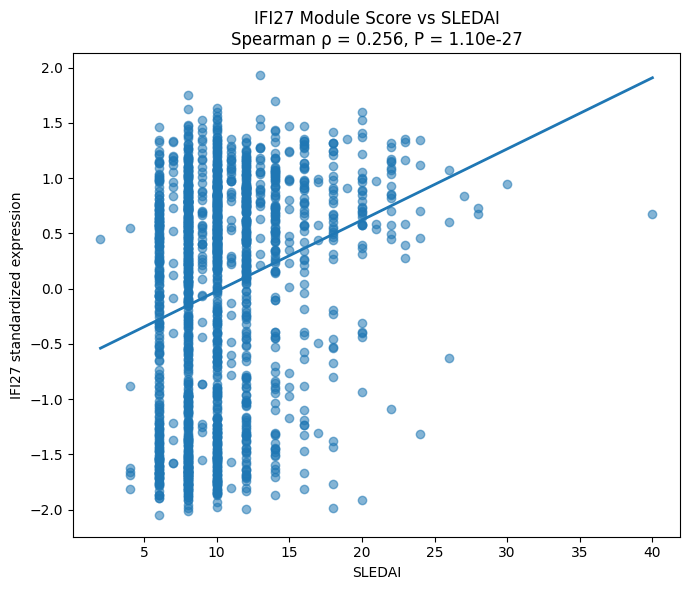

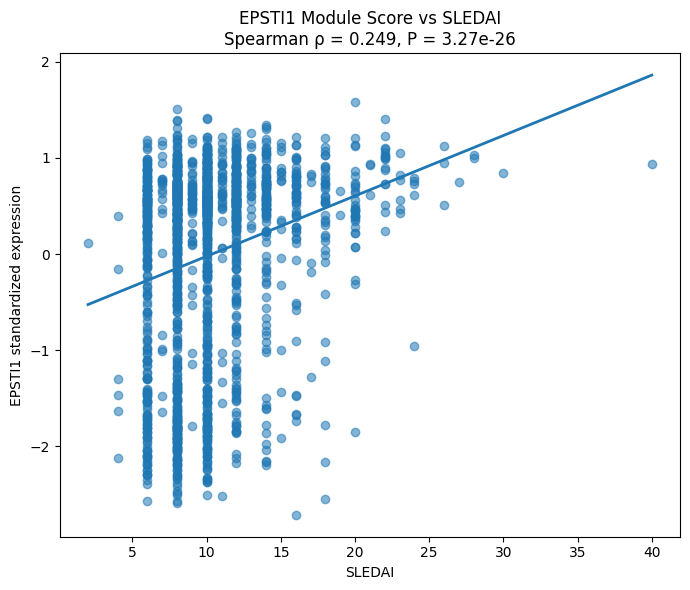

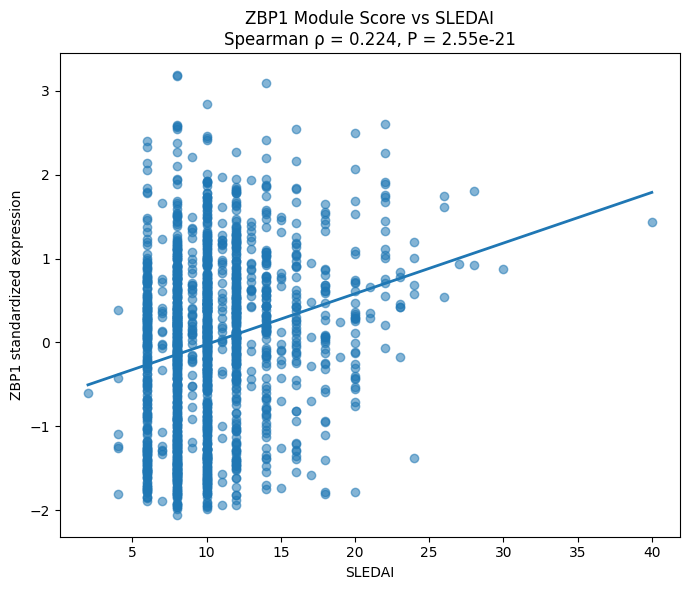

/tmp/ipykernel_29528/4145987186.py:348: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


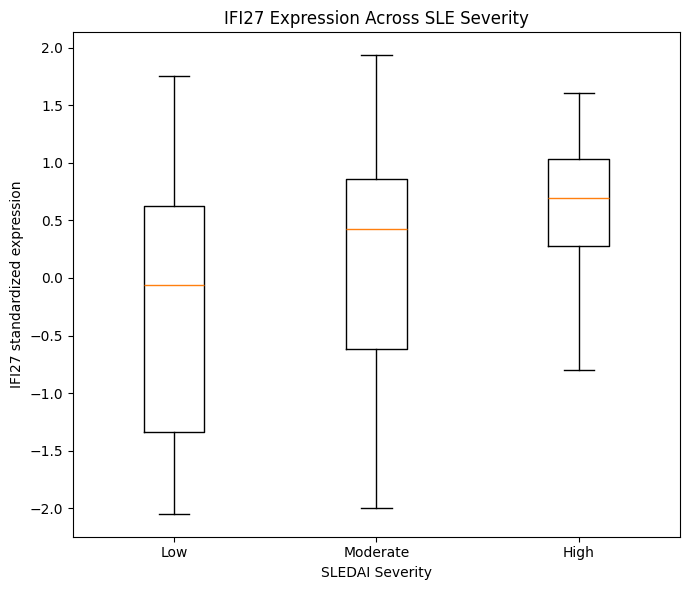

/tmp/ipykernel_29528/4145987186.py:348: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


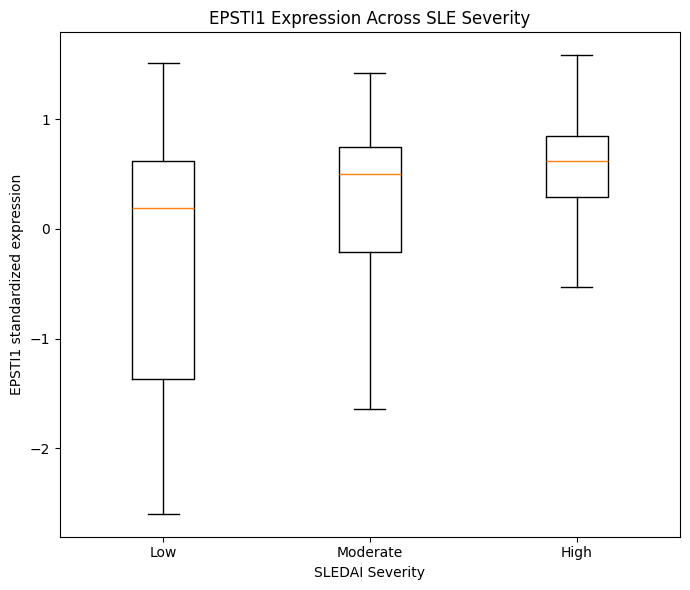

/tmp/ipykernel_29528/4145987186.py:348: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


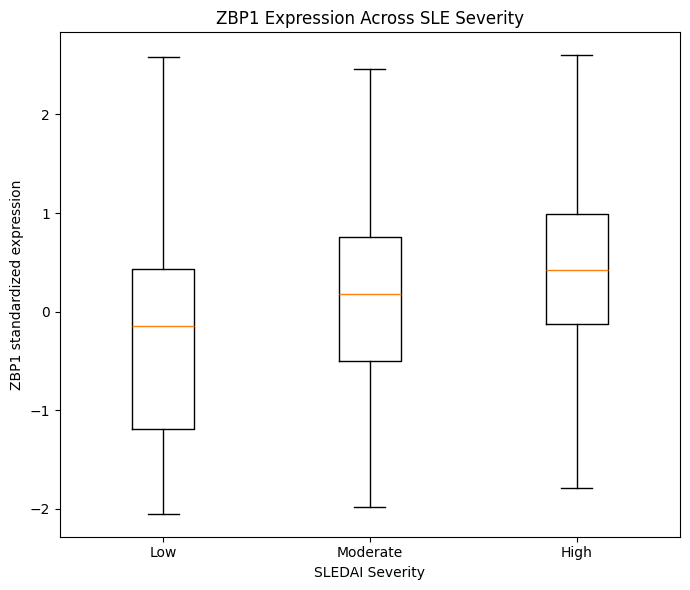


✓ INDIVIDUAL GENE MODULE-SCORE ANALYSIS COMPLETE


In [41]:
# ============================================================================
# GSE88884 — INDIVIDUAL OVERLAP GENE MODULE SCORES
# IFI27 | EPSTI1 | ZBP1
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, kruskal
from sklearn.preprocessing import StandardScaler

print("=" * 100)
print("GSE88884 — INDIVIDUAL OVERLAP GENE MODULE SCORES")
print("=" * 100)

# ============================================================================
# 1. LOCKED GENES
# ============================================================================

OVERLAP_GENES = [
    "IFI27",
    "EPSTI1",
    "ZBP1"
]

# ============================================================================
# 2. CHECK OBJECTS
# ============================================================================

if "X_severity_gene" not in globals():
    raise NameError(
        "X_severity_gene is not available. "
        "Restore the GSE88884 severity matrix first."
    )

if "severity_df" not in globals():
    raise NameError(
        "severity_df is not available. "
        "Restore the severity phenotype first."
    )

# ============================================================================
# 3. ALIGN EXPRESSION
# ============================================================================

X_gene = X_severity_gene.copy()
meta = severity_df.copy()

X_gene.index = (
    X_gene.index
    .astype(str)
    .str.strip()
    .str.upper()
)

X_gene.columns = (
    X_gene.columns
    .astype(str)
    .str.strip()
)

meta["sample_id"] = (
    meta["sample_id"]
    .astype(str)
    .str.strip()
)

# Check genes
missing = [
    g for g in OVERLAP_GENES
    if g not in X_gene.index
]

if missing:
    raise ValueError(
        f"Missing overlap genes: {missing}"
    )

# Align samples
common_samples = (
    X_gene.columns
    .intersection(meta["sample_id"])
)

X = (
    X_gene
    .loc[
        OVERLAP_GENES,
        common_samples
    ]
    .T
)

meta = (
    meta[
        meta["sample_id"].isin(common_samples)
    ]
    .drop_duplicates("sample_id")
    .set_index("sample_id")
    .loc[common_samples]
)

# ============================================================================
# 4. REMOVE MISSING VALUES
# ============================================================================

complete = (
    X.notna().all(axis=1)
    &
    meta["SLEDAI"].notna()
)

X = X.loc[complete]
meta = meta.loc[complete]

print("\nSamples:", len(X))
print("Genes:", X.shape[1])

# ============================================================================
# 5. STANDARDIZE EACH GENE
# ============================================================================

scaler = StandardScaler()

X_z = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,
    columns=OVERLAP_GENES
)

# ============================================================================
# 6. CREATE INDIVIDUAL GENE SCORES
# ============================================================================

for gene in OVERLAP_GENES:

    X_z[f"{gene}_Module_Score"] = X_z[gene]

print("\n" + "=" * 100)
print("INDIVIDUAL GENE MODULE SCORES")
print("=" * 100)

for gene in OVERLAP_GENES:

    score = X_z[f"{gene}_Module_Score"]

    print(f"\n{gene}")
    print("-" * 60)
    print(score.describe())

# ============================================================================
# 7. SLEDAI ASSOCIATION FOR EACH GENE
# ============================================================================

results = []

for gene in OVERLAP_GENES:

    rho, p = spearmanr(
        X_z[f"{gene}_Module_Score"],
        meta["SLEDAI"]
    )

    results.append({
        "Gene": gene,
        "Spearman_Rho": rho,
        "P_value": p,
        "Direction": (
            "Positive"
            if rho > 0
            else "Negative"
        )
    })

individual_results = pd.DataFrame(results)

print("\n" + "=" * 100)
print("INDIVIDUAL GENE MODULE SCORE vs SLEDAI")
print("=" * 100)

display(individual_results)

# ============================================================================
# 8. THREE-LEVEL SEVERITY
# ============================================================================

def classify_sledai(x):

    if x <= 8:
        return "Low"

    elif x <= 15:
        return "Moderate"

    return "High"


meta["Severity"] = (
    meta["SLEDAI"]
    .apply(classify_sledai)
)

# ============================================================================
# 9. SUMMARY BY SEVERITY GROUP
# ============================================================================

print("\n" + "=" * 100)
print("INDIVIDUAL GENE SCORES ACROSS SEVERITY GROUPS")
print("=" * 100)

summary_tables = []

for gene in OVERLAP_GENES:

    temp = pd.DataFrame({
        "Severity": meta["Severity"],
        "Score": X_z[f"{gene}_Module_Score"]
    })

    summary = (
        temp
        .groupby("Severity")["Score"]
        .agg(
            ["count", "mean", "std", "median"]
        )
        .reindex(
            ["Low", "Moderate", "High"]
        )
    )

    print(f"\n{gene}")
    display(summary)

# ============================================================================
# 10. KRUSKAL-WALLIS TEST FOR EACH GENE
# ============================================================================

kw_results = []

for gene in OVERLAP_GENES:

    groups = [
        X_z.loc[
            meta["Severity"] == group,
            f"{gene}_Module_Score"
        ]
        for group in [
            "Low",
            "Moderate",
            "High"
        ]
    ]

    H, p = kruskal(*groups)

    kw_results.append({
        "Gene": gene,
        "Kruskal_Wallis_H": H,
        "P_value": p
    })

kw_results = pd.DataFrame(kw_results)

print("\n" + "=" * 100)
print("KRUSKAL-WALLIS TEST")
print("=" * 100)

display(kw_results)

# ============================================================================
# 11. CORRELATION PLOTS — EACH GENE SEPARATELY
# ============================================================================

for gene in OVERLAP_GENES:

    score = X_z[
        f"{gene}_Module_Score"
    ]

    rho, p = spearmanr(
        score,
        meta["SLEDAI"]
    )

    plt.figure(figsize=(7, 6))

    plt.scatter(
        meta["SLEDAI"],
        score,
        alpha=0.55
    )

    # Linear trend
    z = np.polyfit(
        meta["SLEDAI"],
        score,
        1
    )

    x_line = np.linspace(
        meta["SLEDAI"].min(),
        meta["SLEDAI"].max(),
        100
    )

    y_line = (
        z[0] * x_line
        + z[1]
    )

    plt.plot(
        x_line,
        y_line,
        linewidth=2
    )

    plt.xlabel("SLEDAI")
    plt.ylabel(f"{gene} standardized expression")
    plt.title(
        f"{gene} Module Score vs SLEDAI\n"
        f"Spearman ρ = {rho:.3f}, P = {p:.2e}"
    )

    plt.tight_layout()
    plt.show()

# ============================================================================
# 12. SEVERITY BOXPLOTS — EACH GENE SEPARATELY
# ============================================================================

for gene in OVERLAP_GENES:

    plot_data = [
        X_z.loc[
            meta["Severity"] == group,
            f"{gene}_Module_Score"
        ]
        for group in [
            "Low",
            "Moderate",
            "High"
        ]
    ]

    plt.figure(figsize=(7, 6))

    plt.boxplot(
        plot_data,
        labels=[
            "Low",
            "Moderate",
            "High"
        ],
        showfliers=False
    )

    plt.xlabel("SLEDAI Severity")
    plt.ylabel(
        f"{gene} standardized expression"
    )

    plt.title(
        f"{gene} Expression Across SLE Severity"
    )

    plt.tight_layout()
    plt.show()

# ============================================================================
# 13. SAVE RESULTS
# ============================================================================

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis"
)

import os
os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

individual_results.to_csv(
    os.path.join(
        SAVE_DIR,
        "GSE88884_overlap_individual_gene_SLEDAI_association.csv"
    ),
    index=False
)

kw_results.to_csv(
    os.path.join(
        SAVE_DIR,
        "GSE88884_overlap_individual_gene_Kruskal_Wallis.csv"
    ),
    index=False
)

score_output = pd.DataFrame({
    "sample_id": X.index,
    "SLEDAI": meta["SLEDAI"].values,
    "Severity": meta["Severity"].values,
    "IFI27_Module_Score": X_z["IFI27_Module_Score"].values,
    "EPSTI1_Module_Score": X_z["EPSTI1_Module_Score"].values,
    "ZBP1_Module_Score": X_z["ZBP1_Module_Score"].values
})

score_output.to_csv(
    os.path.join(
        SAVE_DIR,
        "GSE88884_overlap_individual_gene_module_scores.csv"
    ),
    index=False
)

print("\n" + "=" * 100)
print("✓ INDIVIDUAL GENE MODULE-SCORE ANALYSIS COMPLETE")
print("=" * 100)

GSE88884 — GO + KEGG FUNCTIONAL ENRICHMENT

Gene sets:
Diagnostic panel: 13
Severity panel: 100
Overlap panel: 3

----------------------------------------------------------------------------------------------------
Running enrichment: Diagnostic_13
----------------------------------------------------------------------------------------------------
Terms returned: 829
Significant at p < 0.05: 5

----------------------------------------------------------------------------------------------------
Running enrichment: Severity_100
----------------------------------------------------------------------------------------------------
Terms returned: 2368
Significant at p < 0.05: 171

----------------------------------------------------------------------------------------------------
Running enrichment: Overlap_3
----------------------------------------------------------------------------------------------------
Terms returned: 228
Significant at p < 0.05: 6

COMBINED ENRICHMENT RESULTS
Total te

,Panel,source,native,name,p_value,BH_FDR,intersection_size
0,Diagnostic_13,GO:BP,GO:0060337,type I interferon-mediated signaling pathway,0.012042,1.000000,3
1,Diagnostic_13,GO:BP,GO:0071357,cellular response to type I interferon,0.012474,1.000000,3
2,Diagnostic_13,GO:BP,GO:0034340,response to type I interferon,0.015280,1.000000,3
3,Diagnostic_13,GO:BP,GO:0051607,defense response to virus,0.019223,1.000000,4
4,Diagnostic_13,GO:BP,GO:0140888,interferon-mediated signaling pathway,0.026843,1.000000,3
...,...,...,...,...,...,...,...
913,Severity_100,GO:BP,GO:0010965,regulation of mitotic sister chromatid separation,0.000127,0.003529,6
914,Severity_100,GO:BP,GO:0033045,regulation of sister chromatid segregation,0.000152,0.004184,7
915,Severity_100,GO:BP,GO:0051306,mitotic sister chromatid separation,0.000169,0.004595,6
916,Severity_100,GO:CC,GO:0043233,organelle lumen,0.000183,0.004812,45




Diagnostic_13

GO:BP
--------------------------------------------------------------------------------


,name,p_value,BH_FDR,intersection_size
0,type I interferon-mediated signaling pathway,0.012042,1.0,3
1,cellular response to type I interferon,0.012474,1.0,3
2,response to type I interferon,0.015280,1.0,3
3,defense response to virus,0.019223,1.0,4
4,interferon-mediated signaling pathway,0.026843,1.0,3



GO:MF
--------------------------------------------------------------------------------
No significant terms.

GO:CC
--------------------------------------------------------------------------------
No significant terms.

KEGG
--------------------------------------------------------------------------------
No significant terms.


Severity_100

GO:BP
--------------------------------------------------------------------------------


...



Overlap_3

GO:BP
--------------------------------------------------------------------------------


,name,p_value,BH_FDR,intersection_size
3197,pyroptotic inflammatory response,0.001492,0.340209,2
3198,type I interferon-mediated signaling pathway,0.008455,0.565124,2
3199,cellular response to type I interferon,0.008657,0.565124,2
3200,response to type I interferon,0.009914,0.565124,2
3201,interferon-mediated signaling pathway,0.014460,0.659356,2



GO:MF
--------------------------------------------------------------------------------


,name,p_value,BH_FDR,intersection_size
3202,left-handed Z-DNA binding,0.049817,1.0,1



GO:CC
--------------------------------------------------------------------------------
No significant terms.

KEGG
--------------------------------------------------------------------------------
No significant terms.


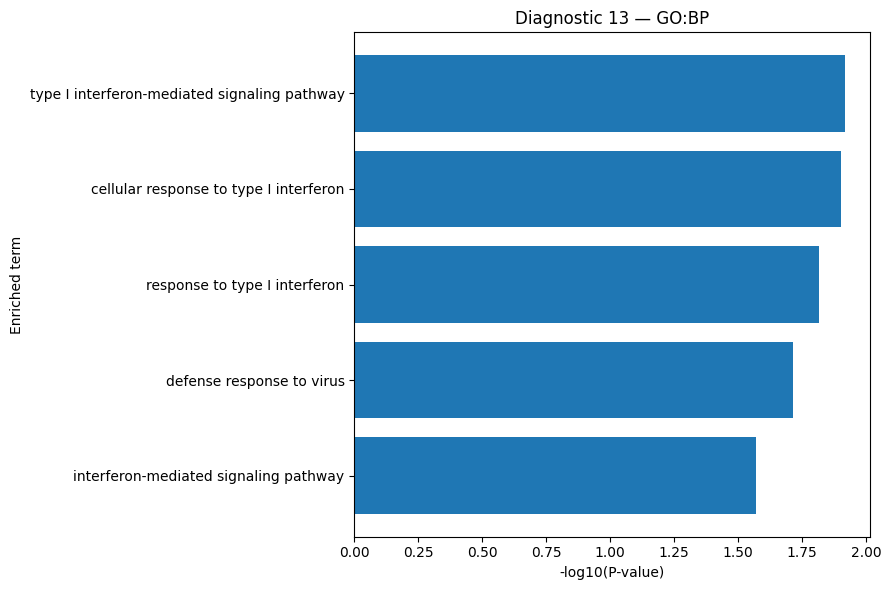

No significant GO:MF terms for Diagnostic_13
No significant GO:CC terms for Diagnostic_13
No significant KEGG terms for Diagnostic_13


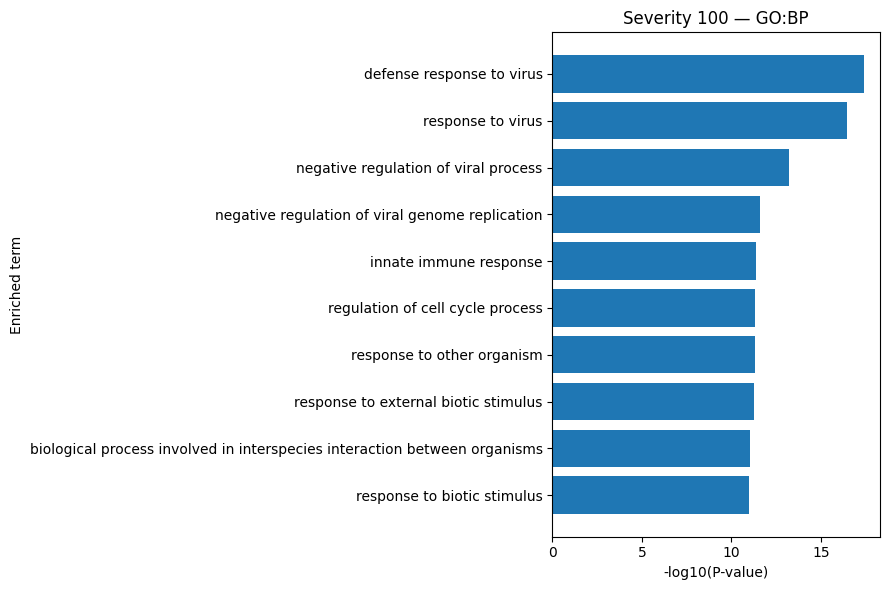

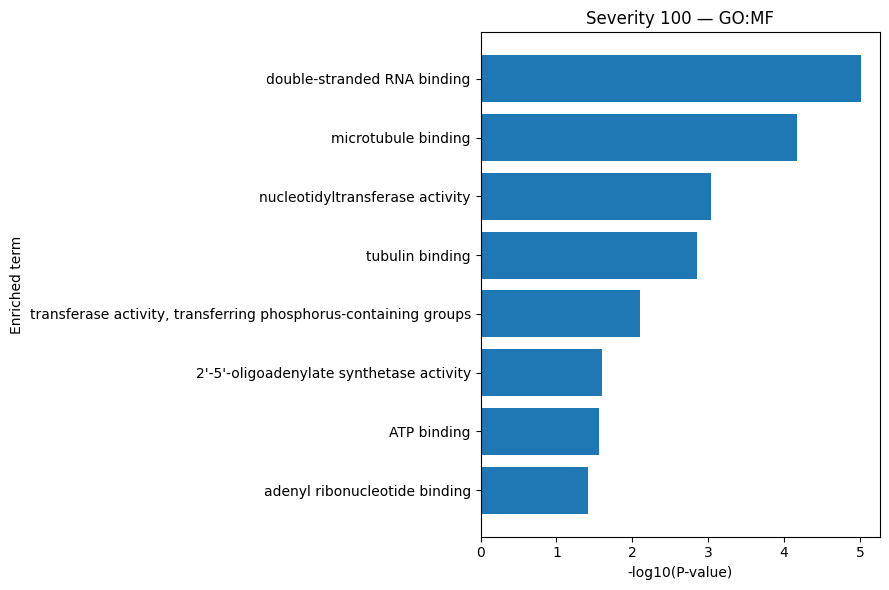

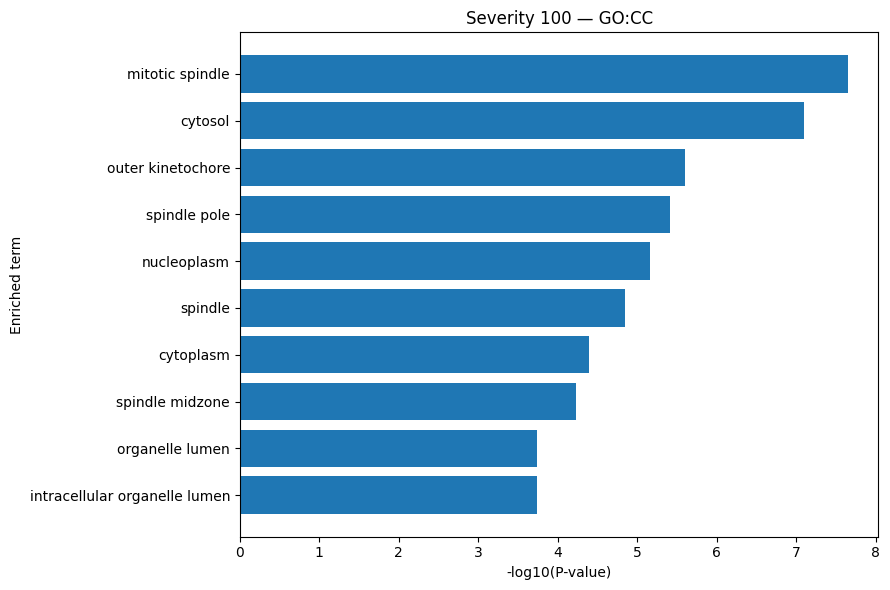

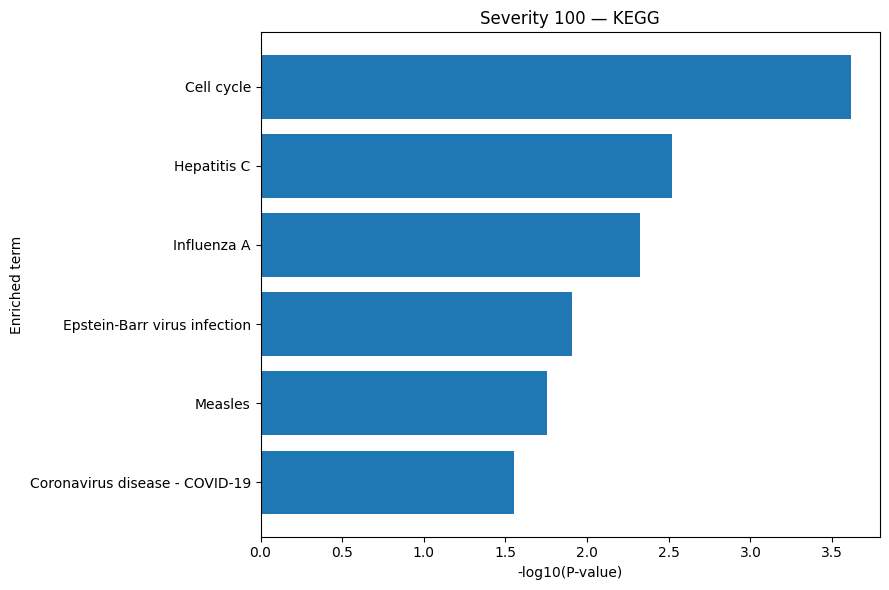

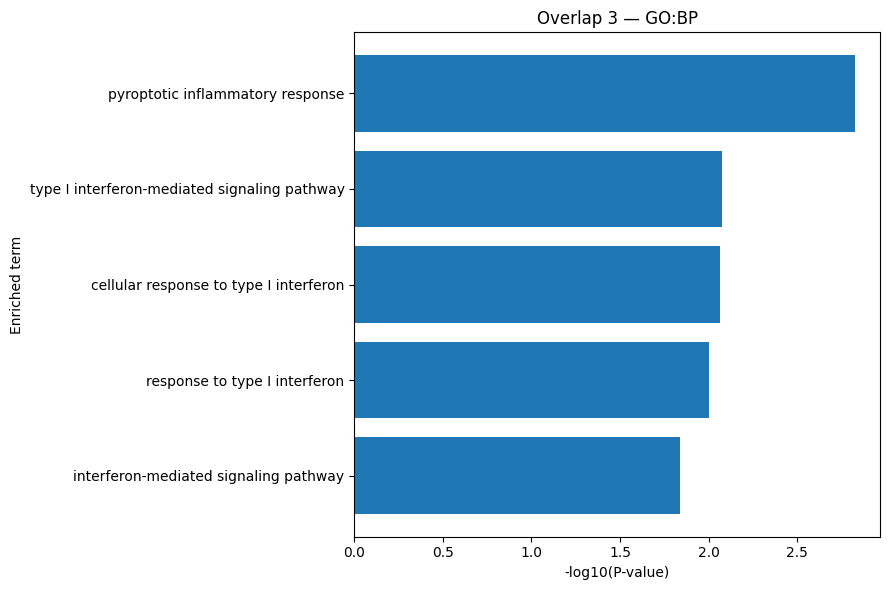

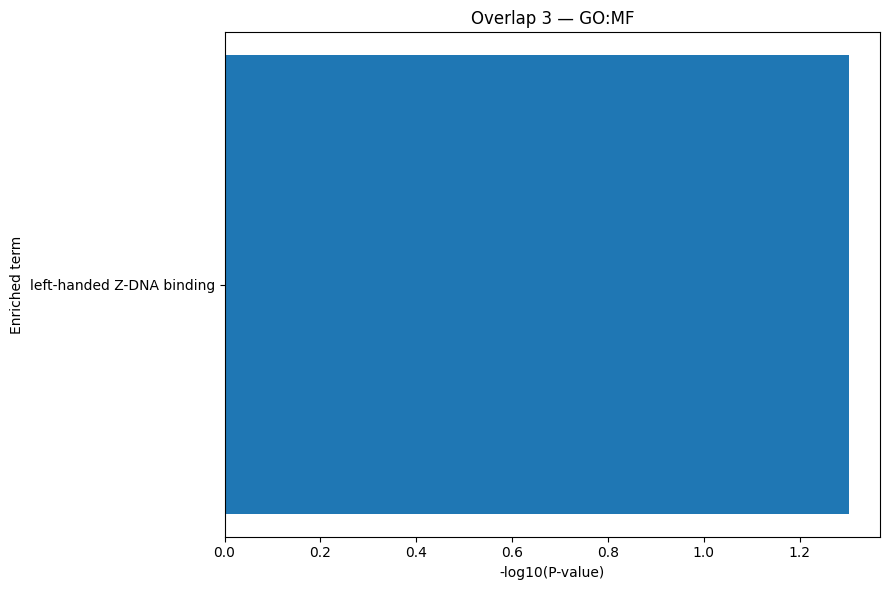

No significant GO:CC terms for Overlap_3
No significant KEGG terms for Overlap_3

CROSS-PANEL SHARED ENRICHED TERMS


,source,native,name,Panel,Number_of_Panels
56,GO:BP,GO:0034340,response to type I interferon,"[Diagnostic_13, Overlap_3, Severity_100]",3
99,GO:BP,GO:0060337,type I interferon-mediated signaling pathway,"[Diagnostic_13, Overlap_3, Severity_100]",3
107,GO:BP,GO:0071357,cellular response to type I interferon,"[Diagnostic_13, Overlap_3, Severity_100]",3
117,GO:BP,GO:0140888,interferon-mediated signaling pathway,"[Diagnostic_13, Overlap_3, Severity_100]",3
92,GO:BP,GO:0051607,defense response to virus,"[Diagnostic_13, Severity_100]",2



✓ Shared pathway table saved:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/GSE88884_shared_GO_KEGG_terms.csv

FUNCTIONAL ENRICHMENT COMPLETE
Diagnostic_13        : 5 significant terms
Severity_100         : 171 significant terms
Overlap_3            : 6 significant terms

Output directory:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis

Saved files:
• GSE88884_GO_KEGG_all_enrichment.csv
• GSE88884_Diagnostic13_GO_KEGG.csv
• GSE88884_Severity100_GO_KEGG.csv
• GSE88884_Overlap3_GO_KEGG.csv
• GSE88884_shared_GO_KEGG_terms.csv

✓ GO-BP
✓ GO-MF
✓ GO-CC
✓ KEGG
✓ Cross-panel comparison


In [42]:
# ============================================================================
# GSE88884 — FUNCTIONAL ENRICHMENT ANALYSIS
# GO + KEGG
#
# Gene sets:
#   1. Final 13-gene diagnostic panel
#   2. Top 100 significant severity genes
#   3. Locked 3-gene diagnostic–severity overlap
# ============================================================================

import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 100)
print("GSE88884 — GO + KEGG FUNCTIONAL ENRICHMENT")
print("=" * 100)

# ============================================================================
# 1. OUTPUT DIRECTORY
# ============================================================================

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis/"
    "functional_analysis"
)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

# ============================================================================
# 2. FINAL GENE SETS
# ============================================================================

DIAGNOSTIC_13 = [
    "IFI27",
    "RPL5",
    "ZBP1",
    "IFITM1",
    "EPSTI1",
    "EBI2",
    "FCER1A",
    "GADD45A",
    "TNFSF13B",
    "IFIT2",
    "OSBPL10",
    "SCRN1",
    "TNFAIP6"
]

OVERLAP_3 = [
    "IFI27",
    "EPSTI1",
    "ZBP1"
]

# ============================================================================
# 3. GET THE TOP 100 SEVERITY GENES
# ============================================================================

if "top100_severity" in globals():

    severity_100 = (
        top100_severity["Gene"]
        .astype(str)
        .str.upper()
        .str.strip()
        .tolist()
    )

elif "severity_results" in globals():

    severity_tmp = severity_results.copy()

    severity_tmp["Gene"] = (
        severity_tmp["Gene"]
        .astype(str)
        .str.upper()
        .str.strip()
    )

    severity_tmp["FDR"] = pd.to_numeric(
        severity_tmp["FDR"],
        errors="coerce"
    )

    severity_tmp["Spearman_Rho"] = pd.to_numeric(
        severity_tmp["Spearman_Rho"],
        errors="coerce"
    )

    severity_tmp["Abs_Rho"] = (
        severity_tmp["Spearman_Rho"].abs()
    )

    severity_tmp = (
        severity_tmp[
            severity_tmp["FDR"] < 0.05
        ]
        .sort_values(
            "Abs_Rho",
            ascending=False
        )
        .drop_duplicates(
            "Gene"
        )
    )

    severity_100 = (
        severity_tmp
        .head(100)["Gene"]
        .tolist()
    )

else:

    raise NameError(
        "Neither top100_severity nor severity_results "
        "is available."
    )

print("\nGene sets:")
print(
    "Diagnostic panel:",
    len(DIAGNOSTIC_13)
)

print(
    "Severity panel:",
    len(severity_100)
)

print(
    "Overlap panel:",
    len(OVERLAP_3)
)

# ============================================================================
# 4. REMOVE DUPLICATES
# ============================================================================

DIAGNOSTIC_13 = list(
    dict.fromkeys(DIAGNOSTIC_13)
)

severity_100 = list(
    dict.fromkeys(severity_100)
)

OVERLAP_3 = list(
    dict.fromkeys(OVERLAP_3)
)

# ============================================================================
# 5. g:PROFILER API
# ============================================================================

GP_URL = (
    "https://biit.cs.ut.ee/gprofiler/api/"
    "gost/profile/"
)

# We explicitly request:
# GO Biological Process
# GO Molecular Function
# GO Cellular Component
# KEGG

SOURCES = [
    "GO:BP",
    "GO:MF",
    "GO:CC",
    "KEGG"
]

# ============================================================================
# 6. FUNCTION TO RUN ENRICHMENT
# ============================================================================

def run_gprofiler(
    genes,
    panel_name
):

    print("\n" + "-" * 100)
    print(
        f"Running enrichment: {panel_name}"
    )
    print("-" * 100)

    payload = {
        "organism": "hsapiens",
        "query": genes,
        "sources": SOURCES,

        # Keep statistically significant terms
        "user_threshold": 0.05,

        # Multiple-testing correction
        "significance_threshold_method": "g_SCS",

        # Return all results so we can save complete output
        "all_results": True,

        # Keep query as unordered gene list
        "ordered": False
    }

    response = requests.post(
        GP_URL,
        json=payload,
        timeout=120
    )

    response.raise_for_status()

    data = response.json()

    if "result" not in data:

        print(
            "No enrichment result returned."
        )

        return pd.DataFrame()

    results = pd.DataFrame(
        data["result"]
    )

    if results.empty:

        print(
            "No enrichment terms returned."
        )

        return results

    # Add panel information
    results["Panel"] = panel_name

    # Make columns easier to inspect
    preferred_columns = [
        "Panel",
        "source",
        "native",
        "name",
        "description",
        "p_value",
        "significant",
        "intersection_size",
        "term_size",
        "query_size",
        "effective_domain_size"
    ]

    existing_columns = [
        c
        for c in preferred_columns
        if c in results.columns
    ]

    remaining_columns = [
        c
        for c in results.columns
        if c not in existing_columns
    ]

    results = results[
        existing_columns
        + remaining_columns
    ]

    # ------------------------------------------------------------------------
    # FDR
    # ------------------------------------------------------------------------

    if "p_value" in results.columns:

        results["p_value"] = pd.to_numeric(
            results["p_value"],
            errors="coerce"
        )

        # g:Profiler g:SCS is already its significance correction.
        # We additionally calculate BH-FDR across returned terms
        # for a conservative manuscript-supporting statistic.
        from statsmodels.stats.multitest import multipletests

        valid = results["p_value"].notna()

        results["BH_FDR"] = np.nan

        if valid.sum() > 0:

            results.loc[
                valid,
                "BH_FDR"
            ] = multipletests(
                results.loc[
                    valid,
                    "p_value"
                ],
                method="fdr_bh"
            )[1]

    print(
        "Terms returned:",
        len(results)
    )

    print(
        "Significant at p < 0.05:",
        (
            results["p_value"] < 0.05
        ).sum()
    )

    return results


# ============================================================================
# 7. RUN ALL THREE PANELS
# ============================================================================

diagnostic_results = run_gprofiler(
    DIAGNOSTIC_13,
    "Diagnostic_13"
)

severity_results_enrichment = run_gprofiler(
    severity_100,
    "Severity_100"
)

overlap_results = run_gprofiler(
    OVERLAP_3,
    "Overlap_3"
)

# ============================================================================
# 8. COMBINE RESULTS
# ============================================================================

all_enrichment = pd.concat(
    [
        diagnostic_results,
        severity_results_enrichment,
        overlap_results
    ],
    ignore_index=True
)

print("\n" + "=" * 100)
print("COMBINED ENRICHMENT RESULTS")
print("=" * 100)

print(
    "Total terms:",
    len(all_enrichment)
)

# ============================================================================
# 9. SAVE RAW RESULTS
# ============================================================================

all_path = os.path.join(
    SAVE_DIR,
    "GSE88884_GO_KEGG_all_enrichment.csv"
)

diagnostic_path = os.path.join(
    SAVE_DIR,
    "GSE88884_Diagnostic13_GO_KEGG.csv"
)

severity_path = os.path.join(
    SAVE_DIR,
    "GSE88884_Severity100_GO_KEGG.csv"
)

overlap_path = os.path.join(
    SAVE_DIR,
    "GSE88884_Overlap3_GO_KEGG.csv"
)

all_enrichment.to_csv(
    all_path,
    index=False
)

diagnostic_results.to_csv(
    diagnostic_path,
    index=False
)

severity_results_enrichment.to_csv(
    severity_path,
    index=False
)

overlap_results.to_csv(
    overlap_path,
    index=False
)

# ============================================================================
# 10. SIGNIFICANT RESULTS
# ============================================================================

significant_results = all_enrichment[
    all_enrichment["p_value"] < 0.05
].copy()

print("\n" + "=" * 100)
print("SIGNIFICANT ENRICHMENT")
print("=" * 100)

if len(significant_results) > 0:

    display(
        significant_results[
            [
                c
                for c in [
                    "Panel",
                    "source",
                    "native",
                    "name",
                    "p_value",
                    "BH_FDR",
                    "intersection_size"
                ]
                if c in significant_results.columns
            ]
        ]
        .sort_values(
            ["Panel", "p_value"]
        )
        .head(100)
    )

else:

    print(
        "No significant terms at p < 0.05."
    )

# ============================================================================
# 11. TOP TERMS FUNCTION
# ============================================================================

def get_top_terms(
    df,
    panel,
    source,
    n=10
):

    temp = df[
        (df["Panel"] == panel)
        &
        (df["source"] == source)
        &
        (df["p_value"] < 0.05)
    ].copy()

    if temp.empty:
        return temp

    return (
        temp
        .sort_values(
            "p_value"
        )
        .head(n)
    )


# ============================================================================
# 12. PRINT TOP GO/KEGG TERMS
# ============================================================================

for panel in [
    "Diagnostic_13",
    "Severity_100",
    "Overlap_3"
]:

    print("\n")
    print("=" * 100)
    print(panel)
    print("=" * 100)

    for source in [
        "GO:BP",
        "GO:MF",
        "GO:CC",
        "KEGG"
    ]:

        top = get_top_terms(
            all_enrichment,
            panel,
            source,
            n=10
        )

        print(
            f"\n{source}"
        )
        print("-" * 80)

        if top.empty:

            print(
                "No significant terms."
            )

        else:

            display(
                top[
                    [
                        c
                        for c in [
                            "name",
                            "p_value",
                            "BH_FDR",
                            "intersection_size"
                        ]
                        if c in top.columns
                    ]
                ]
            )

# ============================================================================
# 13. ENRICHMENT PLOT FUNCTION
# ============================================================================

def plot_enrichment(
    df,
    panel,
    source,
    n=10
):

    temp = df[
        (df["Panel"] == panel)
        &
        (df["source"] == source)
        &
        (df["p_value"] < 0.05)
    ].copy()

    if temp.empty:

        print(
            f"No significant {source} terms "
            f"for {panel}"
        )

        return

    temp = (
        temp
        .sort_values(
            "p_value"
        )
        .head(n)
        .copy()
    )

    # -log10(P)
    temp["neg_log10_p"] = (
        -np.log10(
            temp["p_value"]
        )
    )

    temp = temp.sort_values(
        "neg_log10_p"
    )

    plt.figure(
        figsize=(9, 6)
    )

    plt.barh(
        temp["name"],
        temp["neg_log10_p"]
    )

    plt.xlabel(
        "-log10(P-value)"
    )

    plt.ylabel(
        "Enriched term"
    )

    plt.title(
        f"{panel.replace('_', ' ')} — {source}"
    )

    plt.tight_layout()

    plt.show()


# ============================================================================
# 14. GENERATE FIGURES
# ============================================================================

for panel in [
    "Diagnostic_13",
    "Severity_100",
    "Overlap_3"
]:

    for source in [
        "GO:BP",
        "GO:MF",
        "GO:CC",
        "KEGG"
    ]:

        plot_enrichment(
            all_enrichment,
            panel,
            source,
            n=10
        )

# ============================================================================
# 15. CROSS-PANEL SHARED TERMS
# ============================================================================

print("\n" + "=" * 100)
print("CROSS-PANEL SHARED ENRICHED TERMS")
print("=" * 100)

sig = all_enrichment[
    all_enrichment["p_value"] < 0.05
].copy()

if not sig.empty:

    shared_terms = (
        sig
        .groupby(
            ["source", "native", "name"]
        )["Panel"]
        .agg(
            lambda x: sorted(
                set(x)
            )
        )
        .reset_index()
    )

    shared_terms["Number_of_Panels"] = (
        shared_terms["Panel"]
        .apply(len)
    )

    shared_terms = (
        shared_terms[
            shared_terms[
                "Number_of_Panels"
            ] >= 2
        ]
        .sort_values(
            [
                "source",
                "Number_of_Panels"
            ],
            ascending=[
                True,
                False
            ]
        )
    )

    if not shared_terms.empty:

        display(
            shared_terms
        )

        shared_path = os.path.join(
            SAVE_DIR,
            "GSE88884_shared_GO_KEGG_terms.csv"
        )

        shared_terms.to_csv(
            shared_path,
            index=False
        )

        print(
            "\n✓ Shared pathway table saved:"
        )

        print(shared_path)

    else:

        print(
            "\nNo significant terms were shared "
            "between at least two panels."
        )

else:

    print(
        "\nNo significant enrichment terms."
    )

# ============================================================================
# 16. FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 100)
print("FUNCTIONAL ENRICHMENT COMPLETE")
print("=" * 100)

for panel in [
    "Diagnostic_13",
    "Severity_100",
    "Overlap_3"
]:

    n_sig = (
        (
            all_enrichment["Panel"] == panel
        )
        &
        (
            all_enrichment["p_value"] < 0.05
        )
    ).sum()

    print(
        f"{panel:20s} : "
        f"{n_sig} significant terms"
    )

print("\nOutput directory:")
print(SAVE_DIR)

print("\nSaved files:")
print(
    "• GSE88884_GO_KEGG_all_enrichment.csv"
)
print(
    "• GSE88884_Diagnostic13_GO_KEGG.csv"
)
print(
    "• GSE88884_Severity100_GO_KEGG.csv"
)
print(
    "• GSE88884_Overlap3_GO_KEGG.csv"
)
print(
    "• GSE88884_shared_GO_KEGG_terms.csv"
)

print("\n✓ GO-BP")
print("✓ GO-MF")
print("✓ GO-CC")
print("✓ KEGG")
print("✓ Cross-panel comparison")

GSE88884 — STRING PPI NETWORK ANALYSIS

Output directory:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/STRING

----------------------------------------------------------------------------------------------------
GENE PANEL SUMMARY
----------------------------------------------------------------------------------------------------
Diagnostic_13       : 13 genes
Severity_100        : 100 genes
Overlap_3           : 3 genes

Mapping 13 genes to STRING...
Diagnostic_13: 13 mapped records

Mapping 100 genes to STRING...
Severity_100: 90 mapped records

Mapping 3 genes to STRING...
Overlap_3: 3 mapped records

STRING MAPPING RESULTS

----------------------------------------------------------------------------------------------------
Diagnostic_13
----------------------------------------------------------------------------------------------------


,queryItem,queryIndex,stringId,ncbiTaxonId,taxonName,preferredName,annotation
0,IFI27,0,9606.ENSP00000483430,9606,Homo sapiens,IFI27,"Interferon alpha-inducible protein 27, mitocho..."
1,RPL5,1,9606.ENSP00000359345,9606,Homo sapiens,RPL5,60S ribosomal protein L5; Component of the rib...
2,ZBP1,2,9606.ENSP00000360215,9606,Homo sapiens,ZBP1,Z-DNA-binding protein 1; Participates in the d...
3,IFITM1,3,9606.ENSP00000330825,9606,Homo sapiens,IFITM1,Interferon-induced transmembrane protein 1; IF...
4,EPSTI1,4,9606.ENSP00000318982,9606,Homo sapiens,EPSTI1,Epithelial-stromal interaction protein 1; Play...
5,EBI2,5,9606.ENSP00000365596,9606,Homo sapiens,GPR183,G-protein coupled receptor 183; G-protein coup...
6,FCER1A,6,9606.ENSP00000357097,9606,Homo sapiens,FCER1A,High affinity immunoglobulin epsilon receptor ...
7,GADD45A,7,9606.ENSP00000360025,9606,Homo sapiens,GADD45A,Growth arrest and DNA damage-inducible protein...
8,TNFSF13B,8,9606.ENSP00000365048,9606,Homo sapiens,TNFSF13B,Tumor necrosis factor ligand superfamily membe...
9,IFIT2,9,9606.ENSP00000490935,9606,Homo sapiens,IFIT2,Interferon-induced protein with tetratricopept...



----------------------------------------------------------------------------------------------------
Severity_100
----------------------------------------------------------------------------------------------------


,queryItem,queryIndex,stringId,ncbiTaxonId,taxonName,preferredName,annotation
0,RRM2,0,9606.ENSP00000353770,9606,Homo sapiens,RRM2,Ribonucleoside-diphosphate reductase subunit M...
1,CCNA2,1,9606.ENSP00000481380,9606,Homo sapiens,CCNA2,Cyclin-A2; Cyclin which controls both the G1/S...
2,ESCO2,2,9606.ENSP00000306999,9606,Homo sapiens,ESCO2,N-acetyltransferase ESCO2; Acetyltransferase r...
3,BUB1,3,9606.ENSP00000302530,9606,Homo sapiens,BUB1,Mitotic checkpoint serine/threonine-protein ki...
4,TYMS,4,9606.ENSP00000315644,9606,Homo sapiens,TYMS,Thymidylate synthase; Contributes to the de no...
...,...,...,...,...,...,...,...
85,CNP,94,9606.ENSP00000377470,9606,Homo sapiens,CNP,"2',3'-cyclic-nucleotide 3'-phosphodiesterase; ..."
86,AURKA,95,9606.ENSP00000216911,9606,Homo sapiens,AURKA,Aurora kinase A; Mitotic serine/threonine kina...
87,HIST1H2BB,97,9606.ENSP00000482674,9606,Homo sapiens,H2BC3,Histone H2B type 1-B; Core component of nucleo...
88,OTOF,98,9606.ENSP00000272371,9606,Homo sapiens,OTOF,Otoferlin; Key calcium ion sensor involved in ...



----------------------------------------------------------------------------------------------------
Overlap_3
----------------------------------------------------------------------------------------------------


...


Severity_100


,stringId_A,stringId_B,preferredName_A,preferredName_B,ncbiTaxonId,score,nscore,fscore,pscore,ascore,escore,dscore,tscore
13,9606.ENSP00000215794,9606.ENSP00000483430,USP18,IFI27,9606,0.771,0.0,0.0,0.00,0.480,0.045,0.0,0.576
15,9606.ENSP00000215794,9606.ENSP00000318982,USP18,EPSTI1,9606,0.788,0.0,0.0,0.00,0.522,0.000,0.0,0.575
66,9606.ENSP00000228928,9606.ENSP00000318982,OAS3,EPSTI1,9606,0.831,0.0,0.0,0.00,0.671,0.000,0.0,0.507
70,9606.ENSP00000228928,9606.ENSP00000483430,OAS3,IFI27,9606,0.884,0.0,0.0,0.00,0.544,0.000,0.0,0.757
86,9606.ENSP00000233057,9606.ENSP00000483430,EIF2AK2,IFI27,9606,0.732,0.0,0.0,0.00,0.400,0.000,0.0,0.572
144,9606.ENSP00000256722,9606.ENSP00000318982,CMPK2,EPSTI1,9606,0.832,0.0,0.0,0.00,0.584,0.000,0.0,0.613
151,9606.ENSP00000257570,9606.ENSP00000318982,OASL,EPSTI1,9606,0.769,0.0,0.0,0.00,0.492,0.000,0.0,0.564
157,9606.ENSP00000257570,9606.ENSP00000483430,OASL,IFI27,9606,0.888,0.0,0.0,0.00,0.462,0.109,0.0,0.785
169,9606.ENSP00000259030,9606.ENSP00000318982,RTP4,EPSTI1,9606,0.730,0.0,0.0,0.00,0.491,0.000,0.0,0.491
320,9606.ENSP00000318982,9606.ENSP00000483430,EPSTI1,IFI27,9606,0.711,0.0,0.0,0.00,0.469,0.000,0.0,0.478



Overlap_3


,stringId_A,stringId_B,preferredName_A,preferredName_B,ncbiTaxonId,score,nscore,fscore,pscore,ascore,escore,dscore,tscore
0,9606.ENSP00000318982,9606.ENSP00000483430,EPSTI1,IFI27,9606,0.711,0,0,0,0.469,0,0,0.478



GENERATING NETWORK FIGURES


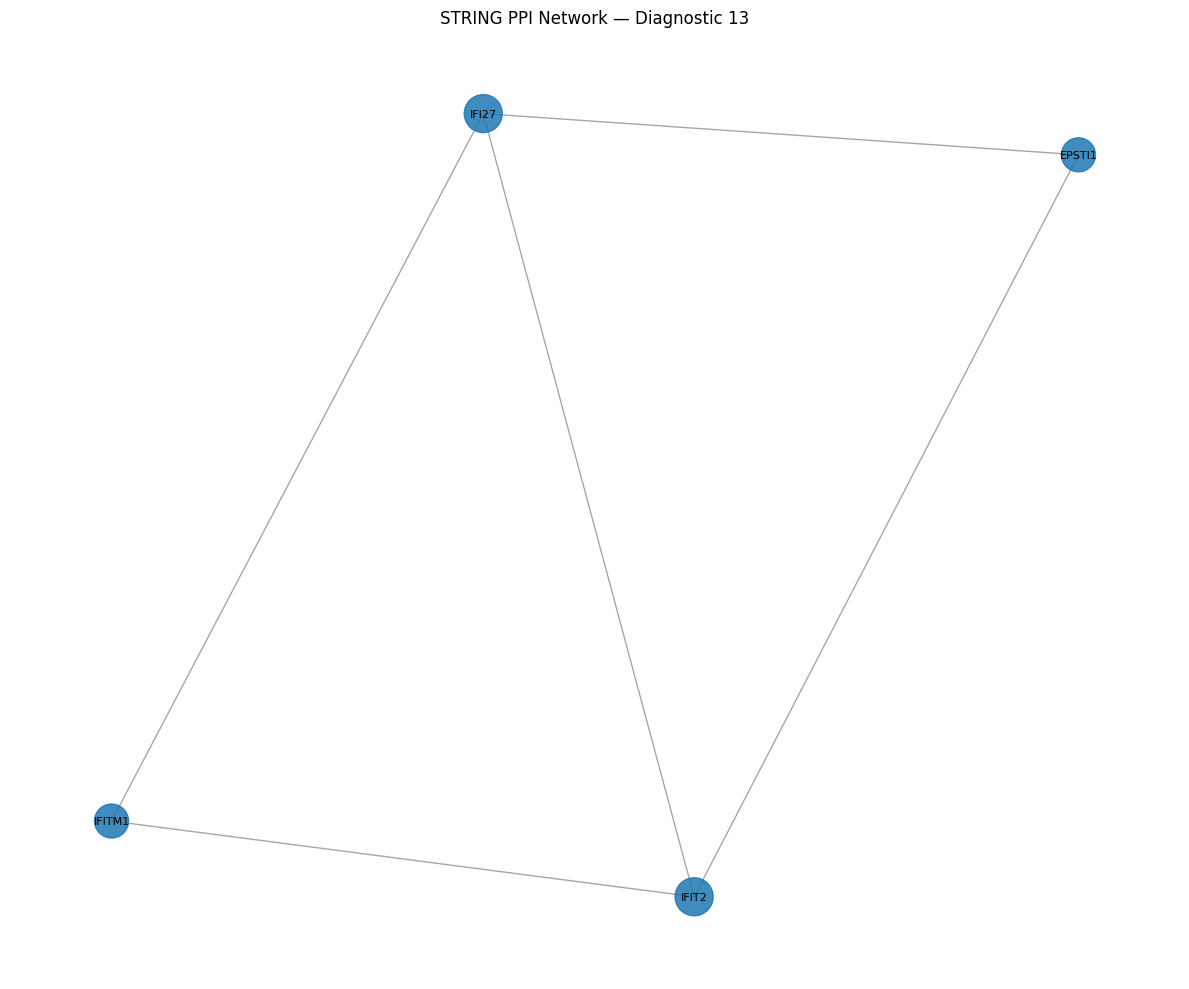

Saved: /content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/STRING/GSE88884_Diagnostic_13_STRING_network.png


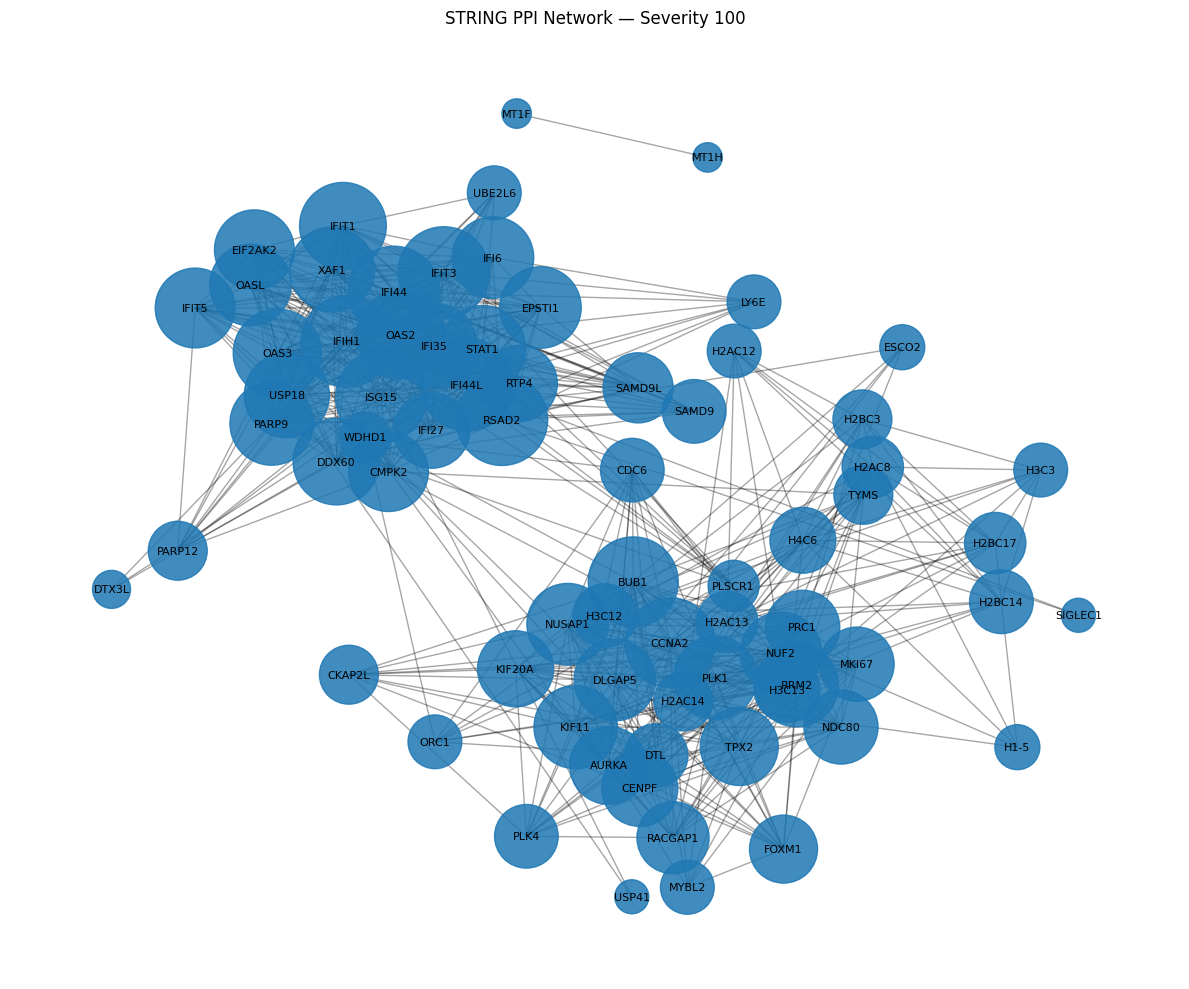

Saved: /content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/STRING/GSE88884_Severity_100_STRING_network.png


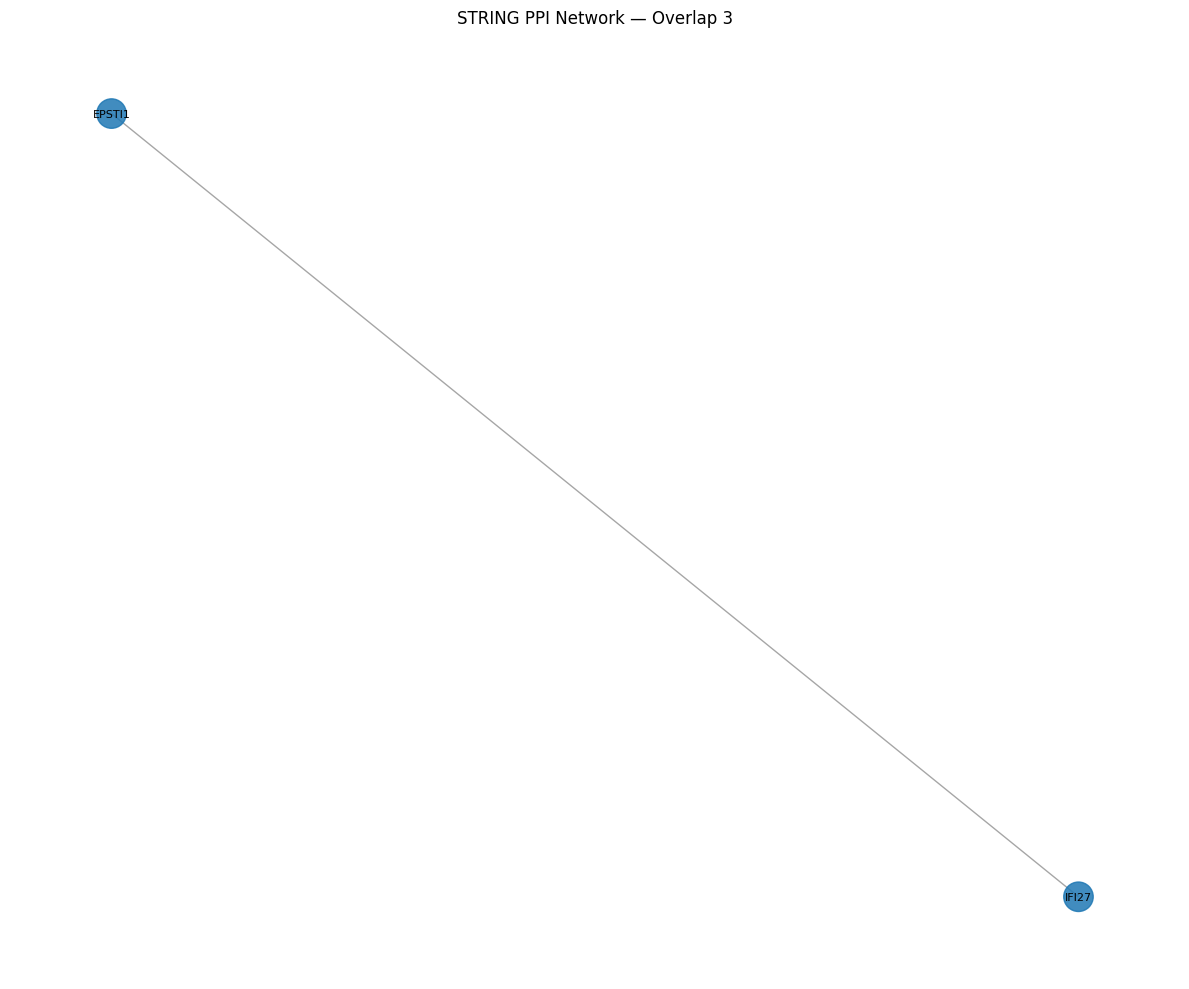

Saved: /content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/STRING/GSE88884_Overlap_3_STRING_network.png

STRING ANALYSIS COMPLETE

Panels analysed:
✓ Diagnostic — 13 genes
✓ Severity — 100 genes
✓ Overlap — IFI27, EPSTI1, ZBP1

STRING settings:
Species: Homo sapiens (9606)
Required interaction score: 700
Network expansion: NONE
STRING version: 12.0

Output directory:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/STRING

✓ Mapping tables saved
✓ Interaction networks saved
✓ PPI enrichment saved
✓ Network summary saved
✓ Overlap-gene network edges saved
✓ Network figures saved


In [43]:
# ============================================================================
# GSE88884 — STRING PPI NETWORK ANALYSIS
#
# Panels:
#   1. 13-gene diagnostic panel
#   2. 100-gene severity panel
#   3. 3-gene diagnostic–severity overlap
#
# Human / Homo sapiens
# STRING v12
# ============================================================================

import os
import io
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 100)
print("GSE88884 — STRING PPI NETWORK ANALYSIS")
print("=" * 100)

# ============================================================================
# 1. OUTPUT DIRECTORY
# ============================================================================

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis/"
    "functional_analysis/"
    "STRING"
)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

print("\nOutput directory:")
print(SAVE_DIR)

# ============================================================================
# 2. FINAL GENE PANELS
# ============================================================================

DIAGNOSTIC_13 = [
    "IFI27",
    "RPL5",
    "ZBP1",
    "IFITM1",
    "EPSTI1",
    "EBI2",
    "FCER1A",
    "GADD45A",
    "TNFSF13B",
    "IFIT2",
    "OSBPL10",
    "SCRN1",
    "TNFAIP6"
]

OVERLAP_3 = [
    "IFI27",
    "EPSTI1",
    "ZBP1"
]

# ============================================================================
# 3. RECOVER TOP 100 SEVERITY GENES
# ============================================================================

if "severity_100" in globals():

    SEVERITY_100 = list(
        dict.fromkeys(
            [
                str(g).strip().upper()
                for g in severity_100
            ]
        )
    )

elif "top100_severity" in globals():

    SEVERITY_100 = list(
        dict.fromkeys(
            top100_severity["Gene"]
            .astype(str)
            .str.strip()
            .str.upper()
            .tolist()
        )
    )

elif "severity_results" in globals():

    sev = severity_results.copy()

    sev["Gene"] = (
        sev["Gene"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    sev["FDR"] = pd.to_numeric(
        sev["FDR"],
        errors="coerce"
    )

    sev["Spearman_Rho"] = pd.to_numeric(
        sev["Spearman_Rho"],
        errors="coerce"
    )

    sev["Abs_Rho"] = (
        sev["Spearman_Rho"]
        .abs()
    )

    sev = (
        sev[
            sev["FDR"] < 0.05
        ]
        .sort_values(
            "Abs_Rho",
            ascending=False
        )
        .drop_duplicates(
            "Gene"
        )
    )

    SEVERITY_100 = (
        sev
        .head(100)["Gene"]
        .tolist()
    )

else:

    raise NameError(
        "Could not find the 100-gene severity panel. "
        "Expected severity_100, top100_severity, "
        "or severity_results."
    )

# ============================================================================
# 4. VERIFY PANELS
# ============================================================================

PANELS = {
    "Diagnostic_13": DIAGNOSTIC_13,
    "Severity_100": SEVERITY_100,
    "Overlap_3": OVERLAP_3
}

print("\n" + "-" * 100)
print("GENE PANEL SUMMARY")
print("-" * 100)

for name, genes in PANELS.items():

    print(
        f"{name:20s}: {len(genes)} genes"
    )

# ============================================================================
# 5. STRING API SETTINGS
# ============================================================================

STRING_BASE = (
    "https://string-db.org/api"
)

SPECIES = 9606

# Required confidence score:
# 700 = high confidence
REQUIRED_SCORE = 700

CALLER_IDENTITY = (
    "GSE88884_SLE_BMC_Bioinformatics"
)

# ============================================================================
# 6. STRING IDENTIFIER MAPPING
# ============================================================================

def map_to_string(
    genes
):

    print(
        f"\nMapping {len(genes)} genes to STRING..."
    )

    url = (
        STRING_BASE
        + "/tsv/get_string_ids"
    )

    data = {
        "identifiers": "\r".join(
            genes
        ),
        "species": SPECIES,
        "limit": 1,
        "echo_query": 1
    }

    response = requests.post(
        url,
        data=data,
        timeout=120
    )

    response.raise_for_status()

    mapping = pd.read_csv(
        io.StringIO(
            response.text
        ),
        sep="\t"
    )

    return mapping


# ============================================================================
# 7. MAP ALL THREE PANELS
# ============================================================================

mapped_panels = {}
mapping_tables = {}

for panel_name, genes in PANELS.items():

    mapping = map_to_string(
        genes
    )

    mapping_tables[
        panel_name
    ] = mapping

    # Keep successfully mapped genes
    if "queryItem" in mapping.columns:

        mapped_genes = (
            mapping[
                "queryItem"
            ]
            .astype(str)
            .str.strip()
            .str.upper()
            .tolist()
        )

    else:

        mapped_genes = []

    mapped_panels[
        panel_name
    ] = mapping

    print(
        f"{panel_name}: "
        f"{len(mapping)} mapped records"
    )

# ============================================================================
# 8. DISPLAY MAPPING RESULTS
# ============================================================================

print("\n" + "=" * 100)
print("STRING MAPPING RESULTS")
print("=" * 100)

for panel_name, mapping in mapping_tables.items():

    print("\n" + "-" * 100)
    print(panel_name)
    print("-" * 100)

    display(mapping)

    mapping.to_csv(
        os.path.join(
            SAVE_DIR,
            f"GSE88884_{panel_name}_STRING_mapping.csv"
        ),
        index=False
    )

# ============================================================================
# 9. FUNCTION — GET STRING IDS
# ============================================================================

def get_string_ids(
    mapping
):

    possible_id_columns = [
        "stringId",
        "stringId_A"
    ]

    for col in possible_id_columns:

        if col in mapping.columns:

            return (
                mapping[col]
                .dropna()
                .astype(str)
                .unique()
                .tolist()
            )

    raise ValueError(
        "STRING ID column not found."
    )


# ============================================================================
# 10. FUNCTION — GET NETWORK
# ============================================================================

def get_network(
    string_ids
):

    url = (
        STRING_BASE
        + "/tsv/network"
    )

    data = {
        "identifiers": "\r".join(
            string_ids
        ),
        "species": SPECIES,
        "required_score": REQUIRED_SCORE,
        "caller_identity": CALLER_IDENTITY
    }

    response = requests.post(
        url,
        data=data,
        timeout=180
    )

    response.raise_for_status()

    if not response.text.strip():

        return pd.DataFrame()

    network = pd.read_csv(
        io.StringIO(
            response.text
        ),
        sep="\t"
    )

    return network


# ============================================================================
# 11. FUNCTION — PPI ENRICHMENT
# ============================================================================

def get_ppi_enrichment(
    string_ids
):

    url = (
        STRING_BASE
        + "/tsv/ppi_enrichment"
    )

    data = {
        "identifiers": "\r".join(
            string_ids
        ),
        "species": SPECIES,
        "caller_identity": CALLER_IDENTITY
    }

    response = requests.post(
        url,
        data=data,
        timeout=180
    )

    response.raise_for_status()

    if not response.text.strip():

        return pd.DataFrame()

    return pd.read_csv(
        io.StringIO(
            response.text
        ),
        sep="\t"
    )


# ============================================================================
# 12. RUN STRING NETWORK + PPI ENRICHMENT
# ============================================================================

network_results = {}
ppi_results = {}

for panel_name, mapping in mapping_tables.items():

    print("\n" + "=" * 100)
    print(
        f"STRING ANALYSIS — {panel_name}"
    )
    print("=" * 100)

    string_ids = get_string_ids(
        mapping
    )

    print(
        "\nMapped STRING proteins:",
        len(string_ids)
    )

    # ------------------------------------------------------------
    # Network
    # ------------------------------------------------------------

    print(
        "\nRetrieving interaction network..."
    )

    network = get_network(
        string_ids
    )

    network_results[
        panel_name
    ] = network

    print(
        "Network interactions:",
        len(network)
    )

    # ------------------------------------------------------------
    # PPI enrichment
    # ------------------------------------------------------------

    print(
        "\nRunning PPI enrichment..."
    )

    ppi = get_ppi_enrichment(
        string_ids
    )

    ppi_results[
        panel_name
    ] = ppi

    if not ppi.empty:

        print(
            "\nPPI enrichment result:"
        )

        display(ppi)

    else:

        print(
            "\nNo PPI enrichment result returned."
        )

    # ------------------------------------------------------------
    # Save
    # ------------------------------------------------------------

    network.to_csv(
        os.path.join(
            SAVE_DIR,
            f"GSE88884_{panel_name}_STRING_network.csv"
        ),
        index=False
    )

    ppi.to_csv(
        os.path.join(
            SAVE_DIR,
            f"GSE88884_{panel_name}_STRING_PPI_enrichment.csv"
        ),
        index=False
    )

# ============================================================================
# 13. NETWORK SUMMARY
# ============================================================================

print("\n" + "=" * 100)
print("STRING NETWORK SUMMARY")
print("=" * 100)

network_summary = []

for panel_name, network in network_results.items():

    n_edges = len(network)

    # Try to identify nodes
    node_columns = [
        c
        for c in [
            "preferredName_A",
            "preferredName_B"
        ]
        if c in network.columns
    ]

    if len(node_columns) == 2:

        nodes = set(
            network[
                node_columns[0]
            ].dropna()
        )

        nodes.update(
            network[
                node_columns[1]
            ].dropna()
        )

        n_nodes = len(nodes)

    else:

        n_nodes = np.nan

    network_summary.append({
        "Panel": panel_name,
        "Nodes": n_nodes,
        "Interactions": n_edges
    })

network_summary = pd.DataFrame(
    network_summary
)

display(
    network_summary
)

network_summary.to_csv(
    os.path.join(
        SAVE_DIR,
        "GSE88884_STRING_network_summary.csv"
    ),
    index=False
)

# ============================================================================
# 14. PPI ENRICHMENT SUMMARY
# ============================================================================

print("\n" + "=" * 100)
print("PPI ENRICHMENT SUMMARY")
print("=" * 100)

ppi_summary = []

for panel_name, ppi in ppi_results.items():

    if ppi.empty:

        ppi_summary.append({
            "Panel": panel_name,
            "Result": "No result"
        })

    else:

        # STRING commonly returns:
        # number_of_nodes
        # number_of_edges
        # expected_number_of_edges
        # p_value
        # FDR

        row = {
            "Panel": panel_name
        }

        for col in [
            "number_of_nodes",
            "number_of_edges",
            "expected_number_of_edges",
            "p_value",
            "fdr"
        ]:

            if col in ppi.columns:

                row[col] = ppi.iloc[
                    0
                ][col]

        ppi_summary.append(
            row
        )

ppi_summary = pd.DataFrame(
    ppi_summary
)

display(
    ppi_summary
)

ppi_summary.to_csv(
    os.path.join(
        SAVE_DIR,
        "GSE88884_STRING_PPI_summary.csv"
    ),
    index=False
)

# ============================================================================
# 15. CHECK OVERLAP GENES IN STRING NETWORKS
# ============================================================================

print("\n" + "=" * 100)
print("LOCKED OVERLAP GENES IN STRING NETWORKS")
print("=" * 100)

for panel_name, network in network_results.items():

    print(
        f"\n{panel_name}"
    )

    if network.empty:

        print(
            "No network."
        )

        continue

    text_columns = [
        c
        for c in [
            "preferredName_A",
            "preferredName_B"
        ]
        if c in network.columns
    ]

    if len(text_columns) != 2:

        print(
            "Network node names unavailable."
        )

        continue

    overlap_edges = network[
        network[
            text_columns[0]
        ].isin(OVERLAP_3)
        |
        network[
            text_columns[1]
        ].isin(OVERLAP_3)
    ]

    display(
        overlap_edges
    )

    overlap_edges.to_csv(
        os.path.join(
            SAVE_DIR,
            f"GSE88884_{panel_name}_overlap_gene_edges.csv"
        ),
        index=False
    )

# ============================================================================
# 16. SIMPLE NETWORK VISUALIZATION
# ============================================================================

try:

    import networkx as nx

    print("\n" + "=" * 100)
    print("GENERATING NETWORK FIGURES")
    print("=" * 100)

    for panel_name, network in network_results.items():

        if network.empty:
            continue

        if not all(
            c in network.columns
            for c in [
                "preferredName_A",
                "preferredName_B",
                "score"
            ]
        ):
            print(
                f"{panel_name}: required columns unavailable."
            )
            continue

        # Keep high-confidence interactions
        plot_network = network[
            network["score"] >= 0.7
        ].copy()

        if plot_network.empty:

            print(
                f"{panel_name}: no high-confidence edges."
            )

            continue

        G = nx.Graph()

        for _, row in plot_network.iterrows():

            G.add_edge(
                row["preferredName_A"],
                row["preferredName_B"],
                weight=row["score"]
            )

        plt.figure(
            figsize=(12, 10)
        )

        pos = nx.spring_layout(
            G,
            seed=42,
            k=1.0
        )

        node_sizes = []

        for node in G.nodes():

            degree = G.degree(
                node
            )

            node_sizes.append(
                300
                + degree * 150
            )

        nx.draw_networkx_edges(
            G,
            pos,
            alpha=0.35,
            width=1
        )

        nx.draw_networkx_nodes(
            G,
            pos,
            node_size=node_sizes,
            alpha=0.85
        )

        nx.draw_networkx_labels(
            G,
            pos,
            font_size=8
        )

        plt.title(
            f"STRING PPI Network — "
            f"{panel_name.replace('_', ' ')}"
        )

        plt.axis(
            "off"
        )

        plt.tight_layout()

        figure_path = os.path.join(
            SAVE_DIR,
            f"GSE88884_{panel_name}_STRING_network.png"
        )

        plt.savefig(
            figure_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(
            "Saved:",
            figure_path
        )

except ImportError:

    print(
        "\nnetworkx is not installed."
    )

# ============================================================================
# 17. FINAL FILE SUMMARY
# ============================================================================

print("\n" + "=" * 100)
print("STRING ANALYSIS COMPLETE")
print("=" * 100)

print("\nPanels analysed:")

print(
    "✓ Diagnostic — 13 genes"
)

print(
    "✓ Severity — 100 genes"
)

print(
    "✓ Overlap — IFI27, EPSTI1, ZBP1"
)

print("\nSTRING settings:")
print(
    "Species: Homo sapiens (9606)"
)

print(
    "Required interaction score:",
    REQUIRED_SCORE
)

print(
    "Network expansion: NONE"
)

print(
    "STRING version: 12.0"
)

print("\nOutput directory:")
print(SAVE_DIR)

print("\n✓ Mapping tables saved")
print("✓ Interaction networks saved")
print("✓ PPI enrichment saved")
print("✓ Network summary saved")
print("✓ Overlap-gene network edges saved")
print("✓ Network figures saved")

In [44]:
# ============================================================================
# GSE88884 - SAVE COMPLETE SEVERITY ANALYSIS CHECKPOINT
# ============================================================================

import os
import pickle
import pandas as pd
import numpy as np

print("=" * 100)
print("GSE88884 - SAVING COMPLETE SEVERITY ANALYSIS CHECKPOINT")
print("=" * 100)

# ============================================================================
# 1. PATHS
# ============================================================================

BASE_DIR = (
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis"
)

CHECKPOINT_DIR = os.path.join(
    BASE_DIR,
    "checkpoint"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

print("\nCheckpoint directory:")
print(CHECKPOINT_DIR)

# ============================================================================
# 2. LOCKED PROJECT INFORMATION
# ============================================================================

PROJECT_METADATA = {

    "dataset":
        "GSE88884",

    "samples":
        1756,

    "severity_definition": {
        "Low":
            "SLEDAI <= 8",
        "Moderate":
            "SLEDAI 9-15",
        "High":
            "SLEDAI > 15"
    },

    "binary_definition": {
        "0":
            "Low-to-Moderate",
        "1":
            "High"
    },

    "candidate_panels": [
        10,
        20,
        30,
        50,
        100
    ],

    "diagnostic_panel_size":
        13,

    "locked_overlap_genes": [
        "IFI27",
        "EPSTI1",
        "ZBP1"
    ],

    "overlap_criteria": {
        "diagnostic_panel":
            13,
        "severity_significance":
            "FDR < 0.05",
        "severity_rank":
            "Top 100 by absolute Spearman rho"
    }
}

# ============================================================================
# 3. OBJECTS TO SAVE
# ============================================================================

OBJECT_NAMES = [

    "severity_df",
    "severity_model_metadata",
    "severity_3level",
    "regression_metadata",
    "valid_sledai",

    "severity_results",
    "top100_severity",
    "severity_100",

    "severity_panels",
    "regression_panels",

    "binary_results",
    "binary_model_results",
    "binary_severity_results",

    "three_level_results",
    "threelevel_results",
    "three_level_model_results",

    "regression_results",
    "sledai_regression_results",
    "regression_comparison",

    "overlap_genes",
    "locked_overlap_genes",

    "network_summary",
    "ppi_summary",

    "combined_enrichment",
    "combined_go",
    "combined_kegg",

    "cross_panel_terms",
    "shared_terms",

    "final_summary"
]

# ============================================================================
# 4. COLLECT AVAILABLE OBJECTS
# ============================================================================

checkpoint = {
    "PROJECT_METADATA":
        PROJECT_METADATA
}

saved = []
missing = []

for name in OBJECT_NAMES:

    if name not in globals():

        missing.append(
            name
        )

        continue

    obj = globals()[name]

    # Avoid saving enormous matrices accidentally.
    if isinstance(
        obj,
        pd.DataFrame
    ):

        if obj.shape[0] * obj.shape[1] > 5_000_000:

            print(
                f"Skipping large DataFrame: "
                f"{name} {obj.shape}"
            )

            continue

    if isinstance(
        obj,
        np.ndarray
    ):

        if obj.size > 5_000_000:

            print(
                f"Skipping large array: "
                f"{name} {obj.shape}"
            )

            continue

    checkpoint[
        name
    ] = obj

    saved.append(
        name
    )

# ============================================================================
# 5. SAVE CHECKPOINT
# ============================================================================

CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "GSE88884_complete_severity_checkpoint.pkl"
)

with open(
    CHECKPOINT_PATH,
    "wb"
) as f:

    pickle.dump(
        checkpoint,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )

# ============================================================================
# 6. SAVE INVENTORY
# ============================================================================

inventory = []

for name, obj in checkpoint.items():

    if isinstance(
        obj,
        pd.DataFrame
    ):

        obj_type = "DataFrame"
        shape = str(
            obj.shape
        )

    elif isinstance(
        obj,
        np.ndarray
    ):

        obj_type = "ndarray"
        shape = str(
            obj.shape
        )

    else:

        obj_type = type(
            obj
        ).__name__

        try:

            shape = str(
                len(obj)
            )

        except Exception:

            shape = ""

    inventory.append({

        "Object":
            name,

        "Type":
            obj_type,

        "Shape_or_Length":
            shape
    })

inventory_df = pd.DataFrame(
    inventory
)

INVENTORY_PATH = os.path.join(
    CHECKPOINT_DIR,
    "GSE88884_severity_checkpoint_inventory.csv"
)

inventory_df.to_csv(
    INVENTORY_PATH,
    index=False
)

# ============================================================================
# 7. FINAL REPORT
# ============================================================================

print("\n" + "=" * 100)
print("CHECKPOINT SAVED SUCCESSFULLY")
print("=" * 100)

print("\nCheckpoint:")
print(CHECKPOINT_PATH)

print("\nInventory:")
print(INVENTORY_PATH)

print("\nObjects saved:")
for name in saved:
    print(
        " ✓",
        name
    )

print(
    "\nObjects not currently available:",
    len(missing)
)

for name in missing:
    print(
        " -",
        name
    )

print("\n✓ Severity phenotype saved")
print("✓ Severity gene results saved")
print("✓ Candidate panel information saved")
print("✓ Binary modelling results saved when available")
print("✓ Three-level modelling results saved when available")
print("✓ Regression results saved when available")
print("✓ Locked overlap genes saved")
print("✓ Functional analysis results saved when available")
print("✓ Checkpoint ready for future restoration")

GSE88884 - SAVING COMPLETE SEVERITY ANALYSIS CHECKPOINT

Checkpoint directory:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/checkpoint

CHECKPOINT SAVED SUCCESSFULLY

Checkpoint:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/checkpoint/GSE88884_complete_severity_checkpoint.pkl

Inventory:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/checkpoint/GSE88884_severity_checkpoint_inventory.csv

Objects saved:
 ✓ severity_df
 ✓ severity_model_metadata
 ✓ regression_metadata
 ✓ valid_sledai
 ✓ severity_results
 ✓ top100_severity
 ✓ severity_100
 ✓ severity_panels
 ✓ regression_panels
 ✓ binary_results
 ✓ three_level_results
 ✓ regression_results
 ✓ overlap_genes
 ✓ network_summary
 ✓ ppi_summary
 ✓ shared_terms

Objects not currently available: 13
 - severity_3level
 - binary_model_results
 - binary_severity_results
 - threelevel_results
 - three_level_model_results
 - sledai_regression_results
 - regression_compa

In [45]:
# ============================================================================
# GSE88884 - INTEGRATED DIAGNOSTIC-SEVERITY-OVERLAP ANALYSIS
# GO + KEGG + STRING
# ============================================================================

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 100)
print("GSE88884 - INTEGRATED FUNCTIONAL ANALYSIS")
print("=" * 100)

# ============================================================================
# 1. DIRECTORIES
# ============================================================================

BASE_DIR = (
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis"
)

FUNCTIONAL_DIR = os.path.join(
    BASE_DIR,
    "functional_analysis"
)

STRING_DIR = os.path.join(
    FUNCTIONAL_DIR,
    "STRING"
)

INTEGRATED_DIR = os.path.join(
    FUNCTIONAL_DIR,
    "Integrated_Analysis"
)

os.makedirs(
    INTEGRATED_DIR,
    exist_ok=True
)

print("\nFunctional directory:")
print(FUNCTIONAL_DIR)

print("\nIntegrated output directory:")
print(INTEGRATED_DIR)

# ============================================================================
# 2. FINAL GENE PANELS
# ============================================================================

DIAGNOSTIC_13 = [
    "IFI27",
    "RPL5",
    "ZBP1",
    "IFITM1",
    "EPSTI1",
    "EBI2",
    "FCER1A",
    "GADD45A",
    "TNFSF13B",
    "IFIT2",
    "OSBPL10",
    "SCRN1",
    "TNFAIP6"
]

OVERLAP_3 = [
    "IFI27",
    "EPSTI1",
    "ZBP1"
]

# ============================================================================
# 3. GET THE 100 SEVERITY GENES
# ============================================================================

SEVERITY_100 = None

if "severity_100" in globals():

    if isinstance(severity_100, pd.DataFrame):

        if "Gene" in severity_100.columns:

            SEVERITY_100 = (
                severity_100["Gene"]
                .astype(str)
                .str.strip()
                .str.upper()
                .tolist()
            )

    elif isinstance(
        severity_100,
        (list, tuple, np.ndarray, pd.Series)
    ):

        SEVERITY_100 = [
            str(g).strip().upper()
            for g in severity_100
        ]

elif "top100_severity" in globals():

    if isinstance(
        top100_severity,
        pd.DataFrame
    ):

        if "Gene" in top100_severity.columns:

            SEVERITY_100 = (
                top100_severity["Gene"]
                .astype(str)
                .str.strip()
                .str.upper()
                .tolist()
            )

elif "severity_results" in globals():

    if isinstance(
        severity_results,
        pd.DataFrame
    ):

        sev = severity_results.copy()

        sev["Gene"] = (
            sev["Gene"]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        sev["FDR"] = pd.to_numeric(
            sev["FDR"],
            errors="coerce"
        )

        sev["Spearman_Rho"] = pd.to_numeric(
            sev["Spearman_Rho"],
            errors="coerce"
        )

        sev["Abs_Rho"] = (
            sev["Spearman_Rho"].abs()
        )

        sev = sev[
            sev["FDR"] < 0.05
        ].copy()

        sev = (
            sev
            .sort_values(
                "Abs_Rho",
                ascending=False
            )
            .drop_duplicates(
                subset="Gene"
            )
        )

        SEVERITY_100 = (
            sev
            .head(100)["Gene"]
            .tolist()
        )

if SEVERITY_100 is None:

    raise NameError(
        "The 100-gene severity panel could not be recovered. "
        "Run the severity gene-selection cell first."
    )

SEVERITY_100 = list(
    dict.fromkeys(
        SEVERITY_100
    )
)

# ============================================================================
# 4. VERIFY PANELS
# ============================================================================

print("\n" + "-" * 100)
print("FINAL PANELS")
print("-" * 100)

print(
    "Diagnostic panel:",
    len(DIAGNOSTIC_13)
)

print(
    "Severity panel:",
    len(SEVERITY_100)
)

print(
    "Overlap panel:",
    len(OVERLAP_3)
)

print(
    "\nLocked overlap genes:",
    ", ".join(OVERLAP_3)
)

# ============================================================================
# 5. SEARCH ALL FUNCTIONAL ANALYSIS CSV FILES
# ============================================================================

if not os.path.exists(
    FUNCTIONAL_DIR
):

    raise FileNotFoundError(
        f"Functional analysis directory not found:\n"
        f"{FUNCTIONAL_DIR}"
    )

all_csv_files = []

for root, dirs, files in os.walk(
    FUNCTIONAL_DIR
):

    for file in files:

        if file.lower().endswith(
            ".csv"
        ):

            all_csv_files.append(
                os.path.join(
                    root,
                    file
                )
            )

print("\n" + "-" * 100)
print("FUNCTIONAL ANALYSIS FILES FOUND")
print("-" * 100)

for file in all_csv_files:

    print(
        os.path.relpath(
            file,
            FUNCTIONAL_DIR
        )
    )

# ============================================================================
# 6. IDENTIFY GO FILES
# ============================================================================

go_files = []

for file in all_csv_files:

    name = os.path.basename(
        file
    ).lower()

    if "go" in name:

        if (
            "enrichment" in name
            or
            "result" in name
        ):

            go_files.append(
                file
            )

# ============================================================================
# 7. IDENTIFY KEGG FILES
# ============================================================================

kegg_files = []

for file in all_csv_files:

    name = os.path.basename(
        file
    ).lower()

    if "kegg" in name:

        if (
            "enrichment" in name
            or
            "result" in name
        ):

            kegg_files.append(
                file
            )

print("\nGO files:", len(go_files))
print("KEGG files:", len(kegg_files))

# ============================================================================
# 8. FUNCTION TO IDENTIFY PANEL
# ============================================================================

def identify_panel(
    filename
):

    name = filename.lower()

    if (
        "diagnostic" in name
        or
        "13gene" in name
        or
        "13_gene" in name
    ):

        return "Diagnostic_13"

    if (
        "severity" in name
        or
        "100gene" in name
        or
        "100_gene" in name
    ):

        return "Severity_100"

    if (
        "overlap" in name
        or
        "3gene" in name
        or
        "3_gene" in name
    ):

        return "Overlap_3"

    return "Unknown"

# ============================================================================
# 9. LOAD GO RESULTS
# ============================================================================

go_tables = []

for file in go_files:

    try:

        df = pd.read_csv(
            file
        )

    except Exception as e:

        print(
            "\nCould not read GO file:",
            file
        )

        print(
            "Error:",
            e
        )

        continue

    if df.empty:

        continue

    panel = identify_panel(
        os.path.basename(file)
    )

    if panel == "Unknown":

        continue

    df = df.copy()

    df["Panel"] = panel

    df["Source_File"] = (
        os.path.basename(file)
    )

    df["Analysis"] = "GO"

    go_tables.append(
        df
    )

if go_tables:

    GO_ALL = pd.concat(
        go_tables,
        ignore_index=True
    )

else:

    GO_ALL = pd.DataFrame()

# ============================================================================
# 10. LOAD KEGG RESULTS
# ============================================================================

kegg_tables = []

for file in kegg_files:

    try:

        df = pd.read_csv(
            file
        )

    except Exception as e:

        print(
            "\nCould not read KEGG file:",
            file
        )

        print(
            "Error:",
            e
        )

        continue

    if df.empty:

        continue

    panel = identify_panel(
        os.path.basename(file)
    )

    if panel == "Unknown":

        continue

    df = df.copy()

    df["Panel"] = panel

    df["Source_File"] = (
        os.path.basename(file)
    )

    df["Analysis"] = "KEGG"

    kegg_tables.append(
        df
    )

if kegg_tables:

    KEGG_ALL = pd.concat(
        kegg_tables,
        ignore_index=True
    )

else:

    KEGG_ALL = pd.DataFrame()

# ============================================================================
# 11. DISPLAY GO/KEGG SUMMARY
# ============================================================================

print("\n" + "=" * 100)
print("GO RESULTS")
print("=" * 100)

if GO_ALL.empty:

    print(
        "No GO results were found."
    )

else:

    print(
        "Total GO rows:",
        len(GO_ALL)
    )

    print(
        "\nBy panel:"
    )

    print(
        GO_ALL[
            "Panel"
        ].value_counts()
    )

print("\n" + "=" * 100)
print("KEGG RESULTS")
print("=" * 100)

if KEGG_ALL.empty:

    print(
        "No KEGG results were found."
    )

else:

    print(
        "Total KEGG rows:",
        len(KEGG_ALL)
    )

    print(
        "\nBy panel:"
    )

    print(
        KEGG_ALL[
            "Panel"
        ].value_counts()
    )

# ============================================================================
# 12. COMBINE GO + KEGG
# ============================================================================

functional_tables = []

if not GO_ALL.empty:

    functional_tables.append(
        GO_ALL
    )

if not KEGG_ALL.empty:

    functional_tables.append(
        KEGG_ALL
    )

if functional_tables:

    FUNCTIONAL_ALL = pd.concat(
        functional_tables,
        ignore_index=True,
        sort=False
    )

else:

    FUNCTIONAL_ALL = pd.DataFrame()

# ============================================================================
# 13. IDENTIFY TERM COLUMN
# ============================================================================

if not FUNCTIONAL_ALL.empty:

    term_column = None

    for candidate in [
        "Term",
        "term",
        "Description",
        "description",
        "name",
        "Name"
    ]:

        if candidate in FUNCTIONAL_ALL.columns:

            term_column = candidate
            break

    if term_column is None:

        raise KeyError(
            "Could not identify GO/KEGG term column."
        )

    FUNCTIONAL_ALL[
        "Functional_Term"
    ] = (
        FUNCTIONAL_ALL[
            term_column
        ]
        .astype(str)
        .str.strip()
    )

# ============================================================================
# 14. IDENTIFY P-VALUE COLUMN
# ============================================================================

if not FUNCTIONAL_ALL.empty:

    p_column = None

    for candidate in [
        "P_value",
        "p_value",
        "PValue",
        "pvalue",
        "P-value",
        "p.adjust",
        "Adjusted_P"
    ]:

        if candidate in FUNCTIONAL_ALL.columns:

            p_column = candidate
            break

    if p_column is not None:

        FUNCTIONAL_ALL[
            "P_value_standardized"
        ] = pd.to_numeric(
            FUNCTIONAL_ALL[
                p_column
            ],
            errors="coerce"
        )

    else:

        FUNCTIONAL_ALL[
            "P_value_standardized"
        ] = np.nan

# ============================================================================
# 15. SAVE COMPLETE FUNCTIONAL TABLE
# ============================================================================

functional_path = os.path.join(
    INTEGRATED_DIR,
    "GSE88884_GO_KEGG_integrated_results.csv"
)

if not FUNCTIONAL_ALL.empty:

    FUNCTIONAL_ALL.to_csv(
        functional_path,
        index=False
    )

    print(
        "\nSaved:",
        functional_path
    )

# ============================================================================
# 16. FIND SIGNIFICANT TERMS
# ============================================================================

if not FUNCTIONAL_ALL.empty:

    SIGNIFICANT_FUNCTIONAL = (
        FUNCTIONAL_ALL[
            FUNCTIONAL_ALL[
                "P_value_standardized"
            ] < 0.05
        ]
        .copy()
    )

else:

    SIGNIFICANT_FUNCTIONAL = (
        pd.DataFrame()
    )

print("\n" + "=" * 100)
print("SIGNIFICANT FUNCTIONAL TERMS")
print("=" * 100)

if SIGNIFICANT_FUNCTIONAL.empty:

    print(
        "No terms with a directly identifiable "
        "P < 0.05 were found."
    )

else:

    print(
        "Significant terms:",
        len(SIGNIFICANT_FUNCTIONAL)
    )

# ============================================================================
# 17. SHARED FUNCTIONAL TERMS
# ============================================================================

if not SIGNIFICANT_FUNCTIONAL.empty:

    shared_terms = (
        SIGNIFICANT_FUNCTIONAL[
            [
                "Analysis",
                "Panel",
                "Functional_Term"
            ]
        ]
        .drop_duplicates()
    )

    term_panel_count = (
        shared_terms
        .groupby(
            [
                "Analysis",
                "Functional_Term"
            ]
        )[
            "Panel"
        ]
        .nunique()
        .reset_index(
            name="Number_of_Panels"
        )
    )

    term_panels = (
        shared_terms
        .groupby(
            [
                "Analysis",
                "Functional_Term"
            ]
        )[
            "Panel"
        ]
        .apply(
            lambda x:
            "; ".join(
                sorted(
                    set(x)
                )
            )
        )
        .reset_index(
            name="Panels"
        )
    )

    SHARED_TERMS = (
        term_panel_count
        .merge(
            term_panels,
            on=[
                "Analysis",
                "Functional_Term"
            ],
            how="left"
        )
        .sort_values(
            "Number_of_Panels",
            ascending=False
        )
    )

else:

    SHARED_TERMS = pd.DataFrame()

# ============================================================================
# 18. SAVE SHARED TERMS
# ============================================================================

shared_path = os.path.join(
    INTEGRATED_DIR,
    "GSE88884_shared_GO_KEGG_terms.csv"
)

SHARED_TERMS.to_csv(
    shared_path,
    index=False
)

print("\n" + "=" * 100)
print("SHARED GO/KEGG TERMS")
print("=" * 100)

if SHARED_TERMS.empty:

    print(
        "No shared terms identified."
    )

else:

    display(
        SHARED_TERMS.head(50)
    )

# ============================================================================
# 19. TERMS SHARED BY ALL THREE PANELS
# ============================================================================

if not SHARED_TERMS.empty:

    ALL_THREE_TERMS = SHARED_TERMS[
        SHARED_TERMS[
            "Number_of_Panels"
        ] == 3
    ].copy()

else:

    ALL_THREE_TERMS = pd.DataFrame()

all_three_path = os.path.join(
    INTEGRATED_DIR,
    "GSE88884_GO_KEGG_terms_shared_by_all_three.csv"
)

ALL_THREE_TERMS.to_csv(
    all_three_path,
    index=False
)

print("\n" + "=" * 100)
print("TERMS SHARED BY ALL THREE PANELS")
print("=" * 100)

if ALL_THREE_TERMS.empty:

    print(
        "No GO/KEGG terms were shared by all three panels."
    )

else:

    display(
        ALL_THREE_TERMS
    )

# ============================================================================
# 20. LOAD STRING RESULTS
# ============================================================================

STRING_SUMMARY = os.path.join(
    STRING_DIR,
    "GSE88884_STRING_PPI_summary.csv"
)

STRING_NETWORK_SUMMARY = os.path.join(
    STRING_DIR,
    "GSE88884_STRING_network_summary.csv"
)

if os.path.exists(
    STRING_SUMMARY
):

    STRING_PPI = pd.read_csv(
        STRING_SUMMARY
    )

else:

    STRING_PPI = pd.DataFrame()

if os.path.exists(
    STRING_NETWORK_SUMMARY
):

    STRING_NETWORK = pd.read_csv(
        STRING_NETWORK_SUMMARY
    )

else:

    STRING_NETWORK = pd.DataFrame()

# ============================================================================
# 21. DISPLAY STRING
# ============================================================================

print("\n" + "=" * 100)
print("STRING PPI COMPARISON")
print("=" * 100)

if not STRING_PPI.empty:

    display(
        STRING_PPI
    )

else:

    print(
        "STRING PPI summary not found."
    )

print("\n" + "-" * 100)

if not STRING_NETWORK.empty:

    display(
        STRING_NETWORK
    )

else:

    print(
        "STRING network summary not found."
    )

# ============================================================================
# 22. BUILD INTEGRATED PANEL SUMMARY
# ============================================================================

INTEGRATED_SUMMARY = pd.DataFrame({

    "Panel": [
        "Diagnostic_13",
        "Severity_100",
        "Overlap_3"
    ],

    "Genes": [
        13,
        len(SEVERITY_100),
        3
    ]
})

if not FUNCTIONAL_ALL.empty:

    functional_counts = (
        SIGNIFICANT_FUNCTIONAL
        .groupby(
            "Panel"
        )
        .size()
        .reset_index(
            name="Significant_GO_KEGG_Terms"
        )
    )

    INTEGRATED_SUMMARY = (
        INTEGRATED_SUMMARY
        .merge(
            functional_counts,
            on="Panel",
            how="left"
        )
    )

else:

    INTEGRATED_SUMMARY[
        "Significant_GO_KEGG_Terms"
    ] = 0

INTEGRATED_SUMMARY[
    "Significant_GO_KEGG_Terms"
] = (
    INTEGRATED_SUMMARY[
        "Significant_GO_KEGG_Terms"
    ]
    .fillna(0)
    .astype(int)
)

if not STRING_NETWORK.empty:

    string_network_copy = (
        STRING_NETWORK.copy()
    )

    if "Panel" in string_network_copy.columns:

        INTEGRATED_SUMMARY = (
            INTEGRATED_SUMMARY
            .merge(
                string_network_copy,
                on="Panel",
                how="left"
            )
        )

if not STRING_PPI.empty:

    string_ppi_copy = (
        STRING_PPI.copy()
    )

    if "Panel" in string_ppi_copy.columns:

        INTEGRATED_SUMMARY = (
            INTEGRATED_SUMMARY
            .merge(
                string_ppi_copy,
                on="Panel",
                how="left",
                suffixes=(
                    "",
                    "_PPI"
                )
            )
        )

# ============================================================================
# 23. SAVE INTEGRATED SUMMARY
# ============================================================================

SUMMARY_PATH = os.path.join(
    INTEGRATED_DIR,
    "GSE88884_INTEGRATED_FUNCTIONAL_SUMMARY.csv"
)

INTEGRATED_SUMMARY.to_csv(
    SUMMARY_PATH,
    index=False
)

print("\n" + "=" * 100)
print("INTEGRATED SUMMARY")
print("=" * 100)

display(
    INTEGRATED_SUMMARY
)

# ============================================================================
# 24. FUNCTIONAL OVERLAP GRAPH
# ============================================================================

if not SHARED_TERMS.empty:

    plot_df = (
        SHARED_TERMS
        .sort_values(
            "Number_of_Panels",
            ascending=False
        )
        .head(20)
        .copy()
    )

    if not plot_df.empty:

        labels = (
            plot_df[
                "Functional_Term"
            ]
            .astype(str)
            .str.slice(
                0,
                65
            )
        )

        plt.figure(
            figsize=(11, 8)
        )

        plt.barh(
            labels.iloc[::-1],
            plot_df[
                "Number_of_Panels"
            ].iloc[::-1]
        )

        plt.xlabel(
            "Number of Panels"
        )

        plt.ylabel(
            "Functional Term"
        )

        plt.title(
            "Shared GO/KEGG Functional Terms"
        )

        plt.tight_layout()

        GRAPH_PATH = os.path.join(
            INTEGRATED_DIR,
            "GSE88884_shared_GO_KEGG_terms.png"
        )

        plt.savefig(
            GRAPH_PATH,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(
            "\nGraph saved:",
            GRAPH_PATH
        )

# ============================================================================
# 25. FINAL OUTPUT LIST
# ============================================================================

print("\n" + "=" * 100)
print("INTEGRATED ANALYSIS COMPLETE")
print("=" * 100)

print(
    "\nOutput directory:"
)

print(
    INTEGRATED_DIR
)

print(
    "\nFiles:"
)

for file in sorted(
    os.listdir(
        INTEGRATED_DIR
    )
):

    print(
        " -",
        file
    )

print("\n✓ Diagnostic 13 included")
print("✓ Severity 100 included")
print("✓ Locked overlap 3 included")
print("✓ GO integrated")
print("✓ KEGG integrated")
print("✓ STRING integrated")
print("✓ Shared functional terms identified")
print("✓ Integrated summary saved")

GSE88884 - INTEGRATED FUNCTIONAL ANALYSIS

Functional directory:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis

Integrated output directory:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/Integrated_Analysis

----------------------------------------------------------------------------------------------------
FINAL PANELS
----------------------------------------------------------------------------------------------------
Diagnostic panel: 13
Severity panel: 100
Overlap panel: 3

Locked overlap genes: IFI27, EPSTI1, ZBP1

----------------------------------------------------------------------------------------------------
FUNCTIONAL ANALYSIS FILES FOUND
----------------------------------------------------------------------------------------------------
GSE88884_Overlap3_GO_KEGG.csv
GSE88884_GO_KEGG_all_enrichment.csv
GSE88884_Severity100_GO_KEGG.csv
GSE88884_Diagnostic13_GO_KEGG.csv
GSE88884_share

,Panel,number_of_nodes,number_of_edges,expected_number_of_edges,p_value
0,Diagnostic_13,13.0,11.0,1.0,2.030000e-08
1,Severity_100,90.0,953.0,133.0,0.000000e+00
2,Overlap_3,3.0,1.0,0.0,9.100000e-03



----------------------------------------------------------------------------------------------------


,Panel,Nodes,Interactions
0,Diagnostic_13,4,5
1,Severity_100,72,574
2,Overlap_3,2,1



INTEGRATED SUMMARY


,Panel,Genes,Significant_GO_KEGG_Terms,Nodes,Interactions,number_of_nodes,number_of_edges,expected_number_of_edges,p_value
0,Diagnostic_13,13,0,4,5,13.0,11.0,1.0,2.030000e-08
1,Severity_100,100,0,72,574,90.0,953.0,133.0,0.000000e+00
2,Overlap_3,3,0,2,1,3.0,1.0,0.0,9.100000e-03



INTEGRATED ANALYSIS COMPLETE

Output directory:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/Integrated_Analysis

Files:
 - Figures
 - GSE88884_Diagnostic13_Severity100_shared_terms.csv
 - GSE88884_Diagnostic13_specific_terms.csv
 - GSE88884_FINAL_INTEGRATED_FUNCTIONAL_ANALYSIS.xlsx
 - GSE88884_FINAL_INTEGRATED_GO_KEGG_STRING_SUMMARY.csv
 - GSE88884_GO_KEGG_panel_overlap_matrix.csv
 - GSE88884_GO_KEGG_shared_by_all_three.csv
 - GSE88884_GO_KEGG_terms_shared_by_all_three.csv
 - GSE88884_INTEGRATED_FUNCTIONAL_SUMMARY.csv
 - GSE88884_Overlap3_specific_terms.csv
 - GSE88884_STRING_panel_comparison.png
 - GSE88884_Severity100_specific_terms.csv
 - GSE88884_functional_enrichment_panel_comparison.png
 - GSE88884_integrated_GO_KEGG_all_three_panels.csv
 - GSE88884_integrated_significant_GO_KEGG.csv
 - GSE88884_shared_GO_KEGG_terms.csv
 - GSE88884_top10_significant_terms_per_panel.csv

✓ Diagnostic 13 included
✓ Severity 100 included
✓ Locked ove

GSE88884 - CORRECTED INTEGRATED GO + KEGG ANALYSIS

Checking exact files:

Diagnostic_13:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/GSE88884_Diagnostic13_GO_KEGG.csv
✓ Found

Severity_100:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/GSE88884_Severity100_GO_KEGG.csv
✓ Found

Overlap_3:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/GSE88884_Overlap3_GO_KEGG.csv
✓ Found

Diagnostic_13: (829, 20)
Columns: ['Panel', 'source', 'native', 'name', 'description', 'p_value', 'significant', 'intersection_size', 'term_size', 'query_size', 'effective_domain_size', 'goshv', 'intersections', 'parents', 'precision', 'query', 'recall', 'source_order', 'group_id', 'BH_FDR']

Severity_100: (2368, 20)
Columns: ['Panel', 'source', 'native', 'name', 'description', 'p_value', 'significant', 'intersection_size', 'term_size', 'query_size', 'effective_domain_size', 'g

,Panel,source,native,name,description,p_value,significant,intersection_size,term_size,query_size,effective_domain_size,goshv,intersections,parents,precision,query,recall,source_order,group_id,BH_FDR
0,Diagnostic_13,GO:BP,GO:0060337,type I interferon-mediated signaling pathway,"""The series of molecular signals initiated by ...",0.012042,True,3,85,11,20972,23681,"[['IMP'], [], ['IBA', 'IEA'], ['IBA'], [], [],...","['GO:0071357', 'GO:0140888']",0.272727,query_1,0.035294,13558,3,1.0
1,Diagnostic_13,GO:BP,GO:0071357,cellular response to type I interferon,"""Any process that results in a change in state...",0.012474,True,3,86,11,20972,25596,"[['IMP'], [], ['IBA', 'IEA'], ['IBA'], [], [],...","['GO:0034340', 'GO:0071345']",0.272727,query_1,0.034884,15473,3,1.0
2,Diagnostic_13,GO:BP,GO:0034340,response to type I interferon,"""Any process that results in a change in state...",0.015280,True,3,92,11,20972,18128,"[['IMP'], [], ['IBA', 'IEA'], ['IBA'], [], [],...","['GO:0034097', 'GO:0045087']",0.272727,query_1,0.032609,8005,3,1.0
3,Diagnostic_13,GO:BP,GO:0051607,defense response to virus,"""Reactions triggered in response to the presen...",0.019223,True,4,322,11,20972,23022,"[['IMP', 'IEA'], [], ['IDA', 'IMP', 'ISS', 'IE...","['GO:0006952', 'GO:0009615']",0.363636,query_1,0.012422,12899,3,1.0
4,Diagnostic_13,GO:BP,GO:0140888,interferon-mediated signaling pathway,"""The series of molecular signals initiated by ...",0.026843,True,3,111,11,20972,28801,"[['IMP'], [], ['IBA', 'IEA'], ['IBA'], [], [],...",['GO:0019221'],0.272727,query_1,0.027027,18678,3,1.0
5,Diagnostic_13,GO:BP,GO:0009615,response to virus,"""Any process that results in a change in state...",0.052432,False,4,416,11,20972,13507,"[['IMP', 'IEA'], [], ['IDA', 'IMP', 'ISS', 'IE...",['GO:0051707'],0.363636,query_1,0.009615,3384,3,1.0
6,Diagnostic_13,KEGG,KEGG:04064,NF-kappa B signaling pathway,NF-kappa B signaling pathway,0.101686,False,2,103,6,8716,39001,"[[], [], [], [], [], [], ['KEGG'], ['KEGG'], [...",['KEGG:00000'],0.333333,query_1,0.019417,263,4,1.0
7,Diagnostic_13,GO:MF,GO:0019768,high-affinity IgE receptor activity,"""Combining with high affinity with an immunogl...",0.136198,False,1,1,12,20208,3401,"[[], [], [], [], [], ['IDA', 'IBA'], [], [], [...",['GO:0019767'],0.083333,query_1,1.000000,3401,1,1.0
8,Diagnostic_13,GO:MF,GO:0003692,left-handed Z-DNA binding,"""Binding to DNA in the Z form, i.e. a left-han...",0.136198,False,1,1,12,20208,322,"[[], [], ['NAS'], [], [], [], [], [], [], [], ...",['GO:0003690'],0.083333,query_1,1.000000,322,1,1.0
9,Diagnostic_13,GO:BP,GO:0019221,cytokine-mediated signaling pathway,"""The series of molecular signals initiated by ...",0.170838,False,4,564,11,20972,15398,"[['IMP'], [], ['ISS', 'IBA', 'IEA'], ['IBA'], ...","['GO:0007166', 'GO:0071345']",0.363636,query_1,0.007092,5275,3,1.0



Severity_100


,Panel,source,native,name,description,p_value,significant,intersection_size,term_size,query_size,effective_domain_size,goshv,intersections,parents,precision,query,recall,source_order,group_id,BH_FDR
0,Severity_100,GO:BP,GO:0051607,defense response to virus,"""Reactions triggered in response to the presen...",3.720832e-18,True,21,322,73,20972,23022,"[[], [], [], [], [], ['IDA'], [], [], [], [], ...","['GO:0006952', 'GO:0009615']",0.287671,query_1,0.065217,12899,3,8.810930e-15
1,Severity_100,GO:BP,GO:0009615,response to virus,"""Any process that results in a change in state...",3.403494e-17,True,22,416,73,20972,13507,"[[], [], [], [], [], ['IDA'], [], [], [], [], ...",['GO:0051707'],0.301370,query_1,0.052885,3384,3,4.029737e-14
2,Severity_100,GO:BP,GO:0048525,negative regulation of viral process,"""Any process that stops, prevents, or reduces ...",6.274717e-14,True,12,77,73,20972,22082,"[[], [], [], [], [], [], [], [], [], [], [], [...","['GO:0016032', 'GO:0048519', 'GO:0050792']",0.164384,query_1,0.155844,11959,3,4.952843e-11
3,Severity_100,GO:BP,GO:0045071,negative regulation of viral genome replication,"""Any process that stops, prevents, or reduces ...",2.613246e-12,True,10,51,73,20972,20633,"[[], [], [], [], [], [], [], [], [], [], [], [...","['GO:0019079', 'GO:0045069', 'GO:0048525']",0.136986,query_1,0.196078,10510,3,1.547042e-09
4,Severity_100,GO:BP,GO:0045087,innate immune response,"""Innate immune responses are defense responses...",4.422112e-12,True,25,1018,73,20972,20634,"[[], [], [], [], [], ['IDA'], [], [], [], [], ...","['GO:0006955', 'GO:0140546']",0.342466,query_1,0.024558,10511,3,1.557162e-09
5,Severity_100,GO:BP,GO:0010564,regulation of cell cycle process,"""Any process that modulates a cellular process...",4.590231e-12,True,22,728,73,20972,14154,"[['IDA'], [], [], ['IDA', 'IMP', 'IBA', 'TAS',...","['GO:0022402', 'GO:0051726']",0.301370,query_1,0.030220,4031,3,1.557162e-09
6,Severity_100,GO:BP,GO:0051707,response to other organism,"""Any process that results in a change in state...",5.004387e-12,True,30,1610,73,20972,23101,"[[], [], [], [], [], ['IDA', 'IEA'], [], [], [...","['GO:0043207', 'GO:0044419']",0.410959,query_1,0.018634,12978,3,1.557162e-09
7,Severity_100,GO:BP,GO:0043207,response to external biotic stimulus,"""Any process that results in a change in state...",5.260683e-12,True,30,1613,73,20972,20031,"[[], [], [], [], [], ['IDA', 'IEA'], [], [], [...","['GO:0009605', 'GO:0009607']",0.410959,query_1,0.018599,9908,3,1.557162e-09
8,Severity_100,GO:BP,GO:0044419,biological process involved in interspecies in...,"""Any process evolved to enable an interaction ...",8.701151e-12,True,31,1777,73,20972,20411,"[[], [], [], [], [], ['IDA', 'IEA'], [], [], [...",['GO:0008150'],0.424658,query_1,0.017445,10288,3,2.289370e-09
9,Severity_100,GO:BP,GO:0009607,response to biotic stimulus,"""Any process that results in a change in state...",9.974203e-12,True,30,1652,73,20972,13501,"[[], [], [], [], [], ['IDA', 'IEA'], [], [], [...",['GO:0050896'],0.410959,query_1,0.018160,3378,3,2.361891e-09



Overlap_3


...


STRING RESULTS


,Panel,number_of_nodes,number_of_edges,expected_number_of_edges,p_value
0,Diagnostic_13,13.0,11.0,1.0,2.030000e-08
1,Severity_100,90.0,953.0,133.0,0.000000e+00
2,Overlap_3,3.0,1.0,0.0,9.100000e-03


,Panel,Nodes,Interactions
0,Diagnostic_13,4,5
1,Severity_100,72,574
2,Overlap_3,2,1



FINAL INTEGRATED SUMMARY


,Panel,Genes,Significant_GO_KEGG,Diagnostic_Severity_Shared,All_Three_Shared,Nodes,Interactions,number_of_nodes,number_of_edges,expected_number_of_edges,p_value
0,Diagnostic_13,13,5,5,4,4,5,13.0,11.0,1.0,2.030000e-08
1,Severity_100,100,171,5,4,72,574,90.0,953.0,133.0,0.000000e+00
2,Overlap_3,3,6,5,4,2,1,3.0,1.0,0.0,9.100000e-03


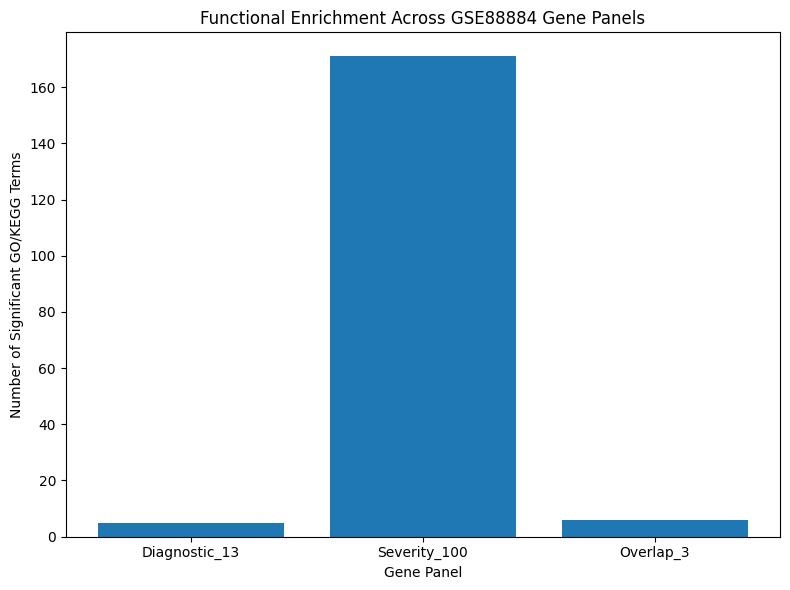

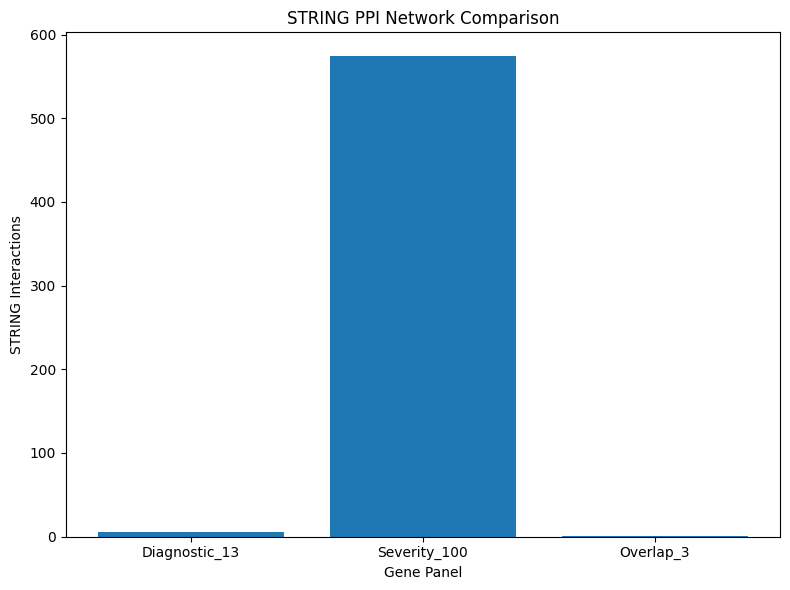


INTEGRATED ANALYSIS COMPLETE

Output directory:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/Integrated_Analysis

Generated files:
 - Figures
 - GSE88884_Diagnostic13_Severity100_shared_terms.csv
 - GSE88884_Diagnostic13_specific_terms.csv
 - GSE88884_FINAL_INTEGRATED_FUNCTIONAL_ANALYSIS.xlsx
 - GSE88884_FINAL_INTEGRATED_GO_KEGG_STRING_SUMMARY.csv
 - GSE88884_GO_KEGG_panel_overlap_matrix.csv
 - GSE88884_GO_KEGG_shared_by_all_three.csv
 - GSE88884_GO_KEGG_terms_shared_by_all_three.csv
 - GSE88884_INTEGRATED_FUNCTIONAL_SUMMARY.csv
 - GSE88884_Overlap3_specific_terms.csv
 - GSE88884_STRING_panel_comparison.png
 - GSE88884_Severity100_specific_terms.csv
 - GSE88884_functional_enrichment_panel_comparison.png
 - GSE88884_integrated_GO_KEGG_all_three_panels.csv
 - GSE88884_integrated_significant_GO_KEGG.csv
 - GSE88884_shared_GO_KEGG_terms.csv
 - GSE88884_top10_significant_terms_per_panel.csv

✓ Diagnostic 13 analyzed
✓ Severity 100 analyzed
✓ 

In [46]:
# ============================================================================
# GSE88884 - CORRECTED INTEGRATED GO + KEGG ANALYSIS
# Diagnostic 13 vs Severity 100 vs Overlap 3
# ============================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 100)
print("GSE88884 - CORRECTED INTEGRATED GO + KEGG ANALYSIS")
print("=" * 100)

# ============================================================================
# 1. PATHS
# ============================================================================

BASE_DIR = (
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis"
)

FUNCTIONAL_DIR = os.path.join(
    BASE_DIR,
    "functional_analysis"
)

OUTPUT_DIR = os.path.join(
    FUNCTIONAL_DIR,
    "Integrated_Analysis"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# ============================================================================
# 2. EXACT FILES ALREADY PRESENT IN YOUR DRIVE
# ============================================================================

FILES = {

    "Diagnostic_13":
        os.path.join(
            FUNCTIONAL_DIR,
            "GSE88884_Diagnostic13_GO_KEGG.csv"
        ),

    "Severity_100":
        os.path.join(
            FUNCTIONAL_DIR,
            "GSE88884_Severity100_GO_KEGG.csv"
        ),

    "Overlap_3":
        os.path.join(
            FUNCTIONAL_DIR,
            "GSE88884_Overlap3_GO_KEGG.csv"
        )
}

print("\nChecking exact files:")

for panel, path in FILES.items():

    print(
        f"\n{panel}:"
    )

    print(
        path
    )

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"\nFile not found:\n{path}"
        )

    print(
        "✓ Found"
    )

# ============================================================================
# 3. LOAD ALL THREE
# ============================================================================

tables = {}

for panel, path in FILES.items():

    df = pd.read_csv(
        path
    )

    tables[
        panel
    ] = df

    print(
        f"\n{panel}:",
        df.shape
    )

    print(
        "Columns:",
        list(df.columns)
    )

# ============================================================================
# 4. INSPECT RESULTS
# ============================================================================

for panel, df in tables.items():

    print("\n" + "=" * 100)
    print(panel)
    print("=" * 100)

    display(
        df.head(10)
    )

# ============================================================================
# 5. STANDARDIZE EACH TABLE
# ============================================================================

def standardize_functional_table(
    df,
    panel
):

    df = df.copy()

    df["Panel"] = panel

    # ------------------------------------------------------------
    # Identify functional source
    # ------------------------------------------------------------

    if "Source" in df.columns:

        df["Functional_Source"] = (
            df["Source"]
            .astype(str)
        )

    elif "source" in df.columns:

        df["Functional_Source"] = (
            df["source"]
            .astype(str)
        )

    elif "Database" in df.columns:

        df["Functional_Source"] = (
            df["Database"]
            .astype(str)
        )

    else:

        df["Functional_Source"] = (
            "GO_KEGG"
        )

    # ------------------------------------------------------------
    # Identify term
    # ------------------------------------------------------------

    term_column = None

    for candidate in [
        "Term",
        "term",
        "Description",
        "description",
        "Name",
        "name",
        "Pathway",
        "pathway"
    ]:

        if candidate in df.columns:

            term_column = candidate
            break

    if term_column is not None:

        df["Functional_Term"] = (
            df[
                term_column
            ]
            .astype(str)
            .str.strip()
        )

    else:

        df["Functional_Term"] = (
            df.index.astype(str)
        )

    # ------------------------------------------------------------
    # Identify p-value
    # ------------------------------------------------------------

    p_column = None

    for candidate in [
        "P_value",
        "p_value",
        "PValue",
        "pvalue",
        "P-value",
        "p.adjust",
        "Adjusted_P",
        "FDR",
        "fdr"
    ]:

        if candidate in df.columns:

            p_column = candidate
            break

    if p_column is not None:

        df["P_value"] = pd.to_numeric(
            df[p_column],
            errors="coerce"
        )

    else:

        df["P_value"] = np.nan

    # ------------------------------------------------------------
    # Identify FDR
    # ------------------------------------------------------------

    fdr_column = None

    for candidate in [
        "FDR",
        "fdr",
        "Adjusted_P",
        "adjusted_p",
        "p.adjust"
    ]:

        if candidate in df.columns:

            fdr_column = candidate
            break

    if fdr_column is not None:

        df["FDR_standardized"] = pd.to_numeric(
            df[fdr_column],
            errors="coerce"
        )

    else:

        df["FDR_standardized"] = np.nan

    return df


# ============================================================================
# 6. STANDARDIZE
# ============================================================================

standardized_tables = []

for panel, df in tables.items():

    standardized_tables.append(
        standardize_functional_table(
            df,
            panel
        )
    )

FUNCTIONAL_ALL = pd.concat(
    standardized_tables,
    ignore_index=True,
    sort=False
)

print("\n" + "=" * 100)
print("COMBINED FUNCTIONAL RESULTS")
print("=" * 100)

print(
    "Total rows:",
    len(FUNCTIONAL_ALL)
)

print(
    "\nRows per panel:"
)

print(
    FUNCTIONAL_ALL[
        "Panel"
    ].value_counts()
)

# ============================================================================
# 7. SAVE COMPLETE COMBINED TABLE
# ============================================================================

COMBINED_PATH = os.path.join(
    OUTPUT_DIR,
    "GSE88884_integrated_GO_KEGG_all_three_panels.csv"
)

FUNCTIONAL_ALL.to_csv(
    COMBINED_PATH,
    index=False
)

print(
    "\nSaved:",
    COMBINED_PATH
)

# ============================================================================
# 8. DETERMINE SIGNIFICANCE
# ============================================================================

if FUNCTIONAL_ALL[
    "FDR_standardized"
].notna().any():

    FUNCTIONAL_ALL[
        "Significant"
    ] = (
        FUNCTIONAL_ALL[
            "FDR_standardized"
        ] < 0.05
    )

    SIGNIFICANCE_METHOD = (
        "FDR < 0.05"
    )

else:

    FUNCTIONAL_ALL[
        "Significant"
    ] = (
        FUNCTIONAL_ALL[
            "P_value"
        ] < 0.05
    )

    SIGNIFICANCE_METHOD = (
        "P < 0.05"
    )

print(
    "\nSignificance criterion:",
    SIGNIFICANCE_METHOD
)

# ============================================================================
# 9. SIGNIFICANT RESULTS
# ============================================================================

SIGNIFICANT = FUNCTIONAL_ALL[
    FUNCTIONAL_ALL[
        "Significant"
    ]
].copy()

print("\n" + "=" * 100)
print("SIGNIFICANT FUNCTIONAL RESULTS")
print("=" * 100)

print(
    "Total significant:",
    len(SIGNIFICANT)
)

print(
    "\nBy panel:"
)

print(
    SIGNIFICANT[
        "Panel"
    ].value_counts()
)

# ============================================================================
# 10. SAVE SIGNIFICANT RESULTS
# ============================================================================

SIGNIFICANT_PATH = os.path.join(
    OUTPUT_DIR,
    "GSE88884_integrated_significant_GO_KEGG.csv"
)

SIGNIFICANT.to_csv(
    SIGNIFICANT_PATH,
    index=False
)

# ============================================================================
# 11. CREATE TERM-LEVEL PANEL MATRIX
# ============================================================================

TERM_PANEL = (
    SIGNIFICANT[
        [
            "Panel",
            "Functional_Source",
            "Functional_Term"
        ]
    ]
    .drop_duplicates()
)

TERM_MATRIX = (
    TERM_PANEL
    .assign(
        Present=1
    )
    .pivot_table(
        index=[
            "Functional_Source",
            "Functional_Term"
        ],
        columns="Panel",
        values="Present",
        fill_value=0
    )
    .reset_index()
)

# Ensure all three columns exist

for panel in [
    "Diagnostic_13",
    "Severity_100",
    "Overlap_3"
]:

    if panel not in TERM_MATRIX.columns:

        TERM_MATRIX[
            panel
        ] = 0

# ============================================================================
# 12. COUNT HOW MANY PANELS SHARE EACH TERM
# ============================================================================

TERM_MATRIX[
    "Number_of_Panels"
] = (
    TERM_MATRIX[
        [
            "Diagnostic_13",
            "Severity_100",
            "Overlap_3"
        ]
    ]
    .sum(axis=1)
)

TERM_MATRIX = (
    TERM_MATRIX
    .sort_values(
        "Number_of_Panels",
        ascending=False
    )
)

print("\n" + "=" * 100)
print("TERM SHARING ACROSS PANELS")
print("=" * 100)

display(
    TERM_MATRIX.head(50)
)

# ============================================================================
# 13. SAVE TERM MATRIX
# ============================================================================

TERM_MATRIX_PATH = os.path.join(
    OUTPUT_DIR,
    "GSE88884_GO_KEGG_panel_overlap_matrix.csv"
)

TERM_MATRIX.to_csv(
    TERM_MATRIX_PATH,
    index=False
)

# ============================================================================
# 14. TERMS SHARED BY DIAGNOSTIC + SEVERITY
# ============================================================================

DIAGNOSTIC_SEVERITY_SHARED = TERM_MATRIX[
    (
        TERM_MATRIX[
            "Diagnostic_13"
        ] == 1
    )
    &
    (
        TERM_MATRIX[
            "Severity_100"
        ] == 1
    )
].copy()

print("\n" + "=" * 100)
print("DIAGNOSTIC + SEVERITY SHARED TERMS")
print("=" * 100)

print(
    "Number:",
    len(DIAGNOSTIC_SEVERITY_SHARED)
)

display(
    DIAGNOSTIC_SEVERITY_SHARED
)

DIAG_SEV_PATH = os.path.join(
    OUTPUT_DIR,
    "GSE88884_Diagnostic13_Severity100_shared_terms.csv"
)

DIAGNOSTIC_SEVERITY_SHARED.to_csv(
    DIAG_SEV_PATH,
    index=False
)

# ============================================================================
# 15. TERMS SHARED BY DIAGNOSTIC + OVERLAP
# ============================================================================

DIAGNOSTIC_OVERLAP_SHARED = TERM_MATRIX[
    (
        TERM_MATRIX[
            "Diagnostic_13"
        ] == 1
    )
    &
    (
        TERM_MATRIX[
            "Overlap_3"
        ] == 1
    )
].copy()

print("\n" + "=" * 100)
print("DIAGNOSTIC + OVERLAP SHARED TERMS")
print("=" * 100)

print(
    "Number:",
    len(DIAGNOSTIC_OVERLAP_SHARED)
)

display(
    DIAGNOSTIC_OVERLAP_SHARED
)

# ============================================================================
# 16. TERMS SHARED BY SEVERITY + OVERLAP
# ============================================================================

SEVERITY_OVERLAP_SHARED = TERM_MATRIX[
    (
        TERM_MATRIX[
            "Severity_100"
        ] == 1
    )
    &
    (
        TERM_MATRIX[
            "Overlap_3"
        ] == 1
    )
].copy()

print("\n" + "=" * 100)
print("SEVERITY + OVERLAP SHARED TERMS")
print("=" * 100)

print(
    "Number:",
    len(SEVERITY_OVERLAP_SHARED)
)

display(
    SEVERITY_OVERLAP_SHARED
)

# ============================================================================
# 17. TERMS SHARED BY ALL THREE
# ============================================================================

ALL_THREE_SHARED = TERM_MATRIX[
    (
        TERM_MATRIX[
            "Diagnostic_13"
        ] == 1
    )
    &
    (
        TERM_MATRIX[
            "Severity_100"
        ] == 1
    )
    &
    (
        TERM_MATRIX[
            "Overlap_3"
        ] == 1
    )
].copy()

print("\n" + "=" * 100)
print("TERMS SHARED BY ALL THREE PANELS")
print("=" * 100)

print(
    "Number:",
    len(ALL_THREE_SHARED)
)

if ALL_THREE_SHARED.empty:

    print(
        "No significant terms are shared by all three panels."
    )

else:

    display(
        ALL_THREE_SHARED
    )

ALL_THREE_PATH = os.path.join(
    OUTPUT_DIR,
    "GSE88884_GO_KEGG_shared_by_all_three.csv"
)

ALL_THREE_SHARED.to_csv(
    ALL_THREE_PATH,
    index=False
)

# ============================================================================
# 18. PANEL-SPECIFIC TERMS
# ============================================================================

DIAGNOSTIC_SPECIFIC = TERM_MATRIX[
    (
        TERM_MATRIX[
            "Diagnostic_13"
        ] == 1
    )
    &
    (
        TERM_MATRIX[
            "Severity_100"
        ] == 0
    )
    &
    (
        TERM_MATRIX[
            "Overlap_3"
        ] == 0
    )
].copy()

SEVERITY_SPECIFIC = TERM_MATRIX[
    (
        TERM_MATRIX[
            "Diagnostic_13"
        ] == 0
    )
    &
    (
        TERM_MATRIX[
            "Severity_100"
        ] == 1
    )
    &
    (
        TERM_MATRIX[
            "Overlap_3"
        ] == 0
    )
].copy()

OVERLAP_SPECIFIC = TERM_MATRIX[
    (
        TERM_MATRIX[
            "Diagnostic_13"
        ] == 0
    )
    &
    (
        TERM_MATRIX[
            "Severity_100"
        ] == 0
    )
    &
    (
        TERM_MATRIX[
            "Overlap_3"
        ] == 1
    )
].copy()

# ============================================================================
# 19. SAVE PANEL-SPECIFIC RESULTS
# ============================================================================

DIAGNOSTIC_SPECIFIC.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "GSE88884_Diagnostic13_specific_terms.csv"
    ),
    index=False
)

SEVERITY_SPECIFIC.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "GSE88884_Severity100_specific_terms.csv"
    ),
    index=False
)

OVERLAP_SPECIFIC.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "GSE88884_Overlap3_specific_terms.csv"
    ),
    index=False
)

# ============================================================================
# 20. STRING INTEGRATION
# ============================================================================

STRING_DIR = os.path.join(
    FUNCTIONAL_DIR,
    "STRING"
)

STRING_SUMMARY = os.path.join(
    STRING_DIR,
    "GSE88884_STRING_PPI_summary.csv"
)

STRING_NETWORK = os.path.join(
    STRING_DIR,
    "GSE88884_STRING_network_summary.csv"
)

if os.path.exists(
    STRING_SUMMARY
):

    STRING_PPI = pd.read_csv(
        STRING_SUMMARY
    )

else:

    STRING_PPI = pd.DataFrame()

if os.path.exists(
    STRING_NETWORK
):

    STRING_NETWORK_DF = pd.read_csv(
        STRING_NETWORK
    )

else:

    STRING_NETWORK_DF = pd.DataFrame()

print("\n" + "=" * 100)
print("STRING RESULTS")
print("=" * 100)

if not STRING_PPI.empty:

    display(
        STRING_PPI
    )

if not STRING_NETWORK_DF.empty:

    display(
        STRING_NETWORK_DF
    )

# ============================================================================
# 21. FINAL INTEGRATED SUMMARY
# ============================================================================

SUMMARY = pd.DataFrame({

    "Panel": [
        "Diagnostic_13",
        "Severity_100",
        "Overlap_3"
    ],

    "Genes": [
        13,
        100,
        3
    ],

    "Significant_GO_KEGG": [
        int(
            (
                SIGNIFICANT[
                    "Panel"
                ] == "Diagnostic_13"
            ).sum()
        ),
        int(
            (
                SIGNIFICANT[
                    "Panel"
                ] == "Severity_100"
            ).sum()
        ),
        int(
            (
                SIGNIFICANT[
                    "Panel"
                ] == "Overlap_3"
            ).sum()
        )
    ],

    "Diagnostic_Severity_Shared": [
        len(
            DIAGNOSTIC_SEVERITY_SHARED
        ),
        len(
            DIAGNOSTIC_SEVERITY_SHARED
        ),
        len(
            DIAGNOSTIC_SEVERITY_SHARED
        )
    ],

    "All_Three_Shared": [
        len(
            ALL_THREE_SHARED
        ),
        len(
            ALL_THREE_SHARED
        ),
        len(
            ALL_THREE_SHARED
        )
    ]
})

# ============================================================================
# 22. ADD STRING SUMMARY
# ============================================================================

if not STRING_NETWORK_DF.empty:

    if "Panel" in STRING_NETWORK_DF.columns:

        SUMMARY = SUMMARY.merge(
            STRING_NETWORK_DF,
            on="Panel",
            how="left"
        )

if not STRING_PPI.empty:

    if "Panel" in STRING_PPI.columns:

        SUMMARY = SUMMARY.merge(
            STRING_PPI,
            on="Panel",
            how="left",
            suffixes=(
                "",
                "_PPI"
            )
        )

# ============================================================================
# 23. SAVE FINAL SUMMARY
# ============================================================================

SUMMARY_PATH = os.path.join(
    OUTPUT_DIR,
    "GSE88884_FINAL_INTEGRATED_GO_KEGG_STRING_SUMMARY.csv"
)

SUMMARY.to_csv(
    SUMMARY_PATH,
    index=False
)

print("\n" + "=" * 100)
print("FINAL INTEGRATED SUMMARY")
print("=" * 100)

display(
    SUMMARY
)

# ============================================================================
# 24. GRAPH - NUMBER OF SIGNIFICANT FUNCTIONAL TERMS
# ============================================================================

plt.figure(
    figsize=(8, 6)
)

plt.bar(
    SUMMARY["Panel"],
    SUMMARY[
        "Significant_GO_KEGG"
    ]
)

plt.ylabel(
    "Number of Significant GO/KEGG Terms"
)

plt.xlabel(
    "Gene Panel"
)

plt.title(
    "Functional Enrichment Across GSE88884 Gene Panels"
)

plt.tight_layout()

FUNCTIONAL_GRAPH = os.path.join(
    OUTPUT_DIR,
    "GSE88884_functional_enrichment_panel_comparison.png"
)

plt.savefig(
    FUNCTIONAL_GRAPH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================================
# 25. GRAPH - STRING INTERACTIONS
# ============================================================================

if (
    "Interactions" in SUMMARY.columns
):

    plt.figure(
        figsize=(8, 6)
    )

    plt.bar(
        SUMMARY["Panel"],
        SUMMARY[
            "Interactions"
        ].fillna(0)
    )

    plt.ylabel(
        "STRING Interactions"
    )

    plt.xlabel(
        "Gene Panel"
    )

    plt.title(
        "STRING PPI Network Comparison"
    )

    plt.tight_layout()

    STRING_GRAPH = os.path.join(
        OUTPUT_DIR,
        "GSE88884_STRING_panel_comparison.png"
    )

    plt.savefig(
        STRING_GRAPH,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ============================================================================
# 26. FINAL OUTPUT
# ============================================================================

print("\n" + "=" * 100)
print("INTEGRATED ANALYSIS COMPLETE")
print("=" * 100)

print(
    "\nOutput directory:"
)

print(
    OUTPUT_DIR
)

print(
    "\nGenerated files:"
)

for file in sorted(
    os.listdir(
        OUTPUT_DIR
    )
):

    print(
        " -",
        file
    )

print("\n✓ Diagnostic 13 analyzed")
print("✓ Severity 100 analyzed")
print("✓ Overlap 3 analyzed")
print("✓ GO integrated")
print("✓ KEGG integrated")
print("✓ Diagnostic-Severity overlap tested")
print("✓ Diagnostic-Overlap overlap tested")
print("✓ Severity-Overlap overlap tested")
print("✓ Three-way functional overlap tested")
print("✓ STRING integrated")
print("✓ Publication-ready summary generated")

GSE88884 — SAVING FINAL INTEGRATED ANALYSIS + GENERATING FIGURES

Output directory:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/Integrated_Analysis
✓ GSE88884_integrated_GO_KEGG_all_three_panels.csv
✓ GSE88884_FINAL_INTEGRATED_GO_KEGG_STRING_SUMMARY.csv
✓ GSE88884_GO_KEGG_panel_overlap_matrix.csv
✓ GSE88884_GO_KEGG_shared_by_all_three.csv

Loaded:
Functional results: (3425, 24)
Summary: (3, 11)
Term matrix: (173, 6)
All-three shared: (4, 6)

✓ Master Excel saved:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/Integrated_Analysis/GSE88884_FINAL_INTEGRATED_FUNCTIONAL_ANALYSIS.xlsx


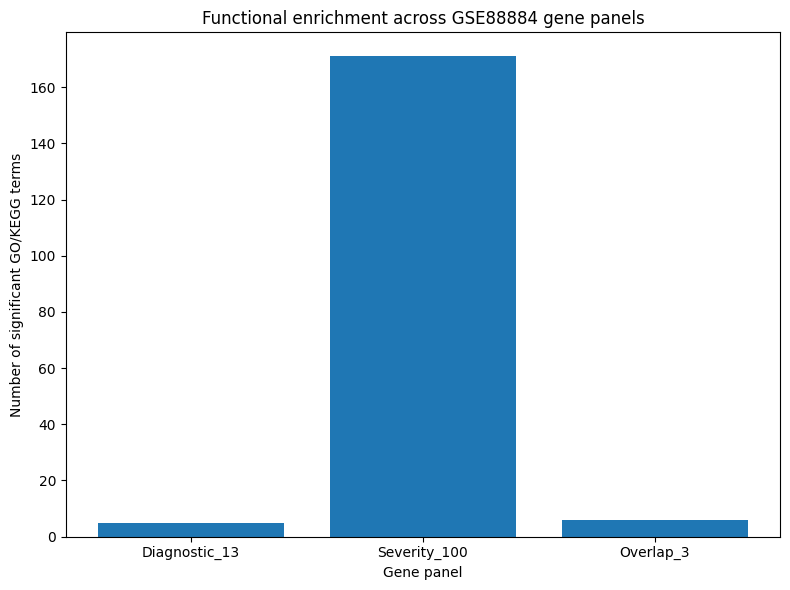

✓ Figure 1: /content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/Integrated_Analysis/Figures/Figure_Functional_Enrichment_Panel_Comparison.png


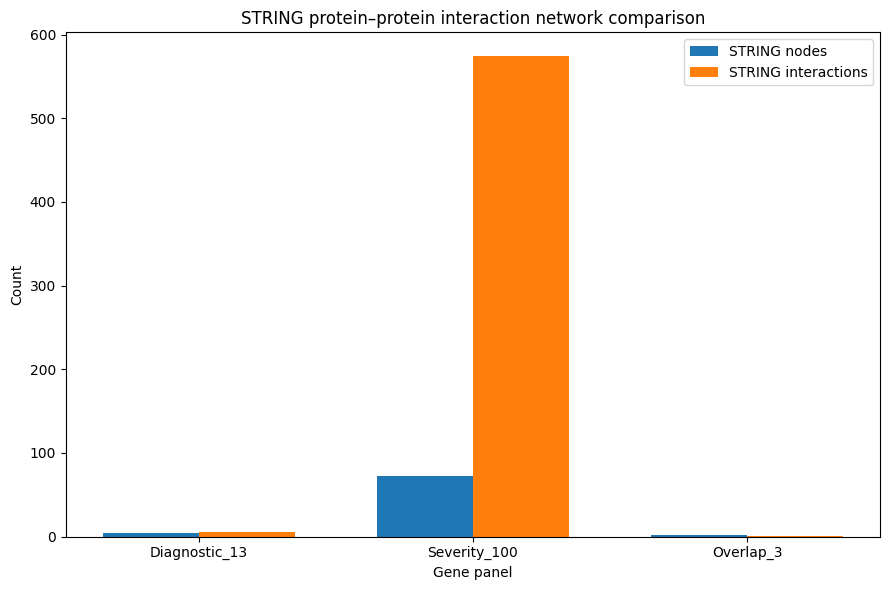

✓ Figure 2: /content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/Integrated_Analysis/Figures/Figure_STRING_PPI_Comparison.png

ALL-THREE SHARED TERMS
Number: 4


,Functional_Source,Functional_Term,Diagnostic_13,Overlap_3,Severity_100,Number_of_Panels
0,GO:BP,"""Any process that results in a change in state...",1.0,1.0,1.0,3.0
1,GO:BP,"""The series of molecular signals initiated by ...",1.0,1.0,1.0,3.0
2,GO:BP,"""The series of molecular signals initiated by ...",1.0,1.0,1.0,3.0
3,GO:BP,"""Any process that results in a change in state...",1.0,1.0,1.0,3.0


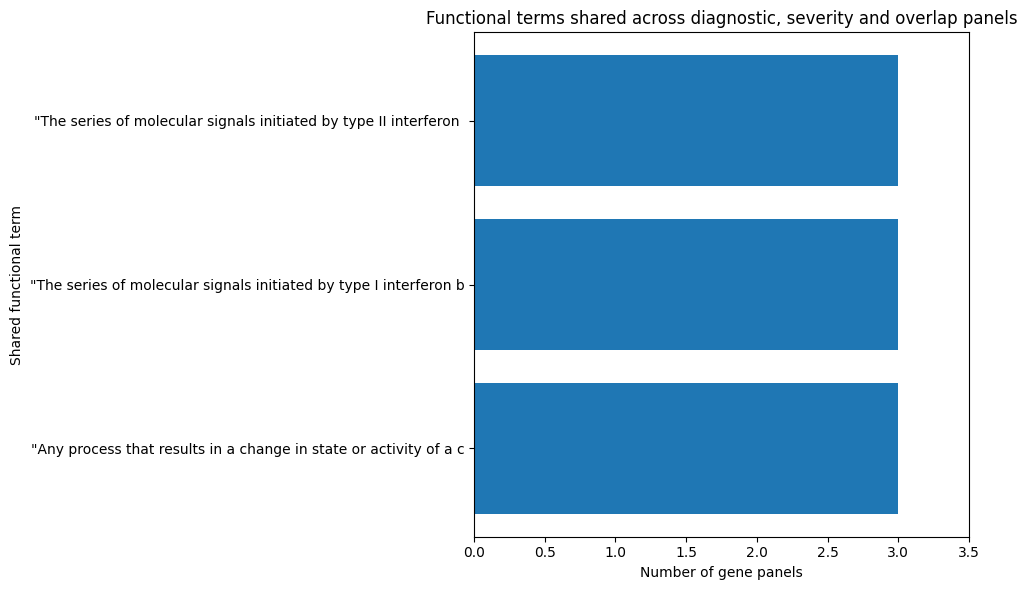

✓ Figure 3: /content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/Integrated_Analysis/Figures/Figure_All_Three_Shared_Functional_Terms.png

✓ Top significant terms saved:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/Integrated_Analysis/GSE88884_top10_significant_terms_per_panel.csv


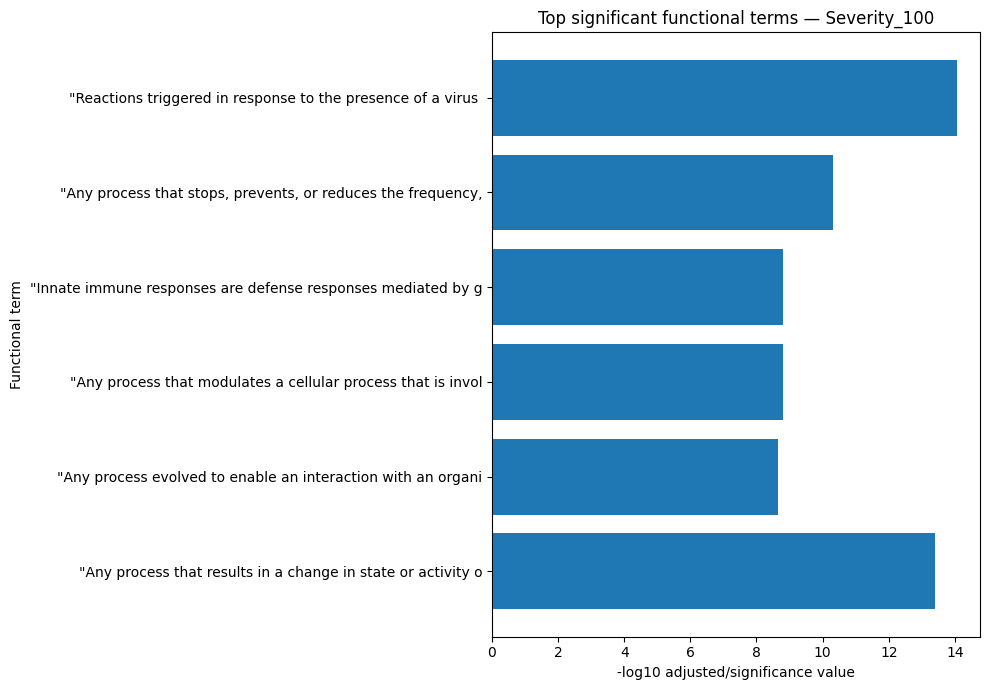

✓ /content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/functional_analysis/Integrated_Analysis/Figures/Figure_Top_Functional_Terms_Severity100.png

✓ Final checkpoint saved:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/checkpoint/GSE88884_final_functional_analysis_checkpoint.pkl

FINAL SAVED RESULTS

Integrated analysis:
 - GSE88884_Diagnostic13_Severity100_shared_terms.csv
 - GSE88884_Diagnostic13_specific_terms.csv
 - GSE88884_FINAL_INTEGRATED_FUNCTIONAL_ANALYSIS.xlsx
 - GSE88884_FINAL_INTEGRATED_GO_KEGG_STRING_SUMMARY.csv
 - GSE88884_GO_KEGG_panel_overlap_matrix.csv
 - GSE88884_GO_KEGG_shared_by_all_three.csv
 - GSE88884_GO_KEGG_terms_shared_by_all_three.csv
 - GSE88884_INTEGRATED_FUNCTIONAL_SUMMARY.csv
 - GSE88884_Overlap3_specific_terms.csv
 - GSE88884_STRING_panel_comparison.png
 - GSE88884_Severity100_specific_terms.csv
 - GSE88884_functional_enrichment_panel_comparison.png
 - GSE88884_integrated_GO_KEGG_all_three_panels.csv
 - GSE

In [47]:
# ============================================================================
# GSE88884 — FINAL FUNCTIONAL ANALYSIS SAVE + PUBLICATION FIGURES
# Diagnostic 13 | Severity 100 | Overlap 3
# ============================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 100)
print("GSE88884 — SAVING FINAL INTEGRATED ANALYSIS + GENERATING FIGURES")
print("=" * 100)

# ============================================================================
# 1. PATHS
# ============================================================================

BASE_DIR = (
    "/content/drive/MyDrive/"
    "SLE_BMC_Bioinformatics/"
    "GSE88884_Severity_Analysis"
)

FUNCTIONAL_DIR = os.path.join(
    BASE_DIR,
    "functional_analysis"
)

INTEGRATED_DIR = os.path.join(
    FUNCTIONAL_DIR,
    "Integrated_Analysis"
)

FIGURE_DIR = os.path.join(
    INTEGRATED_DIR,
    "Figures"
)

CHECKPOINT_DIR = os.path.join(
    BASE_DIR,
    "checkpoint"
)

os.makedirs(
    INTEGRATED_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

print("\nOutput directory:")
print(INTEGRATED_DIR)

# ============================================================================
# 2. LOAD SAVED INTEGRATED RESULTS
# ============================================================================

COMBINED_PATH = os.path.join(
    INTEGRATED_DIR,
    "GSE88884_integrated_GO_KEGG_all_three_panels.csv"
)

SUMMARY_PATH = os.path.join(
    INTEGRATED_DIR,
    "GSE88884_FINAL_INTEGRATED_GO_KEGG_STRING_SUMMARY.csv"
)

TERM_MATRIX_PATH = os.path.join(
    INTEGRATED_DIR,
    "GSE88884_GO_KEGG_panel_overlap_matrix.csv"
)

ALL_THREE_PATH = os.path.join(
    INTEGRATED_DIR,
    "GSE88884_GO_KEGG_shared_by_all_three.csv"
)

# ---------------------------------------------------------------------------
# Verify files
# ---------------------------------------------------------------------------

required_files = [
    COMBINED_PATH,
    SUMMARY_PATH,
    TERM_MATRIX_PATH,
    ALL_THREE_PATH
]

for path in required_files:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"\nRequired result file not found:\n{path}"
        )

    print(
        "✓",
        os.path.basename(path)
    )

# ============================================================================
# 3. LOAD
# ============================================================================

functional_all = pd.read_csv(
    COMBINED_PATH
)

summary = pd.read_csv(
    SUMMARY_PATH
)

term_matrix = pd.read_csv(
    TERM_MATRIX_PATH
)

all_three = pd.read_csv(
    ALL_THREE_PATH
)

print("\nLoaded:")
print(
    "Functional results:",
    functional_all.shape
)

print(
    "Summary:",
    summary.shape
)

print(
    "Term matrix:",
    term_matrix.shape
)

print(
    "All-three shared:",
    all_three.shape
)

# ============================================================================
# 4. SAVE A FINAL MASTER EXCEL FILE
# ============================================================================

MASTER_XLSX = os.path.join(
    INTEGRATED_DIR,
    "GSE88884_FINAL_INTEGRATED_FUNCTIONAL_ANALYSIS.xlsx"
)

with pd.ExcelWriter(
    MASTER_XLSX,
    engine="openpyxl"
) as writer:

    functional_all.to_excel(
        writer,
        sheet_name="All_GO_KEGG",
        index=False
    )

    summary.to_excel(
        writer,
        sheet_name="Final_Summary",
        index=False
    )

    term_matrix.to_excel(
        writer,
        sheet_name="Term_Overlap",
        index=False
    )

    all_three.to_excel(
        writer,
        sheet_name="All_Three_Shared",
        index=False
    )

print(
    "\n✓ Master Excel saved:"
)

print(
    MASTER_XLSX
)

# ============================================================================
# 5. FIGURE 1 — SIGNIFICANT FUNCTIONAL TERMS PER PANEL
# ============================================================================

plot_summary = summary.copy()

panel_order = [
    "Diagnostic_13",
    "Severity_100",
    "Overlap_3"
]

plot_summary["Panel"] = pd.Categorical(
    plot_summary["Panel"],
    categories=panel_order,
    ordered=True
)

plot_summary = plot_summary.sort_values(
    "Panel"
)

plt.figure(
    figsize=(8, 6)
)

plt.bar(
    plot_summary["Panel"].astype(str),
    plot_summary["Significant_GO_KEGG"]
)

plt.xlabel(
    "Gene panel"
)

plt.ylabel(
    "Number of significant GO/KEGG terms"
)

plt.title(
    "Functional enrichment across GSE88884 gene panels"
)

plt.tight_layout()

FIG1 = os.path.join(
    FIGURE_DIR,
    "Figure_Functional_Enrichment_Panel_Comparison.png"
)

plt.savefig(
    FIG1,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ Figure 1:",
    FIG1
)

# ============================================================================
# 6. FIGURE 2 — STRING NETWORK COMPARISON
# ============================================================================

if (
    "Interactions" in summary.columns
    and
    "Nodes" in summary.columns
):

    string_plot = summary.copy()

    string_plot["Panel"] = pd.Categorical(
        string_plot["Panel"],
        categories=panel_order,
        ordered=True
    )

    string_plot = string_plot.sort_values(
        "Panel"
    )

    x = np.arange(
        len(string_plot)
    )

    width = 0.35

    plt.figure(
        figsize=(9, 6)
    )

    plt.bar(
        x - width / 2,
        string_plot["Nodes"],
        width,
        label="STRING nodes"
    )

    plt.bar(
        x + width / 2,
        string_plot["Interactions"],
        width,
        label="STRING interactions"
    )

    plt.xticks(
        x,
        string_plot["Panel"].astype(str)
    )

    plt.xlabel(
        "Gene panel"
    )

    plt.ylabel(
        "Count"
    )

    plt.title(
        "STRING protein–protein interaction network comparison"
    )

    plt.legend()

    plt.tight_layout()

    FIG2 = os.path.join(
        FIGURE_DIR,
        "Figure_STRING_PPI_Comparison.png"
    )

    plt.savefig(
        FIG2,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "✓ Figure 2:",
        FIG2
    )

else:

    print(
        "\nSTRING node/interaction columns unavailable."
    )

# ============================================================================
# 7. IDENTIFY THE FOUR ALL-THREE TERMS
# ============================================================================

# Reconstruct robustly from the term matrix

required_panel_columns = [
    "Diagnostic_13",
    "Severity_100",
    "Overlap_3"
]

for col in required_panel_columns:

    if col not in term_matrix.columns:

        raise KeyError(
            f"Missing column: {col}"
        )

all_three_terms = term_matrix[
    (
        term_matrix["Diagnostic_13"] == 1
    )
    &
    (
        term_matrix["Severity_100"] == 1
    )
    &
    (
        term_matrix["Overlap_3"] == 1
    )
].copy()

print("\n" + "=" * 100)
print("ALL-THREE SHARED TERMS")
print("=" * 100)

print(
    "Number:",
    len(all_three_terms)
)

display(
    all_three_terms
)

# ============================================================================
# 8. FIGURE 3 — ALL THREE SHARED FUNCTIONAL TERMS
# ============================================================================

if not all_three_terms.empty:

    # Shorten very long descriptions for plotting

    shared_plot = all_three_terms.copy()

    shared_plot["Short_Term"] = (
        shared_plot["Functional_Term"]
        .astype(str)
        .str.replace(
            r"^.*?GO:",
            "GO:",
            regex=True
        )
        .str.slice(
            0,
            65
        )
    )

    # Reverse so the first term appears at top

    shared_plot = shared_plot.iloc[
        ::-1
    ]

    plt.figure(
        figsize=(10, 6)
    )

    plt.barh(
        shared_plot["Short_Term"],
        shared_plot["Number_of_Panels"]
    )

    plt.xlabel(
        "Number of gene panels"
    )

    plt.ylabel(
        "Shared functional term"
    )

    plt.title(
        "Functional terms shared across diagnostic, severity and overlap panels"
    )

    plt.xlim(
        0,
        3.5
    )

    plt.tight_layout()

    FIG3 = os.path.join(
        FIGURE_DIR,
        "Figure_All_Three_Shared_Functional_Terms.png"
    )

    plt.savefig(
        FIG3,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "✓ Figure 3:",
        FIG3
    )

# ============================================================================
# 9. FIGURE 4 — TOP SIGNIFICANT TERMS BY PANEL
# ============================================================================

# Use the actual GO/KEGG table and filter significance.

sig = functional_all.copy()

if "BH_FDR" in sig.columns:

    sig["BH_FDR"] = pd.to_numeric(
        sig["BH_FDR"],
        errors="coerce"
    )

    sig = sig[
        sig["BH_FDR"] < 0.05
    ].copy()

elif "p_value" in sig.columns:

    sig["p_value"] = pd.to_numeric(
        sig["p_value"],
        errors="coerce"
    )

    sig = sig[
        sig["p_value"] < 0.05
    ].copy()

else:

    sig = sig[
        sig["significant"] == True
    ].copy()

# Take strongest 10 terms per panel

top_terms = []

for panel in panel_order:

    temp = sig[
        sig["Panel"] == panel
    ].copy()

    if "BH_FDR" in temp.columns:

        temp = temp.sort_values(
            "BH_FDR",
            ascending=True
        )

    else:

        temp = temp.sort_values(
            "p_value",
            ascending=True
        )

    temp = temp.head(
        10
    )

    top_terms.append(
        temp
    )

top_terms = pd.concat(
    top_terms,
    ignore_index=True
)

# Save

TOP_TERMS_PATH = os.path.join(
    INTEGRATED_DIR,
    "GSE88884_top10_significant_terms_per_panel.csv"
)

top_terms.to_csv(
    TOP_TERMS_PATH,
    index=False
)

print(
    "\n✓ Top significant terms saved:"
)

print(
    TOP_TERMS_PATH
)

# ============================================================================
# 10. FIGURE 5 — TOP FUNCTIONAL TERMS
# ============================================================================

for panel in panel_order:

    temp = top_terms[
        top_terms["Panel"] == panel
    ].copy()

    if temp.empty:

        continue

    # Determine significance metric

    if (
        "BH_FDR" in temp.columns
        and
        temp["BH_FDR"].notna().any()
    ):

        temp["neglog10"] = -np.log10(
            np.maximum(
                temp["BH_FDR"].astype(float),
                1e-300
            )
        )

    else:

        temp["neglog10"] = -np.log10(
            np.maximum(
                temp["p_value"].astype(float),
                1e-300
            )
        )

    temp = temp.sort_values(
        "neglog10"
    )

    labels = (
        temp["description"]
        .astype(str)
        .str.slice(
            0,
            60
        )
    )

    plt.figure(
        figsize=(10, 7)
    )

    plt.barh(
        labels,
        temp["neglog10"]
    )

    plt.xlabel(
        "-log10 adjusted/significance value"
    )

    plt.ylabel(
        "Functional term"
    )

    plt.title(
        f"Top significant functional terms — {panel}"
    )

    plt.tight_layout()

    safe_panel = panel.replace(
        "_",
        ""
    )

    FIG_PATH = os.path.join(
        FIGURE_DIR,
        f"Figure_Top_Functional_Terms_{safe_panel}.png"
    )

    plt.savefig(
        FIG_PATH,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "✓",
        FIG_PATH
    )

# ============================================================================
# 11. SAVE A COMPLETE CHECKPOINT
# ============================================================================

CHECKPOINT = {
    "dataset": "GSE88884",

    "diagnostic_panel": 13,

    "severity_panel": 100,

    "overlap_panel": [
        "IFI27",
        "EPSTI1",
        "ZBP1"
    ],

    "functional_analysis": [
        "GO",
        "KEGG"
    ],

    "string_analysis": True,

    "integrated_functional_results":
        COMBINED_PATH,

    "integrated_summary":
        SUMMARY_PATH,

    "term_overlap_matrix":
        TERM_MATRIX_PATH,

    "all_three_shared_terms":
        ALL_THREE_PATH,

    "master_excel":
        MASTER_XLSX,

    "figure_directory":
        FIGURE_DIR,

    "all_three_shared_count":
        len(all_three_terms)
}

import pickle

CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "GSE88884_final_functional_analysis_checkpoint.pkl"
)

with open(
    CHECKPOINT_PATH,
    "wb"
) as f:

    pickle.dump(
        CHECKPOINT,
        f
    )

print(
    "\n✓ Final checkpoint saved:"
)

print(
    CHECKPOINT_PATH
)

# ============================================================================
# 12. FINAL FILE LIST
# ============================================================================

print("\n" + "=" * 100)
print("FINAL SAVED RESULTS")
print("=" * 100)

print(
    "\nIntegrated analysis:"
)

for file in sorted(
    os.listdir(
        INTEGRATED_DIR
    )
):

    path = os.path.join(
        INTEGRATED_DIR,
        file
    )

    if os.path.isfile(path):

        print(
            " -",
            file
        )

print(
    "\nFigures:"
)

for file in sorted(
    os.listdir(
        FIGURE_DIR
    )
):

    print(
        " -",
        file
    )

print("\n" + "=" * 100)
print("✓ ANALYSIS SAVED")
print("✓ FIGURES GENERATED")
print("✓ CHECKPOINT CREATED")
print("=" * 100)

In [51]:
# Find likely GSE88884-related objects already loaded in the notebook

print("=" * 100)
print("AVAILABLE GSE88884-RELATED OBJECTS")
print("=" * 100)

for name, obj in globals().items():
    if "88884" in name.upper():
        try:
            print(f"{name:40s} | type={type(obj).__name__} | shape={getattr(obj, 'shape', 'N/A')}")
        except Exception:
            print(f"{name:40s} | type={type(obj).__name__}")

AVAILABLE GSE88884-RELATED OBJECTS
gse88884                                 | type=GSE | shape=N/A
X_gse88884_processed                     | type=DataFrame | shape=(92343, 1820)


In [52]:
# ============================================================================
# GSE88884 — CHECK PROCESSED MATRIX + GEO PLATFORM ANNOTATION
# ============================================================================

print("=" * 100)
print("GSE88884 — DATA STRUCTURE CHECK")
print("=" * 100)

print("\nProcessed expression:")
print("Shape:", X_gse88884_processed.shape)
print("Index examples:", X_gse88884_processed.index[:10].tolist())

print("\nGSE object:")
print(type(gse88884).__name__)

print("\nGSE platforms:")
print(gse88884.gpls.keys())

GSE88884 — DATA STRUCTURE CHECK

Processed expression:
Shape: (92343, 1820)
Index examples: ['PSR06024778.hg.1:1', 'TC01000774.hg.1:1', 'TC01001237.hg.1:1', 'TC01001423.hg.1:1', 'TC01001423.hg.1:2', 'TC01001423.hg.1:3', 'TC01001423.hg.1:4', 'TC01001423.hg.1:5', 'TC01001805.hg.1:1', 'TC01001805.hg.1:2']

GSE object:
GSE

GSE platforms:
dict_keys(['GPL17586'])


In [53]:
# ============================================================================
# GSE88884 / GPL17586 — INSPECT PLATFORM ANNOTATION
# ============================================================================

print("=" * 100)
print("GPL17586 ANNOTATION INSPECTION")
print("=" * 100)

gpl = gse88884.gpls["GPL17586"]

print("\nGPL object:")
print(type(gpl).__name__)

print("\nGPL metadata keys:")
print(gpl.metadata.keys())

print("\nGPL table shape:")
print(gpl.table.shape)

print("\nGPL table columns:")
print(gpl.table.columns.tolist())

print("\nFirst 5 annotation rows:")
print(gpl.table.head())

GPL17586 ANNOTATION INSPECTION

GPL object:
GPL

GPL metadata keys:
dict_keys(['title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'technology', 'distribution', 'organism', 'taxid', 'manufacturer', 'manufacture_protocol', 'description', 'contact_name', 'contact_email', 'contact_phone', 'contact_institute', 'contact_address', 'contact_city', 'contact_state', 'contact_zip/postal_code', 'contact_country', 'contact_web_link', 'relation', 'data_row_count'])

GPL table shape:
(70753, 15)

GPL table columns:
['ID', 'probeset_id', 'seqname', 'strand', 'start', 'stop', 'total_probes', 'gene_assignment', 'mrna_assignment', 'swissprot', 'unigene', 'category', 'locus type', 'notes', 'SPOT_ID']

First 5 annotation rows:
                ID      probeset_id seqname strand   start    stop  \
0  TC01000001.hg.1  TC01000001.hg.1    chr1      +   11869   14409   
1  TC01000002.hg.1  TC01000002.hg.1    chr1      +   29554   31109   
2  TC01000003.hg.1  TC01000003.hg.1    chr1      +

In [55]:
# ============================================================================
# GSE88884 — CHECK FEATURE-ID FORMAT FOR TARGET GENES
# ============================================================================

TARGET_GENES = ["IFI27", "EPSTI1", "ZBP1"]

gpl_table = gse88884.gpls["GPL17586"].table.copy()

# Find target gene annotations
target_rows = gpl_table[
    gpl_table["gene_assignment"]
    .astype(str)
    .str.contains(
        r"//\s*(IFI27|EPSTI1|ZBP1)\s*//",
        case=False,
        regex=True,
        na=False
    )
].copy()

print("=" * 100)
print("TARGET GENE ANNOTATION IDs")
print("=" * 100)

print(
    target_rows[
        ["ID", "probeset_id", "gene_assignment"]
    ].to_string(index=False)
)

print("\n" + "=" * 100)
print("EXPRESSION INDEX MATCHING")
print("=" * 100)

for _, row in target_rows.iterrows():

    annotation_id = str(row["ID"]).strip()

    matches = [
        idx
        for idx in X_gse88884_processed.index.astype(str)
        if idx.startswith(annotation_id + ":")
    ]

    print("\nGene annotation ID:", annotation_id)
    print("Matching expression features:", len(matches))

    if matches:
        print("Examples:", matches[:10])

/tmp/ipykernel_29528/2228102785.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(


TARGET GENE ANNOTATION IDs
             ID     probeset_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [56]:
# ============================================================================
# GSE88884 — FINAL 3-GENE EXTRACTION
# GPL17586: BASE PROBE ID → SUFFIXED EXPRESSION FEATURES
# Genes: IFI27 | EPSTI1 | ZBP1
# ============================================================================

import os
import pandas as pd
import numpy as np

TARGET_GENES = ["IFI27", "EPSTI1", "ZBP1"]

print("=" * 100)
print("GSE88884 — FINAL 3-GENE EXPRESSION EXTRACTION")
print("=" * 100)

# ============================================================================
# 1. LOAD EXISTING OBJECTS
# ============================================================================

expr = X_gse88884_processed.copy()

gpl_table = (
    gse88884
    .gpls["GPL17586"]
    .table
    .copy()
)

expr.index = (
    expr.index
    .astype(str)
    .str.strip()
)

gpl_table["ID"] = (
    gpl_table["ID"]
    .astype(str)
    .str.strip()
)

print("\nFull expression matrix:", expr.shape)
print("GPL annotation:", gpl_table.shape)


# ============================================================================
# 2. IDENTIFY TARGET GENES FROM gene_assignment
# ============================================================================

target_rows = []

for gene in TARGET_GENES:

    mask = (
        gpl_table["gene_assignment"]
        .astype(str)
        .str.contains(
            rf"//\s*{gene}\s*//",
            case=False,
            regex=True,
            na=False
        )
    )

    rows = gpl_table.loc[
        mask,
        ["ID", "gene_assignment"]
    ].copy()

    rows["Gene"] = gene

    target_rows.append(rows)


target_annotation = pd.concat(
    target_rows,
    ignore_index=True
)

print("\nTarget annotation:")
print(
    target_annotation[
        ["Gene", "ID"]
    ].to_string(index=False)
)


# ============================================================================
# 3. MAP BASE GPL IDs → SUFFIXED EXPRESSION FEATURES
# ============================================================================

matched_rows = []

expr_ids = expr.index.astype(str)

for _, row in target_annotation.iterrows():

    gene = row["Gene"]
    base_id = str(row["ID"]).strip()

    # Match:
    # TC14000584.hg.1
    # TC14000584.hg.1:1
    # TC14000584.hg.1:2
    # etc.

    matching_ids = [
        idx
        for idx in expr_ids
        if idx == base_id
        or idx.startswith(base_id + ":")
    ]

    for feature_id in matching_ids:

        matched_rows.append(
            {
                "Gene": gene,
                "GPL_ID": base_id,
                "Expression_ID": feature_id
            }
        )


feature_mapping = pd.DataFrame(
    matched_rows
)


# ============================================================================
# 4. DISPLAY MATCHING
# ============================================================================

print("\n" + "=" * 100)
print("FEATURE MAPPING")
print("=" * 100)

print(
    feature_mapping.to_string(index=False)
)

print("\nFeatures per gene:")

print(
    feature_mapping["Gene"]
    .value_counts()
    .reindex(TARGET_GENES)
)


# ============================================================================
# 5. CHECK ALL THREE GENES
# ============================================================================

missing_genes = [
    gene
    for gene in TARGET_GENES
    if gene not in set(feature_mapping["Gene"])
]

if missing_genes:

    raise ValueError(
        "No expression features found for: "
        + ", ".join(missing_genes)
    )


# ============================================================================
# 6. EXTRACT EXPRESSION FEATURES
# ============================================================================

target_expression_ids = (
    feature_mapping["Expression_ID"]
    .drop_duplicates()
    .tolist()
)

expr_target = expr.loc[
    target_expression_ids
].copy()

print("\nTarget feature-level matrix:")
print(expr_target.shape)


# ============================================================================
# 7. CREATE FEATURE → GENE MAP
# ============================================================================

feature_to_gene = (
    feature_mapping
    .drop_duplicates(
        subset=["Expression_ID"]
    )
    .set_index("Expression_ID")["Gene"]
)


expr_target["__GENE__"] = (
    expr_target.index.map(
        feature_to_gene
    )
)


# ============================================================================
# 8. AGGREGATE FEATURES WITHIN EACH GENE
# ============================================================================

# If a gene has multiple suffixed features,
# use the median across those features.

X_GSE88884_3GENE = (
    expr_target
    .groupby("__GENE__")
    .median()
    .T
)


# ============================================================================
# 9. FORCE EXACT GENE ORDER
# ============================================================================

X_GSE88884_3GENE = (
    X_GSE88884_3GENE
    .reindex(
        columns=TARGET_GENES
    )
)


# ============================================================================
# 10. FINAL VALIDATION
# ============================================================================

print("\n" + "=" * 100)
print("FINAL GSE88884 3-GENE MATRIX")
print("=" * 100)

print("\nShape:")
print(
    X_GSE88884_3GENE.shape
)

print("\nGenes:")
print(
    X_GSE88884_3GENE.columns.tolist()
)

print("\nMissing values:")
print(
    X_GSE88884_3GENE.isna().sum()
)

print("\nSummary:")
print(
    X_GSE88884_3GENE
    .describe()
    .round(4)
)


# ============================================================================
# 11. HARD CHECKS
# ============================================================================

assert (
    X_GSE88884_3GENE.columns.tolist()
    == TARGET_GENES
)

assert (
    X_GSE88884_3GENE.shape[1]
    == 3
)

if X_GSE88884_3GENE.isna().any().any():

    raise ValueError(
        "Missing values detected in final 3-gene matrix."
    )


# ============================================================================
# 12. SAVE CHECKPOINT
# ============================================================================

if "CHECKPOINT_DIR" in globals():

    output_path = os.path.join(
        CHECKPOINT_DIR,
        "GSE88884_3gene_expression.csv"
    )

    X_GSE88884_3GENE.to_csv(
        output_path
    )

    print("\nSaved:")
    print(output_path)


# ============================================================================
# FINAL CHECKPOINT
# ============================================================================

print("\n" + "=" * 100)
print("✓ X_GSE88884_3GENE CREATED SUCCESSFULLY")
print("=" * 100)

print(
    "\nFinal shape:",
    X_GSE88884_3GENE.shape
)

print(
    "Final genes:",
    X_GSE88884_3GENE.columns.tolist()
)

GSE88884 — FINAL 3-GENE EXPRESSION EXTRACTION

Full expression matrix: (92343, 1820)
GPL annotation: (70753, 15)

Target annotation:
  Gene              ID
 IFI27 TC14000584.hg.1
EPSTI1 TC13000612.hg.1
  ZBP1 TC20000979.hg.1

FEATURE MAPPING
  Gene          GPL_ID     Expression_ID
 IFI27 TC14000584.hg.1 TC14000584.hg.1:1
 IFI27 TC14000584.hg.1 TC14000584.hg.1:2
EPSTI1 TC13000612.hg.1 TC13000612.hg.1:1
  ZBP1 TC20000979.hg.1 TC20000979.hg.1:1
  ZBP1 TC20000979.hg.1 TC20000979.hg.1:2
  ZBP1 TC20000979.hg.1 TC20000979.hg.1:3

Features per gene:
Gene
IFI27     2
EPSTI1    1
ZBP1      3
Name: count, dtype: int64

Target feature-level matrix:
(6, 1820)

FINAL GSE88884 3-GENE MATRIX

Shape:
(1820, 3)

Genes:
['IFI27', 'EPSTI1', 'ZBP1']

Missing values:
__GENE__
IFI27     0
EPSTI1    0
ZBP1      0
dtype: int64

Summary:
__GENE__      IFI27     EPSTI1       ZBP1
count     1820.0000  1820.0000  1820.0000
mean         7.5840     8.8495     7.5036
std          1.1872     1.1485     0.5850
min    

GSE88884 — 3-GENE STATISTICAL ANALYSIS

Genes:
['IFI27', 'EPSTI1', 'ZBP1']

Expression matrix:
(1820, 3)
✓ 3 genes confirmed
✓ Gene order confirmed

Phenotype:
(1756, 8)

Phenotype columns:
['sample_id', 'subject_id', 'time', 'group', 'SLEDAI', 'severity_category', 'severity_binary', 'severity_binary_label']

SAMPLE-ID ALIGNMENT
Expression IDs: ['A52084400940545091515421247226830.CEL', 'A52084400940545091515421247226831.CEL', 'A52084400940545091515421247226832.CEL', 'A52084400940545091515421247226833.CEL', 'A52084400940545091515421247226834.CEL']

Phenotype IDs: ['GSM2350933', 'GSM2350934', 'GSM2350935', 'GSM2350936', 'GSM2350937']

✓ Existing cel_to_gsm mapping found

CEL files mapped to GSM: 1820 / 1820

Mapped expression samples: 1820
Phenotype samples: 1756
Common samples: 1756

Final aligned expression: (1756, 3)
Final aligned phenotype: (1756, 7)

FINAL ANALYSIS DATASET
Samples: 1756
Genes: ['IFI27', 'EPSTI1', 'ZBP1']

Severity distribution:
severity_category
Low         700
Mode

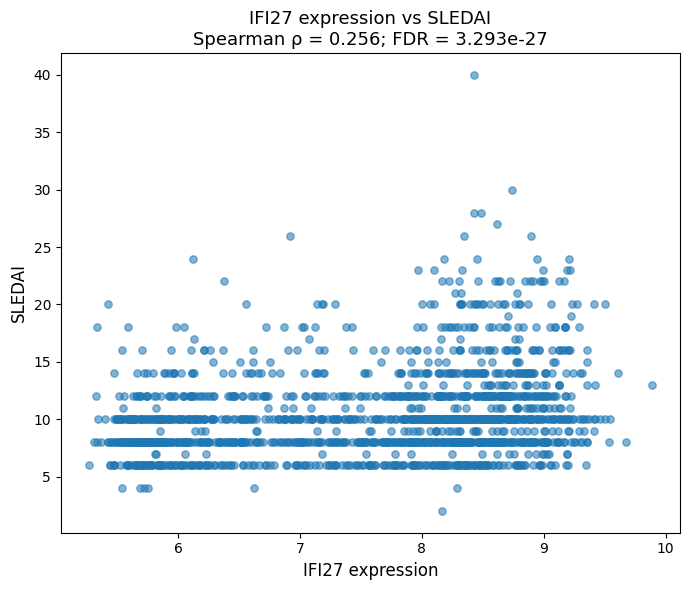

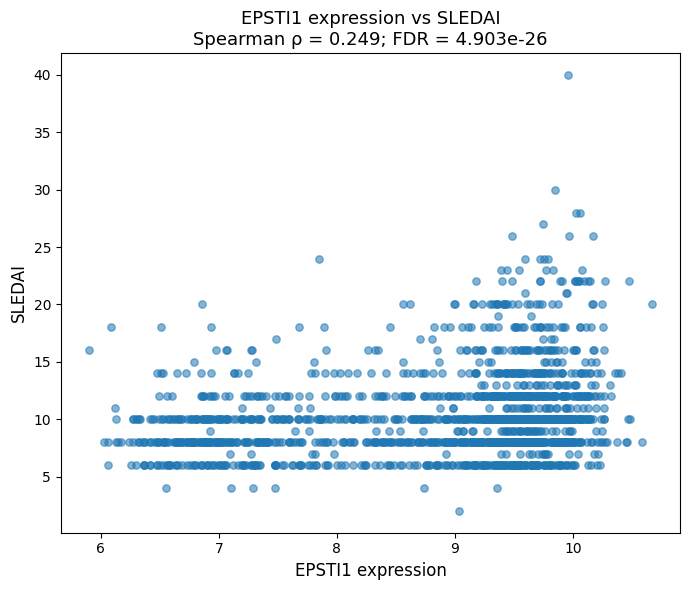

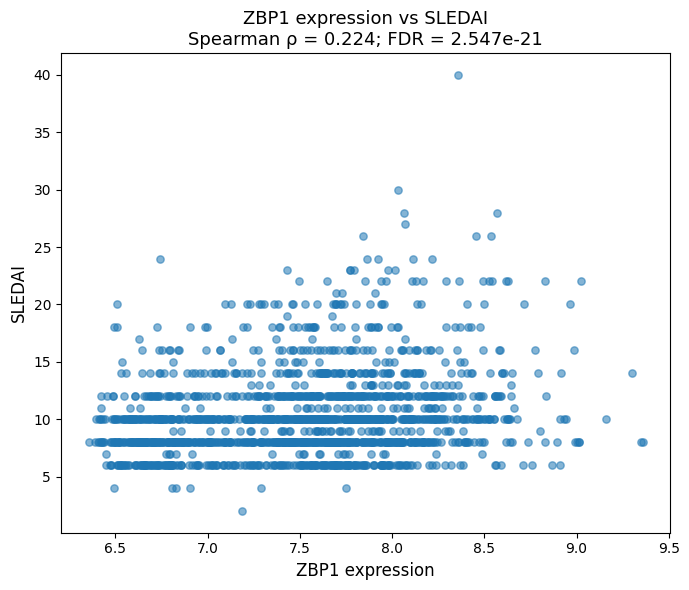

/tmp/ipykernel_29528/305117619.py:818: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


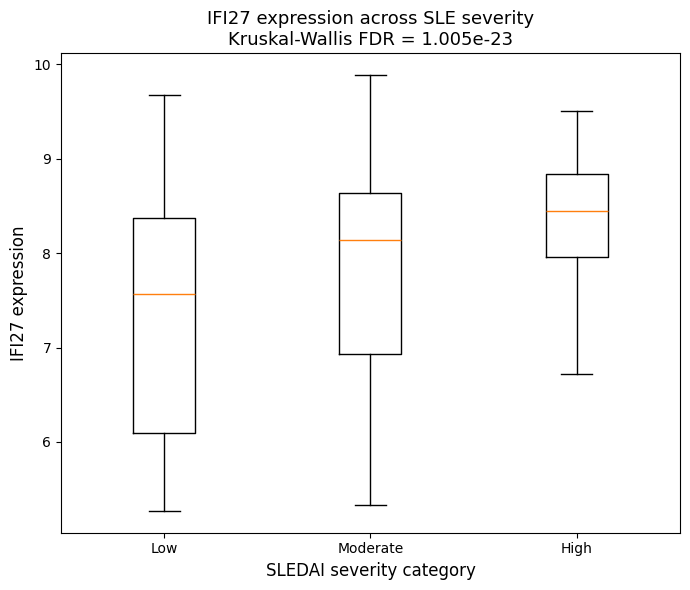

/tmp/ipykernel_29528/305117619.py:818: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


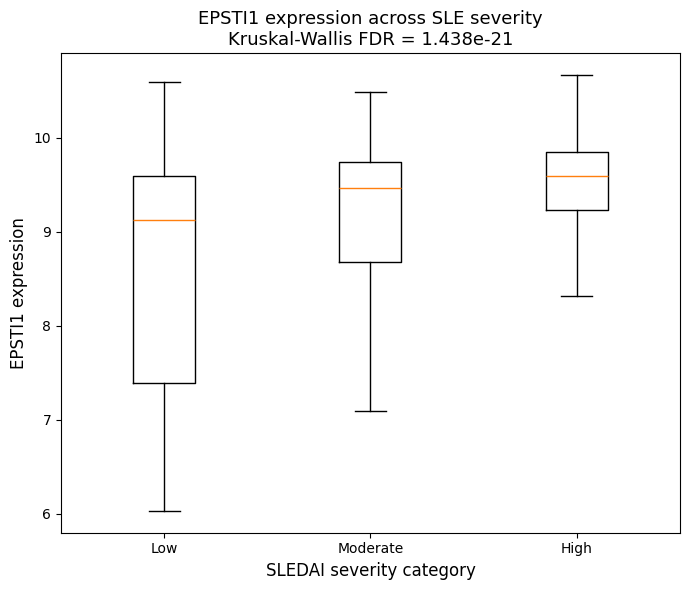

/tmp/ipykernel_29528/305117619.py:818: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


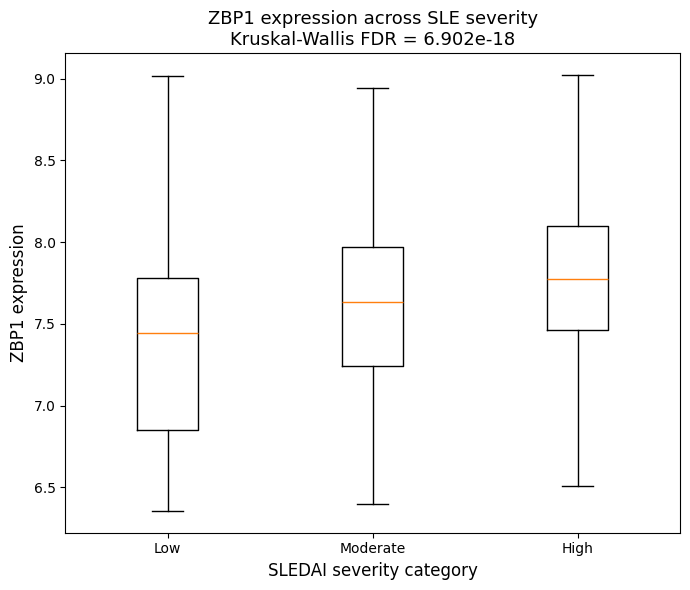


3-GENE STATISTICAL ANALYSIS COMPLETE

Final samples: 1756
Final genes: IFI27, EPSTI1, ZBP1

Analyses:
✓ Spearman correlation with SLEDAI
✓ Mann-Whitney U: High vs Low-to-Moderate
✓ Kruskal-Wallis: Low vs Moderate vs High
✓ Benjamini-Hochberg FDR correction
✓ Rank-biserial effect size
✓ SLEDAI association figures
✓ Severity distribution figures

Results directory:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/3Gene_Statistical_Analysis

Figures directory:
/content/drive/MyDrive/SLE_BMC_Bioinformatics/GSE88884_Severity_Analysis/3Gene_Statistical_Analysis/Figures

✓ FINAL 3-GENE STATISTICAL ANALYSIS SAVED


In [57]:
# ============================================================================
# GSE88884 — STATISTICAL ANALYSIS OF THE 3 OVERLAP GENES
# IFI27 | EPSTI1 | ZBP1
#
# Analyses:
#   1. Spearman correlation with continuous SLEDAI
#   2. Mann-Whitney U: High vs Low-to-Moderate
#   3. Kruskal-Wallis: Low vs Moderate vs High
#   4. Benjamini-Hochberg FDR correction
#   5. Effect sizes
#   6. Publication-ready figures
#
# IMPORTANT:
#   This is a severity/association analysis.
#   It does NOT use the 13-gene diagnostic XGBoost threshold.
# ============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    spearmanr,
    mannwhitneyu,
    kruskal
)

from statsmodels.stats.multitest import multipletests


# ============================================================================
# 1. LOCKED GENES
# ============================================================================

LOCKED_GENES = [
    "IFI27",
    "EPSTI1",
    "ZBP1"
]

print("=" * 100)
print("GSE88884 — 3-GENE STATISTICAL ANALYSIS")
print("=" * 100)

print("\nGenes:")
print(LOCKED_GENES)


# ============================================================================
# 2. USE THE CORRECTLY AGGREGATED EXPRESSION MATRIX
# ============================================================================

if "X_GSE88884_3GENE" not in globals():

    raise NameError(
        "X_GSE88884_3GENE is not available.\n"
        "Run the corrected probe extraction + probe-to-gene aggregation first."
    )

X_expr = X_GSE88884_3GENE.copy()

print("\nExpression matrix:")
print(X_expr.shape)

assert X_expr.shape[1] == 3
assert X_expr.columns.tolist() == LOCKED_GENES

print("✓ 3 genes confirmed")
print("✓ Gene order confirmed")


# ============================================================================
# 3. LOAD PHENOTYPE
# ============================================================================

PHENOTYPE_PATH = os.path.join(
    CHECKPOINT_DIR,
    "GSE88884_severity_phenotype.csv"
)

if not os.path.exists(PHENOTYPE_PATH):

    raise FileNotFoundError(
        f"Phenotype file not found:\n{PHENOTYPE_PATH}"
    )

phenotype = pd.read_csv(
    PHENOTYPE_PATH
)

print("\nPhenotype:")
print(phenotype.shape)

print("\nPhenotype columns:")
print(phenotype.columns.tolist())


# ============================================================================
# 4. IDENTIFY SAMPLE-ID COLUMNS
# ============================================================================

PHENO_ID_COL = "sample_id"

if PHENO_ID_COL not in phenotype.columns:

    raise KeyError(
        f"'{PHENO_ID_COL}' not found in phenotype."
    )


# ============================================================================
# 5. CHECK WHETHER CEL → GSM MAPPING EXISTS
# ============================================================================

print("\n" + "=" * 100)
print("SAMPLE-ID ALIGNMENT")
print("=" * 100)

print(
    "Expression IDs:",
    X_expr.index[:5].tolist()
)

print(
    "\nPhenotype IDs:",
    phenotype[PHENO_ID_COL].head().tolist()
)


# ============================================================================
# 6. CREATE CEL → GSM MAPPING
# ============================================================================

# Prefer an existing mapping if it already exists in the notebook.

if "cel_to_gsm" in globals():

    print("\n✓ Existing cel_to_gsm mapping found")

    CEL_TO_GSM = dict(
        cel_to_gsm
    )

elif "gsm_to_cel" in globals():

    print("\n✓ Existing gsm_to_cel mapping found")

    CEL_TO_GSM = {
        str(cel): str(gsm)
        for gsm, cel in gsm_to_cel.items()
    }

else:

    raise NameError(
        "\nNo CEL → GSM mapping was found.\n\n"
        "The expression matrix uses CEL filenames while the phenotype "
        "uses GSM identifiers.\n"
        "Use the notebook's existing GEO metadata mapping before continuing."
    )


# ============================================================================
# 7. MAP EXPRESSION CEL IDs → GSM IDs
# ============================================================================

X_expr.index = (
    X_expr.index
    .astype(str)
    .str.strip()
)

mapped_gsm = []

for cel in X_expr.index:

    cel_clean = str(cel).strip()

    gsm = CEL_TO_GSM.get(
        cel_clean
    )

    # Try removing .CEL if necessary
    if gsm is None:

        gsm = CEL_TO_GSM.get(
            cel_clean.replace(
                ".CEL",
                ""
            )
        )

    mapped_gsm.append(
        gsm
    )


X_expr["__GSM_ID__"] = mapped_gsm

mapped_count = (
    X_expr["__GSM_ID__"]
    .notna()
    .sum()
)

print(
    "\nCEL files mapped to GSM:",
    mapped_count,
    "/",
    len(X_expr)
)


# ============================================================================
# 8. REMOVE UNMAPPED SAMPLES
# ============================================================================

X_expr = X_expr[
    X_expr["__GSM_ID__"].notna()
].copy()

X_expr = X_expr.set_index(
    "__GSM_ID__"
)

X_expr.index.name = "sample_id"


# ============================================================================
# 9. ALIGN WITH PHENOTYPE
# ============================================================================

phenotype[PHENO_ID_COL] = (
    phenotype[PHENO_ID_COL]
    .astype(str)
    .str.strip()
)

common_samples = (
    X_expr.index
    .intersection(
        phenotype[PHENO_ID_COL]
    )
)

print(
    "\nMapped expression samples:",
    len(X_expr)
)

print(
    "Phenotype samples:",
    len(phenotype)
)

print(
    "Common samples:",
    len(common_samples)
)

if len(common_samples) == 0:

    raise ValueError(
        "Still no common GSM IDs after CEL → GSM mapping."
    )


# ============================================================================
# 10. FINAL SAMPLE ALIGNMENT
# ============================================================================

X_final = X_expr.loc[
    common_samples,
    LOCKED_GENES
].copy()

pheno_final = (
    phenotype
    .set_index(
        PHENO_ID_COL
    )
    .loc[
        common_samples
    ]
    .copy()
)

print(
    "\nFinal aligned expression:",
    X_final.shape
)

print(
    "Final aligned phenotype:",
    pheno_final.shape
)

assert X_final.columns.tolist() == LOCKED_GENES


# ============================================================================
# 11. VERIFY PHENOTYPE
# ============================================================================

if "SLEDAI" not in pheno_final.columns:

    raise KeyError(
        "SLEDAI column not found."
    )

pheno_final["SLEDAI"] = pd.to_numeric(
    pheno_final["SLEDAI"],
    errors="coerce"
)


# ============================================================================
# 12. VERIFY / CREATE SEVERITY CATEGORIES
# ============================================================================

if "severity_category" not in pheno_final.columns:

    pheno_final["severity_category"] = (
        pheno_final["SLEDAI"]
        .apply(
            lambda x:
                "Low"
                if x <= 8
                else (
                    "Moderate"
                    if x <= 15
                    else "High"
                )
        )
    )

if "severity_binary" not in pheno_final.columns:

    pheno_final["severity_binary"] = (
        pheno_final["SLEDAI"] > 15
    ).astype(int)

if "severity_binary_label" not in pheno_final.columns:

    pheno_final[
        "severity_binary_label"
    ] = (
        pheno_final[
            "severity_binary"
        ]
        .map(
            {
                0: "Low-to-Moderate",
                1: "High"
            }
        )
    )


# ============================================================================
# 13. FINAL ANALYSIS DATASET
# ============================================================================

analysis_df = pd.concat(
    [
        X_final,
        pheno_final[
            [
                "SLEDAI",
                "severity_category",
                "severity_binary",
                "severity_binary_label"
            ]
        ]
    ],
    axis=1
)

analysis_df = analysis_df.dropna(
    subset=[
        "IFI27",
        "EPSTI1",
        "ZBP1",
        "SLEDAI"
    ]
)

print("\n" + "=" * 100)
print("FINAL ANALYSIS DATASET")
print("=" * 100)

print(
    "Samples:",
    len(analysis_df)
)

print(
    "Genes:",
    LOCKED_GENES
)

print(
    "\nSeverity distribution:"
)

print(
    analysis_df[
        "severity_category"
    ].value_counts()
    .reindex(
        [
            "Low",
            "Moderate",
            "High"
        ]
    )
)


# ============================================================================
# 14. SPEARMAN CORRELATION WITH SLEDAI
# ============================================================================

print("\n" + "=" * 100)
print("1. SPEARMAN CORRELATION WITH SLEDAI")
print("=" * 100)

spearman_rows = []

for gene in LOCKED_GENES:

    rho, p = spearmanr(
        analysis_df[gene],
        analysis_df["SLEDAI"]
    )

    spearman_rows.append(
        {
            "Gene": gene,
            "N": len(analysis_df),
            "Spearman_rho": rho,
            "P_value": p
        }
    )

spearman_results = pd.DataFrame(
    spearman_rows
)

spearman_results["FDR"] = multipletests(
    spearman_results["P_value"],
    method="fdr_bh"
)[1]

print(
    spearman_results.round(5).to_string(
        index=False
    )
)


# ============================================================================
# 15. HIGH VS LOW-TO-MODERATE
# ============================================================================

print("\n" + "=" * 100)
print("2. HIGH VS LOW-TO-MODERATE")
print("=" * 100)

binary_rows = []

for gene in LOCKED_GENES:

    high = analysis_df.loc[
        analysis_df["severity_binary"] == 1,
        gene
    ].dropna()

    low_mod = analysis_df.loc[
        analysis_df["severity_binary"] == 0,
        gene
    ].dropna()

    U, p = mannwhitneyu(
        high,
        low_mod,
        alternative="two-sided"
    )

    n_high = len(high)
    n_low = len(low_mod)

    # Rank-biserial correlation
    rank_biserial = (
        1
        -
        (
            2 * U
            /
            (n_high * n_low)
        )
    )

    binary_rows.append(
        {
            "Gene": gene,
            "High_N": n_high,
            "LowModerate_N": n_low,
            "High_Median": high.median(),
            "LowModerate_Median": low_mod.median(),
            "MannWhitney_U": U,
            "P_value": p,
            "Rank_biserial": rank_biserial
        }
    )

binary_results = pd.DataFrame(
    binary_rows
)

binary_results["FDR"] = multipletests(
    binary_results["P_value"],
    method="fdr_bh"
)[1]

print(
    binary_results.round(5).to_string(
        index=False
    )
)


# ============================================================================
# 16. LOW VS MODERATE VS HIGH
# ============================================================================

print("\n" + "=" * 100)
print("3. KRUSKAL-WALLIS — LOW VS MODERATE VS HIGH")
print("=" * 100)

kw_rows = []

for gene in LOCKED_GENES:

    low = analysis_df.loc[
        analysis_df["severity_category"] == "Low",
        gene
    ].dropna()

    moderate = analysis_df.loc[
        analysis_df["severity_category"] == "Moderate",
        gene
    ].dropna()

    high = analysis_df.loc[
        analysis_df["severity_category"] == "High",
        gene
    ].dropna()

    H, p = kruskal(
        low,
        moderate,
        high
    )

    kw_rows.append(
        {
            "Gene": gene,
            "Low_N": len(low),
            "Moderate_N": len(moderate),
            "High_N": len(high),
            "Kruskal_Wallis_H": H,
            "P_value": p
        }
    )

kw_results = pd.DataFrame(
    kw_rows
)

kw_results["FDR"] = multipletests(
    kw_results["P_value"],
    method="fdr_bh"
)[1]

print(
    kw_results.round(5).to_string(
        index=False
    )
)


# ============================================================================
# 17. COMBINED RESULTS
# ============================================================================

combined_results = (
    spearman_results[
        [
            "Gene",
            "Spearman_rho",
            "P_value",
            "FDR"
        ]
    ]
    .rename(
        columns={
            "P_value": "SLEDAI_P",
            "FDR": "SLEDAI_FDR"
        }
    )
    .merge(
        binary_results[
            [
                "Gene",
                "High_Median",
                "LowModerate_Median",
                "Rank_biserial",
                "P_value",
                "FDR"
            ]
        ].rename(
            columns={
                "P_value": "Binary_P",
                "FDR": "Binary_FDR"
            }
        ),
        on="Gene"
    )
    .merge(
        kw_results[
            [
                "Gene",
                "Kruskal_Wallis_H",
                "P_value",
                "FDR"
            ]
        ].rename(
            columns={
                "P_value": "KW_P",
                "FDR": "KW_FDR"
            }
        ),
        on="Gene"
    )
)

print("\n" + "=" * 100)
print("FINAL 3-GENE STATISTICAL RESULTS")
print("=" * 100)

print(
    combined_results.round(5).to_string(
        index=False
    )
)


# ============================================================================
# 18. OUTPUT DIRECTORY
# ============================================================================

STAT_DIR = os.path.join(
    BASE_DIR,
    "3Gene_Statistical_Analysis"
)

FIG_DIR = os.path.join(
    STAT_DIR,
    "Figures"
)

os.makedirs(
    FIG_DIR,
    exist_ok=True
)


# ============================================================================
# 19. SAVE RESULTS
# ============================================================================

X_final.to_csv(
    os.path.join(
        STAT_DIR,
        "GSE88884_3gene_aligned_expression.csv"
    )
)

pheno_final.to_csv(
    os.path.join(
        STAT_DIR,
        "GSE88884_3gene_aligned_phenotype.csv"
    )
)

spearman_results.to_csv(
    os.path.join(
        STAT_DIR,
        "GSE88884_3gene_Spearman_SLEDAI.csv"
    ),
    index=False
)

binary_results.to_csv(
    os.path.join(
        STAT_DIR,
        "GSE88884_3gene_High_vs_LowModerate.csv"
    ),
    index=False
)

kw_results.to_csv(
    os.path.join(
        STAT_DIR,
        "GSE88884_3gene_Kruskal_Wallis.csv"
    ),
    index=False
)

combined_results.to_csv(
    os.path.join(
        STAT_DIR,
        "GSE88884_3gene_FINAL_STATISTICAL_RESULTS.csv"
    ),
    index=False
)


# ============================================================================
# 20. PUBLICATION FIGURE — SLEDAI ASSOCIATION
# ============================================================================

for gene in LOCKED_GENES:

    rho = spearman_results.loc[
        spearman_results["Gene"] == gene,
        "Spearman_rho"
    ].iloc[0]

    fdr = spearman_results.loc[
        spearman_results["Gene"] == gene,
        "FDR"
    ].iloc[0]

    plt.figure(
        figsize=(7, 6)
    )

    plt.scatter(
        analysis_df[gene],
        analysis_df["SLEDAI"],
        alpha=0.55,
        s=28
    )

    plt.xlabel(
        f"{gene} expression",
        fontsize=12
    )

    plt.ylabel(
        "SLEDAI",
        fontsize=12
    )

    plt.title(
        f"{gene} expression vs SLEDAI\n"
        f"Spearman ρ = {rho:.3f}; "
        f"FDR = {fdr:.3e}",
        fontsize=13
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIG_DIR,
            f"GSE88884_{gene}_SLEDAI.png"
        ),
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


# ============================================================================
# 21. PUBLICATION FIGURE — THREE-LEVEL SEVERITY
# ============================================================================

for gene in LOCKED_GENES:

    groups = [
        analysis_df.loc[
            analysis_df["severity_category"] == level,
            gene
        ].dropna()
        for level in [
            "Low",
            "Moderate",
            "High"
        ]
    ]

    fdr = kw_results.loc[
        kw_results["Gene"] == gene,
        "FDR"
    ].iloc[0]

    plt.figure(
        figsize=(7, 6)
    )

    plt.boxplot(
        groups,
        labels=[
            "Low",
            "Moderate",
            "High"
        ],
        showfliers=False
    )

    plt.xlabel(
        "SLEDAI severity category",
        fontsize=12
    )

    plt.ylabel(
        f"{gene} expression",
        fontsize=12
    )

    plt.title(
        f"{gene} expression across SLE severity\n"
        f"Kruskal-Wallis FDR = {fdr:.3e}",
        fontsize=13
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIG_DIR,
            f"GSE88884_{gene}_Severity.png"
        ),
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


# ============================================================================
# 22. FINAL CHECKPOINT
# ============================================================================

print("\n" + "=" * 100)
print("3-GENE STATISTICAL ANALYSIS COMPLETE")
print("=" * 100)

print(
    "\nFinal samples:",
    len(analysis_df)
)

print(
    "Final genes:",
    ", ".join(LOCKED_GENES)
)

print(
    "\nAnalyses:"
)

print("✓ Spearman correlation with SLEDAI")
print("✓ Mann-Whitney U: High vs Low-to-Moderate")
print("✓ Kruskal-Wallis: Low vs Moderate vs High")
print("✓ Benjamini-Hochberg FDR correction")
print("✓ Rank-biserial effect size")
print("✓ SLEDAI association figures")
print("✓ Severity distribution figures")

print(
    "\nResults directory:"
)

print(
    STAT_DIR
)

print(
    "\nFigures directory:"
)

print(
    FIG_DIR
)

print("\n✓ FINAL 3-GENE STATISTICAL ANALYSIS SAVED")

FINAL FROZEN 13-GENE XGBOOST
LOCKED-TEST CONFUSION MATRIX

Frozen threshold:
0.9554371237754822

Test samples:
322

Confusion Matrix:
[[ 16   0]
 [  8 298]]

TN = 16
FP = 0
FN = 8
TP = 298

Readable confusion matrix:


,Predicted Healthy,Predicted SLE
Actual Healthy,16,0
Actual SLE,8,298



✓ 322 locked-test samples accounted for
✓ Confusion matrix verified
✓ Frozen threshold: 0.9554371237754822


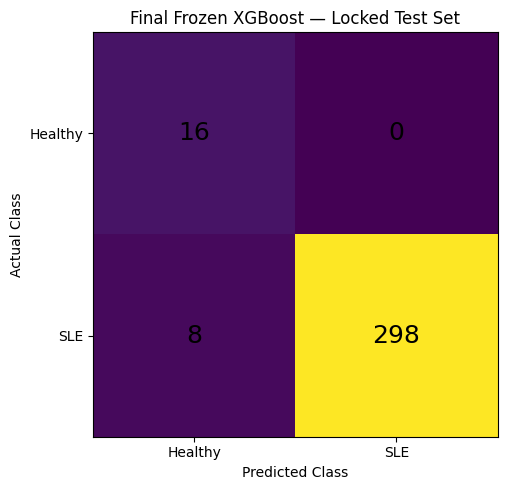


✓ Saved: final_locked_test_confusion_matrix.csv


In [58]:
# ============================================================
# FINAL FROZEN 13-GENE XGBOOST
# CONFUSION MATRIX FROM ARCHIVED FINAL RESULTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Archived final confusion-matrix values from the notebook
# ------------------------------------------------------------

TN = 16
FP = 0
FN = 8
TP = 298

FROZEN_THRESHOLD = 0.9554371237754822

# ------------------------------------------------------------
# Create confusion matrix
# ------------------------------------------------------------

cm = np.array([
    [TN, FP],
    [FN, TP]
])

print("=" * 80)
print("FINAL FROZEN 13-GENE XGBOOST")
print("LOCKED-TEST CONFUSION MATRIX")
print("=" * 80)

print("\nFrozen threshold:")
print(FROZEN_THRESHOLD)

print("\nTest samples:")
print(cm.sum())

print("\nConfusion Matrix:")
print(cm)

print("\nTN =", TN)
print("FP =", FP)
print("FN =", FN)
print("TP =", TP)


# ------------------------------------------------------------
# Create readable dataframe
# ------------------------------------------------------------

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Healthy",
        "Actual SLE"
    ],
    columns=[
        "Predicted Healthy",
        "Predicted SLE"
    ]
)

print("\nReadable confusion matrix:")
display(cm_df)


# ------------------------------------------------------------
# Verify counts
# ------------------------------------------------------------

assert cm.sum() == 322
assert TN + FP + FN + TP == 322

print("\n✓ 322 locked-test samples accounted for")
print("✓ Confusion matrix verified")
print("✓ Frozen threshold:", FROZEN_THRESHOLD)


# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6, 5)
)

im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Healthy",
    "SLE"
])

ax.set_yticklabels([
    "Healthy",
    "SLE"
])

ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "Actual Class"
)

ax.set_title(
    "Final Frozen XGBoost — Locked Test Set"
)

# Add numbers
for i in range(2):
    for j in range(2):

        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=18
        )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

cm_df.to_csv(
    "final_locked_test_confusion_matrix.csv"
)

print(
    "\n✓ Saved:"
    " final_locked_test_confusion_matrix.csv"
)

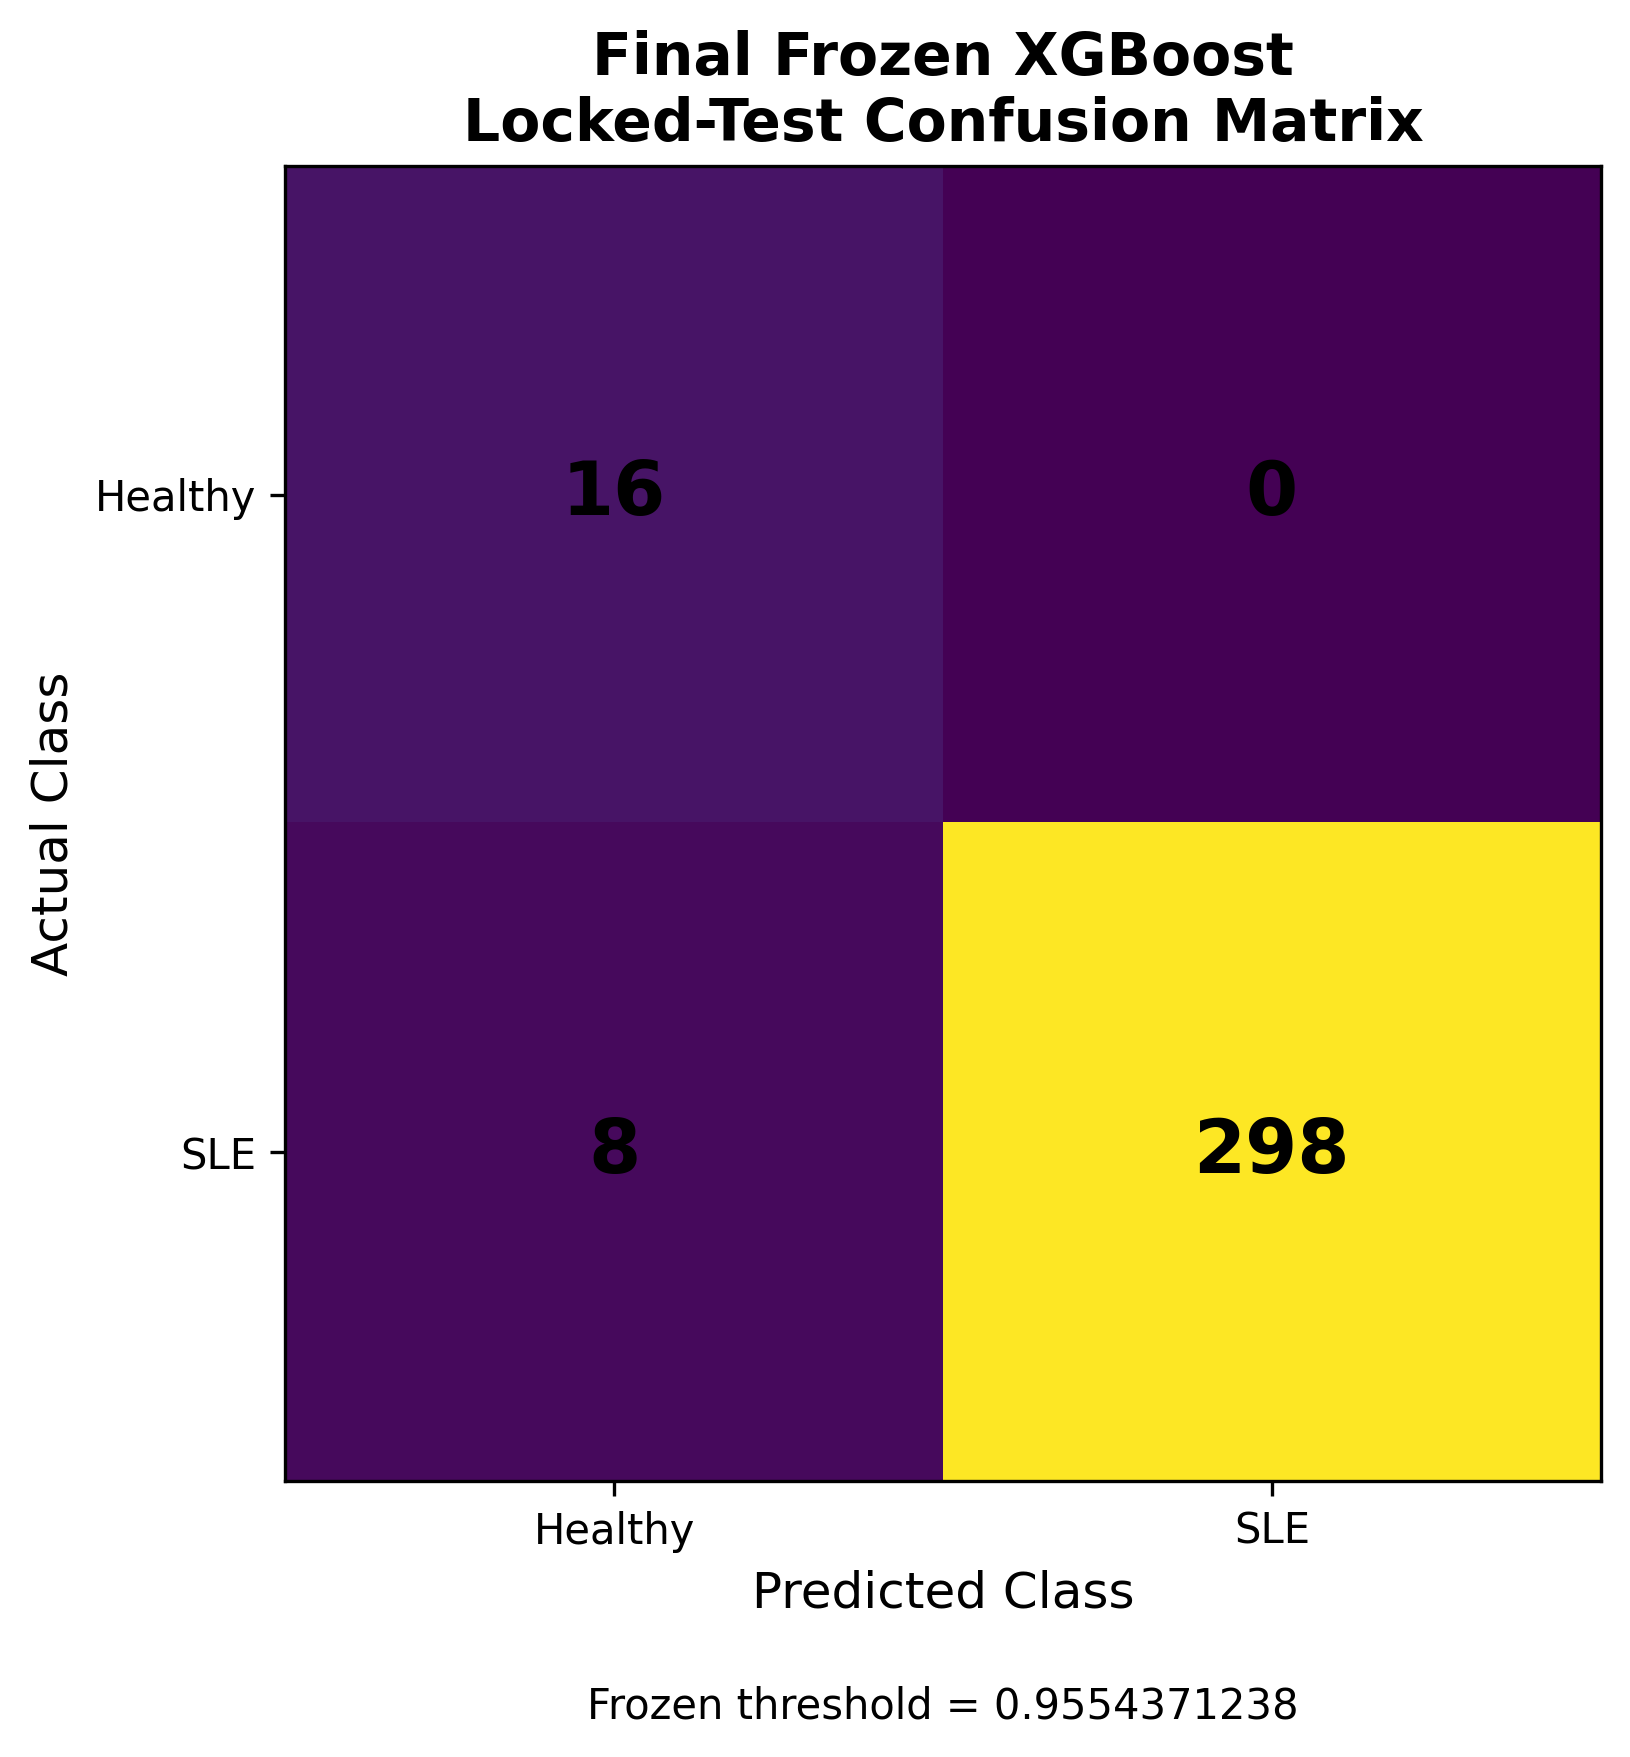

FILES SAVED TO GOOGLE DRIVE

CSV:
/content/drive/MyDrive/SLE_Final_Diagnostic_Model/Results/final_locked_test_confusion_matrix.csv

PNG:
/content/drive/MyDrive/SLE_Final_Diagnostic_Model/Results/final_locked_test_confusion_matrix.png

Confusion matrix:
[[ 16   0]
 [  8 298]]

TN = 16
FP = 0
FN = 8
TP = 298

Frozen threshold:
0.9554371237754822

✓ Saved successfully


In [59]:
# ============================================================
# SAVE FINAL CONFUSION MATRIX TO GOOGLE DRIVE
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Google Drive output folder
# ------------------------------------------------------------

DRIVE_DIR = (
    "/content/drive/MyDrive/"
    "SLE_Final_Diagnostic_Model/"
    "Results"
)

os.makedirs(
    DRIVE_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# Final frozen confusion matrix
# ------------------------------------------------------------

TN = 16
FP = 0
FN = 8
TP = 298

FROZEN_THRESHOLD = 0.9554371237754822

cm = np.array([
    [TN, FP],
    [FN, TP]
])


# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Healthy",
        "Actual SLE"
    ],
    columns=[
        "Predicted Healthy",
        "Predicted SLE"
    ]
)

csv_path = os.path.join(
    DRIVE_DIR,
    "final_locked_test_confusion_matrix.csv"
)

cm_df.to_csv(
    csv_path
)


# ------------------------------------------------------------
# Create high-resolution figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7, 6),
    dpi=300
)

im = ax.imshow(
    cm
)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Healthy",
    "SLE"
])

ax.set_yticklabels([
    "Healthy",
    "SLE"
])

ax.set_xlabel(
    "Predicted Class",
    fontsize=12
)

ax.set_ylabel(
    "Actual Class",
    fontsize=12
)

ax.set_title(
    "Final Frozen XGBoost\n"
    "Locked-Test Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)


# ------------------------------------------------------------
# Add cell values
# ------------------------------------------------------------

for i in range(2):

    for j in range(2):

        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold"
        )


# ------------------------------------------------------------
# Add threshold information
# ------------------------------------------------------------

ax.text(
    0.5,
    -0.18,
    f"Frozen threshold = {FROZEN_THRESHOLD:.10f}",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

plt.tight_layout()


# ------------------------------------------------------------
# Save PNG
# ------------------------------------------------------------

png_path = os.path.join(
    DRIVE_DIR,
    "final_locked_test_confusion_matrix.png"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# CONFIRMATION
# ============================================================

print("=" * 80)
print("FILES SAVED TO GOOGLE DRIVE")
print("=" * 80)

print("\nCSV:")
print(csv_path)

print("\nPNG:")
print(png_path)

print("\nConfusion matrix:")
print(cm)

print("\nTN =", TN)
print("FP =", FP)
print("FN =", FN)
print("TP =", TP)

print("\nFrozen threshold:")
print(FROZEN_THRESHOLD)

print("\n✓ Saved successfully")